# Social Media Engagement Analytics Using Python

**Assignment submission**

This notebook analyses the supplied 5,000-row social-media engagement dataset. It covers data import, cleaning, feature creation, Pandas exploration, statistical summaries, visualisation, and evidence-based insights.

**Tools used:** Python, NumPy, Pandas, Matplotlib, Seaborn, and Plotly.

> **Colab note:** Upload `social_media_engagement_5000_1787903760938.csv` to the Colab session before running all cells. The path-detection cell also works when the CSV is inside an `attached_assets` folder.

## 1. Data Import and Setup:

The file is imported with Pandas. Dates are converted from the dataset's `day-month-year` format, and NumPy is used for basic array calculations.

In [1]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from IPython.display import display
from io import StringIO

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 30)

csv_text = '''user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate
25795,43,Female,Brazil,496713,image,fitness,7011,354,1157,5726,44650,17-12-2022,81734,FALSE,mobile,negative,#foodie #travel #love,0.190862262
10860,33,Male,Brazil,157326,reel,food,11750,2606,1807,5947,80216,02-06-2023,5963,FALSE,mobile,negative,#fitness,0.201493468
86820,32,Female,UK,109864,text,food,4862,344,955,6946,44858,07-05-2023,501783,FALSE,tablet,positive,#foodie,0.137344509
64886,51,Other,France,848877,text,fitness,5350,1083,1049,229,70455,12-02-2023,480212,FALSE,mobile,negative,#music #foodie #fun,0.106195444
16265,34,Other,UK,449706,image,fitness,12682,2735,1300,4798,6019,23-05-2023,383936,FALSE,mobile,negative,#travel,2.777371656
92386,16,Other,Canada,174310,video,tech,12535,1790,99,1427,24893,16-09-2023,684761,FALSE,desktop,positive,#fitness,0.579440003
47194,25,Male,Japan,481598,video,travel,11703,2276,1465,6287,96327,15-04-2022,519759,TRUE,tablet,negative,#music,0.16032888
97498,57,Female,Canada,343415,image,travel,9611,146,424,1699,68446,20-12-2023,698739,FALSE,desktop,neutral,#travel #music #fitness,0.148744996
54131,54,Female,UK,907449,image,fashion,,2379,1897,5650,36283,06-07-2023,615809,TRUE,desktop,negative,#music #fun #fitness,0.533913954
70263,62,Female,Australia,495037,video,lifestyle,14106,2480,1053,3969,87972,16-11-2022,452146,FALSE,tablet,neutral,#lifestyle #love,0.200506979
26023,61,Male,France,674625,image,education,355,398,1668,6211,54685,15-02-2022,557276,FALSE,tablet,negative,#tech,0.044271738
51090,32,Male,Australia,538701,image,travel,19856,1723,905,3065,1816,29-08-2022,365517,FALSE,desktop,positive,#fun #fashion #love,12.38105727
77221,64,Male,Canada,183557,text,music,8432,2883,495,2145,89917,27-09-2022,413874,FALSE,desktop,positive,#fitness,0.13134335
74820,25,Male,Brazil,287460,text,fashion,15700,1434,1886,6,389,29-10-2023,51929,FALSE,desktop,positive,#foodie #lifestyle,48.89460154
10769,29,Other,Canada,110372,image,fashion,13850,586,650,6958,4797,20-09-2023,374227,FALSE,tablet,positive,#foodie #fashion,3.144882218
69735,48,Male,India,599900,image,food,17238,2646,997,4272,48199,06-02-2022,455102,FALSE,desktop,positive,#lifestyle #love,0.433224756
72955,45,Male,UAE,200050,reel,food,11935,1294,1214,1229,92955,24-07-2022,67694,FALSE,desktop,positive,#reels,0.155376257
74925,13,Male,Germany,980370,text,lifestyle,6704,2804,,4394,63141,01-05-2023,212134,FALSE,mobile,positive,#foodie #fun #lifestyle,0.181086774
77969,27,Female,India,433477,image,tech,15379,2393,1210,1823,66245,20-04-2022,63347,FALSE,mobile,positive,#love #fashion #fitness,0.286542381
15311,25,Female,UK,378427,reel,music,9252,1542,139,3984,2453,01-05-2023,337580,FALSE,mobile,negative,#foodie #travel #fitness,4.456991439
93104,29,Female,USA,140857,reel,fitness,8573,1804,319,2276,17019,14-11-2022,665397,FALSE,mobile,positive,#foodie #fitness,0.628474058
63707,36,Other,Australia,938204,reel,fitness,1132,2035,1914,2943,85311,15-08-2023,694794,FALSE,mobile,positive,#fun,0.059558556
95305,20,Other,Japan,815030,reel,lifestyle,18860,1427,1772,630,20241,17-03-2022,754110,FALSE,desktop,positive,#reels #fashion,1.089817697
38693,62,Male,India,828493,text,fashion,19519,737,368,269,74584,02-09-2023,353109,FALSE,desktop,neutral,#fashion,0.276520433
81932,39,Female,France,195856,reel,lifestyle,15534,1777,296,4176,72793,13-05-2023,499601,FALSE,tablet,negative,#fitness #love,0.241877653
35658,57,Other,Australia,524477,text,fitness,11030,379,1979,5791,3949,24-04-2023,281582,FALSE,tablet,neutral,#foodie #tech #fitness,3.390225374
94478,35,Female,India,812514,reel,fashion,2079,2468,1223,7355,40937,24-01-2023,143083,FALSE,tablet,positive,#reels,0.140948286
28431,58,Other,Brazil,892539,reel,fitness,944,1203,795,3771,86850,11-08-2023,519435,TRUE,desktop,positive,#love #music,0.033874496
12747,20,Other,Germany,322368,video,tech,5840,1661,1402,4915,44951,16-08-2023,728590,FALSE,mobile,neutral,#fashion,0.19806011
69150,20,Male,Canada,921993,text,food,6674,1306,1103,500,37198,30-12-2022,195211,FALSE,desktop,neutral,#fitness,0.244179795
75725,38,Male,Canada,307746,video,food,10721,2465,1470,6849,31133,05-11-2022,305030,FALSE,desktop,negative,#fashion,0.470754505
94654,59,Other,India,790628,video,fashion,12493,355,500,5606,35863,04-03-2022,637053,FALSE,tablet,positive,#love #foodie,0.372194183
45773,25,Male,UK,524824,reel,lifestyle,11510,15,258,7939,78960,24-09-2022,263286,FALSE,tablet,positive,#lifestyle,0.149227457
77435,51,Other,France,637426,text,fitness,834,314,1636,5607,12000,02-02-2022,304622,FALSE,tablet,positive,#fashion #fitness #reels,0.232
66886,49,Other,UK,530909,image,travel,4184,2580,1567,5085,23454,09-02-2022,378379,FALSE,tablet,negative,#reels #tech,0.355205935
76803,61,Female,Australia,880985,reel,tech,7178,1039,1812,5597,2314,17-11-2023,171217,FALSE,desktop,neutral,#tech #fitness,4.334053587
41551,,Male,UAE,838360,text,fitness,5168,1486,1144,2750,12440,17-09-2022,562099,FALSE,tablet,neutral,#music #lifestyle #love,0.626848875
21394,37,Male,Germany,748431,video,education,4991,2592,1078,1312,91421,24-09-2022,396345,FALSE,mobile,neutral,#lifestyle #fun #music,0.094737533
79092,28,Male,Germany,776608,text,travel,8146,693,1516,2153,16759,29-10-2023,780044,TRUE,desktop,negative,#fitness #tech,0.617876962
13890,14,Female,Canada,333829,reel,tech,13884,68,17,4736,14787,23-10-2023,42518,FALSE,mobile,positive,#reels #foodie #travel,0.944681139
51606,30,Female,Germany,905064,text,tech,5290,410,1332,608,6653,13-08-2022,274361,FALSE,desktop,positive,#tech,1.056966782
90038,29,,UK,147547,video,food,19918,2859,1903,3043,73974,18-01-2023,133257,FALSE,desktop,negative,#tech #fun #foodie,0.333630735
97313,42,Male,France,374244,text,fashion,14844,918,1656,5104,17335,13-05-2023,771262,FALSE,tablet,negative,#fun #reels,1.004788001
20627,51,Male,France,410074,text,fitness,18436,2894,109,5695,86543,01-10-2023,620110,FALSE,mobile,negative,#love #music #travel,0.247726564
18792,25,Male,Canada,307977,video,tech,8151,739,330,1663,74315,05-01-2022,117310,FALSE,desktop,positive,#foodie #music #love,0.124066474
83969,44,Female,India,939457,reel,fitness,28,1490,1596,3294,95708,22-03-2023,545643,FALSE,mobile,neutral,#fashion #foodie #love,0.032536465
53001,62,Female,France,569092,image,tech,18244,2486,945,5924,44243,15-10-2022,512624,FALSE,desktop,neutral,#tech #reels,0.489908008
86552,41,Other,UK,178944,video,lifestyle,7934,2577,1287,1997,74411,27-02-2022,570760,FALSE,desktop,neutral,#love,0.158551827
33897,,Female,USA,544056,video,music,2572,2777,267,2429,88819,13-03-2022,721632,FALSE,desktop,neutral,#tech #music #foodie,0.063229714
78148,42,Other,India,715929,reel,food,15281,272,434,6981,29387,29-10-2023,650505,FALSE,mobile,neutral,#love #music #fitness,0.544016062
33483,30,Male,UAE,721208,reel,fashion,8051,458,449,6022,69946,11-11-2023,107051,FALSE,desktop,positive,#fashion,0.128070226
58555,25,Female,Japan,666650,text,travel,2127,819,296,4199,80963,25-06-2023,640796,FALSE,mobile,negative,#music,0.040042983
27159,55,Male,Brazil,591592,video,travel,10083,1196,1941,2711,24240,23-03-2022,148086,FALSE,mobile,negative,#travel #fashion #reels,0.545379538
90077,33,Male,Germany,915042,text,lifestyle,19091,2615,1662,3185,94333,10-09-2023,745744,FALSE,tablet,negative,#foodie,0.24771819
45920,42,Male,Germany,990766,text,education,,860,1160,1531,30757,04-10-2022,143321,FALSE,mobile,neutral,#love #fitness,0.388626979
77121,33,Male,USA,776355,reel,food,15877,1973,1613,6083,59594,06-06-2023,279474,FALSE,desktop,positive,#fitness,0.326593281
79479,60,Female,India,369861,reel,tech,,1544,718,5174,14846,28-07-2023,133555,TRUE,desktop,positive,#foodie #lifestyle #reels,0.27448471
99475,29,Male,Canada,309939,text,food,12519,2544,1930,4216,71527,16-05-2022,728398,FALSE,desktop,negative,#music,0.237574622
29457,52,Other,UK,310544,video,fashion,7816,794,1020,7384,88214,24-04-2022,440120,FALSE,desktop,positive,#tech,0.109166345
76557,31,,USA,688310,video,music,8351,804,1420,3706,90167,06-06-2022,516878,FALSE,mobile,positive,#reels #music #tech,0.117282376
87189,64,Male,Brazil,284740,text,travel,15648,1095,183,3074,49594,31-01-2023,771562,FALSE,tablet,neutral,#music #fun,0.341291285
88953,27,Female,France,151645,image,fitness,11234,2981,411,7259,7845,17-08-2022,123386,FALSE,mobile,positive,#music,1.864372212
62995,21,Other,Canada,915982,image,travel,8496,1890,1624,4502,1523,04-09-2023,77112,FALSE,desktop,positive,#fitness #love #fun,7.885751806
50757,64,Male,Japan,579367,reel,education,12133,839,319,675,47405,12-09-2022,2189,FALSE,mobile,positive,#fashion #reels #music,0.280371269
19692,22,Other,Canada,665156,video,education,8591,2682,740,6584,12159,28-06-2022,159547,FALSE,tablet,positive,#fitness,0.987992434
55758,56,,USA,198039,text,education,11712,602,1599,1654,24821,17-08-2022,108929,FALSE,tablet,positive,#foodie,0.560533419
82409,43,Other,UAE,277452,text,education,6249,,1349,4527,79887,02-01-2023,774779,FALSE,tablet,negative,#travel #music,0.129946049
81211,,Male,USA,498944,video,fashion,15441,1432,1590,5004,95131,31-01-2022,244696,TRUE,tablet,positive,#lifestyle,0.194079743
75697,64,Female,USA,394944,reel,tech,6485,1833,804,4156,72283,18-04-2022,565611,TRUE,tablet,negative,#travel,0.126198415
47065,42,Male,USA,635174,reel,food,9177,366,416,6869,34779,09-10-2022,330379,FALSE,mobile,positive,#travel,0.286350959
42606,45,Female,Canada,572830,image,travel,1805,255,1816,3544,97995,13-09-2023,501651,FALSE,tablet,positive,#foodie,0.039553038
21534,64,Male,USA,300981,video,education,2096,2487,881,5366,63738,25-01-2023,578579,FALSE,tablet,neutral,#fashion,0.085725941
50397,21,Male,India,278308,video,travel,12493,1358,790,3818,28377,25-06-2023,39871,FALSE,desktop,positive,#music,0.515946013
11016,59,Other,Canada,670093,text,education,5337,2482,1723,7082,66975,13-06-2023,507330,FALSE,tablet,neutral,#love,0.142471071
99789,13,Other,France,918964,video,fitness,16035,689,1975,7012,14864,08-02-2023,305762,FALSE,mobile,neutral,#reels #fitness #tech,1.25800592
65591,56,Other,India,212765,image,food,17843,307,1726,3443,72082,19-06-2022,458375,FALSE,desktop,positive,#lifestyle #reels #fitness,0.275741517
99812,47,,Brazil,128688,video,fitness,9537,2035,1927,7456,16981,24-06-2022,428566,FALSE,mobile,neutral,#fun #fitness,0.794947294
33247,23,Male,France,385233,text,fitness,8422,1696,1808,5709,76776,15-03-2022,17089,FALSE,desktop,positive,#foodie,0.155335001
34300,46,Male,Japan,549158,image,education,3782,408,1630,1047,50042,30-03-2023,331448,FALSE,tablet,positive,#fun #fashion #lifestyle,0.116302306
84065,28,Female,Germany,657873,text,music,13798,825,89,2453,8301,24-05-2023,217024,FALSE,mobile,negative,#reels #travel,1.772316588
92798,21,Female,Canada,814364,video,tech,,1191,758,1331,24668,28-08-2022,445092,FALSE,desktop,positive,#foodie #travel #fun,0.88507378
19268,44,Male,Germany,350322,reel,travel,9074,2134,1464,4082,31430,06-04-2022,204102,FALSE,mobile,positive,#fashion #foodie #fitness,0.403181674
96807,27,Other,Canada,350483,video,music,6419,2050,,2660,2916,29-05-2023,204524,FALSE,desktop,positive,#fitness,3.280864198
22185,24,Other,France,102438,video,lifestyle,8624,2419,573,7539,33194,21-07-2022,561121,FALSE,tablet,negative,#reels #tech #fun,0.349942761
73704,45,Other,Japan,455239,text,food,7889,,1757,7930,93778,06-02-2022,677770,FALSE,mobile,neutral,#love,0.119399006
96779,57,Male,UK,516428,reel,music,10455,2689,1290,7802,82902,01-04-2022,573690,FALSE,mobile,positive,#fitness #foodie,0.174109189
49099,26,Other,UK,805722,video,tech,14432,97,962,2262,18155,21-08-2022,6661,FALSE,mobile,positive,#music #foodie,0.853263564
18571,20,Male,India,565393,image,lifestyle,11194,2717,935,4357,90949,21-10-2023,29155,FALSE,tablet,neutral,#music,0.16323434
48044,20,Female,USA,248055,image,tech,,1774,1959,7058,18658,10-09-2022,699433,FALSE,tablet,positive,#foodie,1.17558152
61214,39,Other,USA,900458,text,music,7570,1545,1656,7513,5335,06-01-2023,623717,FALSE,desktop,positive,#tech,2.018931584
71228,24,Female,UK,482312,text,education,617,320,1335,5532,99327,25-12-2023,378630,FALSE,mobile,negative,#reels #lifestyle,0.022873942
58984,13,Other,France,937430,reel,education,12684,533,,6266,16261,20-03-2023,427509,FALSE,desktop,positive,#fun,0.926203801
50774,55,Male,Japan,617951,text,tech,8509,2867,1876,763,53518,17-03-2023,367443,FALSE,desktop,positive,#tech,0.247617624
12568,52,,India,943445,reel,music,14717,2414,1506,2367,14647,05-03-2022,128255,FALSE,tablet,neutral,#travel #fun,1.272410733
72592,54,Male,France,151039,video,fashion,6285,1207,1051,3408,90132,05-01-2022,44423,FALSE,mobile,positive,#reels #love,0.094783207
77563,63,Male,USA,805191,image,fashion,456,416,1365,6301,31008,20-10-2023,472429,FALSE,tablet,neutral,#music #reels,0.072142673
12695,23,Other,India,578388,image,tech,500,2776,425,7494,46669,13-03-2022,684217,TRUE,mobile,neutral,#fitness,0.079303178
58190,51,Female,Germany,789963,image,fashion,18699,1237,882,1684,97288,01-02-2023,765052,FALSE,desktop,positive,#fitness #travel,0.213983225
15258,55,Male,Australia,730734,text,food,3874,847,1837,5184,54359,09-09-2023,498,FALSE,tablet,negative,#music #travel #fashion,0.120642396
97538,43,Other,Brazil,984884,text,travel,4973,669,785,4464,56121,26-11-2022,655478,FALSE,tablet,neutral,#travel,0.114520411
49504,29,Female,India,506321,video,lifestyle,4774,1943,534,869,74981,02-07-2023,351210,TRUE,mobile,negative,#reels #music #tech,0.096704498
43159,45,Male,USA,331120,text,education,15519,2180,1433,5123,2170,27-05-2022,791390,FALSE,desktop,neutral,#music,8.816589862
23986,,Female,France,429326,reel,food,14349,2100,1634,2733,89366,19-02-2023,793851,FALSE,tablet,positive,#tech,0.202347649
71858,41,Male,Germany,676435,image,travel,17387,740,284,7815,72180,15-12-2022,373800,FALSE,desktop,neutral,#lifestyle,0.255070657
22666,33,Female,Brazil,876691,video,fashion,17450,2742,1843,913,33788,31-12-2022,509144,FALSE,tablet,positive,#fitness,0.652154611
48660,33,Female,Brazil,699688,reel,lifestyle,13622,22,621,5875,46711,20-02-2023,558846,FALSE,tablet,neutral,#foodie #fitness,0.305388452
13561,52,Male,India,670722,reel,food,4716,1654,1738,3131,22956,17-09-2023,749254,FALSE,tablet,negative,#lifestyle #travel #foodie,0.353197421
36854,35,Other,Brazil,126515,text,fitness,9820,459,1129,7212,47674,22-05-2023,550933,FALSE,desktop,positive,#lifestyle #music,0.239291857
74505,18,Female,Germany,320370,text,education,16087,649,503,6727,17927,07-06-2023,380074,FALSE,desktop,positive,#love #fitness,0.961622134
62251,34,Male,Japan,682289,image,tech,13302,481,45,1630,12799,07-12-2023,167782,FALSE,desktop,positive,#fashion #fitness #love,1.080396906
32662,62,Female,France,813757,video,education,3234,119,1792,542,83795,07-09-2022,210910,FALSE,desktop,negative,#tech #love,0.061399845
18392,50,Female,India,816775,reel,travel,6494,672,1470,2203,73856,06-09-2022,254098,FALSE,desktop,positive,#fashion #foodie,0.116930243
40535,49,Other,Brazil,471735,text,travel,14239,2255,1167,2935,18776,17-12-2022,569770,FALSE,desktop,neutral,#reels,0.94061568
88603,57,Female,Japan,324215,text,fitness,4498,1884,536,751,3803,26-09-2022,321052,FALSE,desktop,positive,#lifestyle #foodie #music,1.819090192
62256,63,,France,932210,video,fitness,11430,317,61,2111,97293,24-03-2023,104397,FALSE,mobile,positive,#fitness #music #love,0.12136536
99135,20,Male,Canada,786301,video,tech,5267,2385,1765,420,33693,24-03-2022,574566,FALSE,desktop,negative,#fashion,0.279494257
45222,53,Male,Japan,590073,text,fashion,12546,2202,1105,2370,81647,25-06-2023,617502,FALSE,desktop,neutral,#fitness,0.194165125
87373,61,Other,Canada,720137,text,education,3669,867,335,7276,95391,11-02-2023,162172,FALSE,mobile,positive,#love #tech,0.051063518
89575,47,Female,Canada,989515,image,food,9657,393,210,1486,24814,05-12-2022,778649,FALSE,mobile,positive,#music #love,0.413476263
94651,63,Female,Japan,534171,video,music,,2552,399,5699,86472,21-03-2022,100750,FALSE,desktop,positive,#music #travel #love,0.056804515
73335,23,Female,Brazil,309637,reel,music,13940,,708,546,83182,05-04-2022,98477,FALSE,desktop,neutral,#foodie #tech #love,0.187756967
20965,36,Other,Canada,987708,text,food,17259,312,346,6394,35401,16-09-2022,406187,FALSE,desktop,negative,#foodie,0.506115646
34538,61,Female,Brazil,419052,text,food,12093,1282,1221,4961,38480,02-05-2022,454904,FALSE,mobile,positive,#music #tech #love,0.379313929
80592,33,Male,Brazil,557283,text,fashion,8734,2061,376,2557,9651,04-05-2022,205678,FALSE,tablet,neutral,#lifestyle #fitness,1.157496632
18110,63,Other,France,349708,text,education,3516,76,1185,1571,95942,19-06-2023,615884,FALSE,tablet,positive,#fashion #fitness #love,0.049790498
89309,14,Male,UAE,548912,image,education,15032,408,1231,6584,18709,29-12-2023,504976,TRUE,tablet,neutral,#reels #love #travel,0.89106847
37266,52,Male,Germany,980480,video,music,7233,2441,820,453,92772,16-10-2022,297039,FALSE,tablet,positive,#fun,0.113116026
62992,31,Other,Brazil,307748,text,tech,13170,2267,,2691,69308,07-04-2023,124045,FALSE,tablet,positive,#travel #lifestyle,0.235975645
92948,51,Male,France,347387,video,food,5947,743,1450,6960,2260,02-04-2022,494656,FALSE,desktop,positive,#tech #love,3.601769912
16910,40,Female,Australia,770207,reel,travel,16958,432,43,1757,57726,24-01-2022,289472,FALSE,tablet,neutral,#reels,0.301995635
10206,29,Other,Canada,802551,reel,travel,17842,2853,799,4774,91351,17-04-2022,547686,FALSE,desktop,positive,#fun #music #travel,0.235290254
97054,18,Male,India,920688,reel,travel,,1478,1514,4369,1897,21-02-2022,387581,FALSE,mobile,positive,#foodie,5.475487612
97897,31,Female,Brazil,521990,reel,fitness,3172,1677,1302,59,94348,12-12-2023,231170,FALSE,mobile,positive,#tech #music #travel,0.065194811
33419,,Female,Japan,751631,video,fitness,18854,1831,1939,4437,11271,21-10-2022,57719,FALSE,tablet,negative,#lifestyle #music,2.007275308
60636,40,Male,Canada,633415,reel,fashion,3427,987,786,1417,91402,27-10-2022,529310,FALSE,mobile,positive,#fun,0.056891534
60015,14,Female,Canada,218251,reel,food,7798,1521,732,2160,48058,11-12-2022,16065,FALSE,desktop,neutral,#travel,0.209143119
64268,50,Other,Australia,783565,text,fitness,,2701,967,7388,99648,17-01-2023,490632,FALSE,tablet,positive,#fashion #travel,0.114442839
97939,49,Male,India,863570,text,travel,15490,2864,1820,5910,23553,22-07-2023,720114,FALSE,tablet,positive,#fitness #lifestyle,0.856536322
28141,63,Female,France,593322,text,fitness,10707,1553,1169,6211,73529,13-07-2022,80606,FALSE,desktop,positive,#foodie #fashion #fun,0.182635423
90356,64,Female,Australia,967595,image,education,11743,754,1092,1338,20892,11-07-2023,721208,FALSE,desktop,negative,#tech #fitness #lifestyle,0.65044036
81910,16,Male,Germany,289836,text,travel,4206,675,651,466,2030,12-03-2023,306654,FALSE,desktop,neutral,#fun,2.725123153
66044,34,Male,Canada,726112,reel,food,18584,831,521,7001,15805,20-01-2023,146264,FALSE,tablet,positive,#tech,1.261372983
77214,38,Male,Brazil,662952,video,education,19348,1119,110,2310,84538,07-01-2023,62873,FALSE,mobile,neutral,#fashion #fun #fitness,0.243405333
43827,61,Male,Brazil,156795,reel,fashion,3313,27,1572,7948,62694,16-11-2022,303713,FALSE,mobile,neutral,#tech #foodie,0.078348805
65820,55,Other,Australia,221729,video,tech,15055,1253,1616,7298,147,27-08-2022,219353,FALSE,mobile,neutral,#travel #reels,121.9319728
72623,48,Male,Germany,787693,reel,tech,19311,415,607,2471,233,27-01-2023,190168,FALSE,mobile,positive,#fitness,87.26609442
91734,25,Other,UK,344620,image,education,8873,2072,1078,7434,47722,10-10-2023,149994,FALSE,tablet,neutral,#fashion #love,0.251938309
85450,64,Other,USA,136079,text,travel,4458,1710,1667,719,87695,12-10-2022,45699,FALSE,desktop,neutral,#fitness,0.089343748
32299,44,Male,Japan,184225,reel,fitness,18032,2720,1246,1235,11338,13-01-2022,54896,FALSE,mobile,negative,#fitness,1.940201094
53585,29,Other,Japan,648547,text,fitness,9350,541,895,562,35232,20-01-2023,307477,FALSE,tablet,positive,#fashion #love,0.306142144
74044,53,,UK,388715,image,travel,8184,164,1598,982,28182,25-06-2023,88041,FALSE,tablet,positive,#love,0.352920304
52557,48,Male,Canada,151119,image,music,15865,2255,523,2966,56405,21-11-2023,16647,FALSE,mobile,neutral,#music #fun,0.330520344
59080,58,,France,370153,text,food,2341,2996,145,2335,53346,20-10-2022,730803,FALSE,desktop,positive,#music #fashion #travel,0.102763094
12693,31,Male,India,210210,text,education,17902,984,263,4520,51789,14-09-2022,449441,FALSE,desktop,positive,#love,0.369750333
79163,47,Female,UK,603747,video,travel,1838,2661,1567,4649,40864,18-04-2022,179403,TRUE,tablet,positive,#lifestyle,0.148443618
35939,58,Other,Germany,423973,text,music,17254,372,467,4854,22468,04-08-2023,518801,TRUE,desktop,positive,#travel #foodie,0.805278618
58925,52,Female,Brazil,400374,text,food,5538,,1584,1730,35339,19-11-2023,200136,FALSE,tablet,negative,#fun #fashion #music,0.21899318
52941,40,Other,USA,211364,video,fashion,11469,68,871,4339,68070,02-07-2022,782105,FALSE,desktop,neutral,#lifestyle #music,0.182282944
31834,13,Male,Canada,418193,reel,fashion,9533,1543,958,7879,69971,07-12-2023,428831,FALSE,mobile,positive,#fun,0.171985537
28047,54,Other,USA,463906,video,education,5477,,1996,7800,81659,02-01-2023,111108,FALSE,desktop,neutral,#fitness #love #travel,0.111818661
36105,30,Other,India,485417,reel,travel,9363,100,1210,3047,85542,18-06-2023,690569,FALSE,mobile,negative,#fun #travel #fitness,0.124769119
85766,60,Male,Brazil,481610,reel,fashion,12264,0,1366,1357,84325,07-06-2023,125301,FALSE,mobile,neutral,#fun #foodie,0.161636525
25707,52,Other,Germany,791858,reel,fitness,13536,2398,1986,2375,87307,12-10-2022,152871,FALSE,tablet,negative,#fashion #lifestyle #foodie,0.205252729
31976,45,Male,Japan,743341,video,food,17512,2054,1122,2762,92022,16-09-2022,238701,FALSE,mobile,positive,#love #music #lifestyle,0.224815805
54262,24,,India,533531,video,tech,11819,317,678,5225,46370,22-06-2022,654879,FALSE,tablet,neutral,#fun #fashion #lifestyle,0.276342463
33776,20,Male,UK,981450,image,music,12191,2670,1329,1785,87701,18-12-2023,209807,FALSE,mobile,neutral,#love #music #tech,0.184604509
40080,36,Male,Japan,919227,reel,tech,6499,1878,1748,6006,73079,26-11-2022,682711,FALSE,mobile,positive,#fun,0.138548694
76842,28,Other,Japan,738100,video,fashion,12079,2556,1222,1962,44114,28-03-2023,100304,TRUE,mobile,negative,#fun #tech #love,0.359455048
71373,62,Female,Germany,709699,image,music,17668,185,757,6944,64980,16-04-2023,153008,FALSE,desktop,positive,#music #travel,0.286395814
16776,16,Male,UK,401335,reel,food,8762,727,1177,7246,15765,22-03-2022,384358,FALSE,desktop,neutral,#love #fitness,0.676562004
65016,50,Female,Australia,285525,video,fitness,19248,2509,918,1188,40642,17-11-2022,135793,FALSE,mobile,positive,#lifestyle #fashion,0.557920378
19474,56,Female,India,112453,video,tech,6045,342,1119,5965,86869,17-03-2023,790635,FALSE,tablet,,#reels #lifestyle,0.086405968
68053,39,Other,France,220848,video,fitness,12176,2682,574,2678,37068,03-02-2023,651107,FALSE,mobile,positive,#fitness #music #reels,0.41631596
31959,21,Male,UAE,543541,text,fitness,11333,712,705,6105,23581,07-07-2022,182385,FALSE,tablet,,#tech #foodie #love,0.540689538
15530,59,Other,Brazil,674281,image,tech,18361,2623,1958,5176,70658,14-03-2023,247982,FALSE,mobile,positive,#lifestyle #fashion #foodie,0.324690764
13748,28,Male,Germany,472924,video,tech,8638,135,833,5055,52744,24-03-2023,714862,FALSE,mobile,positive,#love,0.182124981
23545,24,Female,Brazil,145706,text,music,13070,1922,1382,3007,47054,15-04-2023,336301,FALSE,tablet,positive,#fitness,0.347983168
76199,43,Male,India,623324,image,fashion,5039,382,813,5307,9245,24-06-2023,701443,FALSE,tablet,positive,#travel,0.674310438
44766,36,Male,UK,608197,image,music,15265,185,398,3123,50594,06-04-2023,795835,FALSE,desktop,neutral,#fitness,0.313238724
83530,26,Female,France,273889,text,education,2973,2686,1807,3143,60935,30-05-2023,458867,TRUE,tablet,positive,#lifestyle #foodie,0.122524001
71087,57,Female,UAE,715722,image,food,4626,927,1399,2800,65606,25-08-2022,54500,FALSE,mobile,positive,#fun #fitness,0.105965918
78840,37,Male,USA,811070,text,travel,16502,963,601,323,43164,30-06-2022,407567,FALSE,tablet,positive,#fun #reels #lifestyle,0.41854323
64384,46,Other,France,675087,reel,food,7999,560,327,3683,23054,14-02-2023,403274,FALSE,desktop,positive,#tech,0.385442873
61005,15,Male,Germany,743874,video,music,2292,1189,1295,7505,96972,31-05-2023,791772,FALSE,mobile,neutral,#travel #foodie #fun,0.04925133
56576,36,Female,Brazil,160964,text,travel,18488,897,1620,2202,39151,13-03-2022,293668,FALSE,mobile,positive,#tech,0.536512477
49353,54,Other,France,546894,image,music,17451,2686,1318,6202,92321,01-07-2022,590505,FALSE,mobile,positive,#music #reels #travel,0.232395663
72003,21,Female,Canada,302222,image,tech,14859,1928,394,7442,86267,14-04-2022,320905,FALSE,tablet,,#fitness #foodie #reels,0.199160745
93211,38,Female,UK,459523,reel,fitness,16807,1837,1495,1794,6674,29-09-2022,290545,FALSE,mobile,neutral,#reels,3.017530716
62733,32,Other,UK,815798,reel,food,3819,2368,547,2248,32481,14-10-2022,167148,FALSE,mobile,positive,#music #lifestyle #fashion,0.207321203
75318,52,Female,Canada,734275,reel,music,12682,1712,1041,2342,26139,28-03-2022,105455,TRUE,tablet,positive,#lifestyle #music,0.590496959
99474,22,Female,Japan,948358,reel,fitness,14785,1738,918,3393,5431,21-01-2023,367931,FALSE,mobile,neutral,#music #reels,3.21137912
33664,31,Female,Japan,628089,reel,food,1280,1180,76,3400,30512,14-03-2022,729329,FALSE,tablet,negative,#reels,0.08311484
77172,15,Female,India,534264,video,education,13241,857,1072,1975,83957,26-08-2023,281581,FALSE,tablet,negative,#love #fitness,0.180687733
95616,36,Female,Australia,926576,text,lifestyle,10011,284,1521,5509,90393,16-11-2023,429579,FALSE,desktop,neutral,#love #music #reels,0.130718087
36736,17,Female,USA,980910,reel,food,14147,2398,1449,3045,17558,06-11-2022,242057,FALSE,mobile,negative,#fitness #love #reels,1.024831985
10854,15,,Canada,765508,reel,fitness,19816,2130,,1307,14158,30-11-2023,524357,FALSE,tablet,positive,#love,1.683853652
48623,39,Female,India,212364,video,lifestyle,17146,1647,1771,7343,35441,19-03-2023,715160,FALSE,desktop,positive,#love,0.580231935
17392,28,Female,Brazil,969251,text,fashion,1629,665,1579,6753,35265,24-08-2022,762338,FALSE,tablet,negative,#fashion #music,0.109825606
65680,61,Male,Canada,775221,reel,education,5499,1393,1017,6492,58525,05-11-2023,248468,TRUE,mobile,positive,#tech,0.13513883
56717,27,Male,Australia,554933,text,tech,8634,2588,1644,1455,518,08-08-2023,461336,FALSE,desktop,positive,#fitness,24.83783784
97092,47,Female,Canada,253552,text,fashion,3014,2024,128,962,82659,18-08-2022,356268,FALSE,tablet,negative,#tech #fitness,0.062497732
60859,24,Male,Australia,118637,video,music,10773,2527,518,1717,51336,11-09-2022,659835,FALSE,desktop,negative,#fun,0.269167835
36309,53,Other,Australia,931053,video,fashion,17881,2260,303,2429,37457,05-11-2023,345804,FALSE,mobile,positive,#fashion #music,0.545799183
97455,56,Male,Australia,553520,reel,food,8280,929,1135,5391,82378,21-12-2022,236900,FALSE,tablet,neutral,#fun #travel,0.125567506
73734,38,Female,UK,671719,image,tech,8653,2407,724,2539,83823,10-05-2023,205184,FALSE,mobile,,#fun,0.140581941
80467,59,Female,France,724225,video,education,19936,213,911,3618,38072,14-02-2023,723499,FALSE,tablet,positive,#lifestyle #travel,0.553162429
62662,,,UK,418316,text,lifestyle,11820,,815,2378,40757,18-07-2022,84480,FALSE,desktop,positive,#fun #reels #travel,0.317442403
22688,35,Female,India,125437,text,food,7637,1403,973,874,49790,05-03-2023,366550,FALSE,mobile,neutral,#love #fun,0.201104639
35342,43,Other,UK,501365,reel,music,13390,199,1962,3670,70075,20-04-2023,433172,FALSE,desktop,positive,#music #lifestyle,0.221919372
47157,62,Other,UK,507887,reel,travel,,2285,818,2205,56140,11-08-2023,403508,FALSE,tablet,negative,#fitness #reels #lifestyle,0.400249377
77863,32,Female,Brazil,596221,reel,food,16155,670,362,4527,26894,08-12-2022,276469,FALSE,tablet,negative,#fun #reels,0.639064475
62083,24,Other,Canada,123119,text,lifestyle,3060,1728,1089,7492,10005,19-04-2023,59616,FALSE,mobile,neutral,#fun,0.587406297
75733,35,Other,UK,801477,video,fitness,13697,1249,1054,1139,66501,01-02-2023,247681,FALSE,mobile,positive,#fun #tech,0.240597886
99045,16,Male,UAE,330389,image,music,15313,878,1318,3591,92279,02-03-2023,509558,FALSE,tablet,positive,#tech #music,0.189739811
44698,35,,Australia,509495,video,education,7510,250,1800,4714,27026,14-02-2022,468550,FALSE,desktop,positive,#fun,0.353733442
90623,60,Male,Canada,955267,image,education,2950,2523,808,4714,46152,09-12-2022,564249,FALSE,tablet,positive,#lifestyle #travel #foodie,0.136093777
32671,60,Female,Japan,330882,video,food,14387,497,1342,2673,44328,22-11-2023,272551,FALSE,desktop,positive,#fun #tech #reels,0.366044035
35184,13,Male,Brazil,357157,reel,travel,6063,1987,1037,4530,31146,17-01-2022,549702,FALSE,mobile,positive,#travel,0.291754961
52107,37,Female,France,576113,text,food,14205,977,569,1545,4771,07-08-2022,782591,FALSE,desktop,positive,#fun #fashion,3.301404318
96202,14,Female,Brazil,685093,image,music,11922,2748,969,2843,61071,19-08-2023,245494,FALSE,tablet,positive,#reels,0.25607899
61663,42,Female,Australia,118201,video,lifestyle,7661,783,1879,5027,50287,10-07-2022,335100,FALSE,desktop,neutral,#fashion #fun,0.205281683
25708,15,Female,Canada,357636,text,education,3421,2476,1265,4667,24971,26-01-2023,478292,FALSE,mobile,positive,#fun #love,0.286812703
59811,33,Female,France,128634,image,travel,1990,538,352,265,67062,15-03-2023,751695,FALSE,desktop,positive,#reels,0.042945334
12811,37,Male,USA,504042,image,tech,13057,900,1271,7565,93721,06-10-2023,642015,TRUE,tablet,neutral,#music,0.162482261
66250,32,Female,Germany,448965,text,lifestyle,1482,1466,609,101,93028,12-05-2023,43239,TRUE,tablet,negative,#fashion,0.0382358
82082,61,Other,Brazil,605341,reel,education,2545,209,467,7230,64240,04-04-2022,659713,FALSE,desktop,neutral,#foodie,0.0501401
44754,64,Other,France,407919,text,food,,1733,1983,7140,76693,05-04-2022,503474,FALSE,tablet,negative,#travel #lifestyle #fitness,0.103477501
21411,34,Female,India,488690,reel,education,12491,490,923,7854,33560,27-11-2023,48616,FALSE,mobile,negative,#travel,0.414302741
12911,33,Other,France,214090,video,travel,642,2518,387,2756,29271,06-10-2023,706951,FALSE,desktop,positive,#tech #fitness #lifestyle,0.121177958
77270,45,Male,Germany,698964,video,music,13332,1709,1697,7158,56845,23-03-2022,558718,FALSE,desktop,positive,#foodie #fitness,0.29444982
93763,64,Male,Australia,106798,text,lifestyle,1586,1753,1923,6967,81872,06-12-2022,586155,FALSE,desktop,positive,#love #fashion,0.064271057
18680,50,Female,Canada,608377,reel,tech,18793,2615,758,3973,33935,26-12-2022,356812,TRUE,tablet,positive,#lifestyle,0.653189922
94896,27,Female,USA,559319,video,fitness,6504,1918,1861,1534,66768,22-04-2022,635312,FALSE,desktop,positive,#foodie #tech #love,0.154010903
93879,58,Female,India,701448,reel,fashion,16438,,441,2269,58565,30-10-2022,482818,FALSE,desktop,neutral,#lifestyle,0.322940323
81295,64,,France,177751,reel,travel,14627,2711,1365,2962,7712,20-02-2022,134586,FALSE,desktop,neutral,#love,2.425181535
98614,27,Other,UAE,282482,reel,fitness,17225,1929,515,2483,97460,02-12-2023,285558,FALSE,desktop,neutral,#fun #lifestyle #fitness,0.20181613
21111,,Male,UK,403032,text,tech,6928,1486,,1213,9533,21-12-2023,795848,FALSE,mobile,positive,#lifestyle,1.075736914
47504,37,Other,Australia,411191,reel,fitness,4587,2597,1796,4735,96504,23-10-2023,784802,FALSE,tablet,positive,#fitness #foodie #love,0.093053138
11802,33,Male,Brazil,471784,text,food,19290,2003,842,2992,1046,08-10-2022,545948,TRUE,mobile,negative,#lifestyle #foodie #travel,21.16156788
18155,36,Other,Brazil,464758,video,fashion,10186,1500,44,4429,44207,23-04-2022,709820,FALSE,desktop,neutral,#music #fun,0.265342593
83656,17,Male,Germany,145955,video,travel,10124,197,1442,906,1715,05-02-2022,530553,FALSE,tablet,positive,#fashion #foodie #lifestyle,6.858892128
49384,18,Female,Australia,343465,image,lifestyle,5056,1967,722,1581,78487,15-09-2023,363168,FALSE,desktop,positive,#fun,0.098678762
57254,61,Other,India,789224,image,education,5982,520,755,1604,73890,14-11-2023,420394,FALSE,mobile,positive,#foodie #fun,0.098213561
31918,55,Male,Japan,572334,video,tech,2272,1522,202,7468,87735,19-03-2022,612115,FALSE,desktop,positive,#reels #tech,0.045546247
95981,60,Other,USA,709778,reel,fashion,6141,1534,1738,6494,55321,24-06-2023,408551,FALSE,mobile,negative,#tech #music,0.170152383
70713,56,Female,India,401409,reel,tech,9161,1713,1908,5995,33261,14-02-2022,772251,FALSE,mobile,positive,#love #music #reels,0.384293918
40306,59,Male,USA,670601,video,education,1071,1348,538,569,32698,31-10-2022,663078,FALSE,tablet,positive,#fun #love,0.090433666
26646,35,Other,Canada,144350,video,fitness,17120,687,385,6871,91738,27-01-2023,301264,FALSE,desktop,negative,#fitness #foodie,0.198303865
56843,,Other,Canada,246450,image,tech,6376,466,1973,6258,89554,16-10-2023,300231,FALSE,desktop,negative,#reels #fitness,0.098432231
26371,39,Female,Australia,995600,reel,music,3630,595,629,1545,75329,15-01-2022,86079,FALSE,desktop,neutral,#lifestyle #fun,0.064437335
87371,30,Female,Australia,349406,video,tech,227,138,967,908,80790,02-10-2023,461868,FALSE,tablet,positive,#travel #reels,0.016487189
12049,33,,Brazil,872467,image,fitness,15342,1014,737,4462,488,16-06-2022,798384,FALSE,mobile,positive,#tech #reels,35.02663934
41616,40,Other,UK,300887,image,fitness,6665,241,359,4083,49839,27-10-2023,64899,FALSE,tablet,neutral,#fashion,0.145769377
30932,47,Other,Germany,914356,reel,education,14008,2363,1491,3340,79537,04-03-2022,63748,FALSE,tablet,neutral,#fashion #love,0.224574726
39855,34,Female,UK,969025,image,fashion,19954,2714,982,6947,29407,25-07-2023,194936,FALSE,mobile,negative,#love #music #travel,0.804230285
71434,52,Female,India,107312,image,travel,7993,732,1998,7253,73305,22-07-2022,598923,FALSE,desktop,neutral,#fitness #foodie #lifestyle,0.146279244
82694,35,Male,Brazil,916785,text,fitness,14675,134,1967,7039,57723,06-06-2022,798474,FALSE,mobile,,#fun #reels #fitness,0.290629385
53016,15,Other,USA,213744,video,music,1619,2626,204,7112,88728,30-05-2023,471555,FALSE,mobile,neutral,#reels #lifestyle #music,0.050142007
17400,52,Other,Japan,331745,reel,fashion,12885,2486,1270,2425,97560,05-07-2023,391133,FALSE,mobile,negative,#foodie,0.170571956
52642,62,Male,France,317522,video,education,2204,2124,990,3218,60916,05-10-2022,351360,FALSE,desktop,negative,#fitness #fun,0.087300545
25151,22,Male,UAE,378336,text,tech,19087,2447,,7155,92196,11-04-2022,433806,FALSE,mobile,negative,#fitness #love #fashion,0.245195019
61407,37,Female,Canada,772810,reel,music,7742,2421,365,2165,64985,18-06-2022,455451,FALSE,tablet,negative,#music #lifestyle,0.162006617
76690,64,Female,UK,760792,video,tech,11694,1510,252,1013,92493,16-06-2023,669922,FALSE,mobile,negative,#fun #music,0.14548128
14499,61,Male,Germany,288297,image,lifestyle,11818,1818,,3206,45341,07-02-2023,431920,FALSE,mobile,positive,#fashion #reels,0.302441499
16295,20,Male,Japan,982980,reel,food,7574,,768,6670,52237,21-05-2022,681842,FALSE,tablet,negative,#love #lifestyle,0.174186879
69040,23,Other,Japan,198991,text,fitness,9373,2796,631,1872,21114,13-12-2022,405685,FALSE,desktop,neutral,#foodie,0.606232831
22183,17,Male,Canada,178711,image,education,11448,2811,986,4909,34298,12-07-2022,435002,FALSE,tablet,positive,#fitness #fashion #foodie,0.444486559
39299,57,Male,UAE,820964,text,music,17181,416,416,205,14409,01-06-2022,343381,FALSE,desktop,neutral,#music #tech #fitness,1.250121452
22874,49,Other,Australia,765655,image,music,19383,206,1058,7400,30025,21-01-2023,552676,FALSE,desktop,neutral,#reels,0.687660283
42711,57,Male,Japan,106774,video,fashion,2764,2388,1461,815,16276,27-07-2022,23979,FALSE,desktop,positive,#lifestyle #music,0.40630376
15539,50,Female,India,739395,video,lifestyle,10601,1643,311,65,87011,03-07-2023,471433,FALSE,desktop,negative,#love #foodie #fitness,0.144292101
63351,41,Female,India,767550,video,fashion,11467,2768,1166,4045,70703,23-01-2023,314794,FALSE,tablet,positive,#fitness #fashion,0.217826683
71267,17,Other,Australia,524502,text,travel,8199,310,196,2051,97779,19-03-2022,358934,FALSE,desktop,positive,#love,0.089027296
58354,21,Male,USA,831685,reel,lifestyle,10411,1331,996,2,18522,21-06-2022,695491,TRUE,tablet,negative,#music,0.687722708
12557,60,Female,Brazil,328552,video,education,6239,2672,259,7426,20617,11-07-2023,755269,FALSE,mobile,,#love,0.444778581
48360,14,Female,Australia,696715,text,fashion,14943,1399,1389,5834,54603,03-12-2022,311923,FALSE,tablet,positive,#travel,0.324725748
92018,13,Female,UAE,187513,image,fitness,13617,1550,595,324,28614,19-08-2023,225674,FALSE,mobile,neutral,#love #tech #reels,0.550849235
12200,52,Female,India,426158,video,fashion,,82,1215,5359,2315,07-03-2023,562622,TRUE,tablet,negative,#travel,1.998272138
78497,63,,Japan,851247,image,food,11563,1600,1510,6134,85376,28-08-2023,576012,TRUE,mobile,negative,#love #reels #music,0.171863287
56975,,Male,India,306924,video,tech,5584,1475,533,604,16586,04-05-2023,324158,FALSE,tablet,positive,#fashion #tech,0.45773544
31357,23,Male,France,941688,image,tech,8805,1026,23,4891,90356,28-10-2023,562799,FALSE,tablet,neutral,#love,0.109057506
87505,40,Male,Brazil,883837,text,music,9089,1479,942,2582,74582,16-04-2022,735181,FALSE,tablet,positive,#foodie #lifestyle,0.154326781
12869,56,Female,Germany,873940,video,lifestyle,,2920,1098,5917,12349,28-07-2022,65631,FALSE,tablet,neutral,#reels #foodie,1.429832375
71135,,Other,France,723031,text,fashion,15488,2283,1901,7485,23287,17-12-2023,272320,FALSE,mobile,negative,#travel #tech #music,0.844763173
60108,51,Other,USA,289702,text,fashion,11110,2436,1669,2646,53713,14-12-2022,300686,TRUE,desktop,negative,#love #foodie #fitness,0.283264759
48467,38,Female,Canada,346968,image,fashion,1160,2440,922,3122,39164,18-12-2022,623622,FALSE,tablet,neutral,#music,0.11546318
33328,25,,France,977622,video,fashion,12173,1664,1417,7976,72098,17-02-2022,415197,FALSE,mobile,positive,#lifestyle #fitness,0.211573137
96831,20,,USA,938147,reel,music,19994,1782,678,7637,42890,03-09-2022,593168,FALSE,tablet,positive,#fun #reels #music,0.523525297
13987,40,Other,USA,107466,reel,food,7331,2794,1481,6975,77537,31-01-2022,321608,FALSE,desktop,,#lifestyle #fun,0.149683377
68871,42,,Germany,881863,text,fitness,14684,2077,109,3114,46883,26-11-2023,378996,FALSE,mobile,negative,#lifestyle #travel,0.359831922
32399,21,Female,Canada,904069,image,food,18387,1606,89,3275,65718,20-04-2023,58019,FALSE,mobile,positive,#foodie #fitness #music,0.30557838
56214,51,Male,UK,492568,image,education,14798,981,36,346,42371,22-04-2023,751871,TRUE,mobile,positive,#foodie #tech,0.373250572
96416,43,Male,Australia,168745,image,education,1527,604,821,5177,24447,14-09-2022,716403,FALSE,tablet,,#tech,0.120751012
80271,33,Other,Japan,660605,video,food,15220,2330,992,4154,55242,06-05-2022,663139,FALSE,tablet,negative,#foodie #tech #travel,0.335650411
54064,59,,UAE,805126,video,food,10105,237,1586,2727,60783,07-08-2022,503486,FALSE,desktop,negative,#reels #lifestyle,0.19623908
80091,46,Other,UAE,234150,image,tech,13896,730,571,5805,71388,02-09-2022,770355,FALSE,desktop,negative,#travel #fitness,0.212878915
50818,43,Male,UAE,857154,reel,education,13085,1342,583,2558,93906,25-04-2023,364541,FALSE,tablet,positive,#love #reels,0.159840692
55525,64,Male,UK,627831,reel,food,15205,1994,1663,3389,60891,19-03-2023,337932,FALSE,tablet,negative,#fitness,0.309766632
29830,37,Other,Australia,484934,video,fashion,10198,1360,306,7600,3768,13-10-2023,793433,FALSE,mobile,positive,#lifestyle #fitness,3.148619958
27429,24,Male,UAE,587843,image,food,12398,2078,61,3443,50867,16-05-2023,82222,FALSE,tablet,neutral,#foodie #music,0.285784497
16893,13,Female,Australia,151052,reel,fashion,6626,977,304,2254,86266,15-08-2022,415350,FALSE,mobile,negative,#tech,0.091658359
89909,34,Other,Japan,646352,reel,lifestyle,2855,914,178,110,76631,12-09-2022,763118,FALSE,desktop,positive,#tech #foodie,0.05150657
57333,52,Female,UAE,696575,video,education,3964,1637,539,22,34930,11-03-2022,137418,FALSE,tablet,positive,#tech,0.175780132
13436,49,Female,Canada,704730,video,fitness,14609,1628,1775,5547,94408,31-03-2023,407292,FALSE,desktop,negative,#lifestyle #love,0.190788916
84290,59,Male,USA,744838,reel,tech,14490,,931,3816,41839,01-08-2023,510078,FALSE,tablet,positive,#foodie #reels,0.422452735
86213,13,Female,UAE,576848,image,fitness,18058,1981,1767,1963,50310,02-01-2022,187120,FALSE,tablet,positive,#love #fun #lifestyle,0.433432717
15895,13,Other,Australia,114425,reel,music,13330,2950,1688,4882,35266,10-05-2023,653901,FALSE,mobile,neutral,#music #reels #lifestyle,0.509499234
29738,54,Female,USA,413625,reel,music,2392,582,931,1707,11296,21-11-2022,649634,FALSE,tablet,positive,#lifestyle,0.345697592
40746,54,Female,Germany,177347,image,lifestyle,16262,459,844,3082,18814,07-02-2023,381545,FALSE,desktop,neutral,#fun,0.933613267
59377,33,Female,UAE,576330,video,fitness,6878,135,1467,6715,45792,09-05-2022,780961,FALSE,tablet,positive,#fashion #love #travel,0.185185185
58404,27,Female,UAE,696605,image,tech,14904,1976,1542,6053,51011,28-04-2023,186148,FALSE,desktop,neutral,#fitness,0.361137794
64045,29,Female,France,616066,image,fashion,1921,977,1600,3815,96004,26-05-2022,713931,FALSE,tablet,positive,#lifestyle #travel #love,0.046852214
49790,34,Male,USA,580042,image,lifestyle,10884,283,1992,746,45680,17-09-2023,608460,FALSE,desktop,positive,#travel #tech #reels,0.288069177
15600,50,Other,UAE,150530,image,lifestyle,4433,2897,1658,514,94472,06-04-2022,19275,TRUE,desktop,negative,#reels #love #tech,0.095139301
50764,47,Male,Canada,443243,video,fashion,18211,2398,1059,6287,82447,16-05-2023,226862,FALSE,desktop,positive,#fun #reels #foodie,0.262811261
84543,57,Other,Japan,388032,reel,fashion,10691,16,749,3039,87397,01-04-2023,251319,FALSE,tablet,neutral,#fashion #fun,0.131080014
55714,28,Other,USA,782851,text,tech,716,1238,1501,5861,54281,08-02-2023,403637,FALSE,mobile,negative,#fashion #foodie,0.063650264
66835,20,Other,Japan,608653,video,education,17014,1422,1096,7688,53128,08-01-2022,771791,FALSE,desktop,positive,#fashion,0.367640416
83744,59,Other,Brazil,777036,image,food,3768,2461,1053,2856,27166,08-08-2022,522554,FALSE,desktop,negative,#reels #love,0.268055658
66491,29,Other,Australia,427980,reel,education,2707,1267,738,2341,64731,26-12-2023,487131,FALSE,mobile,neutral,#fun #music #travel,0.072793561
28589,29,Female,Germany,268535,reel,travel,16151,2053,1326,324,43381,12-04-2022,94015,FALSE,desktop,positive,#foodie #fashion,0.450197091
53484,38,Male,France,996910,image,food,19741,779,1370,6336,49811,09-11-2023,611252,TRUE,desktop,positive,#fashion #foodie,0.439461163
92989,25,Male,Canada,935422,video,education,9499,2134,796,3362,71077,02-01-2022,777178,FALSE,tablet,neutral,#music #travel,0.174866694
46212,29,Female,Germany,710832,image,food,16306,2236,1534,7806,47124,15-12-2023,719886,FALSE,mobile,neutral,#music #reels #fun,0.426024955
53525,50,Other,France,687915,reel,music,5033,1639,1540,3490,91597,05-05-2023,325970,FALSE,desktop,negative,#fitness,0.089653591
57202,29,Male,Germany,513437,reel,fitness,4386,419,1088,2507,51869,26-11-2023,9344,FALSE,tablet,,#fashion #reels #music,0.113613141
42635,,Female,Germany,870325,video,music,12150,1826,746,6115,10246,19-07-2022,525088,FALSE,tablet,neutral,#fitness,1.436853406
73208,26,Female,India,850230,text,travel,8157,,626,5167,33457,26-01-2022,679533,FALSE,tablet,positive,#music #tech,0.331111576
43828,57,Male,Australia,602270,image,fashion,14113,859,452,3178,98902,16-12-2022,633201,FALSE,tablet,neutral,#reels #lifestyle,0.155952357
28711,18,Male,UK,228345,text,food,15974,206,,7431,55599,12-04-2022,42782,FALSE,mobile,positive,#travel,0.305940754
13420,47,Other,France,579053,reel,education,7675,2471,757,3324,16413,10-10-2023,225917,FALSE,mobile,neutral,#lifestyle #fitness #tech,0.664290501
10301,58,Other,Canada,697131,text,tech,,2596,860,1562,27498,27-11-2022,767843,FALSE,tablet,neutral,#music #travel,0.789402866
55236,26,Male,USA,129251,image,food,16410,2534,1975,1544,9424,07-01-2023,175352,FALSE,mobile,negative,#fun #foodie #fitness,2.219758065
76235,59,Other,Germany,539802,image,fashion,,2180,1552,5851,7532,16-07-2022,143514,FALSE,tablet,negative,#reels,2.596654275
64240,20,Female,Germany,855053,reel,education,12841,2040,1918,3229,20967,25-05-2023,448119,FALSE,desktop,neutral,#tech,0.801211427
75726,27,Other,France,698706,video,food,9124,114,818,525,34459,30-01-2022,118603,FALSE,desktop,positive,#love #music,0.291825067
20492,39,Other,Brazil,939052,video,lifestyle,6588,2424,1392,5014,70043,26-10-2022,696876,FALSE,tablet,positive,#love #fun #reels,0.148537327
16102,25,Female,UK,634328,reel,music,15822,210,1060,6172,31071,13-05-2022,389739,FALSE,desktop,neutral,#fitness #reels,0.550094944
60336,61,Other,Germany,276950,image,fitness,16850,131,1879,4633,50859,16-06-2023,324617,FALSE,tablet,positive,#tech #fun #fitness,0.370829155
95314,43,Female,UAE,499185,video,fitness,13536,1397,1907,1749,36592,04-11-2022,712975,FALSE,desktop,negative,#music #tech #foodie,0.460209882
36641,47,Other,India,113162,text,food,2700,153,380,6286,91927,21-01-2022,502465,FALSE,desktop,positive,#fun #fashion,0.03516921
44584,18,,Japan,689723,reel,fitness,8809,919,1242,4722,53106,10-02-2022,479073,FALSE,mobile,negative,#love #travel #lifestyle,0.206567996
42745,17,Other,India,361989,text,tech,15115,1446,648,840,41169,13-05-2023,15436,FALSE,tablet,negative,#love #reels #tech,0.418008696
33093,34,Male,UK,742792,image,travel,12745,,245,2265,78005,17-04-2023,252626,FALSE,mobile,positive,#music #reels,0.178719313
76105,61,Male,UAE,436811,video,food,19071,2853,1573,4688,30391,26-10-2023,291016,FALSE,tablet,positive,#fashion #music,0.773156527
61885,35,Male,India,490802,image,tech,5332,1389,250,712,17252,04-11-2022,628958,FALSE,desktop,positive,#fun #reels #fashion,0.404069093
46631,37,Male,Japan,629325,text,lifestyle,12159,1717,564,66,65774,04-04-2023,469764,TRUE,tablet,neutral,#fitness,0.219539636
82991,46,Male,USA,422670,image,tech,179,146,908,760,49472,29-05-2023,274325,FALSE,tablet,positive,#fun #fitness #lifestyle,0.024923189
14014,38,Female,Australia,974346,image,tech,7996,1817,1369,6287,53179,18-05-2023,713732,FALSE,tablet,positive,#fashion,0.210270972
21093,59,Female,USA,245765,reel,lifestyle,10777,714,820,5260,51639,13-02-2022,429127,FALSE,tablet,positive,#reels #fun #music,0.238405081
28070,17,Female,Australia,619405,reel,fashion,14862,1596,714,5465,2625,10-02-2022,203611,FALSE,desktop,negative,#tech #reels #travel,6.541714286
45777,38,Male,Brazil,978594,image,food,5464,2278,1910,464,9737,20-09-2022,486302,FALSE,desktop,positive,#music,0.991270412
66958,32,Other,Brazil,159090,reel,music,17305,2498,471,4191,48424,21-10-2022,606878,FALSE,mobile,neutral,#fashion #foodie #reels,0.418676689
92074,18,Female,Brazil,689848,image,food,,1523,1910,4503,56208,16-11-2023,708027,FALSE,tablet,positive,#music,0.116086678
20729,18,Other,India,499178,text,food,5527,906,1584,3189,34477,09-01-2022,694368,FALSE,mobile,neutral,#travel #tech,0.232531833
55017,62,Other,Brazil,590167,reel,music,,1646,121,5949,80169,22-02-2022,185688,FALSE,desktop,neutral,#tech #foodie,0.169117739
76320,30,Male,Australia,451696,image,travel,13727,1724,1349,7864,87463,08-05-2022,567135,FALSE,desktop,positive,#love #fashion,0.192081223
37751,16,Male,USA,378588,reel,tech,2719,2030,1954,4899,60307,15-06-2023,206410,FALSE,tablet,positive,#fun #foodie #fashion,0.11114796
88069,29,Male,France,402587,image,food,15912,2154,1551,1467,22468,06-10-2023,784003,FALSE,tablet,positive,#music #fun #fashion,0.873108421
64748,26,Female,Germany,771866,reel,music,15467,2140,780,4852,25836,09-06-2023,475072,FALSE,mobile,positive,#reels #music #travel,0.711681375
15801,26,Male,Australia,531600,video,music,12924,1659,747,6101,17853,20-05-2022,694891,FALSE,desktop,negative,#foodie #fitness #love,0.858679214
29190,25,Female,USA,609090,image,fitness,9215,828,120,7547,96342,20-08-2022,251226,FALSE,mobile,positive,#foodie,0.10548878
59689,19,Female,USA,459373,video,fashion,16535,2187,138,2760,3671,22-07-2023,242310,TRUE,desktop,negative,#foodie #lifestyle,5.137564696
60993,56,Female,Germany,474458,image,lifestyle,15241,1337,86,6421,26898,29-03-2022,475039,FALSE,desktop,positive,#tech #love,0.619525615
39592,27,Female,UAE,613062,video,lifestyle,1144,10,129,4456,33356,18-07-2023,553235,FALSE,mobile,negative,#travel,0.038463845
20647,31,Male,France,648536,image,travel,4534,2495,251,1393,47519,29-09-2023,586326,FALSE,desktop,positive,#travel #love,0.153201877
18716,55,Female,UAE,539378,reel,music,14635,2974,1885,3693,76695,20-07-2022,676263,FALSE,desktop,neutral,#fashion #fun,0.254175631
98891,59,Male,UAE,798050,video,education,720,2442,786,4307,92639,23-01-2023,121494,FALSE,mobile,negative,#fitness,0.04261704
97545,56,Male,USA,489665,reel,lifestyle,19613,1528,1383,5378,92089,27-12-2022,129727,FALSE,desktop,negative,#fun #tech #music,0.244589473
99912,47,Female,Japan,868112,image,fashion,1006,377,1836,1699,30724,12-05-2022,295989,FALSE,mobile,positive,#foodie,0.104771514
80316,29,Male,Canada,168008,reel,education,11490,360,1453,1120,9156,26-06-2022,649203,FALSE,tablet,neutral,#fun #fitness #reels,1.452927042
12368,47,Other,Australia,946741,image,music,,2730,46,5329,63379,21-02-2022,598898,TRUE,desktop,negative,#tech #fitness #reels,0.155808706
87575,31,Male,India,143237,reel,music,12311,1571,1968,1571,18664,30-06-2023,341822,FALSE,mobile,positive,#love #reels #lifestyle,0.849228461
16655,32,Male,UAE,370248,video,tech,537,641,1614,4873,11320,22-01-2022,715340,FALSE,desktop,negative,#travel #reels #love,0.24664311
80031,48,Female,Brazil,707518,image,lifestyle,15929,572,500,7779,11390,15-10-2023,269994,FALSE,desktop,negative,#music #tech #foodie,1.49262511
86429,47,Female,India,452410,reel,education,11016,1955,1833,6164,52580,15-11-2022,673182,FALSE,mobile,positive,#fashion #love,0.281551921
97922,44,Male,UK,659268,image,education,2685,,1952,728,20118,17-06-2022,50114,FALSE,tablet,negative,#fun #love #reels,0.309225569
65766,60,Female,Japan,885345,image,lifestyle,1980,922,1899,3504,55238,07-02-2022,517238,FALSE,mobile,positive,#fitness #fun,0.086914805
23403,56,Other,India,699278,image,fitness,5906,2443,424,615,82255,21-07-2023,318985,FALSE,desktop,neutral,#foodie #fitness,0.10665613
42097,52,Other,Germany,270632,text,tech,539,2233,1398,370,81667,08-01-2023,73258,FALSE,tablet,negative,#lifestyle #fashion,0.051061016
88657,36,Female,Canada,371698,image,food,12076,1541,964,3464,99392,24-09-2023,300394,FALSE,tablet,positive,#love #lifestyle #travel,0.146701948
20966,29,Male,France,977481,reel,music,7261,1814,1877,6767,83402,01-08-2023,513145,FALSE,desktop,neutral,#fun #love #travel,0.131315796
62921,19,Other,Germany,600223,text,fashion,9220,2418,730,5338,9106,03-03-2023,304423,FALSE,mobile,positive,#travel #reels #love,1.358225346
59726,55,Other,UAE,277059,reel,lifestyle,51,1889,110,5623,44026,15-06-2022,747310,FALSE,mobile,positive,#lifestyle,0.046563394
60300,62,Male,Japan,786345,text,fitness,1686,1899,1250,4727,79218,23-12-2023,728989,FALSE,desktop,positive,#fitness #lifestyle,0.061034108
32677,13,Female,Japan,148167,image,music,19205,1227,1810,4856,26365,17-05-2023,201850,FALSE,mobile,neutral,#love #tech #foodie,0.843618434
65609,47,Other,UAE,347605,video,fashion,8096,2655,1791,4942,16008,16-03-2022,609091,FALSE,mobile,positive,#travel #love #reels,0.783483258
66661,44,Male,Canada,795788,video,education,10032,2329,1062,947,71265,16-03-2023,499265,FALSE,mobile,positive,#lifestyle,0.188353329
41024,48,Male,USA,429382,image,travel,8616,1439,134,1119,84506,08-10-2023,653201,FALSE,tablet,positive,#tech #foodie,0.12057132
80313,25,Other,India,346150,text,fitness,10319,1056,1318,1455,18149,22-09-2022,494631,FALSE,tablet,positive,#fashion #fun,0.699377376
63006,18,Female,Brazil,818083,reel,music,8545,,,6331,10927,10-02-2023,575577,FALSE,mobile,negative,#fitness,1.032579848
25338,26,Other,UAE,117038,video,education,3690,1506,1057,2548,69622,17-11-2023,511064,FALSE,desktop,neutral,#music,0.089813565
78027,49,Male,Brazil,515435,image,travel,18073,2195,986,7019,41054,31-08-2022,64617,FALSE,desktop,positive,#music #lifestyle,0.517708384
90135,60,Other,India,913829,image,lifestyle,,,427,2422,67459,24-08-2023,236454,FALSE,desktop,negative,#tech #love,0.156257875
29508,27,Female,Canada,174491,text,fitness,716,964,1988,6577,63034,27-06-2023,92954,FALSE,desktop,positive,#love #fashion,0.058190818
13051,59,Male,USA,653890,video,food,4575,991,1091,7590,55080,04-10-2022,569959,FALSE,mobile,neutral,#reels,0.120860566
58747,16,Female,France,678759,image,education,10670,2995,1726,5263,54682,04-07-2023,45407,FALSE,mobile,neutral,#tech,0.281463736
97142,52,Other,Canada,817510,video,music,15637,494,198,3611,87356,04-11-2022,466459,TRUE,desktop,positive,#fun,0.186924768
97235,28,Other,Brazil,983513,reel,fashion,16346,1193,559,2546,86108,07-02-2023,515553,FALSE,mobile,positive,#fashion #foodie #fun,0.210177916
64021,40,Female,Japan,647404,image,fashion,637,2770,258,6149,710,12-10-2023,195571,FALSE,desktop,neutral,#love,5.161971831
76412,28,Other,Japan,368818,image,education,7979,702,724,1340,91547,06-03-2023,795607,FALSE,desktop,neutral,#foodie #reels #fashion,0.102734115
68335,16,Female,UK,510685,reel,education,9491,1030,673,3845,36736,17-03-2022,426588,FALSE,tablet,positive,#love #fun #fashion,0.304714721
66179,57,Other,Australia,367590,image,tech,12631,1403,1648,5349,86345,05-12-2022,679989,FALSE,desktop,negative,#fitness,0.181620244
42093,38,,Germany,224809,text,fitness,8903,825,136,7289,11984,26-03-2023,611234,FALSE,tablet,neutral,#travel #music,0.823097463
79678,40,Female,Germany,907192,reel,music,11725,2481,1852,1518,86455,20-03-2022,241238,FALSE,desktop,negative,#lifestyle #fitness,0.185738245
90738,,Male,UAE,626251,text,music,12070,1057,915,5825,51415,07-02-2022,553419,FALSE,mobile,neutral,#foodie #reels #love,0.27311096
49734,57,Male,Brazil,470425,reel,music,3341,562,935,6760,51001,14-11-2022,112412,FALSE,tablet,positive,#fun #foodie #tech,0.094860885
82615,14,Female,Germany,831362,reel,music,16068,2185,380,1959,21656,24-11-2022,227642,FALSE,mobile,positive,#travel,0.860408201
83523,43,Other,Germany,782622,text,fitness,,366,1547,710,46776,06-03-2023,530496,FALSE,desktop,positive,#reels #foodie,0.159547631
27019,,Other,Canada,629465,reel,education,18167,2153,1894,4570,78858,12-06-2022,317449,FALSE,tablet,positive,#fitness,0.281696213
93613,20,Other,France,111160,video,travel,14688,793,237,573,86703,24-12-2022,143508,FALSE,desktop,neutral,#tech #fun #reels,0.181285538
96672,36,Female,Brazil,465020,text,fitness,17872,635,1307,2843,11118,02-10-2023,485018,FALSE,desktop,positive,#music #fun,1.782155064
83847,27,Female,UK,107543,reel,fashion,16851,1705,687,507,36699,01-11-2023,786698,FALSE,mobile,positive,#tech #fun #foodie,0.524346712
92750,55,Female,France,993643,text,fitness,5583,986,1760,6735,68015,25-11-2022,303344,FALSE,tablet,neutral,#lifestyle #fun,0.122458281
89634,43,Female,UK,663566,reel,tech,12113,957,457,2222,22589,18-02-2023,554248,FALSE,mobile,neutral,#travel #fashion,0.59883129
38251,21,Male,Brazil,841195,reel,tech,17801,854,1610,7688,48171,18-08-2023,247543,TRUE,mobile,negative,#reels,0.420688796
35945,51,Female,USA,248293,video,education,18160,2125,1158,4787,12494,21-04-2023,496282,FALSE,tablet,positive,#fitness #fashion,1.716263807
42217,57,Other,USA,496539,video,fashion,1081,1569,81,1294,14517,01-04-2023,690820,FALSE,mobile,positive,#fashion,0.188124268
18308,14,Male,Germany,938537,video,fashion,13437,2256,594,1697,27949,30-12-2023,765136,FALSE,desktop,positive,#fashion #travel #fun,0.582739991
15949,20,Other,UAE,338913,reel,music,19309,1434,653,787,35307,15-12-2023,284951,FALSE,tablet,negative,#fitness #foodie,0.60599881
61990,19,Female,Japan,438295,video,fashion,4084,7,1232,3789,61769,01-06-2022,191772,FALSE,tablet,positive,#foodie #fitness,0.086175913
11150,56,Male,Canada,880268,text,fitness,12253,736,1750,4667,24390,22-06-2023,101709,FALSE,tablet,positive,#lifestyle #travel #music,0.604305043
99480,63,Female,Germany,429112,reel,fitness,7628,2274,402,2233,15215,19-02-2023,28792,FALSE,tablet,positive,#fitness #tech,0.677226421
84740,51,Male,Australia,861319,text,food,6195,2222,821,586,32852,09-12-2022,769577,FALSE,tablet,positive,#fitness #foodie #lifestyle,0.281200536
76617,54,Other,USA,950262,video,lifestyle,1011,80,1790,3165,46502,21-01-2023,493734,FALSE,tablet,positive,#fitness #lifestyle #fashion,0.061954325
26896,28,Female,Germany,960399,reel,education,813,,187,3650,24341,16-06-2022,688277,FALSE,desktop,negative,#lifestyle,0.088656998
56175,47,Female,Japan,239402,text,lifestyle,12138,237,492,4609,49121,17-04-2023,279177,FALSE,tablet,positive,#love,0.261944993
17805,42,Male,UK,275225,image,music,272,1495,1782,3249,38297,20-05-2022,334168,FALSE,mobile,positive,#tech,0.092670444
15237,22,Male,UK,895043,text,music,15682,1049,254,2701,64179,17-08-2022,638133,FALSE,mobile,positive,#love #tech #foodie,0.264650431
30056,50,Female,India,376016,reel,travel,16192,186,1346,6071,90079,14-03-2022,307045,FALSE,mobile,negative,#travel #tech #lifestyle,0.196760621
55543,30,Male,Canada,935887,image,fitness,18100,1905,1697,4036,36633,04-03-2023,289451,FALSE,tablet,positive,#fitness #fashion,0.592416673
66556,62,Female,UAE,921362,video,food,6276,629,,555,77997,26-10-2022,497412,FALSE,mobile,neutral,#tech,0.112632537
13343,17,Male,UK,958454,video,food,6828,1732,424,1709,89932,24-08-2022,605813,FALSE,desktop,positive,#travel #tech,0.0998977
23500,41,Other,India,162714,text,tech,356,814,1438,3975,74481,08-12-2023,154686,FALSE,mobile,positive,#fun #music #foodie,0.035015642
63222,51,Male,USA,749194,video,fitness,13654,613,1190,4390,79383,23-08-2023,43250,FALSE,tablet,neutral,#foodie #reels #music,0.194714234
39375,46,Other,UK,470866,text,food,203,2939,1613,7398,83193,07-04-2022,648211,FALSE,desktop,positive,#music #foodie,0.057156251
19662,55,Male,UAE,953136,text,tech,17980,,484,3307,67303,23-04-2023,36728,FALSE,desktop,positive,#music #fitness,0.291963211
26964,57,Male,Germany,100415,text,travel,6614,2225,435,5212,47063,09-11-2023,273967,FALSE,desktop,positive,#travel #music #love,0.197055011
69638,35,Female,Japan,700729,text,tech,14799,984,1710,1510,31134,06-05-2023,668744,FALSE,mobile,positive,#travel #lifestyle,0.56186163
83666,17,Male,Australia,736024,reel,music,496,2327,1555,6187,14243,23-10-2022,28751,FALSE,mobile,negative,#fun #lifestyle,0.307379063
95067,42,Male,UK,695067,reel,travel,12989,797,1631,2586,68957,10-02-2023,349934,FALSE,tablet,positive,#foodie #reels #music,0.223574111
77215,18,Other,Australia,847916,image,music,16446,1077,1504,5903,90693,16-12-2023,519608,FALSE,desktop,positive,#foodie,0.209795684
79042,58,Male,Australia,974876,image,lifestyle,1579,66,179,3546,93515,23-03-2023,603806,FALSE,tablet,positive,#lifestyle #tech,0.019504892
23284,56,Female,Australia,204448,video,music,4876,543,1630,6182,69762,30-11-2023,48578,FALSE,tablet,negative,#tech,0.101043548
82789,16,Other,France,372032,reel,lifestyle,7850,1786,1094,7552,19277,02-10-2022,525714,FALSE,tablet,positive,#lifestyle #music,0.556621881
94664,41,Female,Australia,276371,image,fashion,4125,519,1725,4076,74935,20-01-2022,221805,FALSE,desktop,positive,#fashion #fun #love,0.084993661
71389,35,Female,France,224790,reel,fashion,19097,2546,900,3506,46151,08-08-2023,124445,FALSE,desktop,neutral,#music #fun,0.488461788
19435,18,Female,Japan,683053,reel,education,5328,945,1464,6078,71821,03-03-2023,741989,FALSE,tablet,neutral,#foodie,0.107726153
64340,44,Female,Australia,293786,video,tech,16200,1454,643,6432,53037,27-12-2022,368869,FALSE,desktop,positive,#music #fitness #fun,0.344985576
54078,54,Other,India,115935,video,education,9272,2774,138,4343,59878,06-11-2022,227921,FALSE,mobile,neutral,#fitness #fun,0.20348041
88832,30,Male,Australia,959434,text,fashion,11696,1058,786,3633,95303,17-08-2023,590599,FALSE,desktop,positive,#reels #fun,0.142073177
61293,,Female,Brazil,442775,reel,music,3379,2236,101,2406,74093,22-12-2022,717626,FALSE,mobile,negative,#foodie #fashion,0.077146289
88781,52,Other,Canada,625608,text,fitness,17982,1112,467,1461,16042,27-01-2022,333999,FALSE,desktop,negative,#fashion #love,1.219361676
70403,44,Female,India,408176,text,tech,16119,946,282,5914,67759,15-10-2023,180355,FALSE,tablet,positive,#tech #reels,0.256010272
39124,21,Male,UAE,702051,text,food,16012,135,1052,6352,17994,16-02-2022,715865,FALSE,tablet,negative,#foodie,0.955818606
53919,49,Other,UK,400146,reel,music,19562,2593,17,2171,54027,01-04-2023,228620,TRUE,mobile,negative,#foodie,0.410387399
45247,22,Other,Japan,538054,reel,fitness,3372,792,1956,5070,96240,22-04-2022,699388,FALSE,mobile,neutral,#foodie #fashion,0.063591022
72752,32,Male,Japan,663200,text,education,17453,1136,1980,5973,56260,25-10-2023,345319,FALSE,desktop,negative,#music,0.365606114
66573,18,Other,Brazil,362696,reel,tech,14412,1362,755,7928,36290,10-01-2023,94129,FALSE,mobile,positive,#lifestyle,0.455469826
69101,60,Male,Brazil,644428,text,education,19160,554,686,402,8531,11-11-2022,294605,FALSE,tablet,positive,#music #fashion #foodie,2.391278865
36646,15,,Brazil,185591,image,lifestyle,1192,2941,,283,57494,06-05-2022,227043,FALSE,desktop,positive,#fashion #fun,0.098514628
33049,54,Other,Brazil,279809,reel,travel,17197,945,600,6806,57919,07-01-2022,662083,FALSE,mobile,negative,#travel #love #music,0.323589841
89605,23,Male,Brazil,657655,video,education,1152,,1043,6719,32438,16-07-2023,284350,FALSE,tablet,positive,#foodie #music,0.146957272
78385,55,Male,USA,311706,video,fashion,1883,2221,1349,6115,92216,26-12-2022,554194,TRUE,tablet,neutral,#tech,0.059132905
50158,29,Other,Germany,648349,text,fashion,16651,2684,1379,240,31683,01-08-2023,341952,FALSE,desktop,positive,#reels #fitness #foodie,0.653789098
75417,44,Other,Japan,458734,image,fashion,2812,2254,432,4262,14013,28-12-2022,651015,FALSE,desktop,positive,#music #fashion,0.392349961
33289,16,Male,Brazil,928556,reel,tech,12872,1366,1422,5871,95201,10-11-2023,301104,FALSE,desktop,positive,#love,0.16449407
19823,16,Male,UK,584331,text,fitness,6562,948,1041,4656,14960,09-12-2023,297943,FALSE,desktop,positive,#fitness #fun #travel,0.571590909
70160,29,Other,USA,495198,image,travel,7013,103,1573,7866,33024,26-11-2023,453391,TRUE,mobile,positive,#love #travel #tech,0.263111676
51975,53,Other,India,992566,image,fashion,5177,1046,375,2195,95331,21-09-2022,28471,FALSE,desktop,positive,#love #fashion,0.069211484
19540,31,Other,India,922197,reel,fitness,16767,1860,1624,700,73234,02-10-2022,490899,FALSE,mobile,positive,#travel #tech,0.276524565
26364,17,Male,France,444750,video,education,19234,2337,1363,2670,37629,22-09-2023,153362,FALSE,tablet,neutral,#lifestyle,0.609476733
14611,44,Other,Germany,982854,video,food,17433,2614,1173,1919,32553,31-01-2023,182655,FALSE,desktop,neutral,#fun #foodie #tech,0.651860044
37663,34,Female,India,734198,image,lifestyle,18217,963,1010,4360,76611,09-11-2022,598113,FALSE,desktop,positive,#travel #foodie #fitness,0.263539178
61991,18,Male,Brazil,941113,video,food,8989,837,715,2548,54489,07-05-2023,397274,FALSE,desktop,neutral,#fun #reels,0.193451889
67679,47,Other,Japan,948781,image,travel,4467,,1256,2326,86190,08-02-2023,474756,FALSE,desktop,positive,#tech #fashion,0.094918204
40977,34,Male,France,724351,image,fashion,19359,1582,1127,2796,54299,12-01-2023,398459,FALSE,desktop,positive,#fashion #foodie,0.406416324
59115,13,Female,Canada,163474,image,music,5155,881,1023,7046,31544,06-10-2023,204392,FALSE,desktop,,#tech,0.223782653
98223,32,Male,USA,784873,video,music,14136,2933,1979,2206,94070,21-10-2023,374835,FALSE,desktop,positive,#lifestyle,0.202487509
70890,34,Other,Canada,909024,text,food,17674,423,1646,5179,48212,25-06-2023,321957,FALSE,mobile,neutral,#foodie,0.409503858
76387,60,Female,Canada,474340,video,lifestyle,7961,2202,736,4594,18898,16-11-2022,247603,FALSE,desktop,positive,#reels #fun,0.576727696
28071,23,Female,Brazil,910050,text,fitness,7186,2198,220,7484,60247,13-08-2022,495110,FALSE,desktop,neutral,#lifestyle #reels,0.159410427
69275,25,Other,Canada,151632,video,music,7506,211,1985,1610,11541,01-04-2023,358269,FALSE,desktop,neutral,#love #fitness,0.840655056
82369,54,Other,Canada,508625,reel,fitness,18571,1215,1049,487,67791,13-10-2023,42043,FALSE,mobile,positive,#foodie #fashion #fun,0.307341683
21938,15,Other,India,109529,reel,food,8258,880,1087,464,47892,16-10-2022,483965,FALSE,desktop,positive,#love,0.213501211
45195,21,Male,UAE,648442,video,education,13302,754,253,4323,63042,08-10-2022,389592,FALSE,desktop,positive,#lifestyle #reels #love,0.226975667
14000,24,Male,France,132882,reel,education,16183,1121,1272,665,85777,21-02-2023,40243,FALSE,tablet,positive,#fitness,0.216561549
80588,35,Male,Canada,669205,reel,fashion,7791,2588,735,5475,32960,29-04-2023,300714,FALSE,desktop,positive,#lifestyle #travel,0.337196602
48304,26,Other,Germany,706776,reel,lifestyle,6770,700,825,1489,12568,22-06-2023,257011,FALSE,tablet,positive,#fitness,0.660009548
79449,45,Other,UK,639989,reel,travel,9893,2219,1154,6965,58114,09-11-2022,690952,FALSE,tablet,neutral,#fitness #tech,0.228275459
92986,30,Male,France,306353,text,fashion,17989,370,29,798,35011,01-09-2023,33293,FALSE,desktop,neutral,#love #fashion,0.525206364
99643,61,,Germany,845231,image,music,7987,1732,786,2800,90443,12-10-2023,122242,FALSE,desktop,positive,#travel,0.116150504
30764,53,Male,UK,692513,text,tech,7165,1163,9,3298,55223,31-08-2023,142053,FALSE,desktop,negative,#fun #tech,0.150969705
96027,21,,Canada,807852,image,food,13514,912,1112,3240,61433,26-02-2022,545305,FALSE,tablet,positive,#fun,0.252925952
48494,35,Other,UAE,102988,image,tech,4505,1828,429,3355,18086,03-05-2022,194397,FALSE,mobile,neutral,#fitness #music #fashion,0.373880349
13373,22,Other,Australia,135919,video,music,5807,801,1170,3929,35819,17-10-2022,239443,FALSE,mobile,positive,#fun,0.217147324
22161,31,Male,Japan,603239,video,food,6256,2303,1150,4357,59216,21-08-2023,193658,FALSE,desktop,neutral,#travel #fun #lifestyle,0.163959065
37350,59,Male,Germany,803786,video,travel,15156,989,697,3873,75894,06-11-2022,57090,FALSE,desktop,neutral,#foodie #fashion,0.221914776
35351,17,Other,Canada,807527,video,fashion,11908,675,123,859,1410,17-07-2023,488226,FALSE,tablet,negative,#fun #lifestyle #music,9.011347518
98668,59,Male,France,109013,video,lifestyle,4284,2911,1642,363,96562,16-08-2022,518043,FALSE,tablet,neutral,#foodie #fun,0.091516331
25305,64,Other,India,532329,text,music,14438,415,1364,6142,63898,06-01-2022,372446,FALSE,mobile,positive,#fashion,0.253795111
85353,35,,Canada,758934,text,education,2154,2376,1541,6126,71882,19-03-2023,5073,FALSE,tablet,positive,#lifestyle,0.084457861
86797,,Female,Australia,853376,reel,education,,2965,50,7688,82178,06-11-2022,226358,FALSE,mobile,negative,#fashion #foodie,0.130898781
75953,37,Male,Canada,107838,text,fashion,14227,1162,397,3932,20262,02-01-2022,495136,FALSE,desktop,positive,#foodie #fitness,0.77909387
67458,40,Other,Canada,131368,text,food,14265,961,,2145,16861,26-08-2023,743690,TRUE,mobile,positive,#lifestyle #fun,0.921594211
30358,46,Male,Japan,656516,video,education,19188,2871,647,5131,19779,10-01-2023,111879,FALSE,mobile,neutral,#foodie #fun #love,1.147985237
13267,57,Female,India,347368,reel,fitness,18604,1620,513,2831,74541,03-09-2022,607606,FALSE,desktop,negative,#fashion #fitness #lifestyle,0.278195892
92745,60,Female,Germany,408241,text,tech,9190,1535,501,4678,12479,17-04-2023,206935,FALSE,mobile,positive,#foodie,0.899591313
99588,59,Male,Brazil,286845,text,lifestyle,17105,248,529,5022,47870,14-08-2023,267194,FALSE,tablet,neutral,#foodie #music #fitness,0.373553374
48513,37,Male,Brazil,508039,reel,lifestyle,19778,1886,1784,7584,59667,31-10-2022,554094,FALSE,tablet,neutral,#fashion #tech,0.392981045
36092,22,Other,France,778870,image,education,4025,2792,696,3572,13521,27-02-2022,562320,FALSE,desktop,positive,#foodie,0.555654168
21338,26,Female,UAE,229802,video,music,,2355,733,6278,94283,13-08-2022,784666,FALSE,desktop,positive,#love,0.201467921
10412,54,Female,Canada,924765,text,fashion,14469,572,1763,6402,49038,02-03-2023,448326,FALSE,tablet,negative,#tech,0.342673029
17543,58,Female,France,366579,text,fashion,5156,1808,859,915,11074,21-07-2022,144981,FALSE,tablet,positive,#tech #foodie #lifestyle,0.706429474
43496,42,Male,UAE,924850,reel,food,14428,797,418,6660,2600,02-06-2023,53810,FALSE,tablet,positive,#reels #lifestyle #music,6.016538462
70692,53,Other,Germany,157955,text,fitness,14410,1000,193,6082,60590,30-01-2022,536072,FALSE,tablet,negative,#lifestyle #fashion #music,0.257517742
99084,37,Male,Germany,421651,video,music,10995,760,311,1774,51115,31-05-2022,260360,FALSE,mobile,positive,#reels,0.236055952
54425,26,Male,India,151033,text,music,4812,292,995,3365,49743,02-07-2023,215488,FALSE,tablet,neutral,#reels,0.122610217
48756,47,Male,Brazil,841449,image,music,8650,2457,721,7778,73749,20-04-2022,337522,FALSE,desktop,neutral,#love #lifestyle,0.160381836
28888,64,Other,Brazil,959404,video,tech,16058,197,1322,5559,93216,01-05-2022,609335,FALSE,desktop,neutral,#travel #fashion #foodie,0.188562049
45735,60,Male,France,726300,image,fitness,2456,79,1352,150,96396,29-08-2022,88025,FALSE,tablet,neutral,#reels #lifestyle,0.04032325
57295,46,Female,Japan,147219,reel,lifestyle,16590,1408,475,5600,97659,25-08-2023,466900,FALSE,mobile,positive,#travel,0.189158193
93042,22,Female,Brazil,789837,video,fitness,17740,136,583,7425,11905,30-01-2022,195714,FALSE,tablet,negative,#love #foodie,1.55052499
95999,47,Female,Japan,582996,text,education,12960,212,116,4963,7831,11-04-2023,10478,TRUE,tablet,negative,#foodie #music #fun,1.696845869
27955,23,Other,Japan,798081,video,food,11788,1862,263,3220,99349,10-04-2023,173768,TRUE,desktop,positive,#lifestyle #music,0.140041671
47841,23,Male,Germany,298300,video,fitness,7156,618,1540,3021,93852,25-08-2022,545477,FALSE,desktop,positive,#travel #reels #fitness,0.099241359
80640,33,Other,India,508739,video,music,14265,959,1804,4237,95410,06-01-2023,733261,FALSE,mobile,negative,#lifestyle #reels,0.178471858
75510,33,Male,France,656614,image,tech,8151,,1542,6394,52007,13-11-2023,441046,FALSE,mobile,negative,#tech #travel #reels,0.228930721
44911,34,Female,UK,474770,reel,lifestyle,10987,2477,,7101,11560,29-05-2022,467128,FALSE,mobile,neutral,#fashion,1.166435986
69031,57,Male,France,273277,video,travel,12560,2168,476,3817,11394,09-01-2023,553314,FALSE,desktop,negative,#foodie #music #tech,1.334386519
98726,19,Male,Japan,953167,text,lifestyle,2673,2378,,5002,10159,23-08-2023,436768,FALSE,mobile,positive,#fitness,0.551136923
17357,29,Male,UAE,466540,video,music,14999,1722,1196,6787,31956,31-05-2023,799493,FALSE,tablet,neutral,#reels #lifestyle #tech,0.560677181
42479,14,Other,UAE,116375,video,travel,,1161,947,1070,7917,09-03-2023,273737,FALSE,tablet,negative,#fashion #love,2.468232917
71476,24,Male,India,233783,reel,tech,6823,1889,1020,3443,94017,09-09-2022,515201,FALSE,desktop,neutral,#fun #fashion,0.103513194
54811,54,Male,Germany,371326,text,lifestyle,18975,2040,1967,4189,3133,18-04-2023,122686,FALSE,tablet,neutral,#lifestyle #travel #fashion,7.335461219
46208,30,Male,Germany,717465,text,lifestyle,6876,1553,1085,760,13071,17-07-2023,310336,FALSE,mobile,negative,#fashion,0.727870859
30150,23,Other,Japan,719354,image,lifestyle,5973,1099,205,4451,66025,20-06-2023,383624,FALSE,tablet,negative,#music,0.110215827
81180,28,Other,Japan,974580,text,lifestyle,8282,2667,1636,4627,57086,15-02-2022,29613,FALSE,mobile,neutral,#fun #love #music,0.220456855
53286,61,Other,Australia,534166,text,food,8667,1688,630,2739,31095,20-09-2023,117008,FALSE,mobile,,#lifestyle #tech #fashion,0.35327223
78450,63,Male,Australia,990238,text,fashion,8056,36,178,7439,75071,23-06-2023,753526,FALSE,mobile,neutral,#lifestyle,0.11016238
31352,30,Female,Japan,243992,video,lifestyle,2046,844,1667,2017,19831,30-08-2023,667276,FALSE,tablet,negative,#tech #fashion #love,0.22979174
65069,47,Female,Brazil,646432,image,food,7736,1681,887,5548,111,11-03-2023,731165,FALSE,desktop,neutral,#fun #tech #foodie,92.82882883
24397,38,Female,France,220270,text,tech,3690,2844,341,6791,75344,03-09-2023,566125,FALSE,mobile,positive,#music #fun,0.091248142
51555,28,Male,Brazil,839778,text,lifestyle,19650,1643,439,7916,18104,20-09-2023,784699,FALSE,tablet,neutral,#fashion #tech #foodie,1.200397702
56959,18,Female,Germany,757925,text,fitness,2745,2333,1098,6845,91969,03-10-2022,401252,TRUE,desktop,positive,#fun #music #fashion,0.067153062
10728,56,Female,UK,188909,video,lifestyle,2639,1263,289,6867,22637,23-05-2023,482459,FALSE,tablet,neutral,#fashion,0.185139374
60517,55,Female,France,547158,video,education,76,2934,556,916,24936,05-04-2022,301358,FALSE,desktop,positive,#tech #fitness,0.143006096
76234,59,Male,Brazil,301632,image,lifestyle,6473,2267,1167,6207,8611,12-12-2023,774392,FALSE,tablet,positive,#reels #fitness,1.150505168
49954,59,Female,Brazil,754949,reel,music,10622,2043,648,3943,12573,26-05-2022,543849,FALSE,mobile,positive,#tech,1.058856279
57280,60,Female,USA,395943,image,travel,19888,215,207,7069,10568,29-10-2023,744401,TRUE,tablet,positive,#foodie,1.921839516
89459,54,Male,France,559993,video,fitness,18808,680,1766,7331,56065,06-02-2023,312807,FALSE,desktop,positive,#foodie #music,0.379095692
26779,24,Other,UK,134510,text,lifestyle,5296,2340,271,3460,68468,19-05-2023,771872,FALSE,mobile,negative,#music #travel #fashion,0.115484606
73932,25,Female,India,597229,text,lifestyle,18605,1812,1630,1492,88998,19-02-2023,38394,FALSE,mobile,positive,#tech #fun #lifestyle,0.247724668
82936,16,Other,India,187919,image,lifestyle,405,1507,414,3621,86136,03-10-2022,669198,FALSE,tablet,negative,#tech,0.027003808
34466,51,Female,Brazil,213043,text,food,18513,2090,1420,726,115,22-11-2022,566668,FALSE,mobile,positive,#lifestyle #tech #reels,191.5043478
46939,14,Male,Japan,832726,video,music,12308,1116,383,5650,76355,13-09-2022,532471,FALSE,desktop,neutral,#fun,0.180826403
79896,38,Other,UK,522191,image,tech,15345,1292,1284,4861,69502,11-07-2023,65797,FALSE,mobile,negative,#fitness #reels,0.257848695
45270,39,Other,UK,415386,reel,travel,397,1644,890,1609,16086,28-05-2023,696192,FALSE,desktop,positive,#love #reels #fitness,0.182208131
69163,39,Other,Germany,146546,video,lifestyle,14665,2740,1662,5018,94313,27-05-2022,285598,FALSE,desktop,positive,#fitness #love #reels,0.202167252
92637,27,Other,UAE,585303,video,tech,14560,,1966,4748,2445,22-10-2022,133783,FALSE,desktop,neutral,#fashion,7.265439673
61934,,Female,USA,778627,text,music,19857,958,1190,5000,91152,10-01-2023,58309,FALSE,mobile,negative,#lifestyle #reels #music,0.241409953
74895,,Female,Germany,580265,video,travel,10000,2161,,7184,8550,29-10-2023,157158,FALSE,mobile,negative,#fun #music,1.544093567
42307,59,Other,UK,956371,video,travel,4989,2968,,6750,15449,25-02-2022,143552,FALSE,tablet,neutral,#fun #tech #fitness,0.557706
64098,58,Female,Canada,891329,reel,education,18328,1148,246,4841,66699,14-08-2022,404814,FALSE,desktop,positive,#tech #love #travel,0.295686592
70921,52,Other,Japan,231235,text,music,8629,2284,1665,939,16759,03-06-2023,672887,FALSE,desktop,positive,#reels #fashion #foodie,0.750522108
15486,24,Other,UK,332686,video,travel,5391,2700,1319,7468,43851,20-01-2022,335474,FALSE,tablet,negative,#music #foodie #love,0.214590317
18335,25,Male,USA,414684,text,music,222,1828,413,87,21406,08-06-2022,513007,FALSE,tablet,neutral,#tech,0.115061198
96900,55,Other,UK,576131,video,music,17994,157,1801,5929,80576,15-04-2023,435959,FALSE,desktop,negative,#reels #music,0.247617156
99112,29,Female,France,344367,reel,lifestyle,7830,907,1343,562,69218,14-08-2023,689729,TRUE,desktop,positive,#fun,0.14562686
21130,29,Other,France,916462,text,food,16230,1528,1577,1268,66967,01-01-2023,271719,FALSE,tablet,neutral,#fitness,0.288724297
97508,48,Male,Australia,155313,text,lifestyle,4000,2900,714,1490,8166,01-01-2022,74642,FALSE,mobile,negative,#fashion #travel,0.932402645
70566,33,Female,USA,129870,reel,lifestyle,,1140,1716,5561,26232,17-08-2022,725563,FALSE,tablet,neutral,#travel #fun,0.835010674
76703,20,Male,Brazil,224703,image,tech,,2933,1884,7280,78872,26-12-2023,123238,FALSE,desktop,neutral,#fashion #fitness #fun,0.282305508
37192,17,Male,UAE,522698,video,fashion,13487,1559,180,4537,66115,10-10-2022,362041,FALSE,desktop,positive,#fashion,0.230295697
11062,38,Other,Brazil,419399,video,fashion,5393,2107,1319,6045,20993,29-04-2022,705967,FALSE,mobile,positive,#travel,0.420092412
94076,28,Male,UAE,978839,image,education,603,2448,1679,3079,68682,15-08-2022,383366,FALSE,desktop,positive,#foodie #fashion,0.068868117
99780,48,Male,UAE,742240,text,music,6295,1897,943,1572,93806,24-01-2022,5771,FALSE,desktop,positive,#tech,0.097381831
31545,40,Female,UAE,558146,text,fashion,8380,827,892,4654,67124,03-12-2023,411222,TRUE,tablet,negative,#love,0.150452893
31689,41,Male,India,543716,reel,tech,7103,1800,60,3171,13820,04-11-2022,280579,FALSE,mobile,neutral,#tech #reels,0.648552822
21174,59,Other,UAE,884689,reel,fitness,17021,1203,1232,7512,27500,03-11-2022,615349,FALSE,tablet,positive,#lifestyle #travel,0.707490909
98461,24,Other,UK,561003,reel,education,14546,2523,165,7852,84112,23-07-2023,279685,FALSE,mobile,negative,#travel,0.204893475
19348,49,Other,Canada,995828,image,tech,15456,2702,1905,2800,96128,09-05-2023,401441,FALSE,desktop,neutral,#fitness #tech,0.208711302
33714,42,Male,USA,385818,image,travel,18228,844,1008,7044,95602,23-05-2023,773403,FALSE,tablet,positive,#lifestyle #music #fun,0.210037447
48102,35,Female,Canada,879833,text,lifestyle,14674,2971,1323,6624,29046,07-11-2022,21291,FALSE,tablet,positive,#love,0.65303312
84460,28,,Australia,761950,reel,fitness,46,1268,654,6846,26610,30-03-2022,373025,FALSE,tablet,positive,#love,0.073957159
99930,26,Male,UK,402570,text,travel,819,637,350,3413,48262,02-10-2022,89241,FALSE,mobile,positive,#travel,0.037420745
16801,22,Other,UAE,149584,image,education,3807,648,1084,5038,30299,13-09-2023,37138,TRUE,desktop,neutral,#fun,0.182811314
82267,19,Other,India,843023,video,lifestyle,19406,2260,262,1257,24139,15-10-2023,423639,FALSE,desktop,negative,#lifestyle #reels #foodie,0.908405485
58136,57,Female,Germany,793375,text,lifestyle,1080,1629,123,4888,19288,25-04-2023,159582,FALSE,mobile,neutral,#reels,0.146827043
33625,64,Other,Brazil,697539,image,education,3146,989,1261,7402,8090,02-04-2023,174558,FALSE,tablet,positive,#music #travel #fitness,0.666996292
92873,49,Female,France,169353,reel,travel,17661,803,1565,6269,92806,09-08-2023,387167,FALSE,desktop,neutral,#tech #love #fun,0.215815788
82592,41,Male,USA,981461,video,tech,11926,127,931,4785,9075,21-12-2022,404529,FALSE,desktop,negative,#lifestyle,1.430743802
87052,15,Other,Canada,182990,video,fashion,15930,951,1790,4572,4373,19-09-2022,3906,FALSE,tablet,positive,#fitness #fun,4.269608964
54261,27,Male,UK,891032,video,fitness,15172,2264,1904,4780,93041,25-06-2022,173889,FALSE,mobile,positive,#foodie,0.20786535
11542,,Male,Germany,780050,reel,music,15287,2758,1113,2419,72097,08-02-2023,370079,FALSE,desktop,negative,#fashion #foodie #travel,0.265725342
31677,59,Male,Japan,732574,video,education,6741,19,138,1143,40426,18-08-2022,169182,FALSE,tablet,neutral,#reels #travel,0.170632761
56732,58,,Japan,395906,image,education,2217,1781,1914,4637,51450,11-08-2023,643425,FALSE,tablet,neutral,#fun #fashion #love,0.114907677
60343,,Female,France,481150,text,lifestyle,2886,674,1989,6703,93730,19-11-2022,280976,FALSE,tablet,neutral,#travel #fashion #foodie,0.059201963
49081,31,Other,Japan,792859,video,food,13344,2761,1385,4274,8832,26-11-2023,385165,FALSE,mobile,positive,#fitness #foodie,1.980298913
72856,25,Male,Brazil,581204,video,lifestyle,8987,738,1436,3165,73011,04-10-2022,278562,FALSE,desktop,neutral,#fashion #tech #travel,0.152867376
98858,54,Female,Australia,500886,image,music,19712,556,859,2614,13760,08-11-2023,502994,FALSE,mobile,neutral,#music #fashion,1.535392442
29065,33,Male,Japan,317759,reel,fashion,7293,2244,1742,747,24373,02-10-2022,30875,FALSE,mobile,neutral,#tech #reels #music,0.462766176
93460,49,Female,France,641629,video,lifestyle,3006,2983,1116,7094,66048,05-08-2022,473878,TRUE,tablet,positive,#tech #lifestyle #foodie,0.10757328
98092,39,Other,Australia,195140,image,food,,2725,133,6445,55120,09-07-2022,627864,FALSE,tablet,neutral,#reels #travel #love,0.17808418
64693,64,Female,Brazil,970506,image,education,10581,503,1903,7966,26459,18-01-2022,551730,FALSE,tablet,positive,#travel,0.490834877
36962,41,Other,France,117015,reel,tech,4143,1270,1227,3489,94799,18-02-2023,749551,FALSE,mobile,neutral,#travel,0.070042933
38295,32,Male,Japan,996612,reel,lifestyle,14699,737,,2633,71363,03-07-2022,648116,FALSE,desktop,neutral,#love #music,0.227765088
23807,37,Female,UAE,748869,text,fitness,17602,791,1871,5571,16007,10-09-2023,19606,FALSE,tablet,neutral,#music #reels,1.265946149
52348,18,Male,USA,810557,video,tech,8018,1370,1645,3488,78924,31-08-2022,497502,FALSE,desktop,neutral,#travel #fitness,0.139792712
36432,48,Female,Japan,149849,text,food,9952,196,1061,1847,99831,02-03-2023,167274,FALSE,desktop,positive,#fashion #travel,0.112279753
93285,14,Other,France,476863,image,travel,8916,1130,1017,4025,85530,22-02-2022,151769,FALSE,desktop,neutral,#fashion #love #foodie,0.129346428
67854,34,Female,USA,115852,video,lifestyle,17728,2828,456,1145,90391,14-08-2022,341615,FALSE,tablet,positive,#fun #lifestyle,0.232456771
50262,44,Female,USA,679649,image,music,137,743,1557,2104,19880,15-12-2023,36522,FALSE,desktop,positive,#reels #fun #fashion,0.122585513
47080,28,Other,Australia,473938,image,education,14156,1636,1760,3856,4777,21-08-2023,570633,FALSE,mobile,,#reels,3.674272556
11324,30,Other,Brazil,776618,image,education,13381,1183,1881,5119,46648,16-07-2023,202286,FALSE,mobile,neutral,#reels #fashion #love,0.352533871
45909,17,Other,Japan,686643,reel,tech,13893,2469,437,5258,7222,15-11-2022,345311,FALSE,mobile,neutral,#fun,2.326086957
99339,48,Female,Germany,486917,reel,lifestyle,16360,1630,679,5318,50894,08-12-2023,436217,FALSE,tablet,neutral,#fun,0.366821236
29870,42,Male,UAE,564944,video,music,19143,,646,2768,1394,04-01-2023,244297,FALSE,mobile,positive,#tech #music #love,15.5954089
44578,57,Female,Brazil,127410,image,fitness,58,2038,621,4059,48170,05-09-2022,741833,FALSE,desktop,positive,#foodie #lifestyle,0.056404401
82124,31,Female,Germany,885334,image,lifestyle,17154,1336,1247,1808,40655,22-07-2023,401958,FALSE,tablet,positive,#love #lifestyle,0.485475341
36790,35,Male,Germany,303014,video,tech,388,2479,1191,5480,8655,26-06-2022,763067,FALSE,tablet,negative,#lifestyle #fun,0.46886193
35289,46,Other,Canada,658212,text,fashion,12116,925,1130,7817,2216,21-04-2023,123028,FALSE,desktop,positive,#reels,6.394855596
65129,25,Female,Australia,999054,image,tech,19806,234,1403,409,10647,24-10-2023,342901,FALSE,mobile,neutral,#reels #travel,2.013994552
25485,55,Male,India,862199,reel,food,7012,2374,23,645,12810,13-01-2022,723240,FALSE,desktop,neutral,#fashion #fun #love,0.734504294
54482,41,Other,UK,957263,text,tech,12626,2981,1534,3920,68197,27-12-2022,385786,FALSE,desktop,positive,#travel #foodie #fun,0.251345367
96188,48,Other,UK,505480,text,education,4852,478,808,1551,93328,16-10-2022,3964,FALSE,tablet,neutral,#music #tech,0.065768044
14748,34,Female,Australia,390182,text,fitness,16979,2475,1330,5734,38907,07-03-2023,778396,FALSE,mobile,negative,#tech,0.534196931
96769,64,Other,Australia,335530,text,tech,8627,665,,5362,40736,30-07-2023,88958,FALSE,mobile,positive,#reels #travel #tech,0.251031029
19435,64,Other,Germany,371280,text,tech,1982,1123,1381,1113,31186,05-12-2022,344012,FALSE,mobile,positive,#fitness,0.143846598
13709,59,Male,Australia,375357,text,fitness,14816,2905,369,3587,96191,09-09-2023,548959,FALSE,desktop,neutral,#fashion #lifestyle #fun,0.188063332
40355,,Male,Germany,308680,video,tech,11060,1387,996,61,55517,03-02-2022,213016,FALSE,tablet,positive,#travel #tech #reels,0.242142047
65771,21,Other,Brazil,208546,video,education,12401,641,1746,1235,35410,20-11-2022,240061,FALSE,tablet,positive,#fashion #reels,0.417622141
67799,51,Male,India,594805,text,fitness,10411,2858,170,4343,39588,05-07-2023,228521,FALSE,tablet,,#lifestyle,0.339471557
23116,63,Other,Canada,651719,reel,education,8209,1516,1604,1727,53272,01-04-2023,35949,FALSE,mobile,negative,#music,0.212663313
35470,31,,Germany,142290,video,education,5429,574,221,4592,82903,13-08-2022,322201,FALSE,mobile,neutral,#fun #fashion,0.075075691
52344,50,Male,Australia,578751,video,education,12158,1721,442,6199,1272,03-10-2023,472693,FALSE,tablet,neutral,#love #fitness #foodie,11.2586478
52918,18,Other,USA,983247,text,food,18076,1018,1176,4554,39906,13-05-2022,549863,FALSE,desktop,positive,#tech,0.507943668
62224,64,Other,Japan,230374,reel,fitness,19154,1327,861,2966,87615,25-04-2023,667170,FALSE,tablet,positive,#music #fun,0.243588427
49298,59,Male,UK,142747,text,food,4376,2850,375,3360,53926,06-07-2023,289491,FALSE,desktop,positive,#foodie #love #music,0.140952416
90219,27,Male,India,700262,reel,food,19651,399,280,5662,80321,09-08-2022,691976,FALSE,tablet,neutral,#reels #fitness #love,0.253109399
71629,,Female,Japan,966195,reel,music,18079,594,712,7637,28644,05-02-2023,371979,FALSE,desktop,positive,#reels #fitness #foodie,0.67675604
76040,21,Other,France,824568,image,fitness,13978,1456,1242,1412,26838,29-08-2023,97453,FALSE,tablet,negative,#foodie,0.621357776
38016,44,Female,Australia,753420,video,tech,17970,1595,1943,7588,43735,03-09-2023,643750,FALSE,mobile,neutral,#tech #reels,0.491780039
33960,16,Female,Germany,435138,text,lifestyle,12705,,957,3584,26770,01-03-2022,617784,FALSE,mobile,positive,#fashion,0.514680613
43591,62,Female,Canada,839435,video,music,10861,382,1639,1733,59765,03-10-2023,311171,FALSE,mobile,negative,#fashion #foodie #love,0.215544215
92848,30,Male,USA,955447,video,fashion,,858,810,6700,24788,12-05-2022,162011,TRUE,mobile,positive,#tech #lifestyle,0.388615459
77641,17,Female,Canada,770247,reel,lifestyle,18652,2129,826,3630,55940,28-01-2023,177909,FALSE,tablet,positive,#music #fitness,0.386253128
46395,32,Male,Japan,619116,video,education,10248,,1845,7107,72178,04-08-2023,260966,FALSE,mobile,positive,#fitness,0.193175206
32700,35,Male,USA,624339,image,fitness,14220,831,485,7901,91003,14-01-2022,121273,FALSE,desktop,neutral,#fitness,0.170719647
44620,23,Female,UAE,954127,text,tech,7461,872,1533,3869,27039,11-03-2023,412967,FALSE,desktop,neutral,#travel #fashion,0.364880358
30559,49,Female,UK,563142,video,food,12821,2700,334,5200,52485,19-04-2023,438822,FALSE,mobile,positive,#lifestyle #fashion #reels,0.30208631
71642,34,Other,Australia,316643,text,travel,19870,2781,741,2491,81401,31-05-2022,239435,FALSE,mobile,negative,#tech #foodie #music,0.287367477
86539,16,Female,France,353116,video,fashion,13410,2117,409,2039,243,17-11-2023,282622,TRUE,mobile,neutral,#fun #reels,65.58024691
31732,41,Other,Japan,390635,text,music,19133,386,53,4887,52939,15-04-2023,253168,FALSE,tablet,positive,#fun #lifestyle #foodie,0.369708532
40354,56,Female,Germany,902512,text,music,1405,2006,700,7454,71437,15-02-2023,84191,FALSE,desktop,negative,#fashion,0.057547209
23843,,Female,UK,659168,text,lifestyle,11179,2571,1757,1307,27251,11-12-2022,291458,FALSE,desktop,positive,#foodie #reels #music,0.569043338
81726,25,Female,France,291037,video,music,3575,296,1098,4012,87272,15-07-2022,37085,FALSE,desktop,positive,#music #fashion #tech,0.056936933
27640,54,Female,Canada,473200,image,tech,2727,2664,348,6634,54870,28-06-2023,697327,FALSE,tablet,neutral,#lifestyle #tech #music,0.104592674
62528,21,Other,UK,147361,text,education,6487,718,974,7555,86505,14-03-2022,185178,FALSE,tablet,negative,#music #travel,0.094549448
48413,54,Other,France,449829,reel,fashion,14760,1598,1707,1724,72973,13-07-2022,283296,FALSE,desktop,positive,#music,0.247557316
62638,43,Female,France,967307,reel,education,6291,2225,392,5670,24635,16-07-2023,611072,FALSE,desktop,positive,#love,0.361599351
62736,19,Female,Canada,194841,reel,travel,2501,1966,,4690,97921,23-07-2023,158083,FALSE,desktop,positive,#tech,0.051265816
78866,16,Other,France,822250,image,travel,17321,1182,1180,2455,43080,21-09-2023,746956,FALSE,mobile,neutral,#fitness #fashion,0.45689415
29087,31,Male,India,562506,text,music,10272,10,846,6470,62723,11-07-2022,7287,FALSE,tablet,neutral,#love #foodie #lifestyle,0.177414983
51430,54,Male,USA,614136,image,travel,1755,784,80,941,8216,06-03-2023,789466,FALSE,desktop,positive,#music,0.318768257
34504,42,Male,India,615750,text,lifestyle,3390,410,1231,7092,85750,16-05-2023,710198,FALSE,mobile,positive,#tech #love,0.058670554
17114,43,Other,Canada,974523,image,education,5816,2939,825,5295,58192,05-08-2022,19690,FALSE,desktop,neutral,#music #foodie #tech,0.16462744
88859,,Other,Brazil,657293,text,fitness,17600,2654,1109,2036,47615,15-09-2023,261885,TRUE,desktop,neutral,#lifestyle #tech #music,0.448661136
20975,33,Male,UK,337903,reel,music,17587,2202,743,7688,14098,30-04-2023,419278,FALSE,tablet,positive,#lifestyle #fashion #travel,1.456376791
21023,43,Male,UAE,884446,text,fashion,1890,1229,1470,1813,30379,24-08-2023,430507,FALSE,desktop,neutral,#foodie,0.151058297
31447,31,Female,Germany,689759,image,fitness,11223,598,176,6526,65250,26-12-2022,483350,FALSE,tablet,negative,#lifestyle,0.183862069
33959,43,Other,Germany,751006,text,education,13829,823,510,3061,52196,05-11-2022,269373,FALSE,tablet,neutral,#fitness #fun,0.290482029
76203,44,Other,Japan,206379,video,travel,7688,2397,1642,7425,54055,31-10-2023,312778,FALSE,desktop,,#travel #reels #love,0.216945703
39703,14,Male,Japan,937160,text,tech,6500,1121,138,2394,50460,25-02-2023,304928,FALSE,mobile,neutral,#love #reels #fitness,0.153765359
19337,64,Male,Canada,764051,reel,travel,6716,2990,1125,4367,52985,04-08-2023,360915,FALSE,desktop,negative,#fun #love #reels,0.204416344
56427,22,Other,Japan,109756,text,fitness,3746,18,472,1284,98617,15-02-2023,153929,FALSE,desktop,positive,#travel,0.042954055
71529,14,Female,Germany,747958,video,travel,18579,312,,395,95425,01-06-2023,510882,FALSE,desktop,positive,#reels,0.217301546
94665,14,Male,India,922740,video,education,13014,2974,541,3763,15005,31-08-2022,168432,FALSE,mobile,negative,#reels #lifestyle,1.101566145
41921,36,Other,UAE,164079,video,travel,15675,2575,193,4249,96574,22-09-2023,738160,FALSE,tablet,negative,#fashion,0.190972726
43307,29,Other,Germany,689812,image,fitness,9193,2604,1856,7694,63806,21-06-2022,685499,FALSE,mobile,positive,#tech #fashion #music,0.213976742
37355,44,Female,India,553682,video,fitness,3629,2492,1779,1090,12400,17-10-2023,490256,FALSE,mobile,neutral,#fashion #fun #tech,0.637096774
14835,28,Female,Brazil,633615,image,education,7766,1945,485,2888,18302,05-04-2023,603366,FALSE,desktop,neutral,#music #lifestyle,0.557097585
30159,28,Male,Canada,274380,video,music,6147,230,1337,1722,69130,31-12-2022,772958,FALSE,desktop,neutral,#fashion,0.111586865
57605,58,Male,Australia,205561,image,music,15113,2672,1720,4443,66121,19-03-2022,170995,FALSE,mobile,neutral,#reels,0.294989489
48088,51,Male,Brazil,456580,video,tech,14442,2936,804,4006,85035,23-07-2023,759089,FALSE,tablet,negative,#love,0.21381784
88752,43,Other,Brazil,116533,video,fitness,14410,2406,246,1086,36347,05-05-2023,288738,FALSE,tablet,neutral,#fitness #tech,0.46941976
65284,55,Male,Germany,621970,text,education,1063,43,629,6499,7029,16-06-2023,286368,FALSE,desktop,neutral,#travel,0.246834543
67043,36,Other,Canada,197417,video,music,8830,2924,437,1304,45274,10-06-2023,2521,FALSE,tablet,positive,#fun #lifestyle,0.269271547
45547,13,Male,USA,455462,text,music,10934,2270,72,3112,28703,25-07-2022,160499,FALSE,tablet,negative,#tech,0.462530049
92844,23,Female,France,799848,video,tech,9334,2949,1092,5659,46067,24-11-2023,325293,TRUE,tablet,negative,#lifestyle #fashion,0.290337986
37532,33,Female,Brazil,822520,video,food,10312,1288,753,6510,5037,18-10-2022,497804,FALSE,mobile,neutral,#tech,2.452451856
44349,16,Other,Japan,140429,text,education,3275,2318,1175,1014,99067,02-12-2023,553657,FALSE,mobile,positive,#music #reels,0.068317401
55445,19,Female,India,544942,text,food,976,2259,830,4372,50275,19-05-2023,308044,FALSE,desktop,positive,#love #reels,0.080855296
15713,38,Other,USA,448492,image,fitness,12383,1519,93,220,78710,21-10-2023,447254,FALSE,tablet,negative,#foodie,0.177804599
66178,59,Other,Canada,959497,reel,music,11406,1410,434,5848,65872,08-07-2023,563394,FALSE,desktop,positive,#music #reels,0.20114768
59407,62,Female,Australia,513869,text,travel,11739,2294,1806,3805,23170,04-03-2023,515549,FALSE,mobile,neutral,#fitness,0.683599482
80340,24,Other,UAE,979828,image,fashion,4069,2995,1454,6204,11576,16-04-2023,20771,FALSE,desktop,neutral,#fashion #travel #music,0.735832757
60990,43,Female,USA,637942,video,travel,15604,820,456,1126,85363,28-05-2023,545872,FALSE,mobile,positive,#reels #lifestyle,0.197743753
85672,29,Male,Australia,495324,text,fitness,14612,2119,1453,3256,52469,20-11-2022,156470,FALSE,mobile,positive,#music #travel,0.346566544
75545,45,Male,Germany,431627,text,tech,16334,2342,228,1930,18439,08-09-2023,742509,FALSE,desktop,positive,#fun,1.025218287
94791,23,Female,UK,632187,video,education,6402,170,29,7314,22639,12-09-2022,77450,TRUE,tablet,positive,#love,0.291576483
68141,40,Female,France,244444,video,travel,12333,245,1648,2122,57179,22-12-2023,391693,TRUE,desktop,positive,#fashion #fun #lifestyle,0.248797635
33793,44,Female,Germany,530898,video,food,345,1164,334,472,328,31-12-2023,667588,FALSE,tablet,neutral,#fun,5.618902439
66570,13,Female,Canada,982341,video,music,4942,1639,659,5120,54190,13-08-2023,405654,FALSE,desktop,positive,#lifestyle,0.133603986
47892,59,Male,UK,991403,reel,lifestyle,19326,616,568,415,87080,20-02-2022,600923,FALSE,desktop,positive,#fitness #fashion #love,0.235530547
11015,40,Other,Australia,561015,text,music,17460,239,176,5588,65302,10-04-2022,76458,FALSE,desktop,positive,#fun,0.273728217
71813,54,Other,UK,716012,video,fitness,9363,1956,823,5484,93624,25-12-2023,591652,FALSE,mobile,positive,#reels #music #love,0.129688969
37712,19,Male,UAE,129295,video,music,3770,2358,567,1868,23299,09-04-2023,92181,FALSE,desktop,positive,#lifestyle #foodie #tech,0.287351388
18415,14,Other,Japan,559329,reel,travel,11353,1439,408,5793,81728,14-05-2023,240542,FALSE,mobile,neutral,#fun,0.161511355
72292,54,Male,Japan,442709,text,lifestyle,8424,397,776,4112,12551,25-08-2022,156286,FALSE,mobile,positive,#fashion #music,0.764640268
33833,36,Other,Germany,149574,image,travel,11990,1856,1260,1533,79627,17-04-2023,721218,FALSE,mobile,neutral,#tech #fitness,0.189709521
14158,16,Female,Germany,463211,text,tech,8048,922,1301,7922,12769,02-02-2023,256931,FALSE,desktop,neutral,#music #fun #travel,0.804369958
72680,56,Female,Canada,296006,image,tech,12099,791,76,1462,72510,06-06-2022,256036,FALSE,desktop,neutral,#travel,0.178816715
30309,31,Female,Canada,130066,reel,tech,11891,1906,932,5998,94889,25-10-2022,67087,FALSE,desktop,positive,#fashion,0.155223472
16970,38,Male,India,314221,video,lifestyle,15573,1904,635,7698,62985,14-01-2022,141419,FALSE,desktop,positive,#music #reels,0.28756053
82474,23,Male,UAE,840456,reel,fashion,16834,2069,539,1865,24089,26-04-2022,383784,FALSE,mobile,positive,#lifestyle,0.807090373
96704,52,Other,Canada,240017,text,lifestyle,9554,812,1677,4009,84839,19-05-2022,603144,FALSE,tablet,positive,#tech #fashion #music,0.141951225
56540,62,Other,Brazil,129418,video,fitness,350,,1181,3130,68625,16-03-2022,252898,FALSE,tablet,positive,#fun,0.035468124
30384,55,Other,UAE,182607,text,fitness,9500,1730,1190,1736,72774,26-12-2022,658986,FALSE,mobile,negative,#love #fashion #reels,0.170665348
28017,23,Male,India,674162,image,food,4004,831,1208,3186,34861,24-01-2022,782772,FALSE,mobile,positive,#lifestyle #love #reels,0.173345572
85880,57,Other,Japan,998590,text,food,11117,1394,1412,6346,94553,10-02-2023,54929,FALSE,tablet,neutral,#fashion,0.147250748
18702,15,Female,USA,510346,reel,fitness,16628,1966,11,7973,35913,20-11-2023,700510,FALSE,tablet,negative,#foodie #fun,0.518057528
10384,24,Other,India,972689,reel,travel,13015,1044,1954,7710,71829,21-07-2023,473428,FALSE,tablet,positive,#love #travel #reels,0.222932242
10404,15,Female,India,230538,reel,fitness,4734,2554,,7361,16257,26-12-2023,132403,FALSE,tablet,positive,#lifestyle #fitness,0.458633204
50943,54,Male,Germany,313699,video,education,,,830,471,84012,22-11-2022,648032,FALSE,tablet,positive,#travel #reels #tech,0.189353902
57926,39,Female,France,312465,text,fashion,15162,743,1449,3177,85619,30-11-2022,638772,FALSE,desktop,positive,#lifestyle #fun #tech,0.202688656
39189,61,Female,UK,534610,video,food,16824,812,1916,2926,52839,25-11-2022,83239,FALSE,tablet,positive,#fitness #travel #foodie,0.370029713
22763,14,Female,Japan,604588,text,food,11737,1579,448,7108,99709,06-11-2023,536014,FALSE,desktop,positive,#travel,0.138041701
28384,61,Male,Australia,673923,image,education,9659,1375,1517,2865,64256,27-10-2022,91313,FALSE,desktop,neutral,#fashion #fun,0.195328063
70100,28,Male,Australia,357470,text,music,16795,2227,448,3197,88383,07-11-2023,452347,FALSE,mobile,neutral,#fun,0.220291232
19860,14,Male,Canada,999455,text,education,813,1650,1129,2461,31726,30-03-2022,207315,FALSE,mobile,neutral,#fitness #fun #reels,0.113219441
90642,42,Male,Japan,461981,text,lifestyle,18114,2260,1789,7782,4559,15-01-2022,395520,FALSE,tablet,neutral,#travel #tech #fitness,4.861373108
60612,32,Other,Brazil,313161,text,education,6643,529,426,5794,70723,28-10-2022,34393,FALSE,mobile,neutral,#fashion #reels #fun,0.107433225
33574,50,Male,Canada,379548,image,music,13269,1418,955,3581,50171,26-09-2023,719262,FALSE,tablet,positive,#tech #reels,0.311773734
33524,40,Female,Canada,696917,video,food,18358,2074,915,500,14998,14-11-2022,156530,TRUE,mobile,positive,#fashion #music #lifestyle,1.42332311
79172,37,Male,India,113156,reel,fitness,549,938,1121,7994,41101,27-06-2022,42379,FALSE,mobile,positive,#love #reels #fitness,0.063453444
20916,44,Other,Japan,548834,text,food,14452,2917,630,120,14858,07-04-2023,12144,FALSE,tablet,neutral,#love,1.211401265
14809,22,Other,UK,149999,reel,education,18321,2485,225,1775,47338,26-09-2022,336489,FALSE,mobile,neutral,#love #fitness #lifestyle,0.4442731
42201,54,Other,Canada,507001,reel,education,203,,446,606,15221,15-04-2022,538483,FALSE,tablet,positive,#fitness #reels,0.061296892
63330,52,Female,France,279431,reel,music,15718,,1910,7375,83302,02-11-2023,422033,FALSE,mobile,neutral,#reels #fashion,0.244123791
23456,45,Male,UAE,584023,reel,education,3588,1820,1687,7828,46370,01-06-2023,735706,FALSE,tablet,,#love #lifestyle #foodie,0.153008411
66397,25,Male,Brazil,376838,text,music,2536,648,1499,4445,97635,05-12-2022,438222,FALSE,desktop,negative,#music #fun #lifestyle,0.047964357
48765,53,Male,Brazil,955981,reel,food,8298,188,202,819,47951,27-01-2023,3237,FALSE,tablet,negative,#tech #love,0.18118496
44816,54,Female,Canada,288302,text,education,2701,1725,967,3264,61009,21-05-2022,511237,FALSE,mobile,positive,#love,0.088396794
55106,59,Female,France,132799,image,lifestyle,12089,1222,674,6797,49015,18-06-2022,308580,FALSE,desktop,negative,#foodie #fashion #reels,0.28532082
63932,49,Other,UAE,976720,video,fitness,10411,1125,1320,783,49093,17-01-2022,252221,FALSE,desktop,negative,#love #reels #fitness,0.261870328
27100,28,Other,USA,242228,video,travel,7825,478,633,1846,34988,28-06-2023,172125,FALSE,tablet,negative,#music,0.255401852
67091,57,Male,Germany,402789,text,music,5974,,15,7560,92894,05-01-2022,309892,FALSE,tablet,positive,#music #love,0.092998471
31949,34,Female,Germany,794298,text,education,4090,2043,1401,4592,13993,17-05-2022,177189,FALSE,desktop,neutral,#foodie,0.538412063
80080,,Female,Germany,550198,video,food,10559,2025,1359,391,86516,11-09-2023,341764,FALSE,tablet,negative,#lifestyle #fitness #music,0.161160941
47744,62,Male,India,439758,reel,food,9252,516,617,7880,31812,11-06-2022,759866,FALSE,tablet,positive,#music,0.326449139
55543,55,Male,Brazil,322686,text,education,2546,1888,1797,3745,30043,11-11-2023,423886,FALSE,tablet,neutral,#fitness,0.207402723
46187,39,Other,Australia,233387,reel,food,3736,,1043,1132,5406,08-04-2023,588494,FALSE,mobile,negative,#foodie,1.170736219
17239,53,Other,Australia,328339,text,education,14600,1540,439,2976,65561,14-03-2023,81942,FALSE,mobile,positive,#fashion #reels,0.252878998
24489,28,Other,India,984801,text,fashion,1672,2963,1267,2517,93936,17-01-2023,755597,TRUE,desktop,positive,#tech,0.062830012
68017,46,Male,Canada,112420,image,fitness,401,2277,1267,4445,24207,17-01-2023,154862,FALSE,desktop,positive,#music,0.162969389
71877,44,Male,Japan,380456,image,education,15322,2916,,4870,10809,27-04-2023,713134,FALSE,desktop,neutral,#fun,1.777037654
53125,38,Other,Japan,907827,video,food,11191,1137,391,5841,98117,21-12-2022,677745,FALSE,tablet,positive,#reels #lifestyle #fitness,0.129630951
59922,37,Other,Germany,402445,image,fashion,4313,1539,723,2196,15014,02-09-2022,54964,FALSE,tablet,positive,#fashion #love,0.437924604
42049,14,Female,Japan,351985,image,travel,14665,1748,,6399,96811,17-09-2023,269064,FALSE,tablet,positive,#travel #foodie #fitness,0.177128632
47131,24,Female,Canada,146972,video,travel,11644,2806,1888,3460,28512,21-11-2023,181932,FALSE,desktop,neutral,#travel #tech #fun,0.573021886
52944,52,Other,USA,687582,reel,music,11826,33,1285,5318,65426,21-04-2023,357311,FALSE,desktop,positive,#travel,0.200898725
83963,21,Other,India,180853,image,lifestyle,16471,295,219,6027,16251,10-04-2023,576382,FALSE,mobile,neutral,#reels #tech,1.045166451
34285,24,Female,USA,744423,reel,education,16303,2500,1031,5562,64790,09-07-2022,38861,FALSE,tablet,negative,#love #travel #music,0.306127489
47626,38,Other,Brazil,182504,video,lifestyle,6279,1429,445,5968,5109,09-05-2023,767344,FALSE,tablet,positive,#lifestyle #foodie,1.595811313
52808,21,Female,Japan,909286,text,lifestyle,18589,1150,13,7353,85882,07-06-2023,25501,FALSE,mobile,neutral,#love #reels,0.229989986
98464,22,Female,UAE,221373,reel,fashion,2967,2189,386,4439,49380,19-06-2023,89841,FALSE,desktop,positive,#music #lifestyle #reels,0.112231673
63871,44,Female,Germany,432924,video,travel,4250,1987,641,676,61918,23-09-2023,3565,FALSE,desktop,positive,#music,0.111082399
29198,46,Male,India,524145,reel,lifestyle,19918,647,1045,6251,60630,09-10-2022,171717,FALSE,desktop,negative,#love #fitness,0.356424212
29758,60,Male,Germany,468602,video,tech,3238,2175,224,594,1445,06-03-2023,344141,FALSE,tablet,neutral,#fashion,3.901038062
25254,32,Other,Japan,943535,video,lifestyle,8513,2882,234,3884,76264,04-08-2023,66221,FALSE,mobile,negative,#reels,0.152483478
54238,51,Female,UK,609652,text,travel,2738,1709,1364,3151,40000,08-10-2023,570815,FALSE,mobile,positive,#love #tech #travel,0.145275
11252,14,Male,Japan,425764,reel,music,4936,2972,1989,3324,86662,10-09-2022,230012,FALSE,desktop,positive,#fashion #love #fitness,0.114202303
49764,13,Other,India,976022,text,tech,1836,2777,999,6168,29389,17-07-2023,635163,FALSE,tablet,neutral,#lifestyle,0.1909558
87709,63,Other,Australia,970556,text,music,18943,1547,710,6426,29532,12-02-2022,417065,FALSE,mobile,positive,#fun #lifestyle #fashion,0.717865366
47441,48,Other,India,931022,reel,music,1568,462,1157,7730,85243,27-04-2023,554987,FALSE,tablet,negative,#fun,0.037387234
63682,36,Other,France,986628,reel,fashion,10514,2611,1201,2934,64240,21-05-2022,740800,FALSE,desktop,positive,#foodie #tech #music,0.223007472
69494,39,Other,UAE,696842,video,education,14047,1209,1579,5033,19960,26-05-2023,651642,FALSE,desktop,neutral,#fashion #fitness,0.843436874
91317,14,Female,Japan,503837,reel,education,4720,513,1543,6763,5197,21-06-2023,478900,TRUE,mobile,neutral,#love,1.303829132
75215,43,Other,France,217781,video,tech,7957,0,791,6086,27214,27-09-2022,126006,FALSE,desktop,positive,#fitness #reels,0.321452194
88587,26,Female,Australia,625261,video,travel,11155,1262,1562,4333,60298,27-12-2022,379277,FALSE,mobile,negative,#fashion #love,0.231831902
16949,14,,Canada,874072,video,food,8544,1078,436,2985,13573,08-09-2023,339931,FALSE,desktop,neutral,#lifestyle #travel #love,0.741029986
65393,41,Other,Canada,340210,video,tech,6525,1471,1074,2363,63734,22-10-2022,789952,FALSE,mobile,neutral,#fashion #fitness #travel,0.142310227
83553,27,Male,UAE,945218,video,travel,16083,337,1947,839,24931,27-10-2023,746804,FALSE,desktop,neutral,#foodie #reels #love,0.736713329
16941,24,Female,Brazil,204919,video,lifestyle,7935,2955,1466,2510,22206,20-04-2023,269094,FALSE,desktop,,#fun,0.556426191
35934,49,Female,UAE,137097,reel,music,6737,2865,580,3769,76245,17-04-2023,645588,FALSE,tablet,positive,#music #love #foodie,0.133543183
33386,40,Male,UAE,221403,reel,food,2540,1127,1992,4687,59197,10-06-2022,205240,FALSE,tablet,positive,#love #fashion #fitness,0.095596061
71886,32,Other,UAE,920677,image,fashion,17218,2392,1304,2887,70382,14-02-2022,174025,TRUE,desktop,positive,#tech,0.297149839
85745,51,Other,UAE,820571,reel,education,,976,1067,3043,30484,09-11-2023,6182,FALSE,mobile,neutral,#tech #reels,0.713521848
93251,36,Male,UAE,679129,text,fashion,17013,882,686,1631,62854,26-07-2022,428671,FALSE,desktop,positive,#lifestyle #fashion #fun,0.295621599
63413,33,Male,USA,649634,image,fitness,2986,2245,1654,1405,52663,18-04-2022,300929,FALSE,tablet,neutral,#music #reels #fitness,0.13073695
66800,22,Male,Australia,729921,reel,fashion,14958,1037,364,7632,16559,19-05-2023,366756,FALSE,mobile,negative,#lifestyle,0.987921976
52318,58,Other,India,696268,text,fitness,6485,1703,1911,6115,31388,18-03-2023,254005,FALSE,desktop,negative,#music,0.321747165
80173,26,Other,Japan,190417,reel,fashion,19852,,268,4245,36479,06-03-2022,158388,FALSE,desktop,positive,#music #fashion,0.575426958
80390,49,Other,France,542369,video,fashion,11772,2589,1716,6495,73637,24-09-2022,433940,FALSE,tablet,negative,#lifestyle,0.218327743
62329,30,Male,UAE,963374,image,fashion,,456,1588,2489,75820,03-02-2023,439473,FALSE,mobile,neutral,#travel,0.160854656
53088,,Other,Brazil,991579,video,fitness,12531,1549,1316,4490,13049,28-11-2023,187765,FALSE,mobile,,#music #fitness #tech,1.179860526
49811,26,Female,Germany,977407,image,lifestyle,5867,2797,1726,3436,44438,12-08-2022,593412,FALSE,mobile,neutral,#fashion,0.233808902
65479,46,Male,Japan,892404,image,fitness,4626,365,1217,5,71755,27-10-2023,277385,TRUE,desktop,positive,#reels #foodie #fitness,0.086516619
95392,24,Other,Germany,934495,video,music,2262,2448,1394,2581,35262,16-10-2022,2797,FALSE,tablet,positive,#lifestyle #reels #foodie,0.173104191
97369,34,Male,France,230017,image,tech,2414,2621,1575,219,34284,12-10-2022,673468,FALSE,desktop,positive,#reels #travel #lifestyle,0.192801307
29963,18,Female,France,943487,image,travel,10353,,77,2918,62762,05-07-2022,110080,FALSE,tablet,neutral,#music,0.206478442
65123,48,Female,Japan,858769,reel,travel,15559,2157,188,11,73479,14-08-2022,74709,FALSE,tablet,neutral,#reels #travel,0.243661454
83477,57,Male,Brazil,557582,text,lifestyle,12312,2453,1630,2842,26905,19-07-2022,745646,FALSE,mobile,neutral,#reels #love #travel,0.609366289
24388,,Male,USA,242003,video,travel,5240,2356,1413,5504,8531,19-05-2023,358777,FALSE,desktop,positive,#love #travel,1.056030946
15569,34,Female,Canada,763062,reel,fashion,14053,159,1048,6847,83797,11-01-2022,630707,FALSE,mobile,negative,#fitness #foodie #travel,0.182106758
79836,26,Male,France,709122,reel,lifestyle,9049,843,1638,457,28936,13-05-2023,603178,FALSE,tablet,positive,#fashion #foodie,0.398465579
46586,28,Female,Brazil,943882,video,travel,5122,2102,1325,2272,62493,04-10-2022,723811,TRUE,tablet,neutral,#travel #foodie #reels,0.136799322
22015,48,Female,France,852936,image,fitness,4993,2808,670,6479,4246,03-01-2022,194676,FALSE,mobile,positive,#love,1.995054169
55002,37,Other,UK,689540,video,tech,18876,1999,357,166,84651,28-07-2023,208518,FALSE,mobile,neutral,#tech #lifestyle,0.250818065
16254,44,Male,Canada,146904,text,food,15613,2303,1743,7483,30862,05-01-2022,695204,FALSE,tablet,positive,#fun #fashion #lifestyle,0.636996954
27144,45,Male,France,152320,text,tech,8211,2581,958,7283,44070,05-06-2023,601199,FALSE,desktop,positive,#fun #lifestyle,0.266621284
34214,57,Other,Brazil,393144,video,travel,13515,2469,1882,5957,71076,24-07-2023,57385,TRUE,mobile,neutral,#music,0.251364736
90719,48,Female,France,195341,reel,lifestyle,8997,2993,1117,1973,85409,07-10-2022,456255,FALSE,desktop,positive,#fashion,0.153461579
81774,32,Male,Germany,882884,video,education,16335,1638,1859,1944,48443,27-02-2023,253611,FALSE,tablet,positive,#tech,0.409388353
16090,30,Other,Japan,889031,text,travel,2175,2860,1574,6641,77904,26-08-2022,487752,TRUE,mobile,neutral,#fun #music #tech,0.084835182
21637,50,,Japan,449780,video,fitness,2405,2934,335,2195,25890,13-11-2022,165036,FALSE,mobile,positive,#fitness #travel #music,0.219157976
32415,15,Male,France,851405,image,tech,19747,2311,1187,4131,20045,07-05-2022,545406,FALSE,tablet,positive,#reels #music,1.159640808
34071,35,Other,Brazil,840079,video,education,7341,2795,902,7574,22025,31-10-2022,682305,FALSE,mobile,neutral,#music #fun,0.501157775
68243,44,,Germany,811525,reel,fitness,11156,2880,340,7552,7758,27-06-2022,700418,FALSE,mobile,neutral,#fitness,1.853054911
51240,57,Other,USA,289927,image,music,15963,232,,3828,25291,05-05-2023,176679,FALSE,desktop,neutral,#fashion #tech,0.673282986
93807,28,Female,USA,334849,text,music,17989,,566,5085,37526,13-03-2023,645827,FALSE,mobile,positive,#fitness #foodie,0.567126792
43434,17,Female,Germany,624306,video,fitness,18941,232,71,7578,73057,23-10-2023,142654,FALSE,desktop,neutral,#fun,0.263410761
79724,16,Male,India,231930,reel,food,15779,557,1065,6451,9422,07-02-2022,263086,FALSE,mobile,positive,#travel #fitness #music,1.846847803
85697,33,Other,Brazil,519208,reel,fitness,18426,2960,410,4737,56713,22-09-2023,322153,FALSE,mobile,neutral,#foodie,0.384321055
38732,52,Female,USA,525796,text,education,778,2728,897,239,22114,28-04-2023,512267,TRUE,tablet,positive,#travel #reels #lifestyle,0.19910464
21314,63,Female,India,433060,video,fitness,3159,1949,837,916,70991,11-11-2022,121566,FALSE,tablet,positive,#travel,0.08374301
33954,26,Other,Brazil,791160,reel,food,6395,1459,643,2952,75349,29-04-2023,626265,FALSE,mobile,neutral,#reels #fitness,0.112768584
67108,51,Female,Germany,683058,image,music,1746,334,20,3438,64422,07-04-2022,728984,FALSE,desktop,neutral,#fitness #travel #tech,0.03259756
97044,43,Other,UAE,315523,video,fashion,5974,2451,1024,855,20935,17-01-2022,452816,FALSE,tablet,positive,#love #fitness #fashion,0.451349415
97505,26,,India,336847,text,education,5150,255,677,6447,90515,23-03-2023,441641,FALSE,tablet,positive,#lifestyle #fashion #fitness,0.067193283
46668,18,Female,India,923919,image,fashion,,1089,1595,2664,45039,06-10-2022,349874,FALSE,tablet,neutral,#tech #music,0.328959346
33061,,Female,France,244015,video,education,16804,2988,1099,3238,10186,28-03-2023,442708,FALSE,mobile,positive,#fun,2.050952287
89252,28,Other,Australia,596383,reel,lifestyle,10043,771,602,553,34383,28-10-2023,735317,FALSE,desktop,positive,#love #travel,0.332024547
49749,29,Other,Australia,202342,text,food,18492,945,1421,2813,66219,29-08-2023,240644,FALSE,desktop,positive,#lifestyle #tech #fun,0.314985125
26907,57,Other,Brazil,685745,text,lifestyle,4674,1111,1742,1885,31960,18-11-2023,444531,FALSE,mobile,positive,#reels #travel #fashion,0.235513141
28777,35,Other,France,618327,video,lifestyle,3996,310,87,5420,26722,29-01-2022,56142,TRUE,tablet,positive,#fun #music #fashion,0.164396378
61745,26,Female,Japan,380980,text,music,9550,1594,1617,2945,49371,30-06-2023,638428,FALSE,desktop,neutral,#fun #lifestyle #tech,0.258471572
91818,19,Male,Canada,987582,image,fitness,2626,2729,16,7115,52536,10-01-2022,649422,FALSE,desktop,positive,#fun #tech,0.102234658
33624,58,Male,UAE,599584,video,lifestyle,490,1281,1352,1228,40776,11-04-2022,611932,FALSE,mobile,positive,#reels #fitness #music,0.07658917
33321,44,Male,Canada,897826,image,travel,9487,1581,942,194,52506,15-10-2023,487236,FALSE,desktop,positive,#tech #reels,0.228735764
20488,27,Male,India,434302,text,education,10273,2176,1233,7338,63209,28-03-2022,350378,FALSE,desktop,positive,#music,0.216456517
32574,56,Other,UK,617912,text,music,19755,2828,823,7929,30273,15-04-2023,732685,TRUE,tablet,positive,#fun #music,0.773164206
15240,29,Female,USA,486804,text,tech,13684,2373,382,3687,81891,28-10-2022,644499,FALSE,tablet,neutral,#tech #fun #fitness,0.20074245
53221,53,Female,USA,734887,image,travel,11366,789,1588,5994,4559,02-10-2023,83536,FALSE,tablet,positive,#fitness #fashion,3.014476859
20478,59,Female,France,911712,text,travel,15906,2064,639,1425,87585,25-07-2022,295441,FALSE,desktop,neutral,#foodie #reels #fashion,0.212467888
65645,56,Other,Australia,224221,video,fitness,4989,2746,1169,7206,67604,24-08-2023,482744,FALSE,tablet,negative,#music,0.131708183
29262,46,Female,UK,349222,reel,tech,12021,341,452,3819,35399,23-03-2022,728043,FALSE,mobile,negative,#fitness #travel #love,0.361987627
62796,17,Other,France,177318,video,lifestyle,3380,1002,815,2693,95257,31-07-2022,296061,FALSE,tablet,positive,#lifestyle #travel,0.05455767
14432,57,Female,India,432306,reel,tech,5689,837,1416,6395,51181,29-04-2022,772333,TRUE,tablet,positive,#fitness,0.155174772
74291,39,Male,UK,516656,text,lifestyle,8603,627,309,3753,74591,16-05-2022,407568,TRUE,desktop,positive,#music #fitness #reels,0.127884061
89104,64,Other,USA,414856,video,fashion,7473,2818,930,1971,54528,12-01-2023,439683,FALSE,tablet,negative,#fashion,0.205784184
69399,35,Female,Brazil,885072,image,food,1676,2925,491,5402,92890,04-03-2023,483853,FALSE,mobile,positive,#travel #fitness,0.054817526
89714,52,Male,India,471722,reel,fitness,7790,1272,759,6350,54977,21-12-2023,437603,FALSE,tablet,negative,#foodie,0.17863834
60428,26,Male,France,614021,image,lifestyle,5282,709,1453,499,28487,10-11-2022,82886,FALSE,tablet,,#reels #fitness #music,0.261312177
97731,27,Male,Japan,803016,reel,lifestyle,19095,2896,0,5262,31184,08-02-2023,692922,FALSE,mobile,negative,#fitness #music,0.705201385
10302,55,Other,Germany,761949,text,tech,13376,738,40,4114,1001,31-08-2022,796883,FALSE,mobile,positive,#love #fun,14.13986014
92558,45,Other,India,934673,video,fitness,,2224,1608,3773,31005,11-12-2022,381779,FALSE,tablet,positive,#music #fashion,0.427769715
10055,43,Female,India,879955,reel,education,602,1778,671,3647,91730,04-09-2023,383072,FALSE,desktop,neutral,#love #fashion,0.033260656
18717,47,Male,Japan,647521,video,lifestyle,1937,945,211,7909,38833,19-09-2023,75137,FALSE,mobile,positive,#reels #lifestyle #foodie,0.079648752
38699,29,Female,UAE,266083,reel,fashion,,2404,1356,2866,31099,28-02-2023,312653,FALSE,mobile,positive,#reels #fashion #fitness,0.339946622
83686,40,Female,Brazil,894609,reel,travel,1067,494,1831,686,56684,16-01-2022,280799,FALSE,desktop,positive,#fashion #fun,0.059840519
77661,31,Male,Japan,623099,text,lifestyle,13401,34,1674,7992,1793,31-05-2023,187748,TRUE,mobile,negative,#lifestyle,8.42665923
54247,58,Female,Canada,265600,reel,tech,,1430,1469,2067,55747,23-09-2022,104468,FALSE,mobile,positive,#tech,0.146214146
26748,35,Other,Canada,738794,image,education,13472,1991,1965,5907,34997,14-07-2023,142135,TRUE,desktop,positive,#love,0.497985542
14621,44,Female,India,859106,reel,music,379,817,303,3921,36879,17-12-2023,176407,FALSE,tablet,negative,#lifestyle #fun #love,0.040646438
25034,,Male,UAE,685639,reel,fashion,19566,9,1578,447,1465,20-01-2022,729840,FALSE,desktop,negative,#fitness,14.43890785
15126,25,Other,USA,978340,reel,fitness,5196,985,690,7393,8487,07-12-2023,370790,FALSE,tablet,neutral,#fitness #fun,0.809591139
15122,32,Other,UAE,550047,text,lifestyle,13881,1737,1724,1766,71839,11-01-2022,478449,FALSE,mobile,neutral,#fitness #reels #fashion,0.24140091
28030,47,Female,Canada,676115,video,fashion,12119,2578,1781,1124,33018,20-01-2022,250853,FALSE,mobile,positive,#reels #lifestyle,0.499061118
92838,17,Female,UAE,516724,video,music,8737,1558,1833,6882,5280,06-10-2022,791149,TRUE,tablet,positive,#tech #fashion,2.296969697
94717,21,Other,UAE,704789,text,fashion,5259,2142,,293,30442,29-11-2022,370650,FALSE,desktop,positive,#tech,0.281781749
65658,41,Female,Brazil,168772,image,education,11633,2623,615,5669,56346,01-07-2023,365116,FALSE,mobile,,#music #reels #tech,0.263922905
48638,18,Male,India,639899,image,fashion,10461,449,522,4160,98734,05-02-2023,254773,FALSE,desktop,positive,#travel #music #lifestyle,0.115785849
77067,37,Female,Brazil,253354,text,fashion,2922,1243,24,2546,93322,07-02-2022,154304,FALSE,tablet,positive,#travel,0.044887593
98869,43,Female,USA,927435,video,education,3387,2143,807,75,52576,24-03-2022,28834,FALSE,tablet,positive,#fun,0.12053028
44674,34,Other,USA,836725,image,education,14553,864,24,7044,50206,01-02-2022,650812,FALSE,tablet,positive,#fitness,0.307552882
45854,14,Female,Canada,567432,text,music,10062,1800,595,3775,44749,23-02-2022,450465,FALSE,desktop,positive,#tech,0.278374936
56271,57,Female,France,874324,video,education,6959,2716,1129,2682,73036,11-09-2023,106644,FALSE,desktop,positive,#fitness,0.14792705
83688,17,Female,Japan,242412,image,fashion,9947,206,1776,3196,44008,21-06-2023,571914,FALSE,tablet,positive,#reels #fashion #travel,0.271064352
48518,39,Male,Australia,458773,image,fashion,9559,1809,1142,2074,27917,14-02-2022,28960,FALSE,mobile,negative,#lifestyle #reels #music,0.448114052
20267,37,Female,India,448787,text,food,551,849,1994,5734,55612,22-09-2023,113310,TRUE,tablet,neutral,#travel,0.061029994
11062,20,Male,France,961116,video,fitness,133,245,107,1299,76223,21-10-2022,234808,FALSE,mobile,positive,#music #fun #travel,0.006362909
60448,13,Male,India,470754,image,travel,6607,1734,1353,5691,34912,05-05-2022,244433,FALSE,mobile,negative,#music,0.277669569
16229,32,Male,Japan,183035,text,fitness,11103,1997,179,2727,38513,02-07-2023,413453,FALSE,mobile,positive,#love #music #lifestyle,0.344792667
66793,56,Male,Japan,904597,image,tech,10205,2931,880,4178,88574,10-12-2022,221839,FALSE,desktop,,#music,0.158240567
57915,35,Other,UK,733610,video,tech,6599,2130,130,6629,20083,27-02-2023,133291,FALSE,mobile,positive,#fun #tech #foodie,0.441119355
14632,44,Male,Brazil,511476,reel,music,13372,316,1830,3534,56126,16-06-2022,202077,FALSE,mobile,positive,#music,0.276485051
13596,23,,Canada,154515,image,education,5124,2692,602,2053,23525,26-09-2022,458486,FALSE,tablet,neutral,#fitness,0.357832094
16168,51,Male,UK,845812,video,fitness,1060,2417,1954,7112,5110,13-07-2022,334190,FALSE,mobile,negative,#lifestyle,1.062818004
17561,59,Female,USA,209446,image,fashion,14048,2796,,1699,53242,04-05-2022,479186,FALSE,mobile,neutral,#love #fashion #lifestyle,0.330490966
83794,36,Male,Australia,654768,reel,food,18570,1719,758,4463,73484,28-09-2022,729157,TRUE,tablet,positive,#foodie #fashion,0.286416091
92152,23,Other,Canada,807887,reel,travel,19049,2677,167,2518,87665,27-02-2022,774735,TRUE,desktop,neutral,#reels #fitness,0.249734786
36734,41,Male,USA,159789,image,lifestyle,3170,2227,222,1737,45074,28-02-2022,151466,FALSE,mobile,positive,#fitness #love #foodie,0.124661667
16371,38,Male,UAE,807262,text,lifestyle,10919,1806,468,5568,47446,26-03-2023,468317,FALSE,desktop,neutral,#travel #foodie #fun,0.278063483
36069,28,Other,Brazil,132191,image,fashion,19030,2649,277,1930,81826,05-08-2022,429191,FALSE,tablet,positive,#fun #music,0.268325471
89905,47,Male,Brazil,683776,video,fitness,16979,599,189,6832,49213,04-08-2023,268742,FALSE,desktop,neutral,#travel #lifestyle,0.361022494
22910,32,Female,Brazil,830442,text,lifestyle,15583,1106,530,369,59499,27-04-2023,318467,FALSE,mobile,positive,#tech #foodie #reels,0.289399822
83479,58,Male,UK,267116,video,fitness,4106,1555,1549,7507,97662,01-09-2022,498406,FALSE,desktop,positive,#fashion #foodie,0.073826053
87735,15,Male,Germany,804960,video,food,3421,840,1778,3739,18059,13-04-2022,125089,FALSE,desktop,neutral,#travel #fitness #music,0.334403898
91264,13,Male,France,973889,text,food,16303,,620,4373,71390,01-06-2023,777404,FALSE,tablet,positive,#lifestyle #reels #love,0.241910632
33275,59,Other,Japan,804136,reel,education,2278,,1969,339,2313,21-09-2022,149932,FALSE,tablet,positive,#foodie,2.396022482
82274,13,Male,Australia,988908,video,fitness,17548,330,1213,2862,50478,29-08-2022,487331,FALSE,tablet,neutral,#love #music #travel,0.378204366
91449,29,Male,Japan,604703,image,education,17001,609,217,613,9955,17-08-2022,82909,FALSE,tablet,positive,#fashion,1.790758413
70004,14,Female,Germany,698813,reel,fashion,13052,1944,1322,1103,74191,28-03-2023,794911,TRUE,tablet,positive,#fitness,0.219945816
72981,,Male,UAE,939080,reel,education,450,743,1334,3777,48379,31-03-2023,254645,TRUE,tablet,neutral,#tech #fun #foodie,0.052233407
94659,32,Male,UAE,638028,text,fashion,9990,568,235,792,5644,28-06-2023,260475,FALSE,tablet,neutral,#tech #fitness,1.912296244
64553,18,Male,UAE,982148,image,fashion,12778,1684,167,6746,21237,09-01-2023,467178,FALSE,tablet,positive,#fun #music #fashion,0.68884494
58447,20,Male,Canada,768462,image,lifestyle,7372,2436,779,66,71224,24-01-2022,509784,FALSE,desktop,neutral,#tech #foodie,0.148643716
44529,41,Female,USA,311965,reel,travel,1892,970,192,4310,39526,02-11-2022,335617,FALSE,tablet,positive,#fashion #travel #foodie,0.077265597
85703,60,Female,USA,544550,video,travel,18838,,241,4511,91486,09-01-2023,173530,FALSE,desktop,neutral,#fitness #foodie,0.216699823
86090,63,Other,UAE,213917,video,fashion,13362,2184,1185,7312,64688,06-07-2022,106383,FALSE,mobile,positive,#lifestyle #fun,0.258641479
27260,45,Male,Australia,725918,image,fitness,3808,1764,1899,4647,75273,02-10-2023,204148,FALSE,tablet,negative,#travel #love,0.099252056
13812,15,Other,UK,649509,reel,food,9476,1384,,3795,4927,22-04-2022,234003,FALSE,mobile,positive,#reels #fitness,2.480617008
38024,47,Other,Australia,163265,reel,education,18141,2329,790,5405,93169,08-05-2023,572042,TRUE,tablet,neutral,#music #fun,0.228187487
68656,17,Male,Australia,625007,reel,music,16606,1225,454,570,39006,21-10-2022,181655,FALSE,mobile,positive,#tech #fun,0.468774035
37285,39,Female,USA,314514,text,tech,18749,1018,1158,539,77284,26-02-2023,65947,TRUE,desktop,neutral,#lifestyle,0.270754619
11605,56,Female,Brazil,232141,image,food,1609,2791,192,7214,38847,29-05-2022,771157,FALSE,tablet,negative,#fitness #foodie,0.118207326
81158,24,Male,Australia,679002,image,food,1223,2578,1425,5356,15838,31-05-2022,104219,FALSE,desktop,neutral,#love,0.329965905
82303,32,Male,Australia,173285,video,tech,1907,15,391,116,79175,23-06-2022,680315,FALSE,mobile,negative,#fun,0.029213767
37139,57,Female,Japan,375079,video,fashion,14978,567,600,2198,10457,16-07-2022,481598,FALSE,desktop,neutral,#tech #fun #fashion,1.543941857
87149,32,Male,Brazil,596407,image,food,10943,2024,1065,5202,91221,12-09-2022,396407,FALSE,tablet,neutral,#foodie #lifestyle,0.153824229
66138,21,Male,USA,668323,image,tech,5810,1613,92,7224,81230,18-02-2023,54840,FALSE,desktop,positive,#love,0.092515081
86125,51,Male,UK,488831,video,education,12161,2077,1238,5848,38155,17-06-2022,741069,FALSE,desktop,negative,#fashion #love,0.405608701
23918,16,Female,France,982688,image,lifestyle,14063,1542,348,3031,43879,23-03-2022,439276,FALSE,mobile,neutral,#tech,0.363567994
95655,63,Other,USA,521153,video,fitness,4937,1931,512,3456,48133,11-03-2022,129451,FALSE,mobile,neutral,#tech,0.153325162
37446,31,Other,USA,380684,image,fitness,17615,,1358,5339,59172,02-03-2023,344406,FALSE,tablet,positive,#reels #music,0.366457108
23046,50,Male,Australia,697768,text,fitness,12260,2922,1422,5404,4717,06-02-2023,628672,FALSE,mobile,positive,#music #fun #foodie,3.52003392
34818,39,Female,Japan,935134,text,fashion,9939,2069,923,3051,51636,09-06-2023,693583,FALSE,desktop,negative,#foodie,0.250426059
14324,57,Male,Germany,178283,reel,food,10750,1454,1187,5873,42442,23-09-2023,525947,FALSE,mobile,neutral,#music #foodie,0.315512935
86323,55,Female,UAE,831401,image,music,737,1702,105,2481,10787,31-07-2022,34178,FALSE,tablet,positive,#lifestyle #fashion #fun,0.235839436
19111,25,Male,India,867113,video,food,19363,2707,1255,2367,6896,12-04-2022,524961,FALSE,mobile,positive,#love,3.382395592
48110,25,Female,Japan,570449,image,travel,15935,1433,991,1634,52857,09-12-2023,296527,FALSE,tablet,neutral,#fun #foodie,0.347333371
26389,34,Female,Germany,246293,image,fitness,10143,324,1581,241,59291,12-08-2023,785493,FALSE,tablet,positive,#music #fitness #tech,0.20320116
51427,40,Other,Australia,416925,reel,fashion,16913,1321,716,464,39901,04-12-2022,116249,FALSE,desktop,,#fun #tech #music,0.47492544
89579,64,Male,Australia,631375,video,tech,12321,2228,1556,2250,59172,29-11-2022,712108,FALSE,desktop,neutral,#love #lifestyle,0.272172649
38746,59,Other,UK,384933,image,fashion,4418,121,1200,4644,6847,24-07-2022,22921,FALSE,desktop,neutral,#tech #foodie,0.838177304
97886,57,Other,Germany,549239,video,music,9396,2171,1702,6901,58096,02-05-2023,324887,FALSE,tablet,neutral,#fun,0.228397824
10117,34,Female,Canada,526616,image,food,1986,1476,1317,5564,8036,17-08-2022,479899,FALSE,mobile,negative,#fun #love,0.594698855
94471,55,Male,UAE,757559,reel,education,346,265,1288,7807,32393,08-07-2022,284497,TRUE,mobile,positive,#foodie #fashion,0.058623777
23234,31,Female,India,278388,video,education,5825,27,787,7302,82778,09-04-2022,352043,FALSE,tablet,positive,#fitness #reels,0.080202469
63441,20,Female,UK,973705,image,education,1215,1282,1875,4953,99683,15-02-2023,598640,FALSE,tablet,neutral,#lifestyle #fitness #reels,0.043859033
10846,64,Female,Japan,545278,text,fitness,13890,2124,1543,1878,12796,31-12-2023,34819,FALSE,mobile,positive,#tech,1.372069397
20954,,Male,Japan,215310,video,travel,10960,431,1293,7743,13197,05-04-2023,197054,FALSE,mobile,positive,#travel #fun,0.961127529
89239,54,Male,Germany,564825,reel,music,244,878,1853,4881,6328,13-07-2022,621014,FALSE,tablet,neutral,#lifestyle #fun,0.470132743
56514,38,Female,UAE,247816,text,lifestyle,14119,2941,1235,4636,60932,09-07-2023,54877,FALSE,mobile,positive,#reels #fashion,0.300252741
98236,60,Male,UAE,569311,video,fashion,11243,1058,1186,2534,48156,28-09-2023,725443,FALSE,mobile,neutral,#lifestyle #tech,0.280068943
16469,63,Female,Japan,286589,video,travel,132,435,822,1905,56968,20-01-2022,10335,FALSE,tablet,positive,#fashion #fitness,0.024382109
40105,38,Male,Canada,198231,video,education,15556,1085,1580,3809,93785,07-11-2022,193248,FALSE,tablet,positive,#fashion #tech,0.1942848
52101,35,Male,Australia,804225,video,music,17754,2099,916,571,62236,11-11-2023,569547,FALSE,desktop,negative,#fashion #love,0.333713606
74323,55,Other,UAE,567153,image,music,1087,2163,1768,5605,53445,12-07-2023,586038,FALSE,desktop,positive,#reels #fitness #fashion,0.093890916
68067,25,Female,Germany,832555,image,food,9839,2094,1076,7733,14241,20-03-2022,395958,FALSE,mobile,negative,#love #fun,0.913489221
59376,40,Other,Japan,600642,video,tech,10083,2485,1256,6983,85990,19-06-2022,261837,FALSE,tablet,neutral,#foodie #fitness,0.160762879
55587,21,Other,Australia,638182,reel,fashion,13415,100,1461,2708,67162,03-09-2022,460834,FALSE,mobile,positive,#music #tech #travel,0.222983235
46976,32,Female,Brazil,522376,image,lifestyle,10452,1302,853,6548,33058,17-04-2023,695166,FALSE,tablet,neutral,#reels #fitness #lifestyle,0.381360034
77584,31,Female,USA,415239,video,food,13828,2154,682,3641,67509,09-04-2022,370044,FALSE,mobile,neutral,#foodie #fun,0.246841162
88477,60,Male,Australia,653560,video,fitness,8310,982,1022,3504,8058,18-11-2022,479920,FALSE,mobile,positive,#reels #tech #love,1.279970216
52533,51,Female,UAE,678309,reel,fashion,2903,2406,1541,3619,76843,21-05-2022,486130,FALSE,tablet,positive,#love,0.089142798
11828,63,Other,USA,321120,reel,music,894,886,950,656,73004,19-04-2022,400905,FALSE,desktop,neutral,#tech #fun #music,0.037395211
11917,24,Other,UAE,133645,reel,travel,1265,799,43,7417,7589,09-11-2022,386366,FALSE,desktop,positive,#reels,0.277638688
30618,27,Female,Germany,998511,text,education,16746,1025,602,3151,24933,11-10-2023,704171,TRUE,tablet,positive,#reels #fun #music,0.736894878
42254,43,Other,France,121179,video,fashion,9965,1515,1731,948,8446,01-05-2022,503497,FALSE,mobile,positive,#travel #fashion #foodie,1.564172389
57362,26,,Australia,634979,reel,food,8505,1903,1539,4110,38474,09-04-2022,634573,FALSE,mobile,neutral,#fitness,0.310521391
30128,23,Other,USA,753724,video,food,18090,1913,,3022,45153,01-08-2023,469470,FALSE,mobile,positive,#fashion #tech #travel,0.45700175
69383,38,Male,Germany,360005,image,education,7334,1295,1598,7207,85922,09-05-2023,726023,TRUE,tablet,positive,#fun #fashion #lifestyle,0.119026559
75545,54,Other,UAE,312718,video,travel,13374,1167,,5200,43335,24-05-2022,93061,FALSE,desktop,positive,#travel,0.337648552
92180,39,Male,Australia,331899,video,lifestyle,13348,434,758,7677,39528,20-04-2022,66861,TRUE,tablet,positive,#love,0.367840518
97958,23,Male,Germany,407455,text,food,15375,1474,730,306,57337,29-04-2023,749884,FALSE,desktop,,#music,0.306590858
19865,,Female,UAE,457525,image,fashion,2393,2651,953,704,18896,10-05-2022,294756,TRUE,desktop,negative,#music #lifestyle #fitness,0.317368755
12219,46,Male,France,270110,image,education,11802,2613,1461,4492,47666,04-02-2023,491628,FALSE,tablet,neutral,#fashion #fun,0.333067595
49809,55,Female,France,911399,text,lifestyle,3694,915,336,677,55876,21-05-2023,148122,FALSE,desktop,positive,#lifestyle #music,0.088499535
15287,31,Other,India,652766,reel,travel,17373,2275,,7113,65557,29-07-2022,145214,FALSE,desktop,positive,#fashion,0.32664704
44387,18,Other,UK,548991,reel,food,14911,544,,2912,68796,27-12-2022,59612,FALSE,desktop,neutral,#reels,0.243793244
18512,58,Other,Germany,402476,video,education,10655,1237,699,3993,28281,03-06-2022,644809,FALSE,mobile,negative,#love,0.445210565
11342,64,Male,UK,925745,text,food,9096,647,1843,7371,3471,07-10-2023,149217,TRUE,tablet,negative,#foodie #lifestyle,3.337942956
73076,50,Other,India,692145,reel,fashion,6410,2295,924,210,59535,17-06-2023,722288,FALSE,mobile,,#tech #fashion #love,0.161736793
29216,61,Other,Canada,145900,image,food,3397,1431,679,4494,42120,01-07-2023,168822,FALSE,tablet,neutral,#reels #fitness,0.130745489
89767,54,Female,Australia,321141,text,education,13031,1076,966,1396,36219,26-12-2022,213775,FALSE,mobile,positive,#reels #fashion #lifestyle,0.416162787
36614,40,Female,UAE,226861,reel,fashion,910,1599,263,3460,98864,06-11-2022,303551,FALSE,desktop,neutral,#reels,0.028038518
46258,13,Other,Japan,665386,image,fitness,18507,2361,104,4353,67753,19-04-2023,158784,FALSE,mobile,neutral,#reels #fashion #foodie,0.309536109
52078,47,Other,UK,632582,text,education,18235,36,223,2162,71992,28-09-2023,74746,FALSE,mobile,positive,#travel #foodie,0.256889654
93524,52,Male,UK,817940,video,lifestyle,14915,723,1442,4429,34474,27-10-2022,590335,FALSE,tablet,positive,#fashion,0.495445843
22219,20,Male,Germany,269173,video,fashion,12863,1547,977,4444,32939,07-12-2022,417979,FALSE,tablet,neutral,#foodie #tech #fitness,0.467136222
10235,64,Other,Australia,256131,image,tech,11957,979,114,2280,96535,04-01-2022,410411,FALSE,mobile,positive,#tech #music #lifestyle,0.13518413
52929,59,Female,Germany,983216,reel,food,1615,83,890,7676,71987,27-09-2023,108743,FALSE,tablet,,#music #fun,0.035950936
77444,19,Other,France,927058,reel,fitness,10582,2947,1258,4544,12564,08-07-2023,418704,FALSE,desktop,neutral,#fitness #fun,1.176934097
18567,23,Male,UK,644991,text,lifestyle,9397,1117,1807,3148,806,18-06-2022,291646,TRUE,desktop,positive,#tech #lifestyle #fun,15.2866005
80792,51,Female,Australia,990125,image,travel,4026,1365,1297,4080,15760,24-02-2023,581311,TRUE,desktop,positive,#travel #fitness,0.424365482
75441,16,Female,Brazil,554633,reel,tech,6869,718,1978,827,83948,07-10-2022,477533,FALSE,tablet,positive,#lifestyle #fun,0.113939582
94555,37,Male,Canada,871896,video,travel,10871,549,1253,2655,62423,24-01-2023,411096,FALSE,tablet,positive,#travel #fitness,0.203018118
83698,24,Other,UAE,814588,image,education,18830,1371,728,2145,2898,04-07-2022,230868,FALSE,mobile,positive,#love,7.221877157
15415,38,Other,India,758565,video,tech,3312,2762,33,6711,25853,19-11-2022,48038,FALSE,tablet,positive,#foodie #lifestyle #tech,0.236220168
46159,50,,Canada,528145,image,music,8014,586,1411,3701,41213,11-01-2022,318796,TRUE,mobile,positive,#fashion #fitness,0.242908791
53925,58,Male,India,835882,text,fitness,5019,1864,1732,4557,49281,16-11-2023,462127,FALSE,tablet,positive,#foodie #love,0.174813823
15951,24,Female,UK,635916,reel,lifestyle,10293,151,1524,499,29822,31-08-2023,563753,TRUE,tablet,positive,#reels #music #fashion,0.401314466
97388,55,Male,Canada,727943,reel,fitness,3216,1061,894,2678,87091,05-10-2022,85726,FALSE,mobile,positive,#fun #lifestyle #foodie,0.059374677
18007,63,Other,Canada,301161,reel,fitness,11222,2212,461,1061,68947,19-05-2022,21831,FALSE,desktop,positive,#fashion #reels,0.201531611
51832,49,Male,UAE,368662,video,tech,18908,2985,448,7864,61270,09-11-2023,9043,FALSE,tablet,positive,#tech #love #foodie,0.364631957
68596,58,Female,Japan,269563,reel,fashion,,1567,828,7525,29462,30-11-2023,696250,FALSE,mobile,positive,#tech #fashion #foodie,0.543004548
40523,36,Male,UAE,239018,image,lifestyle,13340,211,1237,5361,51126,27-03-2022,797031,FALSE,tablet,negative,#love,0.289246176
98861,28,Other,Germany,624898,video,travel,10934,2573,1069,5170,47301,19-08-2022,175339,FALSE,tablet,positive,#tech,0.308154162
96740,25,,Japan,563054,text,fashion,18345,741,404,3496,49074,27-03-2023,257941,TRUE,tablet,positive,#tech #music,0.397155316
25524,37,Male,Canada,396455,video,fashion,4625,2179,332,6094,92397,18-05-2022,749601,FALSE,tablet,positive,#fun #tech,0.077231945
29282,64,Male,Japan,226419,text,food,8292,95,239,4222,13017,15-06-2023,142609,FALSE,tablet,neutral,#fun #lifestyle #tech,0.662671891
33930,16,Female,Japan,886289,video,education,9505,1526,1277,1126,41677,04-12-2022,389743,FALSE,mobile,positive,#music #tech,0.295318761
10077,23,Female,Germany,330842,reel,travel,3448,521,,1989,18055,05-06-2022,499159,FALSE,tablet,neutral,#tech #reels #love,0.232400997
30611,44,Other,Australia,928308,text,tech,19628,2421,732,2524,56465,30-08-2023,467589,FALSE,mobile,positive,#tech,0.403453467
26984,61,Female,UK,573408,reel,education,14678,,890,3300,95947,17-01-2022,165937,FALSE,mobile,positive,#reels #travel,0.173085141
24060,19,Other,Australia,335612,video,music,6047,1702,165,2770,84457,18-09-2022,106572,FALSE,desktop,positive,#travel #reels,0.093704489
92985,58,Male,UK,343095,text,food,1214,2655,584,6579,24015,09-06-2022,690606,TRUE,mobile,negative,#fitness,0.185425776
94056,23,Other,Australia,936765,image,food,9558,17,736,5504,61899,05-11-2022,431473,FALSE,mobile,positive,#music #lifestyle,0.166577812
53303,40,Male,Australia,623111,image,education,7875,1719,1534,4180,99004,22-03-2022,654000,TRUE,desktop,neutral,#reels #fun #lifestyle,0.112399499
69207,53,Female,India,806658,video,music,13919,977,597,1382,74806,28-11-2023,259644,FALSE,tablet,neutral,#reels #lifestyle,0.207109055
85046,35,Male,Japan,446336,text,fitness,15225,878,592,4881,8806,01-08-2022,788814,FALSE,desktop,negative,#foodie,1.895866455
39287,57,Female,France,666099,image,tech,11815,593,1979,6170,63509,03-03-2023,120054,FALSE,tablet,neutral,#travel #fitness #love,0.226534822
49711,35,Male,Germany,694360,reel,fashion,5479,642,726,7003,17293,08-12-2022,298809,FALSE,tablet,positive,#love,0.395940554
21954,62,Male,Australia,739695,reel,music,172,2176,,4167,73034,25-12-2022,50500,TRUE,mobile,positive,#music,0.055412548
83340,40,Male,Canada,350440,video,music,17270,800,1413,3166,83466,10-11-2023,83061,FALSE,tablet,neutral,#tech #reels,0.233424388
82101,55,Male,Brazil,142974,reel,lifestyle,16044,454,1775,2635,16952,25-07-2022,262426,FALSE,desktop,negative,#reels #music #foodie,1.077925908
81520,59,Other,India,775216,reel,fashion,6263,1609,1446,5545,17113,02-12-2022,446817,FALSE,desktop,negative,#foodie #love #fashion,0.544498335
97062,38,Male,Brazil,595162,reel,music,11621,875,924,1029,85402,18-09-2022,721881,FALSE,tablet,,#travel #reels #fitness,0.157139177
28574,37,Other,USA,706271,image,fashion,,2618,1434,5209,6638,31-08-2022,595607,FALSE,desktop,positive,#foodie #fitness,2.056794215
19184,41,Female,UAE,407967,text,fitness,7056,1095,1604,5711,98517,05-08-2023,24564,FALSE,desktop,positive,#travel #reels,0.099018444
29096,31,Female,USA,461007,video,fashion,14245,1013,,7389,50477,30-01-2023,138689,FALSE,mobile,positive,#fashion #foodie,0.315113814
77728,45,Other,UK,877494,text,travel,15678,1110,,1618,47745,26-12-2023,755057,FALSE,mobile,positive,#foodie #fitness,0.386951513
44016,48,Female,Australia,986469,text,fashion,260,2448,446,7761,21967,03-12-2022,239929,TRUE,mobile,positive,#lifestyle,0.143579005
21246,26,Female,Germany,567613,text,fashion,19736,461,1426,4247,78170,06-10-2022,524702,FALSE,tablet,positive,#fashion #fun #tech,0.27661507
55558,26,Male,Canada,316886,image,music,1352,2136,96,3628,83636,06-09-2022,109335,FALSE,mobile,negative,#tech #fitness #music,0.04285236
28381,47,Male,France,167078,reel,music,5243,2870,378,1235,36185,09-12-2023,32428,FALSE,desktop,positive,#lifestyle,0.234655244
46455,42,Male,France,994199,video,travel,9691,2053,,2630,89371,30-01-2022,139769,FALSE,mobile,positive,#music #love,0.138892929
14018,40,Other,India,692239,text,fitness,12565,944,1209,5382,89600,11-05-2022,26389,FALSE,desktop,positive,#music #tech #fashion,0.164263393
21302,29,Other,India,995719,reel,food,,83,1703,3983,53892,08-06-2023,523978,FALSE,mobile,positive,#love #lifestyle #music,0.392934016
77506,,Female,India,243977,image,tech,17206,1439,1267,1405,5833,05-04-2023,257894,FALSE,desktop,neutral,#foodie #tech #fun,3.413680782
51157,28,Male,India,613994,text,fitness,16915,2668,630,7737,92882,30-01-2023,341346,FALSE,mobile,positive,#love,0.217620206
64917,58,Other,Japan,908033,reel,music,19204,1135,707,6200,86833,12-06-2023,408106,FALSE,mobile,neutral,#tech #lifestyle #fitness,0.242373291
93122,42,Other,Australia,203691,image,fashion,166,2219,,6569,78701,17-02-2023,274118,FALSE,mobile,neutral,#fashion,0.036683143
34519,64,Male,Brazil,318171,reel,food,12523,698,287,5742,35405,27-04-2022,238436,FALSE,mobile,neutral,#fun,0.381528033
97487,41,Other,Australia,796315,video,tech,17439,1820,368,4237,47418,29-05-2022,487470,FALSE,desktop,neutral,#tech #love,0.413914547
66819,57,Male,Australia,303251,reel,tech,1254,2320,64,6711,85194,19-04-2022,747487,FALSE,mobile,neutral,#fun #lifestyle #reels,0.042702538
90910,27,Female,USA,672723,reel,tech,4286,529,161,1547,57226,24-08-2022,523834,FALSE,tablet,positive,#foodie,0.086953483
81324,58,Female,Germany,373390,video,music,8009,318,596,1884,84242,03-03-2023,574225,FALSE,mobile,,#music #love,0.105921037
15408,37,Female,Canada,364602,video,travel,4007,1098,926,7182,65687,01-06-2023,440830,FALSE,mobile,positive,#fashion #reels #music,0.09181421
69379,63,Male,UK,619161,reel,travel,14992,2476,570,5127,84364,29-06-2022,478792,FALSE,tablet,positive,#lifestyle #travel,0.213811578
35053,50,Other,Germany,289579,video,food,7758,2894,973,7398,79935,31-01-2023,181741,FALSE,desktop,positive,#foodie #reels #fashion,0.145430662
19446,54,Female,India,106028,reel,fashion,9723,248,1817,5305,92434,01-01-2022,626156,FALSE,tablet,positive,#music,0.127528831
10922,59,Female,Brazil,334823,text,education,14590,386,661,5172,87084,08-01-2022,688057,FALSE,desktop,negative,#fitness #fun,0.179562262
61356,64,Female,USA,219247,reel,food,15638,1957,1441,2184,88506,24-05-2022,118513,FALSE,tablet,neutral,#reels,0.215081463
20789,,Other,Japan,414045,image,fashion,12234,1890,480,6317,87850,17-10-2023,86631,TRUE,tablet,,#fashion #love,0.166237906
76656,35,Other,Brazil,331324,video,fitness,14011,362,1656,7003,69902,02-10-2022,194189,FALSE,tablet,positive,#music #tech,0.229306744
54028,37,Male,USA,761666,text,music,7889,2115,268,218,11400,27-10-2023,540224,FALSE,desktop,positive,#reels #fashion #travel,0.901052632
74484,54,Female,UAE,992987,video,education,12016,2485,1790,7430,67294,14-10-2022,484197,FALSE,mobile,positive,#foodie,0.242086962
42154,19,Other,Japan,599612,video,tech,15415,1555,735,4350,89388,05-05-2023,696334,FALSE,mobile,positive,#reels #travel #foodie,0.198069092
92870,34,Male,India,914110,video,tech,4744,1806,566,811,28233,04-10-2023,362212,TRUE,tablet,positive,#reels,0.252045479
12336,29,Female,UK,976876,image,travel,9796,295,1671,269,78378,25-09-2023,721461,FALSE,desktop,negative,#travel #fun,0.150067621
77779,30,,India,374507,image,music,11965,2694,1213,5706,16159,25-07-2023,309715,FALSE,desktop,positive,#tech,0.982239
29029,61,Other,Brazil,769426,reel,education,4287,1991,405,6367,62266,30-12-2023,136342,FALSE,mobile,positive,#love #tech #lifestyle,0.107329843
69201,53,Male,India,163804,image,fitness,1002,2080,764,4978,13820,31-01-2022,96713,FALSE,desktop,neutral,#fashion,0.27829233
42265,22,Female,UAE,214433,video,lifestyle,13589,,1512,4699,58330,28-03-2023,173510,FALSE,desktop,positive,#foodie #fashion,0.282839019
53872,22,Female,India,148544,text,fitness,12922,31,1335,3205,93265,01-09-2022,103603,FALSE,tablet,negative,#tech #travel #fun,0.153197877
56197,19,Other,USA,984679,text,fashion,84,554,1619,1186,76630,20-05-2022,110136,FALSE,desktop,positive,#love #fitness #fun,0.029453217
65180,60,Female,France,100189,text,fitness,19379,304,1940,1733,87641,05-02-2023,720617,FALSE,desktop,negative,#foodie #lifestyle #travel,0.246722424
33710,62,Male,India,898184,video,education,13015,792,865,4796,20494,26-12-2023,90101,FALSE,tablet,positive,#reels,0.715916854
39486,50,Other,UAE,351768,image,education,15373,1131,,2967,735,25-06-2023,143444,FALSE,mobile,negative,#tech,24.78367347
81907,39,Other,Australia,107482,text,travel,,95,1117,72,76842,13-06-2022,596016,FALSE,mobile,negative,#fitness #music #reels,0.082871346
81895,64,Male,Australia,903111,video,fashion,7194,1089,389,4993,64297,14-04-2022,325401,FALSE,desktop,negative,#travel,0.1348741
74435,45,Other,UK,880788,video,food,5783,2568,546,6117,44945,04-03-2022,489675,FALSE,tablet,positive,#fashion #foodie #fun,0.197953054
50631,13,Female,UK,583304,text,fashion,5695,229,1434,7885,22905,15-01-2022,404931,FALSE,mobile,negative,#tech #reels #foodie,0.321239904
30103,56,Female,UK,625087,text,food,,2780,1235,5042,59526,09-05-2023,543857,FALSE,desktop,neutral,#fun,0.275039479
74772,46,Other,Germany,745979,reel,lifestyle,,357,1661,4638,25732,28-06-2022,366376,FALSE,mobile,positive,#foodie,0.721086585
24382,16,Male,Canada,503150,reel,fashion,9653,401,1392,4061,11760,07-06-2023,449451,FALSE,desktop,,#fashion,0.97329932
94291,29,Male,UK,419702,video,tech,2019,789,741,630,26977,17-03-2023,250134,FALSE,mobile,positive,#love #tech,0.131556511
13756,16,Female,India,421367,reel,lifestyle,16155,98,1191,2842,74395,09-06-2023,643005,FALSE,tablet,positive,#tech #lifestyle,0.234478124
30609,55,Male,UK,839980,reel,food,570,270,1037,5603,39024,28-12-2023,556058,FALSE,tablet,negative,#music,0.048098606
26478,38,Other,Canada,403700,text,travel,7922,1798,585,877,47253,03-05-2023,206126,FALSE,mobile,negative,#travel #tech #reels,0.218081392
49666,16,Other,Germany,503125,reel,lifestyle,16200,361,1587,7838,59227,07-11-2022,116249,FALSE,tablet,negative,#fitness #tech,0.306414304
85683,13,Female,Canada,191467,video,lifestyle,11769,1187,873,5374,48460,29-07-2023,527300,FALSE,mobile,neutral,#lifestyle #reels,0.285369377
81315,19,,Brazil,997151,text,lifestyle,6153,,1230,756,97308,10-05-2022,227392,FALSE,mobile,neutral,#foodie,0.102334854
87834,42,Female,UK,715692,reel,food,19075,539,1831,2665,48197,11-04-2023,369584,FALSE,tablet,neutral,#tech,0.444944706
24153,62,Male,UK,143558,reel,music,10301,1865,42,4293,24191,17-05-2023,123783,FALSE,desktop,positive,#lifestyle,0.50465049
86325,21,Other,UK,834742,reel,food,5507,2642,879,1450,31435,20-09-2022,668037,FALSE,tablet,positive,#fun #fashion #lifestyle,0.287195801
22999,47,Other,Brazil,318865,image,fashion,4869,832,1465,2540,72645,20-06-2022,328318,TRUE,desktop,positive,#tech #fitness,0.098644091
65318,20,Other,Canada,521229,reel,tech,15591,2444,1538,7799,67779,10-02-2023,129288,FALSE,desktop,negative,#foodie #fitness,0.28877676
10814,36,Female,USA,203018,reel,lifestyle,,1059,910,81,94650,03-12-2023,280623,FALSE,desktop,positive,#lifestyle #love #travel,0.059418912
86077,31,Other,India,253947,video,fashion,16347,2542,1964,1331,39867,25-01-2022,612112,FALSE,mobile,neutral,#love #fitness #music,0.523064188
12443,48,Male,UAE,321325,reel,fashion,2492,313,606,7949,59684,25-03-2023,195678,FALSE,desktop,negative,#fun #love #travel,0.057150995
85993,62,Male,India,635696,image,tech,12304,2537,1418,1722,43618,09-06-2022,387473,FALSE,desktop,positive,#reels,0.372758953
85916,64,Other,UK,135607,text,music,6512,1299,237,7955,83494,05-08-2022,76814,FALSE,tablet,negative,#foodie #fitness,0.09639016
83319,55,Female,Germany,161684,reel,fashion,15243,232,1702,6517,89268,19-11-2023,647782,FALSE,mobile,positive,#lifestyle #foodie,0.192420576
27368,39,Other,Brazil,529497,reel,music,8774,1639,,7731,86122,05-05-2023,103118,FALSE,mobile,positive,#travel #fashion #music,0.138954042
25328,44,Male,USA,913758,video,tech,4350,1029,718,7626,65965,07-10-2022,629729,TRUE,desktop,negative,#fun,0.092427803
66942,26,Male,Japan,637889,reel,travel,10882,2711,741,6644,12470,22-03-2022,348167,FALSE,tablet,positive,#fun #fashion #tech,1.149478749
37306,30,Male,USA,748882,reel,tech,4656,243,403,356,13947,05-05-2022,659874,FALSE,desktop,neutral,#foodie #travel,0.380153438
95451,40,Other,UAE,887567,reel,fitness,8511,2288,213,1319,97260,19-06-2022,494276,FALSE,mobile,positive,#foodie #travel #love,0.113222291
49915,41,Male,India,778101,reel,tech,17821,2605,1990,579,51925,05-08-2023,127719,FALSE,tablet,negative,#travel,0.431699567
47219,28,Female,UK,636201,text,tech,16415,2122,1591,4395,70258,13-08-2023,7216,FALSE,mobile,negative,#fun,0.286486948
90879,47,Other,France,110101,video,education,714,2330,845,645,38100,31-03-2022,480424,FALSE,mobile,neutral,#love #music #fun,0.102073491
74644,59,Other,Japan,249703,text,fitness,15089,1558,1397,7510,90041,15-01-2023,274840,FALSE,mobile,neutral,#fun #foodie,0.200397597
70279,43,Male,UK,827444,image,tech,9231,86,131,6263,90973,21-04-2022,151432,FALSE,mobile,positive,#music #lifestyle #tech,0.10385499
63028,16,Male,Brazil,727108,reel,food,16792,880,8,7736,58467,13-06-2022,165530,FALSE,mobile,neutral,#foodie #love,0.302392803
10126,49,Female,Japan,530086,image,music,15163,2977,1766,2233,67316,19-02-2023,128563,FALSE,tablet,,#music,0.295709787
62329,29,Other,UAE,804345,text,education,16008,1172,152,2631,47212,02-10-2023,542372,FALSE,tablet,neutral,#tech,0.367110057
37632,51,Male,France,520431,image,fashion,7346,159,430,7325,38819,04-06-2022,92567,FALSE,mobile,neutral,#fashion #fun #foodie,0.204410211
75310,60,Female,Canada,884669,reel,fashion,8038,2493,482,3299,27932,13-07-2022,270447,FALSE,desktop,neutral,#fun #fitness,0.394278963
65176,58,Male,Canada,686398,image,travel,17511,2129,,307,72502,21-04-2023,208299,FALSE,desktop,positive,#fitness,0.275082067
96066,38,Other,Canada,858175,text,travel,8898,2229,1946,233,25579,16-11-2023,710328,FALSE,mobile,positive,#fun,0.511083311
54327,60,Male,Germany,119215,reel,fitness,12031,2917,283,1034,49385,21-01-2022,153121,FALSE,tablet,positive,#reels,0.308413486
78904,51,Other,Canada,846478,video,food,,1549,471,2222,83145,19-04-2022,743059,FALSE,desktop,positive,#lifestyle #travel #love,0.159179746
13797,53,Male,Australia,769384,text,travel,,477,992,2820,46328,03-02-2023,602613,FALSE,tablet,negative,#tech #foodie #travel,0.28751511
57882,16,Other,Japan,176949,reel,fashion,,2230,189,4738,51291,09-05-2022,625928,FALSE,tablet,positive,#tech #travel #lifestyle,0.06240861
23718,42,Female,France,968287,video,travel,5300,1579,1551,7054,4288,24-05-2023,408709,FALSE,desktop,positive,#fashion #music,1.965951493
44560,42,Other,Brazil,800843,image,travel,18563,2221,511,6017,35717,07-10-2022,276935,FALSE,desktop,neutral,#love #tech #fashion,0.596214688
86589,34,Female,Australia,992711,image,tech,1178,2061,342,5121,93423,03-03-2023,16790,FALSE,tablet,neutral,#love,0.038331032
32116,23,Other,Australia,852932,image,travel,2406,1960,1453,6904,3466,27-01-2022,473268,FALSE,desktop,neutral,#foodie #travel #fashion,1.678880554
46244,14,Female,France,309229,reel,music,13546,2120,,1735,52163,10-12-2022,324679,FALSE,mobile,positive,#love #music,0.314015682
11645,56,Male,Brazil,503727,image,fitness,19191,2561,1709,4277,78697,05-02-2023,410245,FALSE,desktop,positive,#love,0.298118099
57523,24,Other,Japan,746186,image,music,12452,1745,679,941,16052,27-08-2023,214666,FALSE,tablet,positive,#lifestyle #foodie #reels,0.926738101
29256,42,Male,India,765918,video,fashion,19148,601,1874,349,19075,22-10-2022,260371,FALSE,tablet,negative,#music #fashion,1.133577982
63173,48,Female,UK,590987,video,fitness,2724,2390,1057,2686,4383,21-07-2023,517275,FALSE,tablet,neutral,#reels,1.407939767
47430,30,Other,India,624814,video,education,2535,1419,470,1405,59627,15-07-2022,145382,FALSE,tablet,negative,#tech #fashion #lifestyle,0.074194576
49282,38,Other,UAE,610711,reel,fitness,10140,1918,1417,7464,20745,05-06-2022,343018,FALSE,tablet,negative,#foodie #lifestyle,0.649554109
73374,,Male,France,617291,text,lifestyle,19530,332,740,5316,11840,16-03-2023,584123,FALSE,tablet,neutral,#music,1.740033784
78244,13,Other,India,626041,image,food,1201,354,1518,7453,56386,11-04-2022,365464,FALSE,mobile,positive,#travel,0.054499344
21694,,Other,India,519464,image,education,10011,846,512,3627,98648,15-05-2023,682016,FALSE,tablet,,#fitness,0.115248155
66264,35,Male,India,901088,reel,education,2889,162,1345,1545,5228,12-10-2022,135075,FALSE,tablet,positive,#reels,0.840856924
85060,38,Other,Canada,385410,image,lifestyle,17028,115,1138,4320,46615,10-03-2022,417710,FALSE,mobile,negative,#fun #tech,0.392169902
67545,57,Male,USA,688843,reel,lifestyle,,1102,1237,1751,75007,21-01-2023,552215,FALSE,tablet,neutral,#travel,0.171850627
49224,18,Male,India,162995,reel,tech,12664,1470,1789,1746,86945,28-03-2023,759944,FALSE,tablet,neutral,#fun #fitness #fashion,0.183138766
23224,18,Male,UK,314646,reel,fitness,15704,1906,144,4381,56083,18-05-2022,133692,FALSE,mobile,positive,#fun,0.316566517
50738,56,Male,France,702565,text,food,4320,1046,558,7896,51030,05-09-2022,32441,FALSE,desktop,positive,#fashion #love #foodie,0.116088575
35150,20,Male,UAE,563593,reel,fashion,3088,,791,1354,55562,13-04-2022,147598,FALSE,desktop,positive,#fashion #foodie #travel,0.120891977
73731,36,Female,USA,726633,text,fashion,8688,542,1201,3632,92747,12-09-2023,381781,FALSE,tablet,neutral,#fitness,0.11246725
59688,34,Female,Germany,458255,text,food,10208,413,1748,7330,8728,13-12-2023,665802,FALSE,desktop,positive,#travel #fun #foodie,1.417163153
83509,31,Male,UK,689690,image,education,8664,681,359,4288,76098,25-05-2023,209299,FALSE,desktop,neutral,#love #lifestyle,0.127519777
18577,49,Female,UK,354799,video,fitness,10080,641,284,1168,88354,10-01-2023,484256,FALSE,mobile,positive,#foodie #music,0.124555764
18070,30,Female,Canada,485891,text,music,19766,,1268,4766,38774,28-12-2023,564847,FALSE,desktop,neutral,#travel #fashion,0.579408882
18666,43,Other,Canada,272805,text,fitness,7925,668,764,5957,59268,04-06-2022,559002,FALSE,tablet,neutral,#love,0.157876088
67761,49,Male,France,638706,video,tech,1160,2069,1229,4044,96931,28-03-2022,549896,FALSE,mobile,neutral,#love #fitness #reels,0.045991478
46368,42,Female,UK,354494,text,tech,10714,968,583,6835,41853,27-04-2023,101318,FALSE,desktop,neutral,#lifestyle #reels,0.293049483
16783,54,Other,Brazil,399329,video,lifestyle,4312,1704,1757,2585,94480,28-07-2022,191428,FALSE,tablet,positive,#music,0.08227138
51914,45,Other,Brazil,141745,image,fashion,8387,1180,1365,4707,26414,27-06-2022,752074,FALSE,mobile,neutral,#tech,0.413871432
80507,22,Male,France,848777,reel,tech,18632,2377,726,900,7768,09-08-2023,9352,FALSE,tablet,negative,#fun,2.798017508
89026,49,Male,India,809147,video,food,19150,1045,1383,5742,67590,15-09-2022,399620,FALSE,desktop,neutral,#fitness,0.31924841
77526,24,Other,Australia,966555,reel,fashion,17935,1495,1522,3341,80048,30-09-2022,418224,FALSE,tablet,positive,#fashion #travel #lifestyle,0.261742954
80835,42,Male,Germany,807395,video,education,2447,1287,1164,4146,74442,24-01-2022,358020,FALSE,desktop,positive,#fun,0.06579619
55765,39,Male,UAE,449948,reel,music,4309,2949,959,7694,18115,06-08-2023,732948,FALSE,desktop,neutral,#love #foodie #fitness,0.453601987
29956,51,Other,Canada,530569,image,education,10580,1798,1691,127,21520,18-08-2023,91709,TRUE,desktop,,#fitness #fun #reels,0.653763941
97895,21,Other,UAE,473199,text,fitness,8310,723,1245,1675,77999,04-02-2023,166808,FALSE,desktop,neutral,#tech,0.13177092
56240,33,Male,Australia,219097,image,fashion,3496,1159,1412,1777,64644,19-12-2022,515274,FALSE,desktop,positive,#love #foodie #travel,0.093852484
47148,24,Female,Japan,148302,text,travel,1716,251,1353,5165,52917,28-10-2022,21558,FALSE,mobile,positive,#music,0.062739762
14757,41,Male,France,746849,reel,fashion,19298,204,742,233,75702,10-01-2022,734333,FALSE,desktop,negative,#fashion #reels,0.267416977
29097,45,Female,India,832339,reel,tech,15732,1879,1416,2495,47618,12-02-2022,707020,FALSE,mobile,neutral,#foodie #lifestyle #tech,0.399575791
20395,55,Other,USA,515651,text,music,1672,2879,653,583,6974,20-02-2022,126373,FALSE,tablet,negative,#fun #foodie #travel,0.746200172
26241,27,Female,India,682016,video,food,9394,790,357,1466,65059,20-12-2023,181380,FALSE,tablet,neutral,#tech #fitness,0.162022164
37696,14,Other,UK,985030,image,fitness,1455,1084,1417,502,96717,17-04-2022,545758,FALSE,mobile,positive,#love #fashion,0.04090284
80480,64,Male,India,887670,video,fitness,14031,464,1952,6750,82889,07-12-2023,740873,FALSE,mobile,positive,#fashion #lifestyle,0.198421986
56163,51,Male,UK,311929,reel,tech,13232,1841,586,5017,42453,23-08-2022,60827,FALSE,tablet,positive,#love #fitness,0.368854969
29816,56,Other,UAE,968042,image,tech,16340,1325,39,4380,11762,05-05-2023,305613,TRUE,mobile,positive,#fitness,1.505186193
59840,30,Other,Japan,244121,image,tech,7026,1495,901,1155,14225,06-11-2023,563218,FALSE,mobile,positive,#lifestyle,0.662355009
62853,15,Other,Canada,681481,video,travel,15438,393,272,6065,52443,20-04-2023,67668,FALSE,desktop,positive,#tech,0.307057186
34917,19,Male,Japan,790944,text,food,3978,1630,1443,1499,19603,04-08-2023,537891,FALSE,tablet,positive,#tech,0.359689843
31566,55,Male,UK,428778,text,travel,,2028,1093,7960,81334,19-10-2022,364225,FALSE,mobile,,#reels #fashion,0.068753535
85452,30,Female,USA,638967,image,tech,8309,2707,828,935,56504,26-04-2023,70589,FALSE,mobile,neutral,#foodie #music,0.209613479
72823,56,,Australia,396649,text,food,367,911,622,2591,61409,05-04-2023,260225,FALSE,mobile,positive,#fitness #reels,0.03094009
30806,50,Female,UAE,413485,reel,education,13417,1282,,355,15371,01-03-2023,428892,FALSE,desktop,positive,#reels #love,0.986012621
85520,49,Male,UAE,594285,video,education,19560,2577,1968,1994,476,25-11-2022,696653,FALSE,tablet,positive,#foodie,50.6407563
11759,45,Female,India,674662,video,tech,3374,1210,233,5156,95716,04-07-2022,262920,FALSE,tablet,positive,#love,0.050325964
51949,56,Female,Canada,933430,video,food,6773,1235,196,5757,18425,21-05-2023,247591,FALSE,mobile,positive,#lifestyle #travel #fitness,0.445264586
12482,43,Male,India,286773,image,music,14205,1058,1874,6281,80921,20-09-2023,56607,FALSE,mobile,positive,#tech #foodie,0.211774447
34442,23,Male,India,275931,image,fitness,3812,1170,1734,1445,304,23-04-2023,147842,FALSE,desktop,positive,#fitness #fashion #fun,22.09210526
43719,16,Other,UK,489347,text,travel,18581,1272,1532,5564,90956,14-01-2022,478788,FALSE,mobile,neutral,#travel #love #music,0.235113681
68066,30,Female,Australia,657466,video,lifestyle,14351,56,535,2659,76964,28-12-2023,555004,FALSE,mobile,,#travel,0.194142716
12079,16,Male,Canada,512545,reel,tech,900,1892,1842,7409,7154,03-04-2022,497653,FALSE,desktop,positive,#reels #music,0.647749511
12717,61,Male,India,550470,reel,tech,16576,2569,937,5364,55200,29-06-2022,418427,FALSE,mobile,positive,#music #fitness #foodie,0.363804348
69676,46,,UAE,334162,video,fashion,2770,1748,146,5658,26225,20-07-2023,608172,FALSE,tablet,positive,#foodie #tech,0.177845567
37952,41,Male,India,469517,image,lifestyle,11540,360,573,3280,86440,01-11-2022,399492,FALSE,tablet,positive,#travel,0.144296622
96444,36,Other,Germany,608690,image,music,5180,2281,1482,3974,18909,20-04-2023,243413,TRUE,tablet,positive,#fitness,0.472949389
52460,34,Other,France,315101,image,fitness,15308,1948,1090,2504,27540,26-06-2023,529308,FALSE,desktop,positive,#fitness,0.666158315
82847,14,Female,UAE,318438,reel,tech,17334,222,29,2146,85993,08-06-2023,312997,TRUE,desktop,positive,#fashion #foodie,0.204493389
99106,56,Other,Germany,728427,video,music,6679,1639,106,7669,17154,21-04-2022,312666,TRUE,tablet,positive,#lifestyle #love #foodie,0.491080797
28449,18,Male,France,200290,reel,travel,3606,326,1701,7304,64215,19-02-2023,260845,FALSE,tablet,positive,#foodie,0.087720937
43536,54,Male,USA,600590,video,fitness,14678,1121,389,1210,52669,25-02-2023,689968,FALSE,desktop,neutral,#reels,0.307353472
74077,37,Male,Germany,271140,reel,tech,257,1249,878,6179,3165,15-02-2023,382343,FALSE,mobile,positive,#foodie,0.753238547
48258,33,Male,UK,158951,reel,travel,17605,1757,405,629,34595,16-09-2023,461683,FALSE,mobile,neutral,#foodie #travel,0.571383148
58302,28,Female,USA,449773,text,fashion,14388,835,1144,2717,6076,12-11-2023,574444,FALSE,desktop,positive,#travel #tech,2.693712969
38865,43,Other,Brazil,869212,reel,fashion,17034,2536,1034,5598,96790,08-09-2023,120722,FALSE,tablet,positive,#fun #lifestyle #reels,0.212873231
16645,26,Other,Canada,528387,video,education,10510,2525,583,4882,20510,07-06-2023,792025,FALSE,desktop,positive,#fun,0.663968796
48000,51,Male,UAE,763622,reel,travel,2425,984,346,6824,81373,25-11-2022,7180,FALSE,tablet,positive,#fun #tech #fashion,0.046145527
36737,40,Female,Brazil,251857,text,fitness,15011,1357,1276,6198,38932,29-09-2022,575556,FALSE,desktop,neutral,#tech,0.453200452
21485,44,Male,UAE,955263,text,travel,19543,791,796,1494,36682,14-01-2022,407400,FALSE,desktop,positive,#love #reels,0.576031841
48565,40,Male,Canada,443367,video,lifestyle,397,1886,118,1107,67339,24-06-2022,642977,FALSE,desktop,positive,#travel,0.035655415
35522,63,Female,Canada,616857,text,travel,11106,2559,1910,3077,60530,07-06-2022,232287,FALSE,desktop,neutral,#lifestyle #fitness #love,0.257310425
75155,61,Female,UAE,669931,text,fashion,16944,381,519,4986,73257,14-09-2023,735285,FALSE,desktop,positive,#fun #music,0.243580818
65168,21,Male,Canada,298729,image,fashion,8381,1446,1238,3434,13644,26-10-2023,162308,FALSE,desktop,positive,#travel #foodie,0.810979185
62487,57,Other,Germany,627870,video,fashion,8396,1371,732,3054,73066,22-08-2022,157935,TRUE,tablet,neutral,#fun #tech,0.143692004
22342,34,Male,Japan,737069,text,lifestyle,11207,1874,79,2815,98457,21-05-2022,696432,TRUE,tablet,positive,#fitness #music,0.133662411
50806,44,Other,Australia,874245,text,tech,3371,2499,418,7061,49943,26-04-2023,468007,FALSE,mobile,neutral,#music,0.12590353
58770,17,Other,UAE,728292,text,education,3041,2008,583,3781,77927,29-04-2022,268327,TRUE,desktop,positive,#fun,0.072272768
88623,35,Female,Brazil,664288,video,lifestyle,6844,1142,711,2035,99237,17-01-2023,444407,FALSE,mobile,negative,#fashion #reels #music,0.087638683
85629,17,Female,Brazil,726880,image,tech,9897,213,1708,6807,43589,05-06-2023,452512,FALSE,mobile,neutral,#lifestyle #music,0.271123449
62603,54,Male,Canada,590424,reel,lifestyle,17096,564,1312,6973,71430,20-11-2023,345918,FALSE,desktop,neutral,#fun #love,0.265602688
91974,44,Other,UAE,101085,image,food,3456,731,233,169,32849,14-02-2023,593199,FALSE,desktop,neutral,#travel,0.134555085
36399,22,Other,Japan,984426,video,tech,10876,438,260,3831,31280,18-02-2022,364196,FALSE,mobile,negative,#lifestyle #fitness,0.370012788
95382,51,Male,Japan,553017,video,fitness,4406,2802,1981,2296,9453,05-01-2023,137095,FALSE,mobile,positive,#love,0.972072358
91244,27,Male,Australia,292811,video,fitness,13165,1588,932,4757,85542,29-11-2022,517171,FALSE,desktop,neutral,#reels,0.183360221
86534,19,Male,Germany,619362,reel,education,11791,628,656,6353,46503,29-05-2022,279455,FALSE,desktop,positive,#fashion #fitness #tech,0.281164656
65106,41,Female,Australia,829541,video,music,13144,902,1045,5007,57916,06-06-2022,101711,TRUE,desktop,neutral,#fitness,0.260567028
40678,59,Male,UK,993546,image,fashion,7649,1470,77,2787,22344,27-08-2023,213173,FALSE,tablet,neutral,#fitness #love #travel,0.411564626
86218,15,,Brazil,534812,text,lifestyle,3877,394,741,3315,84046,01-06-2022,693345,FALSE,mobile,neutral,#lifestyle,0.05963401
73230,31,Other,Japan,610252,text,travel,19906,246,671,6284,75465,06-04-2023,212572,FALSE,mobile,positive,#fashion #tech,0.275929239
84055,22,Male,Canada,956842,video,fashion,5651,2952,1037,631,48769,11-01-2023,486030,FALSE,mobile,positive,#fitness,0.19766655
66373,40,Other,Japan,572519,video,education,12818,2295,1771,804,49034,13-11-2023,105438,FALSE,tablet,neutral,#fashion #lifestyle #travel,0.344332504
41480,41,Other,Japan,807548,reel,travel,4112,1636,1171,6323,13146,19-08-2023,656402,FALSE,mobile,neutral,#fashion #tech #fitness,0.526319793
95230,27,Female,France,388969,text,lifestyle,4565,2646,1685,5015,50157,01-03-2023,431806,FALSE,desktop,neutral,#music #love,0.17736308
78836,47,Male,Brazil,766273,reel,fashion,4977,2912,29,6780,22848,17-02-2022,640096,FALSE,tablet,neutral,#reels,0.34655112
82258,18,Male,UK,312823,reel,fashion,19062,1472,437,6897,47375,01-12-2022,776525,FALSE,mobile,negative,#foodie,0.442659631
49986,24,Other,Australia,184269,reel,music,8775,2131,1696,5843,66819,30-12-2023,748621,TRUE,tablet,positive,#fitness,0.188599051
34160,59,Female,UK,900764,reel,music,10188,,1796,3034,10511,12-08-2023,644556,FALSE,tablet,neutral,#fitness #travel #reels,1.408429265
95595,50,Female,France,154895,image,fitness,841,1244,1553,5136,62626,09-07-2023,523786,FALSE,desktop,positive,#fashion,0.058090889
89111,25,Male,Germany,497648,video,travel,10567,2098,62,3087,44704,14-04-2023,769743,FALSE,tablet,positive,#fitness #tech #fashion,0.284694882
74929,41,,UK,336641,video,food,4038,2597,1453,4480,33956,29-07-2023,789431,FALSE,desktop,neutral,#tech #fashion #travel,0.2381906
83506,31,Male,Japan,499319,reel,food,1804,2818,1158,3412,34060,02-09-2022,783418,FALSE,desktop,neutral,#tech,0.169700528
44911,15,Male,USA,884118,reel,fashion,8921,980,156,4988,97114,24-09-2023,287671,FALSE,mobile,positive,#tech #foodie #fashion,0.103558704
97127,20,Male,UAE,602532,image,music,4349,1210,568,7130,5487,19-09-2022,183758,FALSE,desktop,positive,#fashion,1.116639329
41821,20,Male,UK,429711,reel,lifestyle,9655,1548,942,6912,52703,07-09-2022,71176,FALSE,mobile,neutral,#fun #foodie #fashion,0.23044229
85039,32,Other,UAE,424857,image,fashion,14906,2512,776,3869,61285,12-05-2023,302199,FALSE,mobile,neutral,#fashion #tech,0.296875255
70535,,Female,France,314241,image,education,14879,418,253,6099,33199,21-02-2022,209287,FALSE,mobile,positive,#fun,0.468387602
94458,16,Male,UK,682927,reel,fitness,4946,2134,1006,791,50300,04-05-2023,327795,TRUE,desktop,neutral,#reels #fashion #tech,0.160755467
22175,63,Male,UK,581944,video,music,10359,258,1210,4141,12380,22-05-2022,537232,FALSE,mobile,negative,#music #fashion #fitness,0.955331179
64771,33,Male,India,862183,image,education,6657,2358,1903,2551,2375,07-01-2023,462566,FALSE,desktop,positive,#lifestyle #tech #fun,4.597052632
96925,15,Male,Japan,465747,video,travel,15989,2220,872,3841,38105,08-09-2022,109687,FALSE,desktop,neutral,#love #tech,0.500747933
76358,57,Female,Canada,178488,video,education,17956,1519,,3214,6485,10-11-2022,109878,FALSE,mobile,negative,#travel,3.219275251
27327,20,Female,UAE,455049,image,music,13266,1268,1350,3356,50886,13-08-2022,240197,FALSE,desktop,negative,#lifestyle #fun #travel,0.312148725
57057,35,Female,Germany,594614,text,fashion,6240,939,198,7522,61049,27-10-2023,755133,FALSE,mobile,negative,#lifestyle,0.12083736
16150,28,Female,India,365121,image,education,9585,2552,880,4925,73284,25-02-2022,660887,FALSE,mobile,negative,#lifestyle #fitness,0.177624038
14425,25,Male,Japan,335101,text,lifestyle,15776,2376,1194,2572,98906,05-12-2022,329145,FALSE,mobile,,#lifestyle #foodie #reels,0.195599862
26032,15,Other,France,416785,image,food,16640,195,1338,5074,3669,05-06-2023,718059,FALSE,tablet,negative,#fashion,4.953120741
12198,60,Female,UAE,494484,image,travel,127,61,5,3904,26010,15-05-2023,693602,FALSE,desktop,neutral,#foodie #fitness #fashion,0.007420223
70500,21,Female,Australia,678719,video,fashion,9574,561,1901,6700,86667,29-04-2023,399473,FALSE,tablet,positive,#tech #foodie,0.138876389
63394,26,Male,France,378900,video,travel,11920,2944,1279,2094,53270,13-06-2022,270563,FALSE,tablet,neutral,#fashion #reels #travel,0.303041111
30079,25,Male,Canada,776124,reel,music,14392,2891,1902,4623,69852,17-03-2023,328491,FALSE,desktop,positive,#fitness #lifestyle,0.274652122
46220,19,Male,UAE,290984,video,fitness,14917,39,820,6250,71527,13-05-2022,757592,FALSE,desktop,positive,#foodie #fashion #love,0.220560068
51874,27,Male,France,770392,video,education,2205,1767,1343,7170,61498,22-03-2022,480592,FALSE,mobile,neutral,#travel,0.086425575
23859,19,Other,India,850374,video,food,8513,2775,247,615,54483,16-12-2022,1332,FALSE,tablet,positive,#fun,0.211717416
60460,50,Other,France,801062,video,lifestyle,10548,2037,1754,5061,31700,09-10-2023,212484,FALSE,desktop,negative,#fun #tech,0.452334385
41419,46,Female,Canada,767245,reel,travel,4379,2504,3,7262,16415,14-05-2022,148769,TRUE,mobile,neutral,#reels #fun,0.419494365
18705,53,Other,Canada,896228,video,food,8067,2925,512,5252,90234,21-02-2022,224808,FALSE,desktop,neutral,#music #fun,0.127490746
52880,34,Female,USA,991015,text,education,11305,1875,837,3993,24332,09-05-2023,87673,FALSE,desktop,positive,#reels,0.576072662
33236,36,Female,UK,263935,text,fashion,12148,787,505,7003,26525,21-07-2022,234062,FALSE,mobile,negative,#fitness #tech #reels,0.5066918
97955,61,Other,Australia,705302,reel,music,12901,1876,30,7950,75991,11-12-2023,482295,FALSE,desktop,neutral,#travel,0.194852022
95514,49,Female,Australia,787477,video,lifestyle,10888,1,1856,4296,66115,10-09-2023,331113,FALSE,mobile,positive,#travel #fashion,0.192770173
25358,56,Male,India,382469,text,lifestyle,9708,1492,1652,2301,84374,23-05-2023,216051,FALSE,tablet,positive,#foodie #lifestyle,0.152321805
86918,13,Female,Canada,500237,image,tech,11485,1129,1988,2230,80202,14-01-2022,706184,FALSE,mobile,positive,#tech #fun,0.182065285
24596,22,Male,USA,573937,text,travel,14117,2263,1298,5269,43599,20-01-2023,498845,FALSE,desktop,positive,#foodie,0.405468015
43572,,Other,Japan,879440,video,music,14220,776,708,1572,54116,24-12-2023,131151,FALSE,tablet,neutral,#foodie #fashion #reels,0.290191441
88757,28,Other,USA,153096,text,food,16221,2726,885,3028,50395,20-07-2022,180582,FALSE,tablet,negative,#travel #fun #tech,0.393531104
11279,58,Female,Germany,826764,image,travel,7081,1782,1348,2537,54335,14-06-2022,346207,FALSE,mobile,positive,#fun #tech #travel,0.187926751
73197,20,Male,France,768431,text,fashion,2371,413,1200,504,57204,15-07-2023,576920,FALSE,mobile,positive,#fashion,0.069645479
72516,61,Female,UK,951081,video,fashion,5016,209,1310,6556,24058,13-05-2022,738104,FALSE,mobile,positive,#fitness,0.271635215
17083,37,Other,USA,894473,image,music,6302,1963,1979,1945,62921,05-08-2023,607856,FALSE,tablet,negative,#music #lifestyle,0.16280733
27771,62,Female,France,837411,reel,education,6382,2090,747,1861,48093,29-04-2022,468448,FALSE,mobile,neutral,#love #lifestyle,0.191691098
39975,24,Female,UK,602827,image,lifestyle,12607,2185,1990,5627,21755,13-10-2023,559709,FALSE,desktop,neutral,#foodie,0.771408872
55648,37,Male,UAE,140058,text,music,11452,1644,78,3722,21928,24-11-2023,785708,FALSE,tablet,neutral,#fun,0.600784385
58285,29,Other,Germany,672551,reel,lifestyle,15865,1583,242,3683,50090,01-05-2023,2530,FALSE,mobile,negative,#music #reels #tech,0.353164304
29063,38,Female,Germany,322574,image,food,18825,2685,1846,403,56665,02-07-2022,9088,FALSE,tablet,positive,#fashion,0.412176829
77642,58,Male,Canada,204820,image,fitness,1017,2516,500,4331,59293,03-04-2023,549120,FALSE,desktop,positive,#fun,0.068018147
96143,60,Female,Germany,731933,image,travel,3047,725,204,1619,41059,01-12-2022,325638,FALSE,desktop,neutral,#love,0.09683626
47599,26,Male,UAE,799830,video,travel,13492,1412,1483,2906,46073,16-07-2023,85100,FALSE,desktop,positive,#lifestyle #reels #fitness,0.35567469
61920,53,Male,Canada,843186,reel,fashion,10260,1221,1406,3013,28062,24-11-2023,180220,FALSE,mobile,neutral,#travel,0.459233127
38529,48,Female,Brazil,589454,reel,travel,13894,2249,722,3616,76680,29-09-2023,86661,FALSE,mobile,neutral,#tech,0.21994001
45954,35,Other,Japan,390367,image,food,11857,2239,332,4728,2309,19-08-2022,23102,FALSE,tablet,neutral,#love #foodie #reels,6.248592464
37856,55,Other,India,920007,reel,tech,4250,106,602,7709,64199,07-11-2022,592670,TRUE,mobile,positive,#love,0.077228617
12573,18,Male,France,865064,text,music,7391,326,165,7601,75220,03-01-2022,388303,TRUE,tablet,negative,#reels #lifestyle,0.104785961
88344,59,Other,Japan,383805,text,lifestyle,2446,2797,160,1569,11548,16-11-2023,427161,FALSE,mobile,neutral,#love #foodie #fun,0.467873225
45367,17,Male,Japan,922864,image,fashion,17783,643,5,3716,67595,22-03-2022,727448,FALSE,desktop,negative,#fashion,0.272668097
70774,55,Other,Australia,330119,text,music,10711,356,1676,6351,375,02-10-2022,245150,FALSE,mobile,neutral,#fashion #tech,33.98133333
33752,37,Female,USA,524363,image,lifestyle,12119,2642,204,139,21108,23-01-2023,307804,FALSE,mobile,neutral,#travel #love,0.708972901
65029,30,Other,Germany,653402,text,lifestyle,3687,2548,1996,4683,91671,11-12-2022,648420,FALSE,mobile,positive,#reels #love,0.089788483
27685,25,Male,Brazil,630318,image,lifestyle,16367,1307,531,6730,60775,07-08-2022,240023,FALSE,desktop,positive,#love,0.299547511
61693,55,Male,USA,452195,image,tech,7864,2515,1123,1843,58402,14-10-2023,263481,TRUE,tablet,,#travel #tech #foodie,0.19694531
65961,26,Other,India,802789,reel,music,6127,507,1700,3378,77887,04-03-2022,86820,FALSE,mobile,neutral,#fashion,0.107001168
86908,40,Female,USA,934175,reel,travel,16936,,44,2964,20629,16-03-2023,287318,FALSE,desktop,positive,#fun #fitness #travel,0.927480731
84532,30,Male,Australia,326941,image,fitness,13834,1089,456,5062,15731,27-01-2022,544667,FALSE,mobile,neutral,#music #fun,0.9776238
91994,,Male,India,487900,reel,lifestyle,8921,194,1872,4665,79182,09-12-2023,243090,FALSE,mobile,negative,#reels #fitness #lifestyle,0.138756283
66133,63,Male,UAE,427759,reel,food,18944,1211,226,3169,47787,16-01-2023,692107,FALSE,desktop,negative,#foodie #fun,0.426496746
71268,39,Male,UAE,147577,video,lifestyle,5108,46,1338,2172,96160,26-10-2023,378269,FALSE,mobile,positive,#travel #music #tech,0.067512479
48243,44,Male,Canada,587800,text,lifestyle,4266,1385,51,6079,71311,05-09-2022,455849,FALSE,mobile,positive,#reels,0.079959614
67384,59,Female,USA,472580,reel,music,4945,2584,1169,3420,56309,03-06-2022,625905,FALSE,mobile,neutral,#tech,0.15446909
41653,21,Other,France,627254,image,travel,8985,,1304,6277,11669,29-07-2022,418648,FALSE,mobile,neutral,#fitness,1.018939069
36657,52,Female,Brazil,475982,video,education,8366,1510,1146,3043,49739,22-01-2022,198585,TRUE,mobile,negative,#travel,0.221596735
49952,44,Female,Australia,628016,video,food,2551,846,1742,1249,38273,05-08-2023,745304,FALSE,desktop,neutral,#foodie #fun,0.134272202
32180,32,Male,India,792664,reel,travel,3848,1602,470,6064,55956,19-01-2022,675775,FALSE,desktop,positive,#tech,0.105797412
88411,40,Female,Brazil,542493,image,lifestyle,3456,708,896,7879,40133,24-05-2023,673539,FALSE,mobile,positive,#love #fashion #foodie,0.126080781
11622,45,Male,USA,335189,image,music,19142,807,1320,5668,38465,05-09-2023,553322,FALSE,mobile,neutral,#fun,0.552944235
58756,16,Female,France,583546,image,education,12031,2659,613,2697,34808,05-11-2023,380870,FALSE,tablet,positive,#fun #music #fashion,0.439640313
50809,58,Male,USA,756307,image,travel,8119,114,511,5839,28690,13-10-2023,308552,FALSE,desktop,negative,#music #reels,0.304775183
26725,46,Male,Germany,967812,image,travel,10162,2727,,2753,64124,23-08-2023,471477,FALSE,mobile,neutral,#lifestyle,0.213243092
71396,60,Female,Germany,428274,text,fashion,1660,630,1664,6711,12089,05-03-2023,509179,FALSE,tablet,positive,#music #fun #foodie,0.3270742
61226,15,Female,Australia,645702,image,tech,13208,2266,1525,4434,33827,06-02-2022,55484,FALSE,desktop,,#tech #lifestyle,0.502527567
91182,38,Other,India,193005,image,education,10716,196,1702,4934,39498,11-02-2023,268165,TRUE,tablet,positive,#lifestyle #foodie #music,0.319357942
92565,20,Other,India,512655,text,fitness,13009,400,1225,6465,38660,28-02-2023,149572,FALSE,tablet,neutral,#foodie #love #fashion,0.378530781
39402,18,Other,Japan,978174,reel,education,19960,2796,414,3884,97573,14-11-2023,14706,FALSE,mobile,neutral,#love #fun,0.237463233
14263,28,Female,Australia,551436,video,tech,11727,2728,613,7254,35431,04-12-2022,303248,FALSE,mobile,positive,#reels #lifestyle #travel,0.4252773
56828,36,Female,Australia,802145,text,tech,13921,2039,1606,94,33331,28-09-2022,491699,FALSE,desktop,neutral,#love,0.527016891
57924,60,Male,France,399117,video,food,13021,75,1445,4291,64367,14-10-2023,7322,FALSE,tablet,neutral,#tech #fun,0.225907686
84182,51,Other,Germany,973523,video,fashion,19307,1449,519,4287,10228,03-08-2023,302050,FALSE,tablet,positive,#fun,2.080074306
69052,42,Male,India,304390,text,fashion,11233,286,,6799,24155,03-08-2023,550867,FALSE,mobile,positive,#fitness #travel,0.504740219
21664,57,Male,USA,823556,image,travel,19092,1568,1096,4617,94343,12-11-2023,502069,FALSE,desktop,positive,#reels #love #fashion,0.230605344
45737,25,Male,Australia,345389,video,tech,12600,,,4848,57459,09-09-2023,689164,FALSE,mobile,positive,#fashion,0.248281383
99563,17,Male,Canada,860520,image,education,10501,860,1050,5780,28746,07-04-2023,20006,FALSE,desktop,negative,#love #lifestyle,0.431747026
39373,37,Other,UK,761449,reel,fitness,8422,741,1192,5083,99322,11-11-2022,582498,TRUE,tablet,positive,#foodie #fitness,0.104256862
46397,32,Male,India,301926,text,food,19134,1730,774,7149,96220,27-02-2022,416948,FALSE,desktop,neutral,#love,0.224880482
96145,30,Female,UAE,948667,video,education,15739,2341,,1675,97004,11-01-2023,227531,FALSE,tablet,positive,#reels #fashion #love,0.205177106
48709,59,Female,India,585357,image,fashion,10885,808,584,12,67249,30-11-2023,559706,FALSE,desktop,neutral,#fun #foodie #fitness,0.182560335
71120,30,Female,Canada,129400,video,travel,7476,2933,1232,2301,74650,01-04-2023,441714,FALSE,mobile,positive,#fitness #fun,0.155941058
29250,14,Other,India,246477,reel,fitness,7931,1959,1634,4083,2220,11-02-2023,559275,FALSE,mobile,positive,#reels #music #fashion,5.190990991
31172,22,Male,Canada,479384,reel,tech,13699,413,879,6119,3491,20-01-2023,673573,FALSE,mobile,neutral,#music,4.294185047
21555,57,Other,UK,152763,video,music,2804,430,1935,6224,10258,25-02-2022,148262,FALSE,desktop,positive,#foodie,0.503899396
97410,62,Male,Japan,523425,text,music,16136,1813,897,7889,97624,04-04-2023,427201,FALSE,tablet,neutral,#music #fun,0.193046792
88617,59,Other,France,304670,reel,education,17225,1253,1962,372,41799,20-04-2023,285931,FALSE,mobile,neutral,#music,0.489006914
63276,24,Other,UK,772784,image,fitness,5575,1918,1566,4489,23846,31-05-2023,166484,FALSE,desktop,neutral,#travel #tech #fitness,0.379895999
67492,59,Male,Brazil,993242,reel,music,11775,2218,847,6009,13145,17-01-2022,244161,FALSE,desktop,positive,#travel,1.128946367
63002,25,Other,Japan,975955,image,fashion,10681,1340,1966,5851,54253,09-03-2023,658514,TRUE,mobile,neutral,#travel,0.257810628
99599,62,Male,France,209955,video,music,14918,543,1568,6028,40124,25-08-2022,236752,TRUE,mobile,positive,#travel #fashion,0.424409331
82355,59,Female,Germany,251628,image,food,13106,1514,724,417,69479,03-11-2022,426439,FALSE,mobile,neutral,#fitness #love #fashion,0.220843708
34762,23,Female,Canada,455281,video,education,,1411,656,5178,58241,09-03-2023,517998,FALSE,mobile,negative,#music #fun,0.377483216
21046,31,Female,Australia,836626,reel,music,607,71,610,6271,6229,24-01-2022,551941,FALSE,desktop,positive,#foodie #travel #fitness,0.206774763
38769,47,Other,Brazil,758596,text,tech,4618,1022,1845,816,68846,27-10-2022,622321,TRUE,tablet,neutral,#reels #lifestyle,0.108720913
63302,51,Female,UK,824576,reel,food,,531,1333,4869,91798,20-09-2023,192553,FALSE,tablet,negative,#reels,0.173783743
33150,38,Male,India,916744,reel,lifestyle,15568,2286,1023,1803,75605,26-08-2022,522231,FALSE,desktop,neutral,#music #fashion #lifestyle,0.249679254
78247,58,Female,UK,514407,reel,music,4257,2758,946,3612,38384,12-11-2023,483540,FALSE,tablet,negative,#love,0.207404127
14853,26,Female,France,209602,reel,music,15931,576,179,3404,48156,07-05-2023,275032,FALSE,desktop,positive,#foodie #love #travel,0.346498879
99399,57,Other,Brazil,314529,text,fitness,,1112,646,2939,10726,15-10-2022,729268,FALSE,desktop,positive,#travel #tech,1.636397539
31792,56,Male,USA,923072,reel,music,10223,,437,6425,54739,19-02-2023,478353,FALSE,desktop,positive,#fitness #lifestyle #music,0.230274576
69129,36,Other,France,462315,image,music,16585,712,1500,7747,94129,04-02-2023,371745,FALSE,tablet,positive,#fitness #love #fun,0.199694037
84478,53,Other,Japan,424437,text,fitness,1364,1558,394,6350,21037,20-02-2023,469311,FALSE,desktop,positive,#travel #lifestyle #reels,0.157627038
77298,13,Male,UK,738412,text,travel,751,641,1725,7439,18763,28-04-2023,759514,FALSE,desktop,negative,#tech,0.16612482
41987,63,Other,UK,346921,image,tech,13237,2637,,1332,96894,08-09-2022,43961,FALSE,mobile,positive,#travel #fitness #love,0.179980185
25850,55,Male,Brazil,826589,video,fitness,14708,2237,593,6546,75195,08-11-2023,37700,FALSE,mobile,negative,#love #lifestyle #fun,0.233233593
22112,34,Female,Canada,710090,reel,fashion,7545,811,56,3246,43827,04-02-2023,92574,TRUE,tablet,negative,#fashion #reels,0.191936478
34058,35,Male,Brazil,340324,text,lifestyle,5344,1014,1197,6361,7405,21-05-2022,516092,FALSE,mobile,neutral,#fitness #reels,1.020256583
55420,31,Male,Australia,454168,reel,fashion,1205,2672,1743,7839,91609,13-01-2023,609763,FALSE,mobile,neutral,#music #fun,0.061347684
48890,30,Male,UK,255194,reel,food,9512,1362,325,6469,22040,30-04-2022,518804,FALSE,mobile,neutral,#foodie #travel #fashion,0.508121597
76017,24,Other,Canada,796584,image,lifestyle,3887,2021,321,755,98558,04-12-2022,601866,FALSE,desktop,positive,#lifestyle #love #music,0.063201364
57304,40,Male,Canada,325612,image,music,1330,2676,182,5372,64106,26-03-2023,588173,FALSE,mobile,positive,#foodie #reels #lifestyle,0.065329298
42921,40,Male,Brazil,499547,image,lifestyle,8622,1540,234,3525,44246,10-06-2022,176891,FALSE,tablet,positive,#love #fashion,0.234959092
11524,45,Male,Germany,842462,reel,fashion,4683,2936,618,5308,13757,15-04-2022,282371,FALSE,desktop,neutral,#love #lifestyle,0.598749727
25048,31,Female,France,473555,text,music,18658,1861,,1796,83134,02-04-2022,540537,FALSE,tablet,negative,#tech,0.261361176
45111,40,Male,Japan,142262,text,fitness,3365,783,265,5562,799,30-04-2023,799416,FALSE,tablet,positive,#fitness #travel #fun,5.523153942
47904,64,Other,Germany,478358,video,fashion,17647,670,1667,3969,73201,23-02-2023,457287,FALSE,tablet,neutral,#fashion #tech #travel,0.273001735
64912,61,Male,UK,206435,reel,tech,4299,2769,1008,3059,7209,25-02-2023,29079,FALSE,tablet,,#reels #love #music,1.120266334
44008,49,Male,UK,710602,video,food,3733,2573,841,2177,74423,17-12-2023,379424,FALSE,tablet,neutral,#fun #lifestyle,0.096032141
10060,38,Female,UK,814952,video,education,,2584,328,3556,50265,06-07-2023,565357,FALSE,mobile,negative,#travel #fitness #fashion,0.091057396
84666,47,Male,UAE,789286,video,lifestyle,860,846,1853,2050,25215,23-02-2022,674139,FALSE,mobile,negative,#fitness #music #reels,0.141146143
93559,46,Other,India,972719,video,music,17228,1241,1388,1989,81274,24-08-2023,243820,TRUE,tablet,negative,#fashion #music #love,0.244321677
65337,47,Male,USA,743606,video,tech,11681,1277,682,7518,65647,09-10-2023,343513,FALSE,tablet,negative,#music,0.207777964
23350,52,Other,UAE,492278,reel,fitness,16520,1384,1833,554,10235,29-05-2023,495896,FALSE,mobile,positive,#love,1.928383
34354,28,Female,USA,641816,image,fitness,11424,,23,7300,20943,07-04-2022,379726,FALSE,tablet,positive,#reels,0.63080743
55186,50,Male,Canada,100068,video,fashion,5786,2961,1284,5809,761,22-07-2023,200424,FALSE,mobile,positive,#love,13.18134034
38145,25,Female,UK,955685,text,travel,9345,177,1378,5613,73017,28-09-2023,754161,FALSE,tablet,neutral,#music #tech #fashion,0.149280305
44020,35,Male,Australia,967186,reel,lifestyle,11598,275,195,265,61853,04-07-2022,630435,FALSE,tablet,positive,#foodie #fitness #fashion,0.195107755
96123,34,Other,Japan,799328,video,lifestyle,8325,2359,610,922,22058,09-03-2023,559521,FALSE,desktop,neutral,#love,0.512013782
85186,28,Female,Brazil,453082,text,travel,18445,1665,1513,2071,9714,16-04-2023,102432,TRUE,tablet,neutral,#fashion #lifestyle,2.225962528
95469,40,Male,Japan,590395,video,fitness,4378,790,1911,533,71507,05-05-2022,45659,FALSE,desktop,neutral,#lifestyle #love,0.098997301
30581,60,Other,Australia,666417,image,fitness,11045,1676,1356,5976,66215,30-11-2022,300110,FALSE,tablet,positive,#foodie #reels,0.212595333
98929,47,Female,Brazil,354935,reel,education,3730,1424,612,6146,90473,21-09-2022,265229,FALSE,desktop,positive,#lifestyle,0.063731721
33051,57,Male,Canada,476140,image,education,11684,1240,,3983,49747,10-07-2022,461126,FALSE,mobile,positive,#lifestyle #foodie #reels,0.297726496
61474,58,Female,Australia,325760,text,lifestyle,6122,2745,1964,1693,79106,28-12-2023,350866,TRUE,tablet,negative,#music,0.136917554
79626,,Male,UK,161321,video,education,1795,26,1978,4975,78715,09-08-2022,490224,FALSE,mobile,positive,#fun,0.04826272
16960,56,Other,Australia,635814,image,education,10041,2960,631,6570,15750,18-07-2022,685484,FALSE,desktop,positive,#love #fun #travel,0.86552381
45772,34,Other,UK,847812,image,music,8187,2469,320,2051,87954,10-12-2022,480112,TRUE,desktop,neutral,#tech,0.124792505
31520,33,Female,Australia,863871,video,food,4840,2548,1470,3690,13954,23-06-2022,548951,FALSE,desktop,negative,#fashion,0.634800057
59481,38,Female,Australia,584780,reel,lifestyle,10919,2955,1400,4903,67772,05-08-2022,5875,FALSE,desktop,neutral,#lifestyle #reels,0.225373311
46408,52,Male,Germany,782069,text,fitness,3726,2372,202,2831,70699,25-07-2022,433853,FALSE,mobile,neutral,#fashion,0.089110171
67134,33,Other,Japan,207535,reel,music,259,1347,1113,6646,54703,02-08-2023,696658,FALSE,desktop,neutral,#tech #foodie #reels,0.049704769
30491,37,Male,USA,115063,text,fitness,17625,1590,1730,4327,90717,08-01-2023,587026,FALSE,tablet,positive,#tech #fashion,0.230882855
11341,,Other,UAE,760083,text,education,1843,1726,176,2920,89317,23-06-2022,538701,TRUE,desktop,positive,#travel #lifestyle #reels,0.041929308
54623,13,Female,Germany,628501,image,food,13754,284,626,4845,16690,19-03-2022,144111,FALSE,mobile,positive,#fitness #tech,0.878609946
10338,18,Male,USA,909229,video,education,2280,1112,1868,4167,44491,19-11-2022,452991,FALSE,mobile,,#tech #reels #foodie,0.118226158
81431,35,Male,Germany,332842,reel,education,7796,1068,31,6231,35998,08-07-2023,669548,FALSE,tablet,positive,#lifestyle,0.247097061
22254,63,Other,India,184946,image,tech,4567,2545,1903,4623,81091,30-07-2023,432738,FALSE,mobile,neutral,#fun #lifestyle,0.1111714
61860,35,Other,Brazil,713206,image,tech,9300,911,945,885,18338,19-01-2023,753917,FALSE,desktop,neutral,#reels #fun,0.608354237
21344,55,Other,UK,800577,image,food,1255,1814,726,6746,54830,13-03-2023,104876,TRUE,tablet,positive,#travel,0.069213934
11750,55,Female,UAE,123655,reel,food,6462,2192,953,6593,38132,18-07-2022,359351,FALSE,tablet,neutral,#fitness #fashion #travel,0.251940627
64756,35,Male,Germany,589100,image,tech,10432,2995,819,6139,18144,25-08-2023,414884,FALSE,mobile,positive,#music #fitness,0.785163139
77957,44,Other,Germany,833350,video,tech,18042,81,790,6582,92793,07-01-2022,222277,FALSE,tablet,positive,#travel,0.203819254
68053,42,Female,Canada,243659,image,tech,19032,979,242,7699,15812,20-09-2022,701473,TRUE,desktop,neutral,#fitness #lifestyle #fashion,1.280862636
80855,25,Other,Australia,908987,image,tech,14942,1190,1821,1458,5079,26-09-2023,411270,FALSE,desktop,negative,#tech #foodie,3.534750935
25896,55,Male,India,652359,text,lifestyle,12150,1772,69,3795,74112,07-11-2023,125889,FALSE,mobile,neutral,#music #love,0.188781844
65761,30,Other,UAE,906671,image,lifestyle,,1825,1014,3155,99122,20-09-2023,444861,FALSE,desktop,neutral,#foodie,0.062650068
72552,35,Male,UAE,223441,reel,education,19813,2535,1094,3410,61432,09-06-2023,675630,FALSE,desktop,positive,#love,0.381592655
87454,27,Female,Brazil,459282,reel,fashion,7620,1773,1646,4024,16741,20-01-2022,117861,FALSE,mobile,neutral,#reels #music,0.65939908
37935,45,Female,UAE,411295,video,education,2932,1333,157,6269,30811,14-12-2023,446149,FALSE,desktop,positive,#music #fashion #fun,0.143520171
47641,33,Other,France,626491,reel,food,9778,2007,548,562,84617,11-09-2022,160146,FALSE,mobile,positive,#tech #fashion #reels,0.145750854
39711,51,Male,UAE,244707,reel,travel,10304,81,1839,7185,42982,21-08-2023,672931,FALSE,mobile,positive,#fitness #tech,0.28439812
80342,35,Male,Germany,283643,image,fashion,8119,93,1951,6092,64252,29-06-2022,666163,FALSE,mobile,neutral,#travel #fitness,0.158174065
22182,39,Male,France,756504,video,travel,14557,1344,325,6992,40880,19-12-2022,438603,FALSE,tablet,neutral,#tech,0.396917808
97833,57,Other,USA,525915,reel,travel,14407,342,1058,4026,58683,27-07-2023,746194,TRUE,desktop,neutral,#travel,0.269362507
66276,56,Male,Australia,839979,video,fitness,4983,2844,1503,7008,48673,28-12-2023,777435,FALSE,desktop,positive,#music #tech #foodie,0.191687383
29541,30,Male,France,453807,video,music,2521,2408,459,7796,27970,03-08-2022,31375,FALSE,desktop,positive,#travel #fun,0.192634966
92310,36,Male,USA,491988,text,food,19086,1854,1859,5755,88818,24-12-2022,156457,FALSE,mobile,positive,#love #music #travel,0.256693463
54813,63,Male,India,374357,text,lifestyle,16402,1089,415,5659,35881,25-08-2023,664946,FALSE,mobile,negative,#travel #foodie #lifestyle,0.499038488
47198,,Other,Japan,116944,image,fashion,18953,623,570,6084,54476,31-08-2023,293279,FALSE,desktop,positive,#foodie,0.36981423
18820,52,Other,UK,691011,reel,education,16343,867,885,2971,21101,27-07-2023,426553,FALSE,desktop,positive,#reels #fun,0.857542297
34070,63,Male,Germany,299741,image,food,783,2476,1442,344,79701,22-07-2023,270194,FALSE,desktop,positive,#music,0.058982949
79768,54,Male,France,168947,image,tech,9898,170,510,6611,95308,08-08-2022,342971,FALSE,desktop,positive,#reels #tech,0.110987535
21122,19,Female,Japan,265529,video,food,16798,1782,367,7124,987,29-08-2023,683601,FALSE,tablet,positive,#travel,19.19655522
90559,62,Female,Australia,595927,video,travel,8555,577,911,6284,89301,06-07-2023,228964,FALSE,mobile,positive,#fun #foodie,0.112462346
83543,60,Male,Canada,135191,video,lifestyle,10767,67,1910,5125,66380,03-12-2022,95210,FALSE,tablet,neutral,#music #love #tech,0.191985538
93441,32,Male,India,347129,image,tech,1103,1515,882,2716,89256,15-11-2022,13017,FALSE,desktop,neutral,#foodie #music,0.03921305
51786,39,Female,UK,622389,reel,food,5309,1057,206,7785,19920,11-04-2023,124531,FALSE,mobile,neutral,#lifestyle #foodie #love,0.329919679
16737,18,Female,Australia,351767,image,food,1171,0,1384,2678,21647,30-12-2023,437840,FALSE,tablet,neutral,#foodie,0.118030212
46062,39,Male,India,172264,image,lifestyle,8634,2198,1459,1672,67340,03-06-2022,406512,FALSE,tablet,positive,#fitness #lifestyle,0.182521533
64237,21,Other,Canada,288996,image,travel,6408,901,577,5660,57654,17-12-2022,203125,FALSE,mobile,positive,#music #fitness,0.13678149
61571,57,Other,USA,526960,text,education,12135,1807,1797,5797,69700,03-03-2022,497641,FALSE,tablet,positive,#fun #love,0.225810617
35510,43,Male,Canada,546640,text,tech,13710,2305,1293,7232,51208,05-04-2023,538685,TRUE,desktop,positive,#travel,0.337994063
29426,33,Male,France,581633,reel,travel,6636,749,1256,3127,10818,28-08-2022,524334,FALSE,tablet,neutral,#reels #fitness #lifestyle,0.798761324
47265,38,Female,UK,309409,text,lifestyle,2589,2675,668,4893,50954,09-07-2022,329552,FALSE,tablet,neutral,#fitness #travel,0.116418731
27850,52,Female,UAE,569300,image,food,10031,,105,3953,4314,26-05-2022,477210,FALSE,desktop,positive,#foodie,2.533611497
76150,60,Other,Brazil,526102,text,education,,2066,665,1119,90697,06-06-2023,670792,FALSE,desktop,,#lifestyle,0.137005634
97312,57,Male,Germany,461990,text,fashion,15527,1819,1041,1912,59600,19-10-2022,211257,FALSE,tablet,negative,#reels #tech #foodie,0.308506711
99613,25,Female,Germany,709251,image,fashion,5722,2082,1518,3002,77138,04-10-2023,344493,FALSE,desktop,positive,#foodie #lifestyle #love,0.12084835
84910,61,Other,USA,887404,reel,fitness,13402,370,259,2262,42126,01-03-2022,98082,FALSE,mobile,neutral,#fitness #reels #love,0.333072212
62375,35,Other,Australia,461363,text,music,17106,2538,1508,742,97773,18-04-2023,116865,FALSE,mobile,neutral,#reels #travel,0.216337844
45435,32,Other,UK,237693,image,fashion,841,2864,312,4153,10107,18-11-2023,342490,FALSE,desktop,negative,#tech,0.397447314
67132,49,Female,UAE,322621,image,lifestyle,18731,2054,630,5001,49016,14-03-2022,664217,FALSE,desktop,neutral,#love,0.436898156
88945,40,Female,USA,149738,image,music,645,2596,1844,7659,39405,27-08-2022,164325,FALSE,mobile,positive,#fashion #fun,0.129044537
92050,29,Male,Brazil,288766,video,lifestyle,8215,370,1125,2452,28305,20-02-2023,431051,FALSE,mobile,positive,#foodie #lifestyle #travel,0.343048931
12983,40,Male,France,941209,image,lifestyle,19656,1688,536,5303,49449,28-06-2022,707711,FALSE,tablet,neutral,#tech,0.442476086
30662,53,Other,France,376674,text,tech,16390,756,1966,7449,40499,08-03-2022,460349,FALSE,tablet,neutral,#tech #fashion #music,0.471912887
33510,14,Other,UAE,238426,text,fitness,3701,1138,1203,7950,97500,16-08-2023,550048,FALSE,tablet,neutral,#lifestyle #love,0.061969231
88187,37,Female,UAE,932961,image,tech,13908,,1533,2768,28047,18-03-2022,565749,FALSE,tablet,positive,#foodie #fashion #music,0.599030199
50998,62,Female,UAE,989327,video,education,9463,2621,1500,7330,45375,05-09-2022,277967,FALSE,mobile,negative,#foodie,0.299371901
66846,53,Male,Canada,938146,video,music,12453,2728,673,7256,5063,08-12-2023,605031,FALSE,mobile,positive,#fun #reels,3.131345052
16640,18,Male,Germany,319831,video,fashion,12715,1165,1423,782,47297,09-03-2022,15760,FALSE,mobile,neutral,#fun #reels,0.323551177
54547,23,Male,Japan,224750,text,education,5630,,349,96,22780,22-07-2023,647123,FALSE,desktop,neutral,#tech #foodie,0.328665496
64620,50,Female,UK,545295,video,music,15902,1461,214,586,60016,09-04-2022,424837,FALSE,mobile,neutral,#travel,0.292871901
25317,18,Other,Japan,745171,reel,music,2556,2135,1406,5207,90122,11-08-2023,649923,TRUE,desktop,negative,#foodie,0.067652737
17564,57,Male,Canada,243622,reel,fashion,19338,462,1147,6661,97074,01-08-2023,743648,FALSE,desktop,,#lifestyle #reels,0.215783835
37345,23,Male,Australia,357391,video,food,7387,480,1315,6811,21346,29-06-2023,393977,FALSE,desktop,neutral,#reels #tech #fun,0.430150848
89273,26,Female,France,450340,reel,tech,9858,822,1691,5182,62985,26-06-2023,382701,FALSE,tablet,,#lifestyle #travel,0.196411844
84859,14,Male,Germany,422529,image,travel,13630,523,1728,4636,3441,22-06-2023,700059,FALSE,desktop,negative,#tech #reels #music,4.615228131
90765,52,Other,UAE,951168,video,education,4661,2258,327,4911,7847,23-12-2023,387052,FALSE,mobile,negative,#fun,0.92341022
84038,15,Female,Brazil,916700,video,food,3801,243,1588,2238,74084,20-11-2022,520106,FALSE,mobile,negative,#travel #foodie,0.076021813
62393,47,Male,Brazil,605871,video,tech,7413,238,1705,916,76576,03-05-2022,269633,FALSE,mobile,,#fashion #travel,0.122179273
76081,45,Male,Brazil,759650,image,music,17547,1220,846,6859,81232,02-02-2022,243947,FALSE,mobile,,#music #fitness #fashion,0.241444258
39430,36,Female,UK,548250,image,lifestyle,12071,768,97,3349,63509,17-10-2023,223933,TRUE,mobile,positive,#music #foodie #fun,0.203687666
85532,31,Female,UAE,916570,video,fitness,17665,234,658,2586,30727,25-05-2022,694464,FALSE,mobile,negative,#fitness #reels #fashion,0.603931396
37788,30,Male,Germany,350927,text,education,,2234,299,4180,83687,01-06-2023,791070,FALSE,desktop,positive,#fun #tech #travel,0.159989007
58543,61,Other,France,486794,text,tech,11087,2760,29,5454,88334,04-11-2023,531849,FALSE,mobile,negative,#tech,0.157085607
23919,64,Female,Japan,899864,reel,fitness,8187,496,1097,2488,72049,06-11-2022,453156,FALSE,desktop,positive,#reels #lifestyle #tech,0.135740954
79346,36,Other,UAE,691346,image,education,16686,1519,171,3793,84668,24-05-2022,22724,FALSE,tablet,neutral,#reels,0.217035952
49974,57,Male,UAE,158175,reel,fitness,13805,1903,1017,7817,71370,26-10-2023,581158,TRUE,mobile,positive,#fitness #fashion,0.234342161
26371,47,Other,Canada,133329,reel,education,8947,2234,1908,2837,41696,01-06-2023,103811,FALSE,tablet,neutral,#travel #music,0.313915004
55084,,Male,Australia,505544,video,fashion,9418,1634,922,7339,30886,14-07-2022,361606,FALSE,tablet,positive,#music,0.38768374
39629,48,Male,Brazil,527463,text,travel,7575,935,83,5971,83599,28-04-2023,601004,TRUE,tablet,negative,#fun #lifestyle #fitness,0.102788311
61184,37,Male,USA,368821,reel,education,9425,1268,984,2386,24099,29-09-2023,543576,TRUE,mobile,positive,#reels,0.484542927
71916,57,Male,Germany,150357,video,music,5978,2360,1608,5787,16618,20-04-2023,64383,FALSE,desktop,negative,#lifestyle #reels,0.598507642
83972,61,Other,Canada,155812,image,tech,14436,818,1767,7396,28507,11-08-2023,347328,FALSE,tablet,negative,#reels,0.597081419
72187,55,Male,Australia,665904,reel,travel,9089,21,1313,1841,64403,18-06-2022,189356,FALSE,mobile,positive,#fashion #foodie,0.161840287
22984,46,Male,Australia,554500,text,fitness,8154,2115,638,1202,29601,30-12-2023,42344,FALSE,desktop,positive,#travel #foodie,0.368467282
43039,37,Other,India,542957,image,fashion,8183,2439,84,5366,35380,02-07-2022,478626,FALSE,tablet,positive,#fun #travel,0.302600339
95431,28,Female,Brazil,546694,video,education,3362,1088,1277,5099,55357,23-04-2022,333556,FALSE,mobile,positive,#music #travel #foodie,0.103455751
93691,46,Other,India,285128,image,travel,11101,1827,663,4769,29145,03-10-2022,689897,TRUE,desktop,positive,#lifestyle #love #fitness,0.466323555
68606,41,Other,Canada,584699,reel,food,9646,1990,1847,5794,92455,21-04-2023,68446,FALSE,desktop,positive,#reels #fashion #music,0.145833108
20616,31,Other,Australia,407678,image,fitness,18396,728,518,729,88867,27-06-2022,175594,FALSE,mobile,neutral,#fitness,0.221026928
60072,35,Male,USA,310128,image,food,17484,2588,1475,316,24532,29-09-2023,24335,FALSE,tablet,,#fashion #music,0.878322191
34574,31,Male,Germany,688450,image,lifestyle,,2615,1330,7453,55797,18-10-2022,151351,TRUE,mobile,negative,#lifestyle #reels #fashion,0.353065577
13430,37,Male,India,931143,text,travel,5104,1873,1671,75,26845,10-03-2023,549751,TRUE,tablet,positive,#reels #foodie #music,0.322145651
22676,28,Female,Australia,253877,reel,travel,9512,2947,183,5069,29543,08-04-2023,148432,FALSE,mobile,neutral,#fitness #travel #fashion,0.427918627
20816,63,Male,Germany,982412,video,travel,16069,211,972,3046,45017,21-02-2023,69191,FALSE,desktop,negative,#love #music,0.383233001
42733,21,Female,Brazil,906575,text,lifestyle,16306,1773,1337,7619,34100,12-12-2023,377222,TRUE,desktop,positive,#fashion #foodie #travel,0.569384164
95680,13,Male,Japan,208380,reel,music,16255,199,340,203,44432,18-05-2022,77163,FALSE,desktop,neutral,#reels,0.377970832
12050,54,Other,Germany,817833,video,tech,4502,986,226,7895,95932,04-05-2023,548855,FALSE,desktop,neutral,#fun,0.059563024
43933,31,Male,Australia,247089,video,fitness,15252,177,836,6567,59124,31-12-2023,769998,FALSE,desktop,positive,#love,0.27509979
34951,45,Female,Canada,556418,video,fitness,6037,1446,1779,5854,92121,17-06-2022,209897,FALSE,mobile,negative,#fitness #lifestyle #foodie,0.100541679
42413,46,Female,India,584075,reel,education,17539,930,263,4288,5753,14-05-2022,492703,FALSE,mobile,neutral,#fitness #reels,3.256040327
44801,28,Male,India,141423,video,education,9292,2036,449,7460,55178,10-06-2022,676796,FALSE,mobile,positive,#fashion,0.213436515
65619,56,Other,France,141713,video,education,14466,1485,1274,3775,69725,12-01-2023,636385,FALSE,tablet,negative,#fun,0.247041951
42913,52,Male,Australia,581072,text,fitness,996,2091,1431,2944,25294,26-11-2022,158087,FALSE,tablet,neutral,#lifestyle,0.178619435
50600,30,Male,France,698598,video,tech,9627,1454,169,6924,65619,30-01-2023,672621,FALSE,desktop,neutral,#reels,0.171444246
67775,46,Male,USA,888637,image,music,18929,167,565,7580,43848,21-06-2022,731864,FALSE,desktop,negative,#lifestyle #music,0.448389892
45400,37,Other,USA,415410,text,travel,4984,2334,1935,5558,92121,15-04-2023,321719,FALSE,desktop,positive,#reels,0.100443981
14494,57,Female,Australia,767702,text,travel,16737,2756,131,6444,52096,26-02-2023,103503,FALSE,tablet,negative,#music,0.376689189
90688,18,Other,India,818550,reel,lifestyle,2318,2384,826,4355,45738,13-09-2022,580508,TRUE,tablet,positive,#travel #music #fun,0.120862303
99431,33,Female,Brazil,706151,video,food,13703,585,605,7359,63244,11-11-2023,201749,FALSE,mobile,positive,#reels #music #tech,0.235484789
84691,18,Female,UK,776560,image,tech,12719,1915,1069,7438,58140,30-04-2022,377266,FALSE,tablet,neutral,#lifestyle #tech #music,0.270089439
53001,44,Female,USA,238260,image,fashion,2519,2230,349,3051,80383,19-01-2022,320135,FALSE,desktop,positive,#fun,0.06342137
77364,53,Other,India,488377,video,tech,5427,15,98,2663,28080,04-09-2022,360506,FALSE,mobile,negative,#lifestyle #fashion #fun,0.197293447
55028,60,Male,UAE,364952,video,lifestyle,4603,1603,1769,431,27111,24-07-2022,589790,FALSE,tablet,negative,#lifestyle #fitness,0.294161042
47573,55,Male,UAE,375995,reel,music,18468,2934,1804,2763,26186,24-02-2023,258233,FALSE,mobile,positive,#fun #fashion,0.886198732
10806,51,Male,France,574106,image,food,899,836,1060,4791,89569,08-03-2022,574803,FALSE,tablet,negative,#reels #tech,0.031204993
66638,43,Male,Germany,296000,text,food,16846,2157,1461,7384,70598,08-12-2022,406529,FALSE,tablet,positive,#fun,0.289866568
39757,54,Male,Brazil,623047,reel,education,17885,1576,1968,3162,43378,11-12-2022,721924,FALSE,tablet,positive,#music #love #fashion,0.494006178
44636,22,Other,France,508274,reel,education,12068,305,1008,197,66493,28-11-2023,194233,FALSE,desktop,positive,#music #fitness #lifestyle,0.201239228
90097,42,Other,UAE,638908,text,food,17099,2053,74,5078,65258,22-01-2023,282301,FALSE,tablet,neutral,#lifestyle,0.29461522
58280,64,Other,Brazil,687283,reel,travel,5330,2890,57,7566,93941,08-12-2022,477276,FALSE,desktop,positive,#love #fashion #tech,0.088108494
34262,30,Other,UK,589982,video,fashion,19995,1716,1042,38,63736,18-04-2022,666778,FALSE,mobile,neutral,#tech #music #fashion,0.356988201
90435,36,Other,Germany,660969,text,food,9180,360,401,6852,53534,08-11-2023,223081,FALSE,tablet,positive,#foodie #fashion #reels,0.185695072
72211,64,Other,France,950941,text,fitness,16595,1208,187,2518,16503,25-09-2023,478288,FALSE,desktop,positive,#lifestyle #fun #love,1.090104829
64842,21,Other,UAE,576555,image,travel,17137,1858,1936,2126,54709,06-02-2023,757458,FALSE,desktop,positive,#travel #music,0.382587874
66979,43,Male,USA,167703,text,music,15473,2703,138,728,2520,19-08-2023,269124,FALSE,mobile,positive,#travel,7.267460317
91470,27,Female,USA,823040,reel,music,3750,1971,142,3899,11318,29-10-2022,296750,FALSE,mobile,positive,#tech #travel,0.518024386
48197,16,,France,863416,image,fashion,,1123,1991,3165,40791,17-04-2022,738572,FALSE,mobile,negative,#travel #fitness #love,0.367605599
51844,52,Female,UK,404280,reel,fitness,19606,1113,107,4779,82086,27-09-2023,796681,FALSE,tablet,negative,#love,0.253709524
74754,21,Other,UK,322452,video,fashion,16819,983,220,6186,30234,08-08-2023,565410,FALSE,tablet,negative,#love #tech #travel,0.596083879
44157,57,Other,Australia,613795,video,lifestyle,4929,1269,144,4227,3233,22-04-2023,703245,FALSE,mobile,neutral,#love #fitness #travel,1.96164553
87129,21,Male,Germany,980131,image,fashion,14796,2771,857,2124,61001,03-12-2022,36584,FALSE,tablet,positive,#reels #foodie,0.302027836
50042,38,Female,India,450600,image,fitness,18344,2162,509,6065,99189,05-04-2023,576821,FALSE,desktop,neutral,#music #fitness #fun,0.211868252
71665,16,Male,UK,183086,reel,tech,5813,2323,375,7399,65470,09-11-2022,405000,FALSE,desktop,neutral,#music,0.129998473
92856,29,Male,Germany,791703,video,fashion,1724,2127,4,4134,47154,03-06-2022,591237,FALSE,tablet,positive,#love #travel #fun,0.081753404
37376,28,Female,UK,479673,image,tech,1494,178,1980,7733,40603,01-09-2023,11161,FALSE,tablet,negative,#fun #fashion,0.089944093
65554,27,Male,Australia,380398,video,fashion,18363,560,387,6294,81771,15-12-2022,436519,TRUE,desktop,positive,#travel #lifestyle #love,0.236147289
24199,47,Other,Japan,423417,video,lifestyle,8437,2556,567,3771,50670,17-08-2023,261739,TRUE,desktop,neutral,#lifestyle,0.228142885
91412,64,Other,UK,552827,video,fitness,7160,2307,1790,7119,69326,13-06-2023,563758,FALSE,tablet,positive,#fitness #fashion,0.162377751
60948,17,Other,Germany,217574,reel,fashion,8575,1809,983,5538,99951,27-10-2022,626017,FALSE,tablet,positive,#music #fitness #lifestyle,0.113725726
83781,17,Other,Australia,739135,reel,food,284,291,1994,7989,45331,23-11-2023,667561,FALSE,mobile,negative,#reels #tech,0.056672035
82750,32,Other,Australia,205547,video,lifestyle,15315,2932,1757,3257,82378,29-12-2023,147373,FALSE,mobile,neutral,#foodie #tech #music,0.242831824
76262,27,Male,Germany,553218,video,food,5083,290,1895,6461,48034,18-06-2023,134554,FALSE,tablet,negative,#music #foodie #fun,0.151309489
56600,30,,Germany,637214,video,music,8491,541,559,5583,1662,24-08-2022,671484,FALSE,desktop,positive,#fun,5.770758123
86898,59,Other,USA,854719,text,music,900,,1839,5551,70022,30-07-2022,620637,FALSE,tablet,neutral,#music #love,0.066379138
72483,14,Other,Japan,557480,text,lifestyle,1459,2811,1186,3206,18661,13-10-2022,38256,FALSE,desktop,neutral,#tech,0.292374471
28297,41,Male,Australia,608237,reel,lifestyle,13680,593,1771,5622,53062,27-02-2023,14992,TRUE,tablet,neutral,#love #travel #fashion,0.302363273
40448,25,Female,USA,611500,video,education,19305,1428,1783,7852,33346,20-12-2023,521754,FALSE,tablet,negative,#tech #travel,0.675223415
36172,16,Male,Brazil,451671,text,fashion,2533,947,364,5388,82667,09-05-2023,678446,FALSE,desktop,neutral,#fashion,0.046499813
52874,54,Male,France,469531,image,fitness,6579,2527,416,6580,363,23-02-2023,106042,FALSE,desktop,neutral,#travel #love #reels,26.23140496
17657,57,Male,France,389707,image,education,17189,1348,1532,6770,89122,11-12-2022,65893,FALSE,tablet,positive,#music #fashion #foodie,0.225185701
94386,22,Male,Australia,265202,video,fitness,7595,380,1635,7665,6746,07-06-2023,664948,TRUE,desktop,positive,#fashion #music #fitness,1.42454788
35425,43,Male,USA,887357,text,travel,18612,,20,7900,97539,15-11-2022,484244,TRUE,desktop,,#music,0.208490963
36685,53,Female,Japan,675883,image,fitness,1921,309,613,2598,76784,08-12-2022,318401,FALSE,tablet,positive,#music,0.037025943
34578,20,Other,Japan,230249,reel,tech,4972,1693,516,4435,91773,14-01-2023,138931,FALSE,mobile,neutral,#fun,0.078247415
38831,15,Other,Brazil,640609,image,fashion,2387,1498,1983,3313,26112,30-06-2023,587861,FALSE,mobile,neutral,#music #fun #foodie,0.224724265
17906,60,Female,Australia,267820,reel,food,10730,2894,1220,1244,47678,25-09-2023,235162,FALSE,desktop,neutral,#fitness #lifestyle,0.311338563
71413,58,Other,UK,795388,image,fitness,14830,2472,660,4087,80859,26-11-2023,701176,FALSE,tablet,positive,#fashion #lifestyle #music,0.222139774
64028,21,Other,Brazil,378295,image,food,1996,1165,1368,657,18489,13-08-2023,423252,FALSE,desktop,neutral,#fitness #music,0.244956461
17287,42,,USA,176133,text,travel,4825,660,329,2965,79989,27-09-2023,237481,FALSE,tablet,neutral,#music #travel,0.072684994
43660,23,Female,UK,134187,image,fashion,5282,2273,377,1699,52392,27-07-2022,548431,FALSE,mobile,negative,#fashion,0.15139716
85758,47,Female,France,143835,image,fitness,13869,1497,1234,4456,25583,05-07-2022,555998,FALSE,mobile,neutral,#fitness #lifestyle,0.648868389
70504,49,Other,Canada,362203,reel,education,18887,2072,159,6068,32997,17-01-2022,605170,FALSE,mobile,neutral,#fashion,0.639997576
69720,,Other,France,594044,reel,food,15451,2142,657,3043,41997,17-10-2022,657693,FALSE,desktop,neutral,#foodie #fun,0.434554849
44701,25,Other,Australia,316789,image,education,104,2555,1593,6914,20202,11-09-2022,368050,FALSE,mobile,positive,#music #love,0.21047421
93300,48,Male,Germany,127235,video,lifestyle,8630,564,353,6333,82834,03-09-2023,424346,FALSE,mobile,positive,#music,0.115254606
27674,25,Male,France,718496,image,education,17905,1605,1263,6556,94174,22-03-2023,110570,FALSE,desktop,neutral,#music #lifestyle,0.220581052
93560,24,Male,UAE,167114,image,fitness,1351,1199,78,4424,71485,01-04-2023,513329,FALSE,tablet,positive,#reels #travel,0.036762957
33874,49,Female,France,800726,text,travel,2698,643,151,1799,93593,27-05-2022,25493,FALSE,mobile,positive,#fitness #fashion,0.037310483
53642,22,Other,France,753479,image,education,19996,1431,,5341,65650,24-04-2022,132504,FALSE,tablet,positive,#foodie #lifestyle #tech,0.334242193
75160,21,Female,France,999263,image,lifestyle,16892,2537,382,5963,13907,07-04-2022,609872,FALSE,tablet,negative,#music #travel #foodie,1.424534407
27602,64,Female,France,484033,reel,food,15300,1950,692,5805,75865,17-01-2023,518218,TRUE,desktop,positive,#fitness,0.236499044
98801,19,Female,UK,881345,reel,food,5310,458,351,6235,69124,11-01-2023,486240,FALSE,tablet,neutral,#fun #foodie #fitness,0.088522076
35931,14,Other,UK,705871,reel,fashion,6190,2948,1224,4535,46162,21-05-2023,89065,FALSE,tablet,negative,#fun #foodie #tech,0.224470344
39192,35,,France,132160,reel,education,,337,950,7273,25382,18-11-2022,467977,FALSE,desktop,positive,#reels,0.569419274
56542,51,Other,India,985443,image,education,17658,1354,132,6388,99106,24-11-2022,771122,FALSE,tablet,neutral,#fashion #travel #foodie,0.193166912
52520,52,Other,India,891709,video,fashion,2822,,1988,7472,72211,15-12-2022,190871,TRUE,mobile,neutral,#travel,0.09448699
74772,51,,UK,866809,text,food,16447,344,633,3626,14372,19-06-2022,549031,TRUE,desktop,neutral,#love,1.212357362
68762,33,Female,Canada,947182,text,lifestyle,3921,575,168,3977,53383,03-11-2022,35344,FALSE,desktop,negative,#foodie #fitness #love,0.087368638
60106,,Female,Germany,681190,video,music,,1570,865,7052,54094,18-07-2022,514556,FALSE,desktop,neutral,#fun #reels,0.363774171
91121,41,Male,Brazil,311270,video,education,11019,1547,390,1976,88180,26-06-2022,190626,FALSE,mobile,positive,#fun #lifestyle #fashion,0.146926741
35559,26,Male,UAE,741137,text,music,1547,942,1881,7937,55909,04-05-2022,615668,FALSE,tablet,positive,#fun,0.078162729
43742,38,Male,UAE,197052,image,fashion,2076,345,1408,4928,80004,06-06-2022,476229,TRUE,tablet,neutral,#foodie #music #travel,0.047860107
79669,63,Other,France,752182,text,music,13962,324,819,3669,39360,30-08-2023,32079,FALSE,tablet,negative,#lifestyle #foodie #travel,0.383765244
90199,17,Female,Canada,263233,video,food,16820,2514,97,4192,5599,13-10-2022,739835,FALSE,mobile,positive,#foodie #fashion #lifestyle,3.47044115
31754,43,Other,India,537715,image,lifestyle,13908,2138,1817,6095,84575,03-09-2023,306968,FALSE,tablet,neutral,#love #foodie,0.211208986
13972,37,Male,India,787246,text,tech,3657,293,1400,937,29417,23-08-2022,679552,FALSE,tablet,positive,#reels #fun,0.181867628
80831,43,Female,Canada,502016,image,fitness,17146,523,991,7097,11278,03-12-2023,494257,FALSE,mobile,positive,#travel #reels,1.654548679
51873,62,Male,Germany,149460,image,education,735,2897,1982,5596,4039,21-10-2022,336174,TRUE,mobile,positive,#music,1.389948007
19903,32,Female,UK,491568,video,tech,7214,258,779,1289,96237,18-01-2022,657039,FALSE,tablet,negative,#tech,0.085736255
13020,56,Female,Germany,170975,reel,tech,11856,1110,1861,4670,90696,23-06-2022,756423,FALSE,mobile,negative,#fun #music #love,0.163480198
51755,29,,Australia,640856,text,fitness,4094,1517,339,2150,81342,07-02-2023,310686,FALSE,mobile,positive,#tech #love #fashion,0.073147943
95956,57,Other,Australia,269164,video,food,4728,2233,1554,7421,69310,16-01-2023,635598,FALSE,mobile,positive,#music,0.122853845
96988,14,Male,India,686967,text,music,3729,2391,1999,7622,27387,30-04-2022,798005,TRUE,desktop,positive,#tech #foodie #travel,0.296454522
55648,37,Other,Brazil,165781,reel,food,7241,820,131,4924,58457,06-04-2022,331773,FALSE,desktop,positive,#lifestyle,0.140137195
19516,25,Other,Australia,370574,reel,fashion,17460,1892,1631,512,9254,31-01-2022,166549,FALSE,tablet,neutral,#fun #music #foodie,2.267451913
12396,51,Other,India,566935,reel,travel,10472,2788,209,4761,58016,07-04-2022,464043,FALSE,tablet,positive,#fitness #fashion,0.232160094
94082,40,Female,France,662980,reel,food,1830,1539,1028,1516,88701,15-04-2023,16053,TRUE,mobile,negative,#fun,0.049571031
29129,54,Other,Japan,130086,text,music,10090,568,376,5380,92042,06-12-2023,46646,FALSE,tablet,positive,#music #tech #lifestyle,0.119880055
11591,18,Male,Japan,936103,image,fitness,17057,2997,639,2082,12134,15-02-2022,762884,FALSE,desktop,positive,#fitness,1.705373331
21303,15,Female,USA,329334,image,travel,16932,508,1077,1404,95113,24-08-2022,790298,FALSE,tablet,neutral,#love #fitness #foodie,0.194684218
40561,47,Female,France,244973,reel,fitness,14432,1563,1521,4492,29837,15-07-2023,659515,TRUE,tablet,neutral,#lifestyle,0.587056339
81719,30,Other,Japan,366051,reel,fitness,895,2063,1221,6170,915,03-12-2022,110798,FALSE,desktop,positive,#music,4.567213115
96231,23,Female,Germany,329652,image,fitness,18953,524,,1931,65596,05-11-2023,261157,FALSE,desktop,negative,#music #foodie,0.303631319
17314,32,Male,USA,128604,video,education,17297,2247,1741,1885,95932,12-10-2022,625414,FALSE,mobile,negative,#foodie #love,0.221875912
29623,17,Male,India,137869,reel,education,17560,1207,1203,2353,39835,14-05-2022,69640,FALSE,mobile,positive,#fitness,0.501317936
77675,31,Female,Canada,769897,image,travel,7273,308,240,3807,50462,26-11-2023,614135,FALSE,mobile,positive,#lifestyle #reels #fashion,0.154987912
75082,34,Other,Canada,767861,video,tech,6696,1839,1809,2746,52386,23-06-2023,20432,TRUE,tablet,positive,#tech #fitness,0.197457336
93624,31,Other,India,878845,image,music,19657,1383,1343,5790,54707,14-10-2023,98490,FALSE,tablet,positive,#love,0.409143254
43130,59,Female,Brazil,743549,video,education,15042,2306,500,580,82574,17-09-2022,21220,FALSE,tablet,negative,#foodie #fitness #fashion,0.216145518
61756,28,Male,India,530587,text,lifestyle,14900,1942,1673,2212,87885,18-05-2023,292489,FALSE,desktop,neutral,#reels #fashion,0.210673039
36292,36,Female,UK,476783,video,fitness,12434,1180,22,3329,29596,15-08-2023,752108,FALSE,tablet,positive,#love #tech #fashion,0.460737938
96206,53,Other,Canada,998122,reel,music,17906,2472,631,101,79096,29-06-2022,312811,FALSE,desktop,negative,#fun #tech,0.265613937
79274,16,Other,Japan,530037,video,education,7477,2826,1650,4550,77890,24-09-2022,561877,FALSE,tablet,negative,#fashion,0.153460008
12469,27,Female,UAE,844092,video,fashion,2802,1044,1016,4288,12057,18-07-2023,428358,FALSE,tablet,negative,#fitness,0.403251223
63947,37,Male,USA,487736,reel,food,3122,2686,1617,3842,64280,25-03-2022,503517,FALSE,desktop,negative,#fun #love #fashion,0.115510268
32534,56,Female,Brazil,368217,text,lifestyle,,2967,1731,2963,7952,14-02-2023,173461,TRUE,desktop,negative,#fashion,2.198189135
73620,47,,Australia,292077,video,music,2456,1011,,4993,66900,05-06-2022,467926,FALSE,desktop,neutral,#reels #lifestyle,0.06980568
58874,26,Male,France,569313,text,food,18033,349,1887,4905,23303,05-05-2023,536375,FALSE,mobile,neutral,#love #reels,0.869802171
59708,61,Female,Brazil,380245,image,food,2320,960,174,298,47778,24-11-2022,638655,FALSE,mobile,positive,#foodie #tech #lifestyle,0.072292687
84553,31,Female,Australia,604268,image,travel,10697,437,197,4116,41953,08-09-2023,466062,FALSE,tablet,positive,#tech #music,0.270087956
78344,,Male,Brazil,524642,reel,fashion,17527,455,1561,44,48462,12-12-2022,761017,FALSE,tablet,negative,#love,0.403264413
59138,48,Male,UAE,719165,text,fashion,11964,2671,1477,7647,10464,07-04-2022,289708,FALSE,tablet,positive,#foodie #lifestyle #travel,1.539755352
64302,19,Male,Brazil,369457,reel,lifestyle,8237,1569,98,2543,84324,29-09-2023,737540,FALSE,mobile,positive,#travel #fun #fitness,0.117451734
57638,42,Male,Japan,786133,reel,fashion,19698,1103,744,3859,27839,02-07-2022,10632,FALSE,tablet,positive,#music,0.773914293
88249,31,Other,India,159668,video,fashion,4406,1475,1450,4778,62276,23-11-2022,449944,FALSE,desktop,neutral,#music #lifestyle,0.117717901
12719,61,Female,UK,454100,image,music,18993,1618,,5809,48934,20-07-2023,121292,FALSE,desktop,negative,#tech #fashion,0.430436915
32890,37,Male,USA,826610,reel,fashion,7591,1512,1214,6366,81202,07-11-2023,242221,FALSE,mobile,positive,#fitness #love,0.127053521
87236,28,Female,Canada,739375,video,lifestyle,3119,642,973,4394,38404,23-10-2023,483609,FALSE,desktop,positive,#reels,0.12326841
46509,59,Male,Australia,481595,video,tech,17784,391,1601,3552,94595,13-01-2023,672597,FALSE,desktop,neutral,#music #foodie #fun,0.209059675
52534,52,Female,USA,716963,text,fashion,19981,2621,1781,7191,25914,28-03-2022,123163,FALSE,tablet,positive,#music #travel,0.940919966
28787,63,Female,Brazil,191634,image,education,3511,2080,498,5457,16157,05-11-2023,215609,FALSE,desktop,positive,#fitness #tech #music,0.376864517
58845,20,Male,India,768942,text,music,3828,920,1639,3155,80609,11-11-2023,452965,FALSE,desktop,positive,#tech #lifestyle,0.079234329
67932,30,Male,USA,209119,text,music,16949,1623,1214,3131,18301,15-05-2022,605003,FALSE,mobile,neutral,#lifestyle #tech #reels,1.081143107
43062,40,Female,India,769120,reel,fashion,7651,1945,140,287,50018,31-03-2022,67309,FALSE,desktop,neutral,#travel #fitness,0.194649926
85713,28,Female,Australia,433935,text,travel,,,1714,3705,49824,03-05-2023,127412,TRUE,desktop,positive,#fitness #foodie,0.266197013
97263,64,Female,Japan,444302,reel,travel,10370,1114,772,516,53715,16-08-2023,443564,FALSE,tablet,positive,#fashion #fitness,0.228167179
70461,31,Other,Japan,533525,text,education,11784,412,174,7041,46580,30-03-2022,630965,FALSE,tablet,negative,#fitness,0.26556462
85418,54,Male,India,129715,video,fashion,2771,2346,419,2201,38188,20-10-2022,474397,FALSE,tablet,neutral,#fashion #fun #reels,0.144967005
76672,29,Other,India,318400,image,tech,6777,1788,675,6424,89768,22-03-2023,612622,FALSE,mobile,neutral,#travel #lifestyle,0.102932002
44832,57,Other,UK,601328,image,music,113,2120,1457,6577,43392,03-02-2023,108655,FALSE,tablet,negative,#fashion #foodie #love,0.085038717
41966,25,Male,France,450404,image,fashion,531,260,1463,4437,94953,29-05-2023,746353,FALSE,desktop,neutral,#love #music #tech,0.02373806
82545,19,Male,UK,759012,video,education,9714,2737,1554,4181,50002,30-01-2023,28387,FALSE,mobile,neutral,#fun #fashion,0.280088796
22987,39,Other,USA,912729,video,fashion,3410,2013,531,3658,84831,17-01-2022,770829,FALSE,desktop,negative,#foodie #music #love,0.070186606
47311,22,Male,Germany,329030,text,fashion,9236,,917,6922,23838,09-12-2023,431629,FALSE,desktop,negative,#fitness #music,0.481919624
41575,46,Female,UK,507244,text,fitness,8324,958,1822,4286,85574,24-09-2023,206467,FALSE,tablet,positive,#fashion #lifestyle,0.129759039
73852,48,Female,USA,244875,text,tech,11159,1848,360,3323,68054,30-08-2022,225343,FALSE,mobile,negative,#reels #travel,0.196417551
11007,37,Other,Canada,368451,text,food,1726,2038,1774,4076,68624,17-11-2023,442396,FALSE,mobile,negative,#tech #reels #lifestyle,0.08070063
80981,18,Other,USA,524541,image,education,8217,2779,445,5187,99258,28-06-2023,524607,FALSE,tablet,positive,#foodie,0.115265268
86242,36,Male,USA,420760,text,fashion,,2732,555,3936,35718,08-12-2023,78951,FALSE,mobile,negative,#love #fitness #tech,0.166162719
57517,30,Male,India,744116,video,education,12832,1188,707,1169,69015,04-01-2022,318926,FALSE,desktop,positive,#tech,0.213388394
39257,35,Other,UAE,840158,video,food,9453,2887,1730,990,30865,08-10-2022,607412,FALSE,mobile,neutral,#lifestyle #foodie,0.455856148
97272,18,Other,Brazil,560287,video,tech,2065,334,1380,4971,65829,17-06-2023,514810,FALSE,desktop,positive,#fitness #fun #fashion,0.05740631
52207,41,Female,India,246004,reel,music,933,2779,1880,3705,46236,16-04-2023,318361,FALSE,mobile,neutral,#foodie #reels #music,0.120944718
23281,37,Female,India,508965,reel,education,1050,803,560,6043,91789,26-08-2022,96054,FALSE,mobile,neutral,#fitness #tech,0.026288553
71246,29,Male,UAE,370871,reel,fashion,7116,2437,996,7721,94640,28-08-2023,557082,FALSE,tablet,negative,#fun #travel #fitness,0.111464497
11435,58,Female,UAE,286478,text,music,11106,2807,58,1851,25422,23-04-2023,400038,FALSE,tablet,positive,#tech,0.54956337
36660,36,Male,Brazil,641620,image,food,19986,2930,1667,2709,54213,30-03-2022,239601,FALSE,mobile,positive,#lifestyle #tech #music,0.453452124
15084,23,Male,Germany,588286,image,education,6878,971,,4007,11379,23-04-2022,332252,FALSE,desktop,positive,#music #travel #tech,0.767466385
92197,38,Male,Canada,504050,text,lifestyle,792,1094,1190,2621,22116,02-09-2023,395429,FALSE,tablet,positive,#tech,0.139084825
23507,63,Female,UK,251397,text,food,11367,940,1670,5374,80715,22-05-2022,51485,TRUE,tablet,positive,#tech #music,0.173164839
82595,46,Other,USA,764573,reel,tech,5963,902,966,2178,24825,24-10-2023,374372,TRUE,tablet,neutral,#lifestyle #travel,0.315448137
93807,40,Other,UK,614507,video,fashion,9547,1268,944,838,73619,14-07-2023,317502,FALSE,mobile,positive,#love #foodie #fitness,0.159727788
55539,15,Female,Japan,616529,video,fitness,1385,23,1624,5054,22237,20-02-2022,605451,FALSE,desktop,neutral,#lifestyle #reels,0.136349328
17491,23,Other,Australia,232475,reel,tech,17444,556,1806,5496,12157,27-07-2022,528501,FALSE,desktop,negative,#tech #fitness,1.629184832
60192,50,Male,Germany,419115,reel,music,9563,2748,262,1555,21381,07-06-2023,568088,FALSE,mobile,positive,#lifestyle #tech,0.588045461
90395,26,Other,Australia,873559,image,fitness,4138,2450,1454,1222,21816,23-05-2023,651280,FALSE,desktop,positive,#tech #music #love,0.36862853
73888,63,,USA,547246,reel,fashion,17533,1396,1651,4934,6634,27-09-2022,539510,FALSE,tablet,negative,#fashion,3.102200784
83609,38,Other,UAE,697330,video,food,14344,2488,195,6364,59772,20-09-2022,561592,FALSE,desktop,positive,#lifestyle #foodie,0.284865823
19077,,Male,USA,195195,video,lifestyle,7693,1876,353,2043,38658,10-12-2023,390285,FALSE,tablet,negative,#fun,0.256660976
30953,33,Male,Canada,762951,text,lifestyle,11394,1757,885,1433,27065,05-07-2022,59545,FALSE,tablet,positive,#tech #foodie,0.518603362
86919,51,Female,UK,489288,image,education,6327,881,940,6786,82693,09-08-2022,603611,FALSE,mobile,negative,#fitness,0.098533129
77889,42,Female,Brazil,899428,text,music,3353,2973,1643,7338,36569,22-03-2022,273047,FALSE,tablet,positive,#music #fun #tech,0.217916815
33821,20,Female,France,938917,image,tech,,1878,1897,1168,83380,13-02-2023,58166,FALSE,desktop,neutral,#foodie #tech #reels,0.20555289
47567,63,Male,France,147830,text,tech,15205,1242,914,6631,11358,13-11-2023,747873,FALSE,desktop,positive,#lifestyle #travel #foodie,1.528526149
34860,32,Other,Brazil,134370,image,music,4628,2532,46,6995,63680,27-03-2022,52448,TRUE,desktop,neutral,#reels,0.113159548
31195,60,,UAE,944004,reel,tech,19832,1241,752,6497,77445,10-07-2023,349625,FALSE,desktop,positive,#tech #music #travel,0.281812899
87475,44,Female,France,572224,video,travel,5327,2078,1332,7348,3167,14-04-2022,380358,FALSE,desktop,positive,#fun #music #lifestyle,2.758762236
97266,34,Other,UAE,915530,reel,lifestyle,14281,2369,229,947,92374,11-10-2022,430217,TRUE,tablet,positive,#travel #music,0.182724576
31427,19,Other,India,816921,image,lifestyle,16452,1273,1434,160,34312,05-04-2023,682663,FALSE,mobile,positive,#fitness #reels,0.558376078
37083,21,Female,Canada,364340,image,fashion,10058,565,1924,4559,12317,01-12-2023,628553,FALSE,mobile,neutral,#fashion #foodie,1.018673378
97046,57,Female,Germany,766451,text,travel,12093,2057,756,3131,21971,06-04-2023,210622,FALSE,desktop,positive,#tech #love,0.678439762
67372,13,Male,UK,311648,image,tech,19892,677,,6358,5279,01-05-2022,340642,FALSE,tablet,positive,#fitness #foodie,3.956052283
54064,41,Male,UK,820614,reel,tech,16684,850,761,2627,68989,23-10-2023,194496,FALSE,mobile,positive,#lifestyle #music,0.265187204
17813,20,Male,Germany,411406,image,music,15987,2974,1100,6071,23265,18-12-2022,390442,FALSE,desktop,positive,#love #fitness,0.862282398
41598,16,Male,USA,761383,image,fitness,18984,284,61,5311,88080,16-03-2023,522655,FALSE,tablet,positive,#travel,0.219448229
37082,47,Other,USA,120543,text,education,18537,2200,1594,2535,56464,23-07-2023,103562,FALSE,mobile,negative,#music #foodie #travel,0.395490932
39241,15,Other,Australia,553245,image,travel,14907,1552,237,2272,6019,08-07-2022,696356,FALSE,tablet,positive,#fitness #fashion,2.773882705
54569,57,Male,USA,587129,text,education,12921,370,1724,3463,55112,04-07-2023,76702,FALSE,desktop,positive,#fashion #foodie,0.272445202
21745,52,Male,UAE,988603,video,food,14026,2348,1591,4804,81192,14-12-2023,429926,TRUE,tablet,negative,#fun,0.221265642
36029,19,Female,Brazil,271481,text,education,3082,1840,77,160,78647,17-08-2022,314125,TRUE,mobile,positive,#lifestyle #love #music,0.063562501
23025,39,Other,India,694828,image,lifestyle,7074,1878,733,1784,47702,21-01-2023,111640,FALSE,mobile,positive,#fun #fashion #love,0.203031319
24288,13,Other,Germany,241035,video,fashion,17623,2193,558,1944,46762,11-05-2022,465401,FALSE,tablet,neutral,#fun #fitness #lifestyle,0.43569565
99186,39,Male,UAE,769156,image,food,10560,1610,943,6598,83790,20-06-2022,256464,FALSE,mobile,negative,#music #reels #tech,0.156498389
16540,28,Other,UAE,665260,text,food,459,2749,649,3182,22394,26-11-2022,8696,FALSE,tablet,negative,#music #lifestyle,0.172233634
91958,50,Female,Australia,172613,reel,music,19010,140,,3974,78372,04-02-2022,314980,FALSE,tablet,neutral,#love #lifestyle,0.26270862
78878,,Female,UAE,719672,video,fashion,2801,2131,1984,7226,42762,20-07-2022,416304,FALSE,desktop,neutral,#fashion #fun #tech,0.161732379
51846,56,Other,Canada,702350,reel,tech,16847,1129,1047,6688,82214,17-06-2022,734168,FALSE,desktop,positive,#foodie #fitness #reels,0.231383949
85932,35,Male,USA,365405,reel,lifestyle,997,1627,1052,3624,79632,24-05-2023,790786,FALSE,tablet,positive,#tech #foodie #fitness,0.046162347
27482,53,Other,UK,379190,video,music,6384,1378,1514,3744,62758,26-05-2023,519530,FALSE,mobile,neutral,#fun #fashion #travel,0.147805857
33411,,Female,Canada,899829,reel,fitness,13223,2068,1158,6172,90786,03-09-2022,360419,FALSE,desktop,negative,#fun,0.181184324
60975,54,Male,India,553652,reel,tech,15299,1244,350,766,92841,12-08-2022,518564,FALSE,mobile,positive,#travel #foodie #tech,0.181956248
70545,45,Other,India,977237,reel,education,11198,1110,912,2027,55106,07-12-2022,759146,FALSE,tablet,positive,#lifestyle #fun,0.239901281
88797,62,Male,India,387901,reel,tech,1678,1715,349,4006,22398,24-07-2023,494420,FALSE,mobile,negative,#foodie,0.167068488
62307,,Male,USA,770659,video,travel,864,452,1304,184,30656,21-06-2023,546345,FALSE,mobile,neutral,#fitness #fashion,0.085464509
13093,,Female,UAE,355456,image,music,9382,341,475,1896,37511,16-03-2023,641159,FALSE,tablet,negative,#lifestyle,0.271866919
87258,53,Male,India,757262,reel,food,2697,392,291,3295,90600,28-06-2023,387942,FALSE,desktop,,#fun,0.037306843
32042,29,Other,Germany,481003,video,food,12107,1375,1212,2404,13846,14-09-2023,407896,FALSE,desktop,positive,#lifestyle #music,1.061245125
62930,47,Male,UK,870376,video,lifestyle,2926,1269,1606,2539,33528,05-09-2023,34539,FALSE,mobile,positive,#lifestyle #travel,0.173019566
54413,60,Male,UAE,666687,video,education,15735,1709,1442,732,22099,30-05-2022,477212,FALSE,tablet,positive,#reels,0.854608806
43756,17,Other,Australia,672618,video,music,14223,970,887,5951,64812,06-12-2023,317995,FALSE,tablet,neutral,#travel #fitness,0.248102203
63268,60,Female,USA,876343,text,food,7542,1606,467,1621,30461,13-09-2023,571406,FALSE,desktop,neutral,#music #love #fitness,0.315649519
49214,44,Female,Brazil,234918,image,music,4429,2205,,577,8588,22-12-2022,115924,FALSE,tablet,neutral,#lifestyle,0.915579879
91871,15,Other,Canada,767719,image,fitness,15362,2858,1265,2161,38481,17-06-2023,781164,FALSE,tablet,positive,#music #fitness #tech,0.506353785
38602,64,Other,Japan,280448,reel,fitness,13931,698,305,377,23454,08-01-2023,708774,FALSE,mobile,negative,#travel #fashion #fitness,0.636735738
63331,59,Female,Canada,692344,video,education,7218,165,1207,3848,16814,16-02-2023,689607,FALSE,mobile,neutral,#travel #tech #foodie,0.510883787
58901,47,Male,India,140832,text,music,2397,2081,,1308,6877,09-09-2022,721594,FALSE,desktop,neutral,#fun #fashion,0.720517668
73416,64,,UK,251170,video,fitness,18605,254,1527,4192,12141,14-01-2022,319281,FALSE,desktop,neutral,#fun #lifestyle #fitness,1.679103863
42196,26,Male,Australia,741383,reel,fashion,14451,301,1151,841,13242,03-08-2022,557461,FALSE,mobile,positive,#travel #foodie #music,1.200951518
15626,60,Other,UAE,729275,image,education,5814,2267,448,2171,91496,20-06-2023,789305,FALSE,tablet,neutral,#love #music #fashion,0.09321719
17424,43,Female,Germany,805322,reel,lifestyle,7522,934,229,155,9370,20-01-2022,139279,FALSE,tablet,positive,#love #fitness,0.926894344
22857,43,Male,France,450816,reel,fitness,19187,2556,1064,6253,56167,03-05-2023,250928,FALSE,mobile,,#fitness #reels #fun,0.406056937
29982,29,Male,Canada,922317,reel,music,15588,1505,792,4148,3966,15-12-2023,368041,FALSE,mobile,neutral,#travel #love #tech,4.509581442
86961,36,Other,France,121157,reel,travel,12359,1256,673,7341,13129,12-03-2023,683371,FALSE,mobile,positive,#music #foodie,1.088277858
11980,64,Male,UAE,541588,reel,travel,15762,952,1415,1702,38981,17-11-2022,389040,FALSE,mobile,neutral,#foodie #music #love,0.465072728
58290,35,Other,UK,119674,reel,tech,15577,2262,823,2635,99989,21-02-2022,765840,FALSE,tablet,positive,#foodie #music,0.18664053
36431,30,Female,France,656645,reel,tech,9970,244,1363,3385,3040,23-12-2022,693447,FALSE,tablet,negative,#music #love,3.808223684
94976,62,Male,Canada,374722,image,lifestyle,6510,2067,1693,4821,14205,29-11-2023,678173,FALSE,desktop,,#reels #fun #lifestyle,0.722984864
92711,26,Other,Brazil,310121,image,education,15005,209,835,5813,94698,20-12-2023,546336,FALSE,mobile,negative,#fashion,0.169475596
36385,62,Male,Japan,530645,video,tech,15919,425,1044,1413,94680,30-08-2023,781773,FALSE,desktop,neutral,#reels #travel,0.18365019
48158,27,Other,France,540087,video,tech,11561,980,346,44,64656,14-12-2022,531423,TRUE,tablet,positive,#foodie #love,0.199316382
33019,27,Other,Brazil,579742,text,travel,10349,2119,9,5031,22889,22-11-2022,323702,FALSE,desktop,,#fun,0.545109004
28639,18,Other,Brazil,780859,text,tech,,177,86,1686,13318,11-06-2023,440066,FALSE,tablet,positive,#fitness #lifestyle #fashion,1.253791861
95530,39,Female,India,807564,image,music,6058,1546,544,5236,17986,18-11-2023,82236,FALSE,tablet,neutral,#fashion #music,0.453019015
31563,27,Male,Japan,816300,image,travel,11553,1898,1994,2169,17229,07-08-2022,357216,FALSE,desktop,negative,#travel #love #fitness,0.896453654
49341,62,Female,Germany,585731,text,fitness,3515,2034,872,6625,35480,06-06-2023,149386,FALSE,desktop,positive,#foodie #fun,0.180975197
15776,48,Other,Canada,317443,image,fitness,3330,298,1362,3241,1608,09-02-2023,295343,FALSE,mobile,neutral,#fashion #foodie #tech,3.103233831
46444,20,Other,Australia,727517,text,lifestyle,1674,2313,714,2725,67406,19-01-2022,689813,FALSE,tablet,neutral,#fashion #lifestyle,0.069741566
78916,27,Female,UAE,243274,video,fashion,11057,2567,3,1423,77607,03-08-2023,192935,FALSE,mobile,positive,#lifestyle,0.175589831
18711,15,Female,Australia,594166,image,tech,17745,274,1046,4014,34829,21-10-2022,766507,FALSE,mobile,neutral,#tech #fitness,0.54738867
84318,59,Male,France,486125,image,fitness,8978,1728,1220,5780,9887,15-01-2022,534814,FALSE,tablet,positive,#fitness #lifestyle,1.206230404
92970,25,Other,Japan,619071,text,fitness,16939,1846,1844,4595,40619,22-11-2022,437884,FALSE,desktop,neutral,#fitness #love #lifestyle,0.507865777
95553,53,Female,France,322274,reel,education,15264,2995,1904,73,3758,18-09-2023,720810,FALSE,mobile,positive,#fitness,5.365353912
40707,46,Other,Japan,250362,reel,lifestyle,14594,1794,,3018,23461,07-06-2022,461439,FALSE,mobile,positive,#lifestyle,0.763351946
49110,36,Other,Canada,923509,video,music,9954,52,900,6292,88629,14-04-2022,47943,FALSE,tablet,neutral,#tech #foodie,0.123052274
71788,52,Male,UAE,355672,image,food,2112,2859,1809,1560,66101,21-08-2023,792052,FALSE,desktop,neutral,#foodie,0.102570309
92879,44,Male,UAE,739424,image,food,18594,1845,272,891,84089,29-08-2023,563156,FALSE,desktop,positive,#reels #travel #music,0.246298565
48827,44,Male,Canada,250468,text,lifestyle,15523,1423,1977,3132,25908,17-11-2023,116689,FALSE,mobile,negative,#fashion #lifestyle,0.730392157
15655,42,Female,Germany,554064,reel,travel,1701,1437,1474,1889,13974,09-10-2022,288215,TRUE,tablet,neutral,#lifestyle #love,0.330041506
54859,64,Other,Brazil,838848,reel,fashion,2712,1627,1130,5173,23047,27-05-2022,677739,FALSE,mobile,positive,#tech #music,0.237297696
63625,61,Female,Japan,160530,video,education,2316,1947,880,1246,40384,29-05-2023,688089,FALSE,desktop,,#fun #fitness,0.127352417
62098,25,Female,USA,295346,reel,education,14659,488,1401,3802,59251,09-03-2022,455945,FALSE,mobile,negative,#tech #travel #fun,0.279286426
25251,13,Male,USA,742467,reel,lifestyle,6469,2549,1223,472,19532,19-05-2023,783117,FALSE,tablet,neutral,#music #travel,0.524319066
10526,46,,Brazil,127122,reel,music,1610,2354,1975,5435,69678,10-03-2022,209250,FALSE,mobile,neutral,#fashion #fun #tech,0.085234938
78760,27,Other,France,915813,text,food,6343,416,935,2217,86159,13-07-2023,93586,FALSE,desktop,positive,#foodie #music,0.089300015
57837,56,Male,Japan,276507,reel,fashion,15797,2556,1878,700,4302,17-02-2023,406157,FALSE,tablet,neutral,#fashion #travel,4.70269642
21536,26,Other,UK,467758,video,fitness,9319,920,1750,2079,38992,05-03-2022,768856,TRUE,tablet,neutral,#fitness,0.307473328
38541,,Male,UAE,778627,reel,lifestyle,9096,1553,1,52,45305,15-08-2023,492579,FALSE,tablet,positive,#lifestyle #foodie,0.235073391
89083,46,Female,Australia,737559,video,travel,8355,2685,1144,2987,7873,25-08-2022,138901,FALSE,tablet,positive,#fashion #love,1.547567636
61027,30,Female,UK,613888,text,fashion,9328,665,1638,138,17771,31-01-2023,47419,FALSE,tablet,neutral,#music,0.654493276
44531,19,Male,Australia,293050,text,food,4710,5,148,1397,8401,19-05-2022,171030,FALSE,mobile,positive,#fitness #love,0.57885966
18712,41,Female,UAE,762448,video,fitness,2025,2469,947,7214,95057,12-11-2022,54489,FALSE,tablet,positive,#lifestyle #fashion,0.057239341
75455,43,Female,USA,721642,text,lifestyle,105,1474,151,2137,80210,28-10-2023,582763,FALSE,desktop,neutral,#tech #reels,0.021568383
84744,37,Male,Canada,489872,image,education,19476,2437,1588,827,32729,27-02-2023,150154,FALSE,tablet,positive,#fitness #fun,0.718048214
15109,50,Female,Germany,637110,image,tech,10213,2381,1701,2083,54071,12-05-2022,194270,FALSE,desktop,neutral,#fashion #lifestyle #fun,0.264374619
59268,26,Other,India,805576,image,education,9344,1471,1939,7159,52042,14-08-2022,597698,FALSE,desktop,positive,#reels #tech,0.245071289
64615,20,Female,France,820622,image,music,15842,337,305,2976,29099,27-08-2023,408234,FALSE,desktop,negative,#tech #fitness #foodie,0.566479948
92503,39,Male,Brazil,551127,image,music,698,2895,1702,1248,99265,18-04-2023,447270,FALSE,desktop,positive,#love #fitness #fun,0.053342064
39759,14,Other,USA,232508,text,education,11462,268,1851,4649,95744,28-04-2022,628027,FALSE,desktop,,#fitness #tech,0.141847009
95708,29,Other,Canada,555070,video,fitness,8938,2112,881,4835,74288,30-09-2023,180134,TRUE,mobile,negative,#tech #reels #travel,0.160604674
70112,49,Female,Canada,473345,text,food,6071,2725,474,4364,83124,05-12-2022,291951,FALSE,desktop,neutral,#fun,0.111520139
36589,26,Other,Australia,913713,reel,lifestyle,9152,1087,1387,5005,82763,23-02-2023,309386,FALSE,desktop,neutral,#tech #music,0.1404734
40015,37,Male,Canada,450161,image,food,19875,1293,806,185,18894,11-03-2023,125393,FALSE,desktop,neutral,#fashion #reels #love,1.163014714
39009,42,Other,Japan,458149,image,tech,3297,656,1094,3442,94004,28-06-2022,783993,FALSE,mobile,negative,#music #travel,0.053689205
93309,41,Female,France,184403,text,music,19361,1400,1663,4964,46636,07-04-2023,342747,FALSE,tablet,positive,#foodie #tech,0.48083026
72046,32,Female,India,468167,reel,education,208,1868,32,7402,70629,20-08-2023,290526,TRUE,desktop,negative,#fitness,0.029846097
36143,33,Other,USA,285024,text,fitness,19700,2828,1180,3193,74270,07-11-2023,193661,FALSE,mobile,negative,#reels #foodie,0.31921368
16154,34,Male,Japan,122766,video,fashion,7233,2376,1353,6567,1933,19-12-2023,313798,FALSE,mobile,positive,#fashion #love,5.670977755
31804,47,Male,USA,850633,image,fashion,1891,2565,777,4928,33753,14-04-2022,792990,FALSE,mobile,neutral,#fashion #music,0.155038071
51688,49,Female,Germany,514429,text,fitness,14826,1656,1739,1412,15419,24-04-2022,454604,FALSE,tablet,neutral,#love #fashion #travel,1.181723847
74288,28,Female,India,456035,video,music,3506,861,1730,7069,3704,01-12-2023,11983,FALSE,mobile,positive,#foodie #fashion,1.646058315
61195,62,Male,Canada,948671,image,fashion,2039,2468,1410,3188,5457,28-09-2022,405371,FALSE,desktop,positive,#lifestyle #fitness #tech,1.0842954
30581,61,Other,Germany,253609,image,education,19673,1336,1996,5585,16357,17-07-2023,53306,FALSE,desktop,positive,#fashion #lifestyle,1.406431497
62648,55,Other,Australia,496010,image,music,9644,2356,1644,7596,29032,02-11-2022,794018,FALSE,desktop,neutral,#music #reels #lifestyle,0.469964177
40087,29,Other,Germany,552420,reel,lifestyle,,2861,1182,2916,62836,15-09-2023,2267,FALSE,tablet,neutral,#fun,0.170093577
59930,28,,UK,865192,text,fitness,1617,2893,794,1015,61819,24-02-2022,475332,TRUE,mobile,negative,#love #reels #tech,0.085798864
42981,14,Male,Australia,263396,image,fitness,8186,1667,1989,4537,65515,08-06-2023,28215,FALSE,desktop,neutral,#fashion,0.180752499
79298,,Female,India,156764,image,food,434,1825,1562,4134,64513,10-03-2023,477112,FALSE,desktop,positive,#lifestyle #fun,0.059228373
56167,,Female,France,655146,video,travel,10519,1212,,7051,56341,09-07-2022,462556,FALSE,desktop,neutral,#foodie,0.230400596
85304,51,Other,UK,142850,text,food,18030,2768,1275,7329,85241,24-01-2023,172161,FALSE,tablet,negative,#fashion,0.258948159
53408,46,Male,USA,751459,video,fashion,11355,1065,366,5740,1696,29-10-2023,291669,FALSE,desktop,neutral,#fashion,7.538915094
49499,,Male,Brazil,445161,text,travel,14328,2637,1800,5645,59115,01-12-2022,727541,FALSE,mobile,negative,#love #lifestyle,0.317432124
62269,18,Other,Brazil,937222,image,fitness,5258,319,261,4261,30833,12-12-2022,224771,FALSE,mobile,neutral,#fun #love #reels,0.189342587
48559,29,Other,UK,443264,reel,fashion,12954,1680,645,1935,9857,22-09-2022,124689,FALSE,tablet,positive,#lifestyle #music,1.550065943
84319,51,Other,France,896282,video,music,7190,444,537,1468,9242,14-04-2022,786321,FALSE,tablet,positive,#fun #tech,0.884115992
58787,37,Female,Japan,846597,reel,tech,17824,1397,1066,4538,76742,06-11-2023,17411,FALSE,tablet,positive,#travel,0.264353288
45488,17,Other,Brazil,468903,reel,fashion,15596,285,1554,4426,84512,21-05-2022,628694,FALSE,mobile,negative,#fitness,0.206302064
84441,17,Female,UK,602704,reel,travel,12470,2218,15,5088,26017,10-07-2023,19238,FALSE,tablet,positive,#love #foodie #fitness,0.565130492
84663,32,Male,India,801335,text,travel,10747,2310,104,1358,97154,27-08-2022,581069,FALSE,tablet,neutral,#fun,0.135465344
32431,28,Male,UAE,296582,text,fitness,12188,2989,790,5231,58175,06-03-2023,58979,FALSE,mobile,positive,#foodie,0.274464976
71681,63,Female,France,952128,reel,lifestyle,7713,1827,1226,1769,69969,01-09-2023,528728,FALSE,desktop,neutral,#reels,0.153868142
73483,53,Female,France,781192,image,tech,380,2189,719,2761,33406,08-04-2022,206003,FALSE,tablet,,#travel #lifestyle #fun,0.098425433
59153,49,Female,Japan,327818,image,fitness,9016,1463,1948,2882,50020,06-04-2023,399278,FALSE,desktop,,#foodie #lifestyle #love,0.248440624
16368,52,Female,Australia,712114,reel,tech,11567,2675,1701,6282,28401,19-07-2023,202541,FALSE,desktop,positive,#tech #foodie #fun,0.561353473
37424,21,Other,Canada,255958,video,tech,1637,592,1082,5898,56157,13-09-2023,316630,FALSE,desktop,positive,#fitness #lifestyle,0.058959702
55004,17,Male,Brazil,853290,video,fitness,12479,415,1008,5903,51373,14-09-2022,27556,FALSE,desktop,positive,#love #reels #tech,0.270609075
93869,54,Other,Canada,763778,text,education,524,2072,47,1189,38421,11-01-2022,653811,FALSE,tablet,positive,#music,0.068790505
98652,14,Female,Canada,747440,video,fashion,19491,2674,659,5533,81293,27-06-2022,20598,FALSE,tablet,neutral,#travel,0.280762181
66985,21,Other,India,631369,image,music,1093,,1300,1192,75562,28-01-2023,4701,FALSE,tablet,positive,#fashion,0.032900135
60069,55,Other,USA,464860,reel,food,104,2352,1435,2816,29067,21-10-2022,68542,FALSE,mobile,positive,#reels #lifestyle,0.133863144
62326,48,Male,Canada,765474,video,tech,18123,2232,1201,6267,65649,01-02-2023,160293,FALSE,mobile,neutral,#love #music #reels,0.328352298
91061,34,Other,France,873205,reel,music,,2330,800,3621,70343,24-01-2023,756920,FALSE,desktop,,#music,0.321851499
33398,34,Male,Japan,380866,video,education,18060,1178,113,7025,90402,21-06-2023,442291,FALSE,mobile,positive,#lifestyle,0.214054999
60861,34,Female,Japan,449652,text,travel,10546,685,295,4856,6093,30-09-2023,115567,TRUE,desktop,neutral,#reels #fun #love,1.891678976
85897,46,Other,UAE,117985,image,fitness,4916,862,1753,5868,52116,23-09-2022,234023,FALSE,desktop,,#reels #music,0.144504567
91905,41,Female,USA,499104,text,lifestyle,12323,684,437,5217,97800,13-05-2022,500735,FALSE,tablet,neutral,#foodie,0.137464213
78577,50,Male,Australia,590899,reel,education,19318,2713,265,7227,96461,05-10-2022,748938,FALSE,tablet,positive,#love #fashion,0.231140046
75641,58,Female,France,482378,image,fashion,13336,1037,161,1042,32237,08-07-2023,385803,FALSE,mobile,,#love #tech,0.450848404
19078,45,Female,France,339990,image,music,5156,2937,1864,5243,69738,11-04-2022,222134,TRUE,tablet,neutral,#travel #lifestyle,0.142777252
35003,30,Male,UAE,970277,text,education,17426,2863,503,225,1204,08-02-2023,590533,FALSE,mobile,positive,#tech #fashion #love,17.26910299
72768,19,Female,Germany,774659,video,tech,11626,340,1059,1978,35680,11-10-2022,269999,FALSE,tablet,positive,#music #travel,0.365050448
61047,13,Female,UAE,206747,text,lifestyle,,603,586,6755,38999,04-10-2022,328490,FALSE,tablet,neutral,#reels #lifestyle #love,0.497910203
81626,45,Female,Canada,122036,reel,education,3501,1806,457,6467,49903,19-05-2022,620647,FALSE,mobile,negative,#fun,0.115504078
67660,13,Other,UK,356306,video,fashion,17925,733,1005,3977,26056,09-08-2022,369021,FALSE,desktop,neutral,#lifestyle #fitness,0.754643844
59786,36,Female,Japan,840781,text,music,16850,1496,1670,5136,62874,10-03-2022,355797,FALSE,mobile,negative,#music,0.318350988
11925,16,Male,UAE,653634,text,education,2944,2866,1394,3831,97287,26-06-2022,42768,FALSE,tablet,positive,#fitness #fun,0.074048948
93976,16,Other,Canada,475651,video,fitness,15905,2954,1509,7247,82821,08-01-2023,431874,FALSE,desktop,positive,#fun #lifestyle #fitness,0.245927965
36015,30,Other,Brazil,388835,video,lifestyle,1591,1131,271,2644,53796,10-12-2023,514753,FALSE,tablet,neutral,#fun,0.055636107
43320,39,Male,USA,729866,video,travel,13522,1354,1202,1883,6528,29-06-2023,329585,FALSE,tablet,positive,#fitness #love,2.462928922
74881,55,Female,France,380130,text,tech,16153,539,479,5575,81277,28-10-2022,93371,FALSE,tablet,neutral,#fun,0.21126518
36289,44,Other,Germany,783206,video,music,4072,2486,956,540,10413,16-08-2022,737684,FALSE,desktop,,#fitness #music #love,0.721598002
13389,45,Other,USA,936097,video,tech,3572,1732,158,645,4240,10-10-2023,71207,FALSE,tablet,positive,#music #love,1.288207547
35683,40,Other,Canada,737696,video,lifestyle,5978,1735,754,5085,83572,07-01-2023,624914,FALSE,mobile,neutral,#fitness #foodie,0.101313837
23629,54,Female,Australia,796761,image,fashion,293,2713,1951,4801,2892,08-10-2023,455319,FALSE,mobile,neutral,#tech,1.714038728
71550,53,Other,Brazil,173728,reel,fitness,1338,2431,,4726,68359,03-02-2023,496460,FALSE,mobile,positive,#foodie #reels,0.081993593
34826,48,Male,Canada,598021,video,education,16151,2629,203,7545,87596,23-05-2022,92600,FALSE,desktop,positive,#reels #love #lifestyle,0.216710809
36630,18,Female,UK,674342,reel,music,15380,2207,794,7022,67658,17-05-2022,593036,FALSE,mobile,positive,#fashion,0.27167519
56163,28,Male,India,269559,video,education,13045,2479,1301,4286,58874,27-07-2023,85850,FALSE,tablet,negative,#tech,0.285779801
76435,46,Male,Canada,502628,video,food,19859,1419,1166,1688,31141,25-02-2022,629159,FALSE,desktop,negative,#music,0.720721878
21653,35,Other,UAE,705787,image,tech,2498,1989,1543,854,27189,07-10-2023,205053,TRUE,tablet,,#tech,0.221780867
37961,62,Other,Canada,806833,image,education,15113,614,511,6634,703,17-01-2023,315311,FALSE,tablet,positive,#love,23.09815078
91941,54,Other,UAE,985591,video,travel,5728,487,1987,404,72664,16-04-2023,583455,FALSE,tablet,positive,#tech #reels,0.112875702
84137,36,Male,Australia,166553,video,tech,18877,1212,115,3343,7250,27-07-2022,682666,FALSE,mobile,positive,#travel #fitness #foodie,2.786758621
43662,61,Female,France,629567,video,tech,3088,1441,391,7811,56148,30-09-2023,794558,FALSE,mobile,negative,#travel,0.087625561
66446,25,Other,Japan,369856,reel,food,6281,2390,1366,7018,90538,27-09-2023,296102,FALSE,desktop,negative,#fitness #fashion,0.110859529
31288,30,Other,India,377961,video,food,15186,1384,1396,2477,22446,04-02-2022,274547,FALSE,desktop,negative,#love #reels,0.800409873
46877,25,Male,Australia,809192,reel,fitness,12839,2156,1807,519,81578,23-09-2022,463798,FALSE,mobile,negative,#reels #travel,0.205962392
25313,61,Female,UAE,455760,image,education,18481,848,687,5765,57230,26-08-2023,480109,FALSE,mobile,neutral,#foodie #tech,0.349746636
90885,49,Male,Japan,499840,reel,education,19558,300,929,2940,68411,21-01-2022,532511,TRUE,tablet,neutral,#love,0.303854643
82715,55,Other,UK,522342,video,tech,16771,1391,725,1407,96154,20-05-2022,170125,FALSE,mobile,negative,#foodie #music,0.196424486
20326,51,Male,USA,704955,image,tech,298,1339,368,820,3739,22-09-2022,5246,FALSE,tablet,neutral,#tech #fitness,0.536239636
11560,54,Other,India,792822,text,fashion,11652,704,1238,7030,90802,04-02-2023,139039,FALSE,mobile,negative,#fun #travel,0.149710359
89148,29,Female,Germany,814036,image,fashion,4061,268,1534,7359,50690,02-04-2023,66324,FALSE,tablet,,#fitness,0.115663839
93186,27,Male,Australia,802175,text,education,473,1524,568,3674,66486,30-04-2022,735129,FALSE,mobile,neutral,#reels #fitness,0.038579551
36745,30,Other,USA,858315,reel,music,16161,477,900,4530,49691,18-01-2023,587879,FALSE,mobile,negative,#travel #fitness #reels,0.352941176
41890,35,Other,USA,844271,image,lifestyle,5057,175,740,7928,73436,19-06-2023,429757,FALSE,desktop,positive,#foodie #music #fitness,0.081322512
30022,63,Other,Canada,912525,image,lifestyle,13079,238,1835,3835,72211,08-02-2022,613570,FALSE,desktop,neutral,#fun #love,0.209829527
62579,42,,Canada,735318,image,travel,11405,2940,326,4067,44055,02-10-2023,608984,FALSE,tablet,negative,#tech #travel,0.333015549
80316,46,Male,Germany,741673,reel,education,16168,1968,36,6206,94635,22-01-2022,730247,FALSE,desktop,neutral,#music #lifestyle #foodie,0.192021979
93847,16,Other,Germany,263597,video,education,5289,609,985,3287,59109,21-07-2023,707774,FALSE,desktop,positive,#reels #love,0.116445888
38380,15,Male,UAE,129030,reel,education,8640,2906,379,2181,84928,16-02-2022,489137,TRUE,mobile,neutral,#fashion,0.140413056
12356,19,Other,Germany,144067,image,travel,2221,1787,795,7101,30349,23-06-2023,286615,FALSE,tablet,negative,#fitness,0.158258921
80326,30,Male,USA,608961,video,fashion,10174,491,1535,4714,21677,19-01-2023,2214,FALSE,desktop,neutral,#fitness,0.562808507
99899,54,Male,UAE,962865,image,lifestyle,19995,2146,1347,3232,18028,27-04-2023,368836,FALSE,desktop,neutral,#fun #fashion #travel,1.302862214
30049,19,Other,Japan,913071,image,education,,328,368,7425,30338,17-02-2022,241673,FALSE,mobile,neutral,#love,0.650075813
85717,52,Other,France,496008,text,travel,18304,444,223,424,44739,10-11-2023,629444,FALSE,mobile,positive,#foodie #fun #fitness,0.424037194
26082,18,Other,France,624708,image,tech,7075,1689,1957,1551,32101,22-03-2022,578630,FALSE,mobile,positive,#travel,0.333977135
10661,34,Other,France,587976,reel,music,2316,997,813,357,18299,22-09-2023,332361,FALSE,tablet,negative,#reels #tech #fashion,0.225476802
47412,13,Female,India,119198,reel,lifestyle,17658,2342,1736,3446,60760,14-02-2022,232655,FALSE,mobile,positive,#fitness,0.357735352
12920,16,Other,India,801565,reel,food,13681,441,1123,1594,67086,02-10-2022,62989,FALSE,tablet,neutral,#reels,0.227245625
70315,58,Other,Germany,182951,video,lifestyle,14953,794,1817,5128,98089,24-11-2023,644193,FALSE,mobile,positive,#lifestyle,0.179061872
89561,61,Other,France,861303,text,tech,,1831,1098,1010,92259,07-11-2022,152020,FALSE,desktop,positive,#travel #lifestyle,0.085758571
18946,64,Male,UK,904307,text,fashion,7834,890,723,196,95051,20-08-2022,103583,FALSE,tablet,positive,#tech #music,0.099388749
55500,,Other,Canada,170511,image,fitness,10498,2078,1460,5236,71484,27-03-2022,424998,FALSE,mobile,negative,#tech,0.196351631
26309,55,Male,UK,716285,image,fitness,16643,1154,702,1033,24849,15-04-2022,118338,FALSE,mobile,positive,#fitness #fashion,0.744456517
65230,41,Male,France,383475,text,fashion,3206,1751,1391,861,74926,26-06-2022,219667,FALSE,desktop,positive,#fashion #reels #fitness,0.084723594
40027,33,Male,France,379037,video,music,15820,2485,62,6662,83142,13-08-2023,306792,FALSE,desktop,positive,#fun,0.220911212
82541,38,Male,Canada,295985,reel,tech,9704,1349,1647,348,76388,30-09-2023,660606,FALSE,desktop,negative,#tech #love,0.16625648
69321,26,Female,France,118243,image,travel,12930,2333,1957,3777,92254,08-07-2022,117055,FALSE,mobile,positive,#reels,0.186658573
10956,21,Other,Australia,639823,text,lifestyle,10320,290,1678,7571,72920,01-03-2022,86757,FALSE,desktop,,#reels #music #love,0.168513439
84131,59,Male,USA,556419,video,lifestyle,5178,367,98,1658,44838,08-08-2022,324742,TRUE,desktop,neutral,#reels #fitness #tech,0.125853071
57908,24,Other,UAE,953826,reel,travel,5358,485,776,574,87372,11-08-2023,488285,FALSE,tablet,positive,#fashion #lifestyle #reels,0.075756535
88339,54,Male,Canada,780849,image,fitness,4507,2602,1248,5123,18660,26-08-2023,218812,FALSE,tablet,negative,#lifestyle #music,0.447856377
35963,63,Female,France,441358,reel,education,3508,167,74,1819,76249,26-04-2022,106203,FALSE,tablet,negative,#foodie,0.049167858
49443,63,Male,India,986801,reel,education,12902,1884,1813,6471,81570,15-04-2023,184611,FALSE,mobile,neutral,#tech #reels #love,0.203493932
49063,18,,India,736983,text,fashion,15238,1790,1733,5881,29007,16-06-2022,348143,FALSE,tablet,positive,#music #fashion,0.646774916
90818,32,Other,USA,315958,text,education,6754,2818,183,6655,79791,30-09-2023,363476,FALSE,mobile,neutral,#travel #music,0.122256896
14703,36,Female,India,375490,reel,fashion,8921,77,1316,930,70473,21-03-2023,533617,TRUE,desktop,positive,#tech #travel,0.146353923
75128,39,Other,UAE,803365,reel,education,11204,2898,1080,6273,39201,21-08-2022,652577,FALSE,mobile,positive,#fashion #fitness #lifestyle,0.387286039
82099,50,Other,Brazil,326073,image,food,5516,1108,1272,4008,93984,24-04-2022,486544,FALSE,mobile,negative,#foodie #music #fun,0.0840143
35849,20,Male,Brazil,746868,video,fitness,5799,891,1979,6043,55563,23-05-2023,22975,FALSE,desktop,neutral,#music,0.156021093
41860,13,Other,Brazil,437468,video,music,2929,660,1649,4682,48834,04-09-2023,154537,FALSE,tablet,positive,#reels #music #tech,0.107261334
41585,61,Male,USA,787703,reel,fashion,13885,1224,468,483,59136,31-05-2022,529910,FALSE,tablet,negative,#love #fashion #fun,0.263409767
32015,61,Female,USA,343470,text,food,1530,588,139,3912,16774,07-08-2023,215234,FALSE,tablet,positive,#fashion #foodie #music,0.134553476
87539,36,Other,UAE,464890,video,travel,9302,2809,1926,357,44991,05-01-2023,771014,TRUE,desktop,positive,#foodie #travel #tech,0.311995732
53585,59,Male,Canada,174783,reel,fitness,16138,564,1985,4480,23992,15-12-2022,78271,TRUE,mobile,neutral,#travel,0.778884628
36958,19,,Germany,539179,text,fitness,715,2859,358,253,71229,16-06-2022,684852,FALSE,desktop,neutral,#foodie,0.055202235
36017,31,Male,Brazil,791332,image,fashion,9533,301,1576,3994,47342,13-03-2022,348880,FALSE,desktop,positive,#fitness #foodie,0.241012209
86707,34,Female,India,379103,video,fashion,7527,2340,1431,834,74395,19-12-2022,161546,TRUE,desktop,positive,#lifestyle,0.151865045
55350,47,Male,UK,608102,image,tech,19696,293,1497,1190,87658,11-01-2022,103776,FALSE,desktop,negative,#fun #reels #love,0.245111684
22201,42,Other,Germany,451487,text,education,7223,108,1688,5832,87190,30-09-2023,262155,FALSE,mobile,neutral,#fashion,0.103440762
39426,41,Male,UAE,265205,reel,travel,13421,2412,1469,1703,85058,02-06-2022,462978,FALSE,tablet,negative,#lifestyle,0.203414141
27778,34,Other,Canada,320826,image,travel,14066,2647,979,4891,32394,11-06-2022,731369,FALSE,tablet,positive,#foodie #travel #fitness,0.546150522
55241,23,Female,India,151150,reel,lifestyle,11279,2725,1255,4564,60587,21-01-2023,522572,FALSE,desktop,negative,#reels #foodie #lifestyle,0.251852708
52229,32,Male,France,383878,video,food,16585,1517,1640,5979,82328,22-11-2023,105592,FALSE,mobile,positive,#travel #fashion #fun,0.23979691
96652,41,Other,Canada,641688,image,music,2140,2140,1641,492,51390,24-05-2022,22667,FALSE,desktop,positive,#travel #love,0.115216968
58364,63,Other,Brazil,251074,video,food,9248,1708,299,5015,18680,19-05-2022,326323,FALSE,mobile,neutral,#travel #foodie #love,0.60251606
94878,53,Other,Brazil,984761,video,tech,3671,427,1665,3409,97409,25-07-2022,116126,FALSE,desktop,,#fitness,0.059162911
67056,54,Male,France,486582,video,lifestyle,8610,637,425,4146,561,06-04-2022,52504,FALSE,tablet,neutral,#foodie #lifestyle #fitness,17.24064171
37490,46,Male,UAE,722041,video,travel,7370,2415,994,3127,4832,27-12-2023,553608,FALSE,tablet,negative,#fun #fitness #music,2.230753311
29975,13,Male,Japan,324540,video,education,18982,104,160,2120,82665,04-08-2023,704276,TRUE,desktop,positive,#fitness #tech #fun,0.23281921
36723,43,Female,Canada,614497,text,education,12022,2256,400,3865,62057,22-12-2022,446519,FALSE,tablet,positive,#foodie #fashion #reels,0.236524486
33279,42,Other,France,471007,image,music,18328,2521,1401,6743,22498,16-04-2023,436630,FALSE,desktop,positive,#fun #foodie #tech,0.988976798
88301,60,Other,UAE,786235,reel,education,2929,1084,1982,51,75224,14-11-2022,372210,FALSE,mobile,positive,#music,0.07969531
21561,30,,UAE,256118,reel,education,10959,11,1941,6268,52520,27-05-2023,114450,FALSE,mobile,positive,#music #fashion,0.24583016
76061,29,Female,USA,254736,text,food,3383,2513,1280,261,45345,19-01-2022,527555,FALSE,mobile,positive,#tech #music #reels,0.158253391
98397,50,Male,Canada,517669,reel,travel,19924,648,740,3002,94086,17-02-2023,399082,FALSE,mobile,negative,#fashion #music,0.226516166
59153,26,Male,India,629034,reel,education,,874,861,1908,32739,11-02-2023,303300,FALSE,desktop,positive,#fashion #fun,0.565441828
43142,35,Male,Japan,320581,reel,travel,11111,2433,493,7947,57167,06-02-2023,168571,TRUE,tablet,neutral,#fun #fashion #fitness,0.245543758
36916,37,Male,Australia,748053,image,lifestyle,15570,883,1989,3646,45234,11-04-2022,648197,FALSE,mobile,negative,#music #fitness #fun,0.407702171
74324,27,Male,UK,506433,reel,food,7010,554,488,7715,75398,16-08-2023,327356,FALSE,tablet,positive,#love #fashion #reels,0.106793284
54965,58,Male,Canada,425328,image,fashion,8823,1459,1205,5640,50067,26-11-2023,615185,FALSE,desktop,positive,#fun #travel,0.22943256
14648,34,Female,Germany,188898,reel,fashion,321,2701,525,2377,83925,18-01-2022,228633,FALSE,tablet,positive,#travel #love #lifestyle,0.042263926
45133,15,Female,UAE,928267,reel,lifestyle,18077,1343,1123,3394,8140,04-06-2022,343557,FALSE,tablet,neutral,#tech #love #travel,2.523710074
60677,31,Female,USA,895565,image,food,17447,1894,736,4336,77995,09-05-2022,570513,TRUE,tablet,positive,#fitness #lifestyle,0.257413937
80135,56,Other,France,725633,text,music,3111,2912,357,5404,37766,11-11-2022,138780,FALSE,desktop,positive,#travel #love,0.168935021
45046,46,Other,Brazil,664821,reel,tech,19645,988,1254,5958,3304,01-01-2023,595926,FALSE,desktop,positive,#music #lifestyle #tech,6.624394673
57064,47,Male,France,264411,video,fitness,10985,1579,564,1625,33997,07-04-2023,590121,FALSE,desktop,positive,#travel,0.386151719
79350,62,Female,France,390869,video,lifestyle,3086,352,1029,7431,46850,10-06-2022,387253,FALSE,tablet,negative,#fashion #tech,0.095346852
55893,13,Other,Japan,829692,text,travel,13435,2561,89,5418,96712,23-09-2023,570942,FALSE,mobile,positive,#love,0.166318554
71272,64,Other,Canada,538596,video,lifestyle,12162,1506,63,1228,43115,11-01-2023,736375,FALSE,mobile,positive,#lifestyle #fitness,0.318473849
77649,33,Female,France,541289,image,fitness,19735,2851,1111,4386,18281,28-11-2022,153998,FALSE,tablet,neutral,#love,1.296263881
74674,41,Other,Japan,291945,reel,music,9150,2029,1056,6354,18968,16-11-2023,692715,FALSE,mobile,negative,#foodie #fun,0.645033741
23760,18,Other,Australia,317972,reel,lifestyle,4143,1846,1095,1389,88243,27-10-2023,435635,FALSE,mobile,positive,#fitness #foodie #fashion,0.080278322
31927,49,Female,India,227240,reel,food,6332,2390,1579,5909,24207,20-01-2022,617002,FALSE,tablet,negative,#tech #reels,0.425538068
96475,13,Other,Australia,272413,reel,travel,6447,2383,252,1487,17172,30-06-2023,470765,FALSE,desktop,positive,#lifestyle #foodie #love,0.52888423
71367,63,Female,Canada,363380,video,fitness,9774,2071,106,6862,93675,26-07-2023,652938,FALSE,mobile,neutral,#lifestyle,0.127579397
22588,13,Other,Brazil,954348,video,education,7863,884,1825,6465,46055,07-04-2023,670064,FALSE,desktop,positive,#foodie #travel,0.229551623
62233,39,Female,Australia,991913,video,fashion,3176,1465,929,6501,22915,07-06-2022,380619,FALSE,mobile,positive,#fashion #fun,0.243072223
54738,33,Other,Japan,228357,image,tech,2416,2151,1943,916,49048,30-12-2022,599051,FALSE,tablet,negative,#foodie #fitness,0.132727124
43397,28,Other,Japan,376682,video,lifestyle,7668,573,513,2141,93222,19-12-2023,455703,FALSE,tablet,positive,#lifestyle #travel #fun,0.093904872
92189,56,Female,UK,505187,video,lifestyle,8651,1688,135,710,28578,28-08-2023,54983,FALSE,desktop,negative,#love,0.366505704
86367,52,Other,UAE,601817,reel,fitness,10486,774,628,1886,88021,31-12-2023,389128,FALSE,desktop,neutral,#travel #fashion #tech,0.135058679
81260,38,Female,Germany,724109,video,tech,18695,2934,408,2216,62259,19-11-2022,195765,TRUE,desktop,positive,#music #fitness,0.353956858
86619,28,Female,Germany,576669,text,lifestyle,1229,242,120,1320,28997,30-03-2022,498881,FALSE,desktop,,#travel,0.054867745
29816,40,Other,Canada,662943,text,music,1530,2389,1501,6134,30128,22-06-2022,546088,FALSE,tablet,positive,#fun #reels #foodie,0.179899097
52240,13,Male,UAE,832382,reel,fashion,12817,2680,799,7906,30212,09-02-2022,452542,FALSE,tablet,negative,#fun,0.539388323
16276,,,UK,685072,video,fitness,9579,864,823,2563,55673,22-07-2022,663080,FALSE,tablet,positive,#fun #tech,0.202360211
89530,22,Male,USA,484691,text,food,2797,2220,1117,6241,44930,13-07-2023,777501,FALSE,desktop,positive,#fashion,0.136523481
33499,55,Male,France,268482,text,travel,,1439,504,7872,52326,31-08-2022,599486,FALSE,tablet,neutral,#reels,0.063180828
98576,29,Other,Australia,453126,image,fashion,4502,2150,6,7945,94852,21-05-2023,575807,FALSE,tablet,,#travel #music #fun,0.070193565
92495,35,Male,UAE,544518,reel,tech,16836,2207,943,4445,68161,29-03-2022,23307,FALSE,mobile,neutral,#foodie #fun,0.293217529
81635,19,Female,France,619328,text,tech,13101,713,1623,4831,93693,31-10-2023,252295,FALSE,mobile,negative,#fun #tech #music,0.164761508
95112,56,Female,USA,514919,text,fashion,16961,2604,1717,2626,51269,05-11-2023,434911,FALSE,mobile,positive,#music #fitness,0.415104644
45946,19,Male,Brazil,930623,reel,education,11204,575,190,7817,36246,16-06-2023,67247,FALSE,desktop,positive,#fun #fitness,0.330215748
65204,56,Female,UK,349526,video,food,7317,2243,456,6984,93497,22-10-2023,662892,FALSE,desktop,negative,#lifestyle #music #fitness,0.107126432
61886,27,Other,France,416256,reel,lifestyle,3264,988,1743,400,44668,14-12-2023,412525,FALSE,tablet,neutral,#foodie,0.134212412
81652,46,Female,UK,111399,image,food,18315,1414,385,750,74879,31-05-2022,192098,FALSE,tablet,negative,#fun #fashion,0.26862004
25563,58,Male,UK,990797,image,lifestyle,4242,2981,802,5570,94916,10-04-2022,94593,FALSE,desktop,neutral,#lifestyle #foodie #music,0.084548443
19847,57,Other,UAE,112685,image,lifestyle,12693,,865,5594,90298,04-09-2022,619406,FALSE,mobile,positive,#fun #lifestyle #fashion,0.150911427
36155,16,Female,Japan,449921,text,tech,16566,842,1022,4916,63707,17-09-2023,733038,FALSE,tablet,positive,#fitness #fashion,0.28929317
89671,26,Other,India,890919,video,lifestyle,637,2294,277,5538,95020,21-06-2023,412488,FALSE,mobile,negative,#lifestyle #travel,0.033761313
93310,26,Male,Canada,898450,image,fashion,19389,2376,1471,7171,27115,11-05-2023,216502,FALSE,tablet,negative,#tech #fashion,0.856942652
77278,28,Female,Germany,763110,reel,education,19856,2205,826,7491,73160,16-10-2022,564358,FALSE,mobile,negative,#reels #tech #lifestyle,0.312834882
28309,19,Other,UK,543445,image,lifestyle,16908,917,944,6512,80324,19-02-2023,630441,FALSE,tablet,,#fitness,0.233666152
10619,44,Other,UAE,707508,text,fashion,14202,2745,51,1887,14450,07-09-2023,714673,FALSE,mobile,positive,#fashion,1.17633218
93194,31,Female,UAE,405262,image,travel,2370,742,1428,3685,34145,20-03-2022,780387,FALSE,mobile,neutral,#foodie,0.132962366
60108,14,Other,France,159615,video,tech,9476,2632,395,1418,72402,20-01-2023,472277,FALSE,desktop,neutral,#travel,0.1726886
44707,22,Other,France,704234,image,music,18019,54,778,2603,7453,14-03-2023,386245,FALSE,tablet,neutral,#lifestyle,2.529317054
30337,62,Male,Australia,352409,video,food,9915,2533,1779,5238,8678,12-06-2023,361052,FALSE,mobile,positive,#love,1.639433049
91537,29,Male,UK,746157,video,fitness,10638,1837,693,3771,48108,07-12-2022,797881,FALSE,desktop,positive,#fashion,0.273717469
76504,49,Male,India,901537,reel,food,,1376,210,5862,73303,28-02-2022,171815,FALSE,tablet,positive,#foodie #love #reels,0.154959551
57614,24,Male,Canada,987996,video,food,10652,409,889,5100,113,07-12-2023,355595,TRUE,desktop,positive,#travel #fashion,105.7522124
10281,18,Male,Canada,804875,text,education,16963,2952,1733,5061,56649,29-09-2023,73125,FALSE,mobile,positive,#music,0.382142668
37420,34,Male,Brazil,147342,text,music,15743,2774,269,5110,20670,28-06-2023,702747,FALSE,tablet,negative,#fitness,0.908853411
90896,44,Female,Brazil,474160,video,fitness,3941,1038,544,5309,77404,21-11-2023,457528,FALSE,mobile,positive,#music #love #reels,0.071352902
49030,53,Male,Australia,870893,video,education,8387,146,1006,2018,49255,07-08-2022,343204,TRUE,mobile,positive,#tech #travel #fun,0.193665618
11058,32,Other,Germany,283256,image,music,8524,1513,1637,2036,93281,10-04-2022,255879,FALSE,desktop,negative,#music #travel #love,0.125148744
96213,13,Female,Brazil,576463,image,tech,3091,1679,844,1645,32507,13-04-2022,312786,FALSE,mobile,,#travel,0.172701264
86260,59,Other,USA,946938,reel,lifestyle,4718,1048,,3487,3390,22-09-2023,296182,FALSE,tablet,negative,#fitness #love,2.000294985
38404,18,Male,Australia,911399,image,travel,8849,1714,1305,813,61382,29-04-2022,117335,FALSE,desktop,positive,#reels,0.193346584
39856,31,Male,Canada,922455,text,food,17636,2380,397,5910,40798,07-01-2022,481853,FALSE,mobile,positive,#travel #foodie #fun,0.500343154
19200,30,Other,Canada,940720,image,education,8715,1197,1772,6249,59046,23-01-2023,407213,FALSE,mobile,neutral,#love #fashion #foodie,0.197879619
74178,18,Other,India,877156,reel,lifestyle,10456,1798,1239,6308,79681,23-04-2023,633702,FALSE,mobile,negative,#love,0.169337734
43997,57,Other,UAE,224939,reel,food,13277,2337,1455,4733,45859,06-06-2023,796735,FALSE,desktop,neutral,#fun #fitness #lifestyle,0.37220611
35611,45,Female,USA,987973,video,tech,15950,2617,1344,7513,70462,08-10-2022,422904,FALSE,tablet,neutral,#foodie #fashion #reels,0.282577843
51235,35,Male,Germany,388766,reel,tech,2422,2838,813,3169,69609,11-02-2022,363405,FALSE,desktop,neutral,#music #foodie #tech,0.087244466
45057,35,Other,France,669489,video,fashion,8227,2956,638,1023,27218,13-07-2023,277798,FALSE,mobile,neutral,#music,0.434308178
11239,38,Male,Australia,640638,text,tech,8967,26,492,1509,26318,06-04-2022,296677,FALSE,desktop,positive,#music #travel,0.360399726
75661,25,Other,Brazil,941252,text,music,16411,1124,950,2038,26165,19-05-2023,474463,FALSE,mobile,positive,#fitness,0.70647812
55272,19,Male,Japan,935141,image,tech,7539,2973,1629,6474,88607,03-09-2022,372225,FALSE,desktop,neutral,#love #fashion #reels,0.137020777
99393,,,India,974664,reel,food,85,2435,1609,1393,45118,12-08-2022,145370,FALSE,mobile,positive,#tech #travel,0.091515581
71212,56,Male,Canada,261961,text,travel,6909,1090,127,7609,62644,24-04-2022,489954,FALSE,desktop,negative,#fashion #lifestyle,0.129717132
25398,39,,Japan,241296,video,education,13316,249,73,5239,31598,28-06-2023,737941,TRUE,mobile,neutral,#love #fitness #lifestyle,0.431609596
66503,38,Male,Australia,862620,reel,food,4653,141,1499,2346,96712,26-11-2022,469503,FALSE,mobile,neutral,#love,0.065069485
16638,45,Female,UK,236537,reel,education,8033,266,451,855,55629,18-05-2023,27551,FALSE,desktop,neutral,#travel #music,0.15729206
16570,27,Female,Germany,968850,video,lifestyle,10748,214,1485,1166,19717,02-06-2022,264864,FALSE,desktop,negative,#fitness #tech,0.631282649
78785,48,Male,UK,197739,reel,education,13925,488,1931,2754,96530,05-08-2022,716848,FALSE,mobile,neutral,#fun #tech,0.169315239
19110,57,Other,Australia,324552,reel,tech,5066,495,437,1665,59139,04-05-2023,277329,TRUE,tablet,positive,#fun,0.101422073
89141,39,Female,UK,679502,text,fashion,12504,479,1279,4038,17870,29-09-2022,353933,TRUE,mobile,positive,#lifestyle #fitness #fun,0.79809737
22115,17,Female,Germany,326445,video,travel,15896,2690,447,6020,73179,04-02-2023,575101,FALSE,mobile,neutral,#lifestyle,0.260088277
49062,14,Male,UAE,758304,text,fashion,16640,0,1125,1972,54044,16-12-2022,176711,FALSE,tablet,neutral,#fun,0.328713641
32911,45,Female,Australia,124336,video,fitness,11998,1903,558,6060,17681,26-02-2023,434907,FALSE,mobile,positive,#lifestyle #fashion,0.817770488
42556,28,Female,Japan,662912,image,fashion,13764,840,1700,3687,18769,18-09-2022,208289,FALSE,desktop,positive,#music #tech,0.868666418
88131,35,Other,UK,951638,reel,music,1447,2427,969,1116,81158,03-06-2023,564270,FALSE,desktop,positive,#tech,0.059673723
11969,50,Other,Germany,144764,reel,fashion,12611,843,1791,3368,91199,18-12-2023,343246,FALSE,tablet,positive,#music #fitness #tech,0.167161921
53753,28,Other,Brazil,590548,text,lifestyle,15858,1885,936,4542,19443,21-09-2022,686863,FALSE,mobile,neutral,#music #tech,0.960705652
92811,26,Male,France,980757,reel,tech,5700,,282,6623,50513,14-11-2022,237056,TRUE,desktop,positive,#tech #lifestyle,0.16492784
14470,41,Female,Germany,145420,reel,music,3343,649,1961,733,18024,15-12-2023,784281,TRUE,mobile,neutral,#foodie #music,0.330281846
20225,38,Male,India,582974,text,lifestyle,17077,1440,759,3783,57149,26-04-2022,439925,FALSE,tablet,negative,#foodie #tech #fashion,0.337293741
33196,47,,France,204381,text,tech,10257,1893,1227,5919,94128,31-07-2022,37074,FALSE,desktop,neutral,#travel,0.142114992
23669,27,Female,Brazil,689959,video,music,14442,2856,85,2921,64507,09-06-2022,506810,FALSE,tablet,negative,#fun #lifestyle,0.269474631
47380,15,Female,USA,731884,image,lifestyle,11792,1301,1347,3329,32166,22-04-2023,378404,FALSE,mobile,positive,#reels #love,0.448921221
58320,35,Other,Japan,912879,text,tech,12412,2386,1948,4617,87683,03-10-2023,474711,FALSE,mobile,neutral,#fitness,0.190983429
57414,41,Male,Canada,235105,video,music,3665,1482,163,1706,63994,28-05-2022,723019,FALSE,mobile,positive,#tech,0.082976529
25577,46,,Brazil,120497,text,music,2674,1725,876,5494,71956,23-03-2023,247599,FALSE,tablet,neutral,#travel,0.073308689
98009,45,Female,UAE,179714,video,music,10590,1354,1080,3498,41673,19-03-2022,159273,FALSE,desktop,positive,#lifestyle #love #fitness,0.312528496
65409,53,Male,France,226892,image,education,16734,1293,205,1124,80336,19-09-2022,199142,FALSE,tablet,negative,#fitness #lifestyle #travel,0.226946823
38625,53,Other,UAE,303154,video,tech,8840,2713,1931,4717,29257,21-02-2022,501580,FALSE,desktop,,#foodie #reels,0.460881157
91040,35,Male,France,864227,video,music,12062,1195,1452,4854,79920,15-09-2022,510012,TRUE,mobile,positive,#music,0.184046547
34089,19,Female,India,243954,reel,tech,7044,403,147,1858,94629,05-07-2023,695583,FALSE,mobile,positive,#reels #fashion #tech,0.08025024
46487,15,Other,USA,772305,text,fashion,2063,1491,1324,2291,53486,05-09-2022,232092,FALSE,tablet,,#reels #lifestyle,0.091201436
75838,44,Other,Canada,349720,video,fitness,13011,2294,790,6166,73139,15-10-2022,509387,TRUE,desktop,neutral,#tech,0.220060433
60138,43,Female,India,946302,text,tech,7413,1546,1981,5473,52725,11-09-2022,28031,FALSE,mobile,neutral,#fitness,0.207491702
52823,30,Male,Brazil,773955,video,fitness,18205,2606,1313,2513,11589,20-09-2023,265578,FALSE,mobile,,#fun,1.909051687
47208,55,Female,UAE,315363,reel,fitness,12464,2825,1044,7392,83309,10-12-2023,322610,FALSE,tablet,neutral,#love,0.196053248
64061,19,Male,France,197847,reel,food,10782,1852,946,4960,98627,02-08-2022,354595,FALSE,tablet,negative,#fitness #lifestyle,0.13769049
40659,53,Male,Brazil,295110,image,food,17969,110,1160,3515,78495,02-04-2022,386229,FALSE,desktop,positive,#foodie,0.245098414
41890,13,Other,Germany,342303,video,travel,9870,812,,2000,11115,28-06-2023,361095,FALSE,mobile,neutral,#reels,1.140350877
89134,26,,USA,458278,reel,education,4659,,1392,1797,84660,28-08-2023,763551,TRUE,desktop,negative,#reels #fashion #lifestyle,0.082447437
57055,64,Other,Japan,528665,text,music,2280,885,1545,2316,13196,20-08-2022,793977,FALSE,desktop,positive,#fun,0.356926341
29508,44,,Germany,987542,video,music,3749,908,1843,2580,25662,05-10-2023,92320,FALSE,desktop,positive,#travel #fun,0.253292806
52287,18,Female,UAE,865625,video,music,2538,2838,556,2014,79838,13-01-2022,589569,FALSE,tablet,negative,#fashion #fun #travel,0.074300458
88916,51,Other,USA,511855,image,lifestyle,16827,,1459,6457,66659,17-06-2023,215378,FALSE,desktop,positive,#foodie #reels #music,0.309410582
36984,22,Female,USA,829988,text,food,18451,1982,760,2167,56256,21-03-2023,261586,FALSE,desktop,positive,#fitness,0.376724261
18125,19,Female,Brazil,171918,image,tech,11990,174,29,3028,25948,18-05-2023,55419,TRUE,desktop,positive,#music #fun #travel,0.469901341
46059,38,Male,Germany,535926,video,fitness,2534,2156,1471,7648,67415,10-06-2023,255859,TRUE,tablet,positive,#fun #music #travel,0.091389157
79569,46,Female,Brazil,285123,image,lifestyle,88,1363,224,1947,50952,11-09-2023,720682,FALSE,tablet,neutral,#love,0.032874078
27087,42,Female,Brazil,291711,video,music,19774,2895,1409,1143,48648,10-02-2023,161949,FALSE,mobile,negative,#fun #love,0.494943266
15704,48,Other,Brazil,103159,video,travel,6577,1037,1712,4805,57251,02-10-2023,286261,FALSE,tablet,positive,#reels #tech,0.162896718
70576,33,Other,UAE,957624,image,music,18325,2740,1631,4231,10526,28-06-2023,739044,FALSE,tablet,neutral,#love #travel,2.156184686
83384,29,,France,429132,image,food,19694,2090,428,3148,12636,12-11-2023,93900,FALSE,desktop,positive,#music #tech #reels,1.757834758
97128,45,Male,France,732027,video,fashion,8263,460,528,7521,76987,15-10-2022,406354,FALSE,mobile,negative,#reels #foodie #music,0.120163144
82460,22,Male,UAE,380850,image,education,17205,2752,1051,7225,64656,02-03-2023,273170,FALSE,tablet,negative,#lifestyle,0.324919574
37208,63,Other,Canada,503078,image,lifestyle,8072,148,125,935,69619,12-03-2023,330906,FALSE,mobile,positive,#music #tech #fun,0.119866703
95150,59,Female,Japan,896651,video,travel,,337,812,3157,80217,22-03-2022,425391,FALSE,desktop,positive,#fashion #reels,0.228729571
76024,54,Female,India,451161,text,tech,18082,1002,1808,0,48130,03-05-2023,358021,FALSE,tablet,positive,#tech,0.434074382
49882,63,Male,Japan,396680,image,lifestyle,12538,,498,76,81406,01-07-2022,637054,FALSE,desktop,positive,#lifestyle #fitness,0.188032823
35923,24,Male,UAE,433776,image,fitness,11108,1133,1210,5056,7485,24-12-2022,483580,FALSE,desktop,neutral,#foodie #love,1.797060788
39165,28,Male,UK,858849,reel,tech,7362,353,653,5641,56846,03-12-2023,290342,FALSE,mobile,positive,#tech #foodie,0.147204729
77203,53,Other,India,570607,text,tech,10234,1107,1395,7611,22642,12-09-2022,727889,FALSE,tablet,positive,#foodie,0.562494479
14114,44,Female,Canada,556102,image,lifestyle,5691,2602,137,2628,20323,15-06-2022,400116,FALSE,mobile,neutral,#reels #fashion #foodie,0.414800964
74965,27,Other,Australia,995230,video,music,1953,2113,993,6134,35604,10-04-2023,638373,FALSE,desktop,neutral,#fun #music #tech,0.142090776
46321,39,Female,India,573212,reel,fashion,4963,1914,1997,2195,52658,13-09-2022,48382,FALSE,tablet,negative,#music #fun,0.168521402
83297,40,Other,USA,396081,reel,fashion,5986,2668,1360,573,84794,27-02-2023,109005,FALSE,desktop,neutral,#tech,0.118097979
35426,29,Female,UAE,121094,reel,music,7752,1109,740,1548,53884,17-07-2022,746759,FALSE,mobile,neutral,#lifestyle #tech,0.178179051
27772,58,Male,Australia,225312,image,lifestyle,11445,83,213,185,25167,01-08-2022,162282,FALSE,mobile,negative,#tech,0.466523622
13712,62,Male,Japan,204894,video,music,4991,1977,,5796,10151,11-07-2023,656964,FALSE,desktop,neutral,#travel,0.864643877
11367,14,Male,Australia,870434,reel,lifestyle,8447,226,290,4617,43399,09-06-2023,318725,FALSE,mobile,positive,#love #lifestyle,0.206525496
61924,48,Other,UAE,741406,text,lifestyle,1931,2939,943,3842,25267,21-02-2022,712806,FALSE,mobile,negative,#reels #love #tech,0.230062928
13726,62,Male,Japan,783284,reel,education,17495,1012,1593,6305,35602,22-09-2022,323120,FALSE,desktop,neutral,#tech,0.564575024
99152,19,Female,UAE,969757,reel,education,872,19,370,7457,56139,21-11-2022,328401,FALSE,tablet,neutral,#travel,0.022462103
37723,25,Other,Germany,755483,text,fitness,,2802,529,6045,98206,09-07-2023,778980,FALSE,tablet,positive,#love #travel #reels,0.114911513
19108,27,,UK,607146,reel,food,17945,1466,691,3492,67128,07-01-2022,237700,FALSE,tablet,neutral,#reels #music,0.299457752
87714,37,Other,Canada,433589,reel,tech,5526,2988,1693,2243,91787,13-02-2022,95306,FALSE,desktop,neutral,#lifestyle,0.111203112
45643,35,Female,Canada,131854,text,lifestyle,12920,269,1791,33,782,21-06-2022,733458,FALSE,desktop,positive,#fitness #lifestyle,19.15601023
41324,34,Female,USA,160796,image,education,5560,2453,548,7839,25304,12-04-2022,43487,FALSE,mobile,neutral,#reels #lifestyle #fun,0.338325956
93360,38,Other,UK,431576,text,food,15389,1531,1319,1620,63259,03-08-2023,689629,FALSE,tablet,neutral,#foodie #travel,0.28832261
18927,45,Other,UK,290040,image,fitness,9085,303,773,5689,20966,26-09-2023,87283,FALSE,mobile,positive,#music,0.484641801
32443,,Male,USA,903543,image,tech,7715,1308,1614,1896,46762,12-08-2023,726183,FALSE,desktop,positive,#lifestyle #music,0.227471023
89973,,Male,Japan,172575,image,food,19068,809,1016,2455,21231,23-10-2022,187312,FALSE,tablet,negative,#travel,0.984079883
73449,37,Female,USA,210380,text,tech,9438,1052,418,1800,51492,24-07-2022,419862,FALSE,desktop,positive,#tech,0.211838732
86743,49,Female,Japan,386243,text,music,17130,2438,1689,5416,44814,06-05-2023,154644,FALSE,mobile,negative,#fashion,0.474338376
70233,60,Female,USA,562422,image,fashion,5243,1932,360,6039,98504,14-11-2022,156873,FALSE,mobile,positive,#tech,0.076494356
35537,55,Other,India,208871,text,lifestyle,6826,2040,1882,4632,1193,20-06-2022,246889,FALSE,desktop,positive,#lifestyle,9.009220453
87576,50,Other,India,874079,image,music,4085,908,1181,2083,79121,06-08-2022,92566,FALSE,desktop,neutral,#love #fashion #foodie,0.078032381
32612,53,Male,Germany,377173,text,fashion,6117,141,1098,5383,10783,16-05-2023,795956,FALSE,tablet,neutral,#foodie,0.682184921
16471,57,Female,France,525027,video,travel,17390,2693,1395,1405,85792,12-07-2022,787016,FALSE,desktop,positive,#tech #lifestyle,0.250349683
45631,36,Male,USA,115793,text,fitness,9082,1679,919,6257,41492,29-11-2022,768723,FALSE,mobile,neutral,#love #music #tech,0.281500048
41348,52,Other,UK,410250,text,lifestyle,10683,808,1913,3688,5434,02-06-2022,274234,FALSE,mobile,positive,#lifestyle #fashion,2.466691204
74732,58,Other,India,447806,text,music,14884,947,566,2652,98940,07-07-2023,302723,FALSE,desktop,neutral,#foodie,0.165726703
11177,45,Other,Brazil,315836,image,food,2876,2292,717,7768,74146,23-01-2022,660076,FALSE,desktop,positive,#fashion #lifestyle,0.079370431
14760,29,Male,Japan,882778,image,tech,18410,765,726,4538,81281,29-11-2023,240071,FALSE,tablet,positive,#foodie #fun,0.244841968
42779,36,Other,India,577347,video,education,5556,,1544,1186,63812,04-08-2022,501588,FALSE,mobile,positive,#foodie #love #reels,0.15707077
31636,49,Female,India,494188,video,travel,5241,2959,1129,4133,24000,12-02-2022,383499,FALSE,mobile,negative,#foodie,0.388708333
91889,14,Male,UAE,493576,reel,fitness,15906,919,1853,2139,31207,27-12-2022,679295,TRUE,mobile,positive,#love #fashion #fun,0.598519563
63551,44,Other,Japan,757992,video,fitness,14914,938,366,2678,56760,17-09-2023,419681,FALSE,desktop,neutral,#fitness #lifestyle #travel,0.285729387
21556,36,Male,Canada,858612,image,fitness,5669,2496,401,3794,42922,18-02-2023,499046,TRUE,mobile,negative,#lifestyle,0.199571315
37598,21,Male,Australia,180882,video,food,5399,2313,1780,2719,99931,22-02-2023,41340,FALSE,desktop,neutral,#music #foodie #reels,0.09498554
21563,16,Other,Japan,249080,video,music,8933,1262,1842,6244,24746,14-09-2023,448081,FALSE,tablet,negative,#lifestyle #love #fun,0.486422048
56819,29,Other,Germany,701944,text,lifestyle,13648,2297,102,4602,54500,12-10-2023,322310,FALSE,desktop,positive,#fashion #love #lifestyle,0.294440367
83770,29,Male,UAE,523499,video,fashion,19392,,786,2226,66079,09-09-2023,362025,FALSE,tablet,positive,#lifestyle,0.319799028
36966,62,Male,Japan,937340,reel,travel,10168,1314,324,2331,48517,12-11-2022,442991,FALSE,tablet,positive,#reels #music #lifestyle,0.243337387
91709,60,Other,Japan,763178,text,music,7495,542,372,4023,62138,14-10-2023,433584,FALSE,desktop,neutral,#tech #fitness,0.135327819
69889,42,Female,France,563871,image,food,15605,2679,337,4450,63605,06-03-2023,492093,FALSE,tablet,neutral,#love #fitness #travel,0.292760003
36987,52,Male,UAE,130579,reel,tech,14204,1102,890,6023,71310,14-05-2023,226918,FALSE,desktop,neutral,#travel,0.227121021
88714,23,Male,Japan,679466,image,food,19295,2954,1056,3368,1969,15-12-2022,435397,TRUE,mobile,negative,#foodie #fitness,11.83595734
68348,33,Female,Australia,812944,reel,tech,6897,2568,1131,3957,53900,16-03-2022,43563,FALSE,desktop,positive,#fun #lifestyle #travel,0.196586271
34596,33,Other,Australia,296092,text,tech,11276,2931,1445,5654,43071,21-08-2022,260791,TRUE,tablet,positive,#fashion #music,0.363399967
43174,30,Other,Brazil,604473,reel,fitness,5485,2781,1292,6069,27597,25-12-2023,307333,FALSE,tablet,neutral,#fitness #travel #lifestyle,0.346341994
74106,41,Female,UAE,737492,reel,food,5838,143,1968,487,95696,24-07-2023,665833,FALSE,mobile,positive,#love #lifestyle #foodie,0.083065123
79967,36,Other,Canada,719661,video,fashion,17157,2991,1096,5101,44411,07-02-2022,264410,FALSE,desktop,positive,#love #music,0.478349958
69182,22,Other,Japan,614879,image,tech,2144,2612,1881,278,82299,19-09-2022,687714,FALSE,mobile,neutral,#fashion #travel #foodie,0.080644965
97163,57,Male,France,756335,text,education,14406,1199,1204,2591,870,22-03-2023,239773,FALSE,tablet,positive,#fashion #lifestyle #fun,19.32068966
49310,29,Male,France,556695,reel,fitness,9184,2117,1920,649,87582,31-07-2022,71922,FALSE,desktop,neutral,#lifestyle #travel #tech,0.150955676
66088,30,Male,UK,378409,image,fashion,5980,2680,1803,7760,50205,03-04-2023,107397,FALSE,tablet,positive,#fashion,0.208405537
18906,54,Female,Canada,949950,image,music,14692,2936,1175,2978,29100,12-10-2023,277767,FALSE,desktop,positive,#reels #lifestyle,0.646151203
46914,60,Other,France,497534,video,music,14879,2848,1535,354,1659,09-10-2022,742809,FALSE,mobile,positive,#tech,11.6106088
55379,32,Other,Australia,528297,image,music,11513,2227,1920,7486,92709,24-07-2023,337101,FALSE,mobile,neutral,#tech #reels,0.168915639
88612,49,Male,UK,289721,text,food,12034,592,1091,2242,52698,19-07-2023,560701,FALSE,tablet,positive,#fashion #reels #fun,0.260294508
47650,57,Male,USA,739763,video,fashion,8141,,1926,4899,44427,25-07-2022,317202,TRUE,mobile,positive,#travel #music #love,0.23933644
56881,30,Female,France,610332,reel,food,15323,690,1395,6236,93759,05-01-2022,785620,FALSE,mobile,positive,#fashion #music #travel,0.185667509
56413,29,Other,Germany,600267,text,tech,19621,1133,1371,2480,7082,11-09-2023,653917,TRUE,tablet,neutral,#lifestyle,3.124117481
16012,21,Female,UAE,798429,text,music,8195,664,996,557,18924,31-08-2022,403317,FALSE,tablet,neutral,#fashion #lifestyle #foodie,0.52076728
60115,26,Other,France,606568,text,travel,8356,1982,1732,5146,98512,28-05-2022,54203,FALSE,tablet,negative,#love,0.122523144
17151,61,Female,India,309742,video,travel,12631,405,1830,3486,9247,22-11-2023,525075,FALSE,desktop,negative,#fashion,1.607656537
67716,41,,Canada,467112,image,music,1897,985,31,161,7178,17-11-2023,633646,FALSE,tablet,positive,#music #tech,0.405823349
46378,43,Female,India,998118,text,lifestyle,11432,2684,1968,6244,85380,19-11-2022,668496,TRUE,desktop,neutral,#lifestyle #fun #tech,0.188381354
52652,16,Female,Brazil,176377,image,lifestyle,18951,1416,926,698,85509,22-01-2023,242917,TRUE,tablet,neutral,#foodie #love #fashion,0.249014724
82430,30,Male,France,453815,image,tech,8130,516,619,1973,65953,28-01-2023,103696,FALSE,desktop,positive,#travel #love #fun,0.140478826
23467,32,Other,USA,243499,text,fashion,,849,1102,3544,98744,13-10-2023,78834,FALSE,tablet,neutral,#reels,0.138236247
41010,59,Other,India,533467,image,food,2559,1901,1282,3777,37312,18-11-2023,88886,FALSE,desktop,neutral,#fashion,0.153891509
64691,55,Male,India,330739,video,music,14744,907,1520,2205,84094,07-09-2022,422003,FALSE,mobile,positive,#love #fitness,0.20418817
74157,56,Female,Canada,726551,video,travel,9530,315,877,491,45556,04-03-2023,565824,FALSE,tablet,positive,#love #tech #foodie,0.235358679
22289,21,Female,UK,518381,reel,music,16996,1285,174,1992,63903,04-01-2023,426482,FALSE,tablet,neutral,#travel #fitness,0.288797083
54976,25,Female,USA,745647,image,food,13187,1507,1390,7062,81677,10-10-2023,437446,FALSE,desktop,neutral,#reels,0.196922022
53596,27,Other,India,460988,image,tech,18268,26,14,1032,22162,23-03-2023,49144,FALSE,mobile,positive,#travel #reels #tech,0.826098728
33171,39,Female,Japan,689215,reel,fashion,3134,1518,1074,3283,45523,22-01-2022,203531,FALSE,mobile,negative,#fashion,0.125782571
96365,27,Other,USA,435314,video,education,18006,54,106,3510,77816,04-07-2023,334427,FALSE,desktop,neutral,#music #love,0.233448134
54139,40,Female,Japan,962582,reel,food,16375,1934,1745,6016,13484,23-06-2023,790643,FALSE,tablet,neutral,#tech #foodie,1.487244141
58713,49,Male,France,387010,reel,music,19666,1855,468,4919,12228,09-10-2022,390543,FALSE,mobile,neutral,#tech #fitness #travel,1.798249918
39734,31,Male,India,896714,reel,fashion,18994,248,201,4774,12573,06-10-2022,237422,FALSE,tablet,neutral,#fun #music,1.546408972
82588,38,Other,India,251391,image,education,14910,2320,1812,5974,2466,30-04-2022,796525,FALSE,desktop,negative,#travel,7.721816707
73646,64,Other,Australia,639700,image,travel,3069,1801,1241,785,27678,10-09-2022,647103,TRUE,tablet,negative,#travel #foodie,0.220789074
13654,38,Male,Australia,595379,image,food,6486,2238,1064,1833,45749,22-04-2023,407846,TRUE,mobile,neutral,#reels #travel,0.213950032
99022,37,Male,Canada,566802,image,fitness,17639,2622,1911,991,15427,06-03-2022,53686,FALSE,desktop,neutral,#music,1.437220458
28743,38,Female,UAE,748423,text,travel,2660,856,1794,4206,67201,09-08-2023,667984,FALSE,mobile,neutral,#love #travel #lifestyle,0.079016681
58368,38,Male,UAE,220019,reel,fashion,4452,1469,1408,6984,58236,30-10-2022,50992,FALSE,tablet,neutral,#fitness #fashion #lifestyle,0.12584999
84172,58,Other,UK,911015,reel,tech,11869,1876,916,6346,92612,13-11-2022,373203,FALSE,tablet,positive,#love,0.158305619
16441,40,Male,Canada,314649,image,fitness,4176,1525,1738,1783,37069,23-06-2022,510971,TRUE,desktop,neutral,#music #fashion,0.200679813
34611,61,Other,UAE,424066,video,lifestyle,3686,2663,335,5184,77845,19-02-2023,311696,FALSE,mobile,negative,#foodie #love,0.085862933
22149,30,Other,Canada,368329,text,food,5237,1416,1634,5834,13029,17-09-2022,10444,FALSE,mobile,neutral,#tech,0.636042674
69189,44,Female,India,448492,text,music,790,1794,1684,1184,10544,12-10-2022,486710,FALSE,mobile,negative,#foodie #travel,0.40477997
31675,15,Female,Australia,191368,video,lifestyle,14827,2720,104,2461,8856,14-03-2022,763458,FALSE,desktop,neutral,#music #lifestyle #foodie,1.993112014
81031,14,Female,Australia,287461,image,travel,14186,2730,202,1668,3553,20-03-2022,788732,FALSE,tablet,positive,#music,4.817900366
52668,45,Female,Australia,882190,text,music,8416,108,1533,6833,48524,13-02-2022,702374,TRUE,tablet,positive,#music #fashion,0.207258264
23673,54,Male,UAE,379567,text,food,19418,2699,1118,5824,42362,03-01-2022,678377,FALSE,tablet,negative,#tech #love,0.548486851
86666,31,Female,USA,151268,reel,food,14754,980,1200,2313,47392,19-03-2023,350636,FALSE,mobile,neutral,#fitness #tech #foodie,0.357317691
98204,29,Male,Germany,212692,reel,fitness,13067,2273,64,571,26426,20-03-2022,110055,FALSE,desktop,negative,#lifestyle #fashion,0.58291077
90758,56,Female,India,534860,image,fitness,16609,352,552,4300,89637,12-01-2023,548961,FALSE,mobile,neutral,#reels #travel #tech,0.195376909
75429,45,Female,France,792146,image,fitness,19563,1427,223,3738,33125,24-11-2023,92438,TRUE,desktop,positive,#reels,0.640392453
33669,24,Other,Canada,457345,reel,fitness,9003,1730,1602,583,14888,19-05-2022,579337,FALSE,mobile,neutral,#travel #foodie #fun,0.828519613
44068,61,Male,Australia,568741,reel,tech,14228,2192,379,7323,59039,07-01-2022,702306,FALSE,desktop,positive,#foodie,0.284540727
98789,15,Other,Australia,970176,reel,music,4223,1777,,2220,55473,26-12-2023,670426,FALSE,mobile,positive,#fun #tech,0.112739531
19435,55,Female,Australia,218222,video,music,4066,2962,1321,307,1146,28-05-2023,212039,FALSE,mobile,positive,#lifestyle #reels #fashion,7.285340314
62249,61,Male,India,975022,text,fashion,246,1116,1604,4545,6746,27-11-2023,372714,FALSE,desktop,neutral,#fashion #fitness,0.439667951
47384,38,Female,Australia,523693,image,fitness,18002,2320,1976,61,51484,28-12-2023,540659,FALSE,tablet,neutral,#music #foodie #reels,0.433105431
91929,47,Other,UK,851270,image,travel,11637,533,170,7540,60038,18-03-2022,496964,FALSE,tablet,negative,#tech #foodie #reels,0.205536494
86153,20,Male,Canada,222942,video,music,8612,1217,612,5579,53329,12-02-2022,273570,FALSE,desktop,positive,#reels,0.195784658
85388,,,India,599972,reel,food,,2507,651,4570,93796,06-06-2022,18326,FALSE,desktop,positive,#reels #lifestyle,0.08868182
41401,48,Female,Canada,758931,text,lifestyle,1371,2988,717,7548,59084,14-06-2023,213939,FALSE,tablet,positive,#fitness,0.085911584
81831,19,Female,Japan,643864,reel,fitness,7728,2228,831,3788,26387,08-08-2022,427772,FALSE,mobile,positive,#lifestyle,0.408799788
44084,58,Female,Brazil,481785,image,travel,4238,1255,1387,5691,82068,08-08-2023,603730,FALSE,tablet,negative,#fashion #fun,0.083832919
65826,58,Male,UK,555919,video,tech,18996,1979,818,2133,90379,09-07-2022,287738,FALSE,desktop,positive,#fashion,0.241129023
46451,48,Other,USA,765040,text,travel,18464,2076,,1959,20225,19-09-2022,207852,FALSE,mobile,neutral,#reels #lifestyle,1.019134734
17227,28,Other,USA,781066,text,lifestyle,5919,531,1083,7310,34936,24-05-2022,60554,FALSE,desktop,neutral,#foodie,0.215622853
41910,36,Female,Germany,310926,text,lifestyle,4324,1944,454,5126,57835,30-04-2023,45751,FALSE,tablet,negative,#foodie #fashion,0.116227198
46041,13,Other,UK,317267,text,travel,7797,139,335,6438,71459,03-10-2023,118844,TRUE,mobile,positive,#reels #tech,0.115744693
98920,61,Male,Canada,477186,video,tech,19119,2145,667,2032,26125,05-10-2022,297465,FALSE,tablet,positive,#fashion #tech,0.839464115
75681,37,Female,USA,825925,image,music,9021,261,1147,3762,33096,03-12-2023,611408,FALSE,tablet,negative,#foodie #fun #lifestyle,0.315113609
91571,22,Female,Brazil,541652,text,lifestyle,3058,18,1478,2786,36120,25-10-2023,744076,TRUE,tablet,neutral,#music #foodie,0.126079734
75481,28,Female,USA,758134,text,tech,9041,2059,13,1542,98755,03-11-2022,534000,FALSE,mobile,neutral,#music #reels,0.112531011
78576,28,Male,Australia,248044,image,food,5334,2584,1439,1675,20521,30-08-2023,732768,FALSE,tablet,positive,#lifestyle #fun,0.455971931
74174,20,Female,Germany,245120,reel,fitness,1153,1548,1799,4621,24909,04-07-2023,406518,FALSE,mobile,positive,#lifestyle,0.180657594
36160,41,Female,India,198908,text,lifestyle,4940,1488,26,33,57709,05-06-2022,27264,TRUE,tablet,positive,#music,0.111836975
27633,51,,France,470868,text,travel,14607,2306,,3961,17341,27-10-2022,166451,TRUE,tablet,positive,#reels,1.077965515
27014,40,Female,France,337741,reel,music,12021,2071,1073,2799,47517,13-12-2022,282181,FALSE,desktop,positive,#foodie #fashion,0.319148936
90532,18,Other,USA,180225,image,fashion,3079,1031,186,7496,9168,27-02-2023,704948,FALSE,tablet,positive,#lifestyle,0.468586387
59104,28,Female,Canada,444417,image,fashion,16786,227,1080,1855,64829,02-03-2023,268955,FALSE,mobile,positive,#fun #fashion,0.279088062
51621,32,Male,Canada,226170,text,education,19359,375,770,3680,26934,11-02-2022,548696,FALSE,desktop,negative,#fitness #tech #foodie,0.761268285
87231,28,Female,Australia,574766,image,food,12914,1146,666,6923,69830,12-11-2022,54651,FALSE,mobile,,#lifestyle #reels #foodie,0.210883574
78388,19,Female,USA,580570,reel,fashion,7536,1113,989,2685,91856,30-09-2023,126603,FALSE,tablet,negative,#lifestyle #reels #fashion,0.1049251
26014,53,Other,USA,985169,video,food,980,2271,1057,1057,79335,18-03-2022,614587,FALSE,desktop,positive,#foodie #reels #tech,0.05430138
43755,26,Female,France,569896,reel,music,6680,735,537,6938,51644,06-04-2022,265945,FALSE,desktop,neutral,#fun #foodie,0.153977229
50390,55,Other,Japan,982969,reel,fitness,13364,256,1785,4501,68960,20-09-2022,29203,FALSE,desktop,positive,#foodie #fun #fashion,0.223390371
33711,38,,USA,681890,video,education,10486,2562,935,5137,44011,15-09-2023,401757,FALSE,mobile,positive,#travel #foodie,0.317716026
67993,38,Other,India,952835,reel,food,2384,832,370,7597,62063,24-07-2022,409681,FALSE,desktop,positive,#tech,0.057779998
84696,26,Female,Germany,127182,text,tech,11544,1806,85,6571,39129,15-10-2022,533071,FALSE,desktop,neutral,#travel #tech #music,0.343351478
37213,19,Male,Germany,966308,text,tech,12320,700,159,2961,86971,20-09-2022,650621,FALSE,mobile,negative,#music #love,0.15153327
67784,45,Female,India,409203,image,education,8990,910,424,4388,26932,11-08-2023,125021,FALSE,mobile,negative,#lifestyle #reels,0.383335809
17421,38,Other,Japan,502003,image,music,10787,698,1921,6022,1532,17-10-2023,115721,FALSE,mobile,neutral,#fitness,8.750652742
96936,57,Male,Canada,613668,reel,music,1366,437,1902,2627,580,11-11-2022,276953,FALSE,tablet,neutral,#fashion #love #music,6.387931034
27727,32,Male,France,886825,text,tech,2938,1723,1735,3820,68606,04-01-2023,217182,FALSE,mobile,positive,#fashion #foodie,0.093227998
14358,15,Other,Germany,948207,text,lifestyle,17646,2084,1129,7247,34533,20-08-2023,112621,FALSE,mobile,positive,#travel #music #fun,0.604030927
75108,64,Other,UK,814814,video,tech,6187,1684,1414,3157,52506,09-09-2022,246306,FALSE,desktop,neutral,#love,0.176836933
42117,16,Male,Brazil,243128,image,tech,8495,2153,1535,3643,14365,29-11-2022,261029,FALSE,tablet,negative,#fashion,0.848103028
98700,38,Male,France,554699,text,music,9885,614,274,6191,74244,02-03-2023,608173,FALSE,desktop,positive,#travel #lifestyle #fashion,0.145102635
41910,23,Other,Japan,521645,reel,tech,18700,1942,1312,3762,72886,22-10-2022,316400,FALSE,mobile,neutral,#love,0.301210109
65754,14,Female,UK,670197,text,tech,15018,1912,,5987,1044,04-10-2023,420027,FALSE,mobile,negative,#fitness,16.46264368
72438,26,Male,USA,415050,image,lifestyle,17305,2279,962,2131,34920,12-10-2022,12745,FALSE,desktop,neutral,#lifestyle #fun,0.588373425
39371,56,Other,India,983867,reel,tech,7114,2914,1243,606,10642,13-11-2022,614634,TRUE,tablet,negative,#fashion #fun #music,1.059105431
61501,42,Female,USA,448434,image,tech,6574,1040,973,2355,58423,27-05-2023,770586,FALSE,tablet,positive,#fun #music,0.146979785
70946,61,Male,Australia,930821,text,fitness,5529,1182,526,2299,73339,29-01-2022,600131,FALSE,desktop,neutral,#tech,0.098678738
48467,24,Male,UAE,383049,text,music,3809,959,532,5600,91868,21-10-2022,313066,FALSE,mobile,,#tech #fitness,0.05769147
27625,38,Other,India,844979,text,music,13536,1839,1869,3916,60098,07-01-2022,458719,FALSE,tablet,positive,#fun #fashion #lifestyle,0.286931345
43893,56,Female,UK,809090,image,lifestyle,17550,1305,1082,4275,99855,26-06-2023,295132,TRUE,tablet,positive,#love,0.199659506
86329,45,Male,Brazil,681845,reel,tech,8731,277,1383,7763,76839,03-08-2022,48063,FALSE,desktop,negative,#tech #lifestyle #travel,0.135230807
41007,25,Female,UAE,478958,text,food,5331,124,1617,1333,43843,19-09-2023,798266,FALSE,tablet,positive,#travel,0.161302831
49532,26,Female,Australia,861994,text,education,17844,1343,1653,4008,30022,03-08-2022,64762,FALSE,mobile,positive,#reels,0.694157618
64253,36,Male,Canada,588373,text,music,4687,674,112,2473,14065,13-06-2022,767780,FALSE,desktop,negative,#fun #tech #foodie,0.389121934
22323,46,Female,Australia,579329,video,fitness,5357,714,1830,6143,20487,19-06-2022,159350,FALSE,tablet,positive,#fun,0.385659199
83379,56,Male,UAE,857624,video,lifestyle,327,2010,1299,3557,34454,09-08-2022,385312,FALSE,mobile,positive,#lifestyle #fun,0.105532014
24210,38,Female,Germany,297271,reel,fashion,10285,1505,256,3733,49641,17-09-2022,24516,TRUE,mobile,positive,#tech #reels #fun,0.242662315
26456,33,Male,France,802661,image,travel,10323,2714,328,2086,3828,25-12-2023,758129,FALSE,desktop,positive,#reels #fun #fashion,3.49137931
41367,40,Other,Japan,709040,text,lifestyle,5291,1347,776,3350,58293,18-09-2022,780859,FALSE,desktop,positive,#tech,0.127185082
64624,60,Male,USA,540475,text,education,8425,912,1258,4911,90027,04-10-2023,354881,TRUE,mobile,positive,#lifestyle #travel,0.117686916
20106,48,Male,Canada,830161,image,fitness,15540,1989,50,6768,25494,09-09-2023,793102,FALSE,mobile,negative,#reels #fitness #love,0.689534793
78008,52,Male,Japan,891006,image,tech,3122,2442,1701,375,77935,20-07-2023,550262,FALSE,tablet,negative,#music #fashion,0.093218708
82240,14,Female,Australia,450435,reel,fitness,4876,772,1766,1952,6580,12-09-2023,767491,FALSE,tablet,neutral,#travel,1.12674772
74315,,Other,Brazil,882262,image,travel,19112,2233,220,3710,51906,17-04-2023,466724,FALSE,tablet,positive,#reels #fashion #foodie,0.415462567
79249,,Female,USA,721065,text,travel,13706,2513,782,2088,94166,12-09-2022,447272,FALSE,tablet,negative,#reels #foodie #tech,0.180542871
80587,35,Female,Canada,580313,reel,lifestyle,9124,1080,595,1693,47332,05-10-2022,559195,FALSE,tablet,positive,#music #love #reels,0.228154314
20756,27,Male,Japan,386881,video,tech,1823,1752,1253,5837,69742,13-07-2023,753947,FALSE,desktop,positive,#foodie #music #lifestyle,0.069226578
78011,25,Female,USA,647678,reel,tech,19884,2505,1832,6190,84339,08-10-2023,672349,FALSE,tablet,positive,#reels,0.287186236
46378,35,Male,USA,191612,reel,food,4073,1000,221,3555,97736,24-01-2022,223718,FALSE,tablet,positive,#foodie #music #love,0.054166326
14255,29,Other,Canada,676618,reel,travel,17614,1737,942,4280,76756,09-03-2023,600020,FALSE,tablet,negative,#travel #fashion #lifestyle,0.26438324
24484,60,Female,UK,171082,image,tech,10387,73,1689,71,39020,21-09-2023,364231,FALSE,mobile,negative,#reels #music,0.311353152
66549,,Female,France,809002,text,travel,4395,1108,1077,6712,84954,23-04-2023,324937,FALSE,tablet,negative,#lifestyle #fashion,0.077453681
44503,32,,UK,514496,image,music,6051,2679,1654,1774,91358,09-05-2023,462077,FALSE,desktop,neutral,#fashion #love,0.113662733
83794,32,Male,USA,329561,text,food,1476,1037,1733,573,96636,17-01-2023,670488,FALSE,mobile,neutral,#tech #travel,0.043938077
55113,58,Male,UAE,383181,image,fashion,18407,2887,1958,6485,68141,09-01-2023,512957,FALSE,mobile,positive,#lifestyle #love #music,0.341233619
84069,15,Female,India,740956,reel,travel,18980,1664,1296,4664,89099,07-07-2023,713556,FALSE,tablet,negative,#reels,0.246242943
15249,24,Female,UAE,219229,text,music,7121,911,197,5059,80422,19-11-2022,367971,FALSE,mobile,positive,#tech #travel #love,0.102322748
29201,52,Other,Canada,533792,image,music,2430,793,127,5362,73434,30-03-2022,168836,FALSE,tablet,negative,#lifestyle #travel #love,0.045619195
68576,14,Other,USA,521780,reel,music,7954,2096,1627,4066,65018,02-04-2022,115734,FALSE,tablet,neutral,#foodie #tech,0.179596419
19686,48,Other,USA,330205,video,food,11881,358,1032,6471,24353,12-01-2023,787327,FALSE,tablet,positive,#foodie #love #music,0.544943128
63363,26,Other,Brazil,840799,image,food,16917,,986,6113,9103,22-03-2022,399919,FALSE,desktop,positive,#lifestyle,2.218169834
10661,28,Other,France,196342,image,education,17640,,226,3707,82075,04-10-2023,66905,FALSE,mobile,positive,#love #lifestyle,0.240304599
54843,31,Male,Brazil,867224,video,food,18041,1076,557,6101,74535,26-08-2023,86087,FALSE,mobile,positive,#foodie,0.26395653
70963,,Other,Canada,452072,image,fitness,12085,1800,1157,152,14814,10-04-2022,42720,FALSE,mobile,neutral,#tech #lifestyle #reels,1.015390846
52828,56,Other,Germany,652375,video,lifestyle,,1575,,5374,15961,13-08-2023,21537,FALSE,mobile,positive,#tech #love,1.359438632
58604,58,Female,UK,603040,text,tech,2978,1719,1039,728,86138,09-07-2023,342062,FALSE,mobile,negative,#fitness #reels #tech,0.066590819
20526,18,Male,Brazil,209844,video,travel,4332,1668,214,5543,94060,03-05-2022,418083,FALSE,tablet,negative,#travel #fashion #foodie,0.066064214
78910,25,Other,Canada,831573,reel,lifestyle,3013,2103,1135,2279,3416,31-01-2023,330620,FALSE,tablet,positive,#lifestyle,1.829918033
35592,48,Other,UK,637091,video,fitness,15089,878,854,1552,78695,23-01-2022,267707,TRUE,tablet,positive,#reels,0.213749285
38982,34,Other,Canada,428905,text,travel,14008,2302,1180,3663,36357,18-10-2023,585180,FALSE,desktop,neutral,#fun #fitness,0.481062794
10207,30,Female,Germany,752862,video,lifestyle,18148,4,424,3567,20810,03-06-2023,664054,FALSE,desktop,positive,#reels #tech #fitness,0.892647765
98733,24,Female,France,826670,video,fitness,17506,1604,1475,4271,54533,04-10-2022,689807,FALSE,desktop,positive,#fashion #travel #love,0.377477857
78619,64,Female,France,965011,text,music,3830,1075,317,6694,80837,29-11-2023,108806,FALSE,desktop,neutral,#travel,0.064599132
39328,42,Other,Canada,509379,image,tech,2958,328,359,6141,17677,05-04-2022,118050,FALSE,mobile,positive,#reels,0.206200147
56479,63,Female,Brazil,282957,image,food,1540,2145,1399,6286,70630,17-01-2023,154642,FALSE,desktop,neutral,#reels #love,0.071980745
30103,52,Other,France,317412,reel,lifestyle,8714,1002,935,6160,7606,12-01-2023,709279,FALSE,mobile,negative,#music #fitness,1.400341835
49891,19,Male,India,136764,reel,music,11199,782,957,4344,57221,25-01-2022,688736,FALSE,mobile,positive,#fun #reels,0.2261058
20754,44,Other,Brazil,585998,video,lifestyle,7053,576,919,3106,67133,18-10-2022,171960,FALSE,mobile,,#tech #music,0.127329331
91437,60,Female,Japan,293198,image,music,5670,326,901,4896,9542,15-08-2022,717721,FALSE,tablet,positive,#travel #love,0.722804444
82982,31,Male,Australia,339066,image,travel,10690,2290,1319,999,58316,22-06-2022,43725,FALSE,tablet,positive,#fun #fashion,0.245198573
65922,18,Other,Canada,298296,video,food,14262,1527,197,7142,2510,09-10-2023,719489,TRUE,mobile,positive,#travel #foodie #fashion,6.368924303
58231,32,,Canada,409199,text,education,15347,2414,1593,6289,26254,29-03-2023,590942,FALSE,desktop,positive,#lifestyle #love,0.737182905
39301,39,Male,Canada,413743,image,tech,10281,2821,397,5021,74302,15-10-2022,778134,FALSE,mobile,positive,#love #lifestyle,0.181677478
72711,55,Male,Germany,969219,reel,music,18122,2771,589,6870,97288,10-03-2022,173342,FALSE,tablet,negative,#love,0.220808322
51323,49,Other,Canada,309112,video,travel,2533,1465,241,6308,21615,08-10-2022,797444,FALSE,desktop,positive,#lifestyle #fun #reels,0.19611381
28752,60,Female,France,926152,text,fashion,10756,2281,428,1134,52818,08-12-2022,196228,FALSE,tablet,positive,#fitness #lifestyle #fashion,0.254932031
92205,19,Other,France,193120,reel,fashion,18802,651,1902,4742,63546,29-11-2022,497468,FALSE,desktop,negative,#tech #fashion #travel,0.336055771
23395,17,Female,Australia,275556,image,fashion,5076,2380,610,3145,86068,21-01-2023,741932,FALSE,tablet,neutral,#travel #foodie #lifestyle,0.093716596
95957,23,Other,Australia,227976,text,tech,16868,494,5,2715,39795,08-12-2022,204468,TRUE,mobile,neutral,#foodie #music,0.436411609
66273,27,Other,UAE,794212,reel,music,17048,1138,1814,7894,15521,13-11-2022,597870,FALSE,tablet,negative,#reels,1.288576767
14895,15,Other,Brazil,637507,video,fashion,19838,,1341,353,21108,03-11-2022,279027,FALSE,desktop,positive,#fitness #love,1.117822626
86559,17,Female,France,470652,text,lifestyle,17011,1356,1235,5393,88701,22-06-2022,264107,FALSE,tablet,negative,#fitness #travel,0.220989617
20699,35,Other,France,714639,text,education,9876,1153,1296,5038,95888,28-06-2023,174879,FALSE,desktop,neutral,#lifestyle,0.128535375
75061,49,Male,Germany,411009,video,travel,4287,2142,1107,1302,38885,19-07-2022,234059,FALSE,tablet,neutral,#travel,0.193802237
19715,21,Other,France,154457,image,education,14056,2954,1647,4082,56052,15-08-2023,644999,TRUE,tablet,neutral,#fitness #foodie #music,0.332851638
29169,27,Male,France,190159,image,education,15171,1124,709,3731,63652,16-03-2022,581414,FALSE,mobile,neutral,#lifestyle,0.267140074
26163,15,Female,UAE,300065,text,education,9436,,359,7198,7105,20-08-2023,726274,FALSE,desktop,neutral,#fun,1.550175932
15782,41,Female,India,193391,text,lifestyle,5166,801,1404,4621,53837,05-08-2022,51747,FALSE,desktop,positive,#lifestyle #tech #foodie,0.136913275
98177,18,Other,UAE,412544,text,fashion,10366,2042,1563,5654,31911,25-09-2023,224488,FALSE,mobile,negative,#tech #love #music,0.437811413
94328,29,Other,India,398402,reel,education,10966,207,1164,509,97987,16-06-2023,777984,FALSE,tablet,negative,#foodie #reels,0.125904457
45585,38,Other,UAE,836366,text,music,12983,2654,1948,1537,92831,25-03-2023,627453,FALSE,desktop,positive,#fun #fashion,0.189430255
40682,33,Male,France,280029,image,education,12310,472,1533,177,74822,23-10-2023,70913,FALSE,desktop,neutral,#tech #foodie,0.191320735
57864,20,Female,UAE,997898,video,travel,11390,1638,1196,2376,50020,07-01-2022,30168,TRUE,desktop,positive,#travel #fun,0.284366253
94416,33,Male,France,773641,video,music,13064,1031,1043,7738,25220,28-01-2023,36279,TRUE,mobile,positive,#fashion #travel,0.600237906
65114,23,Male,France,701552,video,lifestyle,10236,135,1977,800,70710,21-08-2023,662943,FALSE,mobile,positive,#love #tech,0.174628765
48067,,Other,Australia,806691,text,tech,7476,2657,1652,6831,9223,21-01-2023,195193,FALSE,desktop,positive,#foodie #reels,1.277783801
52685,20,Other,USA,276752,text,food,707,2958,502,3243,24766,16-05-2023,722405,FALSE,tablet,negative,#lifestyle,0.168254866
28073,54,Male,India,765522,video,lifestyle,8624,260,1589,5515,86353,27-05-2022,385994,FALSE,tablet,positive,#tech #reels,0.121281253
46035,36,Male,Japan,325880,reel,fitness,16325,1170,226,3666,47665,12-11-2022,195945,FALSE,mobile,neutral,#tech,0.37178223
74977,47,Other,Brazil,471021,reel,fashion,47,457,108,937,19452,30-03-2023,219524,FALSE,tablet,positive,#fun #fitness #foodie,0.03146206
93362,26,Other,Brazil,373482,reel,fitness,1914,1928,,3027,31726,06-07-2022,568516,FALSE,mobile,negative,#love #foodie,0.144487171
75450,26,Male,UAE,843192,reel,music,17489,1720,1343,2020,93289,21-11-2022,768045,FALSE,desktop,positive,#foodie,0.220304645
20382,22,Other,USA,111675,image,food,19564,1436,1331,2782,96925,14-11-2022,30461,FALSE,desktop,neutral,#lifestyle,0.230394635
14437,24,Other,Germany,189606,video,tech,15390,2279,1764,7202,2759,29-01-2023,59278,FALSE,desktop,neutral,#love #reels #travel,7.04349402
80971,50,Male,Japan,382224,image,lifestyle,16951,2148,810,6440,733,14-01-2023,693708,FALSE,mobile,positive,#tech #travel,27.16098226
74612,56,Male,Brazil,343747,text,tech,8671,146,1110,3540,15816,06-12-2023,328374,FALSE,tablet,negative,#fun,0.627655539
71929,58,Female,UK,348585,reel,food,17250,716,,1974,91436,19-04-2023,76107,FALSE,desktop,neutral,#tech #fashion,0.2050724
22329,46,Male,Canada,376080,reel,fitness,11452,506,,1518,17732,01-12-2023,405967,FALSE,tablet,positive,#lifestyle #travel,0.687175727
35169,53,Other,UK,110019,video,lifestyle,1028,2605,851,2669,17466,18-01-2022,251519,FALSE,tablet,positive,#reels #lifestyle #fun,0.256727356
97468,22,Male,Germany,862078,reel,fashion,1813,2151,1333,1258,35378,29-05-2022,72850,FALSE,mobile,neutral,#foodie #music,0.149725818
44594,29,Male,Japan,560498,video,travel,5513,2383,827,7052,85870,12-07-2023,682196,FALSE,mobile,negative,#travel,0.101583789
86957,29,Male,Brazil,450448,text,education,19910,445,378,3110,20477,12-01-2022,701926,TRUE,tablet,neutral,#reels #foodie,1.012501831
70631,15,Female,UAE,829221,reel,tech,1050,2781,1606,1242,99393,07-04-2023,56565,FALSE,tablet,negative,#music #fashion #lifestyle,0.054702041
55033,43,Female,Canada,104486,reel,music,6278,443,1763,5336,67252,17-09-2023,464549,FALSE,desktop,negative,#love #fun #travel,0.126152382
73133,63,Other,India,444165,image,food,,117,384,2753,96786,09-06-2022,348370,FALSE,desktop,neutral,#foodie #fashion #music,0.127074164
83165,13,Female,Brazil,835224,video,lifestyle,18036,1540,112,5794,56273,26-11-2023,353399,FALSE,desktop,positive,#reels,0.349865833
83861,24,Male,Brazil,742699,video,music,14727,928,1316,2675,8716,21-07-2023,518605,FALSE,tablet,negative,#fitness #tech,1.947108765
62290,51,Female,Germany,774472,reel,fitness,4708,2770,,5959,9722,23-09-2022,592635,TRUE,mobile,neutral,#travel #fun #fitness,0.905780704
41750,16,Male,Brazil,675985,image,fashion,9476,566,290,6816,83655,01-07-2023,452652,FALSE,tablet,negative,#fun #foodie,0.123507262
50461,54,Female,Japan,610462,reel,music,5318,1936,1128,3672,45260,21-03-2022,57429,FALSE,desktop,positive,#fashion #reels #foodie,0.185196642
83800,25,Female,USA,155998,video,fitness,5859,87,1986,419,39263,02-06-2023,482059,FALSE,desktop,negative,#reels #fitness #tech,0.20202226
88222,46,Female,Japan,209537,video,fashion,12673,1652,290,652,97000,01-10-2023,145423,FALSE,mobile,positive,#fitness,0.150670103
34226,54,Male,India,984248,reel,lifestyle,,475,1500,2871,82197,09-03-2022,115207,FALSE,tablet,neutral,#lifestyle,0.104237381
16721,33,Female,USA,126576,text,travel,19979,1705,1544,3245,79212,03-12-2023,205158,FALSE,desktop,positive,#reels,0.293238398
66154,,Male,Brazil,281172,reel,travel,4910,1508,676,6856,70887,01-09-2022,519414,FALSE,mobile,neutral,#foodie #music,0.100074767
30609,16,Male,Brazil,470208,image,music,3254,294,59,7010,46378,09-01-2022,726963,TRUE,desktop,positive,#love #reels #music,0.077773945
62130,30,Other,Canada,181238,video,education,4453,719,1335,4909,93988,06-06-2022,350072,FALSE,mobile,negative,#travel,0.069232242
82909,17,Female,Brazil,315045,video,music,18807,1404,105,867,99123,06-08-2023,596721,FALSE,tablet,positive,#travel #fashion,0.204957477
65249,31,Other,France,225885,reel,food,7937,994,622,4208,23519,09-04-2023,336710,FALSE,mobile,neutral,#travel #fun #foodie,0.406182236
58895,,Other,India,690017,text,food,4177,1306,88,2987,94716,08-10-2023,541012,FALSE,tablet,negative,#music,0.05881794
15656,24,Male,Australia,190853,video,fashion,3429,2891,1291,173,27677,27-10-2022,360927,FALSE,tablet,neutral,#music #tech,0.274993677
84520,29,Female,UAE,746280,reel,fashion,184,685,741,5106,80233,16-11-2022,393863,FALSE,desktop,negative,#lifestyle #fitness #foodie,0.020066556
73740,22,Male,Canada,849378,text,fashion,3133,2686,1862,6217,35657,06-09-2022,761764,FALSE,tablet,positive,#tech,0.215413523
74309,46,Male,UK,391288,reel,music,4978,1203,1606,7966,90865,19-11-2022,168417,FALSE,desktop,positive,#travel #reels,0.085698564
39984,18,Female,USA,812686,reel,fashion,8698,960,1142,4732,22745,10-07-2023,613047,FALSE,desktop,,#travel #fitness #tech,0.474829633
83822,20,Male,Australia,439292,reel,education,13773,934,899,1559,44616,20-09-2023,184874,FALSE,tablet,positive,#tech,0.349784831
15901,63,Female,UAE,905739,video,music,18316,2937,444,4127,15406,07-04-2023,164562,TRUE,mobile,positive,#travel #love #foodie,1.408347397
41552,23,Female,Brazil,422742,text,lifestyle,6174,2961,1452,7421,28068,02-02-2023,673372,FALSE,tablet,positive,#lifestyle #tech,0.377191107
41055,24,Male,Japan,512839,image,lifestyle,17580,405,1006,4592,78231,28-01-2023,738762,FALSE,tablet,negative,#foodie #lifestyle #music,0.242755429
47685,21,Male,France,775609,image,travel,11877,1290,,7280,25165,16-08-2022,366019,FALSE,mobile,neutral,#lifestyle #fitness,0.577826346
83965,14,Other,USA,566981,video,food,17722,1617,1969,2242,26020,23-07-2023,794714,FALSE,desktop,neutral,#fitness,0.818908532
24716,20,Male,USA,191810,video,education,14457,1087,305,4623,32736,01-09-2022,790961,FALSE,desktop,positive,#fashion #fun,0.484145894
21138,,Female,USA,989302,reel,food,13562,118,614,2488,99011,26-02-2022,84903,TRUE,tablet,negative,#foodie #music,0.144367798
45298,48,Other,India,172131,reel,tech,19004,,201,1512,80708,23-05-2022,476500,FALSE,mobile,positive,#fashion,0.267544729
61112,22,Female,USA,980570,text,food,6546,312,943,5616,36459,11-07-2022,182089,FALSE,mobile,negative,#travel,0.213966373
33429,33,Other,Canada,269449,reel,food,11706,162,1046,2771,38513,03-06-2023,168168,FALSE,mobile,negative,#tech #fashion #foodie,0.335315348
60200,32,Male,UAE,545581,text,fitness,10352,1528,1113,1643,69755,08-02-2023,88877,FALSE,mobile,positive,#love,0.186266217
81308,60,Male,Japan,465556,reel,fitness,1729,292,470,23,70947,02-10-2022,705625,FALSE,tablet,neutral,#fun,0.035110716
58244,20,Male,Canada,396695,reel,education,9609,689,1116,2337,9044,08-10-2023,308872,FALSE,tablet,negative,#fashion,1.262052189
27347,48,Female,Canada,929358,image,tech,12206,1400,1799,2943,3148,08-02-2022,398670,FALSE,desktop,neutral,#tech #reels #fitness,4.893583227
26920,41,Other,France,190214,video,fashion,18,1565,978,6451,37312,12-07-2022,237952,FALSE,mobile,positive,#travel #tech #foodie,0.068637436
41822,54,Female,Japan,449894,text,tech,16848,672,1308,4399,69756,23-11-2022,464395,FALSE,tablet,positive,#lifestyle #fun #tech,0.269912266
56659,24,Other,France,138599,image,tech,8882,398,1706,4726,77289,28-04-2023,438809,FALSE,tablet,negative,#reels,0.142141831
50108,26,Male,USA,329417,reel,travel,16268,2956,308,1716,16100,25-01-2022,193137,FALSE,mobile,neutral,#travel,1.213167702
99099,60,Female,USA,733778,image,lifestyle,5310,2534,1925,7094,99418,12-04-2022,614350,FALSE,mobile,negative,#tech,0.098261884
17967,62,Male,Canada,455474,text,food,13804,1047,732,4133,45754,25-10-2023,452243,FALSE,desktop,positive,#lifestyle,0.340582244
21871,33,Female,Canada,646881,video,travel,11253,1942,535,6529,75596,05-08-2022,398531,FALSE,mobile,negative,#fun #reels,0.181623366
87452,34,Male,USA,849760,image,education,16546,2796,375,744,86916,24-09-2022,357299,FALSE,desktop,positive,#tech #fitness #lifestyle,0.226851213
84270,33,Female,Germany,734153,text,lifestyle,,239,1737,5700,89073,11-06-2022,440778,FALSE,desktop,positive,#love #music #reels,0.13250929
43613,56,Female,UAE,608965,reel,education,10938,2358,498,4177,25634,14-10-2022,607366,FALSE,mobile,neutral,#fitness #tech,0.538113443
38179,62,Other,India,797996,image,food,294,2368,635,5237,99995,09-11-2023,116324,FALSE,mobile,neutral,#travel #tech #reels,0.032971649
62188,42,Male,Australia,562441,video,education,7240,671,141,5940,44321,04-09-2022,480314,FALSE,tablet,negative,#foodie #love #fashion,0.181674601
65099,51,Other,Brazil,287031,text,tech,6844,,1075,49,13439,23-06-2022,463756,FALSE,mobile,,#travel #music,0.784135724
45262,32,Other,UK,841277,video,music,1585,2461,1093,6812,35406,31-01-2023,328842,FALSE,mobile,positive,#fitness,0.145144891
88213,36,Male,Japan,329701,reel,food,19764,401,259,6217,80459,09-01-2022,66698,FALSE,desktop,positive,#music,0.253843573
28268,35,Female,France,232192,video,fashion,10541,2106,1721,3049,58234,24-03-2023,108812,FALSE,mobile,negative,#lifestyle,0.246728715
87866,19,Other,Japan,143638,reel,fashion,5427,52,1907,2742,12559,25-07-2023,147855,FALSE,tablet,positive,#music #lifestyle,0.588104148
96269,21,Male,USA,270134,reel,tech,15620,1087,1742,5225,71817,20-08-2023,167852,FALSE,tablet,positive,#reels,0.256889037
70545,13,Female,Australia,891625,image,education,16578,2680,1316,7868,12308,24-10-2023,214965,TRUE,mobile,positive,#fitness #love #travel,1.67159571
82146,38,Other,UK,115213,reel,fitness,9033,1142,1839,3889,53646,17-11-2022,242118,FALSE,mobile,negative,#foodie,0.223949595
81966,50,Other,Canada,878574,video,fashion,14154,285,377,7951,97645,26-07-2023,614317,FALSE,desktop,neutral,#reels,0.15173332
49922,50,Other,Canada,869275,image,tech,16336,2065,1062,1622,58091,05-05-2022,778063,TRUE,mobile,positive,#tech #lifestyle,0.335043294
89364,56,Female,France,441910,reel,travel,12199,1028,347,3397,78671,10-02-2022,720988,FALSE,desktop,positive,#travel #lifestyle #fashion,0.172541343
52913,34,Other,UAE,839319,text,fitness,12776,1928,1601,6827,5976,03-12-2022,241163,FALSE,mobile,positive,#fitness #fun,2.728413655
65677,56,Female,Brazil,772547,text,fashion,2931,159,1548,1787,67111,16-11-2023,202535,TRUE,desktop,negative,#fashion #reels,0.069109386
59841,22,Other,UAE,765400,reel,music,14843,141,1729,6499,79416,22-11-2022,682291,FALSE,tablet,positive,#foodie,0.210448776
56332,18,Male,Australia,821662,image,tech,5699,396,827,7635,26736,16-11-2023,704096,FALSE,mobile,positive,#travel #music #tech,0.258901855
35032,29,Other,UAE,654237,image,tech,7636,1041,505,5775,89757,05-07-2022,246661,FALSE,mobile,neutral,#travel,0.102298428
47846,63,Male,France,867360,image,travel,1860,2627,381,3355,31078,29-08-2022,556682,FALSE,desktop,negative,#music #foodie,0.156638136
69474,62,Male,UK,496743,video,music,17314,533,424,1013,58567,05-12-2022,570407,FALSE,desktop,neutral,#fitness,0.31196749
54936,50,Male,UK,872354,text,travel,14989,1555,1823,6328,25291,04-04-2022,46323,FALSE,mobile,positive,#reels #fashion #fun,0.726226721
39794,36,Female,UK,569773,reel,fitness,18318,2958,1459,153,91496,20-02-2023,489015,FALSE,desktop,negative,#fashion,0.248480808
71588,63,Male,Canada,314480,reel,lifestyle,15237,1798,1668,2901,27001,04-03-2022,181560,FALSE,mobile,negative,#foodie,0.692678049
80984,22,Other,Germany,464577,text,fashion,4367,2508,1730,6261,11429,04-06-2023,317352,FALSE,tablet,positive,#fitness #foodie,0.752909266
60331,20,Female,Australia,832654,video,tech,13654,1633,321,2314,20156,26-12-2023,142682,FALSE,desktop,neutral,#fun,0.774359992
38141,33,Male,Brazil,511973,image,fitness,2171,285,1613,3456,83643,28-07-2022,605734,FALSE,mobile,neutral,#fun,0.048647227
19074,18,Female,Australia,911844,text,education,3294,,249,6980,28125,28-07-2022,249500,FALSE,tablet,positive,#foodie,0.162524444
16406,33,Female,Australia,611213,reel,fitness,13801,2176,1767,2302,10995,11-01-2023,452726,FALSE,mobile,negative,#lifestyle #reels,1.613824466
33291,51,Female,UAE,614738,video,education,4747,955,179,7408,9432,26-03-2022,50250,FALSE,mobile,positive,#fun,0.623515691
51568,36,Other,India,245384,reel,travel,4392,670,1917,4266,80176,26-07-2022,707177,FALSE,tablet,neutral,#fitness,0.087045999
56851,45,Male,Australia,515335,image,tech,5238,498,1003,4013,4782,13-12-2022,410162,FALSE,desktop,positive,#reels #tech #fun,1.409242995
64823,30,,France,242876,text,food,2834,2323,1712,616,74931,27-10-2023,284691,FALSE,tablet,neutral,#tech #reels,0.091671004
33312,40,Female,India,809346,image,lifestyle,15435,1106,28,3049,713,10-06-2022,475368,FALSE,mobile,neutral,#fitness #fashion #love,23.23842917
53108,64,Female,Germany,670833,video,lifestyle,12908,1855,1519,4643,60491,26-03-2023,343988,FALSE,tablet,positive,#fashion,0.269164008
76918,44,Male,France,438663,text,travel,7116,1141,1701,7745,82663,26-04-2022,559207,FALSE,mobile,negative,#travel,0.120465021
44171,24,Female,Australia,785359,image,education,2928,2076,1349,5304,61597,28-12-2022,213201,FALSE,tablet,positive,#lifestyle #travel #love,0.10313814
51779,,Female,Japan,458237,image,tech,6494,2697,737,1925,17619,08-09-2022,489481,FALSE,desktop,positive,#foodie,0.563482604
78828,54,Other,Canada,980756,image,music,1672,1180,1671,6845,16302,02-07-2022,792050,FALSE,tablet,positive,#reels #fun,0.27745062
22411,39,Male,UAE,562735,video,fitness,8190,2078,186,6810,20183,07-11-2023,369427,FALSE,tablet,negative,#fashion,0.51796066
67009,,Other,USA,628056,image,lifestyle,4350,2890,54,7036,43422,24-11-2022,305465,FALSE,desktop,positive,#love,0.167979365
25422,58,Male,Brazil,363648,reel,fitness,1287,2006,877,2457,10113,15-08-2023,653291,FALSE,mobile,positive,#tech #lifestyle #fitness,0.412340552
52468,64,Male,Brazil,430130,text,fashion,10918,1309,513,6882,71705,07-01-2022,568351,FALSE,tablet,positive,#fun,0.177672408
42371,54,Male,France,569988,text,food,16036,,1433,7820,61863,22-08-2023,232806,FALSE,mobile,neutral,#reels #fitness #lifestyle,0.309668138
67022,44,Other,Brazil,632290,image,travel,6610,335,1854,1611,27441,04-06-2023,221434,FALSE,tablet,negative,#love #travel,0.32065158
81229,54,Other,India,175427,video,education,9250,569,16,4241,10919,22-01-2023,525645,FALSE,desktop,neutral,#fun #fitness #music,0.900723509
61196,38,Other,UK,400931,reel,lifestyle,6883,2360,1594,3109,36861,05-01-2023,284137,FALSE,tablet,neutral,#fun #fitness,0.293996365
90354,37,Other,Japan,113898,reel,music,11170,598,87,2537,54107,02-07-2023,339397,FALSE,mobile,positive,#tech #travel #fun,0.219102889
36715,23,Female,USA,180800,text,fashion,16514,1146,1246,4357,29273,04-09-2023,782379,FALSE,mobile,neutral,#travel,0.645851126
37605,35,Female,Brazil,838587,text,music,8044,864,1807,5245,156,20-03-2022,599835,FALSE,desktop,negative,#music #travel,68.68589744
41174,46,,Brazil,471167,reel,fashion,8302,2418,1081,1627,52489,09-08-2022,740585,TRUE,mobile,negative,#music #fun,0.224828059
19956,64,Male,France,226718,text,food,2734,804,703,7963,27020,09-12-2023,559700,FALSE,desktop,positive,#foodie #reels,0.156957809
86373,52,Female,Australia,658031,image,travel,1066,313,1585,4440,62567,22-08-2023,255940,FALSE,desktop,negative,#fitness #foodie,0.047373216
79252,35,Male,Canada,833898,reel,travel,4970,27,724,7428,63997,24-07-2023,148738,FALSE,mobile,positive,#travel #fun #fitness,0.089394815
71949,41,Other,UAE,867877,text,fitness,17701,1253,1253,7610,71632,16-02-2023,5017,FALSE,mobile,neutral,#fashion,0.282094595
72646,,Male,UAE,274458,image,travel,16668,1029,1177,1998,95437,24-04-2023,41584,FALSE,desktop,neutral,#fitness #foodie,0.19776397
80017,19,Male,UAE,230864,image,fashion,7794,2520,1296,2926,33487,13-11-2023,540803,FALSE,mobile,positive,#reels,0.346701705
73037,52,Female,UAE,252395,reel,fitness,4114,1996,1905,1131,16141,07-04-2022,388044,FALSE,desktop,positive,#love #tech #reels,0.496561551
99818,45,Other,Germany,562485,image,travel,12834,1341,,1992,21358,20-10-2023,647240,FALSE,tablet,positive,#lifestyle #travel #reels,0.713737241
16548,33,Other,USA,272391,reel,education,16431,1248,1897,5676,13166,28-01-2023,388741,FALSE,mobile,positive,#tech #fun,1.486860094
83294,14,Female,Australia,641156,image,education,6138,2136,894,7604,2713,13-04-2023,602056,FALSE,mobile,positive,#fashion,3.379284924
33177,30,Other,Canada,330804,reel,food,19643,2087,451,513,94473,06-01-2023,544267,FALSE,desktop,neutral,#reels #travel #foodie,0.234786659
34022,59,Other,Canada,888512,reel,fashion,10270,680,1329,5040,87393,28-01-2023,112673,FALSE,tablet,positive,#fashion #music,0.140503244
15542,45,Other,France,244848,reel,tech,10498,374,426,712,19319,18-01-2022,217343,FALSE,tablet,negative,#love,0.584812879
70428,49,Female,Japan,297303,reel,food,3415,2440,117,3161,90877,03-07-2022,16528,FALSE,mobile,negative,#love #music,0.065715197
32740,46,Other,Brazil,284884,image,food,12595,1041,687,214,69193,23-05-2022,117260,FALSE,desktop,neutral,#fitness #foodie #fashion,0.207000708
69353,32,Male,Brazil,687559,reel,travel,6450,1550,1021,5746,69807,08-04-2023,589424,FALSE,desktop,positive,#travel #music #fashion,0.129227728
66532,47,Male,Australia,177585,text,fitness,13410,2179,579,5438,5082,22-05-2023,129224,FALSE,mobile,neutral,#foodie,3.181424636
26052,63,Other,Germany,551758,image,music,6164,2337,250,603,79168,30-11-2022,444455,FALSE,tablet,positive,#fashion #reels,0.110537086
57076,62,Female,India,224147,reel,fitness,7787,1853,402,6981,82654,03-03-2022,278182,FALSE,desktop,neutral,#travel #fashion #music,0.121494423
63420,30,Female,UK,115628,image,education,15924,805,1765,3769,52860,12-06-2022,359152,FALSE,desktop,positive,#music,0.349867575
10671,58,Female,Australia,487994,image,fashion,12518,2256,920,4867,56858,06-07-2023,272635,FALSE,mobile,positive,#foodie #music #fitness,0.276020965
10163,36,Other,India,359517,image,travel,81,2374,199,669,48662,28-06-2022,226272,FALSE,mobile,positive,#fashion,0.054539476
51424,20,Other,UK,239337,image,fitness,3005,2550,1169,1080,61133,23-08-2022,15659,FALSE,tablet,neutral,#music,0.109989695
63744,42,Male,Canada,491016,reel,education,8408,278,1074,4654,71373,01-03-2022,134792,FALSE,tablet,positive,#reels,0.136746389
80331,56,Female,Germany,898892,image,lifestyle,334,1405,913,1425,45770,16-08-2022,75123,FALSE,desktop,negative,#lifestyle #fitness #music,0.057941883
20634,22,Male,Australia,359970,text,music,11103,787,1391,2269,91197,27-08-2022,21078,FALSE,mobile,negative,#fashion #love,0.14562979
14798,35,Male,UAE,627765,image,tech,8944,951,1721,474,89965,22-07-2023,244759,TRUE,mobile,positive,#fun #love #travel,0.129116879
32420,64,Female,Canada,888634,image,lifestyle,11953,1332,319,1131,19057,25-03-2022,224471,FALSE,mobile,positive,#fashion,0.713858425
39300,,Other,India,213846,text,music,10943,276,198,862,66792,16-12-2023,407521,FALSE,tablet,positive,#reels #lifestyle,0.170933645
99881,23,Other,Australia,975842,reel,travel,3897,2345,1464,811,64174,10-02-2022,152963,FALSE,tablet,positive,#music #foodie #reels,0.120079783
20749,14,Male,Australia,344000,text,travel,4648,432,144,6323,3968,14-03-2023,667988,FALSE,desktop,neutral,#music #lifestyle #love,1.316532258
35121,38,Male,France,993185,video,fitness,9674,1009,1082,4272,17251,13-06-2023,594077,FALSE,mobile,positive,#lifestyle #fashion,0.68198945
47487,48,Male,USA,373994,text,music,17166,1095,1730,486,8706,15-04-2022,48667,FALSE,tablet,positive,#foodie #fitness #reels,2.296232483
43361,45,Male,Canada,859981,reel,food,19970,316,142,6557,39438,21-06-2023,379527,FALSE,mobile,positive,#foodie,0.517977585
31223,59,Female,Australia,758166,text,travel,3794,1211,1246,691,77111,17-01-2023,193766,FALSE,tablet,negative,#tech #love,0.081064958
82930,25,Male,Brazil,456512,image,food,15344,120,1123,3108,45404,03-04-2022,248906,FALSE,mobile,,#foodie,0.365320236
24056,52,Male,Brazil,886617,reel,fashion,12874,1365,1049,2622,35754,03-08-2022,785608,FALSE,desktop,positive,#love,0.427588522
38380,37,Other,USA,124718,video,education,5597,2700,1455,267,66497,27-11-2023,791866,TRUE,tablet,,#tech,0.146653232
36035,16,Other,Australia,811562,reel,fashion,7050,303,525,784,96103,05-08-2022,507852,FALSE,tablet,positive,#tech #fitness,0.081974548
40620,54,Other,UAE,780575,image,music,,935,121,3873,86934,04-05-2023,231676,FALSE,desktop,neutral,#travel #love #fun,0.070248694
29877,31,Female,USA,521541,video,music,17126,,1488,2971,54209,31-05-2022,347748,FALSE,desktop,neutral,#music #tech #reels,0.394436348
65316,30,Female,USA,904890,reel,fitness,4544,495,264,6531,93569,09-01-2023,747020,FALSE,mobile,negative,#fun #reels,0.056674753
74041,49,Other,India,230293,reel,fashion,,2232,1030,2401,39098,23-09-2023,333849,FALSE,tablet,negative,#travel #love #fitness,0.412732109
63352,42,Other,India,484486,image,lifestyle,4355,2935,730,4909,88303,25-03-2023,365699,TRUE,mobile,neutral,#travel,0.090823641
40911,31,Male,Japan,771366,text,music,19992,2855,1243,3341,57469,26-02-2023,684245,FALSE,mobile,positive,#music,0.419182516
42784,35,Male,Canada,849440,text,lifestyle,19655,2379,1718,3071,81864,08-10-2023,542014,TRUE,mobile,positive,#fashion #fun #lifestyle,0.290139744
13191,28,Female,UK,526185,video,lifestyle,18894,712,395,2316,86477,26-07-2022,685288,FALSE,tablet,neutral,#fashion #reels #music,0.231286932
43160,13,Female,USA,701108,image,fitness,8285,,912,7609,6090,03-12-2023,718815,FALSE,desktop,negative,#love #tech,1.9408867
74641,24,Male,India,990446,image,fitness,13308,349,1480,7472,78283,01-11-2023,135397,FALSE,mobile,positive,#tech #love,0.193362544
59723,36,Other,Germany,520871,text,lifestyle,17759,2885,107,5365,18450,22-04-2023,139085,FALSE,tablet,positive,#reels,1.124715447
13631,46,Male,Japan,850039,text,food,2516,2367,1515,1201,3386,11-08-2023,723591,FALSE,mobile,positive,#love #travel,1.889545186
16172,20,Female,Australia,181234,video,lifestyle,13155,2584,1927,5186,50247,18-07-2023,631305,FALSE,desktop,,#fashion,0.351583179
52080,30,Female,Canada,753570,text,food,16474,2459,858,276,84162,14-08-2022,204495,FALSE,desktop,negative,#reels #tech,0.235153632
99097,,Male,Australia,593622,video,fashion,15403,905,635,5327,99360,29-08-2023,61015,FALSE,tablet,,#tech #music #love,0.170521337
30281,17,Male,Japan,371246,reel,food,1479,1827,1705,306,27720,21-11-2023,221765,FALSE,tablet,neutral,#tech,0.180772006
38671,38,Male,France,953539,video,music,17338,2580,1483,5669,317,22-01-2023,108535,FALSE,desktop,negative,#tech #lifestyle #fitness,67.51104101
61431,42,Female,Brazil,334501,video,travel,8214,501,932,630,53198,16-04-2022,443026,FALSE,tablet,neutral,#travel,0.181341404
38602,25,Other,Canada,750616,video,tech,12310,1177,1939,2585,88215,17-03-2022,489952,FALSE,desktop,neutral,#lifestyle #tech,0.17486822
98789,31,Male,Brazil,184079,reel,travel,19689,913,768,6661,44405,31-05-2023,73111,FALSE,mobile,positive,#love #fashion,0.481252111
61399,41,Female,Germany,491313,text,travel,18105,1515,,7441,99871,06-07-2022,435308,FALSE,desktop,negative,#fitness,0.206786755
33472,15,Female,Australia,718725,video,fitness,2547,526,1390,7400,45842,16-06-2023,582656,FALSE,mobile,neutral,#travel #fashion #music,0.097356136
59230,38,Female,France,703858,text,tech,4923,1192,1815,1137,19356,02-10-2022,680960,FALSE,tablet,negative,#fashion,0.409692085
83616,52,Male,Germany,716944,video,fitness,16572,2026,1148,2181,16516,10-10-2023,37137,FALSE,mobile,positive,#music #tech,1.195567934
17099,24,Male,UK,297937,text,food,16207,710,1185,7592,19971,23-06-2023,651199,FALSE,desktop,neutral,#love #foodie #travel,0.906414301
35431,14,Other,Australia,480445,video,lifestyle,459,2040,35,6968,23271,10-10-2023,7003,TRUE,tablet,positive,#reels #tech,0.108890894
66492,23,Female,Japan,796780,text,education,2236,2797,1027,1713,90636,18-01-2022,94316,FALSE,tablet,negative,#fashion #tech,0.06686085
57684,56,Male,France,256454,image,education,580,111,412,1048,86902,12-10-2022,771605,FALSE,desktop,neutral,#music,0.012692458
40111,40,Female,Canada,138795,reel,education,18545,2510,1110,1583,3178,29-10-2022,356807,FALSE,tablet,positive,#fashion #love #reels,6.974512272
73936,30,Female,France,151425,video,food,14439,2099,482,3351,95046,14-05-2023,508567,FALSE,desktop,positive,#lifestyle #tech,0.179071187
32614,25,Other,Australia,681690,reel,tech,,1672,911,5462,37730,12-10-2023,563077,FALSE,mobile,neutral,#reels #fashion #foodie,0.193426981
51991,49,Male,India,555755,video,fashion,10626,2302,1799,4908,77754,14-09-2022,486921,FALSE,mobile,,#reels #travel #tech,0.189405047
80476,34,Male,Germany,831563,image,food,5897,,602,1834,87493,07-08-2022,128070,FALSE,tablet,negative,#music #foodie #love,0.09313888
70920,24,Female,France,465271,image,travel,19286,299,1830,6215,77846,06-10-2023,631217,FALSE,desktop,positive,#fun,0.275094417
73530,14,Female,Brazil,863011,reel,tech,8664,957,1081,7161,80667,23-12-2022,25037,FALSE,desktop,neutral,#fitness #reels #fashion,0.132668873
46224,49,Other,Germany,936081,video,tech,17242,2474,1163,951,37162,13-09-2022,118114,TRUE,mobile,,#fashion,0.561837361
17788,19,Other,Brazil,303567,text,food,11181,1890,171,2032,99118,31-08-2023,792520,FALSE,mobile,positive,#lifestyle,0.133598337
38082,38,Other,France,719405,video,food,18824,306,259,1224,80406,01-10-2022,2825,FALSE,tablet,negative,#fitness #music #lifestyle,0.241138721
99570,38,Other,India,361712,text,fitness,11898,2146,1518,5445,36848,30-11-2022,67869,FALSE,desktop,positive,#fitness #travel,0.42232957
86816,36,Other,Germany,564962,reel,fitness,,,24,32,37251,03-01-2023,541384,FALSE,tablet,positive,#music,0.049824166
93588,24,Other,Japan,833413,reel,travel,16899,2018,197,96,51276,15-01-2022,413791,FALSE,tablet,positive,#foodie #music,0.372766987
26531,28,Female,Germany,287350,image,music,7355,2277,578,7724,44789,28-06-2022,565519,FALSE,tablet,neutral,#fitness #reels,0.227957757
98340,35,Other,Canada,440300,text,tech,10585,2698,,4358,39730,21-03-2023,131873,FALSE,desktop,positive,#lifestyle #music,0.344953436
54857,52,Female,France,529960,video,education,17759,1277,1141,7017,19098,07-02-2023,421008,TRUE,mobile,neutral,#fashion,1.056498063
20142,21,Female,UK,450484,image,fashion,3669,1427,791,5009,66446,29-03-2022,48786,TRUE,desktop,positive,#tech #fun,0.08859826
58355,44,Male,Australia,130568,reel,fashion,14382,1517,5,3141,10747,04-04-2022,193379,FALSE,desktop,negative,#fun #fashion,1.479854843
19866,27,Female,USA,371056,image,tech,15436,1185,1120,7980,78840,30-01-2023,363652,TRUE,desktop,neutral,#love,0.225025368
80067,49,Female,UAE,787887,video,travel,18774,1931,71,6436,6133,28-01-2022,498288,FALSE,tablet,positive,#fashion #love,3.387575412
74027,25,Other,UK,412570,video,education,3262,1455,928,7060,80881,28-11-2023,315451,FALSE,tablet,negative,#music #foodie,0.069793895
67906,17,,Brazil,472507,reel,fitness,4638,1179,431,2777,26461,16-03-2022,567434,FALSE,desktop,positive,#reels,0.236121084
38138,23,Other,Japan,330066,image,fitness,2866,1346,962,3278,66460,23-02-2022,739703,FALSE,tablet,neutral,#fun #reels #love,0.077851339
39956,22,Other,Japan,353007,text,fitness,9251,628,379,171,34595,17-11-2022,76111,FALSE,tablet,negative,#fun,0.296516838
86295,64,Other,UAE,594957,text,fashion,8948,1214,1793,4853,18716,13-07-2023,549128,TRUE,mobile,positive,#fun #tech #foodie,0.638758282
15439,25,Male,India,102355,text,fashion,19879,1199,549,5021,5780,22-08-2022,640021,TRUE,desktop,negative,#fitness,3.741695502
57241,53,Other,Canada,196429,video,travel,187,1961,807,5514,72381,22-09-2023,160889,TRUE,desktop,neutral,#reels #music,0.040825631
52533,58,Female,Australia,810093,image,fashion,10573,2995,55,5375,7705,18-08-2022,267521,FALSE,tablet,neutral,#foodie #fun,1.76807268
38270,62,Other,UK,559501,text,food,19098,516,,7431,33630,28-11-2022,380092,FALSE,desktop,positive,#travel,0.601486768
88815,27,Other,USA,578187,image,fashion,7408,844,1126,900,98425,25-11-2023,229159,FALSE,desktop,negative,#love #fun,0.095280671
49279,54,Other,Germany,538949,reel,fitness,,1547,215,7431,80448,17-04-2023,755378,FALSE,desktop,neutral,#music,0.229228819
33888,19,Male,UAE,211151,text,travel,3533,1594,20,6660,37429,13-11-2022,713735,FALSE,desktop,neutral,#lifestyle #tech,0.137513693
27630,52,Female,India,400670,image,tech,4140,2880,1650,5129,3405,11-04-2022,704963,FALSE,tablet,positive,#tech,2.546255507
71063,40,Male,Japan,904520,video,tech,4042,819,209,4366,94479,05-09-2022,369301,FALSE,mobile,positive,#love #music,0.053662719
45144,44,Female,USA,427521,reel,travel,19435,2858,290,741,40638,25-04-2023,581563,FALSE,tablet,neutral,#travel #love,0.555711403
62161,47,Male,Japan,275477,reel,food,7733,761,714,5431,31494,17-09-2023,507105,FALSE,mobile,positive,#love #reels #music,0.29237315
87360,27,Female,France,532058,reel,tech,14676,1362,1994,7537,54144,09-08-2022,189371,FALSE,desktop,positive,#travel,0.333037825
60979,60,Male,UAE,686076,reel,fitness,6005,2366,834,2614,9833,05-12-2022,274838,FALSE,desktop,negative,#tech,0.936133428
16979,48,Other,India,604898,video,tech,5870,110,,1922,8712,28-05-2022,424363,FALSE,desktop,neutral,#love #reels,0.707874197
36189,33,Male,Germany,675817,video,tech,3904,1841,1174,6696,63966,23-10-2022,603501,FALSE,desktop,positive,#love,0.108166839
52600,18,Male,Brazil,212833,text,fitness,15467,806,1984,2697,4536,10-12-2023,499399,FALSE,desktop,negative,#tech #reels,4.024911817
69560,13,Other,India,203578,video,fashion,11973,1496,190,390,26659,11-02-2023,488596,FALSE,desktop,negative,#fitness #travel #foodie,0.512359803
88040,16,Other,Australia,283455,video,food,14208,1243,406,958,73950,04-08-2023,424896,FALSE,desktop,positive,#reels #foodie,0.214428668
71558,23,Female,Germany,605527,reel,education,2261,486,213,7282,41493,23-04-2023,252967,FALSE,mobile,positive,#fashion #reels #fun,0.071337334
96205,56,Female,UK,663465,video,fitness,13045,810,1914,4670,16435,24-01-2022,71460,FALSE,tablet,positive,#reels #foodie,0.959476726
16910,38,Female,India,741191,reel,fitness,17804,2043,553,343,22815,05-07-2022,782385,FALSE,desktop,positive,#music #travel,0.894148586
67713,49,Male,Germany,663344,image,lifestyle,14508,516,1501,3481,4265,19-06-2022,263300,FALSE,desktop,positive,#tech #travel,3.874560375
56857,35,Female,UK,581465,image,travel,16862,834,959,1569,51890,28-06-2023,374614,FALSE,desktop,positive,#fashion,0.359510503
44964,41,Male,India,690709,image,music,6577,623,1217,5497,53129,14-03-2023,734839,FALSE,mobile,negative,#tech #fashion,0.158425719
95667,33,Male,USA,788992,image,food,6785,1047,1273,7931,96673,28-10-2022,139541,FALSE,desktop,neutral,#travel,0.094183485
35227,60,Female,Brazil,401829,image,fashion,8884,1564,592,455,80408,19-11-2023,753373,FALSE,tablet,neutral,#fashion #fun,0.137299771
15978,57,Female,USA,308294,image,lifestyle,3038,1155,40,5542,18099,30-12-2022,116726,FALSE,mobile,negative,#fashion #travel #love,0.233880325
97527,57,Male,Australia,168590,image,education,193,2603,369,443,15605,26-06-2022,510132,FALSE,mobile,neutral,#music #foodie,0.202819609
27153,61,Other,Germany,371121,reel,fitness,16442,1344,19,4292,22488,24-05-2022,318523,FALSE,desktop,neutral,#fitness #tech #foodie,0.791755603
69765,39,Other,UK,977000,reel,education,18270,496,1032,2915,46561,07-06-2023,565246,FALSE,mobile,neutral,#tech #music #fashion,0.425205644
49071,51,Male,France,935399,reel,education,11801,2935,824,2410,80151,26-04-2023,448105,FALSE,desktop,negative,#love #lifestyle,0.194133573
79519,52,Female,India,436216,reel,education,2580,2429,1659,3481,98939,07-05-2023,389081,FALSE,tablet,neutral,#fashion #foodie #lifestyle,0.067395062
19503,25,Male,France,508286,video,lifestyle,12879,2263,1226,7931,33990,01-05-2023,547093,FALSE,tablet,positive,#travel,0.481553398
70703,35,Male,India,575689,video,music,12245,2803,1936,5693,53617,21-10-2023,246253,FALSE,mobile,negative,#music,0.316765205
74379,28,Female,Australia,907932,text,fashion,13633,542,1613,1417,39957,30-04-2023,172696,FALSE,mobile,positive,#fashion #reels,0.395124759
67866,42,Other,France,599203,video,lifestyle,11277,915,1745,5856,87233,13-03-2023,552694,FALSE,desktop,negative,#fashion #tech,0.159767519
26905,16,Male,UK,634299,reel,lifestyle,7623,1801,17,7676,79739,14-07-2022,637864,FALSE,mobile,negative,#fitness,0.118398776
55838,52,Other,Canada,279111,reel,music,220,81,747,7011,82678,11-04-2023,497502,FALSE,tablet,positive,#music,0.012675682
68279,28,Other,USA,502112,image,lifestyle,875,993,318,6709,96640,17-03-2022,770922,FALSE,mobile,neutral,#fitness,0.022620033
99489,43,Female,UK,457479,image,fitness,11654,1179,1735,670,48249,09-06-2022,77310,FALSE,tablet,positive,#lifestyle #music #foodie,0.301933719
36806,54,Male,Japan,533174,text,fitness,1196,165,860,5413,14437,05-05-2023,795609,FALSE,desktop,positive,#reels #foodie,0.153840826
55000,37,Male,UAE,535128,video,travel,,2255,967,6001,96304,10-04-2022,435970,FALSE,tablet,positive,#tech,0.231714155
32168,56,Other,Australia,100814,reel,tech,,2071,1305,6168,27783,26-04-2022,666288,FALSE,mobile,positive,#reels,0.80952381
80119,24,Other,Brazil,568492,video,food,16719,806,1499,2284,63369,15-01-2023,434747,FALSE,tablet,neutral,#love #fashion,0.300209882
48714,38,Female,India,517935,text,travel,,2934,1991,4556,72854,18-08-2023,758651,FALSE,tablet,positive,#reels,0.183119664
64093,,Other,UK,382294,image,fashion,14370,2738,251,5440,79430,04-03-2022,587379,FALSE,mobile,positive,#music #fashion #tech,0.21854463
65419,60,Female,France,103825,reel,lifestyle,1247,331,339,99,57460,12-05-2022,362374,FALSE,desktop,positive,#love #travel #foodie,0.033362339
59145,45,,UAE,674656,image,fitness,13250,1585,750,2787,50864,05-09-2022,495602,TRUE,tablet,positive,#tech,0.306405316
87425,40,Female,Canada,508016,reel,lifestyle,7111,1534,967,7857,5497,30-01-2023,788687,FALSE,mobile,positive,#tech #fitness #love,1.74859014
87811,21,Other,Japan,175535,image,fitness,1886,1616,461,407,65049,05-10-2023,24451,TRUE,tablet,negative,#fitness,0.060923304
12461,24,Male,France,186390,image,education,310,2288,1804,7322,45131,15-02-2023,33364,FALSE,tablet,positive,#foodie,0.097538277
24291,17,Female,USA,604484,text,food,10760,2883,630,977,95165,04-03-2023,436779,FALSE,tablet,neutral,#foodie #lifestyle,0.149981611
56804,64,Male,Canada,323923,video,travel,17988,180,400,7601,68369,01-11-2023,650086,FALSE,desktop,,#reels,0.271585075
86971,40,Female,UAE,729364,image,travel,3546,1316,370,2798,24938,29-12-2023,221400,FALSE,tablet,positive,#travel #fitness,0.209800305
74946,47,Other,Germany,830377,reel,fashion,5351,2016,281,5553,22525,22-11-2022,591943,FALSE,mobile,neutral,#travel,0.339533851
94080,17,Other,Germany,279577,video,education,17381,1106,389,142,39219,30-06-2023,55412,FALSE,mobile,neutral,#music #travel #reels,0.48129733
71332,46,Male,UAE,877765,video,travel,496,1589,336,6672,99211,10-01-2023,580343,FALSE,tablet,positive,#love,0.024402536
87794,58,Male,Germany,682187,image,travel,17347,2137,1923,7452,51764,25-10-2022,96917,FALSE,desktop,neutral,#foodie,0.413549957
40841,46,Male,Australia,838142,image,tech,10196,2486,1368,3076,33225,06-10-2022,684929,FALSE,mobile,neutral,#travel #foodie,0.422874342
58758,25,Female,UK,909033,image,music,1198,1738,1542,6666,7411,23-10-2022,350844,FALSE,desktop,neutral,#lifestyle,0.604236945
86272,51,Other,India,241749,video,food,10537,2590,272,719,35269,11-06-2023,183209,FALSE,desktop,negative,#lifestyle,0.379908702
47643,54,Male,UK,522768,text,lifestyle,5910,2240,1276,1459,34142,25-04-2022,294978,FALSE,mobile,negative,#tech,0.276082245
60408,57,Male,Japan,884609,image,music,5484,487,1019,417,33856,08-05-2023,486084,FALSE,mobile,neutral,#fashion #travel #foodie,0.206462665
53950,60,Male,UK,843218,video,travel,13397,611,1877,1104,81240,26-02-2022,265003,FALSE,desktop,positive,#love,0.195531758
66849,26,Female,UK,561107,video,fashion,576,1112,639,544,16501,22-05-2022,241968,TRUE,tablet,positive,#fashion #lifestyle #tech,0.141021756
38044,23,Male,USA,593915,reel,lifestyle,19544,1397,1397,7153,50990,20-12-2023,795001,FALSE,desktop,positive,#lifestyle #fitness #foodie,0.438085899
25997,54,Male,India,223355,image,fitness,,1456,1627,6960,6728,14-10-2023,773549,FALSE,mobile,positive,#lifestyle,0.466111772
89751,50,,UK,977882,text,education,15989,2193,817,7544,70757,11-09-2023,436223,FALSE,desktop,,#music,0.268510536
33911,16,Female,India,264364,reel,education,11624,1337,1919,6302,93209,13-02-2023,235018,FALSE,mobile,positive,#fitness,0.159641236
65533,45,Male,Brazil,228424,image,travel,15835,326,5,5905,50165,19-03-2022,143585,FALSE,tablet,positive,#tech #music,0.322256553
92566,19,Male,Germany,225451,reel,travel,228,2200,1437,6770,41625,02-01-2022,670058,FALSE,tablet,positive,#foodie,0.092852853
24571,53,Female,France,428241,image,lifestyle,16190,401,585,3288,91564,04-02-2022,342971,FALSE,tablet,negative,#music,0.18758464
67941,,Other,USA,829063,reel,music,12022,2867,1521,772,32498,30-01-2023,190848,FALSE,tablet,negative,#reels #fashion #tech,0.504954151
68005,49,Female,Germany,771544,text,fitness,984,487,1079,1693,34339,06-08-2022,85420,FALSE,tablet,positive,#foodie #tech,0.074259588
96250,63,Other,India,320408,reel,tech,12660,2114,1830,1068,68799,08-03-2022,433741,FALSE,mobile,positive,#fun #lifestyle,0.241340717
68712,22,Male,Germany,428885,reel,food,18851,2136,1421,3703,48747,10-03-2022,236469,FALSE,desktop,positive,#music,0.45967957
53541,55,Male,UK,685665,reel,tech,10041,1158,821,5334,21855,12-08-2022,658158,FALSE,tablet,positive,#fun,0.549988561
33387,27,Other,France,505255,image,music,531,2249,237,7678,49169,27-12-2022,435582,FALSE,mobile,positive,#fashion,0.0613598
58908,50,Female,UK,669449,image,fashion,13711,2475,489,4223,91274,03-04-2023,218301,FALSE,desktop,neutral,#reels,0.182691676
95457,27,Male,Japan,790366,text,lifestyle,11227,2987,1045,7421,90859,21-10-2022,247616,FALSE,desktop,neutral,#music,0.167941536
23057,17,Other,UK,248616,reel,travel,8028,1202,440,1573,10701,22-11-2022,619854,FALSE,tablet,positive,#reels,0.903653864
74028,41,Female,France,637275,video,tech,16945,2386,1064,4972,4117,22-07-2022,173448,FALSE,tablet,positive,#love #music,4.953849891
65731,31,Other,Canada,629527,reel,food,89,78,857,3793,68245,16-08-2023,727358,FALSE,desktop,neutral,#travel #foodie #fashion,0.015004762
34858,63,Female,Brazil,669073,video,fashion,5735,1620,1801,7519,32950,01-08-2023,93015,FALSE,desktop,negative,#foodie #fun,0.277875569
58689,22,,India,123358,video,education,3145,1556,257,2653,46887,24-10-2022,73963,FALSE,mobile,positive,#reels #love,0.105743596
54638,24,Female,Brazil,476903,reel,music,1292,377,1474,540,42110,18-09-2022,680752,TRUE,tablet,positive,#reels #fitness #fun,0.074637853
56486,16,Female,Japan,575890,video,tech,7559,164,47,2211,71344,02-06-2023,464143,TRUE,desktop,negative,#fun #fitness,0.108908948
30567,43,Other,Brazil,287522,video,travel,3781,1563,1833,2696,8073,12-05-2022,59039,FALSE,desktop,positive,#reels,0.889012759
39739,30,Other,Germany,319592,reel,food,19889,748,502,1558,94050,21-11-2022,40758,FALSE,tablet,positive,#fashion #tech #travel,0.224763424
67804,28,Other,UAE,259500,image,travel,2391,1720,138,130,30013,09-03-2022,290355,TRUE,mobile,positive,#reels #foodie #fun,0.141571985
13754,52,Other,USA,109096,reel,travel,17602,2984,1225,7765,13456,06-05-2022,104219,FALSE,mobile,negative,#music #foodie,1.620912604
37044,48,Other,France,147582,text,fashion,13204,1845,1675,2743,51993,28-01-2023,672591,FALSE,tablet,positive,#tech,0.321658685
77260,37,Female,USA,812755,video,food,2252,154,508,4599,66433,06-02-2023,154772,FALSE,mobile,negative,#fun #foodie,0.043863742
76912,35,Male,France,998027,text,fitness,3891,1146,,5543,31682,14-11-2023,252584,FALSE,mobile,positive,#tech #foodie #fashion,0.179597248
18706,24,,India,561373,video,education,9866,1063,1309,3820,21235,02-12-2022,192571,FALSE,mobile,positive,#fashion,0.576312691
18894,46,Other,Brazil,725782,image,music,17159,2216,1256,2231,50014,29-01-2022,75437,FALSE,desktop,positive,#lifestyle,0.412504499
28037,48,Other,India,431628,video,travel,5229,2839,1339,825,41677,19-11-2023,755692,FALSE,desktop,negative,#foodie #fitness,0.225712023
93986,49,Male,UK,887719,reel,music,,1353,460,2718,77708,09-09-2023,538767,FALSE,mobile,negative,#reels #love,0.120528131
91942,15,Female,UK,809870,video,food,,1463,669,7125,12724,14-02-2022,671002,TRUE,tablet,neutral,#lifestyle #love #fun,0.172508645
61612,21,Other,USA,648190,text,travel,1787,1516,1573,7690,20347,11-04-2022,490360,FALSE,tablet,positive,#reels #fun,0.239642208
39725,30,Female,Australia,418332,reel,tech,12042,2401,1610,1022,15607,14-08-2022,588477,FALSE,tablet,neutral,#music #love,1.028576921
15926,55,Male,Australia,475038,text,tech,8069,,1344,2601,65125,23-02-2023,489763,FALSE,mobile,negative,#reels,0.149558541
19496,47,Male,UAE,514380,image,food,11726,2545,1198,5354,17251,08-09-2023,699099,FALSE,tablet,positive,#foodie,0.89670164
66447,46,Other,Australia,967636,text,education,3915,,1062,4226,32415,19-09-2022,235667,TRUE,desktop,positive,#reels #lifestyle,0.200616998
39806,53,Female,Japan,232844,text,fashion,14655,2392,432,696,31204,08-11-2023,425954,FALSE,tablet,positive,#tech,0.560152545
98199,,Other,Germany,284126,text,fitness,12644,2690,484,1037,87621,19-10-2022,724400,FALSE,tablet,positive,#foodie,0.180527499
51321,16,Male,Germany,751088,reel,tech,92,788,1608,813,30398,31-07-2022,758388,FALSE,desktop,neutral,#travel #foodie #reels,0.08184749
75095,41,Female,UK,859864,image,fashion,10934,2424,1081,3837,36053,18-10-2023,101714,FALSE,desktop,positive,#travel #tech #fun,0.400493718
32656,53,Other,Australia,420437,image,fitness,1677,1318,495,658,58464,01-04-2023,479422,FALSE,mobile,positive,#fashion #tech #love,0.059694855
65147,57,Other,UAE,574514,image,tech,3864,2481,874,2427,56681,24-08-2022,102652,FALSE,mobile,,#lifestyle #foodie #music,0.127361903
59666,62,Other,France,631501,text,fitness,17785,2548,600,1083,60937,18-06-2023,46617,FALSE,mobile,positive,#music #reels #lifestyle,0.343518716
92368,27,Male,UK,377085,reel,lifestyle,17990,2568,1808,2974,17561,10-03-2022,3525,FALSE,mobile,positive,#love,1.273617676
48787,40,Other,India,982313,reel,travel,12148,561,1157,7459,44319,04-08-2023,391184,TRUE,mobile,positive,#reels #lifestyle #love,0.31286807
72946,54,Female,Australia,509180,reel,food,,512,,1183,77438,03-09-2022,367058,FALSE,desktop,positive,#fashion #music #travel,0.160502596
31727,28,Other,UK,126855,text,tech,17281,515,1532,5566,96947,29-07-2023,518995,FALSE,desktop,neutral,#fun,0.199366664
78056,24,Male,Australia,625334,image,tech,15113,1539,1986,6681,13601,25-08-2022,576867,FALSE,desktop,positive,#fun,1.370340416
13081,64,Other,Japan,901341,text,music,4587,2544,606,2624,11170,27-11-2022,283619,FALSE,tablet,positive,#fashion #fun,0.692658908
44196,17,Male,UAE,834474,reel,travel,19515,2649,155,5505,1726,29-12-2022,477370,FALSE,tablet,positive,#reels #travel,12.93105446
46735,46,Male,USA,516584,text,tech,17916,1185,200,5189,77446,15-06-2023,439096,FALSE,tablet,positive,#tech,0.249218811
90102,54,Female,Canada,478997,video,tech,10169,666,1021,7549,64669,10-04-2023,176795,TRUE,mobile,positive,#love #tech #reels,0.183333591
89578,13,Female,UAE,194135,image,lifestyle,1798,,1963,2732,39514,17-08-2022,357323,FALSE,tablet,neutral,#tech #love,0.134408058
35498,51,Other,Australia,695543,image,tech,13782,2412,498,1997,28960,24-05-2023,236723,FALSE,mobile,positive,#fun #reels #foodie,0.576381215
86865,44,Male,India,312568,reel,tech,17735,1567,1425,2011,30560,17-01-2023,767798,FALSE,mobile,negative,#reels #music #lifestyle,0.678239529
41656,38,Male,India,844502,text,tech,13408,1448,1519,1248,95177,07-05-2022,420514,FALSE,mobile,negative,#music #tech,0.172047869
77695,29,Female,USA,871224,reel,fashion,10030,966,487,7675,60070,20-10-2023,539507,FALSE,mobile,neutral,#travel #fun #love,0.191160313
47900,60,Female,Brazil,508840,text,tech,10752,1980,159,3736,54684,24-04-2022,771237,FALSE,tablet,negative,#lifestyle #fun,0.23573623
94899,39,Other,India,335787,video,travel,7051,1598,1234,6183,64386,31-08-2022,69819,FALSE,desktop,negative,#fashion #love #lifestyle,0.153496102
57701,36,Male,UK,468522,image,lifestyle,9855,1980,1476,5265,70409,25-05-2022,2512,FALSE,mobile,positive,#travel,0.189052536
29033,47,Female,India,896784,image,tech,10589,363,1707,2413,37912,07-07-2023,281810,FALSE,tablet,positive,#travel #tech #fashion,0.333904832
20805,58,Other,Canada,458565,text,fitness,11395,107,1093,7777,94459,04-11-2023,43677,FALSE,mobile,positive,#lifestyle #travel,0.133338274
45851,54,Male,USA,966971,image,lifestyle,12833,622,830,4343,46077,15-03-2023,221481,FALSE,mobile,negative,#fashion #fun #foodie,0.310024524
36832,51,Male,UK,371367,text,lifestyle,598,320,971,11,42188,04-12-2022,24480,FALSE,desktop,positive,#fashion #lifestyle,0.044775766
73437,38,Female,Australia,349048,reel,fitness,14367,509,1337,2010,11730,12-02-2023,294071,FALSE,mobile,positive,#fashion #travel,1.382182438
23944,61,Other,UAE,964686,video,travel,18428,2719,430,3607,42175,12-08-2023,639551,FALSE,desktop,positive,#fitness #lifestyle #music,0.511606402
29873,50,Female,USA,953283,text,fashion,16642,1064,1405,736,62344,17-06-2022,620159,TRUE,tablet,positive,#love #foodie #music,0.306541127
50372,35,Other,Canada,150044,video,education,8003,303,1680,509,10200,14-09-2023,294208,FALSE,mobile,neutral,#foodie #fashion,0.979019608
99464,34,Male,Germany,976650,reel,music,10097,968,1190,1268,65342,08-12-2023,708882,FALSE,desktop,,#travel,0.187551651
25379,16,Other,Canada,709288,reel,education,13207,1438,1978,6094,29203,16-06-2022,124074,FALSE,mobile,neutral,#fashion #travel #reels,0.56922234
46751,61,Other,France,993672,reel,travel,11824,1417,1414,4266,34196,17-06-2023,611088,FALSE,mobile,neutral,#fun #music #lifestyle,0.428558896
99822,21,Other,France,827362,text,fashion,797,2412,1342,7199,69759,14-06-2022,553730,FALSE,mobile,positive,#travel #reels,0.065238894
15110,16,Other,Germany,393172,video,food,,2785,116,5745,99715,04-10-2023,237532,FALSE,desktop,positive,#travel #fashion #fun,0.136348593
64341,19,Other,Japan,934385,video,fitness,5713,988,696,4816,77866,19-09-2022,98816,FALSE,tablet,positive,#fun #fashion #foodie,0.094996533
22087,35,Female,India,157965,image,music,7311,2199,1535,3042,11907,18-07-2023,645409,FALSE,desktop,neutral,#foodie #fitness,0.92760561
33762,14,Other,UAE,334466,text,lifestyle,5911,258,202,4910,56823,18-09-2022,372806,FALSE,tablet,neutral,#reels #music,0.112120092
92617,61,,Brazil,169776,image,lifestyle,3954,2754,1185,6572,35051,24-06-2022,726862,FALSE,desktop,positive,#fashion #tech #love,0.225186157
19596,36,Male,Brazil,393603,image,lifestyle,9819,1974,1844,1058,15527,06-04-2022,337900,FALSE,desktop,positive,#fun #fitness,0.878276551
28313,52,Other,UAE,190932,text,fitness,4312,2270,961,4300,253,23-12-2022,78321,FALSE,tablet,neutral,#foodie #music,29.81422925
76549,43,Male,Canada,968763,image,fitness,8980,1289,461,889,54834,05-01-2023,274736,FALSE,tablet,positive,#love,0.195681511
33705,59,Female,Germany,780049,image,music,18440,229,1873,5503,63913,06-07-2023,779475,FALSE,tablet,neutral,#travel #love,0.321405661
77364,43,Female,Germany,573662,image,education,15828,2486,943,2952,66451,22-12-2023,360800,FALSE,desktop,negative,#fun #fitness #foodie,0.289792479
83445,,Other,Australia,430126,reel,education,13952,149,699,3337,1219,22-05-2022,677677,FALSE,tablet,neutral,#lifestyle #foodie #fashion,12.14109926
88645,52,Female,USA,496562,text,education,7102,909,1578,5696,60712,16-06-2022,656186,TRUE,mobile,positive,#foodie #music,0.157942417
12023,60,Other,UK,276251,reel,fashion,12660,,200,7610,84175,04-12-2023,437485,FALSE,mobile,positive,#fun #fitness,0.164383724
69796,63,Female,France,739061,image,lifestyle,15427,634,1254,3681,38033,15-11-2022,393889,FALSE,mobile,positive,#foodie #love,0.455262535
90073,55,Other,Brazil,926949,image,travel,1447,1893,515,2744,66845,23-09-2023,193615,FALSE,mobile,neutral,#love #fun #fashion,0.057670731
74429,46,Other,India,431822,reel,fashion,16898,2446,1775,4845,63910,20-10-2023,782146,FALSE,tablet,positive,#fun,0.330449069
71627,36,Male,UK,312678,image,lifestyle,12651,621,1229,1508,88448,01-12-2022,105384,FALSE,tablet,positive,#love #music,0.163949439
43848,61,Male,Canada,474635,text,fitness,18297,2190,1354,7128,99510,19-04-2023,168665,FALSE,mobile,neutral,#music #tech,0.219485479
47804,38,Male,Australia,959055,video,fitness,15112,947,605,7637,80621,03-10-2023,483857,FALSE,tablet,neutral,#music,0.206695526
25379,28,Male,UK,582504,reel,fitness,1951,1093,743,3337,30122,25-05-2022,555665,FALSE,mobile,positive,#lifestyle,0.125722064
69664,59,Other,Australia,312243,video,lifestyle,13827,53,874,3033,27472,23-02-2022,192696,FALSE,desktop,negative,#fitness #reels,0.537055911
37766,25,Female,Brazil,580970,video,education,8965,843,346,6034,78201,02-05-2022,295249,FALSE,tablet,positive,#music #fun,0.129844887
78099,27,Other,Brazil,459553,video,fitness,328,2985,348,1767,27335,04-05-2022,554102,FALSE,desktop,neutral,#travel #music #fitness,0.133930858
46060,39,Male,India,410719,reel,food,8985,2599,,1132,66673,16-06-2022,375579,FALSE,tablet,positive,#reels #tech,0.203305686
79122,16,,Germany,994933,image,fitness,12884,1865,1183,7656,68969,17-10-2023,482420,FALSE,tablet,positive,#tech,0.231002334
26087,28,Female,Canada,407183,text,music,5973,298,1648,1201,82433,22-01-2022,314985,TRUE,tablet,positive,#love #fun #music,0.096065896
58868,42,Male,Japan,805315,image,music,17794,2739,1275,248,28818,03-10-2022,565061,FALSE,desktop,negative,#foodie #fitness,0.756749254
33225,56,Other,UAE,180260,text,lifestyle,7714,2605,1245,1895,73540,12-02-2023,498114,FALSE,desktop,positive,#love #lifestyle,0.157247756
16643,42,Other,India,680159,image,education,1137,444,857,5124,82675,27-04-2023,730561,FALSE,mobile,positive,#tech #love #fitness,0.029488963
46727,48,Other,Brazil,291750,video,fashion,17952,97,1629,5276,15655,26-10-2022,500419,FALSE,desktop,negative,#fitness #foodie,1.256978601
21005,15,,USA,745061,video,fitness,4472,2105,1970,229,73093,04-10-2022,445503,FALSE,desktop,neutral,#fitness,0.116933222
75697,34,Other,Germany,524567,text,education,3274,176,393,2675,31588,18-11-2022,761427,FALSE,mobile,negative,#fitness,0.121660124
26029,61,Female,UAE,684981,reel,education,3273,718,1419,1284,18963,25-04-2022,734855,FALSE,desktop,positive,#reels #lifestyle,0.285292412
24226,34,Other,USA,917865,image,tech,19853,1308,993,2875,91559,29-09-2022,27142,TRUE,desktop,positive,#fun #lifestyle #travel,0.241964198
73646,62,Male,India,174797,video,food,15151,2038,977,320,22405,17-06-2022,250798,FALSE,mobile,neutral,#tech,0.81080116
70603,62,Male,UK,310087,text,music,10155,2713,166,7294,97311,12-03-2023,21723,FALSE,desktop,neutral,#tech #travel,0.133941692
38731,61,Male,Japan,902236,image,lifestyle,5362,322,975,27,36474,21-09-2022,130030,TRUE,mobile,positive,#love #music,0.182568405
78926,24,Male,Australia,848141,text,fitness,4636,2722,451,2898,5303,07-09-2022,697048,FALSE,tablet,neutral,#travel,1.4725627
15997,33,Female,UAE,931533,reel,tech,5346,1723,1161,509,61282,07-04-2023,150963,FALSE,tablet,positive,#reels #travel #music,0.134297184
65506,16,Male,UAE,815475,reel,lifestyle,17620,1393,859,6371,95704,15-03-2023,559850,FALSE,desktop,neutral,#fashion,0.207640224
88229,43,Female,India,702651,image,fashion,10938,1989,1896,640,31867,08-12-2022,18787,FALSE,tablet,positive,#love #foodie #fun,0.465152038
59815,56,Male,UAE,207904,reel,food,4208,845,209,4636,37872,11-04-2023,476834,TRUE,desktop,positive,#foodie #fun,0.138941698
52092,43,Female,Australia,406844,image,education,4468,89,767,3250,55720,27-02-2022,294255,FALSE,mobile,negative,#tech #fitness #foodie,0.095549174
72539,35,Female,Australia,739240,image,fitness,2346,130,1608,3747,16799,05-01-2022,145811,TRUE,mobile,neutral,#music #foodie #love,0.243109709
76077,32,Female,USA,439720,reel,fashion,13984,1052,213,2719,32393,15-09-2023,168892,FALSE,mobile,neutral,#foodie #fitness,0.470749853
31817,27,Male,UK,643765,text,lifestyle,1042,2709,1801,3903,88083,22-09-2022,742660,FALSE,tablet,positive,#foodie #fashion #music,0.063031459
47861,35,Female,Australia,378271,text,tech,13063,2105,1383,5005,22525,06-09-2022,528304,FALSE,mobile,neutral,#fun #fitness #lifestyle,0.734783574
23428,40,Other,Japan,317790,image,lifestyle,8199,1080,1686,1311,84281,05-04-2022,390896,FALSE,mobile,negative,#tech,0.130100497
53934,28,Other,UAE,650337,video,music,3731,993,1258,5613,82864,28-11-2023,707303,FALSE,desktop,negative,#tech,0.072190577
20258,49,Male,USA,622471,image,lifestyle,9765,1417,972,3336,34382,02-04-2023,308728,FALSE,desktop,neutral,#love,0.353498924
67775,33,Other,Brazil,636761,text,food,7302,189,1751,1490,99512,13-11-2022,194252,FALSE,desktop,positive,#fun #love,0.092873221
91580,27,Other,USA,837605,image,fitness,16844,2123,1420,1418,87143,29-04-2022,213895,FALSE,desktop,positive,#travel #reels #fashion,0.233948797
15469,29,Other,Japan,330582,text,fashion,16294,2418,303,7599,50982,21-07-2022,202993,FALSE,mobile,neutral,#foodie #fashion #fun,0.372974775
38854,62,Male,Germany,948268,reel,food,2302,898,1132,1458,68821,22-02-2022,369282,FALSE,desktop,positive,#fitness #love,0.062945903
16256,,Male,USA,404608,image,tech,19017,2898,856,3459,17722,13-11-2022,544128,FALSE,tablet,neutral,#fashion,1.284900124
86256,,Other,Brazil,638002,image,education,,1760,1835,4904,5555,04-11-2023,52154,FALSE,tablet,neutral,#fashion #love,2.365076508
43937,31,Male,Australia,423022,reel,fitness,361,505,860,5656,35792,01-09-2022,114557,FALSE,tablet,positive,#lifestyle,0.048223067
11651,42,Female,France,459625,reel,education,5493,1966,1999,7312,6896,04-04-2022,185337,FALSE,desktop,neutral,#travel,1.371519722
60288,57,Other,France,312875,video,food,17171,182,1855,7342,58634,06-07-2023,91181,FALSE,mobile,positive,#fitness #love #fun,0.3275915
94730,30,Male,France,927946,reel,tech,16592,153,807,2567,22523,07-10-2022,275379,FALSE,desktop,negative,#fashion #foodie,0.779292279
35051,26,Male,Germany,196988,video,tech,8458,1292,1413,1337,27107,02-04-2022,206434,FALSE,tablet,positive,#fitness #reels #fun,0.411812447
37386,48,Other,Brazil,367280,reel,fashion,5092,2950,119,3692,48221,07-02-2022,758625,FALSE,desktop,positive,#fun,0.169241617
85054,48,Male,Japan,198115,text,music,16937,1953,1863,5248,93106,17-02-2023,535144,FALSE,tablet,neutral,#love #foodie,0.222896484
26184,32,Other,India,131516,image,lifestyle,8025,1046,1633,4609,96482,31-08-2022,673665,FALSE,mobile,negative,#love,0.110942974
43787,64,Male,France,439126,reel,tech,13817,2573,1233,3081,50361,30-12-2022,648308,FALSE,mobile,positive,#tech,0.34993348
31621,31,Female,India,557094,text,music,9779,605,426,346,79545,10-10-2023,279204,FALSE,mobile,,#fashion #fun,0.135897919
85564,57,Other,Germany,145099,reel,tech,4516,1366,1567,116,27792,05-03-2022,495777,TRUE,mobile,,#love,0.26802677
87984,56,Female,India,976492,image,lifestyle,6451,2926,944,2458,47149,20-07-2022,529104,FALSE,mobile,negative,#reels,0.218901779
69792,19,Other,UAE,637476,reel,travel,14530,2386,329,1420,82642,03-11-2022,486556,FALSE,desktop,neutral,#fun #fashion,0.208671136
55253,56,Male,Germany,861733,reel,tech,9310,1958,1249,1854,18821,24-06-2022,532555,FALSE,mobile,positive,#fun #foodie #tech,0.665054992
44051,16,Female,India,735361,image,fitness,1513,1064,1750,3082,75758,20-11-2023,166938,TRUE,desktop,neutral,#love #music #foodie,0.05711608
59811,46,Male,USA,937620,reel,education,13336,1699,634,5517,34126,20-08-2023,355791,FALSE,tablet,negative,#fun #music,0.45915138
40447,14,Other,France,486221,image,education,11595,517,1170,1631,4601,03-11-2023,205566,FALSE,tablet,positive,#fashion #reels #travel,2.886763747
93930,17,Other,UK,629848,video,food,6749,2454,1363,1999,73476,25-11-2023,335397,FALSE,mobile,positive,#tech,0.143802058
40254,22,Other,Canada,604373,reel,lifestyle,7005,137,563,7260,7389,02-07-2023,444159,FALSE,desktop,neutral,#reels #tech #travel,1.042766274
94045,44,Other,Germany,208763,text,lifestyle,18728,1122,179,7269,75796,09-04-2022,379954,FALSE,mobile,positive,#fitness #love,0.264248773
67418,54,Other,Australia,529613,reel,lifestyle,18355,2388,289,2145,60739,14-08-2022,302865,TRUE,tablet,neutral,#lifestyle #foodie,0.34626846
24472,53,Female,Canada,570409,image,fitness,4438,1339,186,4377,84043,03-07-2023,629367,FALSE,desktop,positive,#tech,0.070951775
13471,25,Other,Japan,485795,image,lifestyle,12880,2589,485,6098,7290,30-09-2022,332194,FALSE,tablet,negative,#music,2.188477366
18329,51,Male,Germany,924514,text,fitness,12256,2272,1360,806,76072,05-07-2022,322312,TRUE,desktop,positive,#tech #fun #fashion,0.208854769
44865,17,Female,Germany,315448,text,music,10176,2308,1131,7003,51778,28-03-2023,132967,FALSE,tablet,neutral,#reels #tech,0.262949515
56850,22,Male,India,141430,image,music,16359,1102,1149,1691,63872,15-07-2023,602303,FALSE,mobile,neutral,#tech #fashion,0.291363978
64220,22,Other,Germany,543738,video,education,14412,696,772,2704,94615,20-05-2023,499775,FALSE,mobile,neutral,#fitness #foodie,0.167838081
16397,50,Male,France,664685,video,fashion,14287,810,1729,5540,90556,04-04-2022,679429,FALSE,mobile,negative,#fashion #tech,0.185807677
45525,39,Female,Brazil,307932,image,travel,17589,472,1832,3435,36540,03-11-2022,625400,FALSE,tablet,positive,#fun #fitness,0.544417077
63072,63,Female,Brazil,229189,video,lifestyle,13044,76,1057,210,11360,01-06-2023,581067,FALSE,tablet,neutral,#travel,1.247975352
93820,33,Female,Japan,649535,text,education,18239,2309,1461,1690,18397,23-06-2022,211820,FALSE,tablet,positive,#lifestyle #fitness #foodie,1.196336359
94530,20,Male,UAE,251015,video,travel,18383,1025,1299,1777,2545,26-11-2023,449735,FALSE,mobile,neutral,#fitness #love,8.136345776
33284,13,Female,UK,794820,text,education,2435,2064,1517,6651,9076,14-03-2022,220983,FALSE,tablet,neutral,#tech #travel #fun,0.662847069
71330,40,Male,UAE,666274,reel,lifestyle,11166,343,181,3147,83507,25-05-2022,412528,FALSE,tablet,positive,#fun #love #tech,0.139988264
93369,61,Other,France,406658,text,fitness,3098,939,1262,5442,21375,26-10-2023,396670,FALSE,mobile,positive,#fashion,0.247906433
35122,51,Other,France,311980,reel,education,3386,2741,1857,2499,94060,25-02-2022,195707,TRUE,tablet,neutral,#lifestyle,0.08488199
80553,26,Male,USA,691296,text,food,5440,845,1371,686,54486,26-11-2023,745959,FALSE,desktop,neutral,#travel,0.140513159
91906,33,Female,Brazil,782315,text,travel,12735,1030,145,2670,80607,26-09-2023,573872,FALSE,tablet,negative,#music #fun #reels,0.172565658
72812,42,Male,Canada,933799,video,travel,10008,2293,1067,5066,66085,01-09-2022,54212,FALSE,mobile,neutral,#reels #foodie #fitness,0.202284936
17999,33,Male,Australia,524018,text,fitness,6436,985,1894,929,80743,23-07-2022,441744,FALSE,desktop,neutral,#fitness #lifestyle #love,0.115366038
32436,61,Male,Germany,170408,image,music,18161,173,1839,4113,34295,14-08-2023,617302,FALSE,mobile,negative,#reels #fun,0.588219857
52963,21,Other,UK,324155,reel,travel,7403,845,498,1314,64268,16-01-2022,660478,FALSE,mobile,negative,#fun,0.136086388
12096,29,Male,Australia,929773,reel,fashion,10696,692,802,2833,68231,06-05-2022,177858,FALSE,mobile,negative,#lifestyle,0.178657795
35279,17,Other,UAE,244763,text,fitness,2939,1008,1998,1773,51528,22-08-2023,744424,FALSE,desktop,positive,#love,0.115374166
36201,43,Male,Australia,471930,image,travel,17222,2328,1902,2245,71401,11-04-2023,568792,FALSE,desktop,positive,#fitness #fun #tech,0.300443971
29715,64,Other,USA,366897,text,travel,3138,1332,1318,1185,57687,04-03-2023,723960,FALSE,mobile,negative,#tech #travel,0.100334564
39309,52,Male,UK,626121,text,travel,16559,236,1794,2464,44368,17-12-2022,380864,FALSE,tablet,negative,#love #fitness,0.418973134
25078,50,Male,UK,859592,video,fitness,3162,2204,530,383,74773,09-07-2023,299136,FALSE,desktop,positive,#reels #fitness #fashion,0.078851992
66614,55,Female,USA,370789,text,music,2752,1274,1750,6343,79907,20-03-2022,330834,TRUE,mobile,neutral,#reels #foodie #travel,0.07228403
15105,,Female,France,336192,text,food,,1244,210,5865,83046,16-05-2023,150443,TRUE,tablet,neutral,#tech #fashion,0.172711509
12839,48,Male,USA,477572,video,tech,837,337,892,4990,75351,14-01-2023,521693,FALSE,mobile,positive,#fun #fitness #lifestyle,0.027418349
78920,,Male,France,458121,video,education,12043,1234,1425,3923,69328,21-09-2022,14067,FALSE,desktop,positive,#fun #love #foodie,0.21206439
53619,45,Male,Canada,664312,image,lifestyle,15797,336,1254,1521,68685,01-11-2022,304867,FALSE,desktop,neutral,#music,0.253141152
52821,25,Male,Japan,872428,video,education,14386,1157,1362,979,93533,03-05-2023,733009,FALSE,tablet,positive,#travel,0.180738349
23493,26,Female,France,733141,reel,travel,2733,1867,4,7210,55398,05-05-2022,783744,FALSE,desktop,negative,#fitness #reels,0.083107693
27069,45,Other,Australia,311670,reel,education,12002,2818,310,4177,93518,10-09-2023,213992,FALSE,mobile,positive,#lifestyle #travel,0.161787036
17531,41,Male,France,240707,image,tech,14601,494,1804,3610,89604,08-10-2023,574925,FALSE,mobile,positive,#love,0.188596491
47051,55,Female,Japan,775424,text,tech,5206,546,161,7471,39966,22-03-2022,397831,FALSE,tablet,neutral,#lifestyle #fun #love,0.147950758
17736,61,Male,UAE,634228,image,travel,2653,160,215,5700,48478,13-09-2023,493108,FALSE,tablet,negative,#fashion #tech,0.062461323
17710,48,Male,Germany,921601,video,travel,19733,2036,785,3270,62619,24-06-2022,603099,FALSE,tablet,neutral,#travel #tech #love,0.360178221
77155,56,Other,USA,440791,text,lifestyle,3310,2652,835,7573,24736,07-11-2023,417587,FALSE,tablet,positive,#music,0.274781695
23975,22,Male,Germany,340739,image,music,4680,2434,1635,1953,94386,05-05-2022,321735,FALSE,mobile,negative,#fashion #reels,0.092693832
72424,43,Male,USA,669488,image,tech,18770,1741,1991,5546,11690,14-12-2022,575690,FALSE,mobile,positive,#foodie,1.924893071
55603,18,Other,Canada,287401,reel,food,5191,1507,1194,1484,98087,02-01-2023,259850,FALSE,mobile,neutral,#music #fun,0.080459184
33252,13,Other,Brazil,544374,image,tech,16757,1525,1984,883,93990,19-06-2023,554961,FALSE,mobile,neutral,#love,0.215618683
90797,19,Other,Australia,785099,text,food,,987,251,2527,20090,19-02-2023,158749,FALSE,tablet,negative,#fashion,0.294325535
11431,39,Other,Australia,339354,image,music,12804,1375,1704,4823,6769,28-07-2023,50872,FALSE,desktop,positive,#tech,2.346432265
84603,33,Female,UAE,248865,image,education,16210,1553,1061,123,16873,25-12-2023,521521,FALSE,mobile,positive,#love #fashion,1.115628519
47481,40,Female,Brazil,707970,video,fashion,1261,2281,227,6671,15748,09-09-2022,701039,FALSE,desktop,positive,#love #lifestyle,0.239331979
19557,28,Female,Brazil,133677,image,food,7633,2023,1957,5757,70252,31-08-2023,261968,FALSE,tablet,neutral,#love #music #fashion,0.165304902
84971,58,Male,USA,559512,text,lifestyle,8312,1917,908,525,9967,22-12-2023,224368,FALSE,tablet,positive,#tech #fashion,1.117387378
10162,,Other,Australia,909454,reel,fitness,5532,1868,1660,2086,65888,23-07-2023,347478,FALSE,desktop,positive,#reels #tech #lifestyle,0.137506071
44742,64,Other,Australia,258337,reel,music,2884,1601,1301,7366,98118,22-08-2022,477301,FALSE,tablet,negative,#fitness,0.058969812
29675,32,Female,Brazil,624818,reel,education,10809,1299,284,2155,73688,24-12-2022,41234,FALSE,desktop,negative,#travel,0.168168494
83997,50,Male,USA,371695,reel,travel,5623,710,1533,6411,85186,22-11-2022,656256,FALSE,mobile,neutral,#tech,0.092339117
27015,37,Male,France,390538,video,music,11460,2506,648,6099,42774,06-03-2022,64851,FALSE,tablet,neutral,#reels,0.341656146
60057,40,Male,France,667275,text,fashion,10234,1476,365,1376,99099,20-10-2022,211240,FALSE,tablet,neutral,#tech #reels,0.121847849
42591,17,Female,Japan,954528,video,tech,18503,2460,1643,4406,59537,20-11-2022,709997,TRUE,desktop,negative,#foodie #reels,0.379696659
19833,33,Male,India,446241,reel,food,16874,1041,1091,3461,87943,27-11-2022,364567,FALSE,desktop,negative,#reels,0.216117258
17896,30,Male,UK,432783,video,fashion,14137,71,1127,4135,43632,13-06-2023,53589,FALSE,desktop,neutral,#music #reels,0.35146223
42972,59,Male,Canada,576673,image,education,3045,2425,1424,4876,7965,15-05-2022,286225,FALSE,desktop,positive,#reels #foodie,0.865536723
59733,18,Other,USA,863129,text,fitness,382,2046,1269,580,50757,23-02-2023,354567,FALSE,desktop,neutral,#tech #foodie #fashion,0.072837244
51800,41,Female,France,102781,image,music,17188,2729,1700,6295,44728,10-05-2022,138033,FALSE,tablet,negative,#fitness,0.483299052
15347,31,Other,UAE,117330,video,food,5585,2881,191,1993,12805,03-07-2023,173665,FALSE,desktop,positive,#tech #lifestyle,0.676064037
69063,45,Other,UK,367401,image,lifestyle,9369,1378,1730,6330,46157,23-07-2023,121486,FALSE,mobile,neutral,#music #love #fitness,0.270316528
12643,13,Female,UK,682930,video,tech,2217,1817,643,4525,31886,23-12-2022,771068,FALSE,desktop,negative,#travel #music #tech,0.146678793
50785,57,Other,UK,809609,video,tech,9487,2198,1319,6135,64483,06-06-2023,356278,FALSE,tablet,positive,#foodie #fitness,0.201665555
28681,15,Male,Brazil,413807,text,food,12718,1103,1167,3935,65279,05-04-2023,574706,FALSE,mobile,positive,#foodie #fashion,0.229599105
60026,54,Male,Japan,659244,text,music,15115,719,906,456,37522,16-08-2023,742436,FALSE,tablet,,#love,0.446138266
25892,33,Male,UAE,335439,text,fitness,18798,2015,730,2800,78854,25-08-2023,517784,FALSE,desktop,negative,#foodie #fun #fashion,0.273201106
57299,47,Male,India,902047,reel,music,650,1931,25,5346,44337,24-09-2023,644579,FALSE,tablet,negative,#foodie #fashion #tech,0.058777094
27073,53,Female,UAE,887313,text,travel,8169,2177,1274,1451,89909,06-09-2023,223355,FALSE,tablet,positive,#foodie,0.129241789
40682,52,Other,UAE,495063,image,travel,16312,1194,1630,203,50550,10-05-2023,154747,FALSE,desktop,positive,#reels #lifestyle,0.378555885
24289,15,Other,USA,860263,text,tech,10943,405,1889,2826,29892,23-06-2023,78498,TRUE,tablet,neutral,#love #travel #fashion,0.442827512
17927,37,Male,Japan,745553,text,education,3198,1945,711,4213,77078,18-09-2022,117449,FALSE,tablet,neutral,#lifestyle,0.075949039
58330,57,Male,Germany,449790,text,education,17325,1056,614,1852,81143,27-07-2023,75064,FALSE,tablet,neutral,#fashion #tech,0.234092898
76707,50,Other,Japan,227148,video,fitness,8732,535,192,5923,63971,16-05-2022,322695,TRUE,mobile,negative,#travel,0.147863876
87454,57,Female,Germany,399480,video,tech,5805,2244,,3465,76092,01-09-2023,163947,FALSE,tablet,negative,#love #fashion #travel,0.1107738
75428,32,Other,India,706138,text,travel,18913,2964,1025,4045,60297,23-10-2023,730822,FALSE,desktop,neutral,#foodie #music #fun,0.379819892
60601,64,Male,USA,719942,video,tech,1202,1069,1782,6365,11999,15-08-2022,716242,FALSE,desktop,negative,#fun,0.337778148
87465,56,Male,Brazil,271003,video,music,17034,273,1626,4992,32344,16-08-2022,474973,FALSE,tablet,positive,#tech #fitness,0.585363591
12539,57,Female,UK,537140,reel,food,3006,1766,1068,6206,65279,15-09-2022,525642,FALSE,desktop,negative,#foodie #travel,0.089462155
32669,46,Other,USA,909398,image,education,19288,132,938,2443,23684,18-02-2023,575120,FALSE,mobile,positive,#tech,0.859567641
80968,33,Female,Brazil,537239,video,education,8505,263,2,2052,11120,08-08-2022,315426,FALSE,desktop,neutral,#fun #love,0.788669065
30644,60,Female,USA,111320,image,lifestyle,9375,366,929,7501,33083,24-08-2022,86273,FALSE,desktop,neutral,#tech #foodie #love,0.322522141
28745,35,Male,Brazil,689413,video,food,13105,2872,1871,7459,14351,20-01-2022,386240,FALSE,tablet,neutral,#fun #love,1.243676399
38228,18,Other,USA,322172,text,lifestyle,16505,2052,1472,4603,71880,28-02-2023,410062,FALSE,mobile,positive,#lifestyle #tech #fashion,0.278644964
44521,63,Male,Japan,335077,video,fitness,6603,2316,1599,2192,33047,17-02-2023,775269,FALSE,mobile,negative,#foodie #fashion #fitness,0.318273973
36928,25,Other,Japan,217296,video,travel,3682,850,1158,5049,51938,24-01-2023,70722,FALSE,desktop,neutral,#reels #fun,0.109553699
28322,61,Male,Japan,225355,image,fitness,13460,2780,1314,2709,54831,11-12-2022,527115,FALSE,desktop,positive,#love #fun,0.320147362
67714,35,Male,UK,817218,text,fitness,13559,1729,277,1182,16860,12-10-2023,721685,FALSE,tablet,negative,#fun,0.923190985
97896,21,Other,Canada,551930,reel,travel,,1444,175,6041,73681,12-04-2023,447317,FALSE,tablet,neutral,#lifestyle #tech,0.115131445
72292,29,,Australia,111780,image,fashion,14234,1369,1951,2828,64746,08-07-2022,245209,FALSE,mobile,positive,#fun #foodie,0.271120996
39055,14,Male,Germany,962662,text,fashion,11889,1948,281,958,18311,09-09-2023,115656,FALSE,tablet,positive,#music,0.77101196
52891,31,Other,Japan,825705,text,tech,1729,2116,1143,7106,24256,03-01-2023,40403,FALSE,mobile,positive,#reels #fitness,0.205639842
91912,31,Male,Canada,614249,image,fashion,11747,2847,1797,4074,24061,20-01-2023,177643,FALSE,mobile,neutral,#tech #reels #foodie,0.681226882
16588,,Other,Germany,736984,video,food,17502,357,1197,5950,44286,08-04-2022,71207,FALSE,desktop,neutral,#reels #fun,0.430293998
16304,54,Male,USA,591193,text,education,2168,1711,1462,2058,18811,27-09-2022,155313,FALSE,mobile,neutral,#reels,0.283929616
17345,54,Male,India,730363,reel,lifestyle,12413,1409,458,68,91714,27-10-2023,667777,FALSE,mobile,positive,#tech #lifestyle,0.15570142
39300,,Male,Brazil,353731,video,education,14884,324,1653,5823,79146,06-08-2022,1553,FALSE,mobile,negative,#love #fitness #fun,0.213036666
34259,21,Female,Canada,233001,image,fitness,12973,750,950,1637,29620,21-01-2022,787309,FALSE,mobile,positive,#lifestyle #travel,0.495374747
98553,29,Other,UAE,457297,image,education,7668,255,340,5059,90964,29-09-2022,211747,FALSE,desktop,positive,#foodie #travel #lifestyle,0.090838134
25352,39,Male,France,610452,image,tech,13260,2466,696,5663,89604,15-12-2023,314219,TRUE,tablet,positive,#fun #lifestyle #foodie,0.183273068
43365,59,Female,Canada,507460,image,fitness,11308,2258,1778,201,24925,09-06-2022,140931,FALSE,tablet,positive,#lifestyle #love,0.61560682
29446,14,Male,Japan,984847,reel,travel,17434,,725,265,72908,07-05-2023,78941,FALSE,mobile,positive,#love #foodie,0.261548801
12336,48,Female,Japan,996147,reel,music,8896,,120,6251,37604,05-03-2023,349966,TRUE,tablet,neutral,#travel #foodie #reels,0.255265397
72032,31,,Canada,222636,text,education,6640,576,574,3125,39338,30-07-2023,669357,FALSE,tablet,neutral,#tech,0.198027353
85415,29,Male,Brazil,477546,reel,fashion,19283,2213,1920,7094,91101,19-08-2023,792114,FALSE,mobile,positive,#travel #foodie,0.257033402
17521,17,Female,Germany,111116,image,music,19591,2261,1684,7505,46983,08-08-2023,795368,FALSE,mobile,positive,#love #fashion,0.500947151
81707,51,,USA,319026,reel,travel,13919,2576,1516,6333,30742,26-07-2023,511233,FALSE,tablet,neutral,#reels #lifestyle #love,0.585876
33481,30,Other,France,445445,video,tech,7674,1871,275,238,72156,21-10-2023,544738,FALSE,desktop,neutral,#tech #fitness,0.136094019
28474,19,Other,USA,529111,video,lifestyle,18392,1152,968,5046,28399,16-02-2022,423058,FALSE,tablet,,#foodie,0.722278953
56760,29,Female,UK,833996,text,food,4721,2050,986,6486,44146,11-08-2022,116806,FALSE,mobile,positive,#lifestyle #love #foodie,0.175712409
65718,51,Other,Brazil,648155,image,fashion,1066,894,28,290,84763,07-06-2022,95636,FALSE,tablet,positive,#music #travel,0.02345363
54629,48,Female,Japan,995939,reel,travel,10138,2943,1834,3394,4676,16-02-2022,63464,FALSE,tablet,neutral,#fun,3.189692044
55232,52,Other,UK,625496,text,lifestyle,1918,1783,1760,6464,7283,23-12-2023,546346,FALSE,desktop,neutral,#travel,0.749828367
96544,57,Male,USA,799445,text,music,9457,1093,684,1808,59200,17-06-2023,660933,FALSE,tablet,neutral,#reels,0.189763514
77169,16,Other,USA,427716,reel,education,10726,2099,1267,2089,76450,17-12-2022,140560,FALSE,tablet,neutral,#fun #reels,0.184329627
60669,50,Male,France,558450,text,fashion,14282,436,320,954,26452,15-11-2022,238017,FALSE,mobile,positive,#lifestyle #fashion,0.568501437
88021,37,Male,Australia,183748,image,fitness,17711,1021,642,5317,62024,19-08-2022,769535,FALSE,desktop,positive,#fun #love #foodie,0.312362956
79184,17,Other,USA,242324,reel,food,7448,2141,351,7032,48506,25-10-2022,310353,FALSE,tablet,positive,#tech,0.204923102
57945,42,Female,Germany,185261,video,education,1142,2634,531,4728,77232,21-03-2023,426025,FALSE,tablet,positive,#fitness,0.05576704
23140,24,Male,Germany,868731,video,music,19607,2650,1104,1930,55652,15-04-2022,717338,FALSE,mobile,neutral,#travel,0.419769281
93457,16,Male,Canada,320667,reel,lifestyle,1415,2133,1316,6989,15644,30-09-2023,590161,FALSE,mobile,neutral,#fitness #travel #lifestyle,0.310917924
24357,36,Other,France,957315,text,fashion,6374,517,293,4080,89775,26-10-2022,277990,FALSE,desktop,positive,#tech #fitness,0.080022278
78673,41,Female,France,656459,text,education,,741,1520,283,59518,09-03-2022,378285,FALSE,desktop,positive,#music #fitness,0.050757754
75633,21,Female,Japan,652805,video,food,,2024,457,806,57273,22-06-2023,567475,FALSE,desktop,positive,#love,0.106909015
86943,16,Other,USA,255346,video,lifestyle,17936,2477,746,6325,90210,04-11-2023,660295,FALSE,mobile,positive,#tech #reels,0.23455271
88258,63,Female,Australia,651936,image,fitness,17246,862,1836,7779,1185,12-09-2023,218134,TRUE,mobile,neutral,#travel #foodie,16.83037975
22924,36,Other,UAE,431798,text,music,9347,2041,732,5130,96325,19-08-2023,361766,FALSE,mobile,,#tech,0.125824033
79286,26,Other,UK,904342,image,fitness,1328,2876,1705,1906,36597,10-02-2022,646245,FALSE,mobile,negative,#reels #lifestyle #music,0.161461322
84071,17,Other,France,357471,video,travel,17413,42,1581,6888,86348,19-07-2022,531202,FALSE,desktop,,#reels,0.220456756
67326,30,Male,Canada,309691,video,music,18760,,1083,6585,1587,02-07-2023,449425,FALSE,desktop,negative,#fitness #lifestyle #love,13.66729679
40651,54,Male,Canada,149647,video,tech,19625,1733,1631,2676,74176,10-01-2023,327915,FALSE,desktop,neutral,#fun #travel #fashion,0.309925043
80202,31,Male,USA,571939,video,travel,12063,,1804,7591,25089,10-02-2023,86227,FALSE,mobile,positive,#foodie,0.56877516
58777,24,Other,USA,624712,image,food,3140,1326,542,3571,81591,22-08-2022,147470,TRUE,mobile,positive,#fun #lifestyle #reels,0.061379319
26994,30,Male,UAE,807259,video,music,17265,1205,379,6531,92665,23-05-2023,633282,FALSE,mobile,negative,#lifestyle #music #love,0.203410133
77263,29,Male,India,650929,reel,travel,8730,2216,323,4671,40205,30-08-2022,632313,FALSE,mobile,negative,#reels,0.280288521
69634,42,Male,India,484560,text,lifestyle,,2250,1651,3759,46469,05-12-2022,168776,FALSE,tablet,positive,#reels #music,0.386451183
20800,36,Other,USA,778514,video,fashion,3557,2753,1085,6597,7202,20-01-2022,224296,FALSE,desktop,positive,#lifestyle #reels #fitness,1.026798112
47823,23,Other,Brazil,803526,text,lifestyle,13211,2590,944,4069,66645,26-10-2023,365138,FALSE,desktop,positive,#travel #music #lifestyle,0.251256658
73878,47,Other,Germany,396145,video,travel,14386,2149,1169,1618,20866,20-06-2022,125390,TRUE,tablet,neutral,#lifestyle #fashion,0.848461612
28708,35,Male,Germany,638834,image,tech,18580,1599,842,5022,63894,04-08-2022,623786,FALSE,desktop,positive,#foodie #love #fun,0.328998028
22819,29,Female,UAE,272596,text,lifestyle,18334,2393,361,5121,88725,16-01-2022,151670,FALSE,mobile,positive,#foodie #reels,0.237678219
84905,13,Male,UAE,101304,image,lifestyle,9802,2650,52,4906,74609,10-10-2022,162134,FALSE,desktop,neutral,#fashion #reels #fun,0.167593722
73870,,Male,Japan,747010,video,lifestyle,3163,441,401,7896,3179,28-10-2022,590508,TRUE,mobile,neutral,#tech,1.259830135
19283,44,Other,Australia,998880,reel,tech,,249,1586,5361,86472,14-06-2022,635495,FALSE,mobile,positive,#fitness #reels,0.072832824
40573,21,Other,Canada,968800,reel,music,4007,877,680,808,12267,22-11-2023,475718,FALSE,mobile,neutral,#reels #fitness,0.453574631
88707,27,Male,Germany,188327,reel,lifestyle,4675,1886,1892,7227,67822,15-09-2022,489106,FALSE,tablet,positive,#fitness #fashion #reels,0.124635074
40933,40,Male,Brazil,896454,reel,food,14058,1303,992,6511,44379,11-08-2023,373339,FALSE,desktop,positive,#love,0.368485094
15774,36,Female,USA,306958,reel,fitness,16233,1740,868,3786,9498,09-09-2023,197610,FALSE,mobile,positive,#fun #lifestyle #fashion,1.983680775
82055,47,Female,France,177354,image,tech,4751,1112,706,941,61240,19-12-2022,559911,FALSE,desktop,positive,#tech #fitness,0.107266492
20983,34,Other,Brazil,526833,reel,food,6219,1944,1472,39,4618,28-03-2022,89556,FALSE,tablet,positive,#foodie #reels,2.086401039
28133,39,Female,Japan,220045,video,tech,15445,2718,1106,1338,45552,10-06-2023,309325,FALSE,desktop,positive,#tech,0.423011064
24939,31,Female,Brazil,955930,image,tech,8418,1898,378,4652,49556,09-01-2022,385643,FALSE,desktop,neutral,#tech,0.215796271
10781,57,Other,France,289896,image,music,7735,2022,645,1321,54390,08-04-2023,629424,FALSE,desktop,positive,#reels #foodie #fun,0.191248391
66700,24,Female,UK,223780,reel,fitness,8783,247,1481,1654,36322,20-06-2023,618973,FALSE,desktop,positive,#love #fitness,0.289383845
37624,32,Male,India,825750,text,fashion,18459,2699,932,6123,6182,16-09-2023,224056,TRUE,tablet,neutral,#music,3.573277257
16823,,Female,UK,134307,video,music,14456,2948,1803,5012,99254,24-10-2022,240833,FALSE,desktop,positive,#travel,0.193513612
28489,33,Other,Canada,347659,image,music,13140,2138,80,3068,22211,05-08-2022,156677,FALSE,mobile,positive,#love #fashion,0.691459187
49961,61,Male,Canada,885244,video,food,10863,,730,4738,90706,16-08-2022,103566,FALSE,tablet,neutral,#tech #lifestyle #travel,0.134059489
39118,57,Female,Germany,561696,text,tech,15225,1869,513,6593,20039,01-02-2022,790612,FALSE,desktop,positive,#fashion,0.878636659
91816,13,Male,France,743933,image,education,18406,1862,1332,394,51926,07-03-2023,196237,FALSE,desktop,,#foodie #fitness,0.415976582
32263,22,Male,Canada,365388,video,tech,2078,1188,920,791,52682,19-06-2022,155448,FALSE,mobile,,#music,0.079457879
23565,59,Female,UAE,125090,reel,travel,12142,2595,762,3633,48919,19-08-2022,314887,FALSE,tablet,positive,#reels,0.316829862
30354,44,Female,Germany,426421,image,lifestyle,12073,1353,493,6231,73176,11-03-2022,698943,FALSE,tablet,positive,#fashion #lifestyle,0.190212638
52951,51,Other,Japan,735847,image,fashion,3321,,1259,6676,19633,21-04-2022,3436,FALSE,mobile,negative,#music,0.341618703
33648,,Other,Germany,199895,image,fitness,12337,933,1691,1944,47530,30-03-2022,650773,FALSE,desktop,neutral,#tech #music,0.314769619
60729,30,Male,UK,222641,image,education,15061,980,940,7555,3447,02-01-2022,567035,FALSE,desktop,negative,#foodie #travel #reels,4.926312736
51971,60,Other,USA,541752,reel,food,6011,,1060,743,48579,25-02-2022,27049,FALSE,tablet,positive,#foodie #lifestyle,0.16344511
28658,58,Male,UAE,369999,text,tech,18820,168,740,6524,4049,01-11-2023,764787,TRUE,tablet,positive,#lifestyle #foodie #travel,4.872314152
31253,44,Male,UAE,353555,text,lifestyle,7087,2671,1680,5674,95513,28-09-2022,278343,FALSE,desktop,positive,#foodie #tech #lifestyle,0.119753332
74166,39,Other,Australia,873790,video,food,9996,378,324,6574,16988,01-10-2022,797209,FALSE,mobile,neutral,#fashion,0.629738639
58563,40,Other,UAE,358845,reel,music,19743,1232,1079,7702,94914,28-06-2023,257569,FALSE,mobile,positive,#love,0.232357713
36390,30,Other,UAE,211113,reel,fitness,1730,1932,1144,5335,73401,27-09-2022,595964,FALSE,desktop,neutral,#reels #music #lifestyle,0.065475947
98664,,Female,UK,412518,video,fashion,14077,1925,313,4372,30184,09-07-2022,595369,FALSE,mobile,positive,#foodie #tech #fashion,0.540518155
61578,61,Male,Brazil,636809,reel,travel,6618,193,,193,36274,23-12-2023,515612,FALSE,tablet,positive,#tech #foodie,0.221784198
89025,,Male,UAE,724434,reel,music,6899,263,1795,7894,52769,28-04-2023,128348,FALSE,desktop,negative,#reels,0.169739809
42658,30,Male,USA,307091,image,fashion,1029,,102,4274,64096,04-11-2022,313746,FALSE,mobile,positive,#travel #fitness,0.037459436
16852,56,Other,India,244776,image,music,,1653,438,5262,43764,22-01-2022,487827,FALSE,mobile,negative,#fashion #love,0.393451238
12551,20,Other,UK,158933,image,travel,411,1471,816,6140,97627,14-01-2022,274341,FALSE,tablet,neutral,#tech #foodie #love,0.027635797
81947,43,Other,UK,695389,reel,food,1981,2015,746,3897,47734,01-05-2023,724498,FALSE,tablet,neutral,#fun #fashion,0.099342188
71001,46,Other,Brazil,143856,reel,fashion,9539,1763,37,5657,70893,19-12-2023,148484,FALSE,desktop,positive,#fitness #tech #fun,0.15994527
59159,19,Other,Australia,661544,text,music,19854,520,812,217,99983,30-06-2023,432581,FALSE,tablet,positive,#tech,0.211896022
61707,48,Female,Brazil,943784,image,fashion,1305,918,1643,3582,38391,09-04-2023,480699,FALSE,tablet,neutral,#fun #lifestyle,0.100700685
43243,30,Other,Germany,882948,video,fashion,12478,2526,1437,5083,10010,22-07-2023,418244,FALSE,desktop,neutral,#music #fashion,1.642457542
31800,50,Male,India,523831,reel,fitness,13246,1300,1247,7226,30704,09-03-2023,535334,FALSE,mobile,positive,#reels,0.514362949
85939,21,Other,Canada,221638,image,food,4595,573,1016,7513,20983,29-07-2023,17948,FALSE,tablet,neutral,#travel,0.294714769
67828,21,Male,Japan,862570,text,education,17199,1537,1316,4652,93838,04-02-2023,599613,FALSE,desktop,neutral,#music #foodie #lifestyle,0.213687419
17239,58,Other,Canada,888359,image,travel,11697,1383,1719,3490,53826,15-08-2023,541115,FALSE,tablet,positive,#fashion #fun,0.274941478
16710,20,Other,Australia,894733,text,fashion,15422,2890,154,5343,56117,06-07-2023,379512,FALSE,tablet,,#fun,0.329062494
31384,63,Male,Australia,186849,text,food,9668,1380,1055,7517,97292,06-10-2022,114841,FALSE,mobile,positive,#fun,0.124398717
31038,47,Male,UAE,829353,reel,education,5612,,1257,2815,89747,20-04-2022,522300,FALSE,tablet,positive,#tech,0.093507304
50846,30,Male,Brazil,564244,text,lifestyle,2037,895,1930,7789,37183,17-02-2022,668707,FALSE,tablet,negative,#travel #music #love,0.13075868
97983,17,Male,Germany,955191,text,fitness,9522,1106,488,3903,54567,23-03-2022,275730,FALSE,tablet,positive,#fun #music,0.203712867
77821,,Female,UAE,974479,video,fitness,11998,516,1785,3923,13371,17-11-2023,554927,FALSE,mobile,negative,#fashion #lifestyle,1.069403934
47991,40,Male,France,449135,text,lifestyle,7086,1023,1593,1785,54031,17-09-2023,131543,FALSE,tablet,neutral,#love,0.179563584
89057,42,Other,Germany,949490,video,food,1149,895,1356,4172,64556,05-10-2022,760130,FALSE,desktop,positive,#lifestyle #tech #fun,0.052667452
16971,16,Other,Australia,592474,video,travel,16390,464,1698,7962,38674,16-01-2023,579687,TRUE,desktop,positive,#fitness #music,0.479702125
39139,51,Female,Australia,516650,image,food,1436,1610,1040,4694,51221,06-11-2022,571688,FALSE,mobile,negative,#lifestyle #reels #fashion,0.079771969
95445,32,Male,UK,916773,image,food,3250,612,1437,3833,27779,06-07-2023,400074,FALSE,mobile,neutral,#fun #fitness #love,0.190755607
87067,37,Other,France,994277,reel,tech,17078,604,1789,5327,76894,26-06-2023,430747,TRUE,mobile,neutral,#travel,0.253218717
90257,40,Female,UAE,462022,reel,education,14263,1654,1681,1182,1859,28-08-2022,259280,FALSE,tablet,positive,#fashion #fun #tech,9.466379774
94742,24,Other,Australia,782159,reel,fitness,19683,620,1764,523,55818,02-07-2022,232603,FALSE,mobile,negative,#music #love #fitness,0.395338421
47711,14,Female,France,942252,text,travel,4843,2602,239,3296,28728,03-07-2022,560882,FALSE,desktop,positive,#music,0.267474241
16530,55,Female,India,508890,image,tech,12433,2183,1309,5477,29775,08-07-2023,610648,FALSE,desktop,positive,#love #music #fashion,0.534844668
21116,26,Male,Japan,406935,text,lifestyle,11559,2377,345,6956,18765,11-04-2023,385349,FALSE,tablet,negative,#tech #travel #music,0.761044498
75794,34,Female,Brazil,320712,image,food,4952,2442,1398,4479,62368,01-10-2023,219770,FALSE,tablet,positive,#lifestyle #love #fitness,0.140969728
10282,43,Other,Australia,627543,text,lifestyle,7842,155,15,7711,11326,13-03-2023,351324,TRUE,tablet,neutral,#fun #music,0.707398905
89473,35,Other,India,789186,reel,fitness,25,2917,586,5685,48082,17-08-2023,245669,FALSE,tablet,neutral,#travel,0.073374652
11898,60,Male,Germany,891376,image,tech,,2585,,6647,17607,21-08-2022,352499,FALSE,desktop,positive,#love #music,0.322996535
14135,32,Male,Brazil,531042,image,education,8019,2715,259,5569,71467,05-12-2023,261810,FALSE,desktop,positive,#foodie #travel,0.153819245
16629,50,Female,France,916929,video,tech,19873,243,1918,6385,1334,01-01-2022,357021,FALSE,mobile,neutral,#foodie #reels #love,16.51724138
95120,16,Male,Brazil,914155,image,travel,8523,2594,360,368,56128,20-05-2023,509080,FALSE,tablet,positive,#travel #reels #fashion,0.204479048
99087,27,Other,Canada,898277,image,education,5161,449,1422,7794,6056,28-12-2022,28644,FALSE,desktop,positive,#lifestyle,1.161162483
75031,36,Other,UK,976265,text,food,,2325,459,5590,49926,20-12-2023,573739,FALSE,desktop,positive,#music #fitness #fashion,0.396827304
43380,37,Male,France,561322,reel,music,1852,753,1946,4383,92914,10-12-2023,372157,TRUE,mobile,positive,#love #tech,0.048980778
27071,13,Male,India,455183,video,music,7723,405,1539,398,18789,10-10-2022,431085,FALSE,desktop,neutral,#fun #music #fitness,0.514503167
30074,19,Male,Australia,566202,text,travel,15706,2818,930,2151,66904,13-06-2023,196248,FALSE,desktop,positive,#fashion,0.290774842
77843,43,Female,France,316879,image,tech,10623,1069,1786,5430,21581,18-06-2022,38929,FALSE,tablet,positive,#lifestyle #fitness #fashion,0.624530837
49901,24,Female,USA,337079,text,education,19968,748,1108,3880,85241,05-07-2022,790873,TRUE,mobile,neutral,#foodie #tech,0.256027029
21205,54,Other,Canada,155569,reel,tech,3809,2819,1086,126,86739,02-05-2022,221471,FALSE,tablet,neutral,#fun #lifestyle #foodie,0.088933467
65661,17,Female,India,181434,video,travel,1311,1294,99,2087,4294,17-03-2023,630429,FALSE,tablet,negative,#travel,0.629715883
15906,56,Female,Germany,310997,text,tech,18278,1579,1857,3143,95434,01-10-2023,85690,FALSE,mobile,positive,#tech #reels,0.227528973
12591,62,Female,USA,344790,image,education,11198,2285,754,1770,28470,09-11-2023,544731,FALSE,mobile,positive,#reels,0.500070249
72987,54,Female,France,887176,text,fashion,6238,2035,294,7025,94290,19-04-2023,70491,FALSE,tablet,neutral,#fashion,0.090857991
73370,50,,UK,529498,image,fitness,7788,1190,1947,7088,10351,02-05-2022,624978,FALSE,tablet,positive,#music #fun #lifestyle,1.055453579
90685,,Male,USA,152082,video,food,6977,1399,1185,4053,63456,22-10-2023,51786,TRUE,tablet,neutral,#lifestyle #reels,0.150671331
64400,51,Other,Brazil,547905,video,fitness,6409,2248,928,246,83269,19-10-2022,784039,FALSE,tablet,neutral,#fun #reels #music,0.115108864
35150,30,Female,France,438551,text,food,2070,2793,1201,5925,4129,04-09-2022,495487,FALSE,mobile,positive,#fun #tech #music,1.468636474
41852,14,Male,India,703360,video,education,2656,2279,1467,3318,68496,07-07-2022,458792,FALSE,desktop,neutral,#tech #reels #music,0.093465312
52870,22,Male,France,951198,reel,tech,4134,723,327,6455,69149,07-06-2023,373306,FALSE,mobile,positive,#music,0.074968546
62756,,Male,UK,165711,text,music,3484,1441,1351,2081,36087,11-10-2022,58536,FALSE,desktop,neutral,#foodie #fitness #reels,0.173913043
66481,42,Other,Japan,608469,image,education,,1177,763,6272,41238,11-07-2023,256168,FALSE,mobile,negative,#travel #tech,0.454362481
11283,56,Male,Brazil,889649,text,travel,10854,724,1065,2057,70566,04-05-2022,459916,FALSE,tablet,positive,#fashion #foodie #fun,0.179165604
43691,29,Other,Australia,573858,image,music,14544,86,241,5287,4777,04-09-2022,668420,FALSE,desktop,neutral,#foodie,3.113041658
11125,16,Other,France,736288,video,travel,12309,2750,1365,5903,5572,10-02-2023,129899,FALSE,mobile,neutral,#lifestyle #love,2.947595118
77065,,Female,UK,939941,image,tech,6148,2867,1114,5335,39576,03-12-2022,497610,FALSE,mobile,negative,#music,0.255937942
36170,53,Female,USA,555186,image,food,5791,53,1051,2989,89861,08-06-2022,181413,FALSE,mobile,neutral,#foodie,0.076729616
18438,43,Male,USA,384501,image,tech,17303,,458,7575,13828,24-09-2022,480839,FALSE,tablet,neutral,#love #fashion,1.411050043
30095,63,Male,India,928786,image,food,17290,1065,666,5871,24314,19-10-2022,514446,TRUE,mobile,neutral,#love #reels,0.78230649
26154,51,Female,Brazil,400714,reel,tech,19594,1253,1654,3597,46749,13-08-2023,112797,FALSE,mobile,positive,#tech,0.481315108
18004,46,Other,USA,631322,image,music,19103,741,1408,5721,78119,31-05-2022,436202,TRUE,tablet,neutral,#lifestyle,0.272046493
19752,18,Other,Australia,116263,text,tech,11858,2741,1510,7078,96680,12-10-2022,178814,FALSE,desktop,negative,#travel #love,0.166621845
65426,62,Female,Japan,281171,reel,tech,15002,2483,219,7185,35397,31-05-2022,108142,FALSE,desktop,positive,#fitness #tech,0.50015538
36819,50,Other,Japan,305384,image,music,4895,1872,858,339,92467,04-05-2022,67213,FALSE,tablet,positive,#reels #travel #foodie,0.082461851
34217,57,Female,India,602574,image,travel,10556,2641,263,2728,74763,29-09-2022,272244,FALSE,desktop,neutral,#fashion #foodie #travel,0.180035579
98708,63,Female,France,175348,image,food,17176,,,1591,56722,06-12-2022,115983,FALSE,mobile,positive,#reels #love,0.34880646
42994,,,USA,709563,reel,lifestyle,9919,2214,1069,7843,91168,30-12-2023,468476,FALSE,mobile,positive,#reels #fashion #fun,0.144809582
25036,56,Male,UK,520141,image,tech,11419,1946,1303,5783,68109,21-10-2023,218803,FALSE,desktop,positive,#lifestyle #tech,0.215360672
87275,27,Female,Germany,875299,image,fitness,12378,2613,1138,3161,99489,31-12-2023,276458,TRUE,desktop,positive,#music,0.162118425
59416,26,Male,Japan,381719,image,fitness,3725,1486,1191,1308,4762,31-08-2023,709417,FALSE,desktop,positive,#reels #lifestyle #music,1.344393112
19587,18,Female,UAE,122231,video,education,11558,72,434,4629,40596,23-03-2023,378667,FALSE,tablet,positive,#fashion,0.297172135
10645,62,Other,India,963367,text,education,13057,724,1269,3338,2765,16-07-2023,163083,TRUE,desktop,neutral,#lifestyle,5.443037975
40930,49,Other,France,803091,image,travel,1360,2995,483,4904,76820,02-04-2023,49776,TRUE,tablet,positive,#lifestyle #fun #music,0.062978391
91835,62,Other,Canada,909532,text,fashion,2048,269,1398,6576,91313,09-07-2023,540097,FALSE,desktop,neutral,#fun,0.04068424
40090,44,Other,India,766128,video,lifestyle,6252,218,279,6901,46042,15-06-2023,245514,TRUE,tablet,positive,#music #travel,0.146583554
97489,15,Female,UK,609135,video,travel,11167,546,1769,2698,8575,23-04-2022,529842,FALSE,tablet,neutral,#reels #love #foodie,1.572244898
62142,15,Other,Germany,290409,image,fashion,19580,1101,1045,3123,95388,26-12-2023,368518,TRUE,mobile,neutral,#travel,0.227764499
36475,,Other,UAE,871745,text,travel,205,2355,713,7234,37339,14-06-2023,489585,FALSE,desktop,neutral,#love #music #foodie,0.087656338
28888,34,Other,Japan,873418,reel,education,11678,1788,67,6740,23003,08-10-2023,588037,FALSE,mobile,positive,#music #foodie #fitness,0.588314568
53732,22,Other,Brazil,674985,image,fitness,15185,1968,1671,2297,61234,10-06-2023,773801,FALSE,mobile,neutral,#music #travel #fitness,0.307410916
91623,63,Female,UAE,111357,reel,tech,19699,1927,742,5450,17271,05-03-2022,47222,TRUE,tablet,positive,#music #travel,1.295118986
56305,15,Other,Japan,560189,video,food,8814,420,1081,7047,12760,28-01-2023,226477,TRUE,tablet,positive,#music,0.80838558
56037,24,,Canada,780306,video,education,18061,1259,1550,6558,58300,06-11-2023,130754,FALSE,tablet,positive,#travel,0.357975986
19346,41,Male,Canada,841784,text,tech,11479,1857,1287,7290,42758,14-05-2023,64857,FALSE,tablet,positive,#fitness #lifestyle,0.341994481
10587,60,Male,Japan,695326,reel,fitness,11204,2896,1705,5321,23389,02-06-2023,153411,FALSE,mobile,positive,#lifestyle #reels #foodie,0.675745008
22763,29,Male,Brazil,992344,reel,music,13839,2933,1446,2053,8088,21-12-2022,255904,FALSE,tablet,neutral,#lifestyle #fashion #fun,2.252472799
69165,19,Male,India,679437,image,food,19396,2509,1021,4944,40074,25-09-2023,482623,FALSE,mobile,neutral,#travel #reels #lifestyle,0.57209163
79615,25,Male,Brazil,105566,text,fashion,11829,584,1522,1509,32152,02-06-2022,143393,FALSE,mobile,positive,#fun #tech,0.433410052
46116,,Female,USA,746762,text,fashion,10892,,290,5318,92892,25-11-2022,631990,FALSE,desktop,positive,#travel #music,0.137191577
95751,16,Male,Japan,928008,reel,fitness,1871,2963,168,3807,45254,21-11-2023,640111,FALSE,desktop,positive,#fun #love,0.110531666
35556,22,Other,Japan,939750,video,food,6934,2085,1583,12,2521,24-04-2023,450770,FALSE,tablet,neutral,#foodie,4.205474018
69042,51,Male,Brazil,431694,text,tech,19612,1789,1485,6149,60249,26-01-2023,597067,FALSE,mobile,neutral,#music,0.379856927
28099,36,Female,Australia,489203,video,fitness,2335,2473,1631,4034,69567,29-07-2023,434984,FALSE,mobile,positive,#love,0.092558253
55096,29,Male,Australia,675696,image,fashion,1725,1892,1862,5530,71661,16-02-2023,494318,FALSE,mobile,neutral,#tech,0.076457208
81986,64,Other,UK,546722,text,music,9306,,555,7288,41684,15-09-2022,688117,FALSE,desktop,positive,#foodie #tech,0.296084829
23230,18,Other,Australia,873358,text,fitness,5985,204,352,1580,26276,31-07-2023,310767,FALSE,mobile,positive,#fun #tech,0.248934389
39009,31,Female,Canada,441293,image,music,7216,2752,1263,3433,47640,22-05-2023,533359,FALSE,mobile,positive,#lifestyle,0.235747271
80969,17,Female,USA,926599,text,tech,16544,741,1826,4633,94993,30-11-2023,271234,FALSE,mobile,positive,#tech #travel,0.201183245
43866,44,,Japan,395843,reel,travel,1425,1204,282,2051,45405,12-12-2023,204557,FALSE,desktop,positive,#travel #love #fun,0.064111882
94246,22,Female,UAE,348089,reel,music,1733,2087,1472,3876,37373,21-10-2022,105335,FALSE,tablet,positive,#fashion,0.14159955
86975,21,,Canada,411689,image,music,12607,,1605,5908,88901,22-04-2023,157674,FALSE,tablet,negative,#fun,0.192348792
51855,39,Male,UK,593985,video,lifestyle,10603,2953,1788,6130,42469,06-12-2023,135466,FALSE,tablet,positive,#love #fun,0.36129883
91557,25,Other,Germany,283501,video,lifestyle,12152,167,1089,6427,44927,23-05-2023,341132,FALSE,desktop,positive,#travel,0.298439691
16416,31,Female,USA,476071,text,education,15801,641,1350,4817,79031,29-04-2022,138325,FALSE,desktop,positive,#fitness,0.225126849
82516,33,Female,Australia,318422,video,lifestyle,18906,1105,,7159,94797,22-11-2023,108075,FALSE,tablet,neutral,#lifestyle #fitness #reels,0.215892908
65915,36,Male,France,909818,video,travel,16985,2734,958,1823,44030,23-04-2023,305403,FALSE,tablet,positive,#music #fun #foodie,0.469611628
28058,50,Female,India,421417,image,tech,9747,1823,1004,3430,66434,18-07-2023,2942,FALSE,desktop,positive,#travel #fashion,0.189270554
86637,16,Other,UAE,736600,video,education,13531,2647,476,2740,3562,14-09-2023,6737,FALSE,tablet,positive,#music #fun,4.675463223
50718,36,Other,Japan,928017,video,food,13985,101,1871,1788,96302,02-09-2023,386751,FALSE,mobile,positive,#reels,0.165697493
42602,47,Female,Germany,492270,video,music,1520,2807,284,1952,50579,15-11-2022,679217,FALSE,desktop,negative,#fun,0.091164317
84658,15,Other,India,859652,reel,fitness,2390,,30,7449,7549,30-01-2023,343119,FALSE,tablet,positive,#fitness #travel #love,0.68684594
88112,16,Other,Brazil,107509,reel,tech,1117,88,447,2704,58138,17-02-2022,554490,FALSE,tablet,positive,#lifestyle #foodie #fitness,0.02841515
68067,49,Male,Brazil,843212,image,travel,7300,2392,213,951,60860,05-09-2023,653623,FALSE,desktop,,#tech #love #fun,0.162750575
37516,52,Other,USA,342225,text,music,,2847,1716,4723,45290,14-03-2023,520956,FALSE,desktop,neutral,#foodie #music,0.315279311
97969,60,Female,USA,963039,image,education,12459,1946,1737,3420,30263,20-04-2023,233880,FALSE,mobile,neutral,#tech,0.533390609
11089,47,Female,USA,324350,text,fashion,6141,607,1603,3027,96716,09-08-2023,25925,TRUE,desktop,neutral,#music #tech,0.086345589
47346,43,Other,Canada,998817,text,lifestyle,19464,2206,1048,3101,48342,04-07-2023,690349,FALSE,desktop,negative,#music,0.469943321
84663,,Female,Canada,834124,video,lifestyle,7939,2583,1783,3960,33053,29-12-2023,516775,FALSE,mobile,neutral,#music #reels,0.372280882
20487,37,Male,Brazil,308222,video,tech,4777,2210,1396,5873,90689,16-05-2022,553277,FALSE,tablet,positive,#travel,0.092436789
10155,52,Other,USA,569053,image,music,11432,285,396,3588,39899,02-06-2023,401735,FALSE,desktop,neutral,#lifestyle #love,0.303591569
77494,25,Other,UAE,355117,image,lifestyle,14271,864,336,6517,12388,20-11-2022,82993,FALSE,tablet,neutral,#tech #travel #music,1.248869874
86229,16,Other,UK,163305,image,lifestyle,3801,54,,3845,27573,16-07-2022,192637,FALSE,mobile,neutral,#love #lifestyle,0.173720669
48547,58,Female,USA,987517,reel,music,7057,575,967,5737,27691,21-04-2022,739047,FALSE,desktop,neutral,#fun #fashion #fitness,0.310534109
38795,26,Female,Japan,404995,reel,tech,7510,2080,854,1147,28491,04-07-2023,449621,FALSE,mobile,positive,#music #love #travel,0.3665719
65296,25,Other,UAE,439054,reel,tech,8099,557,902,3517,9977,25-04-2022,640616,FALSE,tablet,positive,#music,0.958003408
31447,39,Female,Japan,134407,reel,education,15193,,671,3058,91203,28-11-2023,491839,FALSE,mobile,positive,#foodie #love #lifestyle,0.181945769
46598,18,Female,France,933038,reel,travel,16132,992,1303,1417,73227,25-12-2023,708659,FALSE,desktop,positive,#foodie #tech,0.251642154
51814,29,Other,Brazil,731565,video,travel,18926,800,768,3909,98139,03-05-2023,412270,FALSE,desktop,neutral,#music #love #fun,0.208826257
85330,48,Other,USA,310590,text,lifestyle,4450,195,622,4745,88582,31-12-2022,353692,FALSE,tablet,neutral,#lifestyle,0.059459032
97960,52,Female,Australia,754492,reel,education,,447,558,3689,52650,29-04-2023,70812,TRUE,tablet,negative,#fashion #lifestyle #love,0.295422602
73278,61,Other,India,538868,image,tech,6960,1821,1714,2772,90406,06-11-2022,791735,FALSE,tablet,positive,#reels #love #fitness,0.116087428
65077,,Other,USA,765608,text,tech,16583,1614,547,4907,10594,23-04-2022,374218,FALSE,tablet,positive,#fashion #lifestyle #fitness,1.769303379
81906,29,Other,UK,372659,reel,lifestyle,6996,2972,922,5175,178,27-09-2022,243188,FALSE,desktop,negative,#lifestyle #fashion,61.17977528
19528,53,Other,France,462722,reel,food,18567,91,1221,6275,77774,16-11-2022,533064,FALSE,desktop,negative,#tech,0.255599558
60100,14,Female,USA,978777,video,fashion,14201,607,553,2828,83141,24-06-2022,583290,FALSE,desktop,positive,#travel #reels #lifestyle,0.184758422
18179,25,Other,India,241902,video,fitness,5043,1251,478,2169,9077,19-01-2022,220237,FALSE,mobile,positive,#tech,0.746061474
58781,64,,India,422775,video,fitness,7834,285,,2249,32693,22-07-2022,741962,FALSE,mobile,neutral,#music #reels,0.27412596
65267,14,,Canada,462928,reel,music,19877,2921,1625,7887,90658,06-05-2022,191380,FALSE,tablet,neutral,#music #foodie,0.269397075
92379,64,Male,UK,225496,video,lifestyle,9556,101,1880,3858,69854,12-04-2023,302194,FALSE,tablet,positive,#foodie #music #travel,0.16515876
33952,40,Other,UK,829443,reel,education,1852,139,1603,6085,71365,11-09-2022,701683,FALSE,tablet,positive,#reels #foodie #fashion,0.050360821
63798,55,Male,UAE,328170,text,music,16263,834,69,1625,2823,19-10-2022,441692,TRUE,desktop,neutral,#lifestyle #fashion,6.080765143
60939,38,Male,Australia,507544,text,fitness,12629,1678,504,2749,9873,01-06-2022,29785,FALSE,mobile,positive,#tech #travel,1.50015193
39516,34,Other,UK,505895,reel,travel,1662,2313,109,7432,49610,18-07-2022,196680,FALSE,tablet,neutral,#reels,0.082322112
66526,59,Other,France,645346,image,education,14734,2620,1405,2605,67401,18-07-2022,565986,FALSE,tablet,positive,#fitness #reels,0.278319313
20449,55,Other,Australia,488370,reel,music,7589,534,396,1847,33672,18-11-2023,520212,FALSE,desktop,neutral,#fitness,0.252999525
60290,15,Male,Canada,328845,text,education,10650,2570,1432,5961,79703,29-03-2023,651441,FALSE,mobile,positive,#travel #love #fashion,0.183832478
96661,47,,UK,408840,text,music,16596,15,350,7207,71285,29-06-2022,1336,FALSE,tablet,negative,#foodie,0.237932244
82954,24,,Canada,864323,reel,travel,4655,560,1557,578,84750,06-08-2022,462662,FALSE,tablet,positive,#love #fitness #music,0.079905605
32746,36,Other,India,138872,reel,food,8749,2925,1524,1136,38859,22-09-2023,600148,FALSE,tablet,neutral,#fashion #travel,0.339638179
77990,17,Female,USA,679259,reel,lifestyle,10797,2383,994,3410,94976,16-11-2022,666136,FALSE,tablet,positive,#reels #fitness,0.149237702
68810,32,Female,UK,968515,text,travel,19503,909,788,3133,14639,23-01-2022,252694,FALSE,mobile,negative,#fitness,1.448186352
93297,51,Other,India,647594,image,lifestyle,6645,1413,1934,2274,40693,29-09-2023,225940,FALSE,mobile,neutral,#fun #foodie #love,0.245545917
25223,51,Male,USA,521426,reel,lifestyle,11895,2217,1730,2221,45122,25-03-2022,226435,FALSE,tablet,positive,#music #reels #tech,0.351092593
82237,25,Other,USA,145693,text,music,19075,912,420,5115,98546,12-12-2023,25966,FALSE,desktop,neutral,#fitness #tech #foodie,0.207080957
12597,53,Female,India,914671,reel,education,1994,118,1580,1157,93771,22-11-2022,604164,FALSE,tablet,neutral,#tech #foodie #lifestyle,0.039372514
75677,57,Male,Japan,717654,text,tech,14866,2057,921,7452,60865,30-11-2023,526715,FALSE,desktop,positive,#lifestyle #fitness,0.293173417
12659,24,Female,Australia,431061,reel,fashion,15122,2477,110,3858,33151,25-11-2022,418037,TRUE,tablet,positive,#love #fitness #travel,0.53419203
96516,25,Male,Japan,462512,text,fashion,16858,1491,208,1649,96882,27-08-2023,354767,FALSE,tablet,negative,#music #love #reels,0.191542289
84567,22,Female,Brazil,598109,reel,lifestyle,8233,2096,1765,7275,82403,26-11-2022,311198,FALSE,desktop,neutral,#fun,0.146766501
25037,45,Other,Germany,325449,video,fashion,10843,2254,1462,6286,50830,25-11-2023,54830,FALSE,tablet,positive,#travel #fashion #fun,0.286425339
56738,,Female,USA,238519,reel,fashion,3992,513,1201,4664,94084,12-12-2023,51317,FALSE,mobile,negative,#love #foodie,0.060647932
81678,28,Female,UAE,579120,text,fitness,4823,2007,930,5413,84965,18-04-2023,234818,TRUE,desktop,positive,#music #reels #lifestyle,0.091331725
22109,57,Male,Australia,251343,reel,education,3517,1233,1785,4372,45342,23-04-2023,546140,FALSE,mobile,neutral,#music #travel,0.144126858
32010,47,Female,USA,559091,image,fitness,2268,1162,424,5611,81003,23-08-2022,740248,FALSE,desktop,positive,#fitness #travel #love,0.047578485
18787,15,Other,France,742757,reel,tech,16006,36,327,1586,66259,10-07-2023,778121,FALSE,mobile,positive,#music #reels,0.247045684
18472,17,Other,UAE,840870,reel,food,17323,2265,1907,1958,33412,11-08-2023,549784,FALSE,tablet,neutral,#travel #fun,0.643331737
33383,38,Other,Brazil,847405,reel,education,4438,1479,10,5590,7686,15-10-2023,161982,FALSE,tablet,neutral,#fashion,0.771142337
71709,23,Male,Brazil,727722,image,travel,11501,1535,1275,2323,82933,25-11-2023,352490,TRUE,desktop,positive,#lifestyle,0.172560983
79785,19,Male,France,812203,image,music,6298,2227,,233,84563,29-04-2022,730827,FALSE,mobile,negative,#fitness,0.110923217
44518,22,Female,India,388365,image,music,19369,1540,1258,1265,61176,09-02-2022,607470,TRUE,tablet,negative,#fun #foodie #fitness,0.36234798
63909,54,Female,Australia,358180,video,music,13128,129,1671,7425,62499,17-09-2022,274031,FALSE,mobile,neutral,#tech,0.238851822
28351,64,Female,Canada,454943,image,travel,11319,2658,253,7916,18231,03-10-2023,193604,FALSE,mobile,neutral,#love #foodie,0.780538643
79624,46,Male,Australia,156467,video,fitness,14722,1771,1589,31,15120,06-01-2022,563330,FALSE,desktop,positive,#foodie #travel #reels,1.195899471
63330,15,Male,UAE,959701,reel,lifestyle,4989,2706,1501,3438,74871,07-11-2022,139811,FALSE,tablet,negative,#travel #fashion,0.122824592
25282,20,Female,Japan,211414,video,fashion,6028,358,128,1371,98270,07-03-2022,263759,FALSE,desktop,positive,#fitness #foodie,0.066286761
94866,43,,Canada,957017,reel,tech,13626,2674,1761,759,59623,09-01-2023,124592,FALSE,desktop,neutral,#fitness #fashion,0.302920014
31778,23,Male,Brazil,143086,video,food,12325,,1555,3203,75143,26-05-2022,65250,FALSE,tablet,neutral,#fashion,0.206299988
34264,57,Other,Brazil,997369,image,fitness,8422,1581,99,5894,63577,22-08-2022,288131,FALSE,mobile,positive,#fitness #foodie #reels,0.15889394
69675,19,Other,India,710912,image,lifestyle,18883,1177,289,1794,93520,29-01-2022,252422,FALSE,desktop,positive,#reels,0.21758982
15075,57,Female,Germany,705432,video,tech,10673,505,1592,4888,71344,04-11-2023,481508,FALSE,tablet,positive,#foodie #lifestyle #travel,0.178991926
85948,14,Female,Australia,100638,video,music,13512,1532,1249,5487,90434,05-10-2023,387232,FALSE,mobile,positive,#fun,0.18016454
58454,18,Other,India,957111,image,lifestyle,14472,817,1676,761,70167,22-10-2023,583738,FALSE,mobile,negative,#foodie #tech,0.241780324
38365,53,Male,UAE,294006,reel,tech,14900,793,1148,4360,63201,17-08-2023,307471,FALSE,mobile,neutral,#reels,0.266467303
82766,44,Female,Canada,953192,reel,fitness,2903,838,1461,6358,31882,15-04-2023,716804,FALSE,desktop,negative,#love,0.163164168
58200,32,,France,147234,reel,tech,7763,622,1844,7382,30004,27-12-2022,274105,TRUE,desktop,negative,#fun #foodie #music,0.340921211
21002,46,Female,USA,423193,reel,education,10960,2676,1587,4080,84173,18-08-2023,313597,FALSE,tablet,neutral,#travel #music #lifestyle,0.180853718
23947,62,Male,Japan,950275,text,fashion,11084,96,645,281,85340,08-08-2023,399936,FALSE,mobile,negative,#fun #lifestyle,0.138563393
89222,28,Other,UAE,803407,reel,tech,10275,1963,1827,4071,66202,21-12-2022,584182,FALSE,mobile,positive,#lifestyle,0.212455817
88610,37,Female,USA,210406,text,food,2074,1305,664,3903,90841,27-12-2023,63187,FALSE,tablet,neutral,#fitness #travel,0.044506335
62142,24,Other,Australia,240813,text,tech,7825,1724,1370,4625,98241,26-01-2022,753637,FALSE,mobile,,#fun #reels,0.111145041
66307,19,Other,France,875471,image,education,2065,2866,697,4055,35603,17-10-2022,23523,FALSE,mobile,neutral,#lifestyle #foodie,0.158076567
14493,51,Male,Brazil,425148,image,travel,3208,598,1774,5978,76345,12-03-2022,47348,FALSE,tablet,positive,#travel #reels,0.073089266
60085,29,Male,India,423633,video,education,4674,2981,182,6124,82744,20-11-2023,502070,FALSE,tablet,negative,#fashion #fitness #foodie,0.094713816
44228,57,Male,Canada,909423,reel,tech,9094,,350,6145,94572,30-03-2022,25658,FALSE,desktop,positive,#travel,0.104386076
89676,23,Male,India,205711,reel,music,14137,1566,1538,6656,53300,26-06-2022,767241,TRUE,desktop,positive,#foodie #fitness #tech,0.323470919
61875,18,Male,Canada,519297,image,lifestyle,15310,1324,1819,815,63027,27-01-2022,759462,FALSE,desktop,,#music #love #fashion,0.292779285
41655,35,Male,Germany,747049,image,music,9245,2590,1401,4559,52150,16-10-2022,369029,TRUE,tablet,negative,#reels #lifestyle,0.253806328
53472,39,Female,Germany,868454,image,music,122,2414,,1470,34332,29-07-2023,796768,FALSE,desktop,positive,#fitness,0.094459979
59437,58,Other,India,681592,video,fitness,17340,1852,1488,5482,91519,15-06-2023,734046,FALSE,mobile,positive,#travel,0.225964007
59416,18,Male,Canada,882670,reel,travel,17370,1767,677,3287,80756,29-04-2023,172872,FALSE,desktop,neutral,#tech,0.245356382
69711,50,Female,Canada,437247,video,fitness,9443,1068,801,4259,64121,10-03-2023,89235,FALSE,desktop,neutral,#lifestyle #fun,0.176416463
16816,14,Other,USA,993595,text,lifestyle,4433,1516,339,5822,43014,08-05-2023,568814,FALSE,desktop,positive,#fashion #love #tech,0.146184963
87175,34,Male,India,597288,text,food,990,1339,1164,5706,63956,05-10-2022,176270,FALSE,tablet,positive,#reels,0.054615673
74307,32,Male,UK,348134,reel,fashion,5556,2099,110,2585,46898,12-12-2022,747356,FALSE,mobile,positive,#lifestyle #fashion,0.165572093
56733,37,Female,Australia,218778,image,food,14650,563,260,510,48886,02-08-2023,644397,FALSE,tablet,positive,#fashion #travel,0.316511885
21240,27,Other,Brazil,133103,image,travel,4709,2546,1919,5893,38482,26-08-2022,246996,FALSE,mobile,negative,#lifestyle #tech #travel,0.238397173
81363,61,Male,Germany,115330,video,lifestyle,3580,976,,7961,23573,17-05-2022,103631,FALSE,desktop,neutral,#music,0.244644296
42762,41,Other,UK,509680,text,music,19186,1341,1879,5340,33021,12-06-2022,481908,FALSE,desktop,positive,#travel #fun #fashion,0.6785379
18259,20,Female,Germany,233206,text,lifestyle,18588,1433,370,554,30095,20-10-2022,209083,FALSE,mobile,positive,#fitness,0.677554411
60139,49,Male,France,224679,reel,music,871,,1381,3705,20550,28-01-2022,184681,TRUE,tablet,positive,#fitness #foodie #fashion,0.224914842
24849,61,Other,Germany,673697,text,fashion,19208,1614,1296,6784,99214,13-09-2022,203091,FALSE,tablet,positive,#reels,0.222932247
91768,64,Female,UAE,326270,image,tech,14592,1584,1720,7944,49402,16-09-2023,473202,FALSE,desktop,positive,#reels #fashion #music,0.36225254
99709,45,Female,Germany,100184,image,travel,12922,1253,1822,1306,73773,27-10-2023,335671,FALSE,mobile,negative,#love #fun #fashion,0.21684085
64869,34,Male,USA,589139,image,fashion,19787,1367,603,3142,15865,22-09-2022,216311,FALSE,mobile,positive,#foodie,1.371383549
73095,62,Other,UK,221529,reel,education,10383,1394,448,6004,92434,18-07-2023,771804,FALSE,mobile,negative,#travel #reels,0.132256529
80910,,Male,France,861720,video,education,5550,555,1729,5493,74906,26-04-2023,308210,FALSE,mobile,positive,#travel,0.104584412
96710,17,Male,Canada,959231,text,fitness,12774,,1440,258,66414,05-02-2023,611914,FALSE,desktop,neutral,#fitness #lifestyle #reels,0.233143614
33567,51,Other,Canada,155810,reel,music,3207,218,1895,6588,46490,05-04-2023,459340,FALSE,tablet,neutral,#fitness #lifestyle #reels,0.114433211
45292,30,Other,France,703015,video,fashion,3097,533,860,1224,20733,20-07-2023,331942,TRUE,desktop,negative,#fashion #fun #fitness,0.216562967
84813,50,Other,Japan,300122,reel,fitness,19462,2689,1411,1665,53220,13-05-2022,215981,FALSE,mobile,negative,#tech #travel,0.442728298
61631,49,Female,India,564829,text,education,19022,2566,1361,1403,40535,10-07-2022,420456,FALSE,tablet,positive,#travel #foodie,0.566152708
19885,42,Female,Japan,936978,image,education,11278,1495,1334,1865,79943,04-05-2022,98839,FALSE,desktop,negative,#travel #music,0.17646323
69659,63,Other,UK,659408,video,fitness,19330,1373,1943,7760,7457,07-03-2023,673180,FALSE,mobile,neutral,#tech,3.036878101
64306,43,Female,Germany,803844,video,lifestyle,19855,,1951,765,68189,06-08-2022,50251,FALSE,desktop,neutral,#reels #fitness,0.320418249
76314,22,Male,Canada,815923,reel,fashion,1624,64,1352,7582,28920,07-02-2023,623425,FALSE,mobile,positive,#lifestyle #fashion #travel,0.105117566
75087,27,Other,USA,437180,reel,lifestyle,15968,245,1070,64,20587,18-11-2022,797733,FALSE,desktop,positive,#fitness,0.839510371
39165,54,Male,Japan,180528,image,education,11149,986,655,3449,79607,28-10-2022,232350,FALSE,desktop,positive,#love,0.160664263
68929,60,Other,Germany,286185,reel,lifestyle,9717,1608,148,2705,22288,12-03-2022,647837,TRUE,desktop,positive,#fitness,0.514761307
77028,56,Male,Brazil,284168,text,music,17866,1724,349,5765,78516,02-08-2022,253987,TRUE,mobile,positive,#tech #fashion,0.25394824
59812,30,Other,India,634421,text,food,16642,2205,322,7269,31410,29-06-2023,482955,FALSE,tablet,positive,#fitness #tech #lifestyle,0.610283349
60500,35,Male,France,761765,text,food,13640,2985,864,7144,4664,09-01-2023,742942,FALSE,tablet,neutral,#tech,3.749785592
89151,45,Other,Germany,837770,text,lifestyle,16837,1498,,6185,88735,02-12-2022,390550,FALSE,mobile,negative,#foodie #travel,0.228602017
68643,28,Other,India,721281,image,lifestyle,8990,1048,1143,4974,94758,20-06-2022,587277,FALSE,tablet,positive,#tech #fun #foodie,0.117995314
54900,50,Female,India,215742,image,music,18895,2872,1004,195,20162,10-12-2022,487887,FALSE,tablet,positive,#fitness #love,1.129401845
52946,47,Male,Canada,772445,image,fitness,4170,159,397,1383,79771,01-04-2023,532399,FALSE,desktop,negative,#fitness #fashion,0.059244588
17851,46,Female,Canada,659990,reel,lifestyle,5136,2865,645,5891,12515,14-02-2023,433323,FALSE,desktop,negative,#tech #music,0.690850979
26288,40,Male,UK,875435,image,travel,1712,1004,1220,7266,69341,28-10-2022,232958,FALSE,mobile,neutral,#fun #foodie #music,0.056762954
82692,14,Female,Brazil,244574,video,fashion,2002,2122,412,2435,9144,11-05-2023,286602,FALSE,mobile,neutral,#tech,0.496062992
77580,42,Other,France,408623,video,travel,8151,2185,1462,4160,37050,18-10-2022,233950,FALSE,desktop,neutral,#fitness,0.318434548
17368,25,Female,India,703672,video,food,15670,1941,36,5416,20449,13-03-2023,651556,FALSE,mobile,negative,#fun #fashion #music,0.862976185
95436,53,Female,UK,187957,reel,travel,6254,478,186,1450,38068,12-04-2022,411454,FALSE,mobile,positive,#fun #fitness #travel,0.181727435
56403,28,Other,UAE,376570,reel,tech,19711,2600,419,222,22817,10-01-2022,416045,FALSE,tablet,neutral,#lifestyle #fitness #love,0.996187054
19168,17,Female,Japan,563447,image,tech,10473,1326,724,7924,62363,10-02-2022,746620,FALSE,mobile,neutral,#fashion,0.200808172
96497,40,Other,Australia,869867,text,food,15303,386,1483,7862,57017,05-01-2023,286881,FALSE,mobile,positive,#travel,0.301173334
59879,51,Male,India,933297,video,travel,19495,471,1133,7058,38471,06-05-2022,417480,FALSE,desktop,negative,#love #tech #reels,0.548439084
69871,57,Female,UK,671692,reel,fashion,13761,308,186,7316,70110,18-01-2023,127807,FALSE,mobile,positive,#foodie,0.203323349
99388,32,Other,Brazil,715534,video,music,8918,2934,470,5628,8747,23-11-2022,328699,FALSE,desktop,neutral,#lifestyle #foodie,1.408711558
42174,36,Other,Canada,943855,image,food,1831,700,1101,441,14290,26-03-2023,738963,TRUE,mobile,neutral,#music,0.254163751
16581,39,Female,India,190947,reel,tech,1821,1921,1983,1437,80305,07-06-2023,762265,TRUE,tablet,positive,#music #fashion,0.071290704
81853,42,Male,India,567595,text,food,1816,1852,1962,3187,98633,08-12-2023,426952,FALSE,desktop,neutral,#music #reels,0.057080288
74046,57,Female,Germany,131152,text,travel,15878,2999,1397,4998,23291,16-06-2023,16601,FALSE,mobile,neutral,#fashion,0.870464986
59678,39,Other,Brazil,466014,reel,travel,16475,2017,,6596,98359,30-09-2022,150827,FALSE,mobile,positive,#fashion #music #reels,0.196230137
36649,38,Male,France,392881,text,travel,3432,1078,329,2367,37887,17-05-2023,749425,TRUE,tablet,positive,#reels #lifestyle #love,0.12772191
98668,19,Female,Canada,678613,image,fitness,18353,785,1148,4865,52610,02-05-2023,584487,FALSE,mobile,neutral,#fun #travel #fitness,0.385592093
92325,54,Other,India,269839,text,travel,15482,1478,1339,882,80940,15-08-2022,671212,FALSE,tablet,negative,#fitness,0.226081048
24567,59,Female,Japan,324864,video,lifestyle,18768,2352,957,7159,82779,15-08-2022,127813,FALSE,desktop,neutral,#fitness #fun,0.266698076
90404,50,Male,Canada,857530,video,tech,3679,101,319,450,61985,07-12-2022,456657,FALSE,desktop,positive,#love,0.066128902
99906,17,Male,Japan,757362,video,education,16986,774,474,7039,34234,29-09-2022,518015,FALSE,mobile,negative,#fun #tech,0.532628381
71944,35,Male,Australia,968591,reel,tech,16811,1231,1512,5198,25000,30-01-2023,404297,FALSE,desktop,negative,#love #music,0.78216
88002,40,Male,France,815597,reel,fitness,8198,1338,825,742,65802,04-05-2022,579679,FALSE,tablet,positive,#tech,0.15745722
38803,46,Male,Australia,417857,reel,tech,6263,571,513,6500,85684,14-07-2022,545859,FALSE,tablet,neutral,#love,0.085745297
28230,27,Female,India,141815,reel,tech,18818,147,333,7286,58024,06-08-2023,549671,FALSE,mobile,negative,#music #fashion,0.332586516
27862,44,Male,Germany,558213,reel,food,17757,1822,1094,5705,72986,22-06-2022,112015,FALSE,tablet,negative,#lifestyle,0.283246102
53355,38,Male,France,554075,image,education,8832,596,464,1544,95146,22-07-2022,64781,TRUE,tablet,positive,#reels,0.103966536
41259,60,Other,Germany,869589,reel,education,11954,977,1399,3350,38563,02-02-2022,430817,FALSE,tablet,negative,#lifestyle #fashion #fun,0.37159972
97445,43,Male,UK,818596,text,travel,5162,1070,723,2829,96170,30-07-2022,168383,FALSE,mobile,neutral,#reels #fun,0.07231985
40795,31,Other,UAE,449931,image,lifestyle,3811,2546,7,2613,44687,25-11-2023,765723,FALSE,desktop,,#fashion #reels,0.142412782
18770,21,Other,Brazil,611098,reel,lifestyle,3306,154,1719,1915,60297,20-02-2022,526311,FALSE,tablet,neutral,#love #fun,0.085891504
21093,41,Other,UK,440387,text,food,8637,229,163,7212,57304,11-02-2023,10950,FALSE,desktop,positive,#tech,0.157563172
56571,63,Female,Australia,582869,image,lifestyle,,,1988,1248,25848,25-06-2023,704659,FALSE,desktop,positive,#fitness #love,0.552383163
10193,51,Female,Japan,122743,video,food,14218,922,780,527,41831,02-06-2023,543798,FALSE,mobile,neutral,#foodie #fashion #lifestyle,0.380578996
27569,16,Other,Australia,943171,image,education,8704,2615,1318,4819,66563,13-05-2022,133328,FALSE,mobile,neutral,#music #lifestyle,0.189850217
21190,15,Female,France,743780,reel,education,15885,1174,,7879,76736,06-04-2022,712692,FALSE,desktop,negative,#foodie #love #fitness,0.226959967
72824,41,Male,France,984588,image,music,1401,2346,80,240,78879,28-02-2023,458888,FALSE,mobile,positive,#foodie,0.048517349
52752,64,Female,Australia,754563,image,education,10004,1246,773,6757,30878,23-03-2022,272152,FALSE,desktop,negative,#fashion,0.389371073
42327,23,Male,India,312204,video,lifestyle,545,765,1298,7649,41665,11-11-2022,273577,FALSE,tablet,neutral,#music,0.062594504
52070,45,Male,Australia,130339,image,tech,2533,2612,920,2142,77734,30-12-2023,651756,FALSE,desktop,positive,#fashion,0.078022487
95925,50,Female,France,134121,image,education,2009,466,898,364,53346,07-10-2022,497885,FALSE,desktop,positive,#fashion,0.063228733
50197,23,Female,France,536211,video,music,5901,485,1640,1208,47286,05-10-2023,593551,FALSE,tablet,positive,#love #lifestyle,0.169733113
12261,39,Other,Canada,476276,reel,fashion,4085,1575,1844,5255,47752,27-03-2022,287451,FALSE,mobile,positive,#lifestyle,0.15714525
36512,45,Female,USA,141446,text,travel,2215,443,1563,4120,46658,01-01-2023,700586,FALSE,desktop,positive,#music,0.090466801
16716,33,Female,Germany,349380,image,fashion,16041,1877,921,6056,31344,01-01-2023,602658,FALSE,mobile,positive,#travel #love,0.601040071
96795,51,Female,UK,226530,video,tech,15763,904,1070,2365,25677,03-04-2022,127637,FALSE,tablet,negative,#fashion #fun,0.690773844
38933,43,Male,Australia,538894,image,fitness,2184,2910,1415,6476,85993,12-03-2022,158167,FALSE,desktop,positive,#lifestyle #travel,0.075692208
14378,50,Male,Canada,860528,reel,food,10354,1801,824,2961,66049,22-11-2022,139448,FALSE,desktop,negative,#music #tech,0.196505625
50583,58,Male,India,573468,reel,music,1275,925,1590,4657,29486,22-05-2023,553324,FALSE,desktop,positive,#fitness #lifestyle,0.128535576
95371,14,Other,France,458486,video,lifestyle,9504,1977,1017,4776,63767,22-11-2022,235638,FALSE,desktop,positive,#fitness #reels #lifestyle,0.195994794
39033,39,Other,Australia,183404,text,lifestyle,,291,1102,7969,22412,10-07-2022,272631,FALSE,mobile,neutral,#lifestyle #music #reels,0.219346779
34000,48,Other,France,410062,text,tech,8707,1233,1536,2147,84034,02-08-2022,105314,FALSE,mobile,neutral,#reels #fashion #foodie,0.136563772
85868,23,Male,Japan,196666,image,lifestyle,1019,1834,679,2417,8818,16-02-2022,446207,FALSE,tablet,positive,#fitness #fun,0.400544341
52604,59,Female,Canada,608594,video,tech,1049,751,1046,1616,65636,31-12-2023,749628,FALSE,mobile,positive,#fun #fitness #reels,0.043360351
78336,30,Other,Australia,288307,text,music,13381,1234,1251,1035,17555,30-03-2022,25360,FALSE,desktop,positive,#music #travel,0.903788095
83869,13,Other,Japan,630413,reel,fashion,2340,2922,437,719,47178,15-08-2022,509087,FALSE,tablet,neutral,#tech #lifestyle,0.120797829
15410,47,Male,UAE,338580,text,fitness,9449,662,1321,6220,15642,01-02-2023,691443,FALSE,desktop,positive,#travel #reels,0.730852832
93375,47,Other,Canada,876716,video,food,18662,1419,1999,4682,65337,05-08-2022,716865,TRUE,desktop,positive,#fashion #lifestyle #fitness,0.337940218
66044,43,Female,Australia,489566,reel,lifestyle,15622,1584,945,973,11870,28-10-2022,183418,FALSE,tablet,negative,#fun #lifestyle,1.529149115
73315,40,Male,Australia,802871,image,fitness,2985,919,1283,6825,3677,20-02-2023,341669,FALSE,desktop,positive,#music #love #fashion,1.410660865
81344,51,Male,Brazil,333084,reel,fitness,12061,908,775,1846,34577,19-06-2022,695990,FALSE,desktop,negative,#travel #lifestyle #tech,0.397489661
16796,13,Female,Canada,391190,text,fitness,5705,123,675,1371,14422,31-12-2022,755822,FALSE,tablet,positive,#fashion,0.450908334
96716,37,Female,Canada,319368,text,travel,17528,67,9,1466,38985,20-08-2022,218062,FALSE,mobile,positive,#lifestyle #fun #music,0.451558292
64245,55,Female,France,484762,text,fitness,705,474,1651,690,57913,12-09-2023,420374,FALSE,tablet,neutral,#fun,0.048866403
53056,50,Other,Australia,634402,image,education,18808,357,157,87,51542,24-11-2022,291497,FALSE,tablet,negative,#music,0.37487874
27709,32,Female,Germany,100637,text,tech,18318,1766,867,2512,8628,21-08-2022,323060,FALSE,tablet,positive,#fitness #reels,2.428256838
68557,15,Male,Germany,662922,video,travel,2484,1479,783,3848,73606,13-11-2023,705497,FALSE,mobile,positive,#fashion,0.064478439
27543,63,Female,Germany,450857,image,education,1745,1369,1181,493,17239,09-10-2023,154704,FALSE,tablet,positive,#reels #love #foodie,0.249144382
47418,14,Male,UAE,660064,reel,travel,16216,1953,319,1245,97500,05-10-2023,700556,FALSE,mobile,neutral,#foodie,0.189620513
26724,30,Male,Australia,778960,text,fitness,9161,2568,1899,6116,75547,06-02-2022,300599,FALSE,desktop,negative,#music #tech #travel,0.180391015
13828,56,Other,Australia,388953,video,lifestyle,18930,1906,1225,7682,7312,06-02-2023,263502,FALSE,tablet,negative,#lifestyle #reels #travel,3.017095186
27087,22,Female,Japan,552685,video,lifestyle,13974,832,120,1141,34967,28-09-2023,361914,FALSE,desktop,positive,#fitness,0.42685961
22605,17,Other,Brazil,662656,image,lifestyle,777,2671,138,4231,64762,02-03-2023,119783,FALSE,desktop,negative,#fun,0.055371977
41337,21,Female,Canada,177185,video,lifestyle,9525,1353,673,977,98816,12-02-2023,458373,FALSE,mobile,positive,#fitness #lifestyle,0.116894025
15482,14,Female,France,505096,image,tech,10309,2474,1743,2234,93824,05-08-2022,18339,FALSE,desktop,negative,#music #foodie,0.154821794
75333,46,Female,Brazil,576535,image,music,10580,1008,1590,541,47772,19-06-2022,765116,FALSE,desktop,negative,#travel #fashion,0.275851963
98296,50,,Japan,356286,image,lifestyle,3114,442,1362,6722,81782,02-09-2023,786456,FALSE,tablet,neutral,#travel #tech #fashion,0.060135482
60952,43,Female,Australia,812515,reel,food,12405,600,1283,7478,60724,24-12-2022,57723,TRUE,desktop,neutral,#fun #tech,0.235294118
15463,22,Male,UK,478337,reel,fitness,2936,2809,1456,5025,3093,05-07-2022,269976,FALSE,tablet,positive,#tech,2.328160362
80448,62,Male,Canada,712050,video,travel,1345,1474,43,1402,11754,26-12-2023,628744,FALSE,desktop,neutral,#fun #reels #foodie,0.243491577
14648,24,Female,UAE,206745,reel,food,2041,486,1182,810,346,10-11-2023,249207,FALSE,mobile,positive,#fitness #tech,10.71965318
43623,48,Male,Germany,427460,image,lifestyle,14330,2786,815,4507,56814,10-06-2022,20112,FALSE,desktop,positive,#love,0.315608829
69156,33,Other,UAE,695144,image,food,13198,2695,1378,3492,44838,11-10-2022,685126,FALSE,mobile,positive,#reels #tech,0.385186672
45634,61,Other,Australia,401355,reel,travel,19058,2943,97,4312,39845,03-07-2022,363500,FALSE,tablet,neutral,#lifestyle #love #fitness,0.554599071
54602,59,Other,Japan,447613,video,lifestyle,7504,2052,1561,6813,56758,21-06-2023,776720,FALSE,tablet,negative,#reels #love #fitness,0.195866662
59334,18,Female,UK,965362,image,food,9747,631,1894,7238,90623,22-05-2022,110075,FALSE,desktop,positive,#tech,0.135418161
78648,60,Female,India,860616,reel,tech,17073,1754,1733,4925,56347,26-11-2023,363063,FALSE,desktop,positive,#foodie #fun,0.364881893
32054,61,Male,Germany,403561,text,tech,119,2924,1632,1133,95871,19-08-2023,133705,FALSE,tablet,positive,#fitness #music #fashion,0.048763443
80028,15,Male,France,840018,video,fitness,6169,1578,238,4380,79292,19-08-2022,567570,FALSE,tablet,neutral,#reels #lifestyle #music,0.100703728
32207,22,Male,Australia,293899,video,music,5832,1211,474,7026,15278,13-04-2023,469613,FALSE,tablet,negative,#travel #foodie #love,0.492014662
90650,17,Other,USA,906951,video,fitness,14649,25,523,4865,29006,23-01-2023,112461,FALSE,mobile,positive,#reels #fashion #love,0.523926084
91554,58,Other,UK,894415,text,education,12246,2209,556,7769,2789,07-06-2022,22285,FALSE,desktop,neutral,#lifestyle #tech,5.382215848
31386,38,Other,UK,668944,image,food,1613,2792,1415,5992,33455,14-11-2022,679291,FALSE,tablet,positive,#fitness #tech,0.173965028
93276,33,Other,Canada,892067,video,travel,15575,2580,8,568,67104,04-07-2022,116552,FALSE,tablet,negative,#fun #reels #lifestyle,0.270669409
69518,57,Male,UAE,988805,reel,tech,7623,2930,1536,3000,65868,25-02-2023,331648,FALSE,desktop,positive,#tech #foodie #fun,0.183533734
62781,38,,Germany,990987,video,fashion,3033,2457,1412,1321,39753,02-07-2022,538207,FALSE,desktop,positive,#travel #fitness #tech,0.173622117
62780,50,Female,Australia,472027,reel,music,19320,1663,1862,7666,14332,20-08-2023,661921,FALSE,mobile,positive,#music #love,1.593985487
71440,56,Other,USA,348945,video,fitness,5659,1096,1233,6704,89160,31-07-2023,145238,FALSE,tablet,negative,#foodie #fitness #reels,0.089591745
54199,38,Female,Germany,250694,reel,education,12255,1256,1077,2744,16793,21-02-2022,560319,FALSE,desktop,neutral,#music #foodie,0.86869529
71035,20,Female,Japan,616356,reel,tech,12080,2902,615,6854,90100,03-01-2022,200545,FALSE,mobile,neutral,#foodie #lifestyle,0.173107658
18210,17,Female,USA,859401,reel,education,11976,1129,151,4625,25619,18-03-2022,581247,FALSE,tablet,negative,#fashion #fun #reels,0.517428471
54363,27,Other,Brazil,174975,text,lifestyle,10818,900,409,7365,91119,09-10-2023,197880,FALSE,mobile,neutral,#love,0.133089696
88279,28,Male,Brazil,979877,text,food,15718,8,9,3578,68384,05-08-2023,373808,FALSE,desktop,negative,#music,0.230097684
70348,13,Male,UK,160666,text,education,9341,49,956,6632,43585,05-11-2023,202404,FALSE,mobile,positive,#reels,0.237375244
65284,28,Female,Japan,463021,image,music,15196,1545,551,1767,67236,31-08-2023,478293,FALSE,tablet,neutral,#foodie,0.257183652
82124,49,Male,Brazil,418149,reel,tech,16296,441,555,2074,69459,16-01-2022,608771,FALSE,desktop,negative,#reels #fun #fashion,0.24895262
78847,15,Male,UK,853789,image,tech,19542,1801,879,2043,29127,18-08-2022,127597,FALSE,tablet,positive,#fun #fitness #lifestyle,0.762934734
32432,64,Other,UAE,732013,text,food,14134,1613,267,1141,64407,24-09-2022,635520,FALSE,mobile,neutral,#travel,0.24863757
74089,59,Other,Australia,242475,reel,fitness,12241,2083,1013,1077,37798,02-11-2022,250786,FALSE,mobile,positive,#foodie #tech,0.40576221
65398,43,Female,UK,684765,image,fitness,455,2165,1813,4599,5829,06-01-2022,522480,FALSE,mobile,positive,#reels #lifestyle,0.760507806
13321,25,Female,Australia,986837,text,fashion,7643,701,666,6120,57243,20-04-2022,407698,FALSE,desktop,positive,#foodie #lifestyle,0.157399158
91348,28,Female,Japan,606201,image,music,4620,753,450,151,46032,23-05-2022,59945,FALSE,mobile,positive,#fitness #reels #tech,0.126498957
47383,55,Other,Canada,689323,image,fashion,8867,1828,593,4832,15166,29-10-2023,552352,FALSE,desktop,positive,#love #tech,0.744296453
88682,33,Male,Germany,788263,text,fitness,16126,1535,1220,478,18120,26-07-2022,594857,FALSE,mobile,negative,#travel,1.041997792
89190,14,Other,UK,585705,reel,fitness,,229,397,3233,79066,05-03-2023,731335,FALSE,mobile,positive,#foodie #tech #love,0.072407862
62893,39,Other,UK,762671,video,music,13887,559,920,1685,62276,15-06-2022,542042,FALSE,desktop,negative,#music,0.246740317
45820,50,Male,Australia,543827,video,education,10546,1173,1075,5335,67426,17-09-2022,570306,FALSE,desktop,neutral,#fun #tech #foodie,0.189748762
76262,38,,Brazil,721849,image,music,15435,1878,1758,6974,68780,16-11-2023,674160,FALSE,desktop,neutral,#travel #love #tech,0.277275371
13760,50,Female,Brazil,644903,image,fitness,59,2255,1492,3491,39835,29-01-2023,250123,FALSE,tablet,negative,#fashion #tech,0.095544119
32190,58,Male,UK,418952,image,fitness,12673,1084,1391,1371,95802,01-05-2022,88259,FALSE,mobile,positive,#travel,0.158117785
77411,37,Male,Brazil,133580,reel,tech,5531,1140,1397,5459,49407,17-02-2023,51577,FALSE,tablet,negative,#music #fitness #reels,0.163296699
33377,23,Male,Brazil,223731,image,fashion,2764,238,1082,3900,23398,20-05-2022,649524,FALSE,mobile,,#travel #music #foodie,0.174544833
56737,20,Male,UK,454000,image,food,1794,2914,293,4945,41993,17-06-2022,772711,FALSE,mobile,positive,#love #reels,0.119091277
79569,20,Female,UAE,142898,image,music,,2095,787,2601,90787,25-03-2022,602280,FALSE,mobile,positive,#lifestyle,0.149834227
48211,45,Female,UAE,779312,text,travel,5686,1471,1869,3423,42511,25-02-2023,98084,FALSE,mobile,negative,#travel,0.212321517
92909,19,Male,India,182790,video,food,19871,2804,1811,1696,54415,07-12-2023,144575,FALSE,tablet,negative,#fitness #lifestyle,0.449986217
13744,50,Male,UAE,639515,video,music,14675,1491,951,3657,21032,25-09-2022,479571,FALSE,mobile,neutral,#fitness #lifestyle,0.813855078
34995,33,Female,India,506976,text,lifestyle,4987,1316,868,3976,38106,07-02-2022,491794,FALSE,tablet,negative,#travel,0.188185588
26977,20,Female,Japan,370970,reel,music,19805,2045,109,1398,56768,30-10-2022,160687,FALSE,desktop,neutral,#travel #lifestyle,0.386820039
44542,63,Male,France,572691,reel,travel,12888,516,1565,5656,78832,04-12-2022,461602,FALSE,tablet,positive,#fitness #foodie,0.189884818
20651,33,Other,Germany,461116,reel,tech,6580,204,106,3980,1039,26-11-2022,525618,FALSE,mobile,positive,#foodie,6.631376323
88931,32,Female,France,969645,text,lifestyle,13533,2137,1012,5422,11751,18-07-2022,258342,FALSE,tablet,neutral,#tech #lifestyle #travel,1.419623862
26715,20,Female,Brazil,553648,video,fashion,17757,2547,296,5361,9385,05-01-2022,769428,FALSE,tablet,positive,#music #foodie,2.194992009
54409,58,Female,USA,567212,video,travel,3553,1131,1875,1401,72726,08-03-2023,229947,TRUE,desktop,positive,#fashion #music,0.090187828
34306,43,Male,Brazil,551420,image,fitness,8144,1213,838,1708,53193,06-01-2023,29884,FALSE,desktop,positive,#fitness #lifestyle #fun,0.191660557
29086,62,Male,UK,501889,video,lifestyle,9274,1784,1854,1412,27177,13-04-2022,450224,FALSE,desktop,neutral,#foodie #fitness,0.475107628
24376,41,Female,UK,717690,reel,tech,12439,1382,1988,6430,69998,11-03-2023,208532,TRUE,mobile,neutral,#foodie,0.22584931
71350,60,Male,Germany,922590,reel,music,5437,1757,1118,3230,47934,12-10-2023,542323,FALSE,tablet,positive,#fashion #tech,0.173405099
81425,21,Male,Canada,568205,image,music,12277,1679,1820,7521,50713,16-01-2023,395572,FALSE,tablet,neutral,#fun,0.311083943
46636,27,Female,Canada,640192,image,travel,8749,6,1742,5849,59857,07-03-2022,138944,FALSE,desktop,positive,#fashion #travel #fun,0.17536796
96120,42,Male,Canada,225212,video,fitness,13785,1885,984,2502,44833,02-08-2023,242284,FALSE,mobile,neutral,#reels,0.371467446
61649,38,Other,UAE,770756,image,lifestyle,5915,2369,844,6056,24419,27-09-2022,683813,FALSE,mobile,neutral,#foodie,0.373807281
44610,22,Male,Japan,324978,image,tech,9734,2315,1707,4722,25886,16-02-2022,636826,FALSE,mobile,neutral,#love #fashion #travel,0.531406938
20058,41,Male,Brazil,187469,text,music,14703,295,1495,1264,19782,31-12-2022,451825,FALSE,desktop,positive,#fitness,0.833737741
84637,28,Female,UK,678327,video,lifestyle,2382,2617,78,7987,67851,29-06-2022,263136,FALSE,mobile,positive,#love #reels,0.074825721
88033,48,Female,USA,851245,reel,travel,9473,1410,1273,2259,6375,09-03-2022,298893,FALSE,mobile,negative,#music,1.906823529
80194,32,Other,USA,628622,text,fitness,4358,263,729,362,61694,25-04-2022,157903,FALSE,mobile,positive,#tech #love #foodie,0.086718319
86917,57,Male,USA,459140,reel,fashion,8312,2137,338,2645,43891,26-01-2022,36567,FALSE,desktop,neutral,#fashion #fun #tech,0.245767925
74200,49,Other,Canada,127268,image,education,14031,852,56,6276,70453,13-07-2023,254391,FALSE,desktop,neutral,#tech #fashion,0.212042071
56619,34,Other,Germany,164636,image,tech,139,2535,919,7947,20586,26-07-2022,409639,FALSE,tablet,neutral,#reels #foodie #fashion,0.174536092
27154,19,Female,Canada,908500,reel,travel,7644,1364,146,1532,12910,14-03-2022,179773,TRUE,tablet,positive,#lifestyle,0.709062742
29539,35,Male,UK,689409,text,music,1815,1352,,6420,49502,16-09-2022,667829,FALSE,tablet,positive,#reels #fun #fitness,0.07902711
70058,53,Female,Brazil,485905,text,fitness,4301,400,1040,5384,15127,21-01-2023,344521,FALSE,desktop,positive,#lifestyle #travel #fitness,0.379520063
72068,52,Other,Brazil,844030,text,fashion,12330,356,367,6748,30435,30-01-2022,313389,FALSE,tablet,positive,#lifestyle,0.428881222
87313,41,Other,Germany,902717,image,lifestyle,15185,2802,708,7770,73065,25-02-2023,595146,FALSE,mobile,positive,#love,0.255868063
40373,28,Female,Japan,724827,video,fitness,7285,2546,1212,4752,84187,03-01-2022,473419,FALSE,desktop,positive,#fun,0.131172271
43154,50,Female,UAE,317975,image,education,9220,833,1667,1383,88211,05-06-2023,336488,TRUE,desktop,positive,#lifestyle,0.132863248
16031,40,Female,USA,621471,reel,fashion,10446,434,247,7831,76968,04-06-2023,80689,FALSE,tablet,positive,#travel,0.144566573
81975,60,Female,Brazil,124136,text,travel,14150,118,149,666,30684,05-06-2023,317103,FALSE,mobile,neutral,#fashion,0.469853996
32785,50,Female,Germany,531003,video,music,,1022,713,6279,42345,05-02-2023,440415,FALSE,mobile,negative,#love #fitness,0.242555201
88928,43,Other,USA,648713,text,fitness,18803,2395,,2812,15177,26-10-2023,144095,FALSE,desktop,negative,#fun,1.478157739
38669,26,Female,Canada,588217,image,education,3235,2586,216,2475,17952,16-10-2023,44380,FALSE,desktop,negative,#travel,0.336285651
12282,45,Male,Australia,643249,video,fitness,18978,1536,1029,6973,50754,01-10-2022,165869,FALSE,tablet,positive,#lifestyle,0.424459156
44624,21,Other,France,264515,video,food,1387,1418,669,3100,61763,17-04-2023,616402,FALSE,mobile,neutral,#fashion #tech,0.056247268
58438,39,Other,Brazil,380967,image,tech,12209,1702,860,6738,6700,07-01-2023,415814,FALSE,desktop,positive,#fashion #travel,2.204626866
99900,36,Male,Japan,437553,text,fitness,983,529,1610,3401,70450,07-03-2023,485384,FALSE,mobile,negative,#fun #love #travel,0.044315117
77534,25,Male,Germany,695411,text,education,14346,302,1418,5015,44497,23-06-2023,413488,FALSE,desktop,positive,#fashion,0.361058049
41705,38,Other,UAE,204249,text,fashion,18506,2249,,3105,70680,14-12-2022,367638,FALSE,tablet,neutral,#fitness #lifestyle,0.318916242
48244,41,Female,Japan,125852,image,tech,19378,155,303,2551,16511,12-03-2022,4806,FALSE,desktop,,#travel #fitness #music,1.201380898
84964,,Other,Canada,137535,reel,travel,7548,13,1581,3899,64464,27-04-2023,39614,FALSE,desktop,positive,#fun #music #fashion,0.141815587
47437,61,Other,Brazil,631292,reel,education,6853,2803,1434,2151,89918,13-09-2022,79900,FALSE,desktop,neutral,#reels,0.123334594
87872,55,Male,UK,599248,text,tech,19284,,402,6046,41960,13-04-2022,44454,FALSE,tablet,negative,#travel #foodie #reels,0.490324118
84878,,Other,Canada,258895,video,food,775,1196,1877,6637,41908,27-05-2022,720978,FALSE,tablet,neutral,#fitness,0.091820178
82982,40,Female,UAE,729201,reel,music,17119,444,859,7538,65736,01-11-2023,315677,FALSE,tablet,positive,#tech,0.280242181
60583,20,Male,Canada,940518,text,travel,17870,2169,1850,387,59549,20-05-2022,187164,FALSE,desktop,positive,#tech,0.36757964
48392,35,Other,Germany,349408,reel,fitness,16779,2231,379,5864,15483,17-10-2023,249326,FALSE,desktop,neutral,#tech,1.252276691
17461,41,Other,Japan,107131,text,education,12970,1843,451,7404,86530,13-09-2023,217623,TRUE,mobile,positive,#music #fitness #lifestyle,0.176401248
20516,17,Female,Germany,838592,reel,lifestyle,2001,2718,1252,6878,56646,27-02-2023,200873,FALSE,tablet,neutral,#foodie #fun #reels,0.105409032
89285,54,Other,USA,912081,reel,travel,11639,48,693,5000,36108,05-03-2022,283523,FALSE,tablet,positive,#tech #fitness,0.342860308
27514,19,,Australia,759459,video,education,14756,180,1528,3161,48716,28-09-2022,387265,FALSE,desktop,positive,#fun,0.337958782
46268,54,Other,Japan,544022,video,music,8062,1417,1618,2380,11609,29-11-2023,315128,FALSE,tablet,negative,#lifestyle,0.955896287
46788,48,Other,Australia,524787,reel,music,10046,2188,144,376,47015,28-05-2023,446239,TRUE,mobile,positive,#love,0.263277677
85749,53,Female,Germany,654868,text,travel,4188,529,49,4335,32866,07-01-2022,543410,TRUE,tablet,neutral,#lifestyle #reels,0.145013083
71049,39,Other,UK,738451,video,food,13886,1675,1447,6873,67124,28-01-2023,25318,FALSE,tablet,positive,#fitness #love #reels,0.253381801
72493,58,Other,Brazil,194200,image,fashion,6349,583,1123,4277,34321,01-01-2022,386125,FALSE,tablet,positive,#fashion,0.234695959
46027,14,Other,UAE,181118,video,travel,6180,2518,342,1280,51053,18-09-2022,365542,FALSE,mobile,negative,#fun #tech,0.177070887
52849,37,Male,Canada,650757,reel,education,13322,1777,881,743,61960,16-02-2022,28509,FALSE,mobile,neutral,#reels #fun,0.257908328
27858,21,Female,Canada,951611,reel,music,7794,1286,1755,7356,73720,02-01-2022,652916,FALSE,tablet,neutral,#lifestyle #fun #tech,0.146975041
94162,39,Male,Australia,648524,image,fashion,13401,2190,,4936,28792,19-06-2023,752419,FALSE,mobile,positive,#travel #fun,0.599645735
89003,13,Male,UAE,385574,video,tech,17127,706,889,3486,94943,25-12-2022,794328,FALSE,desktop,positive,#foodie #love,0.197191999
62395,35,Female,Japan,930839,reel,lifestyle,6162,293,1549,5374,44500,22-04-2023,169275,TRUE,tablet,negative,#music #tech #lifestyle,0.179865169
49758,22,Male,Brazil,793308,image,food,15923,1561,1036,1068,71876,26-02-2023,392639,FALSE,mobile,positive,#fun #reels,0.25766598
64312,54,Male,France,183299,image,music,16757,1532,1879,1008,73453,19-08-2023,136576,FALSE,mobile,positive,#reels #love,0.274570133
78670,64,Male,Australia,476640,text,fitness,5905,421,761,6971,99919,23-07-2022,221367,FALSE,mobile,neutral,#music #reels,0.070927451
92279,37,Female,Japan,968997,video,music,12276,1594,847,4693,81348,15-08-2022,249560,FALSE,desktop,positive,#fashion,0.180914097
25434,15,Other,Japan,550583,video,education,5689,2611,923,5112,16064,31-05-2022,96286,FALSE,mobile,positive,#reels,0.574140936
74047,18,Female,UAE,793540,video,education,19404,2464,1195,4296,27842,04-09-2022,559233,FALSE,desktop,,#tech,0.828352848
57775,18,Female,UAE,760012,reel,education,15380,660,1512,7526,57467,17-01-2022,29728,FALSE,desktop,neutral,#travel,0.305427463
85769,14,Female,India,696658,image,travel,15508,2960,1854,342,63967,31-10-2022,229012,FALSE,mobile,positive,#music,0.317695062
76677,30,Male,Canada,464899,text,lifestyle,19676,2106,1382,3283,57839,29-05-2023,111073,TRUE,desktop,positive,#fashion #reels #fun,0.400491018
93555,35,Other,Brazil,581239,video,lifestyle,6897,2305,1129,630,34295,16-07-2022,245450,FALSE,mobile,positive,#fun #fashion,0.301239248
95920,14,Female,USA,227845,text,fashion,1564,2840,188,297,71721,22-03-2023,316946,FALSE,mobile,neutral,#reels #love,0.064025878
55734,24,Female,Australia,808636,text,travel,16334,2578,1552,7322,98027,07-12-2022,56233,FALSE,mobile,positive,#lifestyle #foodie #fun,0.208758811
98503,34,Other,Brazil,835588,image,education,13870,2213,1073,697,96177,02-03-2022,794244,FALSE,tablet,positive,#foodie,0.178379446
50603,49,Other,India,739340,video,lifestyle,14219,1958,1272,5316,44264,24-09-2022,528764,FALSE,desktop,positive,#lifestyle #tech,0.394202964
86708,32,Other,India,233727,text,music,16441,2051,409,5968,17497,07-04-2022,749993,FALSE,desktop,positive,#fun,1.080242327
91926,,Male,Brazil,550968,video,education,19880,2050,1414,1505,40147,10-10-2022,67060,FALSE,mobile,positive,#fashion #music,0.581463123
78803,36,Other,UAE,730025,video,education,10379,2465,1402,2760,68985,04-09-2022,799533,FALSE,desktop,neutral,#reels #fashion #travel,0.206508661
49332,60,Male,Japan,592834,video,education,2948,2409,226,5025,47979,04-02-2022,399255,TRUE,mobile,negative,#fun #lifestyle #fitness,0.116363409
31312,32,Female,France,278742,text,food,3134,2953,1614,2825,12257,14-04-2023,236914,FALSE,desktop,neutral,#reels,0.628294036
94526,13,Male,Brazil,236344,image,fitness,17971,368,1807,378,62314,09-03-2022,717273,FALSE,desktop,positive,#fashion,0.323298135
54179,13,Other,Australia,720716,image,tech,8969,538,212,2795,13985,08-07-2022,9290,FALSE,mobile,positive,#travel #tech #love,0.694958885
81442,29,Male,USA,399615,text,music,3678,2927,1552,705,7118,10-02-2022,651615,FALSE,mobile,positive,#reels #tech #love,1.145967969
50379,13,Other,Canada,148762,reel,tech,10740,2393,1004,2414,86290,31-08-2023,357525,FALSE,mobile,positive,#lifestyle,0.163831267
27297,64,Male,India,265379,video,fashion,17382,730,1369,5656,79227,14-11-2023,38325,TRUE,desktop,positive,#tech #travel #foodie,0.245888397
12011,57,Female,UK,873481,video,lifestyle,3343,896,418,770,74291,08-03-2022,116904,FALSE,tablet,negative,#fun,0.062685924
54014,42,Male,UK,773346,image,tech,19885,1067,1786,4001,489,04-11-2022,530120,FALSE,tablet,positive,#lifestyle #foodie,46.49897751
21738,53,Female,Japan,446768,text,fashion,4014,2771,1875,1094,39759,29-04-2022,215420,FALSE,desktop,positive,#fitness #fun #tech,0.217812319
57498,59,Other,UAE,432744,text,fitness,5107,563,1107,5147,16619,14-11-2023,156359,FALSE,desktop,negative,#love #lifestyle,0.407786269
21120,15,Female,Canada,998524,reel,education,11870,2249,918,3464,35324,05-07-2022,536984,FALSE,mobile,positive,#music #fun #love,0.425687918
18767,58,Other,India,742624,reel,music,4328,2368,1220,3594,84291,11-03-2022,49490,FALSE,mobile,neutral,#fun #foodie #music,0.093912755
32852,23,Other,UK,609009,image,music,4655,,776,4444,58044,02-11-2023,625242,FALSE,mobile,neutral,#lifestyle #fashion #tech,0.101543657
89239,36,Female,UK,417032,reel,travel,5858,1034,1553,5237,23597,11-10-2022,476911,FALSE,desktop,positive,#fitness #fun,0.357884477
10929,34,Female,France,242675,reel,food,5620,2680,220,7547,25294,11-09-2023,497623,FALSE,mobile,neutral,#love #travel #tech,0.336838776
87487,56,Male,Brazil,430168,text,fitness,9112,2380,1866,1231,9868,02-07-2023,162281,FALSE,mobile,positive,#travel #foodie,1.353668423
27438,57,Male,Germany,190728,text,fitness,7004,14,1770,1446,28445,14-12-2022,57968,FALSE,desktop,,#fun,0.308947091
58515,38,Female,Canada,915329,reel,tech,1242,1353,175,4188,11217,14-07-2022,85382,FALSE,tablet,neutral,#fun #love #lifestyle,0.246946599
15744,25,Female,Germany,774162,image,tech,16464,2277,583,6284,38374,29-04-2023,70909,FALSE,mobile,neutral,#tech,0.503570126
93820,13,Female,USA,247483,reel,food,2661,10,1626,2402,57452,11-08-2023,159720,FALSE,tablet,positive,#tech #lifestyle,0.074792871
52417,36,Female,UAE,160399,image,music,4798,1656,1345,5642,75031,07-10-2022,313739,FALSE,mobile,negative,#reels,0.103943703
17069,22,Other,Brazil,326274,reel,travel,540,1247,534,1826,10013,14-12-2022,348194,TRUE,mobile,neutral,#music,0.231798662
52359,47,Female,USA,599727,text,fitness,19169,1760,724,7918,56863,15-08-2023,404520,FALSE,mobile,positive,#reels,0.380792431
29799,36,Female,Australia,160692,text,lifestyle,19870,1660,1417,3847,8885,23-04-2023,312358,FALSE,desktop,neutral,#fitness #tech #lifestyle,2.582667417
80188,40,Female,India,768130,image,tech,3157,1763,1829,7942,77588,08-04-2022,686962,FALSE,desktop,neutral,#tech,0.086985101
99859,48,Female,Germany,173513,reel,music,4717,541,1663,1092,88040,09-10-2022,645274,FALSE,mobile,neutral,#love,0.078611995
17597,28,Other,Japan,590783,reel,fitness,5336,1529,1594,4677,34337,22-09-2023,35178,FALSE,mobile,negative,#reels #foodie,0.246352331
57093,52,Male,Australia,487185,image,travel,7165,2569,323,1720,80087,23-02-2023,616583,FALSE,desktop,positive,#tech #foodie #love,0.125575936
47226,28,Male,Canada,552645,reel,music,18627,1742,84,882,50947,11-08-2022,722892,FALSE,desktop,negative,#fun,0.401456415
82127,29,Male,India,301157,video,fashion,9512,2814,1019,123,31064,09-09-2022,789994,FALSE,tablet,neutral,#love,0.429596961
87362,63,Male,UK,455045,text,travel,19377,1180,1764,3490,99710,21-03-2022,597992,FALSE,desktop,positive,#fashion,0.223859192
36417,27,Male,Germany,841541,text,fitness,18475,2688,886,5853,5432,13-11-2023,382481,FALSE,mobile,positive,#lifestyle,4.059094256
28693,28,Other,Brazil,868693,image,fitness,,2617,1450,3594,26363,17-02-2023,329081,FALSE,desktop,positive,#reels,0.712931002
89674,27,Male,Brazil,255579,reel,food,13754,2452,1291,5797,47654,31-10-2023,441644,FALSE,tablet,positive,#foodie #travel,0.367167499
63161,46,Other,Australia,683884,image,music,5209,1422,111,602,20467,28-01-2023,375315,FALSE,tablet,positive,#love,0.329408316
12169,23,Other,Australia,170509,video,music,14490,2754,627,3831,12018,30-11-2022,781187,FALSE,mobile,negative,#lifestyle,1.487019471
94092,13,Male,UAE,632724,reel,music,7645,928,948,5460,83755,24-11-2022,150581,FALSE,desktop,positive,#foodie,0.113676795
32052,27,Male,UK,110086,video,fitness,5740,1426,749,7117,53580,02-01-2022,544626,FALSE,tablet,positive,#music,0.147723031
81849,38,Male,France,453198,image,music,4154,1112,1421,304,63079,22-07-2022,384742,TRUE,tablet,positive,#fun,0.106009924
83851,63,Female,Germany,513067,text,music,2665,1889,51,6946,19843,15-09-2022,272733,FALSE,tablet,neutral,#music #love #reels,0.232071763
18036,16,Other,USA,926164,video,tech,6018,2640,83,3228,74512,02-01-2023,213569,FALSE,mobile,neutral,#fashion #fun,0.117309963
41778,55,Male,Canada,357144,reel,lifestyle,18140,2233,1646,3159,71963,26-05-2022,141967,TRUE,tablet,positive,#fashion #lifestyle,0.305976682
37734,17,Female,Germany,326562,image,food,,894,711,1251,47454,13-01-2023,76752,FALSE,desktop,positive,#fitness #fashion,0.154212501
33173,47,Other,Germany,101745,image,fitness,13071,2126,730,936,27014,17-03-2023,13517,FALSE,mobile,neutral,#fun #lifestyle #travel,0.589583179
40403,25,Female,UK,899129,image,music,19504,,740,6508,91160,31-03-2023,46486,FALSE,desktop,positive,#fashion #foodie,0.246116718
76321,22,Female,Germany,585685,text,travel,15327,2061,828,7135,39809,11-02-2023,677441,FALSE,desktop,,#reels,0.457584968
81675,23,Male,UAE,103879,image,fitness,18962,1654,424,3717,93642,19-01-2022,480346,FALSE,tablet,negative,#fun #tech #travel,0.224685504
16344,30,Other,Germany,316769,image,travel,1026,1,1044,2313,76499,09-03-2023,520796,FALSE,mobile,positive,#foodie #music #love,0.027072249
28800,46,Female,Japan,773859,text,travel,4473,2563,1711,2131,98708,05-03-2023,226419,TRUE,mobile,positive,#fitness #fashion #reels,0.088614905
35372,51,Other,Japan,843537,image,fitness,4667,2803,55,3283,68033,09-09-2022,309137,FALSE,desktop,neutral,#reels #music #fun,0.110608087
71516,53,Male,India,790395,image,travel,18338,2113,1314,3289,15798,16-07-2023,199937,TRUE,mobile,positive,#fitness #travel #fashion,1.377706039
30538,54,Other,Canada,961656,video,lifestyle,16970,2293,811,6996,22551,11-10-2023,522534,FALSE,mobile,positive,#fashion,0.890160082
73918,62,Female,Japan,475513,image,fashion,15941,1625,806,4844,12517,09-08-2022,515364,FALSE,mobile,positive,#fashion,1.467763841
24973,35,Female,Canada,438668,text,food,684,1713,1008,2198,33054,23-04-2022,547454,FALSE,mobile,positive,#reels #fitness #lifestyle,0.103013251
81155,19,Other,Brazil,451150,video,fitness,3268,571,654,685,62984,29-05-2022,184290,FALSE,tablet,positive,#lifestyle #foodie,0.071335577
69500,51,Female,UAE,923681,image,education,15193,435,1006,4235,32339,14-07-2023,406284,FALSE,desktop,positive,#fun #reels,0.514363462
46575,15,Female,UK,517065,text,fashion,658,2400,907,54,67200,27-02-2022,211140,FALSE,desktop,neutral,#foodie #fun #love,0.059002976
52261,24,Female,UK,828669,reel,music,1296,1711,1396,3212,39681,16-07-2022,396705,FALSE,mobile,neutral,#fitness #tech #travel,0.110959905
37716,19,Male,Japan,332700,image,travel,1525,2726,1761,4169,92494,11-10-2023,541034,FALSE,mobile,positive,#reels,0.064998811
13236,61,Male,UAE,391220,reel,travel,10274,382,7,3206,97481,08-12-2023,540286,TRUE,desktop,positive,#love,0.109385419
25848,38,Female,Brazil,825483,video,food,7150,1733,123,5092,17966,19-12-2023,500077,FALSE,desktop,positive,#music #reels #tech,0.501280196
12352,45,Other,USA,788484,text,fashion,7792,1083,1781,2955,57156,18-01-2022,764356,FALSE,tablet,positive,#foodie #reels,0.186437119
11932,49,Male,UAE,771147,video,fashion,6604,1949,1124,6972,21366,03-08-2022,472561,FALSE,mobile,positive,#music #fitness #lifestyle,0.452915848
86449,60,Other,India,939894,reel,fitness,15053,2517,989,1944,88998,19-12-2023,323156,TRUE,desktop,negative,#tech,0.208532776
18556,27,Female,UK,448128,reel,music,5789,1434,834,641,42937,28-09-2023,348335,FALSE,tablet,negative,#foodie #lifestyle #fun,0.187647018
96836,14,Female,India,171035,reel,travel,7420,1106,1885,4839,12752,16-01-2022,798674,TRUE,tablet,neutral,#travel #tech #fashion,0.816420954
15498,53,Other,UK,103841,text,education,5753,73,1116,6169,13889,08-11-2023,547700,FALSE,mobile,neutral,#love #fitness,0.499820001
86118,19,Male,Brazil,407034,reel,tech,15544,1334,1408,7655,12855,22-10-2023,549409,FALSE,tablet,positive,#love #reels #foodie,1.422481525
60098,44,Other,Germany,489871,reel,music,5108,2073,765,6578,42708,03-02-2023,386054,FALSE,tablet,neutral,#tech #music #reels,0.186054135
74386,16,Other,France,649690,text,education,5247,1400,1103,5700,34792,21-08-2022,447257,FALSE,tablet,positive,#fashion,0.222752357
19569,32,Female,UAE,875381,reel,fitness,8401,834,1321,61,30767,25-01-2022,390792,FALSE,tablet,positive,#lifestyle,0.343094874
66882,62,Male,UAE,473857,image,fitness,17007,2675,30,1223,68334,05-02-2023,261985,FALSE,tablet,negative,#foodie #fashion #fun,0.288465478
80393,48,Other,Germany,467507,reel,fitness,9997,1203,377,2537,48029,31-12-2022,460830,FALSE,mobile,positive,#fun #music #lifestyle,0.241041871
10340,44,Male,USA,821561,text,food,5261,773,329,492,58795,22-10-2022,157790,FALSE,mobile,negative,#fitness,0.108223488
53949,40,Female,UK,197807,reel,food,4268,2313,1949,6088,92443,13-03-2023,605564,FALSE,mobile,neutral,#foodie #love,0.092273076
92302,25,Male,USA,909669,text,music,5984,2597,1322,6822,80889,12-03-2022,783221,FALSE,mobile,neutral,#foodie,0.12242703
72443,13,Female,UAE,274060,reel,fitness,10,1403,281,6611,79771,13-12-2023,766965,TRUE,desktop,positive,#fashion,0.021235787
84027,47,Male,Japan,587019,image,lifestyle,17144,76,1035,1139,92240,13-07-2023,619456,FALSE,mobile,negative,#lifestyle #fitness #foodie,0.197907632
10138,60,Other,Japan,307382,text,tech,1177,1072,638,5490,58661,25-01-2022,98325,FALSE,mobile,neutral,#fashion #tech #lifestyle,0.049214981
10358,42,Female,Australia,493769,text,fashion,9168,1403,871,6794,65402,26-12-2023,593017,FALSE,mobile,neutral,#lifestyle #travel,0.174948778
85250,48,Other,Canada,769220,text,fashion,18876,2494,698,1255,82291,09-01-2023,336649,FALSE,tablet,negative,#travel #music,0.268170274
95376,,,Japan,714727,text,travel,2389,,68,2495,15217,29-06-2023,127123,FALSE,tablet,neutral,#fun,0.329237038
40654,28,Male,Japan,369189,reel,fashion,6364,1732,840,3285,84972,03-04-2023,7624,FALSE,tablet,positive,#fashion #lifestyle,0.105164054
35879,31,Male,UK,437060,reel,education,15777,869,,2255,16814,02-08-2022,239085,FALSE,mobile,positive,#tech #music #fitness,1.081955513
91532,13,Female,Australia,156435,image,fashion,11865,2346,1838,1001,38739,30-07-2022,402572,FALSE,desktop,neutral,#fun,0.414285346
65778,17,Female,UK,198453,image,tech,18936,2781,22,1125,52809,25-06-2023,722623,FALSE,desktop,negative,#music,0.411653317
47772,63,Female,UAE,656549,reel,fashion,12327,,336,3881,10959,08-02-2022,34861,FALSE,mobile,positive,#fashion #tech,1.254311525
68478,34,Male,India,345749,video,education,17866,1380,426,4105,76374,17-09-2022,387238,FALSE,desktop,,#fitness #reels,0.257574567
74353,36,Female,USA,620848,text,tech,2310,2204,844,3544,77299,08-11-2023,400947,FALSE,desktop,positive,#reels #tech #love,0.069315256
36762,55,Female,UAE,102853,reel,food,3741,2389,208,1146,67463,05-04-2022,487342,FALSE,mobile,negative,#travel,0.093947794
23283,57,Other,India,699952,image,tech,7285,973,214,786,10127,25-01-2023,687124,FALSE,tablet,positive,#fashion #love #foodie,0.836575491
73922,64,Female,Brazil,210884,text,food,3839,2941,634,2051,97479,08-08-2022,199772,FALSE,desktop,positive,#lifestyle #reels,0.076057407
49420,49,Other,Brazil,148022,image,tech,7581,1225,422,6610,89969,25-09-2022,774264,FALSE,tablet,positive,#fitness #reels #love,0.102568663
65568,48,Other,UK,495952,video,fitness,19139,1802,72,258,7284,09-05-2023,261313,FALSE,mobile,positive,#fun #travel #fashion,2.884816035
95090,48,Other,France,395868,text,education,14137,1790,1745,6864,24356,22-09-2023,701831,FALSE,tablet,positive,#fitness,0.725570701
30219,16,Male,France,897872,video,lifestyle,19981,1558,822,6029,48439,07-03-2022,660263,FALSE,desktop,positive,#fitness #travel #tech,0.461632156
67169,48,Other,India,957148,video,music,5237,2964,785,3849,44996,22-01-2023,93005,FALSE,tablet,negative,#fun #love,0.199706641
84965,64,Female,Japan,523500,video,food,12504,1188,1629,7941,18657,12-07-2022,237521,TRUE,tablet,negative,#tech #travel #fun,0.821193118
56840,30,Male,UK,206911,reel,food,1740,1051,937,6430,30617,16-11-2022,289656,FALSE,tablet,positive,#fun #reels,0.12176242
54695,62,Male,India,504862,image,fashion,18508,313,1771,6174,65765,01-07-2023,586503,FALSE,mobile,positive,#fun #lifestyle,0.313114879
94754,28,Male,UK,577781,text,food,5291,1588,1689,5807,81652,24-06-2022,385180,FALSE,mobile,neutral,#music,0.104933131
87988,53,Male,India,185694,reel,tech,19481,1307,1297,4616,55139,22-04-2022,227763,FALSE,mobile,,#love #lifestyle #fitness,0.400533198
68342,30,Male,Brazil,507558,image,fitness,5247,1321,1748,715,67194,04-11-2022,793081,TRUE,mobile,neutral,#music #fun #foodie,0.12376105
28951,34,Male,Australia,596533,reel,fitness,8845,2522,1663,1643,76089,06-12-2022,684856,TRUE,tablet,positive,#fashion,0.171246829
11307,14,Male,UK,820980,image,fashion,11733,2023,1256,123,85220,21-03-2022,657751,TRUE,desktop,positive,#travel #love #reels,0.176155832
90388,33,Other,Australia,295333,text,tech,6566,2644,1064,1773,13935,23-04-2023,307206,FALSE,tablet,positive,#tech #lifestyle #reels,0.73728023
45428,48,Female,Brazil,359004,text,tech,852,1372,1961,921,36592,21-04-2022,517276,FALSE,tablet,positive,#reels #love #tech,0.114369261
85774,56,Female,France,495151,text,travel,9753,635,288,2177,52785,02-05-2023,192047,FALSE,tablet,positive,#fitness,0.202254428
48975,51,Other,Germany,589218,text,music,12137,2492,554,6889,4793,29-03-2023,640276,FALSE,desktop,positive,#fitness #travel #fashion,3.167744628
11140,59,Other,USA,830158,image,food,,1230,1293,6659,48501,17-02-2023,289411,FALSE,desktop,neutral,#lifestyle #foodie #tech,0.2760974
34842,51,Male,UAE,740477,reel,fashion,14905,416,438,1503,25290,27-08-2023,612730,FALSE,desktop,positive,#fun #tech,0.623131673
36421,41,Male,USA,194203,text,fitness,17702,438,1337,5851,32705,05-07-2022,531746,FALSE,tablet,neutral,#foodie,0.595535851
11708,38,Other,USA,286793,text,education,16505,164,1533,6917,21746,07-07-2023,298035,FALSE,mobile,positive,#reels #tech,0.837027499
13630,33,Male,UAE,199039,text,lifestyle,4254,1582,1417,5661,45578,28-03-2022,415020,FALSE,mobile,neutral,#foodie,0.159133793
29595,29,Female,Brazil,364982,video,travel,16239,2467,27,7094,27057,12-08-2022,780379,FALSE,tablet,neutral,#fashion #fun #tech,0.69235318
86021,28,Female,Brazil,790690,text,music,8498,987,269,6043,81960,20-02-2022,693723,FALSE,mobile,positive,#fun #fitness #travel,0.119009273
38308,43,Male,France,726498,text,tech,12174,2529,1490,1852,59396,06-05-2022,647298,FALSE,mobile,negative,#fitness,0.272627786
54789,63,Male,Germany,854936,image,food,1896,516,1945,2124,89320,26-05-2022,109081,FALSE,tablet,positive,#reels #love,0.048779669
65690,21,Male,Canada,989572,video,fitness,12878,81,73,3254,39275,10-02-2022,197573,FALSE,tablet,positive,#lifestyle #tech #fun,0.331814131
36086,,Female,USA,200166,image,education,5976,118,1680,2413,37110,21-12-2022,344375,FALSE,mobile,neutral,#foodie #reels #fun,0.209485314
26859,26,Male,Japan,923426,reel,travel,3911,1660,673,4387,10351,21-03-2023,431548,FALSE,tablet,negative,#reels #fashion,0.603226741
17684,,Other,USA,847235,video,tech,16337,1326,245,6089,22443,29-12-2022,652667,FALSE,mobile,neutral,#foodie,0.79793254
11207,49,Male,Canada,130384,image,fitness,8340,27,1805,5833,88043,20-06-2023,319496,FALSE,desktop,positive,#foodie,0.115534455
56099,14,Other,UK,407522,image,fitness,17423,2024,409,7556,71834,11-10-2022,494610,FALSE,desktop,positive,#reels,0.276415068
77496,64,Male,France,469462,reel,tech,9582,2828,497,156,96585,05-02-2022,70489,FALSE,tablet,positive,#music #fitness #travel,0.133633587
76093,60,Male,Australia,525859,reel,tech,3904,497,,1123,46301,04-10-2022,314008,FALSE,mobile,positive,#lifestyle #reels #love,0.126174381
39689,58,Female,Australia,510142,text,fashion,4876,2584,1011,5003,93120,27-11-2023,240612,FALSE,desktop,positive,#foodie #tech #fun,0.090968643
58651,26,,Canada,138977,text,fitness,8309,2566,210,5753,93516,21-11-2022,694419,FALSE,tablet,positive,#fun #love,0.118535866
23893,45,Other,USA,123652,video,tech,703,193,791,917,76037,28-10-2023,513218,FALSE,desktop,neutral,#tech #foodie #fashion,0.022186567
76418,47,Other,Australia,818655,video,lifestyle,19339,591,,5946,34485,01-07-2022,744267,FALSE,desktop,positive,#music,0.614064086
70011,51,Female,Canada,110270,reel,music,5470,2489,359,6253,38948,16-04-2023,559078,FALSE,tablet,positive,#fun,0.213566807
48635,59,Other,UAE,707092,video,education,6440,1857,581,1702,1999,21-02-2023,181601,TRUE,desktop,positive,#travel #fun #reels,4.44122061
66115,63,Female,Brazil,292702,text,education,2024,1059,1043,1665,80774,28-10-2023,283468,FALSE,tablet,negative,#music,0.051080793
88405,32,Male,India,136417,reel,lifestyle,15751,2305,422,5389,14083,30-05-2022,683871,TRUE,tablet,positive,#music #foodie #fitness,1.312078392
82702,14,Male,Brazil,227390,image,education,12730,112,120,4233,22806,08-02-2023,367220,FALSE,desktop,positive,#foodie #tech #music,0.568359204
88518,63,Other,USA,540110,reel,travel,4345,1317,172,7163,73011,29-05-2023,744644,FALSE,desktop,positive,#music,0.079905768
82805,53,Male,Canada,680330,video,education,10149,1737,33,5807,20457,20-07-2023,795513,FALSE,mobile,positive,#fashion #foodie,0.58263675
68954,31,Male,UK,425397,text,food,5634,2061,917,2111,27628,17-03-2023,236674,FALSE,desktop,negative,#tech,0.311712755
38064,49,Other,Australia,279913,text,education,17381,1690,70,3714,29323,03-09-2022,93475,FALSE,mobile,positive,#fitness #tech #foodie,0.652764042
89063,30,Male,Australia,414867,image,lifestyle,16789,2958,544,2554,49977,15-02-2022,355954,FALSE,tablet,positive,#love #travel #foodie,0.406006763
12454,28,Other,Australia,251389,image,fashion,11040,2187,773,6983,44587,16-03-2022,307316,FALSE,desktop,neutral,#music,0.313992868
30878,16,Other,Canada,791794,reel,tech,243,1394,783,5110,8131,29-05-2022,732804,FALSE,desktop,negative,#fashion #music,0.297626368
61098,24,Male,Brazil,801485,text,food,2414,1450,967,5819,25853,10-02-2023,743059,FALSE,tablet,positive,#fun,0.186864194
72154,41,Male,UK,312056,image,fashion,3856,2744,1644,3024,94297,03-01-2022,488310,FALSE,desktop,positive,#travel #fitness #love,0.087425899
22991,19,Male,Canada,437593,image,fitness,6263,1365,534,4035,77237,09-01-2022,300514,FALSE,mobile,positive,#music,0.105674741
78344,26,,USA,829462,reel,food,15185,2917,1681,2836,84360,29-05-2023,200534,FALSE,desktop,positive,#music #reels,0.234506875
46593,24,Male,France,853340,reel,lifestyle,15799,2236,13,2397,10775,26-08-2022,743211,FALSE,mobile,positive,#lifestyle,1.674988399
46304,47,Female,USA,181141,text,fashion,8624,2129,1329,2194,39407,24-06-2023,167681,FALSE,desktop,,#fashion #music,0.306595275
40386,17,Male,India,624845,video,tech,12470,957,1852,5454,45321,17-10-2022,84841,FALSE,desktop,positive,#lifestyle #music,0.337128483
65220,29,Female,France,994208,video,tech,13772,2945,1571,1555,28199,30-06-2022,368040,FALSE,tablet,negative,#fitness #foodie #travel,0.648533636
79338,54,Other,USA,537599,text,education,1141,1128,270,7993,95091,11-11-2022,624,TRUE,mobile,neutral,#travel,0.026700739
31083,44,Male,UK,499256,video,fashion,4126,2428,1796,3625,89120,23-09-2022,394367,FALSE,tablet,positive,#tech,0.093693896
28354,22,Male,Germany,146652,text,fitness,19408,2769,1076,2909,50811,24-03-2022,279953,FALSE,tablet,neutral,#fitness #tech,0.457637126
32190,55,Male,Germany,216048,text,education,14863,2376,1517,4502,49201,15-09-2022,256812,FALSE,tablet,neutral,#music #fitness #fashion,0.381211764
16142,,Other,Germany,160941,image,lifestyle,13584,2119,1583,343,16884,14-07-2023,619376,FALSE,mobile,negative,#tech #fun,1.023809524
38398,17,Female,India,973772,video,fashion,19840,1696,,4747,37078,08-10-2023,300196,FALSE,tablet,positive,#music,0.593289821
61971,57,Female,India,436972,text,travel,4197,132,522,1544,29122,18-07-2022,85918,FALSE,mobile,neutral,#love #fun,0.166575098
51862,54,Male,Germany,257182,video,fashion,5824,569,769,7758,85351,19-10-2022,785789,FALSE,mobile,negative,#tech #fun #reels,0.083912315
63410,21,Male,UAE,498565,video,fashion,12097,2508,854,3996,93077,10-10-2023,203532,TRUE,desktop,negative,#love,0.166088292
29503,61,Male,Australia,261446,reel,lifestyle,19236,124,791,5969,37839,24-03-2022,373320,FALSE,mobile,neutral,#fun #tech #fitness,0.532545786
58456,45,,France,446689,video,tech,18839,1034,1745,7827,83269,23-09-2022,86434,FALSE,mobile,negative,#love,0.259616424
92035,48,Other,France,472767,text,education,12115,2988,1347,6848,4326,21-02-2023,694023,FALSE,desktop,negative,#fitness #fashion #tech,3.802588997
18016,,Male,Australia,666879,image,fitness,17774,2074,1870,2818,22891,19-01-2022,23959,FALSE,tablet,positive,#tech #fashion,0.948757153
12384,30,Other,Brazil,493273,video,education,4925,206,1547,5255,87663,14-06-2023,151903,FALSE,desktop,negative,#fun #travel,0.076178091
72320,21,Male,UAE,455973,text,fashion,19220,311,442,38,88997,06-01-2023,448208,FALSE,desktop,neutral,#fitness #foodie #love,0.224423295
25072,41,Female,Germany,875896,reel,food,17001,2429,250,5439,43578,22-11-2023,241140,FALSE,desktop,negative,#music,0.45160402
90018,62,Female,Australia,426722,video,tech,2469,1785,1858,4382,57604,23-01-2022,265944,FALSE,mobile,neutral,#music,0.106103743
50510,26,Male,Canada,994929,image,tech,12468,1338,159,5063,41173,20-01-2023,734070,FALSE,desktop,positive,#foodie #fashion,0.339178588
58933,37,Male,France,250193,video,music,2702,295,35,5582,6261,11-09-2023,492869,FALSE,mobile,positive,#foodie #fashion #music,0.484267689
31826,27,Other,Canada,367637,text,fashion,6257,401,,4986,97565,05-10-2023,119344,FALSE,mobile,positive,#tech #fitness,0.085501973
78026,18,Male,Australia,884118,video,lifestyle,8105,1458,879,4757,38329,06-06-2023,93227,FALSE,mobile,positive,#travel #foodie,0.272430797
35518,54,Male,Australia,726469,video,food,3165,1596,1221,3423,75313,14-01-2023,148392,FALSE,mobile,positive,#fitness #fun,0.079428518
34045,41,Male,USA,692106,reel,fashion,11370,121,,1028,1728,12-12-2023,484936,FALSE,tablet,positive,#foodie,7.502314815
60876,27,Female,USA,319778,video,food,10483,750,1401,235,73616,31-03-2022,143121,FALSE,mobile,negative,#music,0.1716203
61919,41,Other,UK,602895,image,tech,14758,105,1269,6379,31474,24-05-2022,192250,FALSE,mobile,neutral,#love #reels #foodie,0.512550041
37103,16,Female,UK,363575,video,food,4430,2838,392,7993,46992,13-09-2023,293300,FALSE,desktop,positive,#fashion #love #music,0.163006469
46188,30,Other,India,553685,reel,education,9238,1059,1227,968,77511,23-07-2022,86860,FALSE,desktop,positive,#foodie #travel #tech,0.148675672
15845,62,Female,India,555457,text,fashion,5992,1573,43,6644,23080,10-07-2023,105356,FALSE,mobile,neutral,#fun #tech,0.329636049
96698,61,Male,Germany,724367,video,travel,12249,71,314,5224,84518,04-06-2023,285179,FALSE,tablet,neutral,#music #lifestyle,0.14948295
46674,56,Female,USA,879558,video,travel,6597,567,407,1230,34863,27-01-2023,529865,FALSE,tablet,neutral,#fun #reels #tech,0.217164329
29337,51,Female,Germany,317199,reel,food,1407,1244,894,238,10401,28-10-2022,646920,FALSE,desktop,positive,#travel #music,0.340832612
32313,28,Other,Australia,504567,reel,lifestyle,9201,75,1854,1854,66231,20-05-2023,186170,FALSE,tablet,negative,#tech #lifestyle #music,0.168048195
36943,23,Other,Germany,787843,reel,fashion,5557,2769,205,4924,82959,02-06-2022,675251,FALSE,desktop,positive,#lifestyle #love,0.10283393
87949,26,Female,Australia,393339,video,fitness,15515,1009,1264,51,50551,13-06-2023,417207,FALSE,tablet,negative,#fashion,0.351882258
10276,15,Other,France,868303,image,travel,3406,2275,40,2155,21898,05-12-2022,298260,FALSE,tablet,positive,#fitness #fun #reels,0.261256736
61151,63,Other,USA,879568,reel,music,11794,,587,1380,58596,27-05-2023,470392,FALSE,tablet,negative,#reels,0.219008123
27611,62,Other,UK,858049,text,tech,5700,765,713,1056,61903,01-12-2022,176454,FALSE,desktop,positive,#reels #music,0.115955608
21944,54,Other,Germany,253807,video,education,8127,486,1386,21,92306,24-05-2023,440213,FALSE,desktop,neutral,#love #fun,0.108324486
62887,50,Other,USA,639491,text,fashion,10740,2715,897,306,9689,25-02-2022,227080,FALSE,mobile,positive,#fitness #love #foodie,1.481267417
91442,57,Female,France,366118,text,fashion,1545,1497,94,4106,80733,10-07-2023,447694,FALSE,mobile,positive,#fun #fashion,0.038844091
59847,54,Other,Canada,335281,image,education,16518,829,539,5758,48322,05-07-2023,632894,FALSE,tablet,neutral,#foodie,0.370141964
68653,30,Male,UK,464913,text,travel,2859,2838,1167,7609,6481,10-05-2022,575016,FALSE,tablet,neutral,#fitness,1.059095819
96072,32,Female,UAE,878459,reel,education,13057,1940,58,2609,91007,08-04-2022,178422,FALSE,tablet,positive,#tech,0.165426835
66622,60,Female,Japan,709510,reel,education,6003,970,1664,4293,56715,26-02-2023,519840,FALSE,desktop,positive,#travel #foodie #love,0.152287755
37810,37,Female,USA,602578,video,fitness,1264,489,853,3600,30688,21-03-2022,373400,FALSE,tablet,positive,#reels #travel #fun,0.084919187
87842,50,Other,Brazil,880136,image,music,18156,2423,508,1965,68553,15-10-2022,510104,FALSE,mobile,positive,#music #tech #reels,0.307601418
20503,25,Male,USA,112636,image,education,16548,2278,512,5163,27215,18-06-2022,308443,FALSE,tablet,positive,#music #lifestyle,0.710564027
94761,16,Other,Australia,397214,text,tech,12612,1935,798,5304,4453,20-03-2022,67742,FALSE,mobile,neutral,#foodie #fun #travel,3.445991466
46976,26,Female,UAE,915555,image,fitness,16019,2749,1045,6532,76262,12-03-2022,76201,FALSE,tablet,negative,#fitness #travel #fun,0.259801736
21590,45,Female,Brazil,745261,text,tech,15577,474,737,4646,70001,20-09-2022,784559,FALSE,tablet,neutral,#music #fashion #fitness,0.239825145
20886,40,,Germany,521976,text,travel,8811,1103,1227,3578,26676,13-12-2023,789276,FALSE,tablet,positive,#music #travel #reels,0.417641326
22866,64,Female,France,629254,image,fashion,6725,1709,698,5561,85138,24-12-2023,102597,FALSE,mobile,positive,#music,0.107261152
76624,49,Other,Brazil,867111,video,tech,19164,1599,886,2543,23233,14-06-2023,48178,FALSE,mobile,neutral,#tech,0.931821117
78899,20,Male,Germany,446106,text,fashion,6814,1195,,504,43801,29-07-2022,350809,FALSE,desktop,positive,#fashion,0.193580055
42792,56,Male,Germany,703986,reel,food,16185,225,283,136,74781,27-04-2022,334622,FALSE,mobile,positive,#music,0.223225151
19764,46,Female,Germany,509274,reel,food,3972,2190,371,5084,91937,08-09-2023,135213,FALSE,tablet,positive,#travel #fun,0.07105953
96156,56,Male,Australia,665770,image,music,19616,707,1521,1302,42646,18-03-2022,650296,TRUE,mobile,positive,#fun #tech,0.512216855
52727,17,Female,Brazil,340275,image,travel,7594,1714,1355,4014,83761,11-11-2022,412884,FALSE,tablet,positive,#foodie #fashion,0.127302683
88471,17,Female,India,102998,text,music,16786,53,1050,6307,49043,11-01-2022,754149,FALSE,tablet,negative,#fitness #music #foodie,0.364761536
18068,43,Male,France,222659,text,travel,7199,2243,854,3614,68094,20-02-2022,686931,FALSE,mobile,positive,#love #reels,0.151202749
17295,,Female,Canada,161265,reel,lifestyle,6264,1752,128,4947,27568,07-01-2022,91619,FALSE,desktop,positive,#love #fitness,0.295414974
51160,21,Male,USA,166445,text,travel,15874,2892,1403,5142,63712,03-07-2023,690550,FALSE,mobile,neutral,#lifestyle,0.316565168
21390,54,Female,Australia,997465,reel,food,4480,2345,506,6071,39223,18-09-2022,796878,FALSE,mobile,positive,#fitness #love,0.186905642
30131,44,Male,UK,265720,text,tech,6619,,1898,4806,72699,28-07-2023,691212,FALSE,tablet,neutral,#music #travel #reels,0.137140813
85969,45,Female,Canada,964465,video,education,2607,2584,1921,506,6103,27-05-2023,595762,TRUE,mobile,negative,#reels #travel #fashion,1.165328527
25038,15,Male,France,970912,video,education,9382,578,1118,4781,11124,19-07-2022,74874,FALSE,desktop,positive,#lifestyle,0.995864797
62327,42,Female,Australia,762887,reel,education,8580,1698,577,1533,17273,26-11-2022,712736,FALSE,tablet,neutral,#fashion #love,0.628437446
87064,62,Female,Canada,990432,video,fitness,19788,499,1200,3641,6558,31-03-2022,105714,FALSE,mobile,negative,#foodie #travel,3.276456237
31281,24,Female,USA,758432,video,education,17173,2671,472,4003,61294,14-08-2023,476143,FALSE,desktop,negative,#tech #fun,0.331451692
64189,41,Male,Germany,505234,image,travel,1494,2888,1509,707,83341,24-02-2022,283409,FALSE,tablet,positive,#travel #foodie,0.070685497
58511,15,Other,UAE,653940,text,education,19135,205,1007,1623,53721,09-08-2022,267162,FALSE,desktop,positive,#reels #fitness,0.378753188
18605,38,Female,Germany,104476,image,fitness,14388,1941,1298,7611,64313,02-04-2022,618536,FALSE,desktop,neutral,#music,0.274081445
11381,42,Female,France,720056,reel,fitness,6710,2927,667,4237,2209,09-08-2023,303247,FALSE,tablet,neutral,#tech #fun #foodie,4.664554097
76634,21,Male,USA,258554,image,food,820,1160,1989,2328,13465,25-02-2022,412416,FALSE,mobile,neutral,#travel #tech,0.294764203
29810,38,Female,Canada,858153,reel,lifestyle,12228,2455,1446,3014,51637,28-06-2022,498395,FALSE,desktop,positive,#love #fitness #reels,0.312353545
34322,14,Female,Japan,293585,video,tech,18753,278,1554,7374,80848,02-03-2022,131789,FALSE,tablet,positive,#fashion #love,0.254613596
51869,15,Female,UAE,317483,image,food,17847,1468,1918,1707,29245,27-04-2022,646949,FALSE,mobile,neutral,#fun #tech,0.726038639
42955,58,Female,Germany,902651,video,travel,18291,676,1907,301,78035,13-08-2023,688692,FALSE,desktop,positive,#love #foodie #reels,0.267495355
71388,16,Other,India,392592,text,food,11257,940,319,2444,70721,24-08-2022,779533,FALSE,tablet,positive,#reels #tech #music,0.176977136
20207,37,Other,Canada,573119,video,food,11837,2318,57,317,23920,02-02-2022,650294,FALSE,desktop,neutral,#fun #travel,0.594147157
97329,63,Female,Germany,518336,text,food,12220,440,272,5906,80295,21-07-2023,430323,FALSE,mobile,positive,#fitness #foodie,0.161056106
77628,25,Female,Canada,893287,video,travel,3965,1251,1221,2955,33486,31-08-2022,764007,FALSE,mobile,positive,#love,0.192229588
38220,51,Female,UAE,549769,image,travel,13038,,1102,2927,21374,15-03-2022,193495,FALSE,mobile,positive,#tech,0.763263778
94050,56,Other,France,561849,image,music,9508,1293,981,857,9174,21-01-2022,748545,FALSE,tablet,positive,#fun #fashion,1.284281666
84085,47,Other,UK,275657,video,food,16565,1843,40,7215,67339,14-12-2023,688989,FALSE,mobile,,#tech,0.273957142
32031,35,Male,Germany,756444,reel,food,6000,1783,737,2720,11087,03-06-2022,703746,FALSE,mobile,positive,#fitness #reels #love,0.768467575
80721,21,Male,Canada,198856,reel,fitness,9152,1875,1796,3022,29880,11-09-2022,284285,FALSE,tablet,positive,#fun,0.429149933
90807,14,Female,UK,253016,text,music,17373,2534,1268,676,51671,26-07-2022,710411,FALSE,mobile,positive,#music #reels,0.409804339
81312,53,Female,UK,161282,text,tech,9917,547,1046,7557,62638,29-05-2022,284650,FALSE,mobile,neutral,#tech #fashion #fun,0.183754271
69766,56,Other,India,187393,video,fitness,14654,985,708,378,90719,26-11-2023,706082,FALSE,mobile,neutral,#fun #tech #foodie,0.180193785
22449,43,Female,UK,806757,image,lifestyle,706,2984,235,216,88391,29-10-2022,661159,FALSE,tablet,neutral,#travel,0.044404973
99833,56,Female,UAE,754110,text,tech,4847,2819,125,3700,64182,24-10-2022,673272,FALSE,mobile,neutral,#tech,0.121389175
66699,59,Other,USA,642358,video,music,18004,2066,777,2896,10327,06-05-2023,388937,FALSE,desktop,negative,#music #travel,2.018688874
91253,14,Other,UK,810347,text,lifestyle,12893,424,835,6058,99821,13-02-2022,218860,TRUE,tablet,positive,#fitness #travel #fashion,0.141773775
56092,44,Other,Japan,870741,image,tech,4649,2983,,7418,39026,24-05-2022,51340,FALSE,desktop,positive,#lifestyle #travel,0.199123661
73671,30,Other,Canada,156690,text,food,11613,2105,878,4963,7248,01-09-2022,717195,FALSE,tablet,positive,#reels #love,2.013796909
20350,25,Male,UK,845371,video,music,6596,2470,393,4529,35728,23-02-2023,68655,TRUE,tablet,neutral,#reels #foodie,0.264750336
78487,58,Other,Brazil,685422,text,music,19964,1798,827,4851,31000,01-06-2023,389379,FALSE,tablet,negative,#fitness #tech,0.728677419
27622,17,,USA,622386,reel,fitness,13938,2891,126,2989,11871,03-03-2022,674099,FALSE,desktop,neutral,#music #tech #fitness,1.428270575
80263,54,Female,Australia,974187,text,tech,8614,1683,1821,3830,68021,22-06-2023,351322,FALSE,mobile,positive,#foodie #love,0.178150865
63117,56,Female,USA,469137,image,lifestyle,19580,1948,1137,3656,66561,13-11-2022,350984,FALSE,mobile,negative,#fitness #fun #lifestyle,0.340514716
68394,22,Female,France,552655,image,tech,10106,65,1943,5403,39089,11-03-2023,637281,FALSE,mobile,neutral,#foodie #music,0.309908158
33782,55,Male,Australia,393633,image,travel,12277,814,836,1506,33096,27-11-2023,325275,TRUE,mobile,positive,#tech #fitness #lifestyle,0.42080614
38454,37,Other,India,123178,image,tech,15448,1174,524,6850,51020,16-01-2023,775058,FALSE,tablet,negative,#foodie,0.336064289
77904,46,Other,USA,965451,video,education,13133,2949,1251,1290,81025,05-02-2022,55590,TRUE,tablet,positive,#fun,0.213921629
25592,49,Male,France,420100,text,food,11374,1809,1544,1939,27097,26-06-2023,369475,FALSE,desktop,positive,#love,0.543491899
32173,42,Other,USA,278874,text,fashion,4646,436,145,4694,29588,04-08-2023,6784,FALSE,mobile,neutral,#tech,0.176659457
43204,19,Female,UK,865823,text,travel,13708,789,1186,7413,23075,20-08-2022,554970,FALSE,tablet,positive,#travel #fitness,0.679653304
45596,18,Male,Germany,162778,text,fashion,6090,2020,734,7325,37410,19-11-2023,348020,TRUE,mobile,neutral,#travel,0.236407378
44324,15,Other,Germany,288791,video,music,12784,234,727,7524,72211,02-02-2022,778155,FALSE,mobile,positive,#fun #music,0.190344961
71202,25,Male,France,526904,image,food,11279,1738,1923,7715,64354,04-08-2023,110752,FALSE,desktop,positive,#fitness #lifestyle,0.232153401
99400,15,Male,USA,735754,text,education,15392,674,168,235,93364,18-12-2022,521395,TRUE,tablet,positive,#fun #reels,0.173878583
40750,38,Other,France,218292,text,music,10984,2145,1561,1783,25909,12-09-2022,52635,FALSE,mobile,neutral,#music,0.566984446
86112,36,Female,India,986179,image,fashion,2536,1032,1148,7627,44095,19-02-2022,796981,FALSE,desktop,neutral,#travel #love,0.106950901
26566,18,Other,Germany,336424,reel,music,19643,926,299,4195,68232,23-01-2022,721611,TRUE,desktop,positive,#love,0.305838903
17190,55,Other,Brazil,146475,reel,tech,6879,760,1273,2786,72857,11-09-2022,647778,FALSE,mobile,,#love #fashion,0.122321808
98607,61,Female,Australia,412841,image,fashion,14793,2474,937,6262,57912,29-01-2023,69243,FALSE,mobile,positive,#fun #fitness #fashion,0.314338997
48333,54,Other,UAE,260749,text,fitness,7438,226,521,1377,59860,07-11-2023,441607,FALSE,desktop,positive,#tech,0.136735717
90905,24,Other,UK,110272,image,food,18895,1776,104,2755,91065,30-09-2022,479334,FALSE,desktop,neutral,#travel,0.228133751
99571,61,Other,Brazil,907503,text,fitness,18474,2064,617,6231,17607,24-11-2023,62391,TRUE,mobile,neutral,#fashion,1.201510763
11589,48,Male,Brazil,613214,text,fashion,4634,2610,968,2083,34488,07-09-2022,341682,TRUE,mobile,positive,#love,0.238111807
35235,14,Male,Canada,208644,reel,music,16951,2275,1536,4409,60475,25-08-2022,685596,FALSE,desktop,positive,#love #foodie,0.34331542
10159,23,Male,Brazil,306308,reel,education,16504,705,1717,4095,62264,20-08-2022,748372,TRUE,tablet,,#tech #love,0.303963767
22145,51,Other,Australia,981948,text,music,6768,1815,1935,7707,85994,04-03-2023,230143,FALSE,desktop,positive,#fashion #lifestyle,0.122310859
90909,46,Female,Australia,248369,text,music,8507,1261,505,4646,57195,26-09-2023,117877,FALSE,desktop,neutral,#foodie #lifestyle,0.179613603
41921,38,Male,UK,807292,text,fitness,15357,1410,301,7489,52281,30-08-2022,658330,FALSE,tablet,negative,#travel #music #tech,0.326466594
26237,30,Female,France,337957,reel,travel,620,668,652,6570,80569,14-05-2022,426688,FALSE,mobile,negative,#fashion #lifestyle,0.02407874
18244,33,Other,Japan,521841,text,fashion,453,2301,1253,4612,46754,12-03-2022,746653,FALSE,desktop,negative,#lifestyle #music #fashion,0.085703897
24743,48,Male,Japan,653119,image,lifestyle,19118,1845,63,6107,99874,10-04-2023,137450,TRUE,mobile,negative,#love,0.210525262
56101,52,Other,USA,875035,video,fitness,13831,1337,589,2700,76289,25-02-2023,27848,FALSE,tablet,positive,#lifestyle,0.206543538
94227,64,Female,USA,480457,video,tech,958,1324,231,7907,15400,06-11-2022,253700,FALSE,desktop,positive,#foodie #lifestyle,0.163181818
66378,58,Male,UAE,748238,text,fashion,10200,117,1622,4104,29332,06-10-2022,645759,FALSE,mobile,negative,#lifestyle,0.407029865
81126,56,Male,Australia,549694,image,education,762,1868,1206,7526,9948,07-08-2022,652812,FALSE,mobile,positive,#travel,0.385605147
66071,34,Male,USA,425053,text,lifestyle,15069,2097,318,3549,68746,28-11-2023,560917,FALSE,mobile,,#fitness #lifestyle #reels,0.254327525
81121,42,Male,Canada,915799,image,education,13697,1813,1681,4152,85449,03-11-2022,80023,FALSE,mobile,positive,#foodie,0.201184332
84763,62,Female,USA,801173,reel,travel,18435,1587,828,2330,62317,10-11-2022,247559,FALSE,mobile,positive,#lifestyle #fashion #love,0.334579649
22237,55,Male,India,594090,reel,tech,15129,542,91,7612,7276,07-02-2023,48565,FALSE,mobile,positive,#reels #fitness #tech,2.166300165
25649,42,Other,India,644409,text,fashion,8388,2374,1658,4556,74015,30-12-2023,251627,FALSE,desktop,positive,#tech,0.167803824
47713,20,Male,Canada,397691,reel,education,16644,1526,1811,7657,45763,03-05-2023,137233,TRUE,desktop,neutral,#fun,0.436619103
83463,46,Female,Brazil,425786,text,tech,6746,2991,960,5478,6888,09-02-2023,535257,TRUE,tablet,neutral,#love #music #fashion,1.552990708
55409,59,Male,India,387058,video,fashion,5890,1269,63,3761,62214,14-01-2023,780826,FALSE,mobile,positive,#reels #foodie,0.116083197
58766,21,Female,Japan,478808,image,fashion,6053,601,843,2011,6382,08-10-2022,83051,FALSE,tablet,negative,#foodie #reels,1.174710122
56154,63,Female,Japan,603148,image,food,1280,2149,218,2641,5475,29-09-2023,55976,FALSE,desktop,negative,#music #lifestyle,0.666118721
17016,32,Other,India,772538,video,fitness,16519,387,703,5025,32503,22-11-2023,551955,FALSE,tablet,,#tech,0.541765376
89563,52,Male,USA,167258,video,fashion,7877,,618,7764,18710,23-11-2022,333093,TRUE,desktop,neutral,#love #tech #lifestyle,0.539657937
58688,37,Male,UAE,834781,video,travel,2545,1727,1932,2112,1440,04-02-2022,193652,FALSE,desktop,positive,#lifestyle,4.308333333
99678,31,Male,UAE,160563,video,lifestyle,14447,2696,246,3500,41738,11-03-2022,134323,FALSE,tablet,positive,#fitness,0.416622742
64238,17,Other,Japan,281122,reel,fitness,11677,338,963,4950,73619,26-12-2022,793480,FALSE,desktop,positive,#fun #reels #foodie,0.176286013
68608,23,Other,India,949039,image,food,8560,2231,1496,6945,48511,21-11-2023,157785,FALSE,desktop,positive,#reels,0.253282761
99081,27,Female,Brazil,165638,image,fitness,3662,55,1989,5987,32188,12-02-2023,38149,TRUE,tablet,positive,#fun #music #lifestyle,0.177271033
41897,20,Female,UK,979403,video,fitness,15737,1305,1013,7624,27460,15-07-2023,124009,FALSE,tablet,positive,#lifestyle #love,0.657501821
60961,31,Female,USA,882428,text,fashion,13055,2619,,4231,74163,03-08-2023,371449,TRUE,mobile,positive,#tech,0.212100374
78703,35,Other,USA,506478,text,travel,6729,1151,1068,4857,91015,03-06-2023,409940,FALSE,tablet,positive,#tech,0.098313465
54757,39,Other,UAE,500669,text,fashion,19838,,1911,1009,62394,29-08-2023,400226,FALSE,desktop,neutral,#fitness #travel #reels,0.360050646
36917,52,Other,India,863303,text,education,12798,1749,1109,1629,46761,19-01-2023,562844,FALSE,mobile,positive,#music #love #lifestyle,0.334808922
32736,44,Female,France,800534,reel,travel,4808,1662,1061,3119,74190,22-03-2022,258804,FALSE,desktop,positive,#love,0.101509637
37990,38,Other,Germany,964192,image,education,8048,2263,181,6051,71969,14-03-2023,392363,FALSE,tablet,positive,#love #music #foodie,0.145784991
72551,39,Female,India,701076,image,travel,13107,2991,163,6755,18505,07-09-2022,339088,TRUE,desktop,positive,#fitness,0.878735477
68161,31,Female,Canada,904350,image,tech,6520,313,756,849,46285,07-02-2022,396765,TRUE,tablet,neutral,#music,0.163962407
89623,62,Male,India,893629,text,fashion,16928,2280,1858,7361,68205,14-02-2022,679967,FALSE,tablet,positive,#love,0.308862987
32440,54,Male,USA,459271,video,music,3423,2792,1912,6260,89401,25-12-2022,176976,FALSE,tablet,negative,#tech,0.090905023
45205,41,Male,UK,769037,text,music,4483,2622,125,6922,93242,17-05-2022,482990,FALSE,mobile,negative,#tech #love,0.077540164
90811,51,Female,Canada,504255,image,education,12527,887,1230,2867,47720,06-04-2023,213885,FALSE,tablet,negative,#fitness,0.306873428
65103,53,Male,UAE,914217,text,food,7119,246,266,7166,11678,02-01-2023,345027,FALSE,desktop,positive,#music,0.653450933
80812,45,Male,Australia,366714,video,lifestyle,17481,2489,353,2039,58348,01-11-2022,349781,TRUE,mobile,negative,#travel,0.348306711
51627,31,Male,Australia,172242,video,music,10718,1922,1434,3235,48980,17-08-2022,327630,FALSE,mobile,neutral,#fashion #lifestyle #music,0.287341772
29008,49,Other,France,504871,text,music,15373,2182,1622,478,30302,02-07-2022,326735,FALSE,mobile,neutral,#music,0.632862517
81274,31,Female,UAE,329810,image,fitness,5435,1025,1680,1310,80063,12-04-2023,173058,FALSE,desktop,negative,#tech #fun,0.101669935
42402,45,Male,Brazil,147907,reel,tech,12355,160,1145,4631,24481,23-07-2022,716080,FALSE,tablet,positive,#love #fashion #travel,0.557983742
63384,59,Other,Japan,895881,image,education,18327,2187,1531,6637,63420,15-09-2023,419934,FALSE,mobile,positive,#travel #fashion #fitness,0.34760328
15793,28,,France,911062,reel,food,1719,2351,609,6548,37326,09-03-2022,351503,FALSE,tablet,neutral,#love #tech #lifestyle,0.12535498
15571,35,Other,Australia,436802,image,lifestyle,5768,1483,468,2143,84105,04-07-2023,589995,FALSE,tablet,negative,#music,0.091778134
26209,19,Male,Japan,146371,text,lifestyle,11881,1737,800,5616,19195,11-12-2023,631793,FALSE,desktop,positive,#lifestyle #foodie #fun,0.751133108
53148,38,Other,Brazil,649175,reel,fashion,9166,124,132,6397,39715,01-11-2022,195510,FALSE,mobile,positive,#love #music #fitness,0.237240337
12224,44,Female,UAE,638147,image,travel,16798,2984,1402,413,52956,27-08-2023,659225,FALSE,desktop,neutral,#fitness #fashion,0.400030214
58695,24,Other,Japan,410483,text,education,9042,1908,1011,1656,31310,20-09-2023,440787,FALSE,mobile,neutral,#fitness #fun,0.382018524
42441,20,Other,UAE,584284,image,fashion,11969,1370,848,2631,5902,05-04-2022,195370,FALSE,mobile,positive,#reels,2.403761437
49129,17,Other,Brazil,597981,video,lifestyle,19112,1617,1019,3936,11941,26-12-2023,279930,FALSE,tablet,positive,#fun,1.821287999
72368,54,Other,Germany,284307,video,fashion,7203,1977,317,1394,80805,03-09-2022,611480,FALSE,tablet,neutral,#tech #reels,0.117529856
54760,40,Female,Canada,597516,image,tech,4641,2454,1600,2623,64760,16-11-2023,459489,FALSE,mobile,negative,#reels,0.134264978
33478,17,Male,Japan,596372,text,education,14374,163,,2290,19021,20-03-2022,392989,TRUE,mobile,positive,#reels,0.801587719
81854,61,Female,Japan,888944,image,food,14546,861,1148,638,47605,09-03-2023,289099,FALSE,tablet,positive,#tech,0.347757588
95716,38,Female,UAE,967414,text,lifestyle,17125,2287,450,3444,6845,07-10-2022,144678,FALSE,mobile,positive,#lifestyle,2.901680058
22180,17,Male,UAE,908344,reel,education,14102,1236,1881,6182,31543,23-10-2023,312201,FALSE,mobile,positive,#tech #love,0.545889738
25372,34,Other,Japan,854927,video,music,591,2196,,6016,15116,04-01-2023,407369,FALSE,mobile,negative,#love,0.299682456
39796,27,Male,UAE,744927,reel,tech,749,2631,1231,352,78855,06-10-2022,496006,FALSE,desktop,neutral,#tech,0.058474415
68272,25,Male,UK,266587,text,food,2219,1206,1323,4521,29112,17-12-2022,655431,TRUE,mobile,negative,#lifestyle #fitness,0.163094257
99963,40,Female,UK,508632,image,music,9029,504,1512,3148,87717,14-08-2022,671383,FALSE,mobile,negative,#tech,0.125916299
64040,45,Male,Germany,566032,video,tech,14777,524,632,7125,65937,10-02-2023,564423,TRUE,tablet,negative,#fun,0.241639747
85357,,Other,Germany,831870,text,fitness,11322,1403,141,4605,18649,22-03-2023,399978,FALSE,tablet,positive,#reels,0.689902944
81368,35,Female,Germany,477925,text,travel,,1767,1003,3588,78074,19-11-2022,318159,FALSE,desktop,positive,#fun #foodie #tech,0.184991162
88356,45,Other,Australia,536962,video,music,8725,2822,1497,139,70922,22-09-2023,405410,FALSE,tablet,positive,#travel #foodie #fun,0.183920363
26211,55,Female,Australia,274847,image,music,12654,700,858,251,35522,14-03-2022,28512,FALSE,mobile,neutral,#travel #foodie,0.400090085
15842,30,Other,India,464211,video,travel,9965,1017,,668,21351,02-06-2023,200436,FALSE,desktop,positive,#travel,0.540958269
73115,62,Male,France,615255,image,travel,7508,49,303,3842,30566,17-11-2022,777432,FALSE,mobile,positive,#fitness,0.257148466
76852,42,Male,Canada,623966,image,fitness,19037,694,656,316,37960,22-01-2022,795018,FALSE,mobile,positive,#love,0.537065332
55968,38,Male,UK,374371,text,lifestyle,15091,25,1579,4018,6680,28-06-2022,354035,FALSE,mobile,neutral,#lifestyle,2.499251497
27508,28,Other,Brazil,506247,image,lifestyle,2570,2697,643,6563,82651,09-12-2023,775678,FALSE,desktop,neutral,#travel,0.071505487
32005,25,Female,Canada,339891,image,fitness,264,10,592,2926,48301,19-04-2022,259980,FALSE,tablet,neutral,#music,0.017929235
64575,51,Female,Canada,919432,video,travel,19979,807,1888,6892,57805,07-01-2023,507854,FALSE,tablet,positive,#fashion #foodie #fitness,0.392249805
90742,45,Female,Brazil,937685,video,travel,16025,1125,29,7242,78019,28-11-2023,90047,FALSE,tablet,positive,#reels,0.220189954
28971,38,Male,USA,735136,image,food,13349,2058,1400,2009,94599,01-04-2023,3381,FALSE,mobile,positive,#reels #tech #love,0.177665726
35599,,Other,Japan,429708,text,food,18418,2819,1364,2945,15636,21-07-2023,69881,FALSE,desktop,neutral,#reels #tech,1.445446406
97592,13,Female,France,745209,video,music,19586,2817,1232,1052,80792,17-08-2022,350557,FALSE,tablet,positive,#travel,0.292541341
76914,61,Other,India,982401,reel,fashion,8573,972,1994,7208,70036,15-06-2023,343692,FALSE,desktop,neutral,#love #music #foodie,0.164758124
77055,50,Female,Germany,484758,text,music,11488,2454,1266,4636,52022,30-12-2022,372297,FALSE,desktop,,#travel,0.292337857
97697,14,Male,Brazil,249385,video,education,9358,1068,694,3563,25444,01-03-2023,710428,FALSE,mobile,neutral,#music,0.437038202
15355,61,Other,Australia,345398,video,education,10670,841,157,1123,32673,04-08-2022,80659,FALSE,desktop,positive,#foodie #music,0.357114437
64120,18,Female,Germany,437330,reel,education,388,2764,145,1343,24880,17-02-2022,442957,FALSE,tablet,neutral,#tech #travel,0.132516077
84619,58,Female,UAE,322832,image,tech,2071,358,339,569,58310,10-04-2023,578761,FALSE,tablet,positive,#travel,0.047470417
48342,62,Female,Brazil,550967,video,food,14968,2601,865,4818,54362,03-11-2023,310193,FALSE,desktop,negative,#fun,0.339097163
95992,50,Female,Germany,414636,reel,food,14454,284,1768,3721,60069,30-09-2022,252982,FALSE,desktop,positive,#tech #fashion,0.274783998
88860,,Male,Japan,392508,reel,food,7840,2447,91,7690,761,31-08-2023,370750,FALSE,desktop,positive,#love #fitness #fun,13.63731932
12257,36,Female,Japan,511577,video,food,11849,1474,328,3916,66314,30-01-2022,668675,FALSE,desktop,neutral,#foodie #reels #tech,0.205853967
37364,30,Female,Japan,692237,text,music,19640,1635,171,1000,71999,25-09-2023,781928,FALSE,tablet,positive,#fitness,0.297865248
34972,39,Male,Germany,206330,video,fitness,10431,2435,701,2923,33167,09-07-2022,591362,FALSE,tablet,negative,#love,0.409051165
36654,53,Female,Japan,524286,reel,fashion,6630,2831,1054,2236,82277,01-06-2022,164175,FALSE,mobile,negative,#foodie #fashion,0.127799993
90769,20,Other,UK,203722,video,food,14968,424,620,4545,84782,11-01-2023,530071,TRUE,desktop,neutral,#fashion,0.188860843
91423,40,Other,Australia,777769,text,lifestyle,13008,1029,271,6237,98643,12-09-2022,317828,FALSE,tablet,positive,#travel,0.145048306
39320,22,Female,India,129854,image,tech,14719,1919,1118,3925,57246,04-12-2023,443655,FALSE,desktop,negative,#tech #lifestyle #fun,0.310170143
30808,29,Male,Brazil,196742,image,education,2859,2488,988,3252,52552,16-10-2023,113634,FALSE,tablet,neutral,#fashion #tech #fun,0.120547267
62389,41,Male,Canada,743913,video,food,2393,355,76,3392,44605,03-02-2022,233859,FALSE,mobile,neutral,#love,0.063311288
44773,18,Male,Germany,653943,video,fitness,14091,2966,150,2330,23807,06-07-2022,254091,FALSE,tablet,neutral,#love #fashion #foodie,0.722770614
61168,26,Female,Germany,529581,reel,lifestyle,2050,2812,141,7558,92724,25-03-2023,662336,FALSE,tablet,neutral,#reels #fashion,0.053955826
37747,34,Female,Australia,576514,text,education,3121,553,230,3392,96625,27-03-2022,568104,FALSE,mobile,negative,#foodie #travel,0.040403622
86396,18,Other,USA,952588,reel,travel,9116,1886,1793,2617,5747,04-11-2023,484877,FALSE,desktop,positive,#tech,2.22637898
93692,38,Male,France,330305,reel,music,4971,267,,4120,14164,28-04-2022,640079,FALSE,tablet,positive,#tech #fun,0.506142333
67505,51,Female,UAE,221232,image,travel,11767,1915,953,5935,57183,15-09-2023,263757,FALSE,mobile,positive,#reels #foodie,0.255932707
95896,24,Female,Brazil,812084,reel,education,3354,1240,127,4355,45511,27-02-2022,605701,FALSE,mobile,positive,#lifestyle,0.103733163
28135,47,Female,USA,377599,reel,fashion,4474,63,859,2013,55935,18-01-2022,341621,FALSE,mobile,positive,#love #tech,0.096469116
57377,26,Male,UAE,843106,image,travel,3397,2489,1759,1927,31295,20-05-2022,773824,FALSE,tablet,positive,#fashion,0.244288225
33554,34,Male,France,756334,image,food,6281,2588,695,2544,29079,03-04-2023,86524,FALSE,desktop,positive,#tech,0.328897142
72491,63,Other,Canada,899111,text,education,12412,1298,496,5332,39639,07-12-2023,215956,TRUE,tablet,neutral,#fashion #lifestyle,0.358384419
65621,35,Male,Germany,292863,text,fitness,19365,469,1303,6258,57852,04-10-2023,494556,FALSE,tablet,positive,#fun #reels,0.365363341
68283,60,,Japan,127429,text,fashion,15751,2019,1828,4547,24092,31-07-2022,166510,FALSE,tablet,neutral,#fun #fashion #tech,0.813465051
95140,19,Other,Australia,380217,video,lifestyle,,1836,1564,4795,33388,01-05-2023,646195,FALSE,mobile,,#fitness #fun #music,0.267191805
26923,52,Male,Brazil,694495,image,food,3472,2023,809,6915,5742,30-04-2022,730279,FALSE,desktop,negative,#reels #music #lifestyle,1.097875305
57591,62,Male,Australia,130365,video,travel,19001,1589,1553,3719,59976,08-07-2023,37221,TRUE,tablet,positive,#music #fitness #fun,0.369197679
72261,37,Male,India,614824,video,tech,5481,877,130,7657,46798,03-01-2022,545381,TRUE,desktop,positive,#lifestyle,0.138638403
64336,25,Male,Canada,867263,text,music,6209,1217,1484,3673,3984,17-08-2022,17472,TRUE,tablet,,#fun #music #fitness,2.236445783
84083,33,Female,India,604330,image,food,19883,2759,268,7900,48485,17-08-2022,678361,FALSE,desktop,positive,#foodie #fitness #fashion,0.472517273
70948,53,,France,960885,video,tech,19976,2060,617,1551,35609,09-12-2022,28493,FALSE,mobile,negative,#fitness,0.636159398
43002,22,Female,France,206657,reel,lifestyle,8623,221,1692,1682,31749,21-05-2022,554129,FALSE,desktop,negative,#fashion,0.331852972
90098,21,Female,UK,107784,reel,tech,9304,1728,961,384,79117,26-02-2022,344168,FALSE,mobile,positive,#reels #tech #foodie,0.151585626
83016,27,Female,France,474673,image,lifestyle,13143,1419,1594,4708,36400,04-08-2022,581603,FALSE,mobile,positive,#fashion,0.443846154
36672,64,Other,USA,230229,video,fashion,10245,880,1627,5537,96168,05-10-2023,25927,TRUE,desktop,positive,#tech #love,0.132601281
14213,14,Female,USA,332273,text,fitness,12445,838,1967,3036,99054,24-04-2022,635342,FALSE,tablet,neutral,#tech #music,0.153956428
20293,37,Male,Japan,351428,video,travel,7546,751,1283,2266,11136,04-12-2023,143225,FALSE,tablet,neutral,#fitness #lifestyle,0.860272989
65860,25,Other,Germany,745201,reel,music,18833,269,1074,7023,67794,21-10-2022,367623,FALSE,tablet,neutral,#travel,0.297607458
72507,46,Male,Australia,620715,reel,travel,5802,1634,1156,4652,84671,28-01-2022,69053,FALSE,tablet,neutral,#tech #foodie #lifestyle,0.101475121
67134,63,Female,Germany,243363,text,music,544,731,1702,7230,74856,22-06-2023,263688,FALSE,desktop,positive,#travel #fun,0.039769691
12100,,Male,Germany,577678,image,food,6652,2891,808,4445,9847,19-08-2023,200361,TRUE,tablet,negative,#travel #foodie,1.051183101
71997,,Other,USA,912586,video,education,16052,615,1028,389,46792,17-11-2022,86835,FALSE,tablet,positive,#lifestyle #foodie #reels,0.378162934
38172,50,Other,Australia,882234,reel,travel,2628,1431,647,6947,40330,15-12-2023,573672,TRUE,mobile,neutral,#tech #travel #lifestyle,0.11668733
30132,15,Male,Japan,912082,video,fashion,3451,2112,737,6520,56877,27-07-2023,296198,FALSE,desktop,positive,#tech #foodie,0.110765336
28199,54,Male,Canada,605092,text,travel,8729,2075,501,2918,62208,28-11-2023,172702,FALSE,mobile,positive,#foodie,0.181729038
46609,18,Male,UK,299813,text,food,1436,1312,1207,2113,90149,28-05-2023,572944,FALSE,mobile,neutral,#lifestyle,0.043871812
52965,60,Other,USA,333420,image,travel,11007,1902,408,1142,39906,01-02-2022,757841,FALSE,tablet,neutral,#tech #lifestyle,0.333709217
18016,61,Female,India,195830,text,fitness,3062,2284,1114,745,50487,15-02-2023,65820,FALSE,tablet,negative,#tech #music,0.127953731
49779,31,Male,UK,398345,image,lifestyle,16643,383,1459,6151,82138,01-02-2023,524410,FALSE,desktop,,#love #reels #fun,0.22504809
41881,15,Female,Canada,532695,video,tech,7551,2373,819,1730,61924,17-01-2022,356873,FALSE,mobile,negative,#fashion #reels #travel,0.173486855
92594,30,Other,France,172920,reel,tech,13113,84,902,5858,5618,24-08-2023,582309,FALSE,tablet,negative,#foodie #tech,2.509611962
34472,51,Male,Germany,313869,reel,lifestyle,15663,2796,188,4122,50450,21-02-2022,500429,FALSE,mobile,neutral,#travel,0.369613479
61813,21,Male,Brazil,561811,image,tech,4411,245,1503,4385,6377,05-01-2023,778883,FALSE,tablet,neutral,#tech #music #lifestyle,0.965814646
46021,64,Other,Japan,787094,reel,fitness,4841,2435,980,4123,75977,13-06-2022,715420,FALSE,tablet,positive,#fun,0.108664464
64131,24,Male,Germany,844287,image,fashion,7961,2976,814,3230,47658,30-10-2022,534869,FALSE,tablet,positive,#reels #music,0.246569306
34087,17,Female,France,181451,image,food,17102,2313,382,3216,23713,26-03-2023,112598,FALSE,tablet,neutral,#love #music #lifestyle,0.834858516
22828,15,Other,Canada,861177,video,fitness,5196,,849,2514,1059,28-06-2023,428294,FALSE,desktop,neutral,#fitness #fun #tech,8.359773371
71610,23,Other,India,474313,video,food,19111,803,1345,1769,52200,11-12-2023,31842,FALSE,mobile,positive,#foodie #music,0.407260536
11401,42,Male,Japan,199978,text,fashion,11093,2275,1466,107,49817,17-05-2023,400654,FALSE,mobile,negative,#tech #fitness,0.297769838
95179,16,Other,Japan,142568,image,fitness,7546,239,489,4986,6036,17-12-2022,498504,FALSE,desktop,positive,#lifestyle #travel,1.370775348
25193,17,Male,Canada,872874,video,travel,19238,1096,1156,2486,28778,14-01-2023,40274,TRUE,desktop,positive,#fun,0.74675099
54864,13,Male,UK,781153,image,education,19361,387,1707,4298,78791,15-03-2023,25594,FALSE,desktop,neutral,#music,0.272302674
30307,39,Other,UAE,414348,image,fashion,14484,2425,425,776,23142,20-07-2022,370717,FALSE,tablet,neutral,#foodie #reels #music,0.749027742
29611,40,Male,Germany,804825,image,tech,15103,2259,249,5085,84399,17-04-2022,678108,FALSE,tablet,positive,#fun #lifestyle,0.20866361
53791,41,Female,UK,846201,video,fitness,,2842,1084,7992,11742,20-05-2023,104471,FALSE,mobile,positive,#travel,1.584568217
21950,30,Female,USA,816743,image,fashion,14101,675,1982,6444,20023,19-01-2023,450804,FALSE,desktop,neutral,#fun #fitness,0.836937522
86240,24,Male,Canada,641055,image,fashion,10006,2696,1585,6021,81932,23-10-2022,702457,FALSE,mobile,negative,#foodie #lifestyle,0.174376312
87403,25,Female,USA,400796,text,fitness,3480,170,1019,1933,51960,28-01-2022,363438,FALSE,desktop,neutral,#fashion,0.089857583
12745,53,Male,India,576948,image,tech,9933,1175,1445,6046,84355,03-12-2022,134750,TRUE,mobile,positive,#fashion #travel #fitness,0.14881157
65243,14,Female,UK,184244,text,lifestyle,13261,1700,1499,437,9327,14-10-2022,697601,FALSE,desktop,negative,#tech #music,1.76476895
13866,49,Other,Brazil,506599,image,tech,13209,808,1246,1034,68680,23-09-2023,233124,FALSE,desktop,negative,#foodie,0.222233547
42245,57,Male,UAE,564000,text,fashion,8221,2151,1461,836,99690,09-12-2022,296921,FALSE,tablet,neutral,#lifestyle,0.118697964
54724,28,Male,Canada,463877,video,food,,1305,683,4702,75286,31-01-2022,296488,FALSE,mobile,positive,#love,0.226509577
81354,60,Male,Canada,422233,video,lifestyle,19877,2419,1943,641,10512,28-10-2023,501939,FALSE,tablet,negative,#music,2.305840944
61374,36,Male,UAE,126440,reel,music,230,128,1407,3174,31140,02-05-2023,24273,TRUE,tablet,,#travel,0.056679512
40116,47,Male,Japan,414587,image,lifestyle,7526,2267,318,1808,86047,11-09-2023,683058,FALSE,mobile,neutral,#love,0.117505549
91029,34,Male,France,942757,reel,fashion,5281,1196,1019,7653,48942,08-09-2022,203587,FALSE,tablet,positive,#lifestyle,0.153160884
30447,48,Other,India,842126,reel,fitness,1251,471,224,6253,19600,29-12-2022,719384,FALSE,desktop,positive,#travel #reels #lifestyle,0.099285714
40431,23,Other,UK,850550,text,fitness,6889,1883,422,3875,38533,17-04-2022,527857,FALSE,desktop,positive,#fashion,0.23860068
27908,58,Female,Canada,155919,video,fitness,13384,2655,907,642,80182,21-05-2023,607953,FALSE,desktop,positive,#love,0.211344192
39336,41,Male,Canada,247683,image,tech,12686,1525,1214,702,93166,18-03-2023,546618,FALSE,desktop,neutral,#fashion,0.165564691
50992,47,Female,UAE,294555,image,travel,18347,2141,1894,7978,13124,27-04-2022,352104,FALSE,tablet,neutral,#fun #music,1.705425175
65350,60,Female,Brazil,515673,text,fitness,19550,1599,1800,7260,29188,02-09-2022,177961,FALSE,mobile,positive,#fashion,0.786247773
79561,27,Other,UAE,926965,reel,fitness,1778,1044,1779,2848,22928,20-03-2022,307273,FALSE,tablet,neutral,#fashion #tech,0.200671668
61955,43,Female,UAE,461970,text,lifestyle,8052,2153,78,7885,89413,01-05-2023,131498,FALSE,mobile,positive,#foodie #fashion #fun,0.115005648
71240,54,Other,Germany,723283,reel,food,4870,1871,854,2917,37067,23-01-2022,131900,FALSE,mobile,positive,#music #foodie #tech,0.204899237
30093,,Female,UK,783641,image,food,1147,1223,1003,3612,74048,16-07-2022,627917,TRUE,tablet,positive,#lifestyle,0.045551534
16155,55,,Japan,953707,text,fashion,2847,1867,364,7062,49585,27-12-2022,167233,FALSE,tablet,neutral,#reels #travel,0.102410003
56607,28,Female,UAE,771813,reel,fashion,19454,1375,21,1722,42540,01-12-2023,211086,FALSE,desktop,negative,#tech #lifestyle,0.490126939
43487,22,Other,Brazil,995176,text,fashion,620,1305,547,848,98839,03-03-2023,153498,FALSE,mobile,positive,#reels #foodie #music,0.02501037
65668,61,Other,Japan,119507,video,fitness,963,611,329,2554,88897,05-08-2022,396861,FALSE,mobile,positive,#fitness #lifestyle #tech,0.021406797
30963,44,Other,Australia,834756,text,food,7215,2896,1179,6320,65678,28-10-2023,472863,FALSE,mobile,neutral,#tech #music #fashion,0.171899266
60124,63,Female,UK,842004,image,fashion,11052,1562,55,1462,47413,08-12-2023,473258,FALSE,desktop,neutral,#tech #fashion,0.267205197
62870,14,Female,Canada,566401,text,music,18526,947,1890,5962,17449,20-09-2023,412149,FALSE,mobile,positive,#fashion #fun,1.224310849
66547,,Other,Australia,592807,image,food,16003,1598,1271,6811,94318,15-07-2022,768651,FALSE,mobile,positive,#fun,0.20008906
74110,35,Male,Japan,375337,image,fitness,7418,853,924,3829,315,21-07-2023,73075,FALSE,desktop,neutral,#fitness,29.19047619
63554,14,Male,Japan,589774,text,lifestyle,17710,1909,260,3782,11527,18-11-2023,707561,FALSE,tablet,neutral,#lifestyle #foodie #tech,1.724559729
30936,50,Female,UK,459336,text,fitness,121,2476,1795,510,20804,19-03-2023,359156,TRUE,desktop,neutral,#reels #foodie #travel,0.211113247
14426,43,Female,France,862431,text,fashion,4313,1977,434,2156,30532,04-04-2023,203402,FALSE,desktop,neutral,#love,0.220227958
98839,63,Other,Germany,836809,video,fitness,17460,1061,,2919,2805,04-04-2023,205459,FALSE,tablet,negative,#foodie #reels #lifestyle,7.15543672
37606,52,,Canada,426186,video,fitness,17566,1442,1501,5191,81698,29-04-2023,190642,FALSE,mobile,neutral,#fashion #tech,0.251034297
57832,38,Female,Australia,421660,reel,music,13982,301,1723,6632,41832,24-05-2022,58200,FALSE,tablet,neutral,#tech #foodie,0.382625741
38151,41,Other,UAE,624168,text,food,794,638,537,732,20595,10-11-2022,84453,FALSE,mobile,neutral,#lifestyle #fashion,0.09560573
89303,15,Other,India,574381,reel,travel,9816,70,534,6424,95340,30-12-2023,46736,FALSE,desktop,negative,#foodie #lifestyle,0.109293056
21308,26,Female,France,261764,reel,music,8483,1922,380,2950,31333,14-09-2022,317141,FALSE,mobile,neutral,#reels,0.344205789
72522,37,Male,Canada,956922,image,tech,7326,645,102,3960,93367,01-10-2023,778007,FALSE,desktop,neutral,#reels #love,0.086465239
55671,60,Female,India,133512,reel,music,8682,1788,28,1237,73758,19-04-2023,379581,TRUE,mobile,neutral,#tech #foodie,0.142330323
12204,13,Male,Germany,766079,text,fashion,19192,2572,1877,1480,73885,16-11-2023,564590,FALSE,desktop,positive,#reels #travel #fashion,0.319970224
97265,,Male,India,810787,video,education,19812,173,1506,7754,29756,29-08-2023,25977,FALSE,mobile,positive,#fun #lifestyle,0.722240893
41131,38,Male,UAE,112402,reel,travel,13548,1998,1080,2465,5046,14-05-2023,261052,FALSE,mobile,negative,#tech #reels #fashion,3.294887039
62428,30,Other,India,989312,reel,lifestyle,19883,89,1085,2010,30307,07-08-2022,721054,FALSE,mobile,neutral,#lifestyle #fashion #music,0.694789983
43870,21,Other,France,744052,video,education,18556,2415,954,6897,77517,18-07-2023,680511,FALSE,tablet,positive,#fun,0.282841183
59067,50,Other,USA,764576,reel,fashion,15638,2848,1071,5629,4843,15-06-2023,591372,FALSE,desktop,negative,#reels #love #travel,4.038199463
68585,35,Female,France,345739,text,travel,5986,2366,1390,4757,18327,24-12-2022,382979,FALSE,desktop,positive,#travel #fitness #lifestyle,0.53156545
31607,33,Other,UAE,131050,reel,fitness,3907,823,546,7490,49712,25-08-2022,238567,FALSE,desktop,neutral,#foodie,0.106131316
34968,13,Other,Australia,720096,image,fashion,7081,550,1581,5297,74796,14-11-2023,96697,FALSE,tablet,positive,#fun #tech,0.123161666
21908,33,Female,USA,150093,reel,travel,13353,59,1568,2735,32168,02-10-2022,178898,FALSE,tablet,neutral,#fun #foodie #fitness,0.465680179
36423,39,Female,Germany,105050,image,tech,19852,1128,326,4199,13621,03-11-2023,575157,FALSE,tablet,negative,#reels #foodie,1.564202335
84707,54,Male,France,933148,video,fitness,5760,1262,1761,7286,53067,31-07-2023,52386,FALSE,tablet,neutral,#reels #lifestyle,0.165507754
88257,18,Female,USA,215455,video,music,13771,1485,265,2759,7392,05-08-2022,253263,FALSE,mobile,neutral,#music #reels #foodie,2.099702381
71215,56,Female,Japan,495654,reel,fashion,490,126,1751,6725,7729,13-07-2023,452234,FALSE,desktop,neutral,#tech,0.306249191
65835,,Other,France,616929,reel,lifestyle,4263,82,728,6200,389,01-02-2023,204086,FALSE,mobile,negative,#foodie #fun #music,13.04113111
59429,40,Male,USA,995118,video,music,7769,1243,1199,7576,93497,15-03-2022,88831,FALSE,tablet,positive,#fun,0.10921206
92152,57,Male,UK,671719,image,lifestyle,,945,1067,577,15891,07-11-2023,708964,FALSE,tablet,positive,#foodie #fashion,1.232962054
48458,29,Female,Australia,343445,video,fashion,11635,1640,218,5177,42180,11-12-2023,553919,FALSE,mobile,positive,#lifestyle #reels,0.319890944
56169,52,Other,Canada,378904,video,travel,1904,1952,125,6260,64507,24-11-2022,88282,FALSE,desktop,neutral,#reels,0.061714233
17659,64,Other,India,771833,image,music,5269,1995,881,3496,88412,12-02-2023,411018,FALSE,tablet,negative,#love,0.092125503
70614,15,Other,USA,143815,video,music,1650,2633,1989,818,32346,28-05-2022,24536,FALSE,mobile,positive,#travel #music,0.193903419
87240,24,Other,Canada,817820,reel,fashion,12467,2694,1402,7188,25408,27-03-2022,490691,FALSE,mobile,positive,#reels,0.651881297
42793,51,Female,France,502473,reel,education,3191,889,318,4174,20060,05-06-2023,120476,FALSE,mobile,neutral,#fitness,0.219242273
56473,24,Other,Canada,712274,video,fitness,27,573,,5943,81086,18-05-2023,763577,FALSE,mobile,positive,#lifestyle #travel,0.023777224
99388,14,Male,Japan,125634,reel,food,14132,,1223,1889,69418,20-08-2022,315979,FALSE,desktop,positive,#fun #travel #fashion,0.22857184
98330,58,Male,Brazil,422547,text,music,2750,1909,84,558,39783,13-05-2023,97670,FALSE,desktop,negative,#reels #fitness,0.119221778
65751,34,Female,Brazil,146573,video,lifestyle,2879,64,1064,2933,45731,27-02-2023,708300,TRUE,tablet,negative,#fitness,0.087621089
88915,35,Other,Australia,848072,text,music,4357,1964,722,5802,5037,12-04-2023,287697,TRUE,tablet,,#fun,1.398252928
64254,42,,USA,751387,video,music,10865,2230,1889,1619,76619,04-09-2022,724571,FALSE,desktop,positive,#love #tech,0.195565069
17006,17,Other,Japan,896728,video,travel,16255,1089,1574,6251,96070,05-01-2023,113379,FALSE,desktop,negative,#tech,0.196918913
84218,21,Other,India,553413,text,tech,2832,2882,1386,6942,10330,28-05-2023,152706,FALSE,mobile,negative,#love,0.68731849
75344,33,Female,Germany,908391,video,music,3109,2101,1942,7438,96522,15-04-2022,445154,FALSE,mobile,neutral,#foodie #love,0.074097097
43840,23,Other,UAE,114570,reel,fashion,,1244,1292,6831,32094,22-08-2022,784624,FALSE,mobile,neutral,#reels #fun #fitness,0.379759457
42430,17,Female,Australia,397567,text,fitness,5758,2283,361,5949,11810,03-04-2023,319820,FALSE,tablet,positive,#love #tech #travel,0.711430991
33091,47,Other,UAE,180263,video,fashion,2921,,366,7643,86078,14-09-2022,667431,FALSE,tablet,negative,#fun,0.048502521
42983,39,Other,Brazil,511115,reel,tech,1433,611,1204,69,61879,20-04-2023,216725,FALSE,tablet,negative,#love #tech,0.052489536
33989,61,Male,UK,791145,text,fitness,4428,437,1254,6530,44577,16-08-2023,377852,FALSE,tablet,negative,#fashion,0.137268098
85451,14,Female,Germany,212446,text,tech,7698,1126,987,1189,31981,27-09-2023,258074,TRUE,mobile,negative,#reels #lifestyle,0.306775898
28990,36,Male,Germany,818166,reel,fitness,8111,1459,1093,2902,84176,21-06-2022,737818,TRUE,tablet,positive,#tech #fun #fashion,0.126675062
90360,43,Female,UAE,943395,video,food,19920,2741,1848,5177,64004,30-09-2022,404564,FALSE,tablet,positive,#lifestyle #fun #travel,0.382929192
46081,45,,UK,598863,video,lifestyle,17565,1444,587,5570,47629,13-07-2022,679255,FALSE,mobile,negative,#lifestyle #fitness #foodie,0.411430011
21033,51,Other,France,571091,text,fitness,15519,523,962,4340,58511,22-04-2022,60247,FALSE,mobile,neutral,#lifestyle #tech #fashion,0.290612022
26241,42,Female,Canada,134341,image,tech,19789,1466,1967,3116,4537,23-01-2022,632923,FALSE,desktop,positive,#fashion #travel #tech,5.11836015
15939,58,Male,Australia,629885,video,travel,15735,2451,1811,683,69556,11-11-2022,569314,FALSE,mobile,positive,#tech #reels,0.287494968
57562,49,Female,Japan,585864,video,music,12366,2390,488,5895,14813,21-07-2022,72736,FALSE,tablet,neutral,#foodie #fun,1.029096064
45063,63,Female,Germany,595446,reel,lifestyle,14155,799,1257,7550,66763,16-05-2023,434791,FALSE,mobile,neutral,#music #travel,0.242814134
86721,,Other,UAE,503460,image,music,12484,2261,1853,5697,55853,10-09-2023,617817,FALSE,tablet,positive,#tech #reels,0.297172936
37045,43,Male,Canada,759156,image,education,9975,1023,1452,3910,74818,29-08-2023,352690,FALSE,desktop,positive,#lifestyle #foodie #travel,0.166403807
54769,23,Female,Brazil,207127,text,food,12513,1579,830,3772,85506,25-01-2022,702377,FALSE,desktop,positive,#fitness,0.174514069
57118,35,Male,Japan,175589,reel,fashion,2642,321,1671,6928,64488,19-10-2023,797319,FALSE,desktop,positive,#music #tech,0.07185833
94703,14,Male,UAE,521744,reel,food,7577,2831,665,70,37595,23-05-2023,475165,TRUE,tablet,neutral,#fun #fitness #fashion,0.294533848
31625,52,Female,Australia,871280,video,food,13849,2903,1317,5984,42485,01-01-2023,19690,FALSE,tablet,negative,#fitness,0.425303048
37076,53,Male,India,511864,text,fashion,3711,179,1371,7715,5609,15-06-2023,96766,FALSE,desktop,neutral,#lifestyle #travel #fashion,0.937956855
74805,39,Other,Germany,970399,video,fitness,19344,2427,1122,1262,71117,23-12-2023,679306,FALSE,desktop,neutral,#travel #love,0.321906155
54605,47,Other,Brazil,231607,image,music,5458,2980,875,7747,26133,17-08-2023,63051,FALSE,tablet,negative,#music #foodie,0.356369341
94565,14,Other,Australia,410613,reel,food,,1704,360,2155,36322,15-02-2022,56665,FALSE,tablet,positive,#reels #lifestyle #fun,0.552475084
98509,51,Other,USA,295984,text,music,6680,449,1960,5327,50303,04-02-2022,114591,FALSE,tablet,negative,#fashion #lifestyle,0.180685049
49121,49,Male,Brazil,930925,video,lifestyle,12507,1284,1898,7956,89294,21-07-2022,507416,TRUE,tablet,neutral,#fun #music #fashion,0.175700495
75101,33,Other,Japan,670073,video,music,18724,1660,357,4817,30587,19-06-2023,273826,FALSE,desktop,positive,#tech,0.678098539
41433,17,Female,USA,877426,image,food,9419,2178,1153,4397,63528,31-12-2022,612700,FALSE,desktop,neutral,#fun #fashion,0.200698904
53309,64,Other,Brazil,447161,reel,travel,16239,1257,1542,5549,19741,15-04-2023,783225,FALSE,mobile,neutral,#music,0.964388835
77468,57,Female,UAE,469915,image,lifestyle,18112,903,1406,1371,64757,27-10-2022,403390,FALSE,mobile,negative,#tech #music #fun,0.315348148
54254,33,Female,India,491170,video,travel,19969,1177,1640,7274,4967,20-02-2023,552075,FALSE,tablet,negative,#love #fun,4.587477351
77293,41,Other,Canada,594593,reel,lifestyle,16585,329,1944,1915,74699,12-12-2022,161257,FALSE,desktop,negative,#love #foodie #music,0.252453179
47853,32,Other,India,607483,reel,tech,5985,636,1842,6671,56084,15-12-2022,199234,FALSE,tablet,negative,#foodie,0.150898652
48405,50,Male,India,559777,image,fashion,3160,1889,1585,7918,82147,30-11-2023,782473,FALSE,mobile,positive,#travel #fun #foodie,0.080757666
76652,32,Female,UAE,786229,reel,lifestyle,11465,1914,735,5525,24781,09-07-2022,559177,TRUE,tablet,positive,#lifestyle #music,0.569549251
53527,62,Other,UK,296166,image,lifestyle,18097,2100,63,6021,95747,07-02-2023,647549,FALSE,mobile,positive,#reels,0.211599319
87227,37,Male,Brazil,855715,reel,fitness,7872,1867,1419,3805,47555,15-12-2022,786192,FALSE,mobile,positive,#lifestyle #travel #love,0.234633582
10492,14,,Canada,130192,reel,music,7839,2515,180,5047,99810,08-01-2023,150635,FALSE,desktop,positive,#fitness #lifestyle,0.105540527
18811,44,Other,France,300229,text,fitness,15652,2687,586,4351,61238,01-10-2023,502273,FALSE,tablet,neutral,#music #fun,0.309040138
34272,38,Other,UAE,704229,reel,music,,412,1801,7468,22084,20-05-2023,36353,FALSE,desktop,negative,#fitness,0.410795146
82010,18,Female,UK,943976,video,tech,752,2543,188,5049,64421,18-10-2022,212941,FALSE,mobile,positive,#foodie #fashion,0.054066221
57153,53,Other,UAE,759763,text,fitness,13304,1540,1206,7067,92573,21-04-2022,262546,FALSE,mobile,neutral,#fun #lifestyle,0.173376687
64110,15,Male,UK,807870,image,education,16498,2415,1890,5264,44654,09-07-2023,3172,FALSE,tablet,positive,#fashion,0.465870919
23979,45,Other,India,105017,video,music,15057,2586,1515,5795,81874,18-05-2023,267401,FALSE,tablet,positive,#music,0.233993698
38328,13,Other,Germany,270275,image,education,3980,2684,579,1547,8282,28-10-2022,686351,FALSE,tablet,neutral,#love #lifestyle,0.874547211
22867,63,Male,Germany,811833,image,fitness,6325,1475,169,6705,98372,08-10-2023,178713,FALSE,tablet,positive,#fun #fitness,0.081008824
69234,17,Male,USA,283195,video,education,19202,1564,321,3898,9292,13-01-2022,673825,FALSE,mobile,positive,#fun,2.269371502
35851,25,Female,France,410404,image,music,16852,514,1195,4455,77259,07-06-2023,123789,FALSE,mobile,positive,#travel,0.240243855
41279,31,Female,Canada,145938,text,travel,,480,283,7691,40356,12-04-2022,232352,FALSE,mobile,neutral,#tech,0.029438002
83402,24,Female,UK,289001,video,education,8141,2461,1642,3555,78307,16-07-2022,300787,FALSE,desktop,neutral,#music #fashion,0.156358946
25449,60,Female,Brazil,185265,image,fitness,17959,2275,365,1213,5197,26-01-2023,200702,FALSE,desktop,neutral,#tech #fun,3.963632865
86221,37,Male,India,587182,image,fitness,10057,2184,110,6439,36980,24-02-2022,700566,TRUE,desktop,neutral,#music,0.333991347
99080,63,Other,Japan,990552,reel,education,17217,2838,77,2140,67507,02-07-2022,646907,FALSE,tablet,positive,#fitness #fun,0.298220925
15451,,Other,Brazil,268444,reel,music,14316,2882,1721,5249,17573,19-01-2022,66756,FALSE,mobile,neutral,#lifestyle,1.076594776
97178,24,Other,Brazil,988160,image,tech,14820,2519,252,860,78809,29-12-2022,654647,FALSE,desktop,negative,#tech #fun,0.223210547
51316,42,Female,UK,808612,video,tech,4106,517,235,989,29908,18-04-2023,343235,FALSE,tablet,neutral,#tech #fun #fashion,0.162431456
73064,17,Male,Canada,376772,text,music,1408,1484,92,4579,16103,09-01-2022,782873,FALSE,tablet,neutral,#tech #fun #fitness,0.185307086
73761,46,Male,India,485383,image,food,19865,304,1665,2923,71171,22-10-2023,136762,TRUE,tablet,neutral,#tech,0.306782257
48870,34,Male,India,243573,image,fitness,5821,654,1718,1432,47104,25-01-2022,59522,FALSE,mobile,neutral,#foodie #fun #love,0.173934273
40873,51,Other,Canada,742453,image,fitness,10362,1977,1057,340,27808,02-11-2022,780917,TRUE,tablet,negative,#tech #fashion #fitness,0.481731876
68627,25,Female,Germany,975534,reel,lifestyle,6844,180,1504,7381,37407,07-08-2023,611503,FALSE,desktop,negative,#foodie,0.227978721
76155,59,Male,Australia,975792,video,fitness,6395,29,1427,2377,97693,10-03-2023,601699,TRUE,tablet,neutral,#fun,0.080363997
35372,15,Female,USA,743634,image,travel,8795,764,1838,6014,76358,26-02-2023,26231,FALSE,mobile,neutral,#lifestyle,0.149257445
13642,32,,UAE,430492,reel,education,15843,39,221,6942,68951,26-02-2022,302268,FALSE,mobile,positive,#travel,0.233542661
38001,43,Female,USA,460492,image,lifestyle,16596,2234,1909,1198,53144,18-06-2023,571368,FALSE,tablet,positive,#music #foodie #fun,0.390241608
44064,17,Male,Germany,192862,image,fitness,15341,2366,895,1467,43624,02-07-2023,11175,FALSE,mobile,negative,#tech,0.426416651
24122,36,Female,UK,346393,video,travel,4801,2779,1513,4296,67029,28-06-2022,5851,FALSE,mobile,neutral,#fashion #tech,0.1356577
34820,52,Male,UK,621627,reel,food,15346,891,1817,7784,63904,09-03-2022,580235,FALSE,desktop,,#fitness,0.282517526
78431,45,Male,France,109402,text,lifestyle,1758,2371,1363,4838,27768,11-05-2023,614521,FALSE,desktop,negative,#fitness #music,0.197781619
65745,20,Female,USA,716149,video,education,5780,1926,1536,4193,11037,01-01-2022,2342,FALSE,tablet,positive,#fun,0.837365226
60081,36,Female,USA,282992,text,education,11260,942,,7270,17204,17-02-2022,119412,FALSE,mobile,positive,#travel #love,0.765054638
80902,62,Other,UAE,362084,reel,music,8973,1066,984,5672,4426,21-02-2023,15027,FALSE,mobile,neutral,#tech,2.490510619
18711,32,Female,UK,731377,reel,music,12413,2703,1632,7318,69233,26-10-2023,566531,FALSE,mobile,positive,#travel #foodie #music,0.241907761
95132,28,Male,Brazil,650288,text,fashion,17910,2221,1622,1291,37827,16-07-2022,639219,FALSE,desktop,neutral,#lifestyle #foodie,0.575065429
28793,62,Male,USA,976227,reel,fitness,840,1782,842,4934,40626,24-07-2023,176509,FALSE,mobile,positive,#tech,0.085265593
18199,,Female,UAE,737173,video,lifestyle,17725,684,251,351,89656,17-02-2022,291158,FALSE,desktop,positive,#love #tech,0.208128848
86253,24,Other,Canada,822822,image,education,12299,1064,1387,6610,28441,21-12-2022,320267,FALSE,mobile,positive,#foodie,0.518617489
46191,25,Female,Japan,892420,text,tech,17884,2456,1550,1301,60593,22-08-2022,614485,FALSE,desktop,neutral,#fashion #fitness,0.361262852
20211,57,Male,Canada,305351,image,lifestyle,5559,1585,141,3639,69516,13-03-2023,570945,FALSE,tablet,positive,#foodie #reels,0.104796018
73069,54,Male,UAE,943431,text,tech,5926,1346,310,3087,65395,01-12-2023,726143,FALSE,tablet,neutral,#fun,0.115941586
98896,51,Other,Brazil,340456,image,fitness,8707,2227,1408,6073,78486,18-09-2023,79544,FALSE,mobile,negative,#reels,0.157250975
66746,37,Female,France,312690,image,travel,16175,2901,1824,455,21348,31-03-2022,41254,FALSE,mobile,neutral,#foodie #fitness #fun,0.979014428
31542,58,Male,UK,546642,video,tech,11654,1182,581,5853,80779,04-01-2023,200124,FALSE,desktop,neutral,#fashion #reels,0.166095148
41312,44,Male,France,213174,image,lifestyle,13991,36,1335,3250,23157,18-06-2022,208617,FALSE,desktop,positive,#tech,0.663384722
55242,36,Male,France,854270,text,music,11271,2453,1302,1157,74117,29-12-2022,507613,FALSE,desktop,positive,#travel #tech,0.202733516
97893,60,Female,UAE,305471,image,lifestyle,7675,538,1589,257,32800,26-06-2022,6369,FALSE,mobile,positive,#lifestyle #travel #foodie,0.298841463
65388,59,Female,UK,684947,reel,education,9339,2423,345,2109,6343,15-05-2023,569583,FALSE,desktop,positive,#fashion #reels,1.908718272
37691,56,Other,India,870064,image,music,19640,1921,1410,481,39160,05-12-2023,682840,FALSE,mobile,positive,#lifestyle #music #travel,0.586593463
87960,21,Male,Japan,195343,image,tech,2594,2303,301,5596,81380,13-05-2022,768013,FALSE,desktop,positive,#music,0.063873188
94388,52,Male,USA,515334,reel,food,3656,2325,1787,5095,25070,21-06-2022,550129,FALSE,mobile,positive,#love #foodie #fitness,0.309852413
32601,62,Other,France,283097,reel,education,9740,248,506,4730,475,14-06-2023,443033,FALSE,desktop,positive,#travel #music #lifestyle,22.09263158
28020,35,Male,Canada,159938,text,food,18470,692,,3113,21361,17-03-2023,348277,FALSE,desktop,neutral,#music #tech #fitness,0.908571696
18155,62,Other,India,105149,reel,food,,1040,1669,1396,18623,22-04-2022,545996,FALSE,desktop,neutral,#foodie #fitness,0.31487945
79119,25,Other,India,662367,reel,tech,978,1391,487,7540,83994,09-02-2022,483831,FALSE,mobile,negative,#fashion,0.034002429
91051,44,,Brazil,757844,text,tech,10497,2172,1779,5418,43518,12-04-2022,588051,TRUE,tablet,negative,#fitness,0.332000551
46777,62,Female,France,583943,text,lifestyle,12075,1335,1944,5171,70137,04-01-2023,765210,FALSE,tablet,negative,#tech,0.21891441
29710,27,Female,France,475460,image,fitness,19431,2259,1262,5498,88184,23-06-2022,80025,FALSE,mobile,negative,#love #reels,0.260273973
34532,48,Female,Australia,410745,video,fitness,2589,2519,1552,6073,43739,07-12-2022,283139,FALSE,mobile,neutral,#foodie,0.152266856
28601,61,Female,UAE,614681,text,travel,18390,2796,1947,7059,22646,15-07-2022,769901,FALSE,tablet,,#music #love,1.021504902
73227,17,Male,Brazil,873253,reel,music,5942,1438,927,6455,46715,07-08-2023,727517,TRUE,tablet,positive,#reels #fun,0.177822969
14967,34,Other,India,930241,image,tech,18983,499,1372,2626,92412,01-07-2022,507855,FALSE,desktop,positive,#fun #fitness #love,0.225663334
94289,28,Other,India,251863,reel,education,2508,810,790,6202,30671,19-11-2022,535019,TRUE,desktop,positive,#fitness,0.133937596
30022,53,Male,Australia,824703,text,music,12511,1735,1768,6447,90624,23-04-2022,441093,FALSE,mobile,,#love #fun #foodie,0.176708157
53463,22,Female,USA,257720,video,education,17577,,911,6178,6445,06-11-2023,741036,FALSE,tablet,positive,#lifestyle #love #tech,3.006361521
84671,36,Other,Germany,524306,image,music,5915,1210,1375,647,55382,05-07-2023,398421,FALSE,tablet,,#reels,0.15347947
15722,30,Male,Canada,452780,text,fitness,2045,1923,153,5106,80110,23-08-2022,285983,FALSE,mobile,positive,#reels #fun,0.051441768
37413,61,Male,Germany,754654,text,fitness,8439,1986,1533,1611,63355,20-05-2023,505123,FALSE,tablet,positive,#love #fashion #foodie,0.188745955
91050,30,Female,France,327557,reel,food,,1491,1952,3825,47227,12-03-2022,61622,FALSE,desktop,positive,#fun #lifestyle #fitness,0.275668579
95867,19,Male,UK,201477,video,food,9564,174,1209,4588,39023,07-08-2022,29613,FALSE,tablet,positive,#fashion #lifestyle #foodie,0.280526869
93596,16,Other,Brazil,117857,text,education,11105,2364,943,4586,88298,01-06-2023,152852,FALSE,tablet,neutral,#tech #travel,0.163220005
76732,38,Other,France,293399,reel,education,15765,823,594,7967,15371,14-06-2022,210372,FALSE,desktop,,#love #fun #lifestyle,1.11781927
22297,17,Male,USA,867876,image,food,14793,2917,1590,2268,17862,28-05-2023,160189,FALSE,tablet,positive,#music #fashion #fun,1.080506102
78323,28,Other,Germany,324458,reel,fashion,14921,,1448,3884,62130,16-01-2023,485515,FALSE,desktop,positive,#foodie,0.278432319
33816,47,Male,France,873386,image,music,7181,2934,61,5716,23619,03-07-2022,47408,FALSE,desktop,negative,#fashion,0.430839578
50695,38,Other,Canada,274039,reel,fitness,,2014,1424,6266,97658,04-01-2023,703469,FALSE,desktop,positive,#tech #fashion,0.035655041
29702,30,Female,India,940141,video,food,18469,268,869,2754,810,24-03-2023,449212,FALSE,tablet,positive,#foodie,24.20493827
35242,41,Other,UAE,279933,reel,food,4511,1817,1082,5221,28126,08-01-2022,699750,FALSE,desktop,positive,#fashion,0.263457299
65841,35,Female,Japan,741127,video,tech,15421,2517,1165,5914,89481,12-09-2023,198732,FALSE,mobile,positive,#tech #fashion,0.213486662
77712,26,Female,France,824078,video,education,7775,223,465,4982,4992,17-01-2023,719912,FALSE,tablet,positive,#travel,1.6953125
95663,27,Male,USA,223307,image,lifestyle,,1275,1172,3586,36095,17-01-2023,548459,FALSE,desktop,positive,#travel #fashion,0.364427206
63574,61,Female,Brazil,222850,reel,food,13372,2954,1470,3384,17214,24-03-2023,42934,FALSE,mobile,,#reels,1.03380969
95744,45,Other,UK,120948,reel,tech,7948,2877,1197,7673,88440,28-11-2023,245115,FALSE,mobile,neutral,#fashion #fitness #foodie,0.135933967
38482,37,,Canada,395926,reel,travel,11079,1147,310,6080,39060,03-06-2022,127242,FALSE,desktop,negative,#love #fitness,0.32094214
19171,,Female,Australia,806116,video,food,8216,237,1085,4589,56440,03-02-2022,229246,FALSE,mobile,neutral,#fitness #foodie #love,0.168993622
13696,29,Male,USA,969221,text,lifestyle,10006,2122,1190,758,17951,12-05-2023,205230,TRUE,desktop,negative,#lifestyle #foodie #fun,0.741908529
30058,35,Female,Germany,729505,reel,tech,1225,499,1705,5779,34426,22-01-2022,262830,FALSE,mobile,positive,#fun #fashion #music,0.09960495
30313,55,Other,UAE,856391,reel,lifestyle,1248,1545,815,7366,43579,15-01-2023,787281,FALSE,tablet,negative,#fitness,0.082792171
29149,29,,Germany,299460,text,food,15869,267,102,632,38125,28-05-2022,388857,FALSE,desktop,positive,#reels,0.425914754
63521,26,Female,India,577744,image,travel,19226,1510,27,7848,82249,25-10-2023,446430,FALSE,mobile,negative,#travel #love,0.252440759
55740,41,Female,UAE,238721,reel,food,5698,986,1619,3584,23465,02-08-2023,158253,FALSE,mobile,positive,#foodie #lifestyle,0.353846154
14956,32,,Germany,784362,text,tech,17966,1623,507,329,71160,13-08-2023,704844,FALSE,desktop,positive,#tech #fashion,0.282405846
85731,,Other,Brazil,659011,reel,travel,4848,722,133,7788,41600,05-07-2023,746701,FALSE,tablet,neutral,#fun #fitness #travel,0.137091346
92612,31,Other,Germany,174314,video,travel,9905,1095,58,3019,68510,08-11-2023,641072,FALSE,desktop,neutral,#travel #lifestyle,0.161407094
76641,51,Other,Canada,976744,text,travel,11783,,1113,6019,58379,09-04-2022,449091,FALSE,mobile,neutral,#love #tech,0.224138817
73811,25,Male,Canada,301157,video,fashion,13388,995,69,5446,72593,03-10-2023,33434,TRUE,desktop,neutral,#travel #music,0.199082556
62160,30,Other,Japan,312471,text,tech,3138,1585,,9,19176,15-06-2023,773328,TRUE,tablet,neutral,#travel #fashion #lifestyle,0.348404255
61313,35,Other,Germany,898241,image,fashion,17901,565,184,4053,94834,28-09-2022,413523,FALSE,mobile,positive,#reels,0.196659426
73232,58,Male,Brazil,763662,video,lifestyle,10924,992,1461,2174,11361,01-01-2022,712234,FALSE,tablet,negative,#fun,1.177449168
25417,45,Male,Brazil,370244,reel,travel,4642,2783,571,984,38092,14-10-2022,447032,FALSE,tablet,neutral,#love #lifestyle #fashion,0.209912843
34729,51,Male,France,823807,text,fashion,5196,155,1497,668,62162,29-06-2022,287798,FALSE,mobile,positive,#fun #foodie,0.110163766
40099,52,Male,UK,439771,reel,food,11155,1895,1680,2278,27574,13-09-2022,459846,FALSE,tablet,neutral,#fashion #reels #travel,0.534198883
39961,30,Male,UAE,698923,image,fashion,12055,1586,167,5134,93619,23-06-2022,213687,FALSE,mobile,positive,#love #reels,0.147491428
22602,21,Male,USA,417164,text,fitness,6198,1776,577,7954,78347,19-02-2022,45347,FALSE,tablet,negative,#foodie #fashion,0.10914266
19256,45,Female,Australia,629951,image,lifestyle,8072,1865,1906,6630,39634,16-06-2023,226260,FALSE,tablet,neutral,#foodie #travel #fitness,0.298809103
96120,44,Female,UAE,981872,text,travel,15965,672,1147,441,10190,09-09-2023,227483,FALSE,mobile,positive,#travel,1.745240432
44681,29,Female,UAE,587043,video,travel,9688,1664,1236,2925,63418,09-07-2022,132788,FALSE,tablet,negative,#foodie,0.198492542
97440,31,Female,India,800009,reel,education,11919,1108,181,4020,32871,12-02-2022,166354,FALSE,tablet,neutral,#fun #fitness,0.401813148
74789,39,Other,UAE,933568,video,music,9927,2116,70,5677,78392,01-06-2023,87,FALSE,tablet,negative,#foodie,0.154518318
53361,18,Male,India,870602,video,lifestyle,,2420,555,273,70395,07-03-2022,786056,FALSE,desktop,positive,#fashion,0.241977413
74503,47,Other,France,880143,video,lifestyle,14649,54,851,4713,93837,31-01-2023,741761,FALSE,tablet,neutral,#travel #lifestyle #love,0.165755512
44540,49,Male,UK,993034,video,tech,17727,84,1218,1026,37501,08-09-2022,506378,FALSE,desktop,negative,#foodie,0.507426469
36536,46,Male,Brazil,660392,text,food,5490,1880,1592,2373,7461,08-05-2022,698530,FALSE,mobile,positive,#love,1.201179467
94700,32,Other,Japan,663425,reel,education,16432,2988,1315,4348,51659,28-11-2023,770348,FALSE,mobile,neutral,#love,0.401382141
73043,37,Female,Brazil,495750,text,lifestyle,5916,2888,1080,1557,2667,07-07-2022,421258,FALSE,mobile,negative,#lifestyle #fun,3.706036745
88532,16,Other,Germany,954194,text,education,18894,591,1912,3126,58540,02-07-2022,717748,FALSE,desktop,positive,#tech #lifestyle,0.365510762
66575,22,Other,Australia,545661,text,lifestyle,11526,2779,682,2933,75813,06-08-2023,127606,FALSE,mobile,positive,#reels #foodie #tech,0.197683775
12871,22,Male,UK,764945,video,education,1746,1959,1323,447,36017,01-08-2023,547249,FALSE,mobile,positive,#tech #fun,0.139600744
56002,36,Male,UK,586163,image,tech,8170,2669,317,3368,24311,29-10-2023,157112,FALSE,tablet,positive,#reels #foodie #fitness,0.458886924
59812,33,Male,France,853830,video,lifestyle,633,1008,1394,3693,98213,16-02-2023,234531,FALSE,desktop,positive,#reels #lifestyle #love,0.030902223
32626,23,Female,Australia,438582,text,fashion,12889,2364,1106,6516,66993,20-03-2022,755335,FALSE,desktop,positive,#reels #fitness,0.244189691
69979,39,Other,Germany,136392,video,fitness,19104,2672,828,3806,88248,19-01-2022,542475,FALSE,desktop,positive,#love,0.256141782
86057,28,Other,Germany,970699,reel,fitness,16559,251,93,4564,87635,23-04-2023,680547,FALSE,mobile,neutral,#foodie #fashion,0.192879557
76668,38,Female,Japan,314396,reel,fitness,15140,2199,266,6903,26250,14-02-2022,588298,FALSE,desktop,neutral,#fitness #lifestyle #foodie,0.670666667
90070,42,Other,USA,262198,video,lifestyle,8152,1359,1868,5255,63607,10-08-2022,314928,FALSE,mobile,neutral,#reels,0.178895405
99390,61,Other,Brazil,404629,video,education,15718,909,1399,6976,1705,09-05-2022,771255,FALSE,mobile,negative,#fitness,10.57243402
52998,28,,UAE,604121,image,fitness,19741,1786,1184,3996,72920,10-09-2023,169398,FALSE,mobile,neutral,#fitness,0.311450905
73814,19,Female,Australia,866767,video,food,4392,2913,613,3317,54227,25-09-2023,610414,FALSE,mobile,positive,#fun #fitness,0.146015822
55607,28,Male,Germany,407942,video,fashion,5379,599,501,69,93198,18-08-2022,642861,FALSE,tablet,positive,#foodie #fashion,0.069518659
17812,47,,Germany,823670,image,fitness,8666,1006,1400,4576,54821,15-08-2022,5911,FALSE,desktop,negative,#lifestyle,0.2019664
71844,28,Male,USA,240089,video,travel,9838,1123,1135,2577,49279,01-02-2023,699911,FALSE,desktop,neutral,#music #fashion #love,0.245459526
80093,52,Other,UK,781060,video,lifestyle,1958,1143,577,4585,46129,02-10-2022,259472,FALSE,mobile,negative,#reels #tech #foodie,0.079732923
12179,24,Female,Germany,977112,video,fashion,6679,302,1645,4598,17836,18-05-2022,650347,FALSE,mobile,neutral,#fitness,0.483628616
53798,,Female,Japan,195446,video,food,15921,1739,631,3056,3834,22-06-2022,97223,FALSE,mobile,positive,#fun #reels,4.770735524
84601,61,Male,Germany,601670,video,fitness,13348,1224,278,5817,7631,23-11-2022,98344,TRUE,tablet,positive,#music #fitness #fun,1.946009697
18275,33,Female,Germany,278751,text,food,7348,1026,753,116,33286,03-08-2022,576593,FALSE,mobile,neutral,#foodie,0.274199363
60574,62,Other,USA,323293,video,lifestyle,5884,399,1456,7424,45177,16-08-2022,627394,FALSE,desktop,positive,#fun #tech,0.171303982
57857,55,Other,Japan,189938,image,fitness,12312,67,1683,1813,41320,17-04-2022,473067,FALSE,desktop,positive,#love #foodie #tech,0.340319458
30700,48,Other,Canada,137232,video,travel,,153,241,6750,84127,08-06-2022,618714,FALSE,tablet,neutral,#foodie #lifestyle,0.109619979
49464,60,Male,India,850959,text,fashion,19998,1014,1245,5014,44044,16-05-2022,148551,FALSE,mobile,positive,#travel,0.505335574
52351,29,Female,USA,582877,image,education,3820,1517,782,903,62976,30-01-2022,576347,FALSE,desktop,positive,#tech #love,0.097163999
92534,44,Male,UK,517236,image,travel,4322,181,961,4523,71942,08-04-2022,558208,FALSE,tablet,positive,#reels,0.075950071
23869,53,Other,UK,983671,video,fitness,5467,524,1309,7282,48341,01-09-2023,776543,FALSE,desktop,neutral,#music #reels #fashion,0.151010529
70315,18,Female,Australia,157172,reel,tech,12325,2236,984,493,63941,07-06-2023,549300,FALSE,tablet,positive,#foodie #music,0.243114746
30954,36,Other,USA,459449,text,music,5502,19,3,6205,4391,08-12-2022,83582,FALSE,mobile,positive,#fashion,1.258027784
41555,39,,France,244818,reel,fashion,17588,850,319,3858,80596,17-06-2022,50767,FALSE,desktop,negative,#fitness #tech,0.232728671
73353,32,Female,USA,353048,video,food,6449,2945,1344,5946,74732,30-07-2022,232781,TRUE,desktop,positive,#music #fun,0.143686774
92190,37,Male,Canada,628382,text,fitness,17587,2057,1031,6640,40528,15-11-2023,199165,FALSE,mobile,neutral,#fashion #travel #reels,0.510141137
55026,14,Female,Germany,168466,reel,travel,982,2747,1075,2683,12712,24-09-2023,149706,TRUE,mobile,negative,#fashion #foodie,0.377910636
56976,21,Other,USA,985499,text,lifestyle,8923,1880,1023,4175,58011,04-07-2022,315350,FALSE,tablet,,#fun,0.203857889
90578,40,Female,France,392899,video,education,14989,654,1165,3730,82798,08-03-2023,579300,FALSE,mobile,positive,#fun #fitness #love,0.203000072
55095,50,Other,UAE,326713,text,tech,13429,1326,1849,6628,58369,28-02-2023,670232,TRUE,desktop,positive,#fun,0.284466069
24270,15,Male,France,242624,video,education,14396,2288,778,5141,88278,08-02-2022,260740,FALSE,desktop,positive,#lifestyle,0.197806928
40908,32,Other,UK,594970,reel,lifestyle,10792,2199,826,4690,96712,22-01-2023,347897,FALSE,mobile,positive,#music #reels,0.142867483
25523,18,Female,Canada,290563,text,fitness,5905,2831,279,5443,27914,27-03-2023,229236,FALSE,mobile,positive,#fun #foodie #travel,0.322956223
72433,51,Other,Germany,391144,image,music,4073,2235,1111,1540,56773,25-04-2022,175111,FALSE,mobile,negative,#fitness #foodie #lifestyle,0.130678315
57068,45,Other,France,840999,video,food,19278,,1183,6404,80086,05-02-2023,623282,FALSE,mobile,positive,#travel,0.286841645
29991,13,Female,Canada,157564,text,travel,2234,721,984,7959,77307,31-10-2022,109541,FALSE,desktop,positive,#lifestyle,0.050952695
20775,49,Other,UAE,769462,image,fashion,15273,2947,1837,6272,50867,26-08-2023,297061,FALSE,tablet,neutral,#fitness #foodie,0.39430279
87801,18,Female,Japan,232933,image,tech,7631,2753,27,625,67485,05-11-2022,666244,TRUE,desktop,positive,#foodie #love #fitness,0.15427132
94995,57,Male,Japan,405718,image,fitness,17831,1200,1551,4379,48001,27-07-2023,387462,FALSE,desktop,,#fun #lifestyle #music,0.428782734
71250,46,Other,Japan,263754,image,fitness,12061,880,809,7214,34811,13-04-2022,188141,FALSE,tablet,neutral,#fitness,0.394990089
26673,59,Male,UAE,703107,video,fitness,16485,2462,1894,5972,51622,28-12-2023,80446,FALSE,mobile,positive,#love #reels #fitness,0.403723219
37056,27,Other,Germany,453277,text,fitness,11899,577,271,5307,40576,12-04-2022,433932,FALSE,tablet,neutral,#fitness,0.314151222
16614,57,Other,India,345869,image,travel,13738,309,1123,6162,12961,17-10-2023,454722,FALSE,desktop,,#love #lifestyle,1.17043438
17415,38,Male,India,702260,text,fashion,10850,1025,1931,6742,24318,31-03-2022,602151,FALSE,mobile,neutral,#travel #foodie #tech,0.567727609
98691,26,,Canada,980392,text,food,16919,316,1227,6797,67456,28-04-2022,349903,FALSE,mobile,negative,#lifestyle #reels #love,0.273689516
53884,19,Other,Japan,820545,reel,tech,18084,1806,189,4858,8732,19-05-2022,397015,FALSE,mobile,negative,#fitness #tech #fashion,2.299473202
26964,58,Male,UK,960858,text,education,7039,1532,545,837,29984,30-10-2022,529084,FALSE,mobile,neutral,#foodie #tech #music,0.304028815
47726,43,Other,Germany,662585,video,music,7114,1019,293,2015,47488,10-10-2023,471383,FALSE,mobile,positive,#reels #tech,0.177434299
47044,36,Female,India,623392,video,fitness,12411,367,1918,2015,41163,01-06-2023,121933,FALSE,mobile,positive,#reels,0.357019654
67149,43,Other,USA,738435,image,lifestyle,7469,554,1966,3079,66204,28-07-2022,443851,FALSE,tablet,neutral,#fashion #travel,0.150882122
47544,41,Other,Australia,632587,text,fitness,15003,2652,1998,5156,410,28-03-2022,785453,FALSE,mobile,positive,#love,47.93414634
59976,54,Other,Brazil,665672,video,fashion,6492,1249,1813,5717,34775,15-11-2022,42449,FALSE,tablet,positive,#tech,0.274737599
42252,44,Male,UAE,479326,video,fashion,4344,2983,847,71,9999,25-09-2023,551882,FALSE,tablet,negative,#travel #fashion #reels,0.817481748
13832,29,Female,UAE,438837,video,music,1971,479,1367,3452,69091,02-09-2022,365385,FALSE,tablet,positive,#travel #reels #fitness,0.05524598
90437,26,Female,India,850659,image,travel,13582,1821,770,7433,4602,31-03-2022,729049,TRUE,mobile,negative,#foodie #travel,3.514341591
44148,52,Other,UAE,919119,video,travel,9644,939,768,7234,17064,23-04-2023,602828,FALSE,mobile,neutral,#lifestyle,0.665201594
71240,48,Male,Japan,819937,text,lifestyle,17096,13,52,4748,51267,14-10-2023,668423,FALSE,mobile,neutral,#love #fitness #tech,0.334737746
98454,60,Male,Brazil,422191,video,lifestyle,3655,2075,1727,3878,56895,22-04-2022,220549,FALSE,mobile,negative,#foodie,0.131065999
95076,36,Female,UK,241263,video,travel,15342,141,683,63,72498,29-01-2023,533006,FALSE,desktop,negative,#love,0.222985462
87116,57,Male,USA,287956,image,tech,12534,589,1070,29,4155,28-08-2022,651638,FALSE,desktop,neutral,#fashion #reels #music,3.415884477
63459,39,Other,Canada,417055,text,lifestyle,12768,1782,1010,3971,92856,29-09-2022,486943,FALSE,mobile,positive,#fashion #music #love,0.167571293
48402,37,Other,Brazil,963735,video,travel,6472,472,1445,4652,18344,23-05-2022,21762,FALSE,desktop,negative,#reels #love #fashion,0.457315744
67727,44,Male,UK,576663,text,fitness,9640,1547,702,6789,11976,20-12-2023,5244,FALSE,mobile,neutral,#travel #fashion,0.992735471
48578,64,Other,UAE,980597,text,travel,5124,1207,882,7183,68927,29-04-2022,571728,FALSE,mobile,negative,#fashion #music,0.104646945
32318,30,Female,India,200330,video,education,8650,316,464,2325,27907,19-08-2023,529688,FALSE,mobile,positive,#lifestyle #reels #foodie,0.337908052
85715,58,Other,France,454624,image,tech,2843,1384,552,5850,68579,08-09-2022,398962,FALSE,mobile,negative,#music #travel,0.069686055
87787,30,Male,Canada,274798,text,travel,16976,444,916,4372,12319,05-10-2022,621888,TRUE,mobile,neutral,#fun,1.488432503
95029,49,Female,Germany,134623,reel,travel,497,,1452,6364,51763,12-06-2022,622910,FALSE,mobile,positive,#tech,0.082916369
30466,38,Other,Australia,606583,video,fitness,2134,2451,1007,5312,27053,16-10-2023,766302,FALSE,mobile,neutral,#reels #travel,0.206705356
55475,21,Female,India,737507,text,lifestyle,18833,2799,1420,4765,55744,16-12-2022,622731,FALSE,tablet,positive,#lifestyle,0.413533295
70142,47,Male,UAE,354398,text,fitness,5412,1961,193,7191,23127,31-01-2022,559031,FALSE,tablet,negative,#fun #fashion #fitness,0.327150084
95160,20,Other,India,314589,text,education,4292,2310,65,2879,18374,03-04-2023,422297,FALSE,desktop,,#foodie #fitness #fun,0.362849679
36564,32,Other,Japan,747377,video,education,26,846,554,2188,94797,01-04-2022,79197,FALSE,desktop,neutral,#foodie #love #reels,0.01504267
32412,54,Female,UAE,412144,reel,music,12108,2424,1725,2781,48208,08-05-2022,260925,FALSE,tablet,negative,#tech #love #fashion,0.337226187
61001,34,Other,India,433638,text,fitness,14470,584,600,4121,74107,02-07-2023,291592,FALSE,tablet,positive,#fun #lifestyle,0.211235106
67649,31,Other,Brazil,573457,text,travel,2253,798,1499,2145,33722,26-12-2023,599668,TRUE,tablet,positive,#love #fitness,0.134926754
70957,42,Other,Brazil,458316,image,fitness,11490,470,1711,275,96166,24-05-2023,464099,FALSE,desktop,positive,#lifestyle,0.142160431
45517,40,Other,USA,818387,video,fashion,13379,731,1904,6716,70919,25-08-2022,485180,FALSE,mobile,positive,#fashion #foodie #fun,0.225806906
23156,47,Male,USA,814355,video,food,12649,971,1049,7035,29776,17-06-2023,204854,FALSE,desktop,neutral,#lifestyle #fashion,0.492645083
33064,55,Other,Canada,929308,text,food,9475,2094,1122,1266,16881,31-08-2023,497502,FALSE,mobile,neutral,#foodie #travel,0.751791955
35711,23,Female,India,218217,image,fitness,14993,2994,475,3973,81063,20-02-2022,390907,FALSE,mobile,positive,#tech #reels,0.227748788
40106,43,Male,USA,452832,text,lifestyle,1086,2071,572,6576,29199,14-04-2023,166951,FALSE,desktop,negative,#tech #music #love,0.127709853
75458,61,Female,Japan,990497,text,tech,2015,1313,1916,4104,3603,23-01-2023,794497,TRUE,mobile,negative,#music #tech #love,1.455453789
26589,,Female,UK,690512,video,education,9907,2878,761,2943,32717,03-03-2022,11792,FALSE,desktop,neutral,#love #foodie,0.414035517
99272,51,Female,USA,649653,image,fitness,7123,2450,886,7012,20954,09-12-2022,3592,FALSE,tablet,neutral,#travel #reels,0.499140975
96511,48,,India,129663,text,lifestyle,13934,1047,829,2980,77699,02-06-2022,132495,FALSE,tablet,neutral,#fitness,0.203477522
17214,42,Male,Brazil,466754,video,fitness,7084,1087,1760,2319,23643,16-10-2023,332569,FALSE,desktop,negative,#lifestyle #foodie,0.420039758
95731,35,Male,Australia,203376,text,travel,19847,1683,81,5891,53047,10-02-2022,53381,FALSE,desktop,positive,#reels,0.407393444
37127,31,Other,France,707563,text,education,14248,1651,1421,31,33499,01-05-2023,601364,FALSE,desktop,positive,#travel #fun,0.517030359
15141,24,Female,Germany,609591,image,education,4467,1262,,851,81908,09-11-2023,770550,FALSE,desktop,negative,#travel #lifestyle,0.090906871
38884,27,Male,USA,556427,image,lifestyle,2896,282,1960,604,13084,03-12-2023,490992,FALSE,mobile,negative,#tech #fashion,0.392693366
12708,43,Female,Germany,241981,image,education,10362,2140,699,7646,62986,11-07-2023,423072,FALSE,tablet,neutral,#music #lifestyle,0.209586257
28375,55,Male,France,685171,text,tech,19512,1398,1416,3199,1027,21-12-2023,348128,FALSE,desktop,positive,#foodie,21.73904576
25088,49,Male,Canada,374857,reel,fitness,9342,2733,43,5868,63527,17-01-2023,137171,FALSE,desktop,neutral,#love #tech #fitness,0.190753538
67615,49,Male,Brazil,243686,image,fashion,17718,2357,823,2064,81723,06-04-2022,769597,FALSE,tablet,positive,#lifestyle #foodie,0.255717485
55046,27,Female,Brazil,600841,reel,lifestyle,17672,2935,1501,7720,59471,20-10-2022,153164,FALSE,desktop,positive,#fitness #travel,0.371744211
20014,41,Other,France,984529,reel,food,8937,1772,1794,3544,91877,23-08-2022,25735,FALSE,tablet,positive,#fashion #fitness,0.136084112
74425,62,Male,India,120734,reel,lifestyle,14623,6,609,2348,93453,07-12-2022,64501,FALSE,tablet,positive,#fun #lifestyle #music,0.163055226
13273,55,Male,Germany,516101,video,music,12707,787,1888,1807,17545,20-12-2023,576040,FALSE,desktop,neutral,#love,0.876717013
57135,38,Male,Germany,695910,text,fashion,5928,42,1114,3859,15386,22-06-2023,39846,FALSE,mobile,positive,#lifestyle #love,0.460418562
40881,56,Other,France,702555,image,education,17081,2772,1850,4137,68997,16-12-2022,287949,FALSE,desktop,negative,#lifestyle,0.314549908
88077,14,Female,Germany,506557,text,music,11226,200,1352,5897,96913,26-07-2022,390904,FALSE,mobile,neutral,#fashion #tech,0.131850216
18712,32,Female,India,663723,text,fashion,16858,2942,1676,6195,94478,06-05-2023,164385,FALSE,desktop,positive,#fitness #love #tech,0.227312178
84704,27,Female,Brazil,112976,video,education,12168,2714,1437,6331,21221,16-01-2023,365534,FALSE,mobile,positive,#music #fitness,0.769002403
62874,64,Female,Canada,707198,video,fashion,14189,1688,1844,6063,50951,21-05-2022,285715,TRUE,tablet,positive,#love #foodie,0.347804754
79087,16,Male,Japan,617969,video,tech,6532,547,1787,2198,71337,22-08-2023,328115,FALSE,tablet,positive,#lifestyle #reels,0.124283331
22297,34,Other,Brazil,498506,text,tech,8702,225,719,7411,17064,02-09-2023,554682,FALSE,desktop,positive,#tech #fun #music,0.565283638
37128,62,Male,UK,754465,reel,lifestyle,10452,632,690,3872,94729,23-01-2022,757328,FALSE,desktop,positive,#tech,0.1242914
78368,50,,UK,670100,text,music,19328,1544,1833,3562,4300,30-12-2022,299733,FALSE,mobile,neutral,#reels #fashion #music,5.280232558
97599,35,Female,Brazil,998273,video,tech,5384,1358,1945,3198,96921,28-05-2022,662690,FALSE,mobile,negative,#fashion #fun,0.089629698
98499,38,Other,India,811759,text,food,17750,1204,698,7884,95737,20-07-2023,673690,FALSE,mobile,,#fun #lifestyle,0.205270689
88958,63,Male,Japan,541653,video,music,17445,2993,836,4504,66515,05-07-2023,159552,FALSE,mobile,negative,#travel #music,0.319837631
42920,,Male,Canada,320194,video,education,2307,2241,,7985,67118,20-05-2023,187282,FALSE,mobile,neutral,#fun,0.069385262
21156,,Female,Germany,420051,image,travel,16691,537,218,1892,97230,06-08-2022,485712,FALSE,desktop,neutral,#tech,0.179430217
21108,14,Male,UK,220992,reel,lifestyle,9188,480,462,7779,10587,27-04-2023,553932,FALSE,tablet,positive,#love #fitness #fashion,0.956833853
41845,20,Male,UK,968308,video,fitness,9321,429,859,4439,7170,20-02-2023,227123,FALSE,mobile,neutral,#lifestyle,1.479637378
12800,41,Other,UK,541939,image,fitness,303,1350,514,6734,72088,21-11-2022,258298,FALSE,tablet,negative,#lifestyle #love #travel,0.030060482
52712,23,Male,UAE,922087,reel,lifestyle,6486,,1576,5814,28120,04-05-2023,688988,FALSE,tablet,neutral,#tech #fun,0.32027027
12610,49,Female,India,345170,video,travel,5566,2958,636,3169,71616,12-02-2023,508836,TRUE,desktop,neutral,#travel #reels #music,0.127904379
87603,30,Female,Brazil,311168,reel,fitness,3891,1928,1280,7235,74436,24-05-2022,91564,FALSE,mobile,positive,#foodie,0.09537052
43872,62,Male,Japan,386141,reel,lifestyle,9046,1823,1216,6989,44052,30-07-2022,528132,FALSE,mobile,negative,#love,0.274334877
20728,26,Female,Brazil,166876,text,lifestyle,5724,2625,626,2947,84606,28-10-2023,648506,FALSE,mobile,neutral,#foodie #fashion #lifestyle,0.106079947
30583,22,Other,UAE,734521,image,fashion,15579,110,69,4123,67755,16-09-2022,201965,FALSE,mobile,neutral,#lifestyle #reels,0.232573242
95774,47,Other,UK,746948,reel,food,5350,211,458,3100,90589,15-08-2022,385971,TRUE,desktop,negative,#fashion #travel #foodie,0.066442946
17263,21,Male,France,257085,text,music,9009,1706,1405,3921,63059,17-08-2023,589090,FALSE,desktop,neutral,#lifestyle #music #travel,0.192200955
77450,47,Male,UAE,132862,reel,fitness,14025,850,1841,4729,24809,07-01-2023,466923,FALSE,mobile,neutral,#fitness #music #tech,0.673787738
99285,23,Other,India,676736,text,food,9164,2925,1517,4307,68881,26-01-2023,763122,FALSE,mobile,neutral,#reels #tech #fitness,0.197529072
29456,56,Female,Canada,581034,video,education,4133,986,1871,4783,26492,29-03-2022,791711,FALSE,tablet,neutral,#tech #love #music,0.263853239
75942,24,Male,Germany,538824,video,lifestyle,,995,96,3688,57029,04-02-2023,396221,FALSE,tablet,positive,#travel #reels #fitness,0.18343299
23689,15,Male,Australia,971044,text,travel,15862,2618,1751,5599,37356,05-11-2022,94184,FALSE,mobile,neutral,#foodie,0.541572974
42934,51,Female,Japan,218849,video,lifestyle,104,1999,1850,71,31815,04-01-2022,789435,FALSE,mobile,positive,#tech,0.124249568
43276,26,Male,UAE,271966,video,fitness,14269,1910,223,7658,6646,22-06-2022,759456,FALSE,tablet,negative,#foodie #music #lifestyle,2.467950647
29873,40,Female,Canada,281721,video,food,8561,,1865,2157,1236,28-06-2023,201842,FALSE,tablet,negative,#fitness,8.973300971
23050,23,Female,Australia,162104,reel,fashion,12389,349,830,1136,88228,14-08-2022,148594,FALSE,mobile,neutral,#reels,0.153783379
76216,51,Female,Canada,307531,text,music,19347,1537,1304,5516,18235,05-12-2022,274204,FALSE,tablet,positive,#music,1.216780916
94444,37,Female,Brazil,664109,image,fashion,8855,2977,1929,4327,70597,25-07-2022,661648,FALSE,desktop,positive,#fun #travel,0.194923297
94040,33,Female,Brazil,279012,image,lifestyle,16360,2728,1356,4077,39412,12-04-2022,668156,FALSE,tablet,neutral,#love,0.518725261
31644,22,Other,UK,614618,text,travel,17073,250,1915,42,40455,27-02-2022,496885,FALSE,mobile,negative,#reels #tech,0.475540724
72021,55,Female,USA,766295,reel,education,14214,1566,640,4360,79856,30-05-2022,271959,FALSE,desktop,neutral,#music,0.205620116
47125,27,Other,Germany,582793,video,music,6743,2366,1634,1831,91550,09-09-2022,389027,FALSE,desktop,neutral,#lifestyle #reels,0.117345713
76899,31,Female,India,112467,video,tech,2588,1206,1805,45,15548,24-04-2023,125126,FALSE,tablet,neutral,#lifestyle #foodie #fun,0.360110625
52291,60,Male,India,615907,reel,fitness,,2932,1428,3641,43951,10-07-2023,477609,FALSE,mobile,neutral,#travel,0.134126641
45060,34,Other,UK,107691,image,lifestyle,,2236,495,7392,80632,04-03-2023,294613,FALSE,tablet,negative,#tech,0.216154876
11538,33,Male,Brazil,539754,text,fashion,2028,2772,1782,6071,39368,26-06-2023,256415,FALSE,tablet,positive,#fitness #tech #lifestyle,0.167191628
46176,64,Female,UK,754403,text,fashion,18240,1319,,1675,37841,08-06-2023,554765,FALSE,tablet,positive,#reels #love,0.548822706
51520,56,Female,France,255562,reel,travel,14947,1945,1779,7268,17235,06-05-2023,315897,FALSE,desktop,positive,#foodie #reels,1.083318828
35675,44,Male,UAE,902120,video,fashion,19570,78,1061,3352,848,10-06-2023,725317,FALSE,tablet,neutral,#love #fun,24.42099057
28287,62,Female,UAE,722793,video,fitness,2769,545,768,6381,82286,19-10-2022,710236,FALSE,tablet,,#foodie #reels,0.049607467
10174,35,Male,Japan,150650,video,travel,6486,1493,1875,6744,85841,14-02-2022,462383,FALSE,tablet,neutral,#fun #tech,0.11479363
44998,25,Female,Brazil,769189,text,food,7241,923,759,1269,86254,19-07-2022,793030,FALSE,tablet,negative,#love,0.103450275
63312,17,Female,USA,758446,image,travel,19371,618,1668,3983,42248,24-01-2022,463060,FALSE,mobile,neutral,#foodie #fun,0.512615982
22112,16,Other,France,340681,text,education,8135,304,487,6834,22397,23-09-2023,163185,FALSE,mobile,negative,#lifestyle,0.398535518
85225,40,Male,France,102590,reel,fitness,14173,2246,555,3963,63260,22-01-2023,108188,FALSE,mobile,neutral,#travel #reels,0.268321214
54814,26,Female,Brazil,697684,text,education,12667,1597,991,3023,39677,13-08-2023,709457,FALSE,desktop,positive,#fashion,0.384479673
95091,20,Male,UAE,491941,reel,fitness,13801,2601,1728,2790,36045,11-03-2023,433270,FALSE,mobile,positive,#reels,0.502982383
60719,21,Other,Australia,167484,text,food,9340,1047,1529,3170,52472,30-08-2022,300190,TRUE,tablet,positive,#reels #love #travel,0.227092545
43919,63,Male,UAE,202267,image,lifestyle,14373,1698,488,4822,54781,22-07-2022,798949,FALSE,tablet,positive,#fashion,0.302276337
83155,47,Other,Japan,330069,reel,travel,17164,1484,56,6343,27506,25-08-2022,230968,FALSE,mobile,neutral,#music #fitness #fashion,0.679997092
81569,49,Male,Japan,138131,video,fitness,4405,2230,511,1012,17186,21-10-2022,557075,FALSE,desktop,neutral,#music #fun #foodie,0.415803561
51328,33,Male,Brazil,275965,video,fitness,2153,1868,1271,7423,9990,14-12-2022,756613,FALSE,desktop,positive,#tech,0.52972973
80482,30,Other,Germany,374068,text,food,19680,2654,103,6580,33068,28-03-2022,92196,FALSE,desktop,neutral,#lifestyle #fashion,0.678510947
34618,45,Female,Germany,728479,text,tech,19697,82,556,4589,62157,29-07-2022,99832,TRUE,tablet,neutral,#tech #love,0.327155429
44675,20,Female,USA,504067,image,travel,6296,92,59,3507,28474,01-09-2023,353317,FALSE,mobile,negative,#love #fun #foodie,0.226417082
28919,63,Female,Germany,894166,image,music,2583,2664,1601,4802,16295,02-01-2022,107977,FALSE,desktop,positive,#reels #fun #lifestyle,0.420251611
14173,61,Male,Canada,273753,video,fitness,3043,2620,734,2071,47423,17-08-2022,636614,FALSE,tablet,negative,#tech #music #love,0.134892352
36400,29,Male,Canada,869855,text,fashion,12036,2628,1582,7530,78780,14-02-2023,437290,FALSE,desktop,negative,#fashion,0.206219853
60445,55,Female,India,744693,reel,food,17553,1467,1261,2005,36409,31-08-2022,544298,FALSE,desktop,neutral,#lifestyle #fashion #fun,0.557032602
80305,43,Male,Canada,105293,image,tech,19646,2024,370,2317,79676,13-04-2023,155601,FALSE,mobile,positive,#travel,0.276620312
47564,46,Male,Australia,415347,reel,tech,7036,773,25,6933,72791,03-04-2023,55855,FALSE,tablet,neutral,#tech,0.107623195
55814,18,Female,Australia,605365,reel,food,16036,2900,392,4833,75837,08-07-2023,621907,FALSE,desktop,negative,#foodie,0.254862402
89747,34,Other,Australia,954259,image,tech,6726,1393,1842,5347,3605,01-08-2022,182566,FALSE,tablet,neutral,#foodie #reels #music,2.763106796
98791,26,Male,Canada,767751,text,fitness,4022,2698,605,2175,60544,21-01-2023,361636,FALSE,desktop,positive,#fitness #lifestyle,0.12098639
37962,15,Male,USA,856362,reel,tech,8392,791,109,4638,81745,16-02-2023,796034,FALSE,mobile,positive,#tech,0.113670561
94892,24,Male,UAE,865230,text,travel,18274,475,1415,1786,37027,30-05-2023,604668,FALSE,desktop,neutral,#fun #lifestyle #foodie,0.54457558
95842,48,Male,Brazil,884030,reel,music,10168,503,,3129,7180,12-06-2023,756904,FALSE,mobile,negative,#lifestyle,1.593732591
80533,24,Other,UK,404114,text,fashion,15103,1870,253,2372,13507,23-01-2023,417897,FALSE,desktop,positive,#foodie #travel,1.275338713
66184,57,Female,India,802183,text,music,12262,230,1830,6802,28413,06-10-2022,217561,FALSE,mobile,,#foodie #reels #fashion,0.504065041
92912,14,Male,Japan,392940,text,music,13207,2925,1859,5225,88703,12-04-2022,109737,FALSE,desktop,positive,#travel #tech #fashion,0.202822903
20578,14,Female,France,199345,text,fitness,6664,1586,1575,1460,72289,12-08-2023,45155,FALSE,desktop,neutral,#reels,0.135912794
28624,27,Male,Japan,707415,image,food,3556,1774,1827,6228,62903,25-01-2023,339358,FALSE,desktop,positive,#tech #music,0.113778357
49194,35,Other,India,863536,reel,fashion,7304,2737,916,5121,45406,21-07-2022,555430,FALSE,tablet,neutral,#fitness,0.241311721
10389,41,Female,Japan,660677,text,lifestyle,365,2256,765,5556,91941,21-07-2023,337881,FALSE,tablet,positive,#reels #lifestyle,0.036827966
77391,29,Other,UAE,365496,video,fitness,15893,130,1120,6594,45194,22-12-2023,301153,FALSE,desktop,positive,#love #fitness #music,0.379320264
23794,44,Male,Japan,484287,reel,fashion,15866,742,537,7982,16552,27-01-2023,792247,FALSE,tablet,negative,#tech #fun #fitness,1.035826486
68002,19,Other,Japan,576814,reel,tech,656,383,1127,7732,11483,20-12-2022,166929,FALSE,tablet,neutral,#lifestyle,0.188626666
45531,42,Other,UAE,783532,text,lifestyle,8352,1566,614,1464,58553,16-08-2023,703919,FALSE,desktop,neutral,#foodie,0.179871228
62815,40,,UAE,766297,reel,food,15096,2409,586,5341,55572,23-08-2022,57782,FALSE,desktop,negative,#travel,0.32554164
14986,26,,Canada,717945,video,food,15447,760,596,3041,3118,24-04-2022,221918,FALSE,desktop,negative,#travel,5.38903143
42298,56,Female,UAE,573354,video,music,19854,1147,1519,5144,2753,08-03-2022,85953,FALSE,tablet,positive,#fun #music,8.18016709
11481,,Male,UK,993708,video,travel,16928,942,1237,1058,63668,09-02-2022,589729,FALSE,tablet,negative,#fashion,0.300103663
66408,29,Female,Germany,975104,reel,tech,12046,2695,112,6812,25016,13-04-2022,605890,FALSE,tablet,positive,#music,0.593740006
79267,44,Other,UK,821841,reel,music,6426,1296,1335,971,8712,15-02-2023,49388,FALSE,desktop,neutral,#fitness #lifestyle,1.039600551
26835,58,Other,Japan,578564,text,travel,1761,2402,568,2390,84295,22-10-2022,310441,FALSE,tablet,negative,#reels #music #fashion,0.056124325
37798,18,Female,UK,304581,reel,travel,956,2147,954,5083,98876,19-07-2023,420585,TRUE,tablet,negative,#lifestyle #music,0.041031191
74887,63,Male,India,111290,reel,tech,8273,2778,895,5485,69057,18-07-2023,593302,TRUE,mobile,positive,#foodie,0.172987532
29477,36,Male,Brazil,911555,text,fitness,17620,1639,1124,7824,81635,06-02-2022,158108,FALSE,mobile,positive,#fun #lifestyle,0.249684572
27266,18,Other,Germany,312991,video,lifestyle,14855,300,761,5455,22413,08-03-2022,368256,FALSE,desktop,neutral,#lifestyle,0.710123589
96328,39,Female,Brazil,152136,text,education,16830,608,1670,7600,55017,07-02-2023,158932,FALSE,desktop,positive,#tech,0.347310831
95988,30,Other,France,217278,image,travel,18549,,937,2999,80107,05-11-2023,161849,FALSE,tablet,positive,#love #foodie #music,0.266356249
53526,36,Other,UK,585208,reel,fashion,18003,881,652,2504,34955,25-07-2022,626030,FALSE,mobile,positive,#fitness #travel,0.558890001
21889,49,Male,Brazil,514643,reel,lifestyle,18177,2250,83,898,40685,07-12-2022,196501,FALSE,mobile,neutral,#music #fashion #travel,0.504116996
34335,36,Female,UAE,626545,image,fitness,13036,1221,718,1813,28034,21-02-2022,62472,TRUE,desktop,neutral,#love,0.53417279
21254,50,Other,USA,692021,image,music,9365,2159,1765,1502,24669,02-03-2023,414021,FALSE,tablet,positive,#fun #fashion,0.538692286
96610,46,Male,USA,763582,image,tech,6005,2428,1953,6541,20353,28-07-2022,340842,FALSE,desktop,neutral,#tech,0.510293323
21442,52,Other,UAE,256259,text,food,13844,754,867,7042,97302,29-05-2023,48119,FALSE,tablet,positive,#foodie #music,0.158938151
56289,59,Other,Brazil,835048,video,fitness,645,1206,948,5925,54968,03-10-2023,572937,FALSE,mobile,negative,#fitness #music #love,0.050920536
63747,27,Male,Japan,513997,text,music,,795,301,342,26119,27-06-2022,465736,FALSE,tablet,positive,#lifestyle #travel,0.056434014
47327,23,Male,UAE,750178,image,travel,19039,2384,1976,3860,8096,07-11-2023,743317,FALSE,mobile,neutral,#foodie #reels #love,2.890192688
26199,34,Female,Germany,488826,text,fashion,7109,1994,1596,7858,30537,22-01-2022,269053,FALSE,mobile,neutral,#travel #lifestyle #fashion,0.350361856
82827,36,Other,Australia,504220,reel,music,19968,1323,1240,3351,64902,04-01-2023,708531,FALSE,mobile,positive,#love #fitness,0.347154171
10112,13,Female,India,469322,text,lifestyle,11925,221,567,7519,19871,23-03-2022,552908,FALSE,desktop,positive,#travel #tech,0.639776559
97051,30,Male,Japan,944032,image,tech,17524,1011,540,2860,59267,13-06-2022,553486,FALSE,desktop,positive,#music,0.321848584
29581,56,Male,Germany,256587,reel,food,14911,2807,1646,7364,50109,12-01-2023,470243,FALSE,desktop,neutral,#fashion #travel #fitness,0.386437566
69722,24,Other,Brazil,705240,video,lifestyle,17045,688,91,1248,231,03-01-2022,658161,FALSE,tablet,neutral,#foodie #travel,77.16017316
26523,55,Female,Japan,564904,text,fashion,13163,117,653,7083,19399,15-11-2023,237599,FALSE,desktop,neutral,#foodie #fun,0.718232899
76960,40,Female,Japan,565924,text,education,387,173,1475,6190,78664,28-04-2022,738905,FALSE,mobile,positive,#lifestyle #foodie #reels,0.025869521
29552,52,Other,Brazil,610798,image,food,19407,1242,613,1208,34899,18-10-2023,137625,FALSE,desktop,positive,#love,0.609243818
20808,19,Other,UAE,190888,video,tech,10111,2366,70,5010,34793,30-01-2023,771357,FALSE,mobile,positive,#travel #foodie #lifestyle,0.360618515
82525,35,Female,Brazil,348492,reel,lifestyle,12683,2044,1548,6305,34869,23-09-2022,738386,TRUE,desktop,negative,#music #fitness,0.466746967
33620,33,Male,UK,747899,image,fitness,14310,440,1424,5762,4477,11-03-2023,415310,TRUE,tablet,negative,#fashion #fun #reels,3.612687067
10887,46,Male,UK,678764,image,travel,15209,1224,668,4390,23119,13-11-2023,596117,FALSE,tablet,positive,#fitness #travel,0.739694623
41802,23,Other,India,458423,text,tech,2771,1599,80,2139,27003,26-12-2023,629442,TRUE,mobile,neutral,#travel,0.164796504
95024,34,Female,USA,192154,video,music,4169,2462,1123,1610,11863,15-08-2022,180603,FALSE,desktop,positive,#music,0.65362893
91938,54,Female,Canada,222537,image,fashion,10055,1027,594,1979,5594,11-01-2023,177266,FALSE,desktop,neutral,#fun #travel #reels,2.087236325
96741,47,Female,India,803893,text,fitness,4019,949,217,7817,11663,19-09-2022,101360,FALSE,mobile,neutral,#fun,0.444568293
36049,64,Male,India,314075,reel,lifestyle,5856,82,883,7335,94193,01-01-2023,358310,FALSE,tablet,neutral,#tech #fun,0.072415148
87789,41,Male,Australia,449269,image,food,14650,988,748,5377,95216,04-03-2023,650007,FALSE,desktop,positive,#fun #music #tech,0.172092926
94526,54,Female,Canada,268702,reel,fitness,15927,2540,124,2797,33533,08-01-2022,577712,FALSE,desktop,positive,#reels,0.55440909
17846,40,Female,USA,865604,reel,fitness,12715,2053,200,556,30094,10-02-2022,543637,FALSE,desktop,positive,#lifestyle,0.497374892
56220,30,,Japan,436243,text,fashion,16418,2752,1025,6118,88718,14-09-2022,406763,FALSE,tablet,negative,#fashion #fitness,0.227631371
56163,26,Other,Canada,584006,video,travel,13682,,573,3994,62673,05-10-2023,616222,FALSE,desktop,positive,#fun #travel,0.255405039
13765,30,Female,Australia,868595,reel,education,15260,346,1043,4404,18130,18-07-2023,59532,FALSE,tablet,neutral,#fitness,0.91831219
91486,40,Female,France,753257,image,music,11831,533,982,5768,78394,12-04-2022,54876,FALSE,desktop,,#lifestyle,0.170242621
55270,36,Male,India,509801,video,music,12164,2704,721,3686,70143,07-08-2022,772054,FALSE,tablet,positive,#fitness,0.222245983
85277,20,Female,Brazil,720121,video,fitness,7618,1820,951,1152,62052,01-09-2022,350303,FALSE,mobile,neutral,#music #travel,0.167424096
98278,54,,India,935672,text,fitness,3380,450,1881,3744,54851,30-10-2022,706634,FALSE,tablet,positive,#fitness,0.10411843
32931,57,Male,UAE,901204,image,travel,15163,917,179,3621,1263,05-01-2023,653203,FALSE,mobile,neutral,#foodie,12.8733175
99116,20,Other,Australia,835351,image,travel,19560,953,1432,6712,68561,02-10-2022,655092,TRUE,desktop,,#tech,0.320079929
65633,16,Other,India,565051,text,food,14725,213,1085,5280,23317,11-03-2022,603796,FALSE,desktop,positive,#tech #love,0.687181027
90702,39,Male,India,306796,text,lifestyle,8367,899,272,6319,97304,16-02-2022,64540,FALSE,desktop,neutral,#fashion,0.098022692
61913,48,Other,Canada,473134,video,music,18537,1189,806,5890,24155,27-04-2022,600881,FALSE,mobile,positive,#lifestyle #fitness,0.85001035
35991,17,Female,Canada,212315,reel,food,4687,2420,1776,3359,80031,13-08-2023,922,FALSE,desktop,neutral,#tech #fun,0.11099449
64845,45,Other,Brazil,460197,reel,travel,13474,652,762,972,79130,01-06-2023,81380,FALSE,tablet,positive,#foodie #lifestyle,0.188146089
65312,61,Male,Germany,973523,reel,education,13201,2554,1033,7572,29190,11-09-2022,155003,FALSE,tablet,positive,#love,0.575128469
20561,46,Male,UAE,850219,reel,tech,1586,982,698,3907,37920,11-09-2023,22438,FALSE,mobile,neutral,#fitness #reels #fashion,0.086128692
26901,42,Male,Brazil,773298,image,travel,8056,575,920,3728,12290,22-06-2022,438567,FALSE,tablet,neutral,#reels,0.777135883
72875,20,Other,France,777343,image,food,13590,332,621,5033,58268,05-03-2023,646359,FALSE,mobile,positive,#love #fashion #lifestyle,0.24958811
35917,51,Female,UAE,768234,text,fashion,5422,211,539,7747,46063,05-02-2022,604561,FALSE,mobile,positive,#fitness #music #love,0.133990404
72120,59,Male,Canada,190341,text,fashion,952,288,985,3411,74560,11-02-2023,521031,FALSE,desktop,positive,#music #lifestyle,0.029841738
11988,38,Female,India,160896,reel,lifestyle,5365,2657,459,3066,14312,20-02-2023,756974,FALSE,mobile,positive,#travel,0.592579653
24256,49,Male,Japan,539425,text,fitness,19255,2213,1084,1291,97606,16-11-2023,334896,FALSE,tablet,neutral,#fun #reels,0.23105137
97728,46,Female,India,132822,image,education,12521,,1081,4313,53738,16-02-2023,8935,FALSE,tablet,,#foodie #fitness,0.29355391
38230,19,Female,USA,776110,reel,fashion,10906,1055,299,2860,40179,03-05-2023,89412,FALSE,desktop,neutral,#music,0.305134523
69778,52,Female,Brazil,988767,reel,food,2978,1930,496,163,56131,23-11-2023,13076,FALSE,mobile,neutral,#love,0.096274786
55833,40,Male,UAE,217828,image,fashion,13750,,1362,3919,59031,17-11-2022,53239,TRUE,desktop,positive,#music #fitness #foodie,0.260625773
32625,51,Other,Japan,484910,video,education,10001,1324,1275,1714,78584,14-03-2022,547923,FALSE,desktop,positive,#tech #travel,0.160337982
42088,51,Other,USA,783306,reel,education,10998,2662,1430,3462,32894,23-07-2023,13056,TRUE,desktop,positive,#reels,0.458746276
89650,40,Other,France,232624,text,tech,12343,2323,1997,1440,89931,01-08-2023,508509,FALSE,desktop,neutral,#reels #foodie #travel,0.185286497
51167,26,Female,India,435475,video,travel,11951,1030,,2095,84690,06-10-2023,290726,FALSE,desktop,neutral,#travel #love,0.168378793
81291,62,Male,Germany,236343,image,travel,14691,1882,1404,5313,71263,17-02-2023,6692,TRUE,mobile,positive,#lifestyle #fun,0.252262745
75303,50,Female,Australia,966633,video,food,11520,1478,1168,800,99287,04-05-2022,668966,FALSE,tablet,neutral,#foodie #travel,0.142677289
86361,16,Male,USA,952083,video,fitness,19354,1153,590,2765,71546,20-01-2023,562334,FALSE,mobile,neutral,#lifestyle #fun,0.294873228
98229,54,,India,988349,reel,education,4908,96,340,6227,49378,27-08-2023,227700,TRUE,mobile,positive,#travel #fun,0.108226336
14117,30,Male,India,260066,video,travel,11326,276,1829,2660,83499,15-10-2023,119318,FALSE,desktop,positive,#reels #travel,0.160852226
70710,56,Male,UAE,389330,text,music,1959,1308,1821,1690,46574,20-08-2022,725319,FALSE,tablet,positive,#fitness,0.109245502
77054,60,Male,UAE,130267,reel,fashion,5182,2847,402,7214,24994,05-08-2023,735006,FALSE,mobile,negative,#tech #fun,0.337320957
40949,,Female,Germany,925572,image,education,805,1196,287,233,18972,09-03-2023,177230,FALSE,mobile,positive,#travel #love #lifestyle,0.120598777
32547,19,Other,USA,869794,text,tech,3100,331,988,1876,98744,06-05-2023,639247,FALSE,tablet,negative,#fashion #travel #lifestyle,0.044752086
91882,50,Female,Canada,918180,reel,music,1575,2252,213,961,45849,18-11-2023,772463,FALSE,mobile,neutral,#lifestyle #fitness,0.088115335
78136,40,Female,UAE,714427,video,fitness,11922,102,531,3370,12506,27-03-2022,427811,FALSE,tablet,positive,#fashion,1.003918119
74619,,Male,Australia,497053,text,fitness,8791,954,869,6991,70509,30-01-2022,555455,FALSE,mobile,neutral,#lifestyle #fun #music,0.150533974
71842,15,Male,India,689163,reel,fitness,2615,2407,741,6290,80661,29-10-2023,315300,FALSE,desktop,positive,#travel #foodie #fun,0.071447168
36990,56,Other,India,595053,reel,music,11563,2086,1599,6339,28771,19-07-2022,454132,FALSE,tablet,positive,#love #music #reels,0.529978103
26193,43,Other,France,293766,image,travel,15040,306,1571,5001,96865,05-06-2022,737223,FALSE,mobile,negative,#lifestyle #music,0.174645125
40109,59,Male,France,502826,reel,lifestyle,5626,883,1984,5109,71737,16-06-2023,284306,FALSE,mobile,positive,#tech #fun,0.118390789
29233,54,Other,Germany,128615,image,fitness,10738,2567,210,1045,87297,16-12-2023,471432,FALSE,tablet,positive,#fitness #tech,0.154816317
91730,32,Other,USA,307716,video,music,17010,2925,170,6091,16282,01-06-2022,555438,FALSE,tablet,positive,#love,1.234799165
44510,31,Male,UK,990567,reel,music,6884,2093,537,7361,38704,18-03-2022,130473,FALSE,tablet,neutral,#love #foodie #fitness,0.245814386
11306,60,Female,Japan,515563,reel,food,19195,193,1286,4481,61625,24-11-2022,17208,FALSE,tablet,neutral,#love #fashion #fun,0.33548073
13849,23,Other,UAE,658350,video,fashion,17994,248,801,6120,63465,21-06-2022,98693,FALSE,tablet,positive,#lifestyle,0.300055149
22360,52,Male,USA,941554,reel,lifestyle,11454,1012,,4459,35276,09-02-2023,737336,FALSE,tablet,,#fashion #love,0.37251956
55800,15,Other,India,279503,reel,tech,11974,2254,389,6417,2939,10-02-2023,591170,TRUE,desktop,neutral,#love #travel #foodie,4.973460361
46963,35,Other,Brazil,173086,text,fashion,8866,2162,420,1407,99512,29-11-2023,639918,FALSE,desktop,neutral,#lifestyle #fashion,0.115041402
64330,19,Male,France,390349,image,food,16432,2286,61,207,70090,28-12-2022,500478,FALSE,tablet,positive,#tech #reels,0.267926951
61707,,Other,Japan,904891,reel,food,17770,2613,85,4370,93416,08-05-2022,119017,FALSE,mobile,positive,#travel #reels,0.219105935
28689,19,Other,UAE,867494,reel,education,18286,1192,1012,7150,14314,07-06-2023,51055,FALSE,desktop,positive,#reels,1.431465698
39084,58,Other,Canada,342407,image,lifestyle,15015,1071,1608,1752,24038,02-12-2022,164459,FALSE,desktop,neutral,#fashion,0.736084533
50387,46,Female,Canada,341245,text,fashion,4372,2783,490,495,73050,24-11-2023,21152,FALSE,mobile,positive,#music #fitness,0.104654346
84816,54,Female,France,914161,image,travel,3842,2035,895,901,93424,22-09-2022,63723,TRUE,desktop,negative,#travel #foodie,0.072486727
12642,31,Other,USA,350967,reel,education,7997,507,59,7706,63513,14-07-2022,287412,FALSE,desktop,positive,#lifestyle #music,0.134822792
52137,21,Male,UAE,925017,video,food,11684,154,476,3598,34793,10-04-2022,520226,FALSE,tablet,positive,#foodie #reels,0.353921766
89832,60,Other,Japan,183698,video,fitness,18069,460,319,2206,15557,18-07-2023,440849,FALSE,desktop,positive,#love,1.211544642
65561,63,Other,India,145635,text,tech,8824,1396,689,7083,38962,06-01-2023,383873,FALSE,desktop,positive,#love #reels,0.27999076
72260,30,Female,USA,275926,text,music,16267,790,51,1749,89653,04-03-2023,126258,FALSE,desktop,positive,#fitness,0.190824624
25438,53,Female,France,831586,reel,tech,18806,1225,656,459,91290,10-08-2023,606367,FALSE,tablet,positive,#tech #lifestyle #travel,0.226607515
58442,60,Female,Germany,653392,text,food,19134,2701,827,4489,2076,13-05-2022,757364,FALSE,mobile,negative,#foodie,10.91618497
12994,57,Other,UK,376914,reel,fitness,8524,2364,1100,916,53881,13-09-2022,459533,FALSE,mobile,positive,#travel #tech #reels,0.222490303
11813,54,Other,USA,359258,video,fashion,10071,2498,118,7086,51334,26-03-2023,45319,FALSE,mobile,positive,#fashion #travel #fitness,0.247146141
94381,37,,Australia,867993,text,music,6309,1867,720,6582,93772,22-12-2023,611951,FALSE,mobile,neutral,#love,0.094868404
65276,64,Other,UAE,569209,reel,tech,8698,1688,1205,7546,11021,08-02-2023,402025,FALSE,desktop,positive,#travel #fashion,1.051719445
51243,26,Other,Canada,601554,image,fitness,17326,576,505,4259,58607,17-10-2023,764954,FALSE,tablet,positive,#travel #fitness #fashion,0.31407511
72912,56,Female,Australia,773317,text,fitness,9781,1943,1673,4734,94948,03-08-2023,103910,FALSE,tablet,positive,#foodie,0.141098285
70272,37,Female,USA,155178,reel,travel,17846,2543,636,3401,62663,23-02-2022,416754,FALSE,desktop,neutral,#reels #foodie #music,0.335524951
52051,31,,USA,981587,reel,food,7471,361,152,4665,31809,11-02-2023,191337,FALSE,mobile,positive,#fitness,0.250998145
88854,51,Female,Australia,645116,image,fitness,14792,456,1041,2194,3544,20-01-2023,9599,FALSE,tablet,positive,#lifestyle #fashion,4.596218962
92736,27,Female,Germany,903603,video,education,1991,128,1087,7126,33626,30-08-2022,751070,FALSE,desktop,positive,#fun #foodie #lifestyle,0.095342889
75618,28,Male,Australia,855209,image,fashion,13156,811,496,959,19578,16-02-2022,684928,FALSE,desktop,positive,#tech #travel,0.738737358
11920,39,Male,India,554681,reel,tech,9926,872,1771,4863,63432,25-04-2022,244419,FALSE,desktop,negative,#lifestyle #fashion,0.198149199
87219,52,Male,Japan,604879,image,education,16496,349,78,2157,4479,09-12-2023,722017,FALSE,desktop,neutral,#fun #fashion,3.778298727
86872,22,Female,Australia,623277,image,travel,2263,2692,58,393,16596,10-05-2022,319319,FALSE,tablet,neutral,#love #travel,0.302060738
91132,16,Female,Australia,621827,reel,fashion,5254,1914,1434,3632,51672,11-07-2023,466247,FALSE,desktop,positive,#fashion,0.166473138
12093,63,Female,UAE,801626,video,tech,2811,451,762,5301,28968,04-06-2022,711932,FALSE,tablet,negative,#love,0.138911903
22905,31,Male,Japan,359595,image,food,12571,1403,825,5692,5383,10-05-2023,166136,FALSE,desktop,negative,#lifestyle,2.749210477
34351,40,Female,UK,801299,image,fashion,17217,108,1084,4538,78816,23-03-2022,371066,FALSE,desktop,positive,#foodie,0.233569326
40981,33,Male,Australia,114202,text,music,15457,1231,1490,4058,17305,31-10-2023,772018,FALSE,tablet,positive,#fitness #fashion #music,1.050447847
83903,59,Female,Australia,792502,text,tech,7227,576,1653,4842,95762,25-01-2022,767963,FALSE,desktop,positive,#fun,0.098744805
80821,26,Other,India,557044,reel,travel,8421,240,1102,6897,55016,30-11-2022,350126,FALSE,mobile,,#travel #tech #fun,0.177457467
92289,45,Male,Canada,187367,reel,music,14207,2638,1772,2177,76273,01-07-2022,41133,FALSE,tablet,positive,#foodie #lifestyle #fitness,0.244083752
94021,60,Other,India,683334,reel,education,13954,1713,1862,1866,45346,08-03-2023,710905,FALSE,tablet,positive,#music #lifestyle #fun,0.386561108
88513,22,Male,Australia,371993,text,tech,12672,2041,1706,1799,51071,23-06-2022,589948,FALSE,desktop,neutral,#foodie #music #travel,0.321493607
29874,31,Female,UAE,552488,reel,music,9015,1285,1511,7570,98680,10-02-2022,395254,TRUE,tablet,positive,#reels #music #lifestyle,0.119689907
60931,42,Female,India,775799,image,fitness,2518,2625,243,504,47696,21-03-2023,193719,FALSE,tablet,positive,#love #fitness,0.112923516
17674,34,Other,UAE,837886,image,travel,10015,2372,207,719,25942,30-01-2023,367785,FALSE,mobile,positive,#love #fitness #fashion,0.485467582
60516,15,Female,Japan,441016,video,fashion,9296,370,855,1987,23115,15-10-2022,68669,FALSE,tablet,positive,#fashion,0.455158988
70686,49,Male,UAE,659632,reel,music,17425,1958,1110,5773,24495,15-07-2023,311128,FALSE,mobile,positive,#reels,0.836619718
79212,53,,Germany,284348,image,lifestyle,707,2152,1674,6165,82295,19-09-2022,782328,FALSE,tablet,positive,#foodie #fitness,0.055082326
12426,30,Female,Brazil,498267,image,music,17767,97,599,7184,63190,26-02-2022,569277,FALSE,mobile,neutral,#fun #fashion,0.292182307
78498,23,Male,Japan,175604,video,food,17686,1510,644,874,27587,06-01-2022,180017,FALSE,tablet,neutral,#fashion,0.719179324
39943,60,Other,Brazil,360408,image,education,7118,95,1977,2878,26006,13-07-2023,450692,TRUE,tablet,positive,#music #foodie #fashion,0.353379989
76395,14,Other,Australia,864665,video,travel,11213,1948,38,633,10635,29-07-2023,701717,FALSE,mobile,neutral,#reels #fitness #lifestyle,1.241090738
54816,,Female,Australia,982982,video,education,15501,1495,1199,4377,92600,02-08-2023,8004,FALSE,mobile,positive,#fitness #tech,0.196490281
14138,18,Male,Germany,698671,text,travel,8868,2093,477,7394,98996,26-11-2023,166123,FALSE,mobile,positive,#fitness #fun #tech,0.115540022
85945,55,Other,USA,301489,image,travel,18948,2937,1615,5539,81188,11-06-2022,472966,FALSE,tablet,positive,#love #lifestyle #fashion,0.289451643
14017,52,Other,Brazil,141182,text,tech,9755,2078,19,2420,50639,24-10-2022,572676,FALSE,desktop,neutral,#foodie #lifestyle,0.234048856
20451,56,Female,India,478954,image,music,1260,2455,220,1324,69631,09-09-2023,436010,FALSE,desktop,neutral,#fun #music,0.056512186
72956,41,Male,Germany,294661,text,fitness,19587,1405,1872,1008,23577,26-02-2022,245681,FALSE,tablet,neutral,#lifestyle,0.969758663
20278,42,Other,Japan,124180,video,lifestyle,10545,715,274,2333,31077,12-06-2023,510044,TRUE,tablet,neutral,#fitness #tech,0.371142646
53764,14,Female,UK,869709,video,food,357,2691,1723,1139,91746,28-02-2022,726574,FALSE,mobile,negative,#travel #tech,0.052002267
11134,21,Female,India,557588,video,music,5412,2745,1177,3220,95562,15-06-2022,610270,FALSE,mobile,neutral,#fun,0.097674808
72943,59,Female,UAE,151372,video,education,3234,972,462,403,77937,30-06-2023,509831,FALSE,mobile,negative,#music #reels,0.05989453
64318,14,Female,Australia,203427,image,food,16802,2748,1432,3753,88719,15-02-2022,56388,FALSE,desktop,neutral,#foodie #tech #travel,0.23649951
70128,41,Other,Japan,607731,reel,fitness,1593,1512,1678,6233,13395,16-02-2022,530646,FALSE,tablet,neutral,#travel #tech,0.357073535
98056,45,Male,Germany,693374,image,tech,4602,2923,250,3190,63797,25-01-2023,690492,FALSE,tablet,neutral,#tech,0.121870934
31869,22,Female,Brazil,384307,text,tech,13969,905,211,695,42123,09-09-2022,206313,FALSE,desktop,positive,#music #fun #lifestyle,0.358117893
15039,46,Female,Brazil,864298,image,fitness,9577,808,1501,907,88910,15-06-2022,152753,FALSE,mobile,positive,#tech #fun,0.13368575
31281,56,Other,France,818449,image,education,,598,1684,3847,44365,03-01-2023,446410,FALSE,mobile,negative,#music #fitness #love,0.335422067
20442,20,Female,Australia,481760,text,fitness,10943,966,686,7906,38773,14-01-2023,396180,TRUE,mobile,positive,#fashion,0.32483945
83788,49,Female,India,326283,video,fashion,244,2680,418,3164,51155,13-11-2022,634358,TRUE,mobile,neutral,#lifestyle #foodie,0.065330857
37586,45,Male,UAE,341553,text,tech,4572,1867,1195,6772,3461,12-05-2022,503134,FALSE,desktop,positive,#travel #foodie #fashion,2.20572089
63053,59,Female,UAE,132934,text,education,16998,1839,506,7145,58298,24-01-2023,566639,FALSE,mobile,,#fun #reels,0.331795259
60489,18,Other,Australia,679883,reel,travel,16250,134,645,6590,93716,05-08-2023,85904,FALSE,mobile,neutral,#fun #love #reels,0.181708566
93104,56,Male,France,650880,reel,music,16633,327,1651,6455,76723,26-07-2023,68287,FALSE,desktop,positive,#tech #lifestyle #foodie,0.242573935
96346,52,Other,France,337685,video,food,11285,198,868,1926,28726,18-12-2023,362643,FALSE,mobile,negative,#travel,0.429958922
77087,57,Male,India,647327,text,tech,6620,682,1226,7485,28488,14-12-2022,455939,FALSE,desktop,positive,#lifestyle #fashion #reels,0.299354114
22625,31,Male,France,994737,text,fitness,5869,123,1942,120,75743,10-09-2023,317805,FALSE,mobile,positive,#fashion #reels,0.104748954
44397,44,Female,Germany,451406,text,travel,,753,491,6460,85018,12-05-2023,73073,FALSE,tablet,neutral,#music,0.084864382
68671,39,Female,France,855870,image,music,16894,1606,294,6281,17825,27-11-2023,733943,FALSE,mobile,neutral,#lifestyle #love #foodie,1.054361851
76897,,Female,Brazil,134018,reel,music,13957,2429,456,5862,2555,26-05-2023,245220,TRUE,tablet,positive,#love,6.591780822
36149,55,Other,Canada,415302,reel,music,5968,570,1169,2865,3892,03-06-2023,648497,FALSE,desktop,positive,#fashion #travel,1.980215827
70030,64,Female,USA,357061,video,fashion,7647,1468,,3731,93075,28-03-2023,168601,FALSE,mobile,neutral,#music #lifestyle #fun,0.111479989
79906,,Female,Brazil,497774,reel,lifestyle,16457,2845,739,7451,27827,27-06-2023,34742,FALSE,mobile,neutral,#fashion #fun,0.720199806
15283,52,Male,Brazil,394318,reel,fashion,9000,2938,1790,5773,44938,04-08-2022,649075,FALSE,mobile,neutral,#tech #lifestyle,0.305487561
17610,44,Female,UK,982373,video,travel,19262,1169,423,3915,38732,15-04-2023,89591,FALSE,tablet,negative,#fitness,0.538417846
53326,17,Female,UK,273703,text,music,5141,1926,1007,3591,81833,31-10-2022,324846,TRUE,mobile,neutral,#music #love,0.098664353
24924,29,Female,Australia,989813,image,education,2126,1587,291,3576,89011,25-10-2022,71609,FALSE,desktop,neutral,#lifestyle #fashion #foodie,0.044983204
86162,20,Female,UK,770912,video,education,18588,2223,155,4486,87916,12-12-2022,519027,FALSE,mobile,positive,#love #tech,0.238477638
10869,54,Male,Australia,731820,reel,travel,6470,1302,1983,7172,1408,13-10-2022,232328,FALSE,desktop,negative,#love,6.928267045
11014,46,,Brazil,921079,video,education,15473,2427,1874,6912,16415,06-05-2022,501359,TRUE,tablet,positive,#reels #lifestyle,1.204629912
20103,21,Male,USA,157940,reel,fitness,16161,164,349,2414,40957,20-02-2022,124869,TRUE,desktop,neutral,#tech,0.407109896
92522,35,Other,India,231692,text,education,12908,1862,1465,840,89817,23-02-2023,343477,FALSE,tablet,positive,#love #foodie,0.180756427
43458,47,Female,India,778442,text,lifestyle,11850,1509,1957,6635,9993,03-12-2023,607503,FALSE,tablet,negative,#love,1.532672871
92409,62,Female,Canada,777251,text,fitness,984,2811,242,2805,78333,20-02-2022,74217,FALSE,tablet,negative,#foodie,0.05153639
33248,19,Female,Japan,206566,reel,food,17682,,1230,5585,68849,16-04-2023,177481,FALSE,desktop,positive,#music,0.283606153
99160,27,Male,India,948827,video,education,7187,1790,1451,3306,8538,11-01-2023,437050,FALSE,desktop,positive,#tech #travel #music,1.221363317
53516,32,Female,Japan,150955,reel,lifestyle,10845,1384,1789,3433,35092,31-12-2022,260119,FALSE,desktop,negative,#music #fitness #travel,0.399464265
39061,62,Female,France,394458,text,lifestyle,5713,2220,971,6665,68494,20-08-2022,714032,FALSE,mobile,neutral,#travel #fashion,0.129996788
34170,,Other,UAE,516716,text,food,14083,2810,257,5361,83387,21-11-2023,754010,FALSE,desktop,neutral,#love,0.20566755
18024,15,Male,Brazil,153685,text,fashion,15519,1200,,1465,29035,01-11-2023,84918,FALSE,tablet,negative,#fun #reels #tech,0.595935939
92214,58,Male,USA,748235,reel,travel,11138,1072,34,1856,78091,21-10-2023,73713,FALSE,desktop,positive,#love #foodie,0.156791436
95947,36,Other,Australia,951215,image,fashion,19429,1134,1152,2235,49954,25-04-2023,350591,TRUE,tablet,neutral,#foodie #reels #fun,0.434699924
53803,46,Male,Japan,200229,text,education,2085,1783,429,403,75751,02-11-2022,220963,FALSE,desktop,positive,#love #foodie,0.056725324
29296,58,Female,Canada,936621,video,education,6533,1710,1723,5945,50802,14-03-2023,83064,FALSE,desktop,positive,#love,0.196173379
96664,34,Female,India,455698,text,fitness,16183,618,1342,6570,55923,08-09-2022,373751,TRUE,tablet,positive,#foodie #fashion #lifestyle,0.324428232
28257,23,Other,Germany,119567,reel,tech,2727,2712,94,412,83353,08-12-2022,424044,FALSE,desktop,neutral,#fitness #foodie #fashion,0.066380334
22855,60,Male,India,519194,video,education,376,858,219,1537,63202,12-05-2022,398367,FALSE,mobile,neutral,#music,0.022989779
95178,20,Male,UK,438233,reel,education,6992,1178,300,4249,98158,08-06-2023,394340,TRUE,mobile,positive,#love #reels,0.086289452
30025,51,Male,Brazil,764990,image,fitness,14185,1686,,6346,96383,17-10-2023,540737,FALSE,tablet,positive,#music #foodie #fashion,0.181888922
14458,55,,UK,505219,image,tech,4690,2603,1208,216,51050,21-05-2023,647268,FALSE,tablet,neutral,#fun,0.166523017
73610,47,Female,India,403588,reel,music,19178,1606,1060,6625,52707,03-02-2023,622353,FALSE,tablet,positive,#music,0.414442104
80843,61,Other,Germany,186184,text,music,1065,636,774,7482,69001,28-04-2022,330929,FALSE,mobile,positive,#fitness #music,0.035869045
93961,58,Female,UK,786967,video,music,3682,214,1645,7784,51879,02-03-2022,339163,FALSE,tablet,negative,#travel #lifestyle #fitness,0.106806222
59831,50,Other,USA,386965,text,travel,14793,1353,399,1024,34952,30-06-2022,747125,FALSE,tablet,positive,#lifestyle,0.47336347
53427,20,Female,UK,638889,reel,travel,17435,143,689,2813,62086,09-11-2022,302762,FALSE,mobile,positive,#fitness #lifestyle,0.294220919
48506,49,Male,Germany,801264,reel,music,8820,618,1165,6646,94953,22-09-2022,371726,FALSE,tablet,neutral,#reels #tech,0.111665771
15668,39,Male,UK,212882,text,lifestyle,18757,1007,992,4894,70609,29-01-2022,79077,FALSE,desktop,neutral,#tech #reels,0.293956861
57195,40,Male,Japan,958089,video,travel,13820,353,133,805,45527,20-09-2022,100346,FALSE,desktop,positive,#tech #fitness,0.314231116
83233,52,Other,France,793917,video,food,8058,280,1468,3349,36294,13-12-2023,379835,FALSE,desktop,neutral,#foodie #music #fitness,0.270182399
34417,46,Other,Australia,807883,video,food,14118,1345,,7361,56089,09-09-2023,498041,FALSE,desktop,neutral,#fun,0.287453868
91982,44,Other,India,443990,video,music,3974,836,1929,5038,16963,14-08-2023,202480,FALSE,mobile,positive,#reels,0.397276425
20751,27,,Japan,412646,video,tech,6659,1959,1311,2816,27633,18-10-2023,574421,FALSE,desktop,negative,#lifestyle #fitness #tech,0.359316759
56218,56,Female,Australia,223409,image,fashion,4841,389,1925,2809,85750,12-12-2023,509969,FALSE,desktop,positive,#fun,0.083440233
17352,29,,France,122098,image,lifestyle,18335,1087,257,1271,55611,10-09-2023,153950,FALSE,mobile,,#love #fun #fitness,0.353868839
89052,45,Male,Japan,276974,reel,fashion,14583,264,1062,6231,89162,05-12-2022,761132,FALSE,mobile,positive,#fashion #reels #tech,0.17842803
98835,59,Female,Canada,218502,image,tech,3424,2053,304,433,81646,26-02-2023,274999,FALSE,mobile,negative,#fitness #love,0.070805673
38927,58,Female,Japan,844427,video,food,14733,912,1306,6563,77840,30-03-2022,235831,FALSE,desktop,negative,#reels #lifestyle #fun,0.217767215
51094,64,Female,USA,794613,video,fitness,14538,167,1847,7420,25375,28-11-2022,397555,FALSE,tablet,positive,#fashion #music #reels,0.652295567
64122,28,Female,Germany,437660,video,education,9517,2402,525,428,35515,07-03-2023,144727,TRUE,tablet,positive,#foodie #fitness,0.35038716
39493,41,Male,India,879942,reel,music,17555,1995,406,1187,21850,01-06-2022,401683,FALSE,desktop,negative,#love,0.913318078
83539,21,Other,Brazil,144280,reel,lifestyle,12508,2220,1382,5614,37976,09-12-2023,205294,FALSE,tablet,neutral,#reels #fashion,0.424215294
41707,45,Male,Australia,895383,text,tech,3769,849,885,4257,34589,06-05-2022,10623,FALSE,tablet,neutral,#fun,0.159096823
78814,61,Female,UK,108117,image,fashion,2310,2166,377,2554,68795,12-02-2022,602107,TRUE,mobile,positive,#tech,0.070542917
17296,41,Other,India,125979,image,tech,2343,173,468,2312,82353,25-02-2023,289904,FALSE,desktop,positive,#fashion #foodie,0.03623426
35398,25,Other,Brazil,567741,text,tech,3386,2176,872,1995,8955,16-11-2023,766498,FALSE,desktop,positive,#fun #tech,0.718481295
45842,33,Male,France,116915,text,travel,19451,186,1970,2157,90990,05-05-2023,634488,FALSE,tablet,neutral,#reels #fun,0.237465656
23261,33,Male,Japan,421405,image,music,2339,1086,989,5971,66859,20-07-2023,659013,FALSE,desktop,neutral,#fitness #travel #love,0.066019534
86709,17,Male,Brazil,588287,video,food,683,2940,1304,4995,69090,10-09-2022,222716,FALSE,mobile,positive,#music #fitness,0.07131278
66704,22,Other,Canada,853020,image,lifestyle,1054,1297,1588,1742,44559,09-12-2023,769064,FALSE,tablet,positive,#travel #music,0.08839965
77173,18,Other,India,743113,video,travel,18986,2645,10,1342,46514,29-04-2023,336166,FALSE,mobile,neutral,#love #fashion,0.465257772
41781,63,Other,India,865272,reel,food,348,2257,674,1155,97357,20-10-2022,632945,FALSE,tablet,neutral,#fun #reels,0.033680167
23652,25,Female,India,461046,image,music,16362,1008,694,3204,27173,05-08-2022,462850,FALSE,desktop,neutral,#fun #love,0.664777537
15103,13,Female,Germany,435108,image,tech,1022,1216,1209,393,55611,18-06-2022,738134,FALSE,mobile,positive,#love,0.06198414
35500,32,Male,France,563656,reel,food,503,2797,1987,6763,42000,02-10-2023,221085,FALSE,mobile,,#fitness #fashion,0.125880952
45529,59,Other,Germany,397821,reel,fashion,8277,531,1572,6827,23299,20-01-2023,779221,FALSE,mobile,positive,#travel #love #reels,0.445512683
28452,58,Male,India,605071,reel,music,11514,2999,972,6695,54626,16-01-2022,384880,FALSE,tablet,positive,#fitness #tech,0.283473071
59393,20,Other,Canada,411974,reel,lifestyle,13576,1205,8,6947,32372,06-02-2022,145214,FALSE,tablet,positive,#fitness #foodie #fashion,0.456845422
41174,22,Male,UK,633210,reel,music,522,2607,27,7202,99420,25-02-2023,106570,FALSE,mobile,neutral,#lifestyle,0.031744116
74450,21,Female,Canada,196696,text,music,11884,227,822,3642,37401,23-10-2022,610653,FALSE,mobile,positive,#travel #lifestyle #fun,0.345792893
45436,61,Other,Australia,167561,text,travel,18892,2613,685,5824,64057,11-03-2023,663675,FALSE,tablet,negative,#fashion,0.346410228
57406,53,Female,France,375364,reel,lifestyle,17,613,1487,4817,105,16-11-2022,570533,FALSE,desktop,neutral,#music #foodie,20.16190476
73059,15,Other,Japan,153380,reel,tech,1268,2136,1662,5491,43326,18-09-2023,258249,FALSE,desktop,positive,#travel #music #fitness,0.11692748
25954,23,Male,India,495982,reel,fashion,1176,1765,510,2040,30308,18-06-2023,433915,TRUE,mobile,neutral,#music #fitness,0.113864326
92722,24,Other,Brazil,839378,reel,food,18016,2862,501,2078,23203,26-10-2022,667672,FALSE,desktop,negative,#music,0.921389475
22356,22,Female,UK,745737,video,education,12745,249,581,5293,74340,28-07-2023,450400,FALSE,tablet,positive,#fitness #love,0.182606941
12187,37,Other,Japan,526375,video,food,11961,2272,1818,2864,11552,25-11-2023,175244,FALSE,desktop,positive,#fashion,1.389456371
87243,61,Male,UAE,373079,reel,fashion,3613,2950,777,3461,99378,16-01-2022,538211,FALSE,tablet,positive,#fun #fitness,0.073859406
45098,61,Other,Canada,365928,reel,education,16498,1942,1686,5829,13658,30-01-2023,227237,FALSE,mobile,positive,#fitness #travel #music,1.473568604
31225,37,Female,UK,581802,image,food,8944,672,660,6249,11108,04-10-2022,309205,FALSE,desktop,positive,#music,0.925099028
13606,23,Male,UAE,775581,reel,travel,6590,2215,1241,7442,42036,11-10-2023,515410,FALSE,desktop,neutral,#music,0.238985631
67620,48,Female,Germany,118069,reel,fitness,18784,2157,1452,5215,51985,10-10-2022,266381,FALSE,tablet,positive,#reels #travel,0.430758873
42828,51,Other,UAE,483329,text,food,6768,1796,1661,7849,66256,01-10-2023,469913,FALSE,tablet,negative,#love,0.154325646
36489,38,Female,Japan,135682,video,tech,18972,296,2,5112,32415,27-03-2022,338716,FALSE,mobile,neutral,#travel #fitness,0.594477865
24387,26,Other,France,473691,reel,food,321,,1210,5149,45710,26-07-2022,624052,FALSE,mobile,negative,#fitness #travel #love,0.075650842
79463,51,Male,Canada,194303,video,lifestyle,7626,2290,42,6937,7695,25-10-2023,126416,FALSE,tablet,negative,#foodie #fun #music,1.29408707
81832,52,Female,UK,964250,video,tech,12513,2256,1634,4256,78473,17-07-2023,424813,FALSE,tablet,negative,#love,0.209027309
12591,13,Female,UAE,473413,image,food,17217,1266,774,1329,63950,22-04-2023,560718,FALSE,mobile,neutral,#foodie,0.30112588
58516,16,Other,Canada,786592,video,food,8403,1105,1434,1646,8885,15-08-2023,548061,FALSE,tablet,positive,#music,1.231513787
72061,42,Female,UK,930705,video,music,9448,1457,1213,7891,71488,11-05-2022,201438,FALSE,desktop,positive,#fun #travel #music,0.169510967
76736,24,Female,UK,155210,reel,tech,16542,1566,41,6339,10234,04-02-2023,102821,FALSE,mobile,neutral,#music #tech #foodie,1.773402384
91257,47,Male,Japan,435335,text,travel,2619,,1120,2655,8914,16-05-2022,128547,TRUE,desktop,negative,#lifestyle #fun #fitness,0.534664573
71753,25,Other,Canada,915893,reel,education,1347,2308,1795,2385,77676,12-12-2022,365853,FALSE,tablet,negative,#love #fashion #fun,0.070163242
94774,64,,Japan,891042,reel,education,3164,1589,729,5257,23787,19-06-2022,746587,FALSE,mobile,negative,#travel #love #music,0.230462017
21087,43,Male,UAE,419117,text,fitness,13559,2427,,2837,4629,12-06-2022,13510,FALSE,mobile,positive,#fitness #foodie,3.88139987
40816,50,Male,Australia,762943,text,fitness,910,95,647,6590,36787,18-07-2022,97105,FALSE,mobile,negative,#lifestyle #reels,0.044907168
33408,55,Other,France,125583,image,education,7166,1359,1875,5429,67160,17-02-2022,44768,FALSE,tablet,neutral,#love #fun,0.15485408
10136,35,Male,Australia,773061,text,travel,2451,2816,656,5298,40094,09-05-2023,664212,FALSE,mobile,negative,#fitness,0.14772784
27413,16,Male,USA,369024,reel,food,11995,2044,1540,4432,31597,13-04-2022,395104,FALSE,mobile,positive,#music #love,0.493053138
69500,64,Male,India,593869,text,fitness,403,1739,1982,3305,63727,02-07-2023,693826,FALSE,mobile,positive,#love #music,0.064713544
94514,28,Other,Australia,189257,text,travel,10033,1352,880,3320,82912,06-01-2022,419937,FALSE,mobile,positive,#fitness #fun #travel,0.147927924
66358,19,Male,Germany,545061,text,travel,18074,828,1928,6275,8919,12-12-2023,203602,FALSE,tablet,positive,#fun #fashion,2.335463617
76197,34,Female,France,860872,video,fitness,3485,1661,1159,6392,87343,12-01-2022,56497,FALSE,mobile,positive,#foodie #reels #fitness,0.072186666
42854,41,Female,India,847750,image,education,13751,1542,509,3876,45313,13-04-2022,708135,FALSE,mobile,positive,#travel #fun #fitness,0.348729945
86240,23,Other,UAE,212024,video,tech,9448,925,1542,3526,62893,30-11-2023,349813,TRUE,tablet,neutral,#fashion #reels,0.189448746
26322,45,Male,Japan,434561,video,fashion,13410,1148,36,6642,31015,21-11-2023,6232,FALSE,mobile,neutral,#foodie #love #fashion,0.47054651
16968,41,Female,Germany,628010,image,education,14262,1806,822,4158,60215,03-03-2023,681142,TRUE,desktop,positive,#foodie,0.280494893
37518,51,Other,India,120077,video,tech,9834,2667,578,4914,652,20-06-2022,519336,FALSE,mobile,neutral,#music,20.05981595
61925,24,Female,India,180868,text,education,16906,2307,1927,5511,79818,20-11-2023,630885,FALSE,mobile,neutral,#fitness,0.26485254
69848,19,Male,UK,874440,image,food,1944,830,836,2304,13249,30-03-2022,367589,FALSE,desktop,positive,#lifestyle #fitness,0.272473394
11700,51,Other,USA,751718,video,tech,19955,1605,516,1271,97239,17-12-2023,16334,FALSE,tablet,neutral,#tech,0.22702825
33199,54,Female,Japan,336600,reel,lifestyle,1560,549,784,1287,95948,15-03-2023,504790,FALSE,mobile,positive,#lifestyle #reels,0.030151749
54589,60,Other,UAE,375373,video,fashion,4747,2747,1020,6610,59949,13-12-2022,272569,FALSE,desktop,neutral,#lifestyle #fitness #travel,0.142020718
42115,38,Female,Canada,435482,reel,education,7154,2756,878,4944,15255,30-07-2022,583109,FALSE,tablet,neutral,#love #fun,0.707177974
71934,52,Female,Australia,817039,text,music,14089,,1081,360,75913,26-12-2023,497448,FALSE,tablet,,#fashion #tech,0.213415357
64316,21,Male,France,580853,reel,fashion,16976,562,958,6131,99079,10-03-2023,501978,TRUE,desktop,positive,#fashion,0.186679317
15520,53,Male,USA,504655,video,travel,12085,2420,154,1974,80312,17-06-2023,48759,FALSE,tablet,neutral,#lifestyle #fun #travel,0.18252565
46455,46,Female,UK,102598,video,lifestyle,5327,,1895,2927,9885,23-08-2023,720469,FALSE,tablet,positive,#fitness #music,0.752959029
96465,57,Other,UK,716585,video,food,17139,530,112,3464,20881,09-06-2023,711222,FALSE,desktop,negative,#music #reels,0.851539677
51605,25,Other,India,112741,image,travel,496,2397,1483,2226,92894,02-03-2023,151961,FALSE,tablet,negative,#fitness #fashion,0.047107456
24955,48,Male,Brazil,169360,image,tech,13060,30,,6031,12070,30-04-2022,548126,FALSE,desktop,positive,#reels #music,1.21930406
54049,37,Female,Australia,398432,video,tech,15656,1381,835,5044,68900,27-06-2022,114805,FALSE,tablet,positive,#foodie #lifestyle #fun,0.259390421
23917,,Male,USA,232321,video,fitness,18805,21,1779,5625,74443,09-05-2022,667416,FALSE,desktop,negative,#foodie #fun #tech,0.276788953
80293,56,Female,India,254042,text,travel,1598,1312,1819,1850,30419,17-07-2023,315922,FALSE,tablet,positive,#tech,0.155462047
88581,,Female,USA,115565,image,lifestyle,4127,753,600,5932,69863,22-02-2023,268250,FALSE,desktop,positive,#foodie #tech #fitness,0.078439231
74925,14,Male,Germany,419139,image,travel,13123,213,441,2546,26307,08-07-2023,647478,FALSE,mobile,,#foodie #travel,0.523700916
80269,25,Other,Japan,839354,image,travel,5551,,1713,2724,30390,14-11-2022,59707,FALSE,tablet,negative,#reels #tech,0.262421849
40954,43,Male,France,675944,reel,travel,3590,1188,227,3674,97847,30-08-2023,470524,FALSE,desktop,positive,#music #reels #tech,0.051151287
82617,41,Female,Australia,670053,video,fashion,12973,2187,873,3905,87309,30-08-2022,148182,FALSE,tablet,positive,#music #fun #lifestyle,0.183635135
51458,62,Male,UK,757374,text,fitness,16845,408,1602,3775,9236,22-12-2022,7273,FALSE,tablet,negative,#love,2.041468168
99037,40,Other,Brazil,825840,text,education,4966,2485,1145,4387,5080,27-07-2023,31623,FALSE,mobile,negative,#fun,1.692125984
31113,39,Other,UAE,330324,video,food,15319,796,670,4683,89834,14-03-2023,367049,FALSE,tablet,positive,#love #music,0.186844625
53939,27,Female,Canada,214794,video,food,11515,2060,1380,817,46444,03-04-2023,358918,FALSE,tablet,positive,#lifestyle #fashion,0.322000689
39345,43,Male,Japan,733275,text,music,16549,2548,1291,2146,98235,18-03-2023,282517,FALSE,mobile,neutral,#tech #lifestyle #love,0.207543136
56313,52,Other,Australia,507228,reel,food,1728,1049,694,7774,56899,16-08-2022,654123,FALSE,desktop,neutral,#fitness #fashion #love,0.06100283
79166,,Male,Germany,884419,text,music,4697,2581,1508,180,73007,12-02-2023,479524,FALSE,desktop,positive,#reels #fitness,0.120344624
57861,45,Other,Australia,334068,reel,fashion,15730,860,868,7096,51207,04-10-2022,337114,FALSE,desktop,negative,#tech #lifestyle,0.340929951
59298,32,Female,UAE,419642,reel,fitness,11366,75,1027,7570,65364,18-01-2022,43632,FALSE,desktop,positive,#reels #travel #fashion,0.1907472
57221,54,Female,France,955208,image,lifestyle,18557,365,1501,7833,2496,07-11-2022,210402,FALSE,desktop,positive,#tech #lifestyle,8.182291667
54942,24,Male,France,223675,video,fitness,37,1514,120,4469,2190,20-11-2022,328395,FALSE,desktop,neutral,#foodie #travel,0.763013699
13453,49,Female,USA,161711,image,music,7486,840,741,5955,52075,16-02-2022,161679,FALSE,mobile,neutral,#fitness #lifestyle,0.174114258
64935,21,Other,India,142530,reel,fashion,2021,2934,1833,4719,84549,14-06-2023,217904,TRUE,desktop,negative,#foodie #music #reels,0.080284805
53370,35,Female,France,310339,text,lifestyle,6880,1583,1509,7850,89564,14-12-2023,534131,FALSE,mobile,neutral,#foodie #travel,0.111339377
18328,20,Other,Brazil,613207,image,travel,4521,498,1242,6396,37041,15-05-2023,793934,FALSE,tablet,neutral,#reels #tech #foodie,0.169028914
25534,44,Other,Canada,511234,text,tech,8839,1369,693,6014,9351,11-07-2022,55799,FALSE,mobile,neutral,#music #fitness,1.165757673
95280,60,Female,Germany,752524,reel,travel,3302,1780,1301,4958,32226,18-02-2022,458989,FALSE,mobile,neutral,#travel #fitness,0.198069881
94925,26,Other,UAE,904348,text,food,8511,1251,256,6265,39827,04-04-2022,585135,FALSE,mobile,neutral,#love #fun,0.251537901
46320,39,Other,UK,140376,image,travel,6368,698,1327,441,79121,16-06-2022,681352,FALSE,mobile,neutral,#love #fashion #fun,0.106078032
59170,37,Male,France,997145,reel,fashion,10745,2727,42,7884,97283,09-05-2023,289419,FALSE,desktop,negative,#music #lifestyle,0.138914302
90201,25,Male,UK,740416,video,food,9914,2250,869,2292,9645,11-09-2022,40208,FALSE,tablet,neutral,#fitness #foodie #tech,1.351270088
18640,33,Male,France,820406,image,tech,9948,2493,915,1662,27375,26-02-2022,475520,FALSE,tablet,positive,#fitness,0.487890411
40049,57,Female,Brazil,289814,image,lifestyle,11870,2565,1553,7658,79002,06-01-2022,383482,FALSE,tablet,neutral,#tech #love,0.202374623
15618,43,Male,UK,709854,video,music,5873,131,1733,870,9055,26-08-2022,717587,FALSE,mobile,neutral,#foodie #tech #fun,0.854445058
66053,49,Other,India,439269,reel,music,7498,1268,1712,2874,28747,12-08-2022,769688,TRUE,mobile,positive,#lifestyle #love,0.364490208
11920,60,Female,Germany,711807,video,lifestyle,5635,90,587,7213,67962,13-08-2023,207234,TRUE,desktop,positive,#lifestyle #reels #fitness,0.09287543
53937,55,Female,Canada,112437,image,music,764,,912,2499,49710,20-01-2022,702868,FALSE,desktop,positive,#travel,0.043190505
79724,17,Female,Brazil,162146,reel,food,17036,1988,1716,6439,35440,23-07-2022,278933,TRUE,tablet,positive,#fitness,0.585214447
22207,25,Female,India,127618,text,education,,1265,1173,5867,46634,22-05-2022,575412,FALSE,mobile,positive,#lifestyle,0.31543509
75774,40,Other,Canada,281839,image,education,15143,501,593,3212,48802,11-01-2023,789820,FALSE,mobile,negative,#tech,0.332711774
42972,55,Other,India,109705,text,travel,11794,2808,1033,1656,51791,11-02-2023,602209,FALSE,mobile,positive,#reels,0.301886428
20799,37,Male,India,812506,video,education,10321,386,791,1896,69805,21-03-2022,318797,FALSE,tablet,positive,#fashion,0.164715995
81088,63,Female,India,319288,reel,music,145,1030,211,7688,9110,29-07-2022,501864,FALSE,tablet,positive,#travel,0.152140505
38916,47,Male,USA,967344,video,fitness,5101,1111,1675,1089,6173,08-11-2022,241028,FALSE,mobile,positive,#music,1.277660781
80463,59,Other,Canada,413894,text,fitness,4247,597,1283,482,61694,12-01-2023,48179,FALSE,mobile,positive,#fun #reels,0.099312737
86700,51,Female,India,584172,image,lifestyle,9578,907,1961,308,90730,09-02-2022,506129,FALSE,tablet,positive,#love #music,0.137176237
47158,19,Other,Japan,668667,reel,fitness,4188,2914,1405,5579,89493,19-12-2022,260893,TRUE,tablet,negative,#fitness,0.095057714
94607,50,,Japan,152682,video,food,10779,1354,1412,592,86011,29-03-2023,338172,FALSE,desktop,positive,#fun #lifestyle #music,0.157479857
81696,44,Other,France,295785,text,fitness,,2704,921,3843,90554,27-02-2023,651572,FALSE,desktop,neutral,#reels #fashion #love,0.069803653
71510,15,Female,Germany,205894,text,fashion,8240,2389,1763,1018,72444,15-12-2023,104424,FALSE,desktop,neutral,#fashion #music #foodie,0.171056264
68692,57,Female,UK,287991,image,lifestyle,14190,463,1978,4493,88207,27-03-2022,381275,TRUE,mobile,negative,#fitness #tech #love,0.188545127
71744,51,Male,France,160384,text,tech,19713,2509,1981,4564,73244,09-07-2023,637646,FALSE,mobile,positive,#tech #fun #reels,0.330443449
25810,49,Female,USA,230512,reel,fitness,11781,1072,335,4712,13508,24-08-2022,697997,FALSE,mobile,,#love #foodie,0.976310335
15126,62,Other,Japan,937560,text,fashion,10780,2866,1028,6535,22792,19-02-2023,428414,FALSE,tablet,neutral,#fun #fashion #tech,0.643822394
40009,34,Other,Canada,121283,image,fashion,19865,1350,921,4192,27469,05-08-2023,686282,FALSE,desktop,neutral,#fashion,0.805853872
10192,20,Other,Germany,673794,video,food,4641,473,82,3261,48608,22-12-2022,681385,FALSE,tablet,positive,#fashion #fun,0.106895984
46413,29,Other,Germany,339173,reel,lifestyle,5559,887,1029,7084,14882,05-10-2023,168941,FALSE,tablet,positive,#lifestyle,0.502284639
22816,64,Male,UK,808985,video,food,1260,938,151,7003,5226,06-10-2023,338085,FALSE,tablet,positive,#fitness #fun #fashion,0.449483352
49082,39,Other,Canada,791323,video,tech,17033,2415,1758,4290,64705,05-09-2022,752756,FALSE,mobile,positive,#travel,0.32773356
75048,45,Male,UAE,343244,text,tech,11631,1310,1204,7101,49695,29-10-2023,150215,FALSE,mobile,,#reels,0.284636281
60940,58,Other,UK,240251,text,music,3048,2770,1798,1357,3804,24-08-2023,230705,FALSE,tablet,negative,#music #fitness,2.002103049
42130,29,Male,Germany,980872,image,travel,2023,2340,1801,82,83920,17-08-2022,422630,FALSE,desktop,neutral,#lifestyle,0.073450906
50142,54,Other,USA,623743,text,tech,2074,1086,1190,250,42577,23-06-2023,219373,FALSE,mobile,positive,#fashion #foodie,0.102167837
46468,24,Other,Brazil,993081,text,lifestyle,12434,567,1493,1093,94344,27-12-2022,26712,FALSE,mobile,neutral,#love #music,0.153629272
40698,60,Male,Brazil,592426,video,education,13155,873,77,5411,18040,24-06-2022,405352,FALSE,tablet,positive,#lifestyle,0.781873614
20655,58,Female,Japan,111955,reel,education,2312,2636,411,2387,24773,09-01-2023,487953,FALSE,mobile,negative,#travel #love,0.216324224
57897,39,Female,Germany,869432,text,lifestyle,3474,259,1577,1408,76689,02-03-2022,437199,FALSE,desktop,positive,#reels #fun #travel,0.069240699
40075,60,Female,USA,500414,reel,music,14171,1656,1597,6843,83064,19-06-2022,720248,FALSE,tablet,neutral,#love #lifestyle #travel,0.209765964
19359,20,Male,UK,560372,text,music,3260,2955,380,1481,79179,22-05-2023,301834,TRUE,mobile,neutral,#travel #reels #music,0.083292287
52056,35,Female,USA,406732,text,food,16341,183,947,7308,8759,18-02-2023,705715,FALSE,tablet,positive,#tech #reels,1.994634091
61831,54,Female,Australia,504982,image,fashion,5618,2194,789,3211,8645,26-04-2022,695097,FALSE,tablet,neutral,#music #foodie #travel,0.994910353
69191,61,Male,UK,196626,text,travel,12997,1817,312,1098,49323,24-06-2022,294563,FALSE,desktop,neutral,#travel #tech,0.306672344
43272,41,Female,India,808930,image,education,1350,591,863,4195,9667,28-02-2023,623596,FALSE,desktop,positive,#tech #lifestyle #foodie,0.290058963
24671,62,Female,UK,956306,video,music,9285,1771,394,3728,66711,08-05-2022,603597,FALSE,mobile,,#foodie #travel,0.171635862
37048,32,Female,Japan,804039,reel,education,6048,1432,1933,5294,9537,04-05-2023,524247,FALSE,tablet,neutral,#travel #fashion,0.986998008
86274,28,Male,Brazil,477261,text,tech,8141,1017,542,3892,9315,05-01-2022,109123,FALSE,mobile,neutral,#music,1.041331186
35963,29,Male,UK,770504,image,fashion,11288,2487,3,732,32168,22-11-2022,415215,FALSE,mobile,negative,#fitness #travel,0.428313852
53954,28,Female,India,507000,video,food,1854,1481,108,322,53807,29-11-2023,749310,FALSE,mobile,negative,#fashion #tech,0.063987957
82309,31,,Australia,692247,text,music,18650,228,917,7644,87306,21-06-2022,301830,FALSE,desktop,positive,#fashion #music #travel,0.226731267
10717,20,Male,USA,632560,image,fitness,16944,1596,885,2057,62846,18-07-2022,489288,FALSE,tablet,positive,#fun #lifestyle #travel,0.309088884
21676,50,Female,Canada,232645,image,travel,7546,2779,92,3060,59992,19-08-2022,486446,FALSE,tablet,neutral,#fitness,0.173639819
14434,50,Male,Brazil,124419,video,lifestyle,15553,1368,1122,7213,4562,19-09-2023,425901,FALSE,desktop,neutral,#tech #love #foodie,3.955063569
59810,41,Female,USA,837699,text,fashion,7207,1624,191,3700,3207,29-11-2022,356057,FALSE,desktop,positive,#reels,2.813221079
14994,53,Male,Australia,591986,text,food,6486,2994,332,5635,21186,11-04-2023,280374,FALSE,mobile,negative,#love,0.463136033
14234,48,Other,Canada,148555,reel,food,18767,1287,1235,3384,84595,28-02-2023,495043,FALSE,mobile,positive,#fitness #music #fun,0.251657899
79300,38,Other,Germany,236248,text,travel,6147,739,1618,1261,52298,09-11-2022,70871,FALSE,desktop,positive,#travel,0.162606601
53949,43,Male,France,267233,image,travel,10017,2425,1230,805,18183,07-06-2023,171285,FALSE,desktop,negative,#love #music,0.751911126
47405,56,Other,Japan,818800,reel,music,15094,953,626,5003,58045,28-02-2023,697760,FALSE,tablet,positive,#foodie #fashion,0.287242657
44872,24,Female,USA,863421,reel,tech,7664,2647,985,7198,70351,08-09-2023,207981,TRUE,tablet,positive,#lifestyle #foodie,0.160566303
52215,29,Male,UAE,814222,text,tech,14573,2070,1787,1533,48823,24-06-2022,734115,FALSE,tablet,neutral,#reels #foodie #music,0.377486021
33185,27,Male,Canada,222082,reel,lifestyle,,2340,572,2041,41314,09-01-2023,363139,FALSE,desktop,positive,#tech,0.111221378
53442,21,Female,Germany,770524,image,lifestyle,9390,1290,355,4225,11269,24-09-2023,19662,FALSE,mobile,positive,#foodie #tech #fashion,0.97923507
61759,51,Female,UAE,570974,image,music,1009,475,1925,3824,54571,25-08-2022,426960,FALSE,tablet,negative,#travel #tech #lifestyle,0.062469077
51153,54,Male,France,609939,video,travel,15820,2999,1276,3456,82855,19-03-2023,412571,FALSE,desktop,positive,#fashion,0.242532134
87535,60,Female,France,649667,image,travel,9899,1972,590,3664,1950,07-02-2022,699815,FALSE,desktop,negative,#foodie #fitness,6.39025641
12581,24,Male,Brazil,322261,video,fashion,18656,2498,195,3096,54016,23-06-2023,374051,FALSE,mobile,positive,#fitness #tech,0.395234745
61717,44,Female,UAE,380512,reel,tech,2612,,261,7428,52354,27-09-2023,454648,TRUE,tablet,neutral,#travel #fun,0.07200978
12763,37,Male,Brazil,844401,video,food,7226,2034,321,5679,69285,05-06-2022,736172,TRUE,tablet,negative,#love #tech #lifestyle,0.1382839
65480,51,Female,Brazil,525987,text,education,4341,284,419,7565,88764,30-12-2023,181239,FALSE,desktop,negative,#lifestyle,0.056824839
48759,30,Female,Brazil,558166,video,education,17926,1185,1521,4659,84553,13-07-2022,780339,FALSE,tablet,positive,#fun #fitness,0.244012631
86067,27,Other,Brazil,271317,text,education,17621,589,1934,1353,35174,10-06-2022,757927,FALSE,mobile,positive,#love,0.572695741
35307,44,Other,Germany,728590,reel,music,11167,121,331,148,45408,02-10-2023,659129,FALSE,tablet,positive,#tech,0.255880021
21064,18,Other,Japan,723194,video,tech,5709,1135,1319,5528,66129,21-11-2023,610171,FALSE,mobile,,#love #reels,0.123440548
86848,56,Female,UK,667615,image,tech,13240,1262,1259,5730,60749,06-05-2022,585506,FALSE,desktop,positive,#foodie #reels,0.2594446
47548,55,Male,Germany,801814,text,travel,2263,2558,680,6722,58574,17-11-2023,622124,FALSE,mobile,positive,#lifestyle #fashion,0.093915389
46945,64,Female,Australia,980219,reel,education,16666,1,6,7163,87720,01-07-2023,176551,FALSE,mobile,positive,#music #reels,0.190070679
57937,47,Other,Brazil,616596,image,travel,7998,891,533,7889,12723,27-08-2022,445597,FALSE,mobile,positive,#tech #travel #fun,0.740548613
16476,46,Female,Canada,802101,text,tech,,798,,1783,28460,10-02-2022,126434,FALSE,mobile,neutral,#music,0.6037948
61756,,Other,Canada,656265,reel,fitness,7740,628,1523,6262,10392,05-07-2022,454651,FALSE,desktop,positive,#fitness #fun #fashion,0.951789838
12382,,Other,UAE,361456,reel,fitness,10812,1904,617,5553,12307,06-04-2023,96805,FALSE,mobile,neutral,#love #fitness #fashion,1.083367189
59683,30,Male,UAE,106714,image,lifestyle,19670,460,138,2275,69676,26-11-2023,350932,FALSE,desktop,positive,#music #lifestyle #love,0.290889259
97999,28,Male,Australia,206680,reel,tech,14228,2999,1409,614,67503,24-01-2023,218948,FALSE,tablet,negative,#music,0.276076619
55276,20,Other,Germany,963669,video,education,13532,1973,541,1824,35602,18-09-2022,665525,FALSE,tablet,positive,#love,0.450705017
43402,37,Other,Canada,508107,reel,music,1882,971,,239,31885,10-02-2023,283716,FALSE,tablet,neutral,#reels,0.099607966
36946,44,Female,India,594771,text,fitness,6187,1264,948,912,68967,30-06-2023,756805,FALSE,tablet,positive,#travel #foodie,0.121782882
89698,38,Other,India,676587,text,music,18659,2861,600,7399,52692,25-03-2023,10018,TRUE,desktop,positive,#tech #reels #lifestyle,0.419798072
83933,64,Female,UK,558383,text,music,14652,53,1940,3013,49461,30-11-2023,316002,FALSE,desktop,positive,#lifestyle #fashion,0.336527769
32335,34,Other,India,951556,video,lifestyle,8792,1490,,5409,32309,05-02-2023,642603,TRUE,tablet,negative,#lifestyle #fun,0.370485004
55095,43,Male,USA,979484,image,lifestyle,18407,108,72,5273,24590,03-11-2022,22731,FALSE,mobile,positive,#lifestyle #travel #fashion,0.755876373
89930,55,Male,Brazil,927344,video,tech,16850,279,839,3753,37976,17-05-2022,755252,FALSE,tablet,positive,#foodie #fashion #travel,0.473140931
37197,22,Other,Australia,568668,video,lifestyle,3950,1688,1412,158,46532,21-07-2022,19301,TRUE,tablet,negative,#fun,0.151508639
32010,24,Female,UAE,168446,video,travel,3889,1698,1261,7792,51981,17-10-2023,298511,FALSE,tablet,positive,#fashion #lifestyle,0.131740444
34123,40,Female,USA,314862,reel,travel,18976,1080,987,4658,78817,13-09-2023,55729,FALSE,desktop,neutral,#foodie #tech #fashion,0.266985549
97923,18,Female,Japan,161516,image,travel,9211,2887,1345,4571,12361,06-06-2022,516949,FALSE,tablet,neutral,#tech #reels,1.087533371
12890,32,Other,Brazil,749511,reel,food,17931,2884,1364,547,97071,12-09-2022,430810,FALSE,tablet,,#tech #travel #reels,0.228482245
18026,17,Other,Canada,537466,video,music,13089,2251,1786,5132,30190,30-06-2022,453879,FALSE,tablet,neutral,#reels #fun #music,0.567273932
74925,35,Male,Brazil,791476,text,travel,15566,544,1328,2900,31668,13-02-2023,680600,FALSE,desktop,neutral,#fitness #love,0.550650499
78842,21,Male,UAE,183521,video,education,4436,2356,1031,7674,70406,28-01-2022,329484,FALSE,tablet,neutral,#fashion #lifestyle #reels,0.111112689
43665,41,Other,France,515367,image,travel,17087,527,1230,2265,37068,25-10-2023,384577,FALSE,tablet,positive,#fun #love #travel,0.508363009
19277,28,Male,France,695654,text,tech,8497,1931,410,754,53013,04-09-2023,139137,TRUE,mobile,positive,#music,0.20444042
52239,58,Female,USA,275369,image,fitness,7636,1008,257,734,74975,30-05-2023,776799,FALSE,tablet,neutral,#fun,0.118719573
57664,34,Female,Germany,665176,video,education,11979,1241,1819,3791,44841,29-06-2023,700053,FALSE,desktop,positive,#love #fun,0.335385027
58008,20,Other,Canada,418339,image,fitness,9065,616,650,7134,31942,18-07-2022,710888,FALSE,mobile,neutral,#travel #tech #music,0.323429967
24683,32,Female,UAE,970442,reel,travel,1581,1612,1069,2828,47209,10-03-2022,596371,FALSE,tablet,neutral,#lifestyle #music,0.090279396
10670,63,Other,UAE,826376,text,music,3957,2078,125,4317,91502,25-08-2023,314285,FALSE,desktop,neutral,#lifestyle,0.067320933
99211,26,Female,UAE,306051,image,travel,4590,99,1044,2335,52366,17-01-2022,275928,FALSE,mobile,positive,#tech,0.109479433
27889,51,Other,India,597890,text,travel,19716,2714,1193,1924,55946,30-06-2023,510853,FALSE,desktop,positive,#fashion #travel #foodie,0.422246452
65612,49,Female,UAE,285406,text,lifestyle,14913,2851,543,523,48145,01-03-2022,288006,FALSE,mobile,negative,#tech #fashion,0.38024717
54535,62,Female,France,722762,video,tech,18069,1338,1439,1510,25349,03-07-2022,558113,FALSE,desktop,positive,#fun #tech,0.822359856
88542,46,Male,Japan,754274,video,tech,9797,494,454,2746,29990,31-12-2022,660239,FALSE,mobile,neutral,#travel #tech,0.358286095
64319,23,Male,Australia,692633,text,music,7531,2518,661,4776,43431,10-03-2023,466859,FALSE,tablet,neutral,#tech,0.246598052
31639,,Male,Brazil,746905,image,tech,13825,741,1229,5924,56011,18-07-2022,618860,FALSE,tablet,neutral,#love #foodie,0.281998179
74712,45,Male,Australia,258002,text,fitness,6911,1538,1356,6467,5284,20-08-2022,166049,FALSE,tablet,negative,#fitness,1.855601817
26633,43,Male,France,159117,video,education,5731,733,1044,617,37164,24-12-2023,478370,FALSE,tablet,negative,#fun,0.202023464
44660,56,Male,France,909527,image,education,17279,1656,917,7343,90068,03-01-2023,524023,FALSE,mobile,neutral,#fitness,0.220411245
78975,46,Other,Japan,832842,text,food,14790,1806,1825,860,53589,06-03-2023,450983,FALSE,mobile,negative,#music,0.343745918
42172,62,Other,UK,103991,video,fitness,13455,997,1673,6184,15466,18-07-2023,296248,FALSE,mobile,neutral,#travel #reels,1.042609595
69197,19,Male,USA,123519,text,tech,11455,,1088,7991,97598,29-04-2022,614817,FALSE,mobile,positive,#fashion,0.152882231
68847,61,Other,India,913089,text,music,12045,1753,1600,7492,60345,26-11-2022,791402,FALSE,mobile,positive,#reels,0.255166128
21577,35,Male,Germany,887258,text,fashion,18730,2299,87,5880,42547,03-08-2022,757639,FALSE,mobile,neutral,#fun #fitness #reels,0.496298211
87299,58,Other,UAE,273697,image,food,3531,1761,1858,5386,9259,18-11-2022,512723,FALSE,tablet,positive,#fun #reels #fitness,0.772221622
30176,19,Female,UAE,968481,video,travel,10666,1024,1502,7901,3112,29-05-2022,784005,FALSE,mobile,positive,#fun,4.23907455
54386,37,Other,Japan,642089,video,lifestyle,18245,1482,1066,4488,18836,12-02-2023,408158,FALSE,desktop,positive,#fashion,1.103896793
73972,15,Other,UK,523062,reel,fitness,4852,1668,1906,5232,70045,19-11-2023,625758,FALSE,desktop,positive,#fun,0.120294097
99791,50,Other,UAE,139566,text,lifestyle,16414,,1960,1307,23105,12-01-2023,752160,FALSE,desktop,positive,#love #fun,0.843410517
51003,32,Female,India,778517,text,food,14281,2565,1164,5909,35711,16-11-2022,430010,FALSE,mobile,neutral,#fun #music #foodie,0.504326398
29996,46,Male,USA,259435,reel,music,15770,1779,1397,6346,50134,05-01-2022,252675,FALSE,tablet,negative,#reels #travel,0.377907209
96598,61,Other,India,492938,text,education,,2120,515,2900,32254,06-02-2023,441055,FALSE,desktop,positive,#lifestyle,0.527748496
45931,56,Other,UK,813297,image,music,16626,2203,499,2821,32449,20-09-2023,196831,TRUE,mobile,neutral,#fitness,0.595642393
45710,56,Female,France,641709,reel,fashion,12973,722,1302,3865,77256,22-07-2022,536661,FALSE,mobile,positive,#fashion #lifestyle,0.194120845
44693,42,Male,India,356080,video,food,13923,2116,325,7311,55466,06-02-2022,61791,FALSE,tablet,positive,#travel #fun #foodie,0.295027584
45740,29,Other,Australia,357230,text,fitness,5511,470,1441,3314,34773,23-02-2022,753499,FALSE,mobile,negative,#fitness #tech #reels,0.213441463
87241,22,Female,India,178027,video,tech,5508,,552,6925,98113,15-10-2022,220367,FALSE,mobile,neutral,#travel,0.087643839
86502,47,Male,France,631834,text,travel,4668,2347,1937,34,81008,11-10-2022,777916,FALSE,desktop,neutral,#love,0.110507604
27374,32,Male,UAE,433583,reel,tech,6087,,887,7977,14841,21-08-2023,725927,FALSE,desktop,neutral,#foodie #fashion,0.586752914
86674,30,Other,Brazil,801983,video,tech,7015,1229,995,2100,96302,14-02-2022,528172,FALSE,desktop,negative,#tech #fun,0.095937779
91471,57,Other,Brazil,902838,text,music,6662,2965,1625,6646,99944,11-10-2022,133551,FALSE,desktop,negative,#love,0.112583047
55913,56,Other,Brazil,492353,image,fitness,11614,2760,992,1379,89209,05-08-2023,79775,FALSE,desktop,positive,#fun #reels,0.172247195
76025,,Other,UAE,371969,reel,tech,4003,2798,1791,4245,18482,11-02-2022,711129,FALSE,mobile,positive,#love,0.464884753
54516,61,Female,Japan,341569,text,music,598,2454,928,436,97250,21-02-2023,505564,FALSE,mobile,neutral,#tech #lifestyle,0.04092545
97796,48,Female,USA,396317,text,tech,18579,2986,920,4545,83352,29-09-2022,515743,FALSE,tablet,neutral,#music #foodie,0.269759574
36069,35,Other,USA,361536,text,fitness,69,2627,307,2572,19850,21-05-2022,440024,FALSE,desktop,negative,#foodie #fashion,0.151284635
66233,44,Male,UAE,417763,reel,music,8139,1945,656,4362,75400,25-07-2023,491182,FALSE,desktop,,#foodie #fun #travel,0.142440318
94811,22,Other,India,445258,text,fitness,9585,2629,1330,3979,80002,16-02-2022,728408,FALSE,desktop,neutral,#fashion,0.169295768
69049,23,Male,Germany,469215,text,fashion,3659,2846,1922,5728,7329,16-06-2022,782980,FALSE,desktop,positive,#lifestyle,1.1498158
49178,50,Male,USA,396518,video,tech,5634,528,1846,6229,70976,14-09-2023,27655,FALSE,desktop,neutral,#fun #reels #travel,0.112826871
42821,,Male,Australia,796771,video,food,18665,136,469,308,40394,06-05-2022,637392,FALSE,mobile,positive,#fun #lifestyle,0.477051047
61727,53,Female,Australia,426512,reel,education,6822,2266,1207,4360,93876,17-04-2023,230299,TRUE,mobile,positive,#love,0.109665942
70935,59,Male,Canada,894748,reel,travel,3682,2565,1654,491,69090,13-09-2023,61808,FALSE,desktop,positive,#love #foodie,0.114358084
26999,46,Male,Australia,603166,image,lifestyle,2683,1471,624,5702,3916,08-11-2023,216138,FALSE,mobile,negative,#reels #music #fashion,1.220122574
72522,48,Female,USA,896988,text,travel,4562,2179,290,5136,5737,05-01-2023,347738,FALSE,desktop,negative,#fashion #music,1.225553425
48712,49,Male,Germany,728842,video,fitness,4652,2035,248,5308,34228,11-08-2023,529891,FALSE,tablet,positive,#foodie #tech,0.202611897
74551,29,Male,France,331059,video,music,13181,1386,323,521,6074,07-01-2022,667874,FALSE,desktop,positive,#music #fun,2.451432335
50172,52,Other,Brazil,518698,text,lifestyle,9502,1367,1466,5285,49815,29-11-2023,624207,FALSE,tablet,neutral,#foodie #tech #travel,0.24761618
43722,52,Male,India,144494,text,fitness,4713,1719,603,1914,39169,03-10-2022,379998,FALSE,tablet,negative,#lifestyle #love,0.179606321
20625,24,Male,France,971103,reel,education,5413,1041,58,5670,22640,14-08-2023,208373,FALSE,desktop,positive,#music,0.287632509
77165,33,Male,Germany,582640,image,music,2075,1748,,6130,13597,06-03-2022,8550,FALSE,desktop,positive,#reels #fun #travel,0.356181511
86509,,Male,Japan,132481,image,education,782,559,268,2925,49985,19-09-2023,24779,FALSE,desktop,neutral,#love #travel,0.032189657
16859,,Male,Brazil,128401,reel,fashion,,,1341,1368,25428,21-07-2022,245337,FALSE,desktop,neutral,#reels,0.48883121
51609,15,Female,Canada,664719,reel,tech,11909,927,93,3290,59800,22-05-2022,620577,FALSE,mobile,neutral,#fashion #travel,0.216204013
53307,30,Male,Japan,426603,video,fitness,14962,2379,1277,2141,95328,08-04-2022,656573,FALSE,mobile,positive,#fashion #love #fun,0.195304632
31839,63,Male,USA,452617,reel,education,15853,1773,686,3229,54426,05-08-2022,52018,FALSE,tablet,neutral,#love #travel,0.33645684
37216,31,Female,Germany,223311,image,fitness,17441,2366,1483,5994,84994,09-08-2023,474743,FALSE,desktop,neutral,#love #tech #lifestyle,0.25048827
62953,59,Female,Brazil,348482,video,travel,2054,1800,514,4129,4086,20-10-2022,582066,FALSE,mobile,negative,#fun #travel,1.069016153
94481,18,Male,Canada,744615,image,tech,14375,1549,532,2848,43775,23-05-2023,372409,FALSE,mobile,positive,#fashion #love,0.37592233
70593,28,Male,India,834042,text,fashion,11593,1811,1127,6559,67421,14-05-2022,576285,TRUE,mobile,neutral,#travel #foodie #fashion,0.21552632
82075,20,Male,India,541720,image,education,13196,979,1856,3577,16368,19-09-2022,94881,FALSE,tablet,negative,#travel #music #fun,0.979411046
59522,60,Other,UAE,496439,video,music,,166,401,5609,80481,11-10-2022,361554,FALSE,mobile,neutral,#tech,0.033250084
14886,30,Other,USA,564193,image,fitness,1320,146,1804,2571,19117,12-04-2022,567029,FALSE,desktop,positive,#music,0.171051943
17485,64,Male,Australia,339198,video,fitness,14714,2986,966,232,65184,12-01-2023,798116,FALSE,mobile,negative,#tech,0.286358616
41455,60,Female,Germany,140149,video,music,15987,444,1356,1622,39948,25-07-2022,540057,FALSE,desktop,negative,#tech #reels #fun,0.44525383
26767,55,Male,Canada,637151,reel,fitness,4417,2117,720,6137,51344,15-10-2023,534199,FALSE,mobile,negative,#fashion #reels,0.141282331
38453,51,Female,Canada,989920,image,travel,3699,1351,876,2652,40682,13-01-2022,479262,FALSE,desktop,,#lifestyle #fitness #reels,0.145666388
86280,61,Female,Australia,260636,reel,education,17116,2880,607,6250,14133,03-05-2022,126957,FALSE,tablet,negative,#foodie,1.457793816
63442,61,Female,Australia,844984,reel,fitness,13668,918,92,1216,42865,10-01-2022,1509,FALSE,mobile,positive,#fashion #travel,0.342423889
61877,24,Male,Japan,646787,image,fitness,6562,2663,1580,3539,11655,15-08-2023,767924,TRUE,mobile,positive,#lifestyle,0.927069927
22226,57,Male,Brazil,338691,video,travel,19933,1252,573,521,94571,16-06-2022,194432,TRUE,tablet,negative,#foodie #fun #lifestyle,0.230070529
32588,22,Female,Japan,357128,text,fitness,13647,1851,1565,4732,89455,03-09-2023,106487,FALSE,tablet,negative,#love #fun,0.190743949
88976,19,Other,UK,451362,image,music,16359,1673,970,2834,27731,20-12-2023,262199,FALSE,tablet,positive,#travel #tech,0.68522592
41709,58,Other,UK,656420,reel,tech,14202,318,1805,3066,50500,31-05-2022,128854,FALSE,desktop,positive,#love #foodie #fun,0.323267327
57788,13,Other,USA,226272,reel,tech,8796,35,436,7446,29002,06-02-2022,596812,FALSE,desktop,negative,#fitness,0.319529688
98031,61,Female,UAE,759893,video,travel,1722,1653,1033,3199,1825,19-04-2023,204826,FALSE,mobile,positive,#love #lifestyle #fitness,2.415342466
47019,48,Male,Germany,838322,reel,tech,10596,254,455,340,51953,20-03-2023,270303,FALSE,desktop,neutral,#travel #fashion #reels,0.217600524
54948,33,Female,Canada,442240,text,lifestyle,14536,1336,414,2744,80673,08-12-2022,3879,FALSE,mobile,negative,#fun,0.201876712
75133,49,Other,Brazil,527625,reel,lifestyle,11674,961,1541,3946,83560,05-01-2022,276342,FALSE,tablet,negative,#tech #love,0.169650551
76458,64,Male,India,574677,video,lifestyle,,334,1398,3938,40139,14-08-2022,709912,FALSE,mobile,positive,#travel #fun #tech,0.432970428
37526,36,Female,India,361085,image,fashion,2812,297,1554,58,62664,23-06-2023,693698,FALSE,tablet,negative,#love #lifestyle #travel,0.074412741
83493,37,Female,France,110633,video,fitness,9773,1044,1547,6111,61155,04-05-2022,678664,FALSE,tablet,positive,#fitness #travel,0.202174802
62198,19,Other,Australia,549423,reel,fashion,2278,477,1396,3253,76180,07-02-2023,451226,FALSE,mobile,positive,#tech #love,0.054489367
53395,54,Female,USA,281607,video,tech,15454,1791,703,4681,94044,04-02-2022,9127,TRUE,desktop,negative,#reels #fashion,0.190846838
34031,29,Male,France,890428,reel,travel,2350,2519,1638,5633,8273,25-08-2022,100424,FALSE,desktop,positive,#fitness,0.78653451
85542,41,Other,France,231086,video,lifestyle,3623,,,242,38956,13-04-2023,360658,FALSE,mobile,neutral,#travel,0.140286477
47701,42,Other,UAE,888106,image,travel,6530,469,761,227,99206,14-05-2023,566515,FALSE,desktop,positive,#fashion #fitness #foodie,0.078221075
35939,19,Male,Germany,531083,reel,fashion,17098,2814,,6703,45606,27-05-2023,16601,FALSE,tablet,positive,#love #reels #fun,0.475617243
59145,45,Other,Canada,578753,text,music,15987,589,1873,4613,5488,13-11-2022,626554,FALSE,tablet,positive,#lifestyle #fashion #fun,3.361698251
30324,19,Female,Brazil,681539,text,tech,924,1988,1462,2602,24023,30-10-2022,266633,FALSE,desktop,neutral,#music #travel,0.182075511
32867,36,Female,India,811069,text,education,19546,2839,,5264,56328,12-04-2022,348221,FALSE,desktop,positive,#fashion #lifestyle,0.419027837
10203,23,Other,India,482306,text,fitness,4529,,264,126,97417,12-08-2023,740935,FALSE,tablet,neutral,#reels #tech,0.074175965
26544,21,Male,India,248936,reel,education,12270,2989,506,4430,99305,08-11-2022,639475,FALSE,mobile,,#reels #fitness,0.158753336
25899,24,Female,UK,388465,reel,tech,18953,1569,645,4853,6976,23-03-2022,168559,FALSE,desktop,neutral,#tech #fun #love,3.034260321
39063,47,Male,Germany,255154,image,lifestyle,2815,445,896,1431,86178,20-10-2023,259822,FALSE,desktop,neutral,#travel #foodie,0.048225765
13748,16,Female,USA,140131,video,music,4578,2006,1449,2168,18272,12-07-2022,708589,FALSE,mobile,positive,#reels #music #fashion,0.439634413
76629,48,Female,India,302565,reel,tech,4462,1960,860,5863,86620,12-08-2022,416384,FALSE,tablet,negative,#fitness,0.084068344
90764,40,Other,UAE,235282,text,travel,888,98,1974,3959,31764,22-02-2022,346651,TRUE,mobile,positive,#music #fashion #love,0.093187256
30884,25,Other,India,345152,reel,food,19862,654,688,2748,67335,11-12-2022,79064,FALSE,mobile,neutral,#fashion #reels,0.314903096
35183,35,Male,USA,875519,text,music,19973,1078,866,1308,55930,26-03-2022,229370,FALSE,mobile,positive,#reels #travel #tech,0.391864831
91570,31,Other,UK,739951,image,lifestyle,13642,1355,1122,6385,76978,03-10-2023,756423,FALSE,desktop,,#lifestyle #tech #fashion,0.20939749
81246,54,Female,UAE,970037,video,education,1723,933,1053,2125,5849,30-07-2022,347071,FALSE,tablet,neutral,#fun #lifestyle #travel,0.634125492
29259,49,Female,France,659139,reel,fitness,17642,1458,1314,1593,58652,02-07-2022,603920,FALSE,tablet,positive,#music #reels,0.348052922
45959,51,Male,USA,913297,video,lifestyle,8602,816,1598,6593,10834,29-09-2022,2714,FALSE,desktop,neutral,#fun,1.016798966
43457,36,Male,France,970038,text,lifestyle,18614,660,486,4079,1694,21-05-2023,427823,FALSE,mobile,negative,#tech #fun #foodie,11.66469894
95679,28,Female,Australia,235230,text,fitness,11386,2279,1429,1493,85461,15-08-2022,577592,FALSE,desktop,negative,#fun,0.176618575
12103,45,Other,Japan,221497,video,education,18444,599,1962,2030,15338,12-01-2022,244768,FALSE,mobile,positive,#fitness,1.369474508
75901,24,Other,India,419996,image,lifestyle,2613,919,27,3252,51090,03-04-2022,658644,FALSE,mobile,positive,#lifestyle,0.069661382
54535,46,Male,USA,411483,video,travel,10004,1746,1169,7749,45919,26-11-2022,768851,FALSE,mobile,neutral,#tech #lifestyle,0.281343235
26103,19,Male,Japan,987518,video,tech,18186,1758,287,4360,28348,09-07-2022,46324,FALSE,mobile,positive,#fun #music #lifestyle,0.713665867
88278,23,,Brazil,907004,reel,travel,15980,1831,580,7883,40776,21-08-2023,18611,FALSE,desktop,positive,#fitness #fun,0.451025113
22391,43,Female,UAE,275541,reel,tech,12098,1171,949,4777,3002,20-10-2022,731294,FALSE,mobile,positive,#love #fashion #music,4.736175883
38901,41,Male,Germany,967493,text,food,677,359,251,6438,47534,18-09-2022,129292,TRUE,desktop,neutral,#foodie #fashion #fun,0.027075357
91159,25,Female,Australia,291933,reel,lifestyle,11102,1967,1185,7108,7505,11-12-2023,698923,FALSE,mobile,positive,#fun,1.899267155
77914,43,Male,Brazil,642744,image,food,7730,1440,926,7033,39915,19-11-2022,128880,FALSE,desktop,positive,#reels #love,0.252937492
60357,14,Male,Brazil,942235,image,fashion,10443,2919,109,246,18823,10-01-2022,799076,FALSE,tablet,positive,#tech #lifestyle,0.715667003
96908,51,Other,Australia,427777,image,education,3004,1719,1888,4519,4621,29-03-2022,30554,FALSE,desktop,positive,#love #travel,1.430642718
48437,27,Male,France,830379,text,tech,15402,1576,643,1082,49751,06-12-2022,386694,FALSE,tablet,negative,#fashion #reels #tech,0.354183836
45503,23,Female,USA,614709,image,travel,8986,555,397,5931,85647,14-11-2022,433456,FALSE,desktop,neutral,#foodie #fun #music,0.11603442
85403,46,Other,Canada,660520,image,music,728,1233,,4928,9136,03-07-2023,241016,FALSE,tablet,positive,#fun #fitness,0.356282837
51258,51,Other,India,167323,reel,travel,14173,2297,1211,1481,64240,11-08-2022,784842,FALSE,desktop,positive,#travel #fitness #tech,0.275233499
43724,16,Female,UAE,992499,text,lifestyle,14841,1535,1555,10,9352,18-11-2023,33566,FALSE,mobile,neutral,#lifestyle #music #foodie,1.917343884
74286,23,Female,UK,515004,video,travel,190,,275,6490,54897,28-07-2022,186418,FALSE,tablet,positive,#lifestyle #fun #travel,0.056615116
84842,41,Female,USA,902524,image,fashion,14089,2186,688,2006,51933,18-02-2022,725235,FALSE,mobile,positive,#lifestyle #fitness,0.326632392
24908,14,Male,India,887564,reel,fitness,10188,989,1634,6995,42480,20-06-2023,719860,FALSE,tablet,neutral,#lifestyle,0.301577213
60626,28,Other,USA,833210,video,travel,10299,909,246,5124,58193,10-09-2023,243606,FALSE,mobile,positive,#reels #foodie #fashion,0.196827797
47228,51,Male,Brazil,335253,image,lifestyle,13690,1961,1347,5836,96751,20-09-2022,424107,FALSE,mobile,positive,#lifestyle,0.175688107
33386,25,Male,Canada,319190,video,food,13740,11,1041,3441,79514,25-07-2022,731549,FALSE,desktop,negative,#fun #music #fitness,0.186030133
56754,49,Male,UK,755312,video,education,10301,979,407,3529,10239,12-11-2023,295989,FALSE,mobile,positive,#reels,1.141420061
38302,29,Male,USA,357075,text,travel,6039,272,1434,2292,58489,12-05-2023,733382,FALSE,tablet,positive,#fitness #tech,0.132418062
70815,33,Other,India,853132,text,travel,6445,487,1824,6392,93623,01-11-2023,437358,FALSE,tablet,,#fitness #fashion,0.093524027
94748,56,Other,UK,349596,image,travel,8829,1997,124,944,70226,10-04-2023,125771,FALSE,tablet,positive,#love,0.155925156
73344,31,Male,UK,375212,image,lifestyle,4045,1048,1343,434,50478,27-09-2023,638685,FALSE,desktop,neutral,#travel,0.12750109
45618,19,Female,Germany,279598,text,education,5624,537,152,3491,3073,20-01-2022,106783,FALSE,desktop,negative,#lifestyle,2.054344289
86234,50,Other,UAE,552174,image,fitness,11011,1688,1604,6248,83058,22-07-2023,95419,FALSE,tablet,positive,#reels #fitness,0.172204965
71114,20,Male,Brazil,215729,image,travel,6834,1595,657,2289,15488,18-04-2022,528891,FALSE,mobile,positive,#lifestyle #reels #fitness,0.586647727
80130,25,Female,Germany,176593,text,fitness,9033,587,1580,3343,83807,20-05-2022,633366,FALSE,desktop,negative,#reels,0.133640388
35525,49,Female,India,155041,video,fitness,3247,2835,1901,2566,14595,01-04-2022,555052,FALSE,mobile,neutral,#foodie #fashion #tech,0.54696814
89818,14,Male,India,854518,image,education,17600,1743,19,1759,47873,28-09-2022,146563,FALSE,desktop,positive,#reels,0.404445094
24334,53,Other,France,335114,reel,education,7980,2968,1826,6872,53967,25-11-2022,575244,TRUE,desktop,neutral,#foodie #travel #music,0.236700206
72767,,Female,USA,425516,text,fashion,5586,1690,246,5163,29043,29-07-2022,547714,FALSE,desktop,neutral,#fun #music #reels,0.258995283
16644,36,Other,USA,691850,image,food,7940,1715,1413,7193,79971,19-11-2023,750331,FALSE,desktop,negative,#foodie #fun,0.13840017
42933,18,Other,France,978531,image,travel,18606,1617,1370,3875,86604,27-07-2023,558716,FALSE,tablet,negative,#music #foodie,0.249330285
53469,38,Female,Japan,688334,text,travel,9449,1033,1499,2228,22803,31-03-2023,627081,FALSE,desktop,neutral,#lifestyle #music #travel,0.525413323
43687,19,Male,Australia,982890,reel,travel,7979,242,1226,6747,36170,11-10-2022,391453,TRUE,desktop,neutral,#reels #travel,0.261183301
62656,51,Female,USA,238161,reel,fitness,1514,1201,1032,6571,33663,01-01-2023,4808,FALSE,tablet,positive,#fun #travel,0.111309152
27375,31,Female,Australia,903055,text,music,12738,2845,,267,19293,29-04-2023,383401,FALSE,tablet,positive,#fun #music,0.89659462
75206,18,Other,USA,936073,reel,education,2883,256,1691,7001,16950,03-01-2022,360743,FALSE,tablet,positive,#reels #fun #foodie,0.284955752
46607,55,Male,UAE,374187,image,tech,3826,2042,530,6723,12827,13-06-2022,140591,FALSE,tablet,neutral,#tech,0.498791611
93178,41,Other,Japan,166572,reel,music,12567,309,102,7019,81051,23-01-2023,211559,FALSE,mobile,positive,#lifestyle #foodie,0.160121405
33993,55,Female,Canada,581268,image,food,4339,2563,1269,2198,76577,09-01-2022,465644,FALSE,tablet,neutral,#tech #fashion #fun,0.106703057
54386,51,,Japan,186700,video,lifestyle,674,1238,596,3687,55560,01-01-2023,728004,FALSE,tablet,negative,#fashion #tech #fitness,0.045140389
56287,14,Male,India,157061,reel,travel,15426,1088,1342,6743,15318,12-01-2022,489588,FALSE,tablet,positive,#fitness #love,1.165687427
96724,31,Male,France,217957,video,tech,16486,635,350,6238,49220,15-03-2022,704190,FALSE,mobile,neutral,#fashion,0.354957334
86312,16,Male,India,892554,text,tech,10549,796,233,4477,28544,26-08-2022,722502,FALSE,tablet,positive,#foodie #reels #music,0.405619395
85324,18,Male,Canada,933778,reel,education,3993,1176,1670,5917,69287,18-04-2022,181831,FALSE,mobile,positive,#love,0.098705385
81196,61,Female,Germany,618650,image,tech,12219,2087,36,7998,23619,09-06-2023,755936,FALSE,desktop,neutral,#love #reels,0.607222998
80014,49,Female,India,328394,reel,food,3708,1724,1368,514,50207,22-08-2022,423152,FALSE,mobile,neutral,#reels #love,0.135439281
18210,40,Female,India,509366,text,tech,1495,1799,1627,1743,24381,15-03-2023,117070,FALSE,tablet,positive,#love #travel #tech,0.201837496
20922,42,Other,India,187630,text,lifestyle,3392,2628,291,929,19893,26-04-2023,371612,FALSE,mobile,neutral,#music,0.317247273
46289,19,Male,UK,177228,image,travel,11698,2048,16,5733,34787,02-04-2022,484170,FALSE,mobile,positive,#travel #fitness,0.395607555
43340,21,Male,Australia,374198,reel,lifestyle,7537,78,89,3931,19416,17-07-2022,123336,FALSE,mobile,positive,#lifestyle #fashion,0.396786156
49850,37,Female,Japan,626055,video,travel,2785,1350,,7856,57027,26-04-2022,573484,FALSE,mobile,positive,#love #lifestyle #tech,0.096550757
66984,45,Male,Germany,104708,text,fashion,5588,619,676,7595,74015,05-10-2023,649570,FALSE,mobile,positive,#love #reels #music,0.092994663
94178,13,Other,Japan,862017,text,fitness,4802,2548,976,1448,46654,31-12-2022,288807,FALSE,mobile,neutral,#love #tech #music,0.178462726
21094,63,Male,UAE,944431,image,tech,15211,1498,1467,3887,307,02-06-2022,101320,FALSE,mobile,neutral,#lifestyle,59.20521173
97959,18,Male,Australia,676446,reel,lifestyle,4891,1378,252,198,173,25-09-2023,145206,FALSE,mobile,negative,#fun #love,37.69364162
43418,30,Other,Germany,128082,video,fitness,12760,1147,,2055,24527,18-04-2022,666318,FALSE,desktop,neutral,#fitness #travel #lifestyle,0.600277245
15741,22,,UAE,134024,reel,fitness,3525,977,1616,6022,40429,12-06-2023,551734,FALSE,desktop,positive,#love #tech #travel,0.151327018
82374,40,Female,Brazil,385605,reel,fitness,19901,1447,183,1780,76447,25-02-2022,307800,FALSE,tablet,neutral,#fashion #music,0.281646108
78798,23,Male,UK,105351,video,fitness,4777,1537,289,4900,74877,28-03-2023,331732,FALSE,tablet,positive,#music #fun #reels,0.088184623
80532,45,Other,India,592269,image,fitness,4189,1757,760,6070,70605,27-01-2023,787842,FALSE,tablet,positive,#tech #fashion #lifestyle,0.094979109
32164,13,Female,UK,969060,text,travel,13023,2533,1238,4422,40572,07-09-2023,205903,FALSE,tablet,negative,#music #fashion #lifestyle,0.41393079
45595,25,Female,Japan,204720,image,food,18297,477,157,1713,5989,27-07-2022,659763,FALSE,tablet,neutral,#reels #tech,3.160961763
40257,49,Female,Germany,748789,image,tech,10649,1894,,5713,26557,25-05-2023,344896,FALSE,tablet,positive,#reels #tech #lifestyle,0.507022631
24211,32,Male,UAE,532934,reel,tech,13877,2380,,5743,40887,25-10-2023,599880,TRUE,desktop,neutral,#travel #foodie,0.414483821
15232,13,Other,Canada,997064,video,travel,1150,1632,392,7014,8806,09-07-2023,459035,FALSE,desktop,neutral,#fitness #love,0.360436066
77753,64,Male,UAE,620751,text,lifestyle,14301,1255,1043,3092,38787,27-10-2022,288843,FALSE,desktop,negative,#fitness,0.427952665
62691,15,Female,UK,714865,reel,travel,4137,2040,1494,5665,11620,22-09-2023,600497,FALSE,mobile,positive,#love,0.660154905
99765,30,Other,India,226875,text,education,1510,1565,430,6398,379,06-10-2022,147017,FALSE,mobile,negative,#foodie #fitness #fashion,9.248021108
89768,53,Male,Canada,846572,reel,music,13982,29,,3504,64405,24-05-2022,582143,FALSE,tablet,negative,#reels #travel,0.243661206
35613,26,Female,Japan,986449,video,fitness,,726,996,7672,93198,23-07-2022,33656,FALSE,desktop,negative,#music #fitness #lifestyle,0.060484131
24026,43,Female,Canada,768137,text,food,14734,172,1004,5146,54107,17-08-2022,192671,FALSE,tablet,negative,#travel #fun,0.294046981
63535,39,Male,Australia,845216,text,tech,19636,2839,1091,2567,25231,22-09-2022,656761,FALSE,desktop,positive,#foodie #fashion #lifestyle,0.93400975
40908,29,Female,Brazil,239380,image,lifestyle,10957,467,1100,929,40329,11-04-2023,65791,FALSE,desktop,neutral,#music #lifestyle,0.310545761
62113,58,Female,India,667729,reel,fashion,3938,,101,4625,93591,17-05-2022,651523,FALSE,tablet,positive,#music #foodie #travel,0.064258315
29610,41,Other,UK,737970,reel,travel,18895,2770,651,7090,390,28-08-2022,350859,FALSE,tablet,negative,#lifestyle #music,57.22051282
56646,48,Female,Germany,180865,reel,fashion,1073,2444,892,6643,37748,29-11-2023,72488,FALSE,mobile,positive,#fitness,0.11680089
73185,49,Male,France,113882,image,tech,2192,124,584,5352,11165,25-03-2023,502554,FALSE,desktop,neutral,#tech #fitness,0.25974026
82567,38,Other,Canada,214883,image,travel,8207,2743,206,1419,15502,11-11-2022,209344,FALSE,mobile,negative,#reels,0.719649078
57574,29,Male,USA,322658,text,tech,7383,2574,212,2005,90003,31-05-2022,514642,TRUE,mobile,neutral,#travel,0.112985123
46182,34,Female,France,274504,reel,travel,5171,1546,78,1330,24207,21-11-2022,375740,FALSE,mobile,neutral,#love #music #lifestyle,0.280703929
10570,,Other,Japan,312361,reel,lifestyle,,1419,1136,2557,83642,07-02-2023,579268,FALSE,mobile,positive,#fitness,0.129755386
29288,14,Other,USA,457659,text,tech,6480,1877,1788,7870,13129,19-12-2022,723675,FALSE,desktop,negative,#foodie #tech #love,0.772716886
88824,34,Other,USA,734913,text,education,12658,1026,132,423,20035,20-04-2022,717827,FALSE,desktop,neutral,#fitness,0.689593212
39877,17,Other,USA,750222,text,fashion,2857,535,1220,149,86198,11-04-2023,499989,TRUE,mobile,neutral,#fitness,0.053504722
94425,16,Male,UAE,510874,video,food,4349,,1048,3463,68911,09-02-2022,242883,FALSE,desktop,positive,#lifestyle #reels #music,0.087025293
10917,48,Female,France,824605,video,lifestyle,1428,987,471,1513,60133,16-10-2023,740423,FALSE,mobile,positive,#music,0.047993614
85602,18,,Japan,854002,text,education,6723,605,1636,2715,5357,06-12-2022,671370,FALSE,tablet,positive,#fashion,1.673324622
74575,64,Other,UK,467209,image,lifestyle,14010,2747,1780,2993,24758,07-01-2023,492496,FALSE,mobile,neutral,#foodie #fitness #reels,0.748727684
82518,33,Female,Brazil,611415,image,travel,15718,138,1566,5166,58091,09-06-2023,3386,FALSE,tablet,positive,#reels,0.299908764
49104,25,Male,Japan,857939,reel,fashion,14809,2057,1965,6455,56014,22-05-2023,580375,FALSE,mobile,positive,#reels,0.336183811
28062,49,Female,UK,358669,video,tech,13272,1554,289,138,94458,22-02-2022,40360,FALSE,mobile,positive,#foodie,0.160018209
26999,37,Male,UK,963459,video,fashion,11828,129,1279,7572,46099,21-03-2022,26734,TRUE,desktop,positive,#lifestyle #fitness #reels,0.287121196
71845,38,Male,USA,806168,text,lifestyle,11663,400,1960,7065,1857,17-12-2022,670788,FALSE,tablet,neutral,#lifestyle #travel,7.551427033
19941,51,Female,India,139530,text,travel,7856,1244,1229,3725,21439,05-07-2023,587624,FALSE,desktop,positive,#fun #foodie #reels,0.481785531
71169,32,Male,France,239906,text,music,11223,641,1498,1870,22946,06-12-2022,189002,FALSE,mobile,positive,#fitness #reels #travel,0.582323717
33470,45,Male,UK,507574,text,fashion,6645,436,1006,2061,28015,01-05-2022,474486,FALSE,tablet,positive,#fun #love,0.288666786
69821,26,Male,France,420838,text,education,2921,1423,1091,1995,44717,06-03-2022,184444,FALSE,mobile,neutral,#tech #fashion,0.121542143
96669,48,Male,Australia,187193,image,tech,8166,,1238,2818,45270,16-03-2023,235198,FALSE,tablet,,#reels #music #love,0.232825271
54435,29,Other,UAE,747786,image,fitness,12637,1475,633,5867,76980,23-10-2022,452051,FALSE,tablet,positive,#love #lifestyle #fitness,0.191543258
14529,33,Female,Brazil,281393,text,lifestyle,13766,1578,421,1913,88868,24-07-2022,226956,FALSE,mobile,positive,#love #music,0.177397939
93055,58,Other,Australia,845723,image,food,878,57,557,5638,33593,09-10-2023,765052,FALSE,mobile,negative,#love #reels #foodie,0.044414015
22192,28,Male,UK,304781,text,food,10704,1136,580,5670,32179,11-07-2023,775793,FALSE,desktop,neutral,#reels,0.385966003
84102,58,Female,Japan,378829,text,lifestyle,8502,699,538,4280,33975,05-10-2022,268931,TRUE,desktop,neutral,#fashion,0.28665195
82762,,Male,France,216254,video,music,15266,1145,1706,5234,29658,15-05-2022,204587,FALSE,mobile,neutral,#reels #lifestyle #tech,0.610863848
96795,32,Female,Australia,766716,image,fitness,15300,2455,1780,6253,11117,13-01-2023,197266,FALSE,desktop,positive,#foodie,1.757218674
44087,41,Other,France,402728,image,travel,1321,1483,461,5696,95117,21-02-2022,475797,TRUE,desktop,neutral,#love #foodie,0.034326146
76677,40,,UAE,603669,video,fashion,,1108,1478,742,92413,03-08-2023,99374,FALSE,mobile,positive,#fashion #music,0.153376689
14627,20,Male,Japan,282434,image,fashion,15046,1641,1005,6424,20832,11-12-2023,176962,FALSE,tablet,negative,#fitness,0.849270353
66541,36,Female,Australia,635632,video,fitness,10806,399,300,6686,57338,08-03-2022,262434,FALSE,mobile,negative,#fitness,0.200652272
78226,15,Female,France,738779,reel,education,8462,2403,1809,4181,59939,03-01-2022,395318,TRUE,desktop,positive,#love,0.211448306
13255,37,Other,Japan,144619,image,fitness,5220,2146,,4233,95604,24-07-2023,529672,FALSE,mobile,positive,#love #fashion #reels,0.090759801
67433,31,Male,USA,598750,text,tech,19411,1544,1784,3537,23557,27-03-2023,624244,FALSE,mobile,neutral,#love,0.965275714
15213,45,Female,Canada,731395,video,tech,3124,2565,1025,76,94156,25-05-2023,719384,FALSE,tablet,neutral,#fitness #tech #fashion,0.071307192
29404,14,Other,USA,574547,text,food,18137,107,1960,1991,924,14-03-2023,207254,TRUE,tablet,positive,#fitness,21.86580087
35380,27,Female,Brazil,326351,text,travel,8186,1984,1043,5256,31673,12-06-2023,151995,FALSE,desktop,positive,#tech #lifestyle,0.354023932
29173,,Male,UK,233015,image,music,5099,1997,1500,3705,14567,12-04-2022,228556,FALSE,desktop,neutral,#tech #fashion #reels,0.590100913
63027,22,Female,India,321257,video,travel,19669,151,953,3022,75562,13-03-2023,262121,FALSE,desktop,,#lifestyle #fun #love,0.274913316
33989,30,Female,Canada,815577,reel,education,8552,905,1514,4871,23976,21-01-2022,58808,FALSE,desktop,neutral,#love,0.457582583
34519,34,Female,UK,212319,text,fitness,11627,849,985,1016,16834,22-01-2023,341858,FALSE,desktop,neutral,#love #fashion,0.799631698
32439,58,Female,Australia,514237,text,food,17235,2796,805,96,21686,17-06-2023,91608,FALSE,mobile,neutral,#love,0.960804205
86949,61,Male,Brazil,894780,reel,food,,1992,256,994,30759,02-04-2022,319546,FALSE,mobile,neutral,#fashion #lifestyle,0.633668195
24995,39,Other,UAE,308358,video,tech,12988,26,452,1554,62357,13-05-2022,294137,FALSE,desktop,neutral,#love #fun,0.215950094
33559,25,Other,Brazil,564137,image,fashion,1350,118,437,6941,44345,20-05-2023,724462,TRUE,tablet,neutral,#fun #lifestyle #travel,0.04295862
99049,45,,France,771999,text,education,12276,722,1784,1032,25510,29-03-2023,185319,FALSE,tablet,neutral,#travel #fun,0.579459036
15021,17,Male,Brazil,185030,image,travel,11739,2147,397,82,7994,18-11-2023,403735,FALSE,desktop,negative,#tech #reels,1.786715036
31119,38,Male,Australia,557782,video,education,5730,2,1176,6190,92199,26-12-2023,123322,FALSE,mobile,positive,#travel #fitness,0.074924891
61539,25,Male,UAE,797371,reel,food,12384,805,648,1535,52254,28-05-2022,83821,FALSE,tablet,negative,#love,0.264802695
49350,39,Male,UAE,869937,image,tech,326,1992,221,4525,2609,20-08-2022,147370,FALSE,tablet,neutral,#fashion #travel,0.973169797
56223,26,Male,Germany,334408,video,tech,2120,1129,1746,5209,68308,14-06-2022,556412,FALSE,tablet,neutral,#fun #lifestyle,0.073124671
35517,36,Male,Brazil,466709,image,tech,993,1253,1724,512,85462,10-11-2022,41788,FALSE,tablet,neutral,#music #lifestyle,0.046453394
88653,15,Female,USA,905072,image,education,18150,303,1459,1922,69794,19-10-2023,648916,FALSE,mobile,negative,#fitness #lifestyle #reels,0.28529673
32250,59,Other,Germany,135402,text,fashion,12620,176,1767,1697,64550,25-10-2022,474748,FALSE,mobile,neutral,#foodie #lifestyle,0.225608056
94486,63,Other,Germany,165088,image,food,15778,83,,5784,62290,11-08-2022,638805,FALSE,tablet,positive,#tech,0.256798844
92895,61,Female,Australia,495107,text,fitness,18348,262,1551,3485,65080,19-12-2022,290024,TRUE,mobile,positive,#reels #lifestyle,0.309787953
99132,42,Other,Canada,259331,video,fitness,2781,1219,625,2560,53373,20-02-2023,266676,FALSE,mobile,positive,#fun,0.086654301
76798,47,Male,USA,556237,video,tech,7019,2505,775,1914,73443,03-03-2022,399518,FALSE,desktop,neutral,#reels #fitness #love,0.1402312
64199,60,Male,UAE,260059,text,tech,2905,2456,1302,4753,31271,31-08-2023,350596,FALSE,desktop,positive,#lifestyle #fun #travel,0.213072815
69546,26,Other,Brazil,283688,reel,fashion,8290,2253,584,6816,24625,16-09-2023,134393,FALSE,desktop,positive,#travel,0.451857868
98151,24,Male,Germany,241755,image,tech,15260,2867,1759,3976,26613,11-01-2023,683238,FALSE,desktop,positive,#fashion #love #lifestyle,0.747228798
13327,40,Male,UK,554299,video,lifestyle,16627,801,484,646,5897,22-08-2023,454221,FALSE,tablet,positive,#love #foodie,3.037476683
39768,56,Other,UK,896399,video,food,7938,894,1569,797,98701,09-02-2023,161577,FALSE,desktop,neutral,#tech #foodie,0.105378872
74418,41,Female,Germany,701952,reel,music,5494,872,1268,76,7846,12-09-2022,173927,FALSE,desktop,positive,#fun #tech,0.972979862
52788,55,Other,France,724562,video,music,2709,387,1773,6224,89354,27-03-2023,265702,FALSE,mobile,positive,#lifestyle,0.054491125
92384,,Other,Brazil,324903,text,tech,12654,1835,1041,7948,69574,25-01-2023,301938,FALSE,tablet,neutral,#lifestyle #fitness,0.223215569
56830,52,Other,Australia,579089,reel,music,16369,2941,876,5900,24416,17-09-2023,544614,FALSE,mobile,negative,#foodie #reels #fitness,0.826752949
62446,61,Other,UAE,949093,video,tech,11418,2814,1579,6697,57177,14-12-2022,20751,FALSE,mobile,positive,#lifestyle #music,0.276527275
25160,33,Female,Germany,712026,reel,food,13769,2003,1166,2683,34462,17-05-2023,244058,FALSE,mobile,neutral,#love #music #lifestyle,0.491497882
66583,35,Female,USA,303379,reel,travel,7795,1031,500,741,16434,18-11-2022,114391,FALSE,desktop,positive,#travel #tech #foodie,0.567482049
43998,32,Male,Germany,929884,video,lifestyle,16082,1649,1550,1225,77193,28-06-2023,313212,TRUE,tablet,neutral,#fashion #lifestyle #reels,0.249776534
37230,23,Male,Japan,637145,video,lifestyle,17431,1540,92,6989,28980,05-03-2022,91214,FALSE,desktop,positive,#fitness #tech #fashion,0.657798482
19076,46,Other,UAE,524517,video,music,9507,449,1406,5566,44357,03-06-2022,492496,FALSE,tablet,positive,#fitness #reels,0.256148973
79341,22,Male,Canada,942332,reel,fitness,9578,341,1912,4202,9773,01-06-2023,315118,FALSE,mobile,positive,#fashion #fitness,1.21058017
41085,22,Female,UAE,655748,text,tech,6711,1096,278,964,62446,30-01-2023,551956,FALSE,tablet,positive,#love #lifestyle #travel,0.129471864
65571,55,Male,USA,186923,text,food,15979,859,1750,5411,70015,26-11-2022,375822,FALSE,mobile,positive,#foodie,0.265485967
24715,18,Male,Japan,936232,image,fitness,15049,2168,1472,5922,48713,08-04-2023,653846,FALSE,desktop,positive,#fun #lifestyle #music,0.383655287
15750,48,Male,Canada,503048,video,education,8062,301,1784,4781,32821,23-12-2023,716979,TRUE,mobile,neutral,#travel #music,0.309161817
88768,36,Other,India,899058,text,music,15833,2931,981,5036,36050,02-04-2022,395361,FALSE,desktop,positive,#music,0.547711512
45903,24,Male,USA,288944,image,education,9603,,1606,311,20929,10-08-2022,44850,FALSE,desktop,neutral,#travel #fun,0.632041665
82489,55,Female,UK,577237,image,fashion,11441,880,620,2646,95664,09-07-2022,191953,FALSE,desktop,negative,#music,0.135275548
42093,35,Female,France,983371,video,education,,2281,1311,7684,60595,26-07-2023,37513,FALSE,mobile,positive,#music #reels,0.134697582
97954,39,Female,UAE,720447,image,education,18836,65,475,2731,73207,24-07-2022,500218,TRUE,desktop,negative,#lifestyle #fashion,0.264674143
44314,57,Female,India,641090,text,travel,18467,229,881,632,28463,31-07-2022,336994,FALSE,tablet,positive,#foodie #lifestyle #music,0.687805221
58225,49,Male,Japan,378477,image,tech,12845,921,671,4763,47168,30-03-2022,660777,FALSE,tablet,neutral,#foodie #music #tech,0.306076153
97985,18,Other,India,397264,image,travel,11870,1832,800,4694,42833,29-12-2022,292719,FALSE,tablet,neutral,#foodie #reels #fitness,0.338570728
93014,13,Female,Australia,717909,text,tech,9542,50,170,5545,83371,06-01-2023,55635,FALSE,tablet,negative,#fun,0.117091075
45179,18,Female,Brazil,777519,image,tech,4833,2706,1548,3681,91529,28-11-2022,21064,FALSE,desktop,neutral,#reels #lifestyle,0.09928001
35338,62,Other,UAE,517876,image,tech,6801,386,371,414,5713,09-12-2023,89668,TRUE,tablet,positive,#tech #fashion #foodie,1.322947663
79681,34,Other,Brazil,681131,reel,travel,3340,1061,731,3206,26706,02-03-2023,485861,FALSE,mobile,positive,#lifestyle,0.192166554
42101,53,Female,UK,749467,image,lifestyle,10764,752,1416,1542,16695,31-03-2023,473965,FALSE,tablet,positive,#reels #music,0.774603175
12775,36,Female,India,265591,image,fashion,12312,1196,1981,771,1374,26-11-2023,398768,TRUE,tablet,positive,#fun #travel #lifestyle,11.27292576
55619,37,Other,Japan,456477,reel,lifestyle,3844,2540,184,7531,37130,26-02-2023,373905,FALSE,mobile,neutral,#love #travel #fun,0.176892001
55838,27,Female,UK,839937,reel,food,639,1791,1533,4479,93826,20-06-2022,551212,FALSE,mobile,positive,#travel,0.042237759
29539,38,Female,Brazil,144935,reel,food,11420,1478,1455,7199,55219,11-12-2023,407842,FALSE,tablet,positive,#fashion,0.259928648
67124,20,Male,India,122507,video,education,15211,2088,938,2587,85754,06-09-2022,576461,FALSE,desktop,negative,#tech #love,0.212666465
75149,63,Other,UK,302132,video,lifestyle,13496,1944,834,5891,73411,30-06-2022,290699,FALSE,mobile,positive,#lifestyle,0.221683399
36616,36,Male,USA,446415,text,fashion,8151,2993,208,486,97652,20-04-2023,79485,FALSE,desktop,neutral,#fashion #music #reels,0.116249539
89655,60,Male,Germany,943655,image,education,8377,1152,993,1779,32379,28-04-2023,673436,FALSE,desktop,positive,#fitness #fashion #tech,0.324963711
64567,50,Other,France,258747,text,fashion,5400,1077,799,7532,54790,19-01-2023,63085,FALSE,tablet,positive,#tech,0.132797956
47099,18,Male,Canada,475631,video,tech,15945,2133,1352,6407,79577,08-02-2023,53244,FALSE,desktop,positive,#love,0.244166028
85831,47,Female,USA,641961,image,tech,17702,2343,1384,7309,44523,10-06-2022,124393,FALSE,desktop,positive,#foodie,0.481301799
71799,54,Male,UK,209619,image,food,8719,1238,1467,29,35353,05-09-2022,378393,FALSE,desktop,positive,#music,0.323140893
35479,13,,Japan,659758,reel,tech,3259,424,1920,7042,23738,15-11-2022,514229,FALSE,tablet,positive,#travel #tech #fashion,0.236035049
56172,58,Female,Australia,928035,video,education,3483,2236,1464,129,70006,01-12-2023,77251,FALSE,mobile,neutral,#fashion,0.102605491
65863,48,Female,Germany,578041,image,tech,19403,160,368,7945,19882,15-06-2023,32462,FALSE,tablet,negative,#fitness #lifestyle,1.002464541
52043,24,Female,Canada,524446,reel,fashion,9759,2760,1129,5189,22739,23-04-2022,637984,FALSE,mobile,negative,#love,0.600202296
92569,50,Female,USA,769902,image,travel,10226,1564,,4214,37755,17-07-2023,528809,FALSE,desktop,positive,#fun,0.331426301
25408,23,Male,Australia,865923,video,music,14172,2428,1348,2374,22929,10-12-2022,440280,FALSE,mobile,positive,#fitness #lifestyle,0.782764185
67980,24,Male,Australia,947839,text,lifestyle,17708,243,1255,3983,432,03-05-2022,257640,FALSE,mobile,positive,#travel #tech,44.45833333
92956,54,Female,Australia,678109,text,fitness,4404,182,1004,3141,42086,15-11-2022,116459,FALSE,mobile,neutral,#foodie #fun,0.132823267
26351,62,Other,Germany,397834,image,fitness,9404,543,1748,207,52485,28-07-2023,114256,FALSE,mobile,negative,#reels,0.222825569
14131,51,Female,India,630942,reel,tech,5937,2826,836,4186,84144,23-04-2023,151756,FALSE,desktop,positive,#fitness #fun #travel,0.114078247
54825,19,Male,USA,560773,reel,tech,1434,2995,1731,4215,18716,17-02-2023,14927,TRUE,mobile,neutral,#reels #fun,0.329130156
21349,23,Female,India,736547,reel,lifestyle,8729,1571,1272,981,53209,09-08-2023,78555,FALSE,mobile,positive,#fitness,0.217482005
70931,48,Male,UAE,840904,video,fitness,4953,92,1340,4302,92829,02-09-2022,81020,FALSE,desktop,positive,#lifestyle #foodie,0.068782385
54254,64,Female,Germany,450408,text,fashion,9766,2415,263,4501,5382,28-06-2023,101631,FALSE,mobile,neutral,#tech,2.312151616
48225,43,Other,Australia,913878,text,music,8384,158,1752,6911,21624,02-04-2023,274325,FALSE,tablet,positive,#lifestyle #music #foodie,0.476045135
22453,45,Female,Australia,457659,image,fitness,13507,2445,1526,6690,7844,02-06-2022,142258,TRUE,mobile,neutral,#fitness,2.228199898
28814,25,,Germany,672772,text,fitness,7378,437,1286,2171,5797,18-10-2023,273304,FALSE,tablet,neutral,#reels,1.569949974
28263,30,Other,UAE,668366,reel,education,10005,2420,1956,111,99356,15-01-2022,132566,FALSE,tablet,positive,#lifestyle #fashion #music,0.144742139
87694,53,Female,France,623259,video,fitness,12987,305,681,7153,69005,19-03-2023,244934,FALSE,tablet,neutral,#fitness #lifestyle,0.202492573
25735,36,Other,Japan,476968,reel,tech,2437,1973,1439,7374,22926,31-10-2022,499849,FALSE,desktop,positive,#music,0.255125185
25830,21,Other,France,628513,reel,education,11571,981,912,7126,11645,02-09-2022,378411,FALSE,tablet,positive,#reels #love,1.15620438
57893,43,Male,India,486242,text,tech,4552,2376,1691,4709,6653,21-07-2023,650457,FALSE,tablet,positive,#foodie #reels #travel,1.295505787
54673,53,Male,Germany,174745,video,lifestyle,,1888,,5040,56082,08-07-2023,360510,FALSE,desktop,positive,#fun,0.351182197
99462,22,Other,Japan,341268,video,fitness,16085,342,1257,1409,49416,31-03-2023,682914,FALSE,desktop,positive,#fun #foodie,0.357859802
55066,14,Female,France,574475,reel,music,19784,2771,431,705,10283,25-12-2022,31763,FALSE,tablet,negative,#fashion #love,2.235339881
13373,50,Other,India,276559,image,tech,3754,1888,1077,5872,84725,21-02-2022,554711,FALSE,desktop,positive,#fun,0.079303629
20335,27,Female,UK,824036,text,lifestyle,6265,1901,169,6290,10031,11-01-2022,677070,FALSE,mobile,positive,#love #fitness #foodie,0.830924135
33741,15,Male,Brazil,111721,image,fitness,11721,2205,35,6275,28935,23-08-2023,48358,FALSE,tablet,positive,#fun #reels #travel,0.482495248
20692,55,Female,Japan,495803,reel,music,16542,1133,1857,2779,98507,15-08-2022,762225,TRUE,tablet,positive,#fashion #travel,0.198280325
57295,43,Other,Canada,208878,text,fashion,6741,2397,,6993,72933,24-04-2022,669337,FALSE,mobile,neutral,#fitness,0.152029945
55541,18,Other,Japan,663725,image,tech,1837,2773,1984,4199,20699,21-06-2023,676662,FALSE,desktop,neutral,#lifestyle,0.318566114
44057,15,Other,India,250061,image,music,17409,364,258,2600,49615,27-08-2023,714437,FALSE,mobile,neutral,#tech,0.363418321
76983,23,Other,Australia,788086,image,music,17042,1920,250,2615,9861,28-03-2022,579086,FALSE,mobile,positive,#tech #lifestyle #reels,1.948281107
29583,27,Other,India,825900,text,music,,2062,12,7990,8161,16-08-2023,235196,FALSE,desktop,negative,#travel,2.344688151
32765,57,Female,USA,966269,image,travel,2375,,670,4857,468,07-09-2022,209869,FALSE,desktop,positive,#fitness #love #fashion,11.20726496
69287,64,Other,Australia,722503,video,music,16659,531,540,7409,53201,07-09-2022,62946,FALSE,tablet,positive,#fun #tech #lifestyle,0.333264412
33906,40,Male,India,487581,reel,lifestyle,6859,1075,56,2974,55115,25-02-2023,682435,FALSE,tablet,negative,#tech,0.144969609
95103,22,Other,France,927600,text,tech,12739,854,1003,7806,5404,29-07-2022,53455,FALSE,tablet,negative,#tech #lifestyle #fashion,2.70096225
89675,50,Female,Brazil,464258,video,fashion,1588,468,1184,6805,55789,05-06-2023,516529,FALSE,desktop,positive,#tech,0.058075965
56525,59,Other,India,433760,image,fashion,12854,1344,436,7498,48644,03-09-2023,651711,TRUE,tablet,negative,#reels,0.300838747
48230,62,Other,France,238480,reel,tech,245,878,777,5039,28906,02-07-2023,279547,FALSE,mobile,neutral,#love,0.065730298
29520,62,Female,Canada,487031,image,music,9080,2643,229,847,51344,26-02-2022,449321,FALSE,tablet,positive,#fashion #love,0.232782798
95238,19,Other,USA,766415,video,food,10403,366,830,2943,96979,04-03-2022,182794,FALSE,desktop,positive,#fashion #travel #music,0.119603213
61934,27,Female,UK,906192,image,lifestyle,8192,,840,3220,58959,04-12-2022,756965,FALSE,desktop,positive,#travel #reels,0.187147
35566,30,Other,USA,642040,text,fitness,2184,640,1216,168,64512,26-12-2023,61068,FALSE,tablet,positive,#tech,0.062624008
83193,30,Male,Australia,845089,video,fitness,12438,861,619,6700,694,16-06-2023,653044,FALSE,desktop,negative,#travel #music,20.05475504
40134,64,Other,Brazil,166573,text,fashion,3251,2941,356,984,17929,06-01-2022,486222,FALSE,desktop,neutral,#lifestyle #music,0.365218361
20345,53,Female,USA,523270,reel,music,16281,1434,351,1107,20106,08-08-2023,613809,FALSE,tablet,positive,#tech,0.89853775
51185,36,Male,Japan,292888,text,tech,5863,588,864,2567,33633,11-09-2023,144169,FALSE,tablet,positive,#travel,0.217494722
80744,14,Female,UK,389010,text,food,19435,1329,1281,106,22524,28-08-2023,214294,FALSE,mobile,neutral,#fitness #foodie,0.978733795
43455,52,Other,Australia,887424,image,lifestyle,9702,91,621,4980,27892,26-05-2023,410444,FALSE,desktop,negative,#foodie #lifestyle,0.373368708
38018,32,Male,Japan,910128,image,travel,3771,457,1665,7432,39304,06-04-2023,260981,FALSE,tablet,neutral,#reels #fun,0.149933849
64219,46,Female,Australia,553498,video,fitness,13536,1075,634,2705,61094,22-12-2022,755340,FALSE,mobile,neutral,#reels #tech #travel,0.249533506
55991,55,Male,Japan,333886,reel,education,9320,1884,964,2078,21115,07-08-2022,374448,FALSE,desktop,positive,#reels #lifestyle,0.576272792
83616,38,Male,UAE,985129,video,lifestyle,16077,1144,1993,7923,25309,02-01-2023,502603,FALSE,desktop,positive,#tech #fashion,0.759176578
97438,19,Female,Brazil,173541,reel,music,2419,1994,627,3618,88629,15-07-2023,434316,FALSE,mobile,positive,#music #fashion #foodie,0.056866263
19486,50,Male,France,152838,reel,lifestyle,13518,1914,1765,4342,21240,30-12-2022,44687,FALSE,desktop,negative,#reels #fitness,0.809651601
48862,42,Female,USA,915832,text,food,7396,2039,292,2973,57902,25-01-2023,728189,FALSE,tablet,neutral,#fitness,0.167990743
68870,54,Male,Canada,444421,image,lifestyle,19012,1515,1409,1553,56157,22-10-2022,620185,FALSE,mobile,positive,#tech #lifestyle #fitness,0.390619157
96694,17,Male,Japan,480836,reel,fitness,7309,1403,1768,2002,59916,20-05-2023,47598,FALSE,mobile,positive,#foodie #lifestyle #fun,0.174911543
53856,23,Male,UAE,379709,image,tech,11981,386,828,6167,75508,15-10-2022,531702,FALSE,tablet,neutral,#lifestyle #foodie,0.174749695
96055,13,Other,Brazil,139585,reel,music,685,1981,233,497,80848,26-06-2022,708734,FALSE,mobile,positive,#fitness,0.035857411
41379,46,Other,Canada,483703,image,fitness,2756,1630,1319,4949,83913,26-10-2022,601585,FALSE,tablet,positive,#tech #love,0.067987082
74729,13,Female,USA,898526,video,travel,,1684,1726,4399,47864,12-09-2023,345434,FALSE,tablet,positive,#reels #music,0.176186696
38378,31,Male,UAE,262352,image,tech,12558,1312,536,1421,92327,11-10-2022,298421,FALSE,desktop,neutral,#lifestyle #love #tech,0.156032363
64353,14,Female,Canada,670935,text,fashion,18356,1792,1402,3474,82528,31-07-2023,395635,FALSE,desktop,neutral,#fun #fashion,0.261123497
59996,33,Other,UK,799738,reel,food,17094,370,1701,4411,71989,23-02-2022,281046,FALSE,desktop,neutral,#tech #travel #fun,0.266221228
24031,32,Other,Germany,982230,text,music,5085,2231,804,5980,2851,16-11-2022,567891,FALSE,desktop,neutral,#travel #fitness #tech,2.848123465
90072,35,Other,Australia,521350,reel,fitness,5646,,1233,4373,46479,24-04-2023,666979,FALSE,desktop,neutral,#tech,0.16459046
75982,33,Other,Australia,886260,text,tech,14157,1685,538,541,10463,26-06-2023,544759,FALSE,tablet,neutral,#travel #fitness #tech,1.565516582
46683,36,Female,India,732338,reel,lifestyle,11159,204,851,7310,19327,23-12-2023,162556,FALSE,mobile,positive,#fashion #travel,0.631965644
27618,16,Male,UK,501894,image,tech,11991,953,177,788,74119,09-08-2022,618331,FALSE,mobile,neutral,#reels #lifestyle #fashion,0.177026134
16587,24,Female,Germany,761654,reel,fitness,18978,2219,1953,7577,29192,13-11-2023,577363,FALSE,desktop,negative,#lifestyle,0.793025486
72790,34,Male,India,371718,text,fashion,17476,824,555,355,49108,09-12-2022,518918,FALSE,tablet,positive,#reels #fitness,0.383949662
41480,32,Other,Canada,135183,text,fitness,2955,221,1095,5643,61722,02-08-2022,377531,FALSE,tablet,neutral,#lifestyle #love,0.069197369
30527,30,Male,India,804107,reel,fashion,15741,1191,1923,3974,29018,18-11-2022,38198,FALSE,tablet,neutral,#reels #foodie #love,0.649769109
33569,13,Other,Japan,428750,reel,lifestyle,16324,1079,1531,1226,64699,04-08-2023,750987,FALSE,mobile,positive,#music #fashion #lifestyle,0.292647491
21151,42,Female,UK,249710,video,fitness,12023,1598,1245,249,66285,15-01-2022,564957,FALSE,tablet,positive,#love,0.224273968
81094,45,Male,UAE,157194,video,tech,9635,2662,947,4198,98964,25-04-2023,551620,FALSE,desktop,positive,#reels #music,0.133826442
69174,36,Female,UAE,540769,image,travel,14932,1908,822,5587,47275,14-05-2022,465094,FALSE,tablet,positive,#foodie #fashion,0.373601269
54739,26,Other,Germany,126082,image,travel,4143,166,227,6178,41829,19-12-2023,690090,FALSE,desktop,positive,#love #foodie #fashion,0.108441512
42954,48,Female,USA,771666,image,lifestyle,7644,1542,1864,3395,32134,24-01-2022,358867,FALSE,mobile,neutral,#travel #music,0.343872534
45303,17,Other,UAE,994803,image,education,2997,141,1256,3969,66139,12-01-2023,339607,FALSE,mobile,positive,#foodie,0.06643584
44700,23,Other,UK,227899,image,education,5208,2172,1291,531,25303,20-08-2023,261977,FALSE,tablet,positive,#reels,0.342686638
77568,36,Other,Brazil,369951,reel,tech,9946,89,1933,558,15096,22-05-2022,743425,FALSE,mobile,positive,#foodie,0.792792793
76788,43,Female,Australia,282414,video,travel,19363,310,253,1619,32702,14-10-2023,155556,FALSE,mobile,negative,#love #tech #fashion,0.609320531
81045,25,Female,Brazil,132143,reel,lifestyle,14387,1394,674,1291,53114,15-03-2023,324399,FALSE,tablet,positive,#reels #fun,0.309805324
47842,28,Male,India,221952,video,fashion,,2999,5,3124,28035,20-11-2022,139180,FALSE,mobile,neutral,#foodie #music #tech,0.235741038
23900,36,Male,France,420558,video,tech,16805,2263,46,4880,30525,02-05-2022,562786,FALSE,desktop,negative,#music #fitness,0.626175266
90059,25,Female,Japan,845662,text,education,16994,1209,1430,4113,62634,27-10-2022,412910,FALSE,tablet,neutral,#fitness,0.31345595
11881,36,Female,France,911147,text,music,8637,882,882,1127,45316,07-12-2022,67698,TRUE,desktop,negative,#fitness,0.229521582
43037,38,,UK,817414,video,fashion,9152,760,579,4247,79732,28-06-2022,484860,FALSE,mobile,neutral,#fashion #music #tech,0.131578287
11630,14,Female,France,959366,reel,tech,130,2143,253,3911,35042,27-07-2022,41685,FALSE,tablet,neutral,#music #lifestyle #travel,0.072084927
30789,28,Other,Brazil,112202,video,fashion,2647,2757,1472,5796,3627,15-06-2022,164365,FALSE,desktop,neutral,#fashion #music #fitness,1.895781638
98059,50,Other,USA,652275,image,fashion,12271,1359,58,7159,14093,10-02-2022,524663,FALSE,tablet,negative,#music #tech #fashion,0.971262329
93494,58,Other,UK,266812,reel,travel,14709,1538,1416,4968,30324,26-09-2023,376430,FALSE,desktop,neutral,#foodie,0.582475927
56151,13,Female,Australia,871562,reel,music,14886,148,1654,5533,5523,10-07-2023,40857,TRUE,desktop,positive,#tech #fitness #lifestyle,3.021546261
58920,61,Other,Germany,176848,video,tech,6673,2975,1721,1107,27213,16-03-2022,343547,FALSE,tablet,positive,#lifestyle #fun #fitness,0.417778268
77231,23,Other,UK,579106,image,fitness,10626,714,559,5427,43346,25-04-2023,544975,FALSE,desktop,positive,#travel #fun,0.274512066
90357,63,Male,Canada,284943,video,travel,3729,2930,1014,5270,59667,14-12-2022,468290,FALSE,tablet,positive,#fun #music,0.128597047
13262,47,Male,Australia,357476,image,fashion,4431,1425,1214,4644,26933,29-09-2022,709597,FALSE,mobile,negative,#reels #lifestyle,0.262503249
76981,55,Other,UK,768987,reel,fashion,1024,1717,264,6522,14407,15-06-2022,368633,TRUE,desktop,positive,#tech #love,0.208579163
91972,41,Other,Canada,330721,video,education,7039,1354,1707,6601,16028,27-03-2022,64893,FALSE,desktop,neutral,#foodie,0.630147242
85485,49,Other,Australia,325366,image,fitness,16921,1250,1581,6496,46368,11-10-2023,459083,TRUE,desktop,positive,#music #love,0.425983437
64722,29,Female,India,675357,text,education,4591,1827,1166,1687,61024,05-07-2023,526548,FALSE,desktop,positive,#lifestyle,0.124278972
99499,51,Male,UAE,140409,reel,fitness,19467,2405,245,5987,89743,22-08-2023,355551,FALSE,mobile,neutral,#foodie #travel #fun,0.246448191
60818,54,Male,Japan,358329,reel,fashion,507,2635,1239,4471,81914,04-06-2022,336822,FALSE,tablet,positive,#tech,0.053482921
39932,40,Male,UAE,456166,text,fitness,3924,2363,436,4303,26671,03-11-2023,302430,FALSE,tablet,positive,#tech #fitness,0.252071538
16901,41,Other,Brazil,573851,image,music,8872,2932,687,5681,74461,30-07-2023,307580,FALSE,tablet,neutral,#tech #fun,0.167752246
18597,55,Female,Germany,211689,reel,food,18996,1532,1863,7899,55354,11-08-2022,216411,FALSE,mobile,negative,#lifestyle #fitness,0.404505546
73909,15,Male,UAE,206948,image,education,19531,1501,475,4555,24472,21-02-2023,429967,FALSE,mobile,negative,#fashion,0.878841125
82391,64,Male,UK,816846,text,education,2193,1451,1407,3475,49752,28-12-2022,322025,FALSE,tablet,positive,#fitness,0.101523557
94214,22,Female,India,625899,video,travel,15762,449,937,7726,47515,12-12-2022,444953,FALSE,tablet,positive,#tech #fun,0.360896559
18263,54,Other,France,655945,reel,music,18930,1835,877,2577,1663,26-05-2022,239031,FALSE,mobile,negative,#lifestyle,13.01383043
73293,26,Other,Brazil,642750,reel,tech,4655,2892,656,2532,20559,17-12-2023,648261,FALSE,mobile,negative,#tech #fitness #reels,0.398998006
35805,24,Male,UAE,872112,image,education,17606,89,546,4217,50426,08-03-2022,193797,TRUE,desktop,positive,#love,0.361737992
21874,59,Male,USA,189299,reel,fitness,5019,2588,414,6937,91810,01-06-2023,634508,FALSE,tablet,positive,#travel #foodie,0.087365211
96402,54,Female,Germany,924979,video,fitness,3574,175,1155,2029,89706,28-02-2022,457481,FALSE,tablet,neutral,#love #music #foodie,0.054667469
24079,42,Male,France,994186,text,food,6546,1443,1839,1143,84178,11-08-2023,620133,FALSE,tablet,negative,#lifestyle #reels #fitness,0.116752596
59850,44,Female,Japan,860814,reel,tech,19407,1755,397,4346,51236,16-01-2022,49851,FALSE,tablet,neutral,#reels #love #foodie,0.420778359
82779,44,Male,UK,444417,text,food,19664,2695,1530,5958,89319,10-08-2023,283338,TRUE,tablet,negative,#lifestyle #reels #tech,0.267457092
19018,54,Male,India,613622,image,tech,14677,2948,1176,5418,17003,01-05-2023,85261,FALSE,desktop,neutral,#fashion,1.105746045
59500,44,Male,Australia,441541,video,education,16210,2013,1837,6190,42977,25-06-2022,646147,FALSE,mobile,positive,#travel #fun,0.466761291
22100,38,Other,UAE,677076,reel,education,16924,2734,1583,7764,34196,18-11-2022,584603,FALSE,desktop,negative,#foodie #reels,0.621154521
67021,63,Female,USA,273595,text,travel,13487,,167,7466,23680,06-04-2023,483550,FALSE,desktop,positive,#lifestyle #tech,0.6796875
29800,13,Female,Germany,785644,video,fitness,16894,1289,1713,4991,89013,16-05-2022,183295,FALSE,tablet,positive,#reels #love #fitness,0.223517913
73400,54,Other,Japan,712252,text,travel,14830,503,1798,3743,14234,04-03-2023,585760,FALSE,desktop,neutral,#foodie #lifestyle #fashion,1.203526767
'''
raw = pd.read_csv(StringIO(csv_text))

print("The dataset was loaded from inside this notebook.")
print("Rows:", raw.shape[0])
print("Columns:", raw.shape[1])
display(raw.head(3))

The dataset was loaded from inside this notebook.
Rows: 5000
Columns: 19


,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate
0,25795,43.0,Female,Brazil,496713,image,fitness,7011.0,354.0,1157.0,5726,44650,17-12-2022,81734,False,mobile,negative,#foodie #travel #love,0.190862
1,10860,33.0,Male,Brazil,157326,reel,food,11750.0,2606.0,1807.0,5947,80216,02-06-2023,5963,False,mobile,negative,#fitness,0.201493
2,86820,32.0,Female,UK,109864,text,food,4862.0,344.0,955.0,6946,44858,07-05-2023,501783,False,tablet,positive,#foodie,0.137345


In [2]:
parts = raw[["likes", "comments", "shares"]].dropna().to_numpy()
totals = parts.sum(axis=1)

print("NumPy array shape:", parts.shape)
print("First five total interaction values:", totals[:5].astype(int))
print("Average total interactions:", round(totals.mean(), 2))

NumPy array shape: (4565, 3)
First five total interaction values: [ 8522 16163  6161  7482 16717]
Average total interactions: 12593.87


## 2. Data Cleaning and Transformation

The cleaning approach is conservative:

- Missing numeric values are filled with the corresponding column median.
- Missing categorical values are filled with the most common category.
- Exact duplicate rows are removed.
- Category labels and hashtags are standardised to lowercase and stripped of extra spaces.
- The date field is converted to a proper datetime type.
- The dataset has no negative values in its count or rate fields, so no rows are removed for that reason.

The file has no prose feedback column. Therefore, keyword cleaning is applied to the available hashtag field rather than inventing a feedback-text column.

In [3]:
print("Missing values before cleaning:")
missing = raw.isna().sum()
display(missing[missing > 0].to_frame("missing_count"))

print("Rows with missing values:", int(raw.isna().any(axis=1).sum()))
print("Exact duplicate rows:", int(raw.duplicated().sum()))
print("Repeated post IDs:", int(raw["post_id"].duplicated().sum()))

Missing values before cleaning:


,missing_count
age,150
gender,150
likes,150
comments,150
shares,150
sentiment,150


Rows with missing values: 838
Exact duplicate rows: 0
Repeated post IDs: 9


In [28]:
df = raw.copy()

num_fill = ["age", "likes", "comments", "shares"]
for col in num_fill:
      df[col] = pd.to_numeric(df[col], errors="coerce")
med = df[col].median()
df[col] = df[col].fillna(med)

text_fill = ["gender", "sentiment"]
for col in text_fill:
      most_common = df[col].mode(dropna=True)
if len(most_common) > 0:
      df[col] = df[col].fillna(most_common.iloc[0])

old_rows = len(df)
df = df.drop_duplicates()
df = df.reset_index(drop=True)

df["posted_at"] = pd.to_datetime(
    df["posted_at"], format="%d-%m-%Y", errors="coerce"
)

cat_cols = [
    "gender", "country", "post_type", "post_category",
    "device_type", "sentiment"
]
for col in cat_cols:
    df[col] = df[col].astype("string")
    df[col] = df[col].str.strip()
    df[col] = df[col].str.lower()

def clean_tags(value):
    tags = re.findall(r"#[A-Za-z0-9_]+", str(value).lower())
    answer = ""
    for tag in tags:
        if answer == "":
            answer = tag
        else:
            answer = answer + " " + tag
    return answer

df["hashtags"] = df["hashtags"].map(clean_tags)
df["hashtag_count"] = df["hashtags"].str.count("#")
df["engagement_score"] = df["likes"] + df["comments"] + df["shares"]
df["log_engagement"] = np.log1p(df["engagement_score"])
df["post_date"] = df["posted_at"].dt.date
df["post_hour"] = df["posted_at"].dt.hour

print("Rows before duplicate removal:", old_rows)
print("Rows after cleaning:", len(df))
print("Total missing values after cleaning:", int(df.isna().sum().sum()))
display(df.dtypes.to_frame("data_type"))

Rows before duplicate removal: 5000
Rows after cleaning: 5000
Total missing values after cleaning: 1188


,data_type
user_id,int64
age,float64
gender,string[python]
country,string[python]
post_id,int64
post_type,string[python]
post_category,string[python]
likes,float64
comments,float64
shares,float64


In [5]:
check_cols = [
    "age", "likes", "comments", "shares", "watch_time_sec",
    "impression_count", "follower_count", "engagement_rate"
]
negative = (df[check_cols] < 0).sum()
print("Negative-value check:")
display(negative.to_frame("negative_count"))

print("Categories after standardising:")
for col in ["gender", "post_type", "post_category", "device_type", "sentiment"]:
    print(col, "=", sorted(df[col].dropna().unique().tolist()))

print("Hashtag count distribution:")
display(df["hashtag_count"].value_counts().sort_index().to_frame("posts"))

Negative-value check:


,negative_count
age,0
likes,0
comments,0
shares,0
watch_time_sec,0
impression_count,0
follower_count,0
engagement_rate,0


Categories after standardising:
gender = ['female', 'male', 'other']
post_type = ['image', 'reel', 'text', 'video']
post_category = ['education', 'fashion', 'fitness', 'food', 'lifestyle', 'music', 'tech', 'travel']
device_type = ['desktop', 'mobile', 'tablet']
sentiment = ['negative', 'neutral', 'positive']
Hashtag count distribution:


,posts
hashtag_count,
1,1655
2,1697
3,1648


## 3. Data Exploration Using Pandas:

In [6]:
print("First five rows")
display(df.head())

print("Last five rows")
display(df.tail())

print("Shape:", df.shape)
print("Column names:")
for col in df.columns:
    print(col)

First five rows


,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate,hashtag_count,engagement_score,log_engagement,post_date,post_hour
0,25795,43.0,female,brazil,496713,image,fitness,7011.0,354.0,1157.0,5726,44650,2022-12-17,81734,False,mobile,negative,#foodie #travel #love,0.190862,3,8522.0,9.050524,2022-12-17,0
1,10860,33.0,male,brazil,157326,reel,food,11750.0,2606.0,1807.0,5947,80216,2023-06-02,5963,False,mobile,negative,#fitness,0.201493,1,16163.0,9.690542,2023-06-02,0
2,86820,32.0,female,uk,109864,text,food,4862.0,344.0,955.0,6946,44858,2023-05-07,501783,False,tablet,positive,#foodie,0.137345,1,6161.0,8.726157,2023-05-07,0
3,64886,51.0,other,france,848877,text,fitness,5350.0,1083.0,1049.0,229,70455,2023-02-12,480212,False,mobile,negative,#music #foodie #fun,0.106195,3,7482.0,8.920389,2023-02-12,0
4,16265,34.0,other,uk,449706,image,fitness,12682.0,2735.0,1300.0,4798,6019,2023-05-23,383936,False,mobile,negative,#travel,2.777372,1,16717.0,9.724241,2023-05-23,0


Last five rows


,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate,hashtag_count,engagement_score,log_engagement,post_date,post_hour
4995,59500,44.0,male,australia,441541,video,education,16210.0,2013.0,1837.0,6190,42977,2022-06-25,646147,False,mobile,positive,#travel #fun,0.466761,2,20060.0,9.906533,2022-06-25,0
4996,22100,38.0,other,uae,677076,reel,education,16924.0,2734.0,1583.0,7764,34196,2022-11-18,584603,False,desktop,negative,#foodie #reels,0.621155,2,21241.0,9.963736,2022-11-18,0
4997,67021,63.0,female,usa,273595,text,travel,13487.0,1497.0,167.0,7466,23680,2023-04-06,483550,False,desktop,positive,#lifestyle #tech,0.679688,2,15151.0,9.625888,2023-04-06,0
4998,29800,13.0,female,germany,785644,video,fitness,16894.0,1289.0,1713.0,4991,89013,2022-05-16,183295,False,tablet,positive,#reels #love #fitness,0.223518,3,19896.0,9.898324,2022-05-16,0
4999,73400,54.0,other,japan,712252,text,travel,14830.0,503.0,1798.0,3743,14234,2023-03-04,585760,False,desktop,neutral,#foodie #lifestyle #fashion,1.203527,3,17131.0,9.748703,2023-03-04,0


Shape: (5000, 24)
Column names:
user_id
age
gender
country
post_id
post_type
post_category
likes
comments
shares
watch_time_sec
impression_count
posted_at
follower_count
is_verified
device_type
sentiment
hashtags
engagement_rate
hashtag_count
engagement_score
log_engagement
post_date
post_hour


In [7]:
print("DataFrame information")
df.info()

print("Data types")
display(df.dtypes.to_frame("data_type"))

print("Descriptive statistics")
display(df.describe(include="all").T)

DataFrame information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 24 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   user_id           5000 non-null   int64         
 1   age               5000 non-null   float64       
 2   gender            5000 non-null   string        
 3   country           5000 non-null   string        
 4   post_id           5000 non-null   int64         
 5   post_type         5000 non-null   string        
 6   post_category     5000 non-null   string        
 7   likes             5000 non-null   float64       
 8   comments          5000 non-null   float64       
 9   shares            5000 non-null   float64       
 10  watch_time_sec    5000 non-null   int64         
 11  impression_count  5000 non-null   int64         
 12  posted_at         5000 non-null   datetime64[ns]
 13  follower_count    5000 non-null   int64         
 14  is

,data_type
user_id,int64
age,float64
gender,string[python]
country,string[python]
post_id,int64
post_type,string[python]
post_category,string[python]
likes,float64
comments,float64
shares,float64


Descriptive statistics


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
user_id,5000.0,NaN,NaN,NaN,54561.8908,10055.0,32309.5,54374.5,77180.5,99963.0,26090.370121
age,5000.0,NaN,NaN,NaN,38.4404,13.0,26.0,38.0,51.0,64.0,14.687151
gender,5000,3,male,1849,NaN,NaN,NaN,NaN,NaN,NaN,NaN
country,5000,10,india,535,NaN,NaN,NaN,NaN,NaN,NaN,NaN
post_id,5000.0,NaN,NaN,NaN,548042.909,100068.0,322543.5,548077.5,771574.5,999455.0,260646.957267
post_type,5000,4,reel,1283,NaN,NaN,NaN,NaN,NaN,NaN,NaN
post_category,5000,8,fitness,675,NaN,NaN,NaN,NaN,NaN,NaN,NaN
likes,5000.0,NaN,NaN,NaN,10106.9974,10.0,5235.0,10105.5,14959.0,19998.0,5702.293017
comments,5000.0,NaN,NaN,NaN,1502.0398,0.0,792.0,1497.0,2235.25,2999.0,856.393312
shares,5000.0,NaN,NaN,NaN,1002.9106,0.0,511.0,1012.0,1483.0,1999.0,570.8552


In [8]:
cat_cols = [
    "gender", "country", "post_type", "post_category",
    "is_verified", "device_type", "sentiment"
]

for col in cat_cols:
    print("Value counts for", col)
    counts = df[col].value_counts(dropna=False)
    display(counts.to_frame("count"))
    print("Number of unique values:", df[col].nunique())

Value counts for gender


,count
gender,
male,1849
other,1581
female,1570


Number of unique values: 3
Value counts for country


,count
country,
india,535
canada,513
brazil,504
uae,503
usa,501
france,496
uk,493
australia,493
germany,490


Number of unique values: 10
Value counts for post_type


...

Number of unique values: 2
Value counts for device_type


,count
device_type,
mobile,1684
tablet,1658
desktop,1658


Number of unique values: 3
Value counts for sentiment


,count
sentiment,
positive,2513
neutral,1527
negative,960


Number of unique values: 3


In [9]:
num_cols = [
    "age", "likes", "comments", "shares", "watch_time_sec",
    "impression_count", "follower_count", "engagement_rate"
]

corr = df[num_cols].corr()
print("Correlation matrix")
display(corr)

Correlation matrix


,age,likes,comments,shares,watch_time_sec,impression_count,follower_count,engagement_rate
age,1.000000,-0.036322,-0.007284,0.013871,0.005542,0.013322,-0.024894,0.008039
likes,-0.036322,1.000000,-0.018421,0.004712,0.008710,0.007952,-0.022982,0.093520
comments,-0.007284,-0.018421,1.000000,0.006142,-0.016351,-0.009395,-0.011733,0.000051
shares,0.013871,0.004712,0.006142,1.000000,0.014658,-0.005204,-0.010783,0.021724
watch_time_sec,0.005542,0.008710,-0.016351,0.014658,1.000000,-0.004335,0.002761,-0.001148
impression_count,0.013322,0.007952,-0.009395,-0.005204,-0.004335,1.000000,-0.015513,-0.232226
follower_count,-0.024894,-0.022982,-0.011733,-0.010783,0.002761,-0.015513,1.000000,0.002292
engagement_rate,0.008039,0.093520,0.000051,0.021724,-0.001148,-0.232226,0.002292,1.000000


In [10]:
print("Average likes by post type")
likes_type = df.groupby("post_type")["likes"].mean()
likes_type = likes_type.sort_values(ascending=False)
display(likes_type.to_frame("average_likes"))

print("Average impressions by country")
imps_country = df.groupby("country")["impression_count"].mean()
imps_country = imps_country.sort_values(ascending=False)
display(imps_country.to_frame("average_impressions"))

Average likes by post type


,average_likes
post_type,
video,10188.600000
image,10104.865277
text,10100.148193
reel,10037.802416


Average impressions by country


,average_impressions
country,
india,52462.386916
france,51727.673387
usa,51263.872255
uk,51119.393509
japan,49616.135593
brazil,49193.174603
uae,48928.413519
canada,48703.150097
germany,48605.406122


## 4. Data Wrangling

New interaction metrics are created, then summary DataFrames are combined with `merge`. This demonstrates a practical use of merging rather than combining unrelated tables.

In [11]:
type_sum = df.groupby("post_type")[
    ["likes", "comments", "shares", "engagement_rate"]
].mean()
type_sum["post_count"] = df.groupby("post_type")["post_id"].count()
type_sum = type_sum.reset_index()
type_sum = type_sum.rename(columns={
    "likes": "average_likes",
    "comments": "average_comments",
    "shares": "average_shares",
    "engagement_rate": "average_engagement_rate"
})

watch_sum = df.groupby("post_type")["watch_time_sec"].mean()
watch_sum = watch_sum.reset_index()
watch_sum = watch_sum.rename(columns={"watch_time_sec": "average_watch_time"})

merged = pd.merge(type_sum, watch_sum, on="post_type", how="left")
merged = merged.sort_values("average_engagement_rate", ascending=False)

print("Merged post-type summary")
display(merged)

country_sum = df.groupby("country")[
    ["engagement_rate", "impression_count"]
].mean()
country_sum["post_count"] = df.groupby("country")["post_id"].count()
country_sum = country_sum.reset_index()
country_sum = country_sum.rename(columns={
    "engagement_rate": "average_engagement_rate",
    "impression_count": "average_impressions"
})
country_sum = country_sum.sort_values("average_engagement_rate", ascending=False)

print("Country summary")
display(country_sum)

Merged post-type summary


,post_type,average_likes,average_comments,average_shares,average_engagement_rate,post_count,average_watch_time
3,video,10188.600000,1479.160000,996.834286,1.122365,1225,4026.673469
2,text,10100.148193,1499.106024,1013.989558,1.064549,1245,4010.873092
0,image,10104.865277,1525.235766,1019.289495,0.895646,1247,3881.448276
1,reel,10037.802416,1504.187062,982.042089,0.783047,1283,4135.727202


Country summary


,country,average_engagement_rate,average_impressions,post_count
1,brazil,1.540704,49193.174603,504
0,australia,1.324339,48346.383367,493
3,france,1.146402,51727.673387,496
7,uae,1.112352,48928.413519,503
2,canada,0.916659,48703.150097,513
8,uk,0.850966,51119.393509,493
6,japan,0.769623,49616.135593,472
4,germany,0.759000,48605.406122,490
5,india,0.655005,52462.386916,535
9,usa,0.576580,51263.872255,501


In [12]:
type_country = df.groupby(["post_type", "country"])[
    ["engagement_rate", "engagement_score"]
].mean()
type_country["posts"] = df.groupby(
    ["post_type", "country"]
)["post_id"].count()
type_country = type_country.reset_index()
type_country = type_country.rename(columns={
    "engagement_rate": "average_engagement",
    "engagement_score": "average_interactions"
})
type_country = type_country.sort_values("average_engagement", ascending=False)

print("Top post-type and country combinations")
display(type_country.head(10))

sent_sum = df.groupby("sentiment")[
    ["engagement_rate", "comments", "shares"]
].mean()
sent_sum["posts"] = df.groupby("sentiment")["post_id"].count()
sent_sum = sent_sum.reset_index()
sent_sum = sent_sum.rename(columns={
    "engagement_rate": "average_engagement",
    "comments": "average_comments",
    "shares": "average_shares"
})
sent_sum = sent_sum.sort_values("average_engagement", ascending=False)

print("Sentiment summary")
display(sent_sum)

Top post-type and country combinations


,post_type,country,average_engagement,average_interactions,posts
21,text,brazil,3.187146,12699.845528,123
33,video,france,1.936158,12892.904959,121
30,video,australia,1.786939,13388.365546,119
32,video,canada,1.710587,12787.018382,136
20,text,australia,1.635716,12914.511628,129
37,video,uae,1.480300,12552.304878,123
18,reel,uk,1.421369,12706.862903,124
6,image,japan,1.347596,12172.592233,103
1,image,brazil,1.287089,11891.985816,141
7,image,uae,1.286913,13366.198347,121


Sentiment summary


,sentiment,average_engagement,average_comments,average_shares,posts
0,negative,1.038486,1516.094792,1007.307292,960
1,neutral,0.991170,1528.404060,996.565160,1527
2,positive,0.919744,1480.650617,1005.086749,2513


## 5. Statistical Analysis

Because engagement rate is strongly right-skewed, both mean and median are reported. The median is a better description of a typical post, while the mean shows the effect of unusually high-rate posts.

In [13]:
stat_cols = [
    "likes", "comments", "shares", "watch_time_sec",
    "engagement_rate", "follower_count"
]

rows = []
for col in stat_cols:
    one = {}
    one["mean"] = df[col].mean()
    one["median"] = df[col].median()
    one["mode"] = df[col].mode().iloc[0]
    one["standard_deviation"] = df[col].std()
    one["variance"] = df[col].var()
    one["skewness"] = df[col].skew()
    one["kurtosis"] = df[col].kurt()
    rows.append(one)

stats = pd.DataFrame(rows, index=stat_cols)
print("Descriptive statistics")
display(stats.round(3))

percentiles = df[stat_cols].quantile([0.25, 0.50, 0.75, 0.90, 0.95, 0.99])
percentiles = percentiles.T
percentiles.columns = ["25th", "50th", "75th", "90th", "95th", "99th"]
print("Percentiles")
display(percentiles.round(3))

Descriptive statistics


,mean,median,mode,standard_deviation,variance,skewness,kurtosis
likes,10106.997,10105.500,10105.500,5702.293,3.251615e+07,-0.007,-1.150
comments,1502.040,1497.000,1497.000,856.393,7.334095e+05,0.004,-1.144
shares,1002.911,1012.000,1012.000,570.855,3.258757e+05,-0.015,-1.147
watch_time_sec,4014.503,4034.500,916.000,2308.096,5.327309e+06,-0.018,-1.196
engagement_rate,0.964,0.254,0.006,5.318,2.828100e+01,18.781,482.992
follower_count,393698.225,388982.000,497502.000,230927.885,5.332769e+10,0.041,-1.189


Percentiles


,25th,50th,75th,90th,95th,99th
likes,5235.000,10105.500,14959.000,18016.300,19097.050,19857.020
comments,792.000,1497.000,2235.250,2695.100,2861.000,2975.010
shares,511.000,1012.000,1483.000,1795.100,1901.050,1983.000
watch_time_sec,2017.750,4034.500,6020.250,7212.100,7577.050,7924.040
engagement_rate,0.146,0.254,0.505,1.201,2.329,13.672
follower_count,194480.000,388982.000,589744.250,717755.900,760174.350,792524.700


## 6. Data Visualisation

The following section contains more than the required eight plots. Each plot has a title, labelled axes, and a short interpretation in the output or the final report.

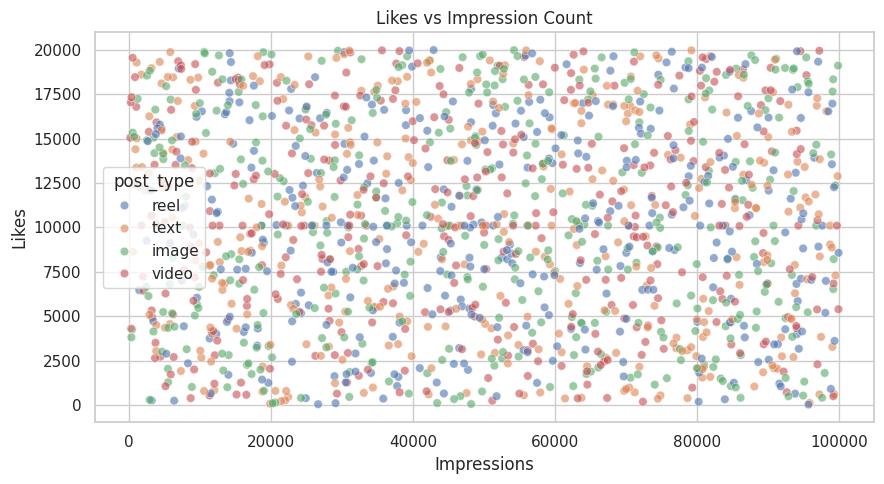

In [14]:
sample = df.sample(1500, random_state=42)
plt.figure(figsize=(9, 5))
sns.scatterplot(
    data=sample, x="impression_count", y="likes",
    hue="post_type", alpha=0.6, s=38
)
plt.title("Likes vs Impression Count")
plt.xlabel("Impressions")
plt.ylabel("Likes")
plt.tight_layout()
plt.show()

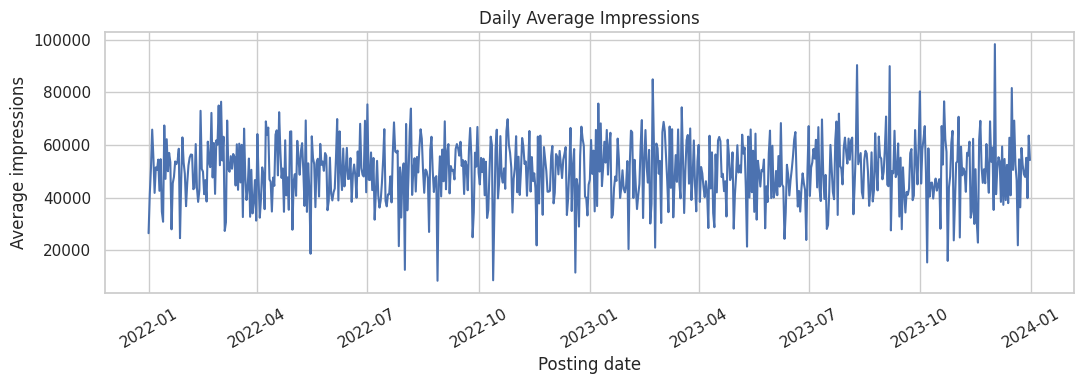

In [15]:
daily = df.groupby("posted_at")["impression_count"].mean()
daily = daily.reset_index()
daily = daily.sort_values("posted_at")

plt.figure(figsize=(11, 4))
sns.lineplot(data=daily, x="posted_at", y="impression_count")
plt.title("Daily Average Impressions")
plt.xlabel("Posting date")
plt.ylabel("Average impressions")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

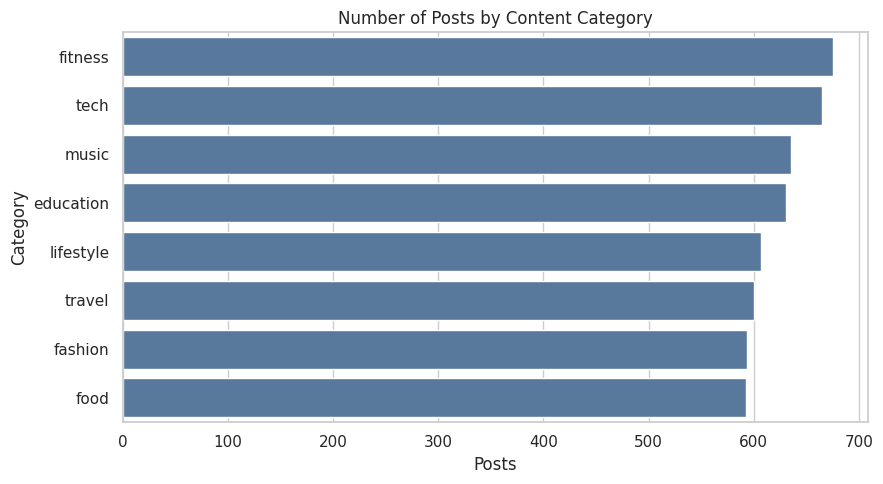

In [16]:
cat_counts = df["post_category"].value_counts()
cat_counts = cat_counts.sort_values(ascending=False)

plt.figure(figsize=(9, 5))
sns.barplot(x=cat_counts.values, y=cat_counts.index, color="#4C78A8")
plt.title("Number of Posts by Content Category")
plt.xlabel("Posts")
plt.ylabel("Category")
plt.tight_layout()
plt.show()

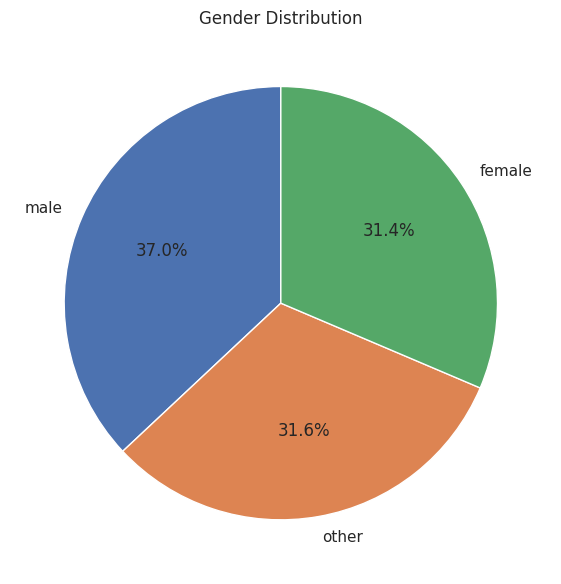

In [17]:
gender_counts = df["gender"].value_counts()

plt.figure(figsize=(6, 6))
plt.pie(
    gender_counts.values, labels=gender_counts.index,
    autopct="%1.1f%%", startangle=90
)
plt.title("Gender Distribution")
plt.tight_layout()
plt.show()

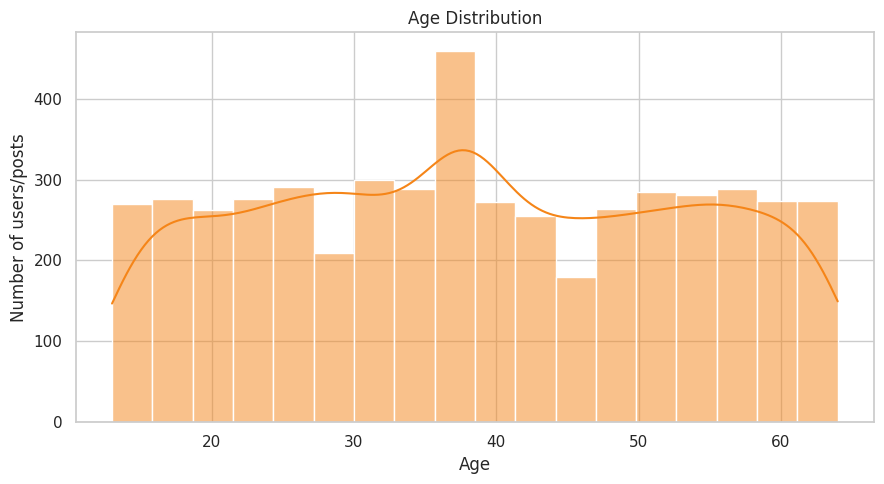

In [18]:
plt.figure(figsize=(9, 5))
sns.histplot(data=df, x="age", bins=18, kde=True, color="#F58518")
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of users/posts")
plt.tight_layout()
plt.show()

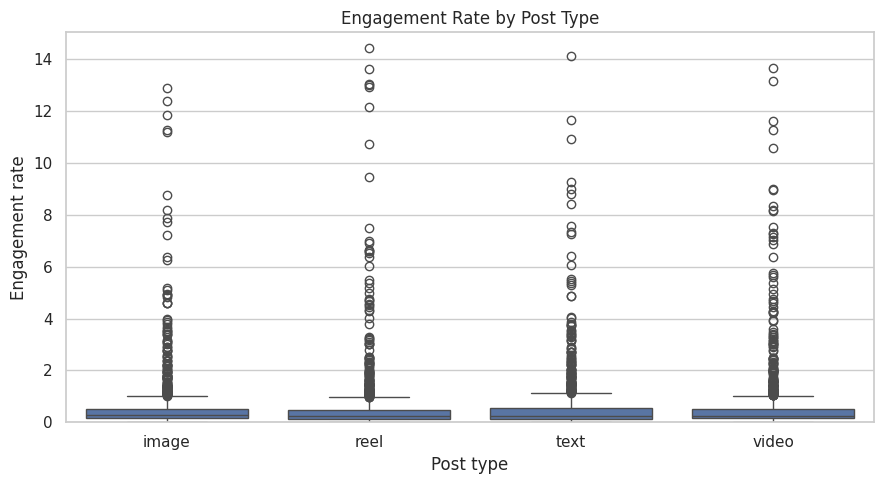

In [19]:
plt.figure(figsize=(9, 5))
sns.boxplot(data=df, x="post_type", y="engagement_rate")
plt.title("Engagement Rate by Post Type")
plt.xlabel("Post type")
plt.ylabel("Engagement rate")
plt.ylim(0, df["engagement_rate"].quantile(0.99) * 1.1)
plt.tight_layout()
plt.show()

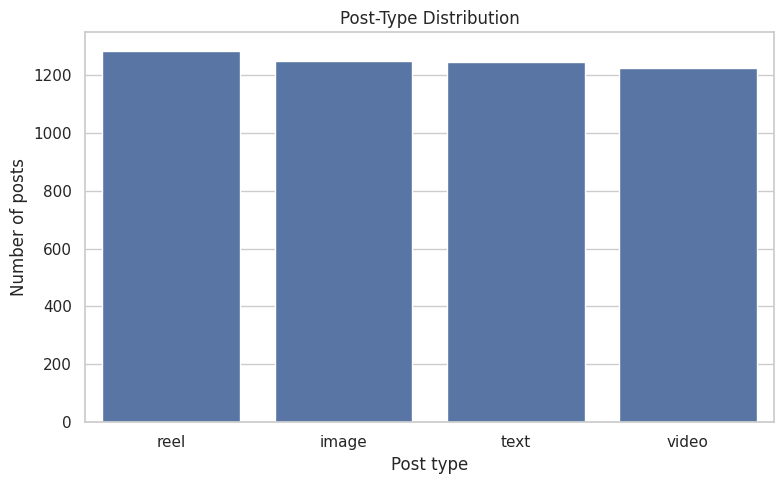

In [20]:
plt.figure(figsize=(8, 5))
order = df["post_type"].value_counts().index
sns.countplot(data=df, x="post_type", order=order)
plt.title("Post-Type Distribution")
plt.xlabel("Post type")
plt.ylabel("Number of posts")
plt.tight_layout()
plt.show()

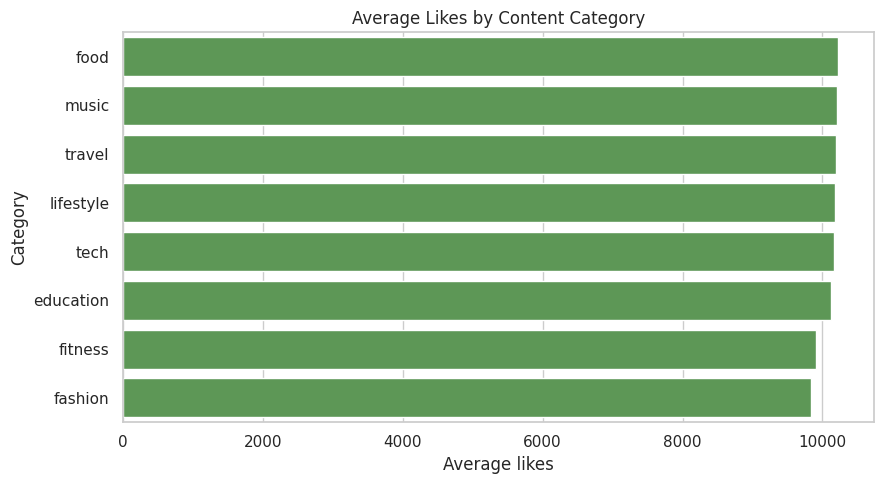

In [21]:
cat_likes = df.groupby("post_category")["likes"].mean()
cat_likes = cat_likes.sort_values(ascending=False)

plt.figure(figsize=(9, 5))
sns.barplot(
    x=cat_likes.values, y=cat_likes.index, color="#54A24B"
)
plt.title("Average Likes by Content Category")
plt.xlabel("Average likes")
plt.ylabel("Category")
plt.tight_layout()
plt.show()

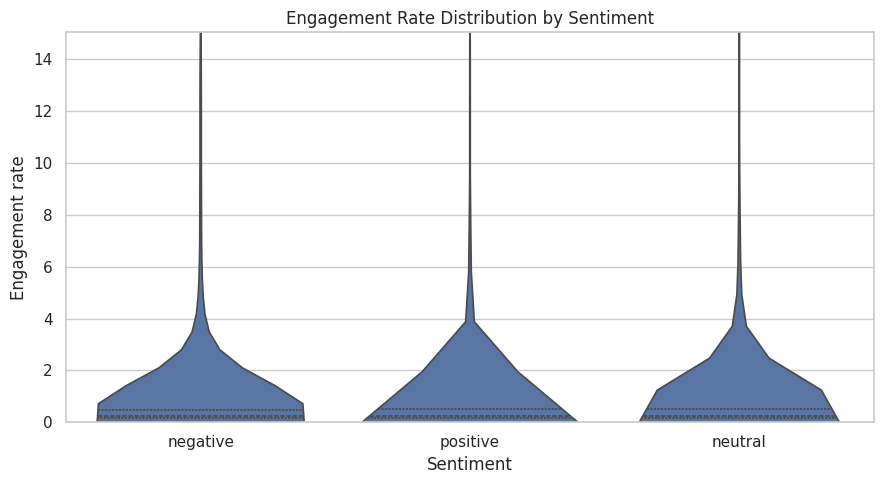

In [22]:
plt.figure(figsize=(9, 5))
sns.violinplot(
    data=df, x="sentiment", y="engagement_rate",
    inner="quartile", cut=0
)
plt.title("Engagement Rate Distribution by Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Engagement rate")
plt.ylim(0, df["engagement_rate"].quantile(0.99) * 1.1)
plt.tight_layout()
plt.show()

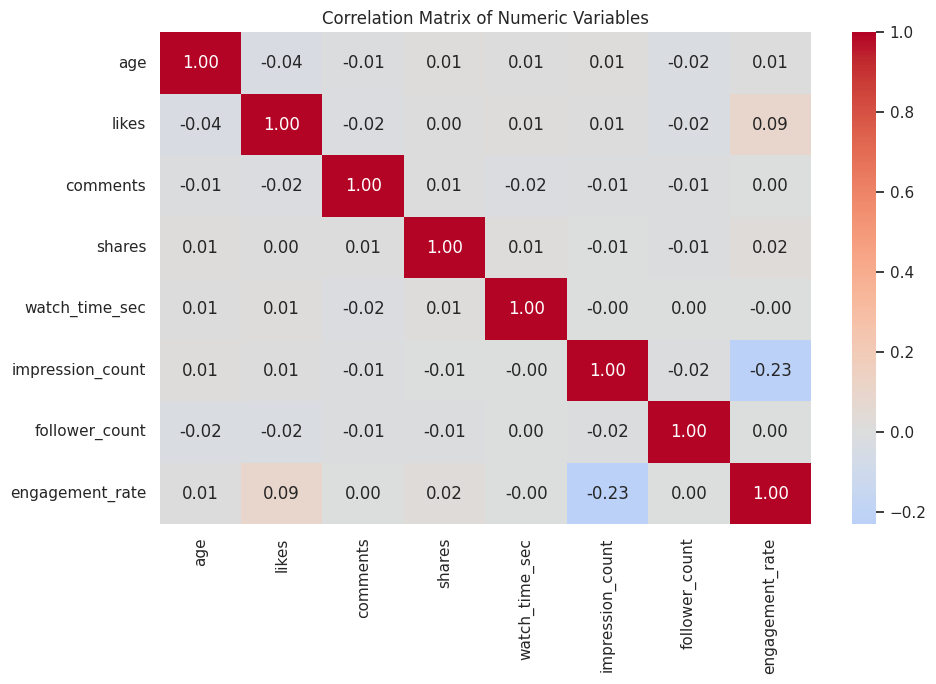

In [23]:
plt.figure(figsize=(10, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Matrix of Numeric Variables")
plt.tight_layout()
plt.show()

/usr/local/lib/python3.13/dist-packages/seaborn/categorical.py:3399: UserWarning: 61.3% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.13/dist-packages/seaborn/categorical.py:3399: UserWarning: 63.5% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.13/dist-packages/seaborn/categorical.py:3399: UserWarning: 57.3% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.13/dist-packages/seaborn/categorical.py:3399: UserWarning: 13.8% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


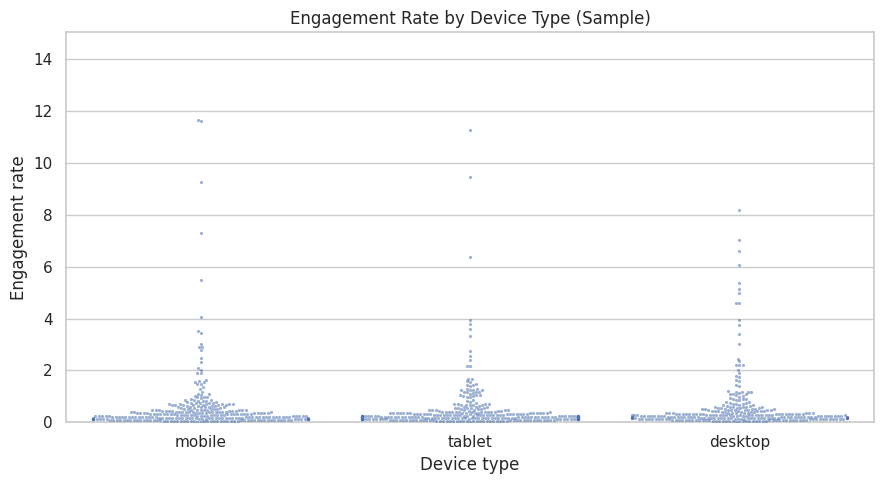

In [24]:
small = df.sample(900, random_state=7)
plt.figure(figsize=(9, 5))
sns.swarmplot(
    data=small, x="device_type", y="engagement_rate",
    size=2.3, alpha=0.55
)
plt.title("Engagement Rate by Device Type (Sample)")
plt.xlabel("Device type")
plt.ylabel("Engagement rate")
plt.ylim(0, df["engagement_rate"].quantile(0.99) * 1.1)
plt.tight_layout()
plt.show()

In [25]:
country_plot = df.groupby("country")["engagement_rate"].mean()
country_plot = country_plot.reset_index()
country_plot = country_plot.rename(
    columns={"engagement_rate": "average_engagement_rate"}
)
country_plot = country_plot.sort_values(
    "average_engagement_rate", ascending=False
)

fig = px.bar(
    country_plot,
    x="country",
    y="average_engagement_rate",
    color="average_engagement_rate",
    title="Interactive Average Engagement Rate by Country",
    labels={
        "country": "Country",
        "average_engagement_rate": "Average engagement rate"
    },
    color_continuous_scale="Viridis"
)
fig.show()

## 7. Final Insights and Limitations

In [26]:
type_avg = df.groupby("post_type")["engagement_rate"].mean()
type_avg = type_avg.sort_values(ascending=False)

cat_avg = df.groupby("post_category")["engagement_rate"].mean()
cat_avg = cat_avg.sort_values(ascending=False)

country_avg = df.groupby("country")["engagement_rate"].mean()
country_avg = country_avg.sort_values(ascending=False)

sent_avg = df.groupby("sentiment")["engagement_rate"].mean()
sent_avg = sent_avg.sort_values(ascending=False)

watch_avg = df.groupby("device_type")["watch_time_sec"].mean()
watch_avg = watch_avg.sort_values(ascending=False)

bins = [0, 24, 34, 44, 54, 100]
labels = ["18-24", "25-34", "35-44", "45-54", "55+"]
df["age_group"] = pd.cut(df["age"], bins=bins, labels=labels)
age_avg = df.groupby("age_group", observed=True)["engagement_rate"].mean()
age_avg = age_avg.sort_values(ascending=False)

verify_avg = df.groupby("is_verified")[
    ["engagement_rate", "watch_time_sec", "impression_count"]
].mean()
verify_avg = verify_avg.rename(columns={
    "engagement_rate": "average_engagement",
    "watch_time_sec": "average_watch_time",
    "impression_count": "average_impressions"
})

print("CONTENT PERFORMANCE")
print("Post type ranking:")
print(type_avg.round(3).to_string())
print("\nCategory ranking:")
print(cat_avg.round(3).to_string())
print("\nTop countries:")
print(country_avg.head(3).round(3).to_string())

print("\nUSER AND BEHAVIOURAL TRENDS")
print("Age-group engagement:")
print(age_avg.round(3).to_string())
print("\nVerified and non-verified accounts:")
print(verify_avg.round(3).to_string())
print("\nDevice ranking by watch time:")
print(watch_avg.round(2).to_string())
print("\nSentiment ranking:")
print(sent_avg.round(3).to_string())

hours = df["post_hour"].unique()
if len(hours) == 1:
    print(
        "\nTime-of-day limitation: every record has hour "
        + str(int(hours[0]))
        + ":00. A best time of day cannot be found from this file."
    )
else:
    print("\nAverage impressions by hour:")
    hour_avg = df.groupby("post_hour")["impression_count"].mean()
    display(hour_avg.sort_values(ascending=False))

CONTENT PERFORMANCE
Post type ranking:
post_type
video    1.122
text     1.065
image    0.896
reel     0.783

Category ranking:
post_category
food         1.359
tech         1.160
lifestyle    1.091
music        0.889
fitness      0.866
education    0.844
fashion      0.807
travel       0.702

Top countries:
country
brazil       1.541
australia    1.324
france       1.146

USER AND BEHAVIOURAL TRENDS
Age-group engagement:
age_group
45-54    1.205
18-24    0.964
35-44    0.956
55+      0.899
25-34    0.811

Verified and non-verified accounts:
             average_engagement  average_watch_time  average_impressions
is_verified                                                             
False                     0.955            4005.201            49935.288
True                      1.054            4101.495            50747.344

Device ranking by watch time:
device_type
mobile     4087.83
tablet     3979.74
desktop    3974.79

Sentiment ranking:
sentiment
negative    1.038
neutral     

# **Social Media Engagement Analytics**
Dataset: 5,000 records and 19 original variables  |  Method: Python, NumPy, Pandas, Matplotlib, Seaborn and Plotly

### Data preparation:
No exact duplicate rows were found. Missing numeric values in age, likes, comments and shares were filled with medians; missing gender and sentiment values were filled with modes. Labels and hashtags were standardised, dates were converted to datetime, and hashtag count, total engagement score and log engagement were created.

### Statistical interpretation
Engagement rate is strongly right-skewed: its mean is approximately 0.964, while its median is approximately 0.254. A few very high-rate posts pull the mean upward, so the median, percentiles and box plots should be considered alongside averages.
Impression count has a moderate negative correlation with engagement rate (about 0.232); most other numeric relationships are
weak.

### Interpretation:

1. **Content performance:** Video has the highest average engagement rate among post types. Food is the strongest category, followed by tech and lifestyle. Brazil, Australia, and France have the highest country-level averages.
2. **User trends:** Engagement is highest for the 45–54 age group and lowest for ages 25–34 in this sample; the pattern is not linear. Verified accounts have slightly higher average engagement, watch time, and impressions.
3. **Quality note:** Engagement rate is highly skewed, with a mean much larger than its median. Conclusions should therefore report both measures and avoid relying on the mean alone.
4. **Behavioural findings:** Mobile users have the highest average watch time. Negative-sentiment posts have the highest average engagement rate, so sentiment should be treated as an observed association rather than proof that negative content causes engagement.
5. **Data limitation:** Every timestamp is recorded at midnight (`00:00`), so the supplied data cannot identify the best time of day for impressions. A timestamp containing hours and minutes is required for that question.

### Recommendation
Test more video and food-related content, with Brazil, Australia and France as promising segments. Optimise creative for mobile viewing. Use controlled tests before concluding that negative sentiment itself causes higher engagement.
Important limitation
All 5,000 values in posted_at are recorded at 00:00. The supplied data therefore cannot identify a reliable best time of day for impressions. Future collection should retain the actual publication hour and minute.
